In [1]:
# @title BLOCK 1: ENVIRONMENT SETUP & LIBRARY IMPORTS
# ======================================================
# 1. INSTALLATION & IMPORTS
# ======================================================
!pip install xgboost scikit-learn pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso, LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import os
import warnings
import sys

# Display configuration
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

# ======================================================
# 2. GOOGLE DRIVE MOUNTING
# ======================================================
from google.colab import drive
# Check if drive is already mounted to avoid redundant mounting errors
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')
else:
    print("Drive đã được mount sẵn.")

# ======================================================
# 3. DATA PATH CONFIGURATION
# ======================================================

# [INSTRUCTIONS]:
# 1. Download MIMIC-IV-Ext-Cardiac-Disease and MIMIC-IV v3.1 from PhysioNet.
# 2. Upload them to your Google Drive.
# 3. Update the paths below to match your directory structure.

# Path for the Cardiovascular Extension dataset
BASE_PATH_EXT = "/content/drive/MyDrive/MIMIC DATASET/mimic-iv-ext-cardiac-disease"

# Path for the Core MIMIC-IV v3.1 dataset
MIMIC_IV_PATH = "/content/drive/MyDrive/MIMIC DATASET/mimic-iv-3.1"

# Define sub-modules within MIMIC-IV (hosp and icu)
MIMIC_MODULES = {
    'hosp': os.path.join(MIMIC_IV_PATH, 'hosp'),
    'icu': os.path.join(MIMIC_IV_PATH, 'icu')
}

# ======================================================
# 4. DATA LOADING UTILITY (OPTIMIZED)
# ======================================================
def load_mimic_table(table_name, module='hosp', nrows=None):
    """
    Helper function to read .csv.gz files from MIMIC-IV directories.
    Args:
        table_name (str): Name of the table (e.g., 'patients', 'admissions').
        module (str): 'hosp' or 'icu'. Defaults to 'hosp'.
        nrows (int): Number of rows to read for quick testing.
    Returns:
        pd.DataFrame
    """
    if module not in MIMIC_MODULES:
        raise ValueError(f"Module '{module}' không hợp lệ. Chỉ chấp nhận: {list(MIMIC_MODULES.keys())}")

    # Auto-append extension if missing
    if not table_name.endswith('.csv.gz'):
        filename = f"{table_name}.csv.gz"
    else:
        filename = table_name

    file_path = os.path.join(MIMIC_MODULES[module], filename)

    if not os.path.exists(file_path):
        print(f"❌ LỖI: Không tìm thấy file tại {file_path}")
        return None

    print(f"🔄 Đang đọc file: {filename} từ module {module}...")
    try:
        # Pandas automatically detects 'gzip' compression via file extension
        df = pd.read_csv(file_path, compression='gzip', nrows=nrows)
        print(f"✅ Đọc thành công: {table_name} | Shape: {df.shape}")
        return df
    except Exception as e:
        print(f"❌ LỖI khi đọc file {filename}: {e}")
        return None

# ======================================================
# 5. CONFIGURATION VERIFICATION (SMOKE TEST)
# ======================================================
print("\n" + "="*40)
print("BẮT ĐẦU KIỂM TRA CẤU HÌNH DỮ LIỆU MIMIC-IV v3.1")
print("="*40)

# 1. Verify Root Directory
if os.path.exists(MIMIC_IV_PATH):
    print(f"✅ Đã tìm thấy thư mục gốc MIMIC-IV: {MIMIC_IV_PATH}")
else:
    print(f"❌ KHÔNG tìm thấy thư mục gốc: {MIMIC_IV_PATH}")
    print("👉 Vui lòng kiểm tra lại tên thư mục trong Google Drive.")

# 2. Verify sub-modules (hosp, icu) and list files
for mod_name, mod_path in MIMIC_MODULES.items():
    if os.path.exists(mod_path):
        files = [f for f in os.listdir(mod_path) if f.endswith('.csv.gz')]
        file_count = len(files)
        print(f"\n📂 Module '{mod_name}': OK")
        print(f"   - Đường dẫn: {mod_path}")
        print(f"   - Tìm thấy {file_count} file .csv.gz")
        if file_count > 0:
            print(f"   - Ví dụ 3 file đầu: {files[:3]}")
    else:
        print(f"\n❌ Module '{mod_name}': KHÔNG TỒN TẠI tại {mod_path}")

# 3. Smoke Test: Attempt to read sample data
# Thường kiểm tra bảng 'patients' trong module 'hosp' vì nó nhẹ và là gốc
print("\n🧪 Test đọc dữ liệu mẫu (Table: patients):")
df_test = load_mimic_table('patients', module='hosp', nrows=5)

if df_test is not None:
    print("\n📋 Dữ liệu mẫu (5 dòng đầu):")
    display(df_test)
    print("\n✅ CẤU HÌNH HOÀN TẤT VÀ SẴN SÀNG SỬ DỤNG!")
else:
    print("\n⚠️ Cảnh báo: Không thể đọc dữ liệu mẫu. Vui lòng kiểm tra lại file.")

Mounted at /content/drive

BẮT ĐẦU KIỂM TRA CẤU HÌNH DỮ LIỆU MIMIC-IV v3.1
✅ Đã tìm thấy thư mục gốc MIMIC-IV: /content/drive/MyDrive/MIMIC DATASET/mimic-iv-3.1

📂 Module 'hosp': OK
   - Đường dẫn: /content/drive/MyDrive/MIMIC DATASET/mimic-iv-3.1/hosp
   - Tìm thấy 22 file .csv.gz
   - Ví dụ 3 file đầu: ['services.csv.gz', 'prescriptions.csv.gz', 'd_hcpcs.csv.gz']

📂 Module 'icu': OK
   - Đường dẫn: /content/drive/MyDrive/MIMIC DATASET/mimic-iv-3.1/icu
   - Tìm thấy 9 file .csv.gz
   - Ví dụ 3 file đầu: ['chartevents.csv.gz', 'procedureevents.csv.gz', 'ingredientevents.csv.gz']

🧪 Test đọc dữ liệu mẫu (Table: patients):
🔄 Đang đọc file: patients.csv.gz từ module hosp...
✅ Đọc thành công: patients | Shape: (5, 6)

📋 Dữ liệu mẫu (5 dòng đầu):


,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10000032,F,52,2180,2014 - 2016,2180-09-09
1,10000048,F,23,2126,2008 - 2010,NaN
2,10000058,F,33,2168,2020 - 2022,NaN
3,10000068,F,19,2160,2008 - 2010,NaN
4,10000084,M,72,2160,2017 - 2019,2161-02-13



✅ CẤU HÌNH HOÀN TẤT VÀ SẴN SÀNG SỬ DỤNG!


In [ ]:
# @title BLOCK 2: DYNAMIC TARGET LABELING (Y-VARIABLE GENERATION) DRAFT VERSION
# =============================================================================
# TARGET VARIABLE GENERATION FOR MULTI-CLASS CARDIOVASCULAR PHENOTYPING
# =============================================================================
# [INSTRUCTIONS]:
# 1. Path for the extension folder containing 'heart_diagnoses_all.csv'

# [INSTRUCTIONS]:
# 1. Download the MIMIC-IV-Ext-Cardiac-Disease and MIMIC-IV v3.1 from PhysioNet.
# 2. Upload them to your Google Drive.
# 3. Update the paths below to match your directory structure.
BASE_PATH_EXT = "/content/drive/MyDrive/MIMIC DATASET/mimic-iv-ext-cardiac-disease"

# =============================================================================
# MAIN PROCESSING LOGIC
# =============================================================================
import pandas as pd
import numpy as np
import os
import sys

def load_optimal_dynamic_labels_only_heart(base_path):
    """
    Assigns multi-class labels for early cardiovascular disease diagnosis using MIMIC-IV data.

    METHODOLOGY JUSTIFICATION:
    --------------------------
    This function implements a "Dynamic Depth-Filtering" strategy combined with
    "Clinical Hierarchy" to address two major challenges in EHR-based research:

    1. Label Noise: Excludes past medical history (PMH) coded deep in the
       diagnosis list (low-rank diagnoses) that are irrelevant to current admission.
    2. False Negatives: Ensures structural/chronic conditions (e.g., Atrial Fibrillation)
       are captured even if not listed as the primary (Position 1) diagnosis.
    """

    print("🔄 [Step 1] Loading Diagnosis Data (Heart Cases)...")
    # Load file from extended dataset
    try:
        df_diag = pd.read_csv(os.path.join(base_path, "heart_diagnoses_all.csv"))
    except FileNotFoundError:
        print(f"❌ Lỗi: Không tìm thấy file 'heart_diagnoses_all.csv' tại {base_path}")
        return None

    # Standardize ICD codes: Convert to uppercase string for accurate mapping
    df_diag['icd_code'] = df_diag['icd_code'].astype(str).str.upper()

    # --- 1. DISEASE MAPPING (Clinical Phenotyping) ---
    # Grouping using ICD-10 Prefixes
    def get_disease_class(code):
        # GROUP 1: Acute Myocardial Infarction (AMI)
        # Includes STEMI and NSTEMI - Life-threatening acute events.
        if code.startswith('I21'): return 1

        # GROUP 6: Heart Failure (HF)
        # Includes acute, chronic, left/right heart failure.
        if code.startswith('I50'): return 6

        # GROUP 3: Pericardial Diseases
        # Includes Acute Pericarditis and Pericardial Effusion.
        if code.startswith(('I30', 'I31')): return 3

        # GROUP 5: Arrhythmias
        # Includes AV Block (I44), AFib/Flutter (I48), Paroxysmal Tachycardia (I47).
        if code.startswith(('I44', 'I45', 'I47', 'I48', 'I49')): return 5

        # GROUP 4: Valvular Heart Disease (Non-rheumatic)
        # Focuses on Mitral Valve disorders.
        if code.startswith('I34'): return 4

        # GROUP 2: Chronic Ischemic Heart Disease
        # Includes Coronary Atherosclerosis and Stable Angina.
        if code.startswith('I25'): return 2

        return 0 # Control/Other - To be filtered out

    df_diag['label'] = df_diag['icd_code'].apply(get_disease_class)

    # Retain only the 6 cardiovascular groups of interest
    df_target = df_diag[df_diag['label'] != 0].copy()

    # --- 2. DYNAMIC THRESHOLD STRATEGY ---

    def is_valid_clinical_context(row):
        lbl = row['label']
        seq = row['seq_num']

        # A. Acute Conditions: AMI (1), Pericardial (3), HF (6)
        # Constraint: Top 5 diagnoses.
        # Rationale: If acute, these must appear early in the EHR.
        # Diagnoses at seq_num > 5 are likely "Old MI" or stable history, which introduces noise.
        if lbl in [1, 3, 6]:
            return seq <= 5

        # B. Chronic/Structural Conditions: Ischemic (2), Valvular (4), Arrhythmia (5)
        # Constraint: Top 15 diagnoses.
        # Rationale: These are often comorbidities documented after acute stabilization.
        # Expanding to rank 15 improves Recall for baseline pathological features.
        if lbl in [2, 4, 5]:
            return seq <= 15

        return False

    # Apply filtering
    print("🔄 [Step 2] Applying Dynamic Threshold Filtering...")
    df_target = df_target[df_target.apply(is_valid_clinical_context, axis=1)]

    # --- 3. HIERARCHICAL PRIORITY (Medical Severity Ranking) ---
    # Labels assigned based on the most severe pathology driving the admission.
    priority_map = {
        1: 1,  # NMCT
        3: 2,  # Viêm màng tim
        4: 3,  # Van tim
        5: 4,  # RL Nhịp
        6: 5,  # Suy tim
        2: 6   # Mạch vành mạn
    }

    df_target['priority_score'] = df_target['label'].map(priority_map)

    # Sort to select a single outcome per admission
    # Criteria 1: Clinical Priority (Lowest score first)
    # Criteria 2: Documentation Rank (Lowest seq_num first)
    df_sorted = df_target.sort_values(by=['hadm_id', 'priority_score', 'seq_num'])

    # Drop duplicates to keep the primary prediction target
    df_final = df_sorted.drop_duplicates(subset=['hadm_id'], keep='first')[['hadm_id', 'subject_id', 'label', 'icd_code']]

    print(f"✅ [Done Case] Đã gán nhãn thành công cho {len(df_final)} lượt nhập viện (Chỉ nhóm bệnh Tim).")

    # Shuffle for randomization
    df_final = df_final.sample(frac=1, random_state=42).reset_index(drop=True)

    print("\n--- Phân bố nhãn (Chỉ bao gồm các lớp bệnh lý tim mạch) ---")
    print(df_final['label'].value_counts().sort_index())

    return df_final

# =============================================================================
# EXECUTION & DETAILED REPORTING
# =============================================================================
# Invoke the function (original path no longer required)
df_labels = load_optimal_dynamic_labels_only_heart(BASE_PATH_EXT)

if df_labels is not None:
    # --- REPORT 1: DISTRIBUTION OVERVIEW ---
    print("\n" + "="*80)
    print("📊 BÁO CÁO 1: PHÂN BỐ DỮ LIỆU BỆNH TIM (HEART DISEASES ONLY)")
    print("="*80)

    label_names = {
        # 0: "Control (Other Diseases)", -> Đã bỏ
        1: "Acute MI (NMCT Cấp)",
        2: "Chronic Ischemic (Mạch vành mạn)",
        3: "Pericardial (Màng tim)",
        4: "Valvular (Van tim)",
        5: "Arrhythmias (RL Nhịp)",
        6: "Heart Failure (Suy tim)"
    }

    counts = df_labels['label'].value_counts().sort_index()
    total = len(df_labels)

    print(f"{'ID':<5} | {'Tên nhóm':<35} | {'Số lượng':<10} | {'Tỷ lệ':<10}")
    print("-" * 70)
    for lbl, count in counts.items():
        name = label_names.get(lbl, "Unknown")
        print(f"{lbl:<5} | {name:<35} | {count:<10} | {count/total*100:.1f}%")
    print("-" * 70)
    print(f"TỔNG CỘNG: {total} mẫu (Toàn bộ là bệnh tim).")


    # --- REPORT 2: SAMPLE DATA PREVIEW ---
    print("\n" + "="*80)
    print("📝 BÁO CÁO 2: SAMPLE IDs (Mỗi lớp 2 ví dụ)")
    print("="*80)
    sample_view = df_labels.groupby('label', group_keys=False).apply(lambda x: x.sample(min(len(x), 2)))
    print(sample_view[['label', 'subject_id', 'hadm_id', 'icd_code']].to_string(index=False))

    # Save final result to a new file
    save_path = "/content/drive/MyDrive/MIMIC DATASET/mimic_iv_heart_only_final_pipeline6.csv"
    df_labels.to_csv(save_path, index=False)
    print(f"\n💾 Đã lưu file Target Label (Chỉ bệnh Tim) tại: {save_path}")


🔄 [Step 1] Loading Diagnosis Data (Heart Cases)...
🔄 [Step 2] Applying Dynamic Threshold Filtering...
✅ [Done Case] Đã gán nhãn thành công cho 4683 lượt nhập viện (Chỉ nhóm bệnh Tim).

--- Phân bố nhãn (Chỉ bao gồm các lớp bệnh lý tim mạch) ---
label
1    1525
2     389
3     277
4     296
5    1485
6     711
Name: count, dtype: int64

📊 BÁO CÁO 1: PHÂN BỐ DỮ LIỆU BỆNH TIM (HEART DISEASES ONLY)
ID    | Tên nhóm                            | Số lượng   | Tỷ lệ     
----------------------------------------------------------------------
1     | Acute MI (NMCT Cấp)                 | 1525       | 32.6%
2     | Chronic Ischemic (Mạch vành mạn)    | 389        | 8.3%
3     | Pericardial (Màng tim)              | 277        | 5.9%
4     | Valvular (Van tim)                  | 296        | 6.3%
5     | Arrhythmias (RL Nhịp)               | 1485       | 31.7%
6     | Heart Failure (Suy tim)             | 711        | 15.2%
----------------------------------------------------------------------
TỔN

In [ ]:
# @title BLOCK 2: COMPREHENSIVE TARGET LABELING (4 MAIN GROUPS + 1 OTHERS)
# =============================================================================
# GENERATING TARGET LABELS: 4 PRIMARY CLASSES + 1 COMPREHENSIVE 'OTHER' CLASS
# =============================================================================

# [INSTRUCTIONS]:
# 1. Download the MIMIC-IV-Ext-Cardiac-Disease and MIMIC-IV v3.1 from PhysioNet.
# 2. Upload them to your Google Drive.
# 3. Update the paths below to match your directory structure.
BASE_PATH_EXT = "/content/drive/MyDrive/MIMIC DATASET/mimic-iv-ext-cardiac-disease"

# =============================================================================
# MAIN PROCESSING LOGIC
# =============================================================================
import pandas as pd
import numpy as np
import os
import sys

def load_optimal_dynamic_labels_comprehensive(base_path):
    """
    Multi-class Label Assignment: 4 Primary Groups + 1 Comprehensive 'Other' Group.

    TARGET CLASSES:
    1. Acute MI (Acute Myocardial Infarction)
    2. Chronic Ischemic (Chronic Ischemic Heart Disease)
    5. Arrhythmias (Atrial Fibrillation, Block, Tachycardia)
    6. Heart Failure (Acute & Chronic Heart Failure)
    0. Other Cardiac Diseases (Pericardial, Valvular, & ALL other heart-related conditions)
    """

    print("🔄 [Step 1] Loading Diagnosis Data (Heart Cases)...")
    try:
        df_diag = pd.read_csv(os.path.join(base_path, "heart_diagnoses_all.csv"))
    except FileNotFoundError:
        print(f"❌ Lỗi: Không tìm thấy file 'heart_diagnoses_all.csv' tại {base_path}")
        return None

    # Standardize ICD codes
    df_diag['icd_code'] = df_diag['icd_code'].astype(str).str.upper()

    # --- 1. INITIAL DISEASE MAPPING ---
    def get_raw_disease_class(code):
        # --- 4 PRIMARY GROUPS (PRESERVED) ---
        if code.startswith('I21'): return 1
        if code.startswith('I50'): return 6
        if code.startswith(('I44', 'I45', 'I47', 'I48', 'I49')): return 5
        if code.startswith('I25'): return 2

        # --- GROUPS TO BE MERGED INTO 'OTHER' ---
        # 1. Specific sub-groups (Pericardial & Valvular)
        if code.startswith(('I30', 'I31')): return 3 # Pericardial
        if code.startswith('I34'): return 4         # Valvular

        # 2. [NEW] CAPTURE ALL REMAINING CARDIAC CONDITIONS (GENERAL HEART)
        # ICD-10 Chapter IX (Diseases of the circulatory system: I00-I99)
        if code.startswith('I'): return 7

        # ICD-9 (390-459: Diseases of the circulatory system)
        if code[0].isdigit():
            try:
                val = int(code[:3])
                if 390 <= val <= 459: return 7
            except: pass

        return 0 # Non-Heart (Diabetes, Respiratory, etc.) - To be filtered out

    df_diag['temp_label'] = df_diag['icd_code'].apply(get_raw_disease_class)

    # Exclude non-cardiovascular diseases (temp_label == 0)
    df_target = df_diag[df_diag['temp_label'] != 0].copy()

    # --- 2. DYNAMIC THRESHOLD STRATEGY ---
    def is_valid_clinical_context(row):
        lbl = row['temp_label']
        seq = row['seq_num']

        # Acute Conditions: AMI (1), Pericardial (3), Heart Failure (6) -> Top 5
        if lbl in [1, 3, 6]:
            return seq <= 5

        # Chronic & General Cardiac Conditions:
        # Ischemic (2), Valvular (4), Arrhythmias (5), General Heart (7) -> Top 15
        if lbl in [2, 4, 5, 7]:
            return seq <= 15

        return False

    print("🔄 [Step 2] Applying Dynamic Threshold Filtering...")
    df_target = df_target[df_target.apply(is_valid_clinical_context, axis=1)]

    # --- 3. HIERARCHICAL PRIORITY ---
    # Priority: 1(MI) > 3(Peri) > 4(Valve) > 5(Arr) > 6(HF) > 2(Isch) > 7(General)
    priority_map = {
        1: 1,
        3: 2,
        4: 3,
        5: 4,
        6: 5,
        2: 6,
        7: 7  # Độ ưu tiên thấp nhất cho nhóm bệnh tim chung
    }

    df_target['priority_score'] = df_target['temp_label'].map(priority_map)

    # Sort and Select Primary Label based on Clinical Priority and Rank
    df_sorted = df_target.sort_values(by=['hadm_id', 'priority_score', 'seq_num'])

    # Retain the most clinically significant row per admission
    df_final = df_sorted.drop_duplicates(subset=['hadm_id'], keep='first')[['hadm_id', 'subject_id', 'temp_label', 'icd_code']].copy()

    # --- 4. FINAL GROUP REMAPPING ---
    # Merge 3 (Pericardial), 4 (Valvular), and 7 (General Heart) -> Label 0 (Other Cardiac)
    print("🔄 [Step 3] Merging [3, 4, 7] into 'Other Cardiac' (Label 0)...")

    def remap_final_groups(lbl):
        if lbl in [3, 4, 7]: return 0
        return lbl

    df_final['label'] = df_final['temp_label'].apply(remap_final_groups)

    # Xóa cột temp
    df_final = df_final.drop(columns=['temp_label'])

    print(f"✅ [Done] Đã gán nhãn thành công cho {len(df_final)} lượt nhập viện.")
    print("\n--- Phân bố nhãn (5 Nhóm cuối cùng) ---")
    print(df_final['label'].value_counts().sort_index())

    return df_final

# =============================================================================
# EXECUTION & DETAILED DISTRIBUTION REPORT
# =============================================================================
df_labels = load_optimal_dynamic_labels_comprehensive(BASE_PATH_EXT)

if df_labels is not None:
    print("\n" + "="*80)
    print("📊 BÁO CÁO: PHÂN BỐ DỮ LIỆU (COMPREHENSIVE CARDIAC)")
    print("="*80)

    label_names = {
        1: "Acute MI (NMCT Cấp)",
        2: "Chronic Ischemic (Mạch vành mạn)",
        5: "Arrhythmias (Rối loạn nhịp)",
        6: "Heart Failure (Suy tim)",
        0: "Other Cardiac (Màng tim, Van tim, HA...)"
    }

    counts = df_labels['label'].value_counts().sort_index()
    total = len(df_labels)

    print(f"{'ID':<5} | {'Tên nhóm':<40} | {'Số lượng':<10} | {'Tỷ lệ':<10}")
    print("-" * 75)

    display_order = [1, 2, 5, 6, 0]

    for lbl in display_order:
        if lbl in counts:
            count = counts[lbl]
            name = label_names.get(lbl, "Unknown")
            print(f"{lbl:<5} | {name:<40} | {count:<10} | {count/total*100:.1f}%")

    print("-" * 75)
    print(f"TỔNG CỘNG: {total} mẫu (Toàn bộ là bệnh tim).")

    # --- SAMPLE IDs ---
    print("\n" + "="*80)
    print("📝 SAMPLE IDs (Mỗi lớp 2 ví dụ)")
    print("="*80)
    sample_view = df_labels.groupby('label', group_keys=False).apply(lambda x: x.sample(min(len(x), 2)))
    print(sample_view[['label', 'subject_id', 'hadm_id', 'icd_code']].to_string(index=False))

    # Save file
    save_path = "/content/drive/MyDrive/MIMIC DATASET/mimic_iv_heart_only_final_pipeline6.csv"
    df_labels.to_csv(save_path, index=False)
    print(f"\n💾 Đã lưu file Target Label mới tại: {save_path}")

🔄 [Step 1] Loading Diagnosis Data (Heart Cases)...
🔄 [Step 2] Applying Dynamic Threshold Filtering...
🔄 [Step 3] Merging [3, 4, 7] into 'Other Cardiac' (Label 0)...
✅ [Done] Đã gán nhãn thành công cho 4761 lượt nhập viện.

--- Phân bố nhãn (5 Nhóm cuối cùng) ---
label
0     651
1    1525
2     389
5    1485
6     711
Name: count, dtype: int64

📊 BÁO CÁO: PHÂN BỐ DỮ LIỆU (COMPREHENSIVE CARDIAC)
ID    | Tên nhóm                                 | Số lượng   | Tỷ lệ     
---------------------------------------------------------------------------
1     | Acute MI (NMCT Cấp)                      | 1525       | 32.0%
2     | Chronic Ischemic (Mạch vành mạn)         | 389        | 8.2%
5     | Arrhythmias (Rối loạn nhịp)              | 1485       | 31.2%
6     | Heart Failure (Suy tim)                  | 711        | 14.9%
0     | Other Cardiac (Màng tim, Van tim, HA...) | 651        | 13.7%
---------------------------------------------------------------------------
TỔNG CỘNG: 4761 mẫu (Toàn b

📂 Đang đọc file: /content/drive/MyDrive/MIMIC DATASET/mimic_iv_heart_only_final_pipeline6.csv
ℹ️ Các nhãn tìm thấy trong dữ liệu: [np.int64(0), np.int64(1), np.int64(2), np.int64(5), np.int64(6)]
✅ Xác nhận: Dữ liệu đã bao gồm nhóm 'Other Cardiac' (Label 0).
🔄 Đang tải dữ liệu bổ sung (Admissions & Patients)...
🔄 Đang đọc file: admissions.csv.gz từ module hosp...
✅ Đọc thành công: admissions | Shape: (546028, 16)
🔄 Đang đọc file: patients.csv.gz từ module hosp...
✅ Đọc thành công: patients | Shape: (364627, 6)
🔄 Đang kết nối dữ liệu (Merging)...

📊 BẢNG 1: THỐNG KÊ CHI TIẾT SỐ LƯỢNG CA BỆNH THEO GIAI ĐOẠN


Disease Name,1. Acute MI (NMCT Cấp),2. Chronic Ischemic (Mạch vành mạn),3. Arrhythmias (Rối loạn nhịp),4. Heart Failure (Suy tim),"5. Other Cardiac (Màng tim, Van tim, HA...)",TOTAL
anchor_year_group,,,,,,
2008 - 2010,677,215,834,457,308,2491
2011 - 2013,410,94,352,173,159,1188
2014 - 2016,314,65,245,71,129,824
2017 - 2019,124,15,54,10,55,258



📉 BẢNG 2: TỶ LỆ PHÂN BỐ BỆNH TRONG TỪNG GIAI ĐOẠN (%)


Disease Name,1. Acute MI (NMCT Cấp),2. Chronic Ischemic (Mạch vành mạn),3. Arrhythmias (Rối loạn nhịp),4. Heart Failure (Suy tim),"5. Other Cardiac (Màng tim, Van tim, HA...)"
anchor_year_group,,,,,
2008 - 2010,27.18,8.63,33.48,18.35,12.36
2011 - 2013,34.51,7.91,29.63,14.56,13.38
2014 - 2016,38.11,7.89,29.73,8.62,15.66
2017 - 2019,48.06,5.81,20.93,3.88,21.32


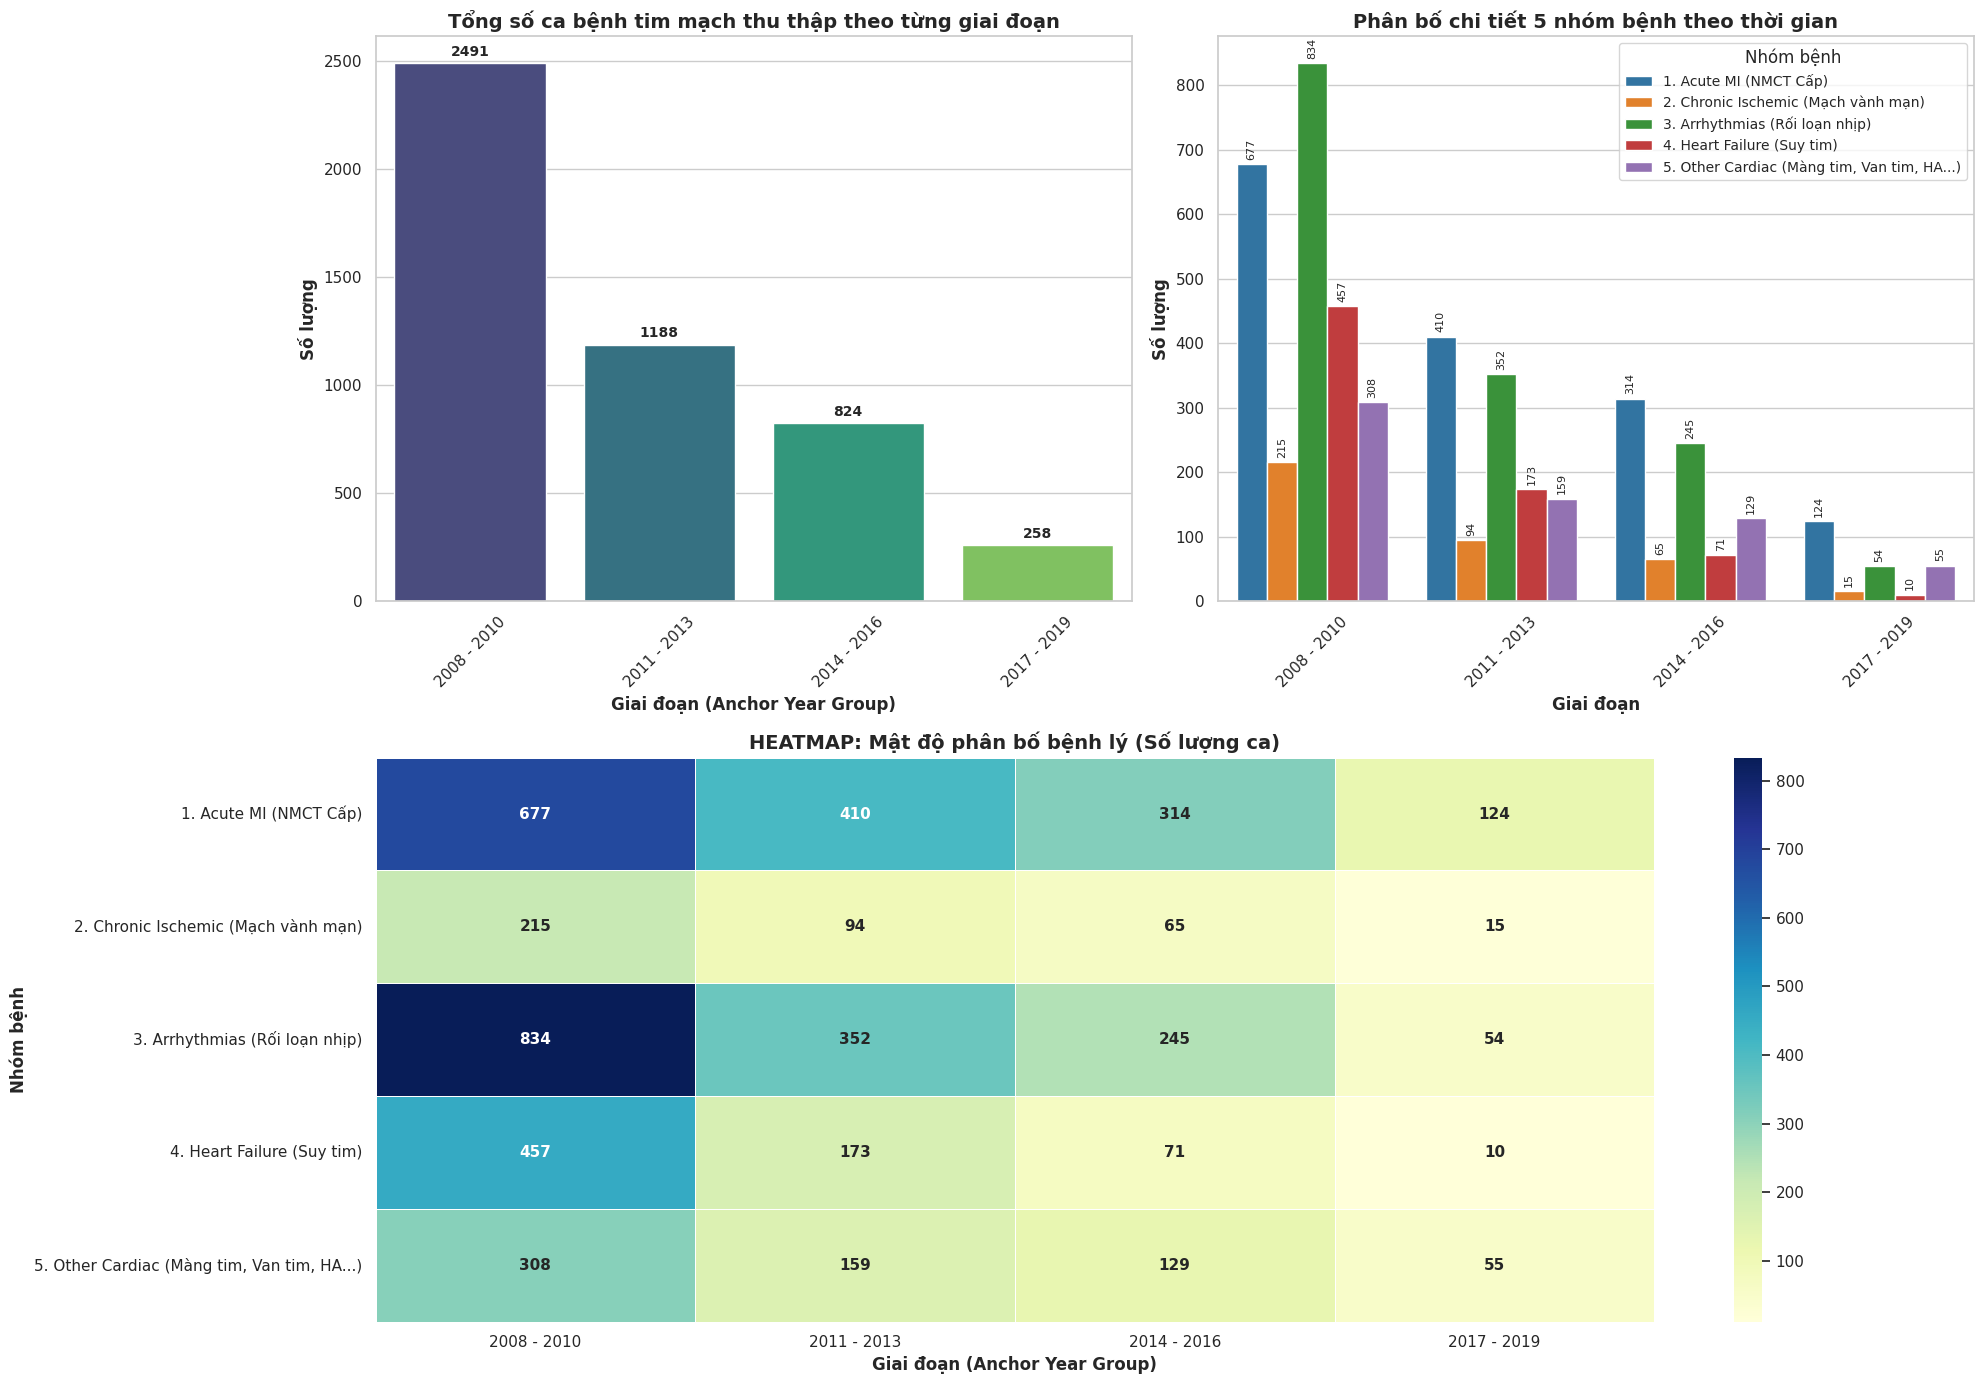

In [ ]:
# @title COMPREHENSIVE TEMPORAL ANALYSIS (VALUE LABELS ADDED)
# ==========================================
# COMPREHENSIVE TEMPORAL ANALYSIS
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

# [INSTRUCTIONS]:
# 1. Download the MIMIC-IV-Ext-Cardiac-Disease and MIMIC-IV v3.1 from PhysioNet.
# 2. Upload them to your Google Drive.
# 3. Update the paths below to match your directory structure.
def analyze_full_temporal_distribution(df_target):
    print("🔄 Đang tải dữ liệu bổ sung (Admissions & Patients)...")

    # 1. Load auxiliary data
    try:
        # Attempt to load using predefined function
        df_adm = load_mimic_table('admissions', module='hosp')
        df_pat = load_mimic_table('patients', module='hosp')
    except NameError:
        print("⚠️ Cảnh báo: Hàm 'load_mimic_table' chưa được định nghĩa.")
        print("   -> Đang thử load từ đường dẫn mặc định (Google Drive)...")
        try:
            BASE_MIMIC = "/content/drive/MyDrive/MIMIC DATASET/mimic-iv-3.1/hosp"
            df_adm = pd.read_csv(os.path.join(BASE_MIMIC, "admissions.csv.gz"), compression='gzip', usecols=['subject_id', 'hadm_id', 'admittime'])
            df_pat = pd.read_csv(os.path.join(BASE_MIMIC, "patients.csv.gz"), compression='gzip', usecols=['subject_id', 'anchor_year_group'])
        except Exception as e:
            print(f"❌ Lỗi: Không thể load dữ liệu phụ trợ. {e}")
            return

    if df_adm is None or df_pat is None:
        print("❌ Lỗi: Thiếu dữ liệu admissions hoặc patients.")
        return

    # 2. Merge data
    print("🔄 Đang kết nối dữ liệu (Merging)...")
    # Merge to get admission time
    df_merged = pd.merge(df_target,
                         df_adm[['subject_id', 'hadm_id', 'admittime']],
                         on=['subject_id', 'hadm_id'],
                         how='left')

    # Merge to get Anchor Year information
    df_merged = pd.merge(df_merged,
                         df_pat[['subject_id', 'anchor_year_group']],
                         on='subject_id',
                         how='left')

    # 3. Standardize disease labels (LATEST MAPPING)
    # ---------------------------------------------------------
    label_map_full = {
        1: "1. Acute MI (NMCT Cấp)",
        2: "2. Chronic Ischemic (Mạch vành mạn)",
        5: "3. Arrhythmias (Rối loạn nhịp)",
        6: "4. Heart Failure (Suy tim)",
        0: "5. Other Cardiac (Màng tim, Van tim, HA...)" # Comprehensive Group 0
    }

    df_merged['Disease Name'] = df_merged['label'].map(label_map_full)

    # Sort by temporal order (Anchor Year)
    if 'anchor_year_group' in df_merged.columns:
        valid_groups = sorted([x for x in df_merged['anchor_year_group'].unique() if pd.notna(x)])
        df_merged = df_merged[df_merged['anchor_year_group'].isin(valid_groups)]
    else:
        print("⚠️ Cảnh báo: Không tìm thấy cột 'anchor_year_group'.")
        valid_groups = []

    # Define display order for diseases on charts
    hue_order_list = [
        "1. Acute MI (NMCT Cấp)",
        "2. Chronic Ischemic (Mạch vành mạn)",
        "3. Arrhythmias (Rối loạn nhịp)",
        "4. Heart Failure (Suy tim)",
        "5. Other Cardiac (Màng tim, Van tim, HA...)"
    ]

    # ==========================================
    # REPORT 1: DETAILED DATA TABLE
    # ==========================================
    print("\n" + "="*80)
    print("📊 BẢNG 1: THỐNG KÊ CHI TIẾT SỐ LƯỢNG CA BỆNH THEO GIAI ĐOẠN")
    print("="*80)

    # Create crosstab
    cross_tab = pd.crosstab(df_merged['anchor_year_group'], df_merged['Disease Name'])

    # Reorder columns as desired
    existing_cols = [c for c in hue_order_list if c in cross_tab.columns]
    cross_tab = cross_tab[existing_cols]

    # Add total column
    cross_tab['TOTAL'] = cross_tab.sum(axis=1)

    display(cross_tab)

    # ==========================================
    # REPORT 2: PERCENTAGE RATIO (%)
    # ==========================================
    print("\n" + "="*80)
    print("📉 BẢNG 2: TỶ LỆ PHÂN BỐ BỆNH TRONG TỪNG GIAI ĐOẠN (%)")
    print("="*80)

    cross_tab_pct = pd.crosstab(df_merged['anchor_year_group'], df_merged['Disease Name'], normalize='index') * 100
    cross_tab_pct = cross_tab_pct[existing_cols] # Reorder columns
    display(cross_tab_pct.round(2))

    # ==========================================
    # VISUALIZATION
    # ==========================================
    sns.set_theme(style="whitegrid")
    fig = plt.figure(figsize=(20, 14))

    # --- Plot 1: Overall Count ---
    ax1 = plt.subplot(2, 2, 1)
    sns.countplot(data=df_merged, x='anchor_year_group', order=valid_groups, palette='viridis', ax=ax1)
    ax1.set_title('Tổng số ca bệnh tim mạch thu thập theo từng giai đoạn', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Giai đoạn (Anchor Year Group)', fontweight='bold')
    ax1.set_ylabel('Số lượng', fontweight='bold')
    ax1.tick_params(axis='x', rotation=45)

    # [NEW] Display values on top of bars
    for container in ax1.containers:
        ax1.bar_label(container, padding=3, fontsize=10, fontweight='bold')

    # --- Plot 2: Detailed 5 Disease Groups (Grouped Bar Chart) ---
    ax2 = plt.subplot(2, 2, 2)
    sns.countplot(data=df_merged, x='anchor_year_group', hue='Disease Name',
                  order=valid_groups, hue_order=hue_order_list,
                  palette='tab10', ax=ax2)
    ax2.set_title('Phân bố chi tiết 5 nhóm bệnh theo thời gian', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Giai đoạn', fontweight='bold')
    ax2.set_ylabel('Số lượng', fontweight='bold')
    ax2.legend(title='Nhóm bệnh', loc='upper right', bbox_to_anchor=(1.0, 1.0), fontsize='small')
    ax2.tick_params(axis='x', rotation=45)

    # [NEW] Display values on top of bars (90-degree rotation to avoid overlap)
    for container in ax2.containers:
        ax2.bar_label(container, padding=3, fontsize=8, rotation=90, label_type='edge')

    # --- Plot 3: Heatmap ---
    ax3 = plt.subplot(2, 1, 2)
    # Prepare data for Heatmap (Transpose so diseases are on the Y-axis)
    heatmap_data = cross_tab.drop(columns=['TOTAL'], errors='ignore').T

    sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlGnBu', linewidths=.5, ax=ax3, annot_kws={"size": 11, "weight": "bold"})
    ax3.set_title('HEATMAP: Mật độ phân bố bệnh lý (Số lượng ca)', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Giai đoạn (Anchor Year Group)', fontweight='bold')
    ax3.set_ylabel('Nhóm bệnh', fontweight='bold')

    plt.tight_layout()
    plt.show()

# --- EXECUTION ---
# Load result file from the previous step
path_target = "/content/drive/MyDrive/MIMIC DATASET/mimic_iv_heart_only_final_pipeline6.csv"

try:
    print(f"📂 Đang đọc file: {path_target}")
    df_target_loaded = pd.read_csv(path_target)

    # Quick check for the new file format (containing label 0)
    unique_labels = df_target_loaded['label'].unique()
    print(f"ℹ️ Các nhãn tìm thấy trong dữ liệu: {sorted(unique_labels)}")

    if 0 in unique_labels:
        print("✅ Xác nhận: Dữ liệu đã bao gồm nhóm 'Other Cardiac' (Label 0).")
    else:
        print("⚠️ Cảnh báo: Không thấy Label 0. Có thể bạn đang load file cũ?")

    analyze_full_temporal_distribution(df_target_loaded)

except FileNotFoundError:
    print(f"❌ Lỗi: Không tìm thấy file tại {path_target}. Hãy chạy lại bước tạo biến Y trước đó.")
except Exception as e:
    print(f"❌ Lỗi không xác định: {e}")


🔄 [Step 1] XỬ LÝ DỮ LIỆU BỆNH TIM (COMPREHENSIVE)
🔄 Đang gộp: Màng tim (3) + Van tim (4) + General Heart (7) -> Other Cardiac (0)...
   -> Đang đọc thông tin bệnh nhân (Split Train/Val)...
✅ Đã xử lý xong dữ liệu: MAIN=3679, EXTERNAL=1082

🔄 [Step 2] LƯU DỮ LIỆU CUỐI CÙNG (PIPELINE 6)
💾 Đã lưu file tại: 
 /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_(Y_TARGET)_dataset_main.csv 
 /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_(Y_TARGET)dataset_external_validate.csv

📊 SUMMARY:
                                      MAIN  EXTERNAL
0. Other Cardiac (All Others)         467       184
1. NMCT (Acute MI)                   1087       438
2. Mạch vành mạn (Chronic Ischemic)   309        80
3. RL Nhịp (Arrhythmias)             1186       299
4. Suy tim (Heart Failure)            630        81

📈 BIỂU ĐỒ TỔNG QUAN PHÂN BỐ DỮ LIỆU


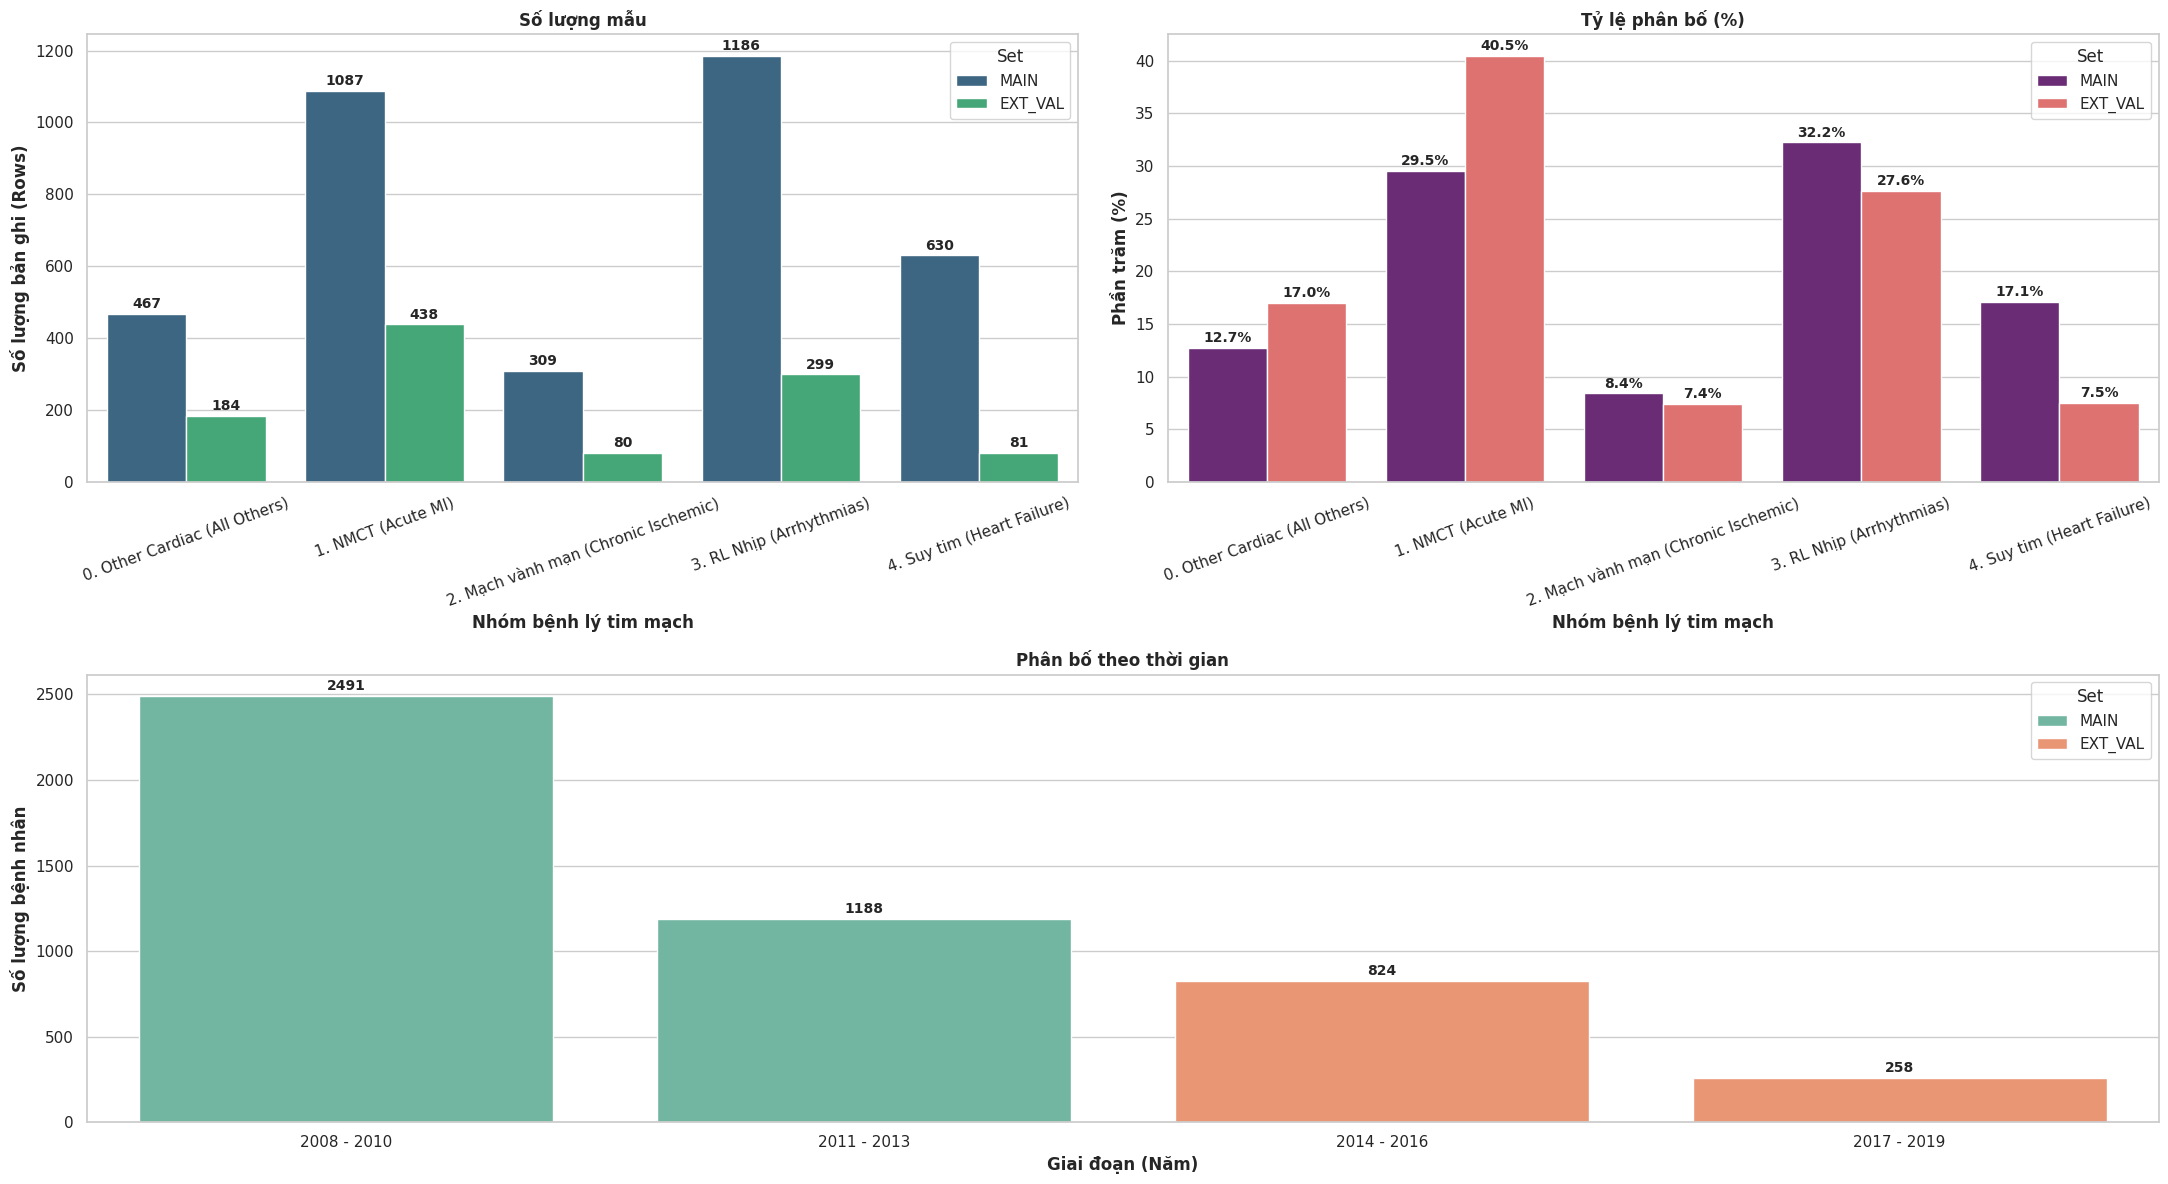


📦 Loading Admissions Data (Race)...

🌍 PHÂN TÍCH NHÂN KHẨU HỌC TOÀN DIỆN (AGE, GENDER, RACE)
   -> Đang xử lý dữ liệu Race từ Admissions...

Nhóm Bệnh                                |     Tổng |    Tuổi TB |    Nam % |   White % |   Black % |   Asian % |    Hisp %
----------------------------------------------------------------------------------------------------------------------------------
0. Other Cardiac (All Others)            |      651 |       63.7 |     51.9 |      70.7 |      13.7 |       2.8 |       4.3
1. NMCT (Acute MI)                       |     1525 |       69.0 |     62.8 |      72.0 |       7.9 |       1.8 |       3.3
2. Mạch vành mạn (Chronic Ischemic)      |      389 |       65.1 |     65.8 |      74.3 |       9.8 |       2.1 |       6.9
3. RL Nhịp (Arrhythmias)                 |     1485 |       72.6 |     57.6 |      79.7 |      10.4 |       1.6 |       2.2
4. Suy tim (Heart Failure)               |      711 |       69.4 |     53.9 |      63.9 |      21.9 |      

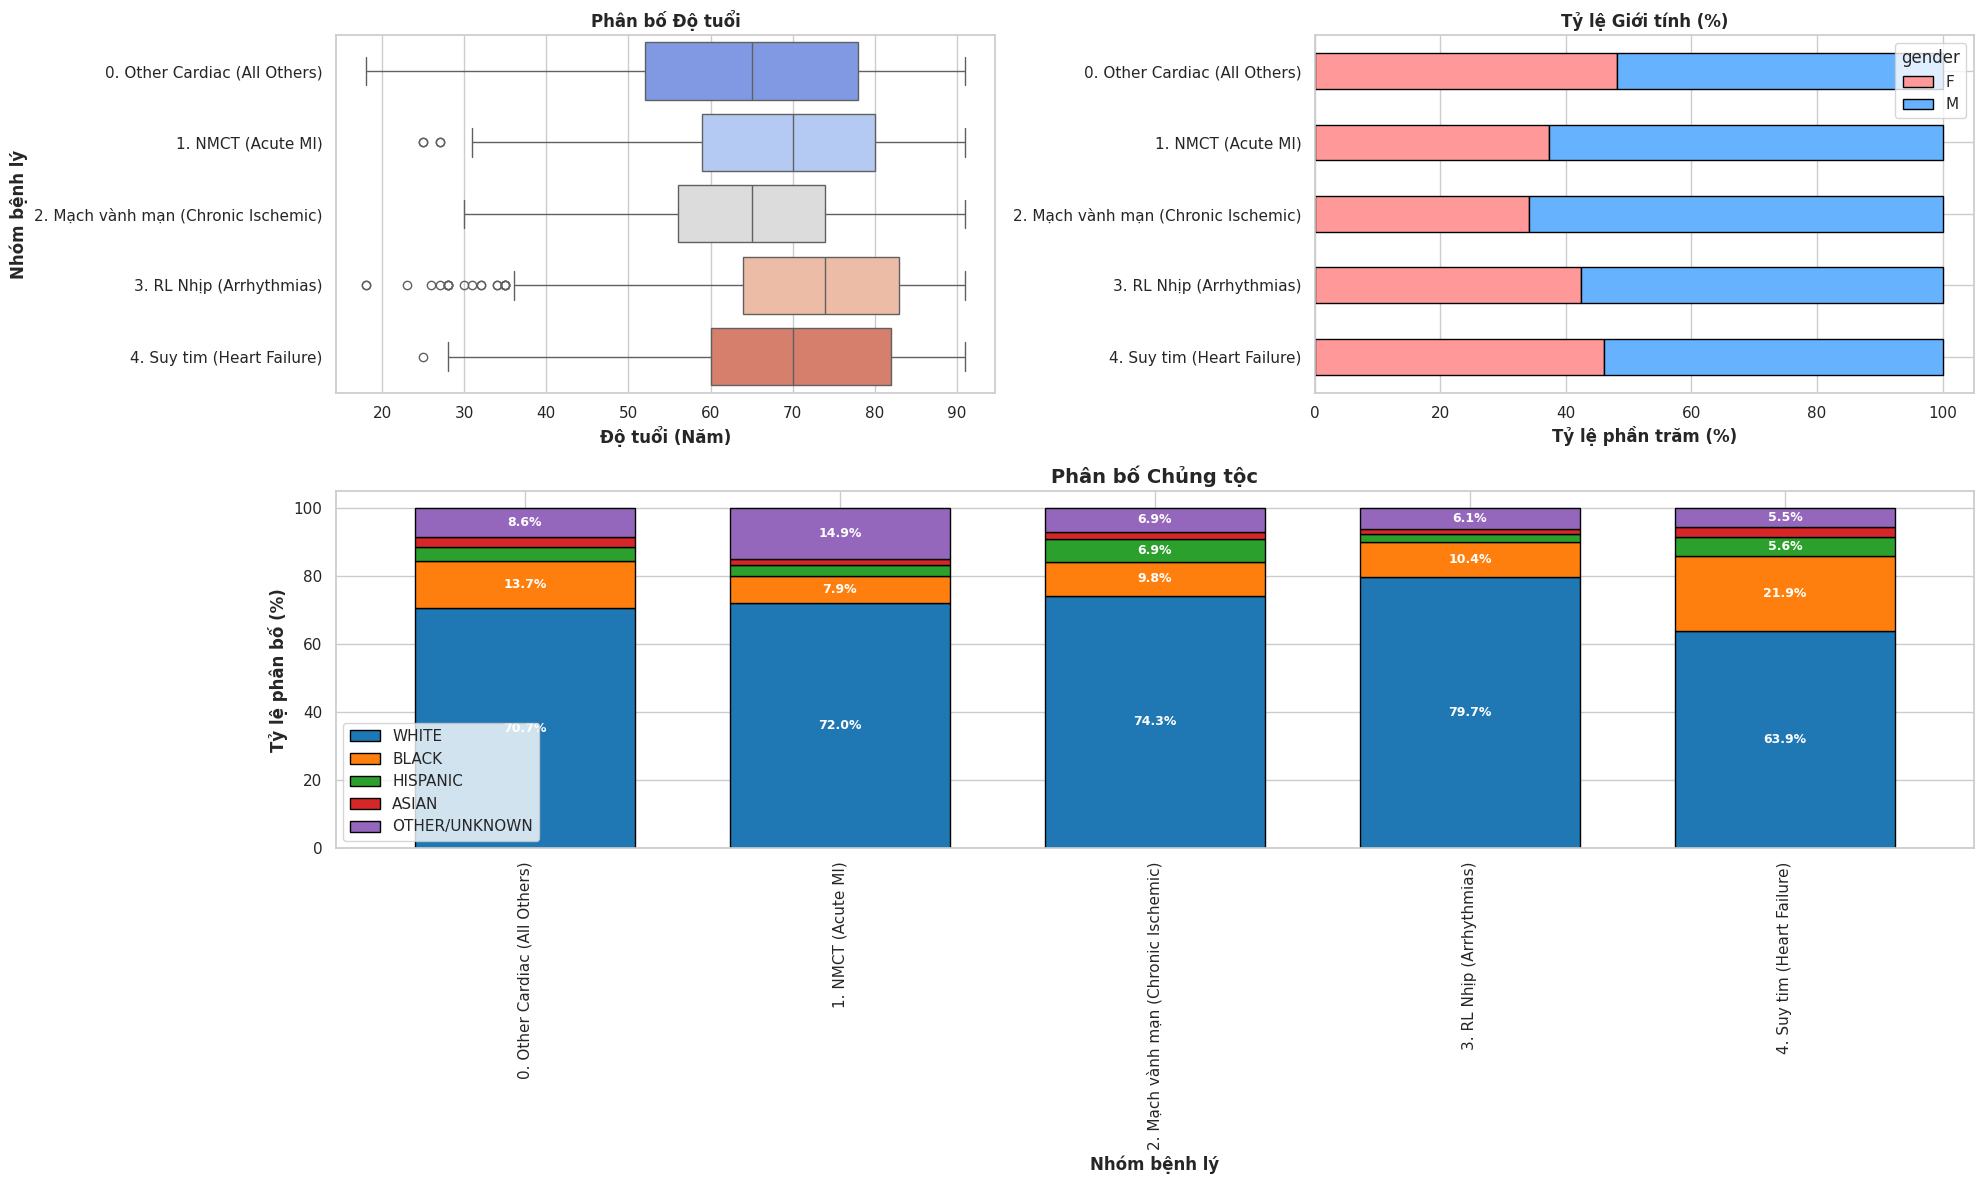


🥗🍺 PHÂN TÍCH LỐI SỐNG CHUYÊN SÂU (METABOLIC & LIFESTYLE)
   -> Đang quét 8 yếu tố nguy cơ cho 4761 ca nhập viện...
---------------------------------------------------------------------------------------
Nhóm Bệnh                              | SMK%| ALC%| SUB%| OBE%| LIP%| DIA%| SLP%| ANX%
---------------------------------------------------------------------------------------
0. Other Cardiac (All Others)          | 23.5|  5.1|  3.7|  8.6| 46.2| 22.9|  9.2| 10.8
1. NMCT (Acute MI)                     | 27.4|  3.0|  1.9| 10.0| 64.3| 40.0|  8.2| 10.6
2. Mạch vành mạn (Chronic Ischemic)    | 25.4|  3.3|  0.8| 11.6| 75.6| 40.6| 14.9| 11.1
3. RL Nhịp (Arrhythmias)               | 23.6|  4.5|  1.8| 13.9| 54.9| 33.8| 11.6|  8.6
4. Suy tim (Heart Failure)             | 25.2|  4.4|  2.7| 17.3| 57.4| 49.8| 16.3|  8.7


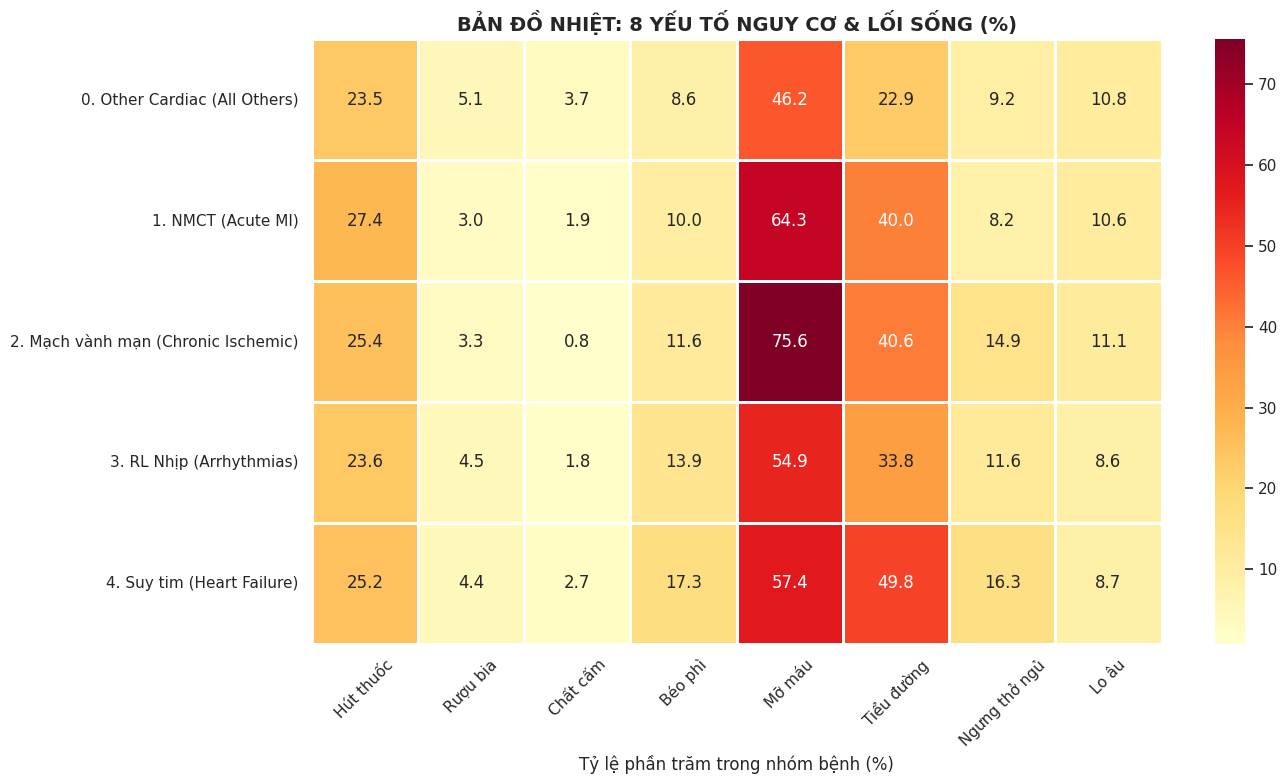


🔬 BÁO CÁO HẬU KỲ: PHÂN TÍCH NHÓM '0. OTHER CARDIAC'
   (Bao gồm: Màng tim, Van tim & Tất cả các bệnh tim khác như Tăng huyết áp, Tai biến...)

📋 TOP 20 BỆNH LÝ TRONG NHÓM OTHER CARDIAC:
Hạng  | Mã Chuẩn   | SL    | %      | Tên bệnh
--------------------------------------------------------------------------------
6     | I34        | 296   | 45.47  | Nonrheumatic mitral valve disorders
4     | I31        | 192   | 29.49  | Other diseases of pericardium
3     | I30        | 85    | 13.06  | Acute pericarditis
7     | I35        | 21    | 3.23   | Nonrheumatic aortic valve disorders
1     | I20        | 20    | 3.07   | Angina pectoris
5     | I33        | 17    | 2.61   | Acute and subacute endocarditis
9     | I42        | 11    | 1.69   | Cardiomyopathy
8     | I40        | 6     | 0.92   | Acute myocarditis
2     | I24        | 3     | 0.46   | Other acute ischemic heart diseases


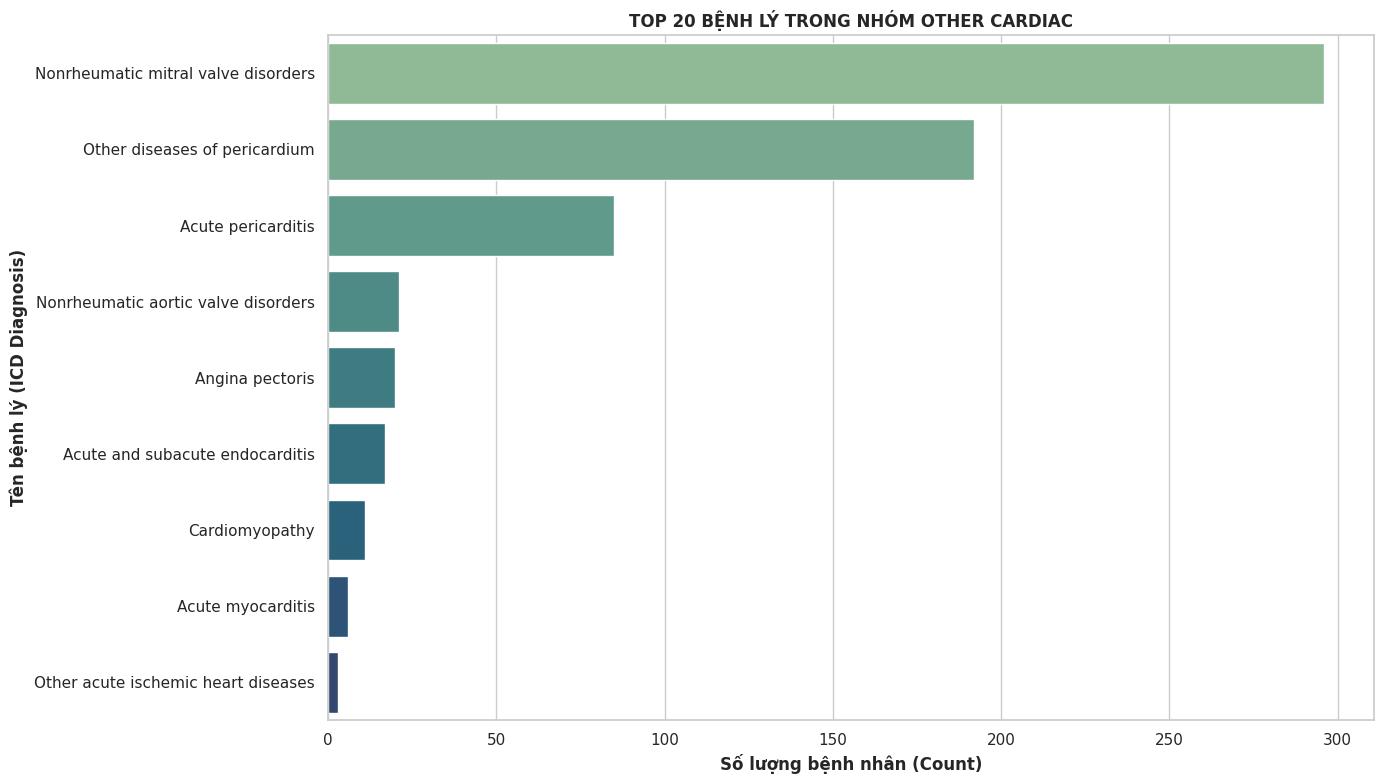

In [ ]:
# @title BLOCK 2: TARGET (Y) VARIABLE CREATION - FULL DEMOGRAPHICS
# ==============================================================================
# VERSION: PIPELINE 6 - COMPREHENSIVE CARDIAC
# 1. 4 MAIN GROUPS: MI (1), Chronic Ischemic (2), Arrhythmias (5), Heart Failure (6).
# 2. OTHER GROUP (0): Includes Pericardial (old 3) + Valvular (old 4) + ALL OTHER CARDIAC DISEASES.
# 3. EXCLUSION: ICD codes not belonging to the cardiovascular system (e.g., Diabetes, Lung, Kidney...).
# ==============================================================================
import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns

# [INSTRUCTIONS]:
# 1. Download the MIMIC-IV-Ext-Cardiac-Disease and MIMIC-IV v3.1 from PhysioNet.
# 2. Upload them to your Google Drive.
# 3. Update the paths below to match your directory structure.

# ==============================================================================
# 1. SYSTEM CONFIGURATION & DATA DICTIONARY
# ==============================================================================
BASE_PATH_EXT   = "/content/drive/MyDrive/MIMIC DATASET/mimic-iv-ext-cardiac-disease"
PATH_FULL_DIAG  = "/content/drive/MyDrive/MIMIC DATASET/mimic-iv-3.1/hosp/diagnoses_icd.csv.gz"
PATH_DIC_DIAG   = "/content/drive/MyDrive/MIMIC DATASET/mimic-iv-3.1/hosp/d_icd_diagnoses.csv.gz"
PATH_PATIENTS   = "/content/drive/MyDrive/MIMIC DATASET/mimic-iv-3.1/hosp/patients.csv.gz"
PATH_ADMISSIONS = "/content/drive/MyDrive/MIMIC DATASET/mimic-iv-3.1/hosp/admissions.csv.gz"
SAVE_DIR        = "/content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN"

if not os.path.exists(SAVE_DIR): os.makedirs(SAVE_DIR)
# ICD-9 to ICD-10 Mapping for common non-cardiac or symptomatic codes
ICD9_TO_10_MAP = {
    '78650': 'R079', '78659': 'R0789', '78651': 'R072',
    '78097': 'R4182', '78079': 'R5383', '7806': 'R509',
    '7802': 'R55', '30500': 'F1010', '30390': 'F1020',
    '486': 'J189', '4829': 'J159', '311': 'F329',
    '29620': 'F329', '5849': 'N179', '5845': 'N170',
    '5990': 'N390', '0389': 'A419', '99591': 'A419',
    '5770': 'K859', '5409': 'K3580', '99859': 'T814XXA',
    '25000': 'E119', '2724': 'E785'
}

# --- UPDATED LABEL MAP (CARDIAC ONLY) ---
LABEL_MAP = {
    0: '0. Other Cardiac (All Others)',
    1: '1. NMCT (Acute MI)',
    2: '2. Mạch vành mạn (Chronic Ischemic)',
    5: '3. RL Nhịp (Arrhythmias)',
    6: '4. Suy tim (Heart Failure)'
}

# Lifestyle and Metabolic risk factor ICD prefixes
LIFESTYLE_ICD_PREFIXES = {
    'SMOKE':    ('3051', 'V1582', '98984', 'F17', 'Z720'),
    'ALCOHOL':  ('303', '3050', '291', '3575', '4255', '5353', '5710', '5711', '5712', '5713', 'V113', 'F10', 'E244', 'G312', 'I426', 'K70', 'Z502', 'Z721'),
    'SUBST':    ('304', '3052', '3053', '3054', '3055', '3056', '3057', '3058', '3059', 'V6542', 'F11', 'F12', 'F13', 'F14', 'F15', 'F16', 'F18', 'F19'),
    'OBESITY':  ('2780', '2781', 'V853', 'V854', 'E66', 'Z683', 'Z684'),
    'LIPID':    ('272', 'E78'),
    'DIABETES': ('250', '249', 'E08', 'E09', 'E10', 'E11', 'E13'),
    'SLEEP':    ('3272', '78057', 'G473'),
    'ANXIETY':  ('300', 'F40', 'F41')
}

# ==============================================================================
# 2. DATA PROCESSING & FILTERING FUNCTIONS
# ==============================================================================
def detail_analysis_normalized(df_final, path_dic):
    print("\n" + "="*90)
    print("🔬 BÁO CÁO HẬU KỲ: PHÂN TÍCH NHÓM '0. OTHER CARDIAC'")
    print("   (Bao gồm: Màng tim, Van tim & Tất cả các bệnh tim khác như Tăng huyết áp, Tai biến...)")
    print("="*90)
    df = df_final[df_final['label'] == 0].copy()
    if len(df) == 0: return

    dic = pd.read_csv(path_dic, compression='gzip')
    dic['icd_code'] = dic['icd_code'].astype(str).str.strip().str.upper()
    code_to_name = dict(zip(dic['icd_code'], dic['long_title']))

    df['icd_code'] = df['icd_code'].astype(str).str.strip().str.upper()
    df = pd.merge(df, dic[['icd_code', 'icd_version']], on='icd_code', how='left')
    df['unified'] = df.apply(lambda r: ICD9_TO_10_MAP.get(r['icd_code'], r['icd_code']) if r['icd_version']==9 else r['icd_code'], axis=1)

    stats = df.groupby('unified').agg(Count=('unified','count'), Orig=('icd_code',lambda x:list(x.unique())[:2])).reset_index().sort_values('Count', ascending=False)
    stats['Name'] = stats['unified'].map(code_to_name).fillna("Unknown")
    stats['%'] = (stats['Count']/len(df)*100).round(2)

    print(f"\n📋 TOP 20 BỆNH LÝ TRONG NHÓM OTHER CARDIAC:")
    print(f"{'Hạng':<5} | {'Mã Chuẩn':<10} | {'SL':<5} | {'%':<6} | {'Tên bệnh'}")
    print("-" * 80)
    for i, r in stats.head(20).iterrows():
        print(f"{i+1:<5} | {r['unified']:<10} | {r['Count']:<5} | {r['%']:<6} | {r['Name'][:40]}")

    plt.figure(figsize=(14, 8))
    sns.barplot(data=stats.head(20), y='Name', x='Count', palette='crest')
    plt.xlabel('Số lượng bệnh nhân (Count)', fontsize=12, fontweight='bold')
    plt.ylabel('Tên bệnh lý (ICD Diagnosis)', fontsize=12, fontweight='bold')
    plt.title('TOP 20 BỆNH LÝ TRONG NHÓM OTHER CARDIAC', fontweight='bold')
    plt.tight_layout(); plt.show()

# ==============================================================================
# 3. VISUALIZATION FUNCTIONS
# ==============================================================================
def visualize_overview_fixed(df_train, df_val):
    print("\n" + "="*80)
    print("📈 BIỂU ĐỒ TỔNG QUAN PHÂN BỐ DỮ LIỆU")
    print("="*80)

    df_train['Set'] = 'MAIN'; df_val['Set'] = 'EXT_VAL'
    desired_order = ['MAIN', 'EXT_VAL']

    df_viz = pd.concat([df_train, df_val])
    df_viz['Name'] = df_viz['label'].map(LABEL_MAP)
    order = sorted(df_viz['Name'].unique())

    fig = plt.figure(figsize=(22, 12))

    # --- Plot 1: Sample Counts ---
    ax1 = fig.add_subplot(2, 2, 1)
    sns.countplot(data=df_viz, x='Name', hue='Set', order=order,
                  hue_order=desired_order, palette='viridis', ax=ax1)
    ax1.set_title('Số lượng mẫu', fontweight='bold')
    ax1.set_xlabel('Nhóm bệnh lý tim mạch', fontweight='bold')
    ax1.set_ylabel('Số lượng bản ghi (Rows)', fontweight='bold')
    ax1.tick_params(axis='x', rotation=20)
    for c in ax1.containers: ax1.bar_label(c, padding=2, fontsize=10, fontweight='bold')

    # --- Plot 2: Distribution Ratio (%) ---
    ax2 = fig.add_subplot(2, 2, 2)
    pct = df_viz.groupby('Set')['label'].value_counts(normalize=True).mul(100).rename('%').reset_index()
    pct['Name'] = pct['label'].map(LABEL_MAP)
    sns.barplot(data=pct, x='Name', y='%', hue='Set', order=order,
                hue_order=desired_order, palette='magma', ax=ax2)
    ax2.set_title('Tỷ lệ phân bố (%)', fontweight='bold')
    ax2.set_xlabel('Nhóm bệnh lý tim mạch', fontweight='bold')
    ax2.set_ylabel('Phần trăm (%)', fontweight='bold')
    ax2.tick_params(axis='x', rotation=20)
    for c in ax2.containers: ax2.bar_label(c, fmt='%.1f%%', padding=2, fontsize=10, fontweight='bold')

    #--- Plot 3: Temporal Distribution ---
    ax3 = fig.add_subplot(2, 1, 2)
    y_order = sorted(df_viz['anchor_year_group'].unique())
    sns.countplot(data=df_viz, x='anchor_year_group', hue='Set', order=y_order,
                  hue_order=desired_order, palette='Set2', ax=ax3)
    ax3.set_title('Phân bố theo thời gian', fontweight='bold')
    ax3.set_xlabel('Giai đoạn (Năm)', fontweight='bold')
    ax3.set_ylabel('Số lượng bệnh nhân', fontweight='bold')
    for c in ax3.containers: ax3.bar_label(c, padding=2, fontsize=10, fontweight='bold')

    plt.tight_layout(); plt.show()

# ==============================================================================
# 4. DEMOGRAPHIC ANALYSIS FUNCTIONS
# ==============================================================================
def standardize_race(race_str):
    r = str(race_str).upper()
    if 'WHITE' in r or 'PORTUGUESE' in r or 'CAUCASIAN' in r: return 'WHITE'
    elif 'BLACK' in r or 'AFRICAN' in r: return 'BLACK'
    elif 'HISPANIC' in r or 'LATINO' in r: return 'HISPANIC'
    elif 'ASIAN' in r: return 'ASIAN'
    else: return 'OTHER/UNKNOWN'

def analyze_demographics_full(df_dataset, df_patients, df_admissions):
    print("\n" + "="*90)
    print("🌍 PHÂN TÍCH NHÂN KHẨU HỌC TOÀN DIỆN (AGE, GENDER, RACE)")
    print("="*90)

    print("   -> Đang xử lý dữ liệu Race từ Admissions...")
    df_race = df_admissions[['hadm_id', 'race']].copy()
    df_race['Race Group'] = df_race['race'].apply(standardize_race)

    cols_drop = [c for c in ['gender', 'anchor_age', 'race', 'Race Group'] if c in df_dataset.columns]
    if cols_drop: df_dataset = df_dataset.drop(columns=cols_drop)

    df_merged = pd.merge(df_dataset, df_patients[['subject_id', 'gender', 'anchor_age']], on='subject_id', how='left')
    df_merged = pd.merge(df_merged, df_race[['hadm_id', 'Race Group']], on='hadm_id', how='left')
    df_merged['Race Group'] = df_merged['Race Group'].fillna('OTHER/UNKNOWN')

    df_merged['Group Name'] = df_merged['label'].map(LABEL_MAP)
    order_labels = sorted(LABEL_MAP.keys())

    print(f"\n{'Nhóm Bệnh':<40} | {'Tổng':>8} | {'Tuổi TB':>10} | {'Nam %':>8} | {'White %':>9} | {'Black %':>9} | {'Asian %':>9} | {'Hisp %':>9}")
    print("-" * 130)

    race_summary_list = []
    for label in order_labels:
        sub = df_merged[df_merged['label'] == label]
        total = len(sub)
        if total == 0: continue

        p_male = (len(sub[sub['gender']=='M']) / total) * 100
        age_mean = sub['anchor_age'].mean()
        r_counts = sub['Race Group'].value_counts(normalize=True) * 100

        row_race = r_counts.to_dict()
        row_race['Group Name'] = LABEL_MAP[label]
        race_summary_list.append(row_race)

        print(f"{LABEL_MAP[label]:<40} | {total:>8} | {age_mean:>10.1f} | {p_male:>8.1f} | {r_counts.get('WHITE',0):>9.1f} | {r_counts.get('BLACK',0):>9.1f} | {r_counts.get('ASIAN',0):>9.1f} | {r_counts.get('HISPANIC',0):>9.1f}")

    # PLOTTING
    fig = plt.figure(figsize=(20, 12))

    ax1 = fig.add_subplot(2, 2, 1)
    sns.boxplot(data=df_merged.sort_values('label'), x='anchor_age', y='Group Name', palette='coolwarm', ax=ax1)
    ax1.set_title('Phân bố Độ tuổi', fontweight='bold')
    ax1.set_xlabel('Độ tuổi (Năm)', fontweight='bold')
    ax1.set_ylabel('Nhóm bệnh lý', fontweight='bold')

    ax2 = fig.add_subplot(2, 2, 2)
    g_counts = df_merged.groupby(['Group Name', 'gender']).size().unstack(fill_value=0)
    g_counts = g_counts.reindex([LABEL_MAP[i] for i in order_labels if LABEL_MAP[i] in g_counts.index])
    g_counts.div(g_counts.sum(axis=1), axis=0).mul(100).plot(kind='barh', stacked=True, color=['#FF9999', '#66B2FF'], ax=ax2, edgecolor='black')
    ax2.set_title('Tỷ lệ Giới tính (%)', fontweight='bold'); ax2.invert_yaxis()
    ax2.set_xlabel('Tỷ lệ phần trăm (%)', fontweight='bold')
    ax2.set_ylabel('', fontweight='bold')

    ax3 = fig.add_subplot(2, 1, 2)
    df_race_plot = pd.DataFrame(race_summary_list).set_index('Group Name').fillna(0)
    cols_order = ['WHITE', 'BLACK', 'HISPANIC', 'ASIAN', 'OTHER/UNKNOWN']
    exist_cols = [c for c in cols_order if c in df_race_plot.columns]
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    df_race_plot[exist_cols].plot(kind='bar', stacked=True, ax=ax3, color=colors, edgecolor='black', width=0.7)
    ax3.set_title('Phân bố Chủng tộc', fontweight='bold', fontsize=14)
    ax3.set_ylabel('Tỷ lệ phân bố (%)', fontweight='bold')
    ax3.set_xlabel('Nhóm bệnh lý', fontweight='bold')

    for c in ax3.containers:
        labels = [f'{v.get_height():.1f}%' if v.get_height() > 5 else '' for v in c]
        ax3.bar_label(c, labels=labels, label_type='center', fontsize=9, color='white', fontweight='bold')

    plt.tight_layout(); plt.show()

# ==============================================================================
# 5. EXPANDED LIFESTYLE ANALYSIS MODULE
# ==============================================================================
def extract_and_analyze_lifestyle_expanded(df_cohort, path_full_diag):
    print("\n" + "="*90)
    print("🥗🍺 PHÂN TÍCH LỐI SỐNG CHUYÊN SÂU (METABOLIC & LIFESTYLE)")
    print("="*90)

    target_hadm = set(df_cohort['hadm_id'].unique())
    print(f"   -> Đang quét 8 yếu tố nguy cơ cho {len(target_hadm)} ca nhập viện...")

    df_diag_all = pd.read_csv(path_full_diag, compression='gzip')
    df_diag_all['icd_code'] = df_diag_all['icd_code'].astype(str).str.upper()
    df_relevant = df_diag_all[df_diag_all['hadm_id'].isin(target_hadm)].copy()

    keys = list(LIFESTYLE_ICD_PREFIXES.keys())
    results = {hadm: {k: 0 for k in keys} for hadm in target_hadm}

    grp = df_relevant.groupby('hadm_id')['icd_code'].apply(list)

    for hadm, codes in grp.items():
        for habit, prefixes in LIFESTYLE_ICD_PREFIXES.items():
            if any(c.startswith(tuple(prefixes)) for c in codes):
                results[hadm][habit] = 1

    df_lifestyle = pd.DataFrame.from_dict(results, orient='index').reset_index()
    df_lifestyle.rename(columns={'index': 'hadm_id'}, inplace=True)

    df_merged = pd.merge(df_cohort, df_lifestyle, on='hadm_id', how='left').fillna(0)

    header = f"{'Nhóm Bệnh':<38} |{'SMK%':>5}|{'ALC%':>5}|{'SUB%':>5}|{'OBE%':>5}|{'LIP%':>5}|{'DIA%':>5}|{'SLP%':>5}|{'ANX%':>5}"
    print("-" * len(header))
    print(header)
    print("-" * len(header))

    order_labels = sorted(LABEL_MAP.keys())
    habit_data = []

    for label in order_labels:
        sub = df_merged[df_merged['label'] == label]
        total = len(sub)
        if total == 0: continue

        vals = {}
        for k in keys:
            vals[k] = (sub[k].sum() / total) * 100

        print(f"{LABEL_MAP[label]:<38} |{vals['SMOKE']:>5.1f}|{vals['ALCOHOL']:>5.1f}|{vals['SUBST']:>5.1f}|{vals['OBESITY']:>5.1f}|{vals['LIPID']:>5.1f}|{vals['DIABETES']:>5.1f}|{vals['SLEEP']:>5.1f}|{vals['ANXIETY']:>5.1f}")

        row_data = vals.copy()
        row_data['Group'] = LABEL_MAP[label]
        habit_data.append(row_data)

    if habit_data:
        df_viz = pd.DataFrame(habit_data).set_index('Group')
        rename_map = {
            'SMOKE': 'Hút thuốc', 'ALCOHOL': 'Rượu bia', 'SUBST': 'Chất cấm',
            'OBESITY': 'Béo phì', 'LIPID': 'Mỡ máu', 'DIABETES': 'Tiểu đường',
            'SLEEP': 'Ngưng thở ngủ', 'ANXIETY': 'Lo âu'
        }
        df_viz.rename(columns=rename_map, inplace=True)

        plt.figure(figsize=(14, 8))
        sns.heatmap(df_viz, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=1)
        plt.title('BẢN ĐỒ NHIỆT: 8 YẾU TỐ NGUY CƠ & LỐI SỐNG (%)', fontweight='bold', fontsize=14)
        plt.ylabel('')
        plt.xlabel('Tỷ lệ phần trăm trong nhóm bệnh (%)')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

# ==============================================================================
# 5. MAIN PIPELINE
# ==============================================================================
def run_pipeline_complete(base_path, path_full, path_dic, path_pat, path_adm):

    print("\n" + "="*40)
    print("🔄 [Step 1] XỬ LÝ DỮ LIỆU BỆNH TIM (COMPREHENSIVE)")
    print("="*40)
    try: df_diag = pd.read_csv(os.path.join(base_path, "heart_diagnoses_all.csv"))
    except: print("❌ Không tìm thấy file heart_diagnoses_all.csv"); return None

    df_diag['icd_code'] = df_diag['icd_code'].astype(str).str.upper()

    # --- 1. EXPAND MAPPING: CAPTURE ALL CARDIAC DISEASES INTO TEMP GROUP 7 ---
    def get_cls(c):
        # 4 MAIN GROUPS (HIGH PRIORITY)
        if c.startswith('I21'): return 1
        if c.startswith('I50'): return 6
        if c.startswith(('I44','I45','I47','I48','I49')): return 5
        if c.startswith('I25'): return 2

        # 2 OLD GROUPS (TO BE CATEGORIZED)
        if c.startswith(('I30','I31')): return 3 # Pericardial
        if c.startswith('I34'): return 4         # Valvular

        # [IMPORTANT] CAPTURE ALL OTHER CARDIAC CONDITIONS (GENERAL OTHER)
        # Logic: ICD-10 Chapter I (Circulatory system) starts with 'I'
        # Or ICD-9 codes in range 390-459 (Circulatory system)
        if c.startswith('I'): return 7 # Other ICD-10 Heart

        # Check ICD-9 (Numeric string format)
        if c[0].isdigit():
            try:
                val = int(c[:3]) # Lấy 3 ký tự đầu
                if 390 <= val <= 459: return 7 # Other ICD-9 Heart
            except: pass

        return -1 # Non-Cardiac (Tiểu đường, Thận, Phổi...) -> Sẽ bị loại bỏ

    df_diag['label'] = df_diag['icd_code'].apply(get_cls)

    # Keep only valid cardiac labels (Exclude -1)
    df_t = df_diag[df_diag['label'] != -1].copy()

    # --- 2. DYNAMIC THRESHOLD STRATEGY ---
    def filter_logic(row):
        lbl = row['label']
        seq = row['seq_num']

        # Acute Groups: MI (1), Pericardial (3), Heart Failure (6)
        if lbl in [1, 3, 6]: return seq <= 5

        # Chronic & GENERAL OTHER (7) Groups:
        # Chronic Ischemic (2), Valvular (4), Arrhythmias (5), Other Heart (7)
        # Other heart conditions (e.g., Hypertension I10) are usually chronic.
        if lbl in [2, 4, 5, 7]: return seq <= 15

        return False

    df_t = df_t[df_t.apply(filter_logic, axis=1)]

    # --- 3. HIERARCHICAL PRIORITY ---
    # Prioritize main diseases. General Other (7) has the lowest priority.
    # Rank: 1(MI) > 3(Peri) > 4(Valve) > 5(Arr) > 6(HF) > 2(Ischemic) > 7(General Other)

    priority_map = {
        1: 1,  # MI
        3: 2,  # Pericardial
        4: 3,  # Valvular
        5: 4,  # Arrhythmias
        6: 5,  # Heart Failure
        2: 6,  # Chronic Ischemic
        7: 7   # General Other (Hypertension, Stroke, Thrombosis...)
    }
    df_t['prio'] = df_t['label'].map(priority_map)

    # Select unique outcome (Primary Diagnosis)
    df_cases = df_t.sort_values(['hadm_id','prio','seq_num']).drop_duplicates('hadm_id')[['hadm_id','subject_id','label','icd_code']]

    # --- [FINAL MERGE] MERGE ALL SUB-GROUPS INTO OTHER (0) ---
    print("🔄 Đang gộp: Màng tim (3) + Van tim (4) + General Heart (7) -> Other Cardiac (0)...")
    df_cases['label'] = df_cases['label'].replace({3: 0, 4: 0, 7: 0})

    print("   -> Đang đọc thông tin bệnh nhân (Split Train/Val)...")
    df_p = pd.read_csv(path_pat, compression='gzip', usecols=['subject_id','anchor_year_group', 'gender', 'anchor_age'])
    df_cases = pd.merge(df_cases, df_p, on='subject_id', how='left')

    tr_grps = ['2008 - 2010', '2011 - 2013']
    val_grps = ['2014 - 2016', '2017 - 2019']

    c_train = df_cases[df_cases['anchor_year_group'].isin(tr_grps)].copy()
    c_val = df_cases[df_cases['anchor_year_group'].isin(val_grps)].copy()

    print(f"✅ Đã xử lý xong dữ liệu: MAIN={len(c_train)}, EXTERNAL={len(c_val)}")

    print("\n" + "="*40)
    print("🔄 [Step 2] LƯU DỮ LIỆU CUỐI CÙNG (PIPELINE 6)")
    print("="*40)
    cols = ['hadm_id','subject_id','label','icd_code','anchor_year_group']

    df_tr_fin = c_train[cols].sample(frac=1, random_state=42).reset_index(drop=True)
    df_vl_fin = c_val[cols].sample(frac=1, random_state=42).reset_index(drop=True)

    f_train = os.path.join(SAVE_DIR, "pipeline6_(Y_TARGET)_dataset_main.csv")
    f_external_validate   = os.path.join(SAVE_DIR, "pipeline6_(Y_TARGET)dataset_external_validate.csv")

    df_tr_fin.to_csv(f_train, index=False)
    df_vl_fin.to_csv(f_external_validate, index=False)
    print(f"💾 Đã lưu file tại: \n {f_train} \n {f_external_validate}")

    sm = pd.DataFrame({'MAIN': df_tr_fin['label'].value_counts(), 'EXTERNAL': df_vl_fin['label'].value_counts()}).fillna(0)
    sm.index = [LABEL_MAP.get(i,i) for i in sm.index]
    print("\n📊 SUMMARY:\n", sm)

    visualize_overview_fixed(df_tr_fin, df_vl_fin)

    print("\n📦 Loading Admissions Data (Race)...")
    try:
        df_adm = pd.read_csv(path_adm, compression='gzip', usecols=['hadm_id', 'race'])
    except Exception as e:
        print(f"⚠️ Không thể đọc file admissions: {e}"); df_adm = pd.DataFrame(columns=['hadm_id', 'race'])

    analyze_demographics_full(pd.concat([df_tr_fin, df_vl_fin]), df_p, df_adm)
    extract_and_analyze_lifestyle_expanded(pd.concat([df_tr_fin, df_vl_fin]), path_full)
    detail_analysis_normalized(pd.concat([df_tr_fin, df_vl_fin]), path_dic)

    return df_tr_fin, df_vl_fin

if __name__ == "__main__":
    df_tr, df_vl = run_pipeline_complete(BASE_PATH_EXT, PATH_FULL_DIAG, PATH_DIC_DIAG, PATH_PATIENTS, PATH_ADMISSIONS)

In [ ]:
# @title TARGET DATA LEAKAGE CHECK (Y_TARGET)
# ====================================================
# 3. DATA LEAKAGE CHECK
# ====================================================

def check_patient_overlap(df_train, df_val):
    print("\n" + "="*80)
    print("🕵️‍♂️ KIỂM TRA TRÙNG LẶP BỆNH NHÂN (SUBJECT_ID OVERLAP)")
    print("="*80)

    # Get unique IDs
    train_ids = set(df_train['subject_id'].unique())
    val_ids   = set(df_val['subject_id'].unique())

    # Find intersection
    overlap_ids = train_ids.intersection(val_ids)
    n_overlap = len(overlap_ids)

    print(f"🔹 Số lượng bệnh nhân trong tập TRAIN: {len(train_ids)}")
    print(f"🔹 Số lượng bệnh nhân trong tập VAL:   {len(val_ids)}")
    print("-" * 60)

    if n_overlap == 0:
        print(f"✅ TUYỆT VỜI! Không có bệnh nhân nào bị trùng giữa 2 tập.")
        print("   => Tập External Validation hoàn toàn độc lập (Independent).")
        print("   => Kết quả kiểm chứng sẽ khách quan và đáng tin cậy.")
    else:
        print(f"⚠️ CẢNH BÁO ĐỎ: Phát hiện {n_overlap} bệnh nhân xuất hiện ở cả 2 tập!")
        print("   👉 Đang tiến hành loại bỏ các bệnh nhân này khỏi tập TRAIN...")

        # HANDLE OVERLAP: Remove from TRAIN set (Keep Val set intact for testing)
        df_train_clean = df_train[~df_train['subject_id'].isin(overlap_ids)].copy()

        print(f"   - Số mẫu Train trước khi xóa: {len(df_train)}")
        print(f"   - Số mẫu Train sau khi xóa:   {len(df_train_clean)}")
        print(f"   - Đã loại bỏ: {len(df_train) - len(df_train_clean)} dòng.")

        # Save the cleaned file
        path_train_clean = os.path.join(SAVE_DIR, "dataset_full_train_2008_2013_pipeline5_cleaned.csv")
        df_train_clean.to_csv(path_train_clean, index=False)
        print(f"💾 Đã lưu file Train mới (đã làm sạch) tại: {os.path.basename(path_train_clean)}")

        return df_train_clean, df_val

    return df_train, df_val

# Execute check on current df_train and df_val variables
# (If session was restarted, reload from saved CSV files)
if 'df_train' in globals() and 'df_val' in globals():
    df_train, df_val = check_patient_overlap(df_train, df_val)
else:
    print("⚠️ Không tìm thấy biến df_train/df_val trong bộ nhớ. Đang load lại từ file...")
    try:
        p_train = "/content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_(Y_TARGET)_dataset_main.csv"
        p_val   = "/content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_(Y_TARGET)dataset_external_validate.csv"
        df_train = pd.read_csv(p_train)
        df_val = pd.read_csv(p_val)
        df_train, df_val = check_patient_overlap(df_train, df_val)
    except Exception as e:
        print(f"❌ Lỗi: {e}")

⚠️ Không tìm thấy biến df_train/df_val trong bộ nhớ. Đang load lại từ file...

🕵️‍♂️ KIỂM TRA TRÙNG LẶP BỆNH NHÂN (SUBJECT_ID OVERLAP)
🔹 Số lượng bệnh nhân trong tập TRAIN: 3258
🔹 Số lượng bệnh nhân trong tập VAL:   1031
------------------------------------------------------------
✅ TUYỆT VỜI! Không có bệnh nhân nào bị trùng giữa 2 tập.
   => Tập External Validation hoàn toàn độc lập (Independent).
   => Kết quả kiểm chứng sẽ khách quan và đáng tin cậy.


In [ ]:
# @title BLOCK 3: COMPREHENSIVE CARDIAC FEATURE EXTRACTION & DRIVE STORAGE (AUDIT MODE)
# =============================================================================
# VERSION: PIPELINE 6 - MATCHING WITH COHORT SELECTION
# =============================================================================
import pandas as pd
import numpy as np
import os
import re
import pickle
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
import warnings

warnings.filterwarnings('ignore')

# [INSTRUCTIONS]:
# 1. Download the MIMIC-IV-Ext-Cardiac-Disease and MIMIC-IV v3.1 from PhysioNet.
# 2. Upload them to your Google Drive.
# 3. Update the paths below to match your directory structure.

# =============================================================================
# 1. PATH CONFIGURATION (SYNCED WITH BLOCKS 1 & 2)
# =============================================================================
# Paths for auxiliary data (Labs, Text, Micro previously extracted)
BASE_PATH_EXT   = "/content/drive/MyDrive/MIMIC DATASET/mimic-iv-ext-cardiac-disease"
# Original MIMIC path (used for Demographics)
MIMIC_IV_PATH   = "/content/drive/MyDrive/MIMIC DATASET/mimic-iv-3.1"
# Output storage path
SAVE_DIR        = "/content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN"

# INPUT: Results from Code Block 2 (Pipeline 6)
PATH_MAIN_IN    = os.path.join(SAVE_DIR, "pipeline6_(Y_TARGET)_dataset_main.csv")
PATH_EXT_IN     = os.path.join(SAVE_DIR, "pipeline6_(Y_TARGET)dataset_external_validate.csv")

# =============================================================================
# 2. FEATURE EXTRACTION FUNCTION (CORE ENGINE)
# =============================================================================
def extract_raw_features(base_path, mimic_core_path, df_labels, dataset_type='train', fitted_objects=None):
    """
    Extract features.
    - dataset_type='train': Fit transformers and EXPORT AUDIT FILES.
    - dataset_type='test': Use fitted_objects to transform.
    """
    print(f"\n🔄 [STEP 2] TRÍCH XUẤT FEATURE CHO TẬP: {dataset_type.upper()} (N={len(df_labels)})...")

    # Initialize dict to store fitted objects (if train)
    if dataset_type == 'train':
        fitted_objects = {}

    target_hadms = df_labels['hadm_id'].unique()

    # ---------------------------------------------------------
    # MODULE A: LAB EVENTS (Biomarkers)
    # ---------------------------------------------------------
    print("   🧪 [2.1] Processing Lab Events...")
    try:
        df_labs = pd.read_csv(os.path.join(base_path, "heart_labevents_first_lab.csv"))
        df_labs['clean_label'] = "LAB_" + df_labs['label'].astype(str).apply(lambda x: re.sub(r'[^a-zA-Z0-9]', '_', x))

        df_lab_sub = df_labs[df_labs['hadm_id'].isin(target_hadms)]
        # Pivot: Mỗi hadm_id là 1 dòng, mỗi xét nghiệm là 1 cột
        df_lab_raw = df_lab_sub.pivot_table(index='hadm_id', columns='clean_label', values='valuenum', aggfunc='mean')
    except Exception as e:
        print(f"   ⚠️ Lỗi đọc Labs: {e}. Tạo DataFrame rỗng.")
        df_lab_raw = pd.DataFrame(index=target_hadms)

    if dataset_type == 'train':
        # Sparsity Filter: Keep columns with data in > 1% of patients
        min_count = 0.01 * len(df_labels)
        valid_cols = df_lab_raw.columns[df_lab_raw.notna().sum() >= min_count]
        fitted_objects['lab_cols'] = valid_cols
        print(f"      -> [TRAIN] Fit Lab columns: giữ lại {len(valid_cols)} xét nghiệm.")
    else:
        valid_cols = fitted_objects['lab_cols']
        print(f"      -> [TEST] Transform Lab columns: áp dụng {len(valid_cols)} cột từ Main.")

    # Reindex to ensure columns match between train/test
    df_lab_filtered = df_lab_raw.reindex(columns=valid_cols)

    # ---------------------------------------------------------
    # MODULE B: TEXT MINING (Clinical Notes + Reports)
    # ---------------------------------------------------------
    print("   📝 [2.2] Processing Clinical Text...")
    try:
        df_text_all = pd.read_csv(os.path.join(base_path, "heart_diagnoses.csv"))

        text_cols = ['chief_complaint', 'HPI', 'physical_exam']
        if 'reports' in df_text_all.columns:
            print("      -> [INFO] Phát hiện cột 'reports'. Đang tích hợp dữ liệu ECG/Echo reports...")
            text_cols.append('reports')

        df_text_all['combined_text'] = df_text_all[text_cols].fillna('').agg(' '.join, axis=1).str.lower()

        # Merge to fetch rows matching hadm_id
        df_text_merged = pd.merge(df_labels[['hadm_id']], df_text_all[['hadm_id', 'combined_text']], on='hadm_id', how='left')
        corpus = df_text_merged['combined_text'].fillna('')
    except Exception as e:
        print(f"   ⚠️ Lỗi đọc Text: {e}. Tạo corpus rỗng.")
        df_text_merged = pd.DataFrame({'hadm_id': target_hadms, 'combined_text': ''})
        corpus = df_text_merged['combined_text']

    if dataset_type == 'train':
        # TF-IDF: Top 300 important keywords
        vectorizer = TfidfVectorizer(max_features=300, stop_words='english', ngram_range=(1, 2), min_df=0.01)
        tfidf_matrix = vectorizer.fit_transform(corpus)
        fitted_objects['tfidf'] = vectorizer

        feature_names = vectorizer.get_feature_names_out()
        tfidf_cols = [f"TXT_{word.replace(' ', '_')}" for word in feature_names]

        # [AUDIT] EXPORT DETAILED TEXT FEATURE DEFINITIONS
        print(f"      -> [AUDIT] Đang xuất file chi tiết {len(tfidf_cols)} từ khóa lâm sàng...")
        df_text_audit = pd.DataFrame({
            'Feature_Name': tfidf_cols,
            'Original_Keyword': feature_names,
            'IDF_Weight': vectorizer.idf_  # IDF Weights
        })
        audit_text_path = os.path.join(base_path, "pipeline6_audit_feature_definitions_TEXT.csv")
        df_text_audit.to_csv(audit_text_path, index=False)
        print(f"      -> ✅ Đã lưu file định nghĩa Text tại: {audit_text_path}")

    else:
        vectorizer = fitted_objects['tfidf']
        tfidf_matrix = vectorizer.transform(corpus)
        feature_names = vectorizer.get_feature_names_out()
        tfidf_cols = [f"TXT_{word.replace(' ', '_')}" for word in feature_names]
        print("      -> [TEST] Transform TF-IDF.")

    df_tfidf = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_cols, index=df_labels['hadm_id'])

    # ---------------------------------------------------------
    # MODULE D: ECG & ECHOCARDIOGRAM (Regex)
    # ---------------------------------------------------------
    print("   💓 [2.3] Extracting ECG & Echo Features...")

    # [AUDIT] LOGIC DEFINITION LIST
    if dataset_type == 'train':
        cardiac_logic_audit = [
            {'Feature': 'ECHO_LVEF', 'Type': 'Numeric', 'Logic': 'Regex catch "LVEF/EF" values (10-80%)', 'Clinical_Note': 'Left Ventricular Ejection Fraction - Chỉ số bơm máu thất trái'},
            {'Feature': 'ECG_AFIB', 'Type': 'Binary', 'Logic': 'Regex: "atrial fib", "a-fib", "afib"', 'Clinical_Note': 'Rung nhĩ - Nguy cơ huyết khối cao'},
            {'Feature': 'ECG_ST_ELEV', 'Type': 'Binary', 'Logic': 'Regex: "st elevation", "st segment elevation"', 'Clinical_Note': 'Dấu hiệu nhồi máu cơ tim cấp (STEMI)'},
            {'Feature': 'ECG_SINUS', 'Type': 'Binary', 'Logic': 'Regex: "sinus rhythm", "nsr"', 'Clinical_Note': 'Nhịp xoang bình thường (Baseline)'}
        ]
        print(f"      -> [AUDIT] Đang xuất file chi tiết Logic tim mạch chuyên sâu...")
        df_cardiac_audit = pd.DataFrame(cardiac_logic_audit)
        audit_cardiac_path = os.path.join(base_path, "pipeline6_audit_feature_definitions_CARDIAC.csv")
        df_cardiac_audit.to_csv(audit_cardiac_path, index=False)
        print(f"      -> ✅ Đã lưu file định nghĩa Cardiac tại: {audit_cardiac_path}")

    def extract_cardiac_specs(text):
        specs = {'ECHO_LVEF': np.nan, 'ECG_AFIB': 0, 'ECG_ST_ELEV': 0, 'ECG_SINUS': 0}
        if not isinstance(text, str): return pd.Series(specs)

        # 1. LVEF (Ejection Fraction)
        ef_matches = re.findall(r'(?:lvef|ef|ejection fraction)\s*[:=]?\s*(?:of)?\s*(\d{2})', text)
        if ef_matches:
            valid = [float(x) for x in ef_matches if 10 <= float(x) <= 80]
            if valid: specs['ECHO_LVEF'] = np.mean(valid)

        # 2. ECG Patterns
        specs['ECG_AFIB']    = 1 if re.search(r'(atrial fib|a-fib|afib)', text) else 0
        specs['ECG_ST_ELEV'] = 1 if re.search(r'(st elevation|st-elevation|st segment elevation)', text) else 0
        specs['ECG_SINUS']   = 1 if re.search(r'(sinus rhythm|nsr)', text) else 0
        return pd.Series(specs)

    df_cardiac_specs = df_text_merged['combined_text'].apply(extract_cardiac_specs)
    df_cardiac_specs.index = df_labels['hadm_id']

    # ---------------------------------------------------------
    # MODULE E: DEMOGRAPHICS (Lấy từ MIMIC Core)
    # ---------------------------------------------------------
    print("   👥 [2.4] Extracting Demographics...")
    try:
        df_pat = pd.read_csv(os.path.join(mimic_core_path, 'hosp', 'patients.csv.gz'), compression='gzip', usecols=['subject_id', 'gender', 'anchor_age', 'anchor_year'])
        df_adm = pd.read_csv(os.path.join(mimic_core_path, 'hosp', 'admissions.csv.gz'), compression='gzip', usecols=['subject_id', 'hadm_id', 'admittime', 'race'])

        df_demo = pd.merge(df_labels[['hadm_id', 'subject_id']], df_adm, on=['hadm_id', 'subject_id'], how='left')
        df_demo = pd.merge(df_demo, df_pat, on='subject_id', how='left')

        df_demo['admittime'] = pd.to_datetime(df_demo['admittime'])
        # Calculate actual age at time of admission
        df_demo['DEMO_AGE'] = df_demo['anchor_age'] + (df_demo['admittime'].dt.year - df_demo['anchor_year'])
        df_demo['DEMO_GENDER_MALE'] = (df_demo['gender'] == 'M').astype(int)

        def clean_race(x):
            x = str(x).lower()
            if 'white' in x: return 'WHITE'
            elif 'black' in x or 'african' in x: return 'BLACK'
            elif 'hispanic' in x or 'latino' in x: return 'HISPANIC'
            elif 'asian' in x: return 'ASIAN'
            else: return 'OTHER'

        df_demo['race_group'] = df_demo['race'].apply(clean_race)
        df_race_dummies = pd.get_dummies(df_demo['race_group'], prefix='DEMO_RACE').astype(int)

        # Synchronize Race columns (ensure identical columns for Train and Test)
        if dataset_type == 'train':
            fitted_objects['race_cols'] = df_race_dummies.columns
        else:
            df_race_dummies = df_race_dummies.reindex(columns=fitted_objects['race_cols'], fill_value=0)

        df_demo = pd.concat([df_demo, df_race_dummies], axis=1)
        demo_cols = ['hadm_id', 'DEMO_AGE', 'DEMO_GENDER_MALE'] + list(df_race_dummies.columns)
        df_demo_final = df_demo[demo_cols].set_index('hadm_id')
        print(f"      -> Demographic Features: Age, Gender, Race Grouping (One-hot).")
    except Exception as e:
        print(f"   ⚠️ Lỗi Demographics: {e}. Dùng mặc định.")
        df_demo_final = pd.DataFrame(index=target_hadms)

    # ---------------------------------------------------------
    # MODULE C: MICROBIOLOGY
    # ---------------------------------------------------------
    print("   🧫 [2.5] Processing Microbiology...")
    try:
        df_micro = pd.read_csv(os.path.join(base_path, "heart_microbiologyevents.csv"))
        df_micro_sub = df_micro[df_micro['hadm_id'].isin(target_hadms)]

        if not df_micro_sub.empty:
            df_micro_sub['clean_org'] = "MICRO_" + df_micro_sub['org_name'].astype(str).apply(lambda x: re.sub(r'[^a-zA-Z0-9]', '_', x))
            df_micro_raw = pd.crosstab(df_micro_sub['hadm_id'], df_micro_sub['clean_org']).clip(upper=1)
        else:
            df_micro_raw = pd.DataFrame()
    except Exception as e:
        print(f"   ⚠️ Lỗi Micro: {e}. Bỏ qua.")
        df_micro_raw = pd.DataFrame()

    if dataset_type == 'train':
        fitted_objects['micro_cols'] = df_micro_raw.columns
    else:
        df_micro_raw = df_micro_raw.reindex(columns=fitted_objects['micro_cols'], fill_value=0)

    # =============================================================================
    # DATA AGGREGATION AND IMPUTATION
    # =============================================================================
    print("\n🔄 [STEP 3] TỔNG HỢP DỮ LIỆU & IMPUTATION...")

    df_final = pd.merge(df_labels, df_lab_filtered, on='hadm_id', how='left')
    df_final = pd.merge(df_final, df_tfidf, on='hadm_id', how='left')
    df_final = pd.merge(df_final, df_cardiac_specs, on='hadm_id', how='left')
    df_final = pd.merge(df_final, df_demo_final, on='hadm_id', how='left')
    df_final = pd.merge(df_final, df_micro_raw, on='hadm_id', how='left')

    y = df_final['label']
    # Remove metadata columns, keeping only features for the Model
    X = df_final.drop(columns=['hadm_id', 'subject_id', 'label', 'icd_code', 'anchor_year_group'], errors='ignore')

    # Imputation (Fill missing data)
    numeric_cols = [c for c in X.columns if c.startswith('LAB_') or c == 'ECHO_LVEF' or c == 'DEMO_AGE']

    if dataset_type == 'train':
        imputer = SimpleImputer(strategy='median')
        X[numeric_cols] = imputer.fit_transform(X[numeric_cols])
        fitted_objects['imputer'] = imputer
    else:
        imputer = fitted_objects['imputer']
        X[numeric_cols] = imputer.transform(X[numeric_cols])

    # Fill remaining columns (Binary, Count) with 0
    other_cols = [c for c in X.columns if c not in numeric_cols]
    X[other_cols] = X[other_cols].fillna(0)

    # =============================================================================
    # 5. FINAL LOGGING & REPORT
    # =============================================================================
    # Only print detailed report when running Train set for audit
    if dataset_type == 'train':
        print("\n" + "="*60)
        print("📊 BÁO CÁO CHI TIẾT CÁC NHÓM FEATURE (FULL AUDIT LIST)")
        print("="*60)

        def print_full_list(title, prefix_list):
            cols = [c for c in X.columns if any(c.startswith(p) for p in prefix_list)]
            print(f"{title} (Tổng: {len(cols)} features):")
            print(f"Danh sách đầy đủ: {', '.join(cols)}")
            print("-" * 30)

        print_full_list("1. [LABS] Xét nghiệm máu", ['LAB_'])
        print_full_list("2. [TEXT] Từ khóa lâm sàng", ['TXT_'])
        print_full_list("3. [CARDIAC] Tim mạch chuyên sâu", ['ECHO_', 'ECG_'])
        print_full_list("4. [DEMO] Nhân khẩu học", ['DEMO_'])
        print_full_list("5. [MICRO] Vi sinh", ['MICRO_'])
        print("="*60)

    print(f"   ✅ Hoàn tất {dataset_type.upper()}. Shape X: {X.shape}")

    if dataset_type == 'train':
        return X, y, df_final['hadm_id'], fitted_objects
    else:
        return X, y, df_final['hadm_id'], None

# =============================================================================
# --- EXECUTION PIPELINE (MAIN) ---
# =============================================================================
print(f"🚀 BẮT ĐẦU PIPELINE 3: FEATURE ENGINEERING (PIPELINE 6)")

# 1. READ DATA FROM BLOCK 2
if os.path.exists(PATH_MAIN_IN) and os.path.exists(PATH_EXT_IN):
    print("📂 Đang đọc dữ liệu đầu vào từ Ô Mã 2...")
    df_main_cohort = pd.read_csv(PATH_MAIN_IN)
    df_ext_cohort = pd.read_csv(PATH_EXT_IN)
    print(f"   + Main Cohort: {len(df_main_cohort)} rows")
    print(f"   + Ext Cohort : {len(df_ext_cohort)} rows")
else:
    raise FileNotFoundError("❌ Không tìm thấy file output từ Ô 2. Vui lòng chạy Ô 2 trước!")

# 2. PROCESS MAIN SET (TRAIN) - LEARN PARAMETERS + EXPORT FULL AUDIT REPORT
X_main, y_main, ids_main, fitted_transformers = extract_raw_features(
    BASE_PATH_EXT, MIMIC_IV_PATH, df_main_cohort, dataset_type='train'
)

# 3. PROCESS EXTERNAL SET (TEST) - APPLY PARAMETERS FROM MAIN
X_ext, y_ext, ids_ext, _ = extract_raw_features(
    BASE_PATH_EXT, MIMIC_IV_PATH, df_ext_cohort, dataset_type='test', fitted_objects=fitted_transformers
)

# 4. SAVE FINAL DATA (CSV)
print("\n" + "="*60)
print("💾 [DRIVE SAVE] ĐANG LƯU KẾT QUẢ CUỐI CÙNG (PIPELINE 6)")
print("="*60)

# Combine X and y for storage
df_main_out = X_main.copy()
df_main_out['Y_LABEL'] = y_main
df_main_out.insert(0, 'hadm_id', ids_main)

df_ext_out = X_ext.copy()
df_ext_out['Y_LABEL'] = y_ext
df_ext_out.insert(0, 'hadm_id', ids_ext)

file_main = os.path.join(SAVE_DIR, "pipeline6_X_features_heart_dataset_main.csv")
file_ext  = os.path.join(SAVE_DIR, "pipeline6_X_features_heart_dataset_external_validate.csv")

df_main_out.to_csv(file_main, index=False)
df_ext_out.to_csv(file_ext, index=False)

print(f"✅ Đã lưu file MAIN tại: \n   {file_main}")
print(f"✅ Đã lưu file EXTERNAL tại: \n   {file_ext}")
print(f"✅ Đã xuất 2 file AUDIT (Text/Cardiac) vào thư mục gốc: {BASE_PATH_EXT}")
print("\n🎉 HOÀN THÀNH Ô MÃ 3.")

🚀 BẮT ĐẦU PIPELINE 3: FEATURE ENGINEERING (PIPELINE 6)
📂 Đang đọc dữ liệu đầu vào từ Ô Mã 2...
   + Main Cohort: 3679 rows
   + Ext Cohort : 1082 rows

🔄 [STEP 2] TRÍCH XUẤT FEATURE CHO TẬP: TRAIN (N=3679)...
   🧪 [2.1] Processing Lab Events...
      -> [TRAIN] Fit Lab columns: giữ lại 152 xét nghiệm.
   📝 [2.2] Processing Clinical Text...
      -> [INFO] Phát hiện cột 'reports'. Đang tích hợp dữ liệu ECG/Echo reports...
      -> [AUDIT] Đang xuất file chi tiết 300 từ khóa lâm sàng...
      -> ✅ Đã lưu file định nghĩa Text tại: /content/drive/MyDrive/MIMIC DATASET/mimic-iv-ext-cardiac-disease/pipeline6_audit_feature_definitions_TEXT.csv
   💓 [2.3] Extracting ECG & Echo Features...
      -> [AUDIT] Đang xuất file chi tiết Logic tim mạch chuyên sâu...
      -> ✅ Đã lưu file định nghĩa Cardiac tại: /content/drive/MyDrive/MIMIC DATASET/mimic-iv-ext-cardiac-disease/pipeline6_audit_feature_definitions_CARDIAC.csv
   👥 [2.4] Extracting Demographics...
      -> Demographic Features: Age, Gende

In [ ]:
# @title BLOCK 4: EXTRACT CONTROL GROUP (OTHER) FROM EXT DATA (FAST & ALIGNED)
# =============================================================================
# VERSION: PIPELINE 6 - EXTENSION FOLDER SOURCE
# DESCRIPTION:
# - Specifically processes Label 0 (Other Cardiac).
# - SOURCE: Reads directly from processed files (heart_labevents, heart_diagnoses...)
#   within the 'mimic-iv-ext-cardiac-disease' directory.
# - ALIGNMENT: Automatically synchronizes columns based on Code Block 3 results.
# =============================================================================
import pandas as pd
import numpy as np
import os
import re
from sklearn.impute import SimpleImputer
import warnings

warnings.filterwarnings('ignore')

# [INSTRUCTIONS]:
# 1. Download the MIMIC-IV-Ext-Cardiac-Disease and MIMIC-IV v3.1 from PhysioNet.
# 2. Upload them to your Google Drive.
# 3. Update the paths below to match your directory structure.

# ==========================================
# 1. CONFIGURATION & SCHEMA LOADING
# ==========================================
print("\n" + "="*80)
print("🔄 [BƯỚC 1] KHỞI TẠO & LOAD CẤU HÌNH CHO LABEL 0 (OTHER CARDIAC)")
print("="*80)

BASE_PATH_EXT   = "/content/drive/MyDrive/MIMIC DATASET/mimic-iv-ext-cardiac-disease"
MIMIC_IV_PATH   = "/content/drive/MyDrive/MIMIC DATASET/mimic-iv-3.1"
SAVE_DIR        = "/content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN"

# Cohort definition files from Block 2
PATH_MAIN_IN    = os.path.join(SAVE_DIR, "pipeline6_(Y_TARGET)_dataset_main.csv")
PATH_EXT_IN     = os.path.join(SAVE_DIR, "pipeline6_(Y_TARGET)dataset_external_validate.csv")

# Heart group feature files (Block 3) to retrieve the standard Schema
PATH_HEART_MAIN = os.path.join(SAVE_DIR, "pipeline6_X_features_heart_dataset_main.csv")

if not os.path.exists(PATH_MAIN_IN) or not os.path.exists(PATH_HEART_MAIN):
    raise FileNotFoundError("❌ Cần chạy Ô 2 và Ô 3 trước để có file đầu vào đúng phiên bản Pipeline 6!")

# Load Schema (Read only 1 row to get column names)
df_schema = pd.read_csv(PATH_HEART_MAIN, nrows=1)
# Extract standard Feature list (Exclude ID and Label)
TARGET_COLUMNS = [c for c in df_schema.columns if c not in ['hadm_id', 'Y_LABEL']]
print(f"✅ Đã load lược đồ (Schema) chuẩn gồm {len(TARGET_COLUMNS)} features từ nhóm Heart.")

# ==========================================
# 2. FEATURE EXTRACTION FROM EXT (CORE ENGINE)
# ==========================================
def extract_features_from_ext(base_path, mimic_core_path, df_cohort, dataset_type='main'):
    """
    Extract features for the 'Other' group using EXT sources (similar to Block 3).
    """
    # 1. Filter for Label 0
    df_other = df_cohort[df_cohort['label'] == 0].copy()
    target_hadms = df_other['hadm_id'].unique()
    print(f"\n⚙️ ĐANG XỬ LÝ TẬP: {dataset_type.upper()} | Số lượng Label 0: {len(df_other)}")

    if len(df_other) == 0:
        return pd.DataFrame(), pd.Series(), pd.Series()

    # ---------------------------------------------------------
    # MODULE A: LAB EVENTS (From heart_labevents_first_lab.csv)
    # ---------------------------------------------------------
    print("   🧪 [2.1] Processing Lab Events (from Ext)...")
    try:
        df_labs = pd.read_csv(os.path.join(base_path, "heart_labevents_first_lab.csv"))
        df_lab_sub = df_labs[df_labs['hadm_id'].isin(target_hadms)]

        if not df_lab_sub.empty:
            df_lab_sub['clean_label'] = "LAB_" + df_lab_sub['label'].astype(str).apply(lambda x: re.sub(r'[^a-zA-Z0-9]', '_', x))
            df_lab_raw = df_lab_sub.pivot_table(index='hadm_id', columns='clean_label', values='valuenum', aggfunc='mean')
        else:
            df_lab_raw = pd.DataFrame(index=target_hadms)
    except Exception as e:
        print(f"   ⚠️ Lỗi đọc Labs Ext: {e}. Tạo DataFrame rỗng.")
        df_lab_raw = pd.DataFrame(index=target_hadms)

    # ---------------------------------------------------------
    # MODULE B: TEXT REGEX (From heart_diagnoses.csv)
    # ---------------------------------------------------------
    print("   💓 [2.2] Extracting Text & Regex Features...")
    try:
        df_text_all = pd.read_csv(os.path.join(base_path, "heart_diagnoses.csv"))
        # Merge để chỉ lấy text của đúng hadm_id trong nhóm Other
        df_text_merged = pd.merge(df_other[['hadm_id']], df_text_all, on='hadm_id', how='left')

        text_cols = ['chief_complaint', 'HPI', 'physical_exam']
        if 'reports' in df_text_merged.columns: text_cols.append('reports')

        df_text_merged['combined_text'] = df_text_merged[text_cols].fillna('').agg(' '.join, axis=1).str.lower()

        # Regex Logic (Giống Ô 3)
        def extract_cardiac_specs(text):
            specs = {'ECHO_LVEF': np.nan, 'ECG_AFIB': 0, 'ECG_ST_ELEV': 0, 'ECG_SINUS': 0}
            if not isinstance(text, str): return pd.Series(specs)

            # LVEF
            ef_matches = re.findall(r'(?:lvef|ef|ejection fraction)\s*[:=]?\s*(?:of)?\s*(\d{2})', text)
            if ef_matches:
                valid = [float(x) for x in ef_matches if 10 <= float(x) <= 80]
                if valid: specs['ECHO_LVEF'] = np.mean(valid)

            # ECG
            specs['ECG_AFIB']    = 1 if re.search(r'(atrial fib|a-fib|afib)', text) else 0
            specs['ECG_ST_ELEV'] = 1 if re.search(r'(st elevation|st-elevation|st segment elevation)', text) else 0
            specs['ECG_SINUS']   = 1 if re.search(r'(sinus rhythm|nsr)', text) else 0
            return pd.Series(specs)

        df_cardiac_specs = df_text_merged.set_index('hadm_id')['combined_text'].apply(extract_cardiac_specs)

    except Exception as e:
        print(f"   ⚠️ Lỗi xử lý Text: {e}. Bỏ qua Regex.")
        df_cardiac_specs = pd.DataFrame(index=target_hadms)

    # ---------------------------------------------------------
    # MODULE C: MICROBIOLOGY (From heart_microbiologyevents.csv)
    # ---------------------------------------------------------
    print("   🧫 [2.3] Processing Microbiology (from Ext)...")
    try:
        df_micro = pd.read_csv(os.path.join(base_path, "heart_microbiologyevents.csv"))
        df_micro_sub = df_micro[df_micro['hadm_id'].isin(target_hadms)]

        if not df_micro_sub.empty:
            df_micro_sub['clean_org'] = "MICRO_" + df_micro_sub['org_name'].astype(str).apply(lambda x: re.sub(r'[^a-zA-Z0-9]', '_', x))
            df_micro_raw = pd.crosstab(df_micro_sub['hadm_id'], df_micro_sub['clean_org']).clip(upper=1)
        else:
            df_micro_raw = pd.DataFrame(index=target_hadms)
    except Exception as e:
        df_micro_raw = pd.DataFrame(index=target_hadms)

    # ---------------------------------------------------------
    # MODULE D: DEMOGRAPHICS (Still retrieved from Core for accuracy)
    # ---------------------------------------------------------
    print("   👥 [2.4] Extracting Demographics...")
    try:
        df_pat = pd.read_csv(os.path.join(mimic_core_path, 'hosp', 'patients.csv.gz'), compression='gzip', usecols=['subject_id', 'gender', 'anchor_age', 'anchor_year'])
        df_adm = pd.read_csv(os.path.join(mimic_core_path, 'hosp', 'admissions.csv.gz'), compression='gzip', usecols=['subject_id', 'hadm_id', 'admittime', 'race'])

        df_demo = pd.merge(df_other[['hadm_id', 'subject_id']], df_adm, on=['hadm_id', 'subject_id'], how='left')
        df_demo = pd.merge(df_demo, df_pat, on='subject_id', how='left')

        df_demo['admittime'] = pd.to_datetime(df_demo['admittime'])
        df_demo['DEMO_AGE'] = df_demo['anchor_age'] + (df_demo['admittime'].dt.year - df_demo['anchor_year'])
        df_demo['DEMO_GENDER_MALE'] = (df_demo['gender'] == 'M').astype(int)

        def clean_race(x):
            x = str(x).lower()
            if 'white' in x: return 'WHITE'
            elif 'black' in x: return 'BLACK'
            elif 'hispanic' in x: return 'HISPANIC'
            elif 'asian' in x: return 'ASIAN'
            else: return 'OTHER'

        df_demo['race_group'] = df_demo['race'].apply(clean_race)
        df_race_dummies = pd.get_dummies(df_demo['race_group'], prefix='DEMO_RACE').astype(int)

        df_demo = pd.concat([df_demo, df_race_dummies], axis=1)
        demo_cols = ['hadm_id', 'DEMO_AGE', 'DEMO_GENDER_MALE'] + list(df_race_dummies.columns)
        df_demo_final = df_demo[demo_cols].set_index('hadm_id')
    except Exception as e:
        print(f"   ⚠️ Lỗi Demographics: {e}")
        df_demo_final = pd.DataFrame(index=target_hadms)

    # ---------------------------------------------------------
    # AGGREGATION & ALIGNMENT
    # ---------------------------------------------------------
    print("   🔄 [2.5] Merging & Aligning Columns...")

    # 1. Merge Raw Data
    df_base = df_other[['hadm_id', 'label']].set_index('hadm_id')
    df_merged = df_base.join(df_lab_raw, how='left') \
                       .join(df_cardiac_specs, how='left') \
                       .join(df_micro_raw, how='left') \
                       .join(df_demo_final, how='left')

    y_target = df_merged['label']
    X_raw = df_merged.drop(columns=['label'])

    # 2. ALIGNMENT (CRITICAL): Force columns to match the Heart group
    # - If columns are missing (e.g., TF-IDF words): Auto-fill with 0.
    # - If columns are extra (e.g., rare Labs unique to 'Other'): Auto-drop.
    X_aligned = X_raw.reindex(columns=TARGET_COLUMNS, fill_value=0)

    # 3. IMPUTATION (Standard)
    # Only Impute numeric columns (Labs, Age, LVEF) using the median of the 'Other' group itself
    print("   🧹 Standard Imputation (Median)...")
    numeric_cols = [c for c in TARGET_COLUMNS if c.startswith('LAB_') or c == 'ECHO_LVEF' or c == 'DEMO_AGE']
    valid_numeric = [c for c in numeric_cols if c in X_aligned.columns]

    if valid_numeric:
        # Temporarily fill 0 for columns that are all NaN to avoid imputer errors
        for col in valid_numeric:
            if X_aligned[col].isna().all():
                X_aligned[col] = 0

        imputer = SimpleImputer(strategy='median')
        X_aligned[valid_numeric] = imputer.fit_transform(X_aligned[valid_numeric])

    # Fill any remaining NaNs with 0
    X_aligned = X_aligned.fillna(0)

    return X_aligned, y_target, df_other['hadm_id']

# ==========================================
# 3. PIPELINE EXECUTION
# ==========================================

# --- 3.1 Load original data ---
print("📂 Đang đọc dữ liệu đầu vào từ Ô 2...")
df_main_cohort = pd.read_csv(PATH_MAIN_IN)
df_ext_cohort  = pd.read_csv(PATH_EXT_IN)

# --- 3.2 Process MAIN (OTHER) ---
X_other_main, y_other_main, ids_other_main = extract_features_from_ext(
    BASE_PATH_EXT, MIMIC_IV_PATH, df_main_cohort, dataset_type='main'
)

# --- 3.3 Process EXTERNAL set (OTHER) ---
X_other_ext, y_other_ext, ids_other_ext = extract_features_from_ext(
    BASE_PATH_EXT, MIMIC_IV_PATH, df_ext_cohort, dataset_type='external'
)

# ==========================================
# 4. AUDIT & STORAGE
# ==========================================
print("\n" + "="*80)
print("📊 KIỂM TRA DỮ LIỆU ĐẦU RA (AUDIT)")
print("="*80)

def quick_audit(X_df, name):
    print(f"\n Dataset: {name} | Shape: {X_df.shape}")
    if X_df.empty: return

    # Check Labs
    lab_cols = [c for c in X_df.columns if c.startswith('LAB_')]
    labs_present = X_df[lab_cols].sum().sum()
    print(f" - Labs Features Count: {len(lab_cols)}")
    print(f" - Data Density (Non-zero Labs): {labs_present > 0}")

    # Check Cardiac Regex
    if 'ECHO_LVEF' in X_df.columns:
        valid_ef = X_df[X_df['ECHO_LVEF'] > 0]['ECHO_LVEF']
        print(f" - ECHO_LVEF Mean: {valid_ef.mean():.2f} (N={len(valid_ef)})")

quick_audit(X_other_main, "MAIN OTHER")
quick_audit(X_other_ext, "EXTERNAL OTHER")

print("\n💾 [SAVING] ĐANG LƯU KẾT QUẢ OTHER CARDIAC...")

# Combine for CSV storage
df_main_out = X_other_main.copy()
df_main_out['Y_LABEL'] = y_other_main
df_main_out.insert(0, 'hadm_id', ids_other_main)

df_ext_out = X_other_ext.copy()
df_ext_out['Y_LABEL'] = y_other_ext
df_ext_out.insert(0, 'hadm_id', ids_other_ext)

file_main = os.path.join(SAVE_DIR, "pipeline6_X_features_other_dataset_main.csv")
file_ext  = os.path.join(SAVE_DIR, "pipeline6_X_features_other_dataset_external_validate.csv")

df_main_out.to_csv(file_main, index=False)
df_ext_out.to_csv(file_ext, index=False)

print(f"✅ Đã lưu file OTHER MAIN tại: \n   {file_main}")
print(f"✅ Đã lưu file OTHER EXTERNAL tại: \n   {file_ext}")
print("\n🎉 HOÀN THÀNH Ô MÃ 4.")


🔄 [BƯỚC 1] KHỞI TẠO & LOAD CẤU HÌNH CHO LABEL 0 (OTHER CARDIAC)
✅ Đã load lược đồ (Schema) chuẩn gồm 540 features từ nhóm Heart.
📂 Đang đọc dữ liệu đầu vào từ Ô 2...

⚙️ ĐANG XỬ LÝ TẬP: MAIN | Số lượng Label 0: 467
   🧪 [2.1] Processing Lab Events (from Ext)...
   💓 [2.2] Extracting Text & Regex Features...
   🧫 [2.3] Processing Microbiology (from Ext)...
   👥 [2.4] Extracting Demographics...
   🔄 [2.5] Merging & Aligning Columns...
   🧹 Standard Imputation (Median)...

⚙️ ĐANG XỬ LÝ TẬP: EXTERNAL | Số lượng Label 0: 184
   🧪 [2.1] Processing Lab Events (from Ext)...
   💓 [2.2] Extracting Text & Regex Features...
   🧫 [2.3] Processing Microbiology (from Ext)...
   👥 [2.4] Extracting Demographics...
   🔄 [2.5] Merging & Aligning Columns...
   🧹 Standard Imputation (Median)...

📊 KIỂM TRA DỮ LIỆU ĐẦU RA (AUDIT)

 Dataset: MAIN OTHER | Shape: (467, 540)
 - Labs Features Count: 152
 - Data Density (Non-zero Labs): True
 - ECHO_LVEF Mean: 35.98 (N=467)

 Dataset: EXTERNAL OTHER | Shape: (1

In [ ]:
# @title BLOCK 5: DATA FUSION (FULL DATASET - NO DOWNSAMPLING)
# =============================================================================
# VERSION: PIPELINE 6 - NATURAL DISTRIBUTION
# OBJECTIVES:
# 1. Merge the Heart group (from Block 3) and the Control group (Other) (from Block 4).
# 2. MAINTAIN TOTAL SAMPLE COUNT (No downsampling).
# 3. Ensure absolute column consistency before model training.
# =============================================================================
import pandas as pd
import numpy as np
import os
import gc

# [INSTRUCTIONS]:
# 1. Download the MIMIC-IV-Ext-Cardiac-Disease and MIMIC-IV v3.1 from PhysioNet.
# 2. Upload them to your Google Drive.
# 3. Update the paths below to match your directory structure.

# 1. PATH CONFIGURATION
# =============================================================================
BASE_PATH_EXT = "/content/drive/MyDrive/MIMIC DATASET/mimic-iv-ext-cardiac-disease"
SAVE_DIR      = "/content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN"

print(f"📂 Đang làm việc tại thư mục: {SAVE_DIR}")

# --- SOURCE FILES (INPUT) - PIPELINE 6 ---
path_heart_main = os.path.join(SAVE_DIR, "pipeline6_X_features_heart_dataset_main.csv")
path_heart_ext  = os.path.join(SAVE_DIR, "pipeline6_X_features_heart_dataset_external_validate.csv")

path_ctrl_main  = os.path.join(SAVE_DIR, "pipeline6_X_features_other_dataset_main.csv")
path_ctrl_ext   = os.path.join(SAVE_DIR, "pipeline6_X_features_other_dataset_external_validate.csv")

# --- DESTINATION FILES (OUTPUT) - PIPELINE 6 ---
path_final_X_main = os.path.join(SAVE_DIR, "pipeline6_FINAL_X_MASTER_dataset_main.pkl")
path_final_y_main = os.path.join(SAVE_DIR, "pipeline6_FINAL_Y_MASTER_dataset_main.pkl")
path_final_X_ext  = os.path.join(SAVE_DIR, "pipeline6_FINAL_X_MASTER_external_validate.pkl")
path_final_y_ext  = os.path.join(SAVE_DIR, "pipeline6_FINAL_Y_MASTER_external_validate.pkl")

# 2. FUSION FUNCTION (MAINTAIN FULL SAMPLE COUNT)
# =============================================================================
def fuse_datasets_full(path_heart, path_ctrl, dataset_name="MAIN"):
    print("\n" + "="*80)
    print(f"🔄 ĐANG HỢP NHẤT TẬP DỮ LIỆU: {dataset_name}")
    print("="*80)

    # 1. Load Heart Group
    if os.path.exists(path_heart):
        print(f"   📥 Loading Heart File: {os.path.basename(path_heart)}")
        df_heart_raw = pd.read_csv(path_heart)

        # [DATA FILTERING]
        # Block 3 processes the full list and may contain Label 0.
        # We exclude Label 0 from the Heart file to use the refined Label 0 from the Other file (Block 4).
        df_heart = df_heart_raw[df_heart_raw['Y_LABEL'] != 0].copy()
        print(f"      -> Gốc: {len(df_heart_raw)} | Sau khi lọc (chỉ lấy Label 1,2,5,6): {len(df_heart)}")
    else:
        raise FileNotFoundError(f"❌ Không tìm thấy file Heart: {path_heart}")

    # 2. Load Control Group (Other)
    if os.path.exists(path_ctrl):
        print(f"   📥 Loading Other (Control) File: {os.path.basename(path_ctrl)}")
        df_ctrl = pd.read_csv(path_ctrl)

        # Filter for Label == 0 only
        df_ctrl = df_ctrl[df_ctrl['Y_LABEL'] == 0].copy()

        # [IMPORTANT] NO DOWNSAMPLING
        # Retain full count of 'Other' to allow the model to learn the natural distribution
        print(f"      -> Số lượng Other Cardiac (Full): {len(df_ctrl)}")
    else:
        raise FileNotFoundError(f"❌ Không tìm thấy file Control: {path_ctrl}")

    # 3. Schema Alignment
    # Use Heart columns as the gold standard (excluding ID and Label)
    print("   🔧 Aligning Columns...")
    feature_cols = [c for c in df_heart.columns if c not in ['hadm_id', 'Y_LABEL']]

    # Reindex Control group to match Heart columns exactly
    # Columns in Heart but missing in Control -> Filled with 0
    # Extra columns in Control -> Automatically dropped
    df_ctrl_aligned = df_ctrl.reindex(columns=df_heart.columns, fill_value=0)

    # 4. Concatenate
    print("   🔗 Concatenating Heart & Other...")
    df_master = pd.concat([df_heart, df_ctrl_aligned], axis=0, ignore_index=True)

    # 5. Shuffling
    print("   🎲 Shuffling dataset...")
    df_master = df_master.sample(frac=1, random_state=42).reset_index(drop=True)

    # 6. Final Split
    df_master.set_index('hadm_id', inplace=True)
    y_master = df_master['Y_LABEL']
    X_master = df_master.drop(columns=['Y_LABEL'])

    print(f"   ✅ Hoàn tất hợp nhất {dataset_name}. Master Shape: {X_master.shape}")
    return X_master, y_master

# 3. EXECUTION
# =============================================================================

# --- A. MAIN SET (TRAIN) ---
X_main, y_main = fuse_datasets_full(path_heart_main, path_ctrl_main, "MAIN (TRAIN)")

# --- B. EXTERNAL SET (VALIDATE) ---
X_ext, y_ext = fuse_datasets_full(path_heart_ext, path_ctrl_ext, "EXTERNAL (VALIDATE)")

# =============================================================================
# 4. DISTRIBUTION REPORT (PIPELINE 6 LABELS)
# =============================================================================
print("\n" + "="*90)
print("📊 [CHECK] PHÂN PHỐI NHÃN CUỐI CÙNG (PIPELINE 6)")
print("="*90)

# Standard Label Mapping from Block 2
ICD_REPORT_MAP = {
    0: "Other Cardiac (Control Group)",
    1: "NMCT Cấp (Acute MI) [I21]",
    2: "Mạch vành mạn (Chronic IHD) [I25]",
    5: "Rối loạn nhịp (Arrhythmias) [I44-I49]",
    6: "Suy tim (Heart Failure) [I50]"
}

def print_dist_icd(y, name):
    print(f"\n📌 DATASET: {name} (Tổng N={len(y)})")
    counts = y.value_counts().sort_index()
    total = len(y)

    # General Statistics
    n_other = counts.get(0, 0)
    n_heart = total - n_other

    print(f"   > Nhóm Bệnh Chính (1, 2, 5, 6): {n_heart} ({n_heart/total*100:.1f}%)")
    print(f"   > Nhóm Other (0):               {n_other} ({n_other/total*100:.1f}%)")

    if n_other > n_heart:
        ratio = n_other / n_heart if n_heart > 0 else 0
        print(f"   ⚠️ TRẠNG THÁI: IMBALANCED (Other gấp {ratio:.1f} lần nhóm bệnh)")
    else:
        print("   ✅ TRẠNG THÁI: Tương đối cân bằng hoặc Bệnh nhiều hơn.")

    print("-" * 95)
    print(f"{'Label':<6} | {'Tên Bệnh lý':<40} | {'Số lượng':<10} | {'Tỷ lệ %':<10}")
    print("-" * 95)

    for lbl in sorted(ICD_REPORT_MAP.keys()):
        name = ICD_REPORT_MAP[lbl]
        if lbl in counts:
            count = counts[lbl]
            pct = (count / total) * 100
            print(f"  {lbl:<4} | {name:<40} | {count:<10} | {pct:<6.2f}%")
        else:
            print(f"  {lbl:<4} | {name:<40} | {'0':<10} | {'0.00':<6}%")

print_dist_icd(y_main, "MAIN DATASET (TRAINING)")
print_dist_icd(y_ext, "EXTERNAL DATASET (VALIDATION)")

# =============================================================================
# 5. AUDIT FEATURE & SAVE
# =============================================================================
print("\n" + "="*80)
print("🔍 [AUDIT] DANH SÁCH FEATURE ĐẦU VÀO CUỐI CÙNG")
print("="*80)

all_features = sorted(X_main.columns.tolist())

def print_full_group(index, title, prefixes):
    group_cols = [c for c in all_features if any(c.startswith(p) for p in prefixes)]
    count = len(group_cols)
    print(f"📌 {index}. {title} (SL: {count})")
    print("-" * 40)
    if count > 0:
        # Print truncated list if too long
        if count > 30:
            print(", ".join(group_cols[:15]) + " ... " + ", ".join(group_cols[-15:]))
        else:
            print(", ".join(group_cols))
    else:
        print("(Không có dữ liệu)")
    print("-" * 40 + "\n")

print_full_group(1, "LABS (Biomarkers)", ['LAB_'])
print_full_group(2, "CARDIAC (Regex Features)", ['ECHO_', 'ECG_'])
print_full_group(3, "MICRO (Vi sinh)", ['MICRO_'])
print_full_group(4, "DEMO (Nhân khẩu học)", ['DEMO_'])
print_full_group(5, "TEXT (NLP Features)", ['TXT_'])

# --- SAVE PICKLE FILE (OPTIMIZE FOR PANDAS/PYTHON) ---
print("\n💾 [SAVING] ĐANG LƯU MASTER DATASETS (PKL)...")
X_main.to_pickle(path_final_X_main)
y_main.to_pickle(path_final_y_main)
X_ext.to_pickle(path_final_X_ext)
y_ext.to_pickle(path_final_y_ext)

print(f"✅ Đã lưu MAIN FEATURES (X): {path_final_X_main}")
print(f"✅ Đã lưu MAIN TARGET (y):   {path_final_y_main}")
print(f"✅ Đã lưu EXT FEATURES (X):  {path_final_X_ext}")
print(f"✅ Đã lưu EXT TARGET (y):    {path_final_y_ext}")
print("\n🚀 HOÀN TẤT PIPELINE 6! SẴN SÀNG CHO HUẤN LUYỆN MÔ HÌNH.")

📂 Đang làm việc tại thư mục: /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN

🔄 ĐANG HỢP NHẤT TẬP DỮ LIỆU: MAIN (TRAIN)
   📥 Loading Heart File: pipeline6_X_features_heart_dataset_main.csv
      -> Gốc: 3679 | Sau khi lọc (chỉ lấy Label 1,2,5,6): 3212
   📥 Loading Other (Control) File: pipeline6_X_features_other_dataset_main.csv
      -> Số lượng Other Cardiac (Full): 467
   🔧 Aligning Columns...
   🔗 Concatenating Heart & Other...
   🎲 Shuffling dataset...
   ✅ Hoàn tất hợp nhất MAIN (TRAIN). Master Shape: (3679, 540)

🔄 ĐANG HỢP NHẤT TẬP DỮ LIỆU: EXTERNAL (VALIDATE)
   📥 Loading Heart File: pipeline6_X_features_heart_dataset_external_validate.csv
      -> Gốc: 1082 | Sau khi lọc (chỉ lấy Label 1,2,5,6): 898
   📥 Loading Other (Control) File: pipeline6_X_features_other_dataset_external_validate.csv
      -> Số lượng Other Cardiac (Full): 184
   🔧 Aligning Columns...
   🔗 Concatenating Heart & Other...
   🎲 Shuffling dataset...
   ✅ Hoàn tất hợp nhất EXTERNAL (VALIDATE). Master Sha

[14:46:20] [INIT ] Đang khởi tạo Feature Refiner...
[14:46:21] [LOAD ] ✅ Đã load dữ liệu huấn luyện: (3679, 540)
[14:46:21] [CHECK] ✅ Đã tìm thấy đủ 46 Golden Features.
[14:46:21] [START] 🚀 BẮT ĐẦU CHIẾN LƯỢC LỌC PHỄU (CÓ BẢO VỆ GOLDEN)...
[14:46:21] [STEP ] --- LAYER 1: LOẠI BỎ BIẾN RÁC (CONSTANT/CORR) ---
[14:46:21] [STAT ] Đã loại 8 biến hằng số.
[14:46:23] [STAT ] Đã loại 29 biến tương quan > 0.95.
[14:46:34] [EVAL ] Kết quả Layer 1 Result: 503 features | Macro AUC: 0.9537
[14:46:34] [STEP ] --- LAYER 2: RANDOM FOREST RANKING ---
[14:46:36] [RF   ] Layer 2 chốt: 129 features (Đã bảo vệ Golden).
[14:46:38] [EVAL ] Kết quả Layer 2 Result: 129 features | Macro AUC: 0.9540
[14:46:38] [STEP ] --- LAYER 3: RFE (XGBOOST BASED) ---
[14:47:36] [RFE  ] RFE chọn 40 features.
[14:47:36] [FINAL] FINAL LIST: 76 features.
[14:47:37] [EVAL ] Kết quả FINAL RESULT:  76 features | Macro AUC: 0.9492

📋 DANH SÁCH FEATURE TINH (FINAL REFINED SET):
['LAB_NTproBNP', 'TXT_dyspnea_exertion', 'LAB_Calculated

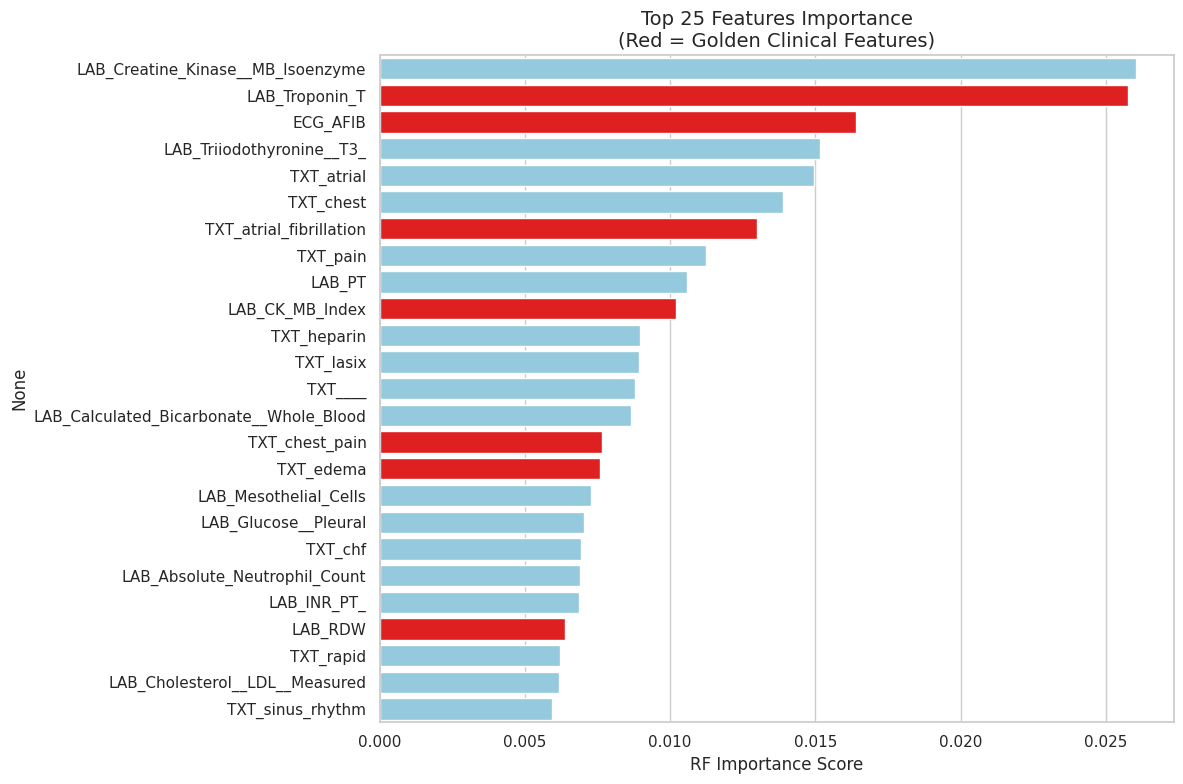


💾 Đã lưu danh sách features tại: /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_SELECTED_FEATURES_LIST.pkl

🔪 [SLICING] ĐANG CẮT DỮ LIỆU THEO DANH SÁCH ĐÃ CHỌN...
   -> Đã lưu X_MAIN_REFINED ((3679, 76))
   -> Đã lưu X_EXT_REFINED ((1082, 76))

🚀 HOÀN TẤT FEATURE SELECTION. SẴN SÀNG CHO MODELING!


In [ ]:
# @title BLOCK 6: PRIMARY FEATURE SELECTION (MACHINE LEARNING FILTRATION)
# =============================================================================
# CODE BLOCK 6: FEATURE SELECTION (RUN ON MAIN -> APPLY TO EXTERNAL)
# Objective: Identify the optimal feature set to classify Main Cardiac Groups vs. Other.
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import os
import pickle
import time
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder

# [INSTRUCTIONS]:
# 1. Download the MIMIC-IV-Ext-Cardiac-Disease and MIMIC-IV v3.1 from PhysioNet.
# 2. Upload them to your Google Drive.
# 3. Update the paths below to match your directory structure.

# 1. PATH CONFIGURATION
BASE_PATH_EXT = "/content/drive/MyDrive/MIMIC DATASET/mimic-iv-ext-cardiac-disease"
SAVE_DIR      = "/content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN"

# Read Master files from Block 5
PATH_MAIN_X = os.path.join(SAVE_DIR, "pipeline6_FINAL_X_MASTER_dataset_main.pkl")
PATH_MAIN_Y = os.path.join(SAVE_DIR, "pipeline6_FINAL_Y_MASTER_dataset_main.pkl")
PATH_EXT_X  = os.path.join(SAVE_DIR, "pipeline6_FINAL_X_MASTER_external_validate.pkl")
PATH_EXT_Y  = os.path.join(SAVE_DIR, "pipeline6_FINAL_Y_MASTER_external_validate.pkl")

# Output File (Selected Feature List)
PATH_SELECTED_FEATURES = os.path.join(SAVE_DIR, "pipeline6_SELECTED_FEATURES_LIST.pkl")

# Refined Data Output
PATH_FINAL_X_MAIN_REFINED = os.path.join(SAVE_DIR, "pipeline6_X_MAIN_REFINED.pkl")
PATH_FINAL_X_EXT_REFINED  = os.path.join(SAVE_DIR, "pipeline6_X_EXT_REFINED.pkl")

# =============================================================================
# "GOLDEN FEATURES" LIST (PROTECTED CLINICAL VARIABLES)
# =============================================================================
GOLDEN_FEATURES = [
    # Heart Failure (I50)
    'LAB_NTproBNP', 'ECHO_LVEF', 'TXT_edema', 'TXT_dyspnea', 'TXT_orthopnea',

    # Myocardial Infarction (I21)
    'LAB_Troponin_T', 'LAB_CK_MB_Index', 'ECG_ST_ELEV',
    'TXT_st_elevation', 'TXT_anterior', 'TXT_inferior', 'TXT_lateral', 'TXT_septal',

    # Inflammation / Pericardium (I30)
    # CRP is the most critical feature. I30 typically shows high CRP, while I34 is usually normal.
    # WBC & Neutrophils: Elevation suggests inflammation/infection in I30.
    # Sedimentation Rate: High in I30, similar to CRP.
    # Fevers/Chills: Suggestive of infection, supporting I30 while excluding I34.
    'LAB_White_Blood_Cells', 'LAB_C_Reactive_Protein',

    # Mới bổ sung thêm cho I30
    'LAB_Neutrophils', 'LAB_Sedimentation_Rate', 'TXT_fevers', 'TXT_chills',
    'LAB_Lactate_Dehydrogenase__LD_', 'LAB_Thyroid_Stimulating_Hormone',
    # Note: Hypothyroidism (TSH) is an often-overlooked cause of pericardial effusion (I30).
    # LDH is elevated in inflammatory fluids.

    # Valvular Heart Disease (I34)
    'TXT_s1', 'TXT_s2', 'TXT_s1_s2', 'TXT_abnormal',
    'TXT_atrial_fibrillation', 'TXT_dyspnea_exertion',
    # Note: Dyspnea on exertion is characteristic of heart failure due to mitral regurgitation (I34).

    # Arrhythmias (I44-I49)
    'LAB_Potassium', 'LAB_Magnesium', 'ECG_AFIB', 'TXT_tachycardia', 'TXT_bradycardia',
    'TXT_block', 'TXT_palpitations', 'TXT_rhythm', 'TXT_rate', 'ECG_SINUS',

    # Subjective Symptoms
    'TXT_chest_pain', 'TXT_cough',

    # DEMO
    'DEMO_AGE', 'DEMO_GENDER_MALE',


    # Recovered from previous pipeline iterations
    'LAB_Creatinine', 'LAB_Urea_Nitrogen', 'TXT_st_changes', 'TXT_weight',
    'LAB_RDW',
]

def log(message, level="INFO"):
    timestamp = datetime.now().strftime("%H:%M:%S")
    print(f"[{timestamp}] [{level:<5}] {message}")

# =============================================================================
# CLASS: CLINICAL FEATURE REFINER
# =============================================================================
class ClinicalFeatureRefiner:
    def __init__(self, path_X, path_y):
        log("Đang khởi tạo Feature Refiner...", "INIT")

        # 1. Load Data (Using MAIN set for feature selection)
        if os.path.exists(path_X) and os.path.exists(path_y):
            self.X = pd.read_pickle(path_X)
            self.y_raw = pd.read_pickle(path_y)
            log(f"✅ Đã load dữ liệu huấn luyện: {self.X.shape}", "LOAD")
        else:
            raise FileNotFoundError(f"❌ Không tìm thấy file tại: {path_X}")

        # 2. Check Golden Features
        self.existing_golden = [f for f in GOLDEN_FEATURES if f in self.X.columns]
        missing_golden = set(GOLDEN_FEATURES) - set(self.existing_golden)
        if missing_golden:
            log(f"⚠️ Cảnh báo: Thiếu các Golden Features sau: {missing_golden}", "WARN")
        else:
            log(f"✅ Đã tìm thấy đủ {len(self.existing_golden)} Golden Features.", "CHECK")

        # 3. Label Encoding
        self.le = LabelEncoder()
        self.y = self.le.fit_transform(self.y_raw)
        self.class_map = dict(zip(self.le.transform(self.le.classes_), self.le.classes_))

        # 4. Internal Train/Test Split (for selection evaluation)
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X, self.y, test_size=0.2, random_state=42, stratify=self.y
        )
        self.selected_features = list(self.X.columns)

    def evaluate(self, features, stage_name):
        if len(features) == 0: return 0

        # Fast XGBoost Configuration
        model = xgb.XGBClassifier(
            # 'multi:softprob': Required for multi-class to return probability matrix for AUC calculation.
            # 'mlogloss': Standard loss function for multi-class classification.
            # --- Performance Optimization ---
            # Using low n_estimators (50) and max_depth (4) for fast approximation during feature selection.
            objective='multi:softprob', num_class=len(self.le.classes_),
            eval_metric='mlogloss', n_estimators=50, max_depth=4,
            random_state=42, n_jobs=-1, verbosity=0
        )

        model.fit(self.X_train[features], self.y_train)
        y_pred = model.predict_proba(self.X_test[features])

        try:
          # Macro ROC-AUC handles imbalanced data better than Accuracy.
          # 'multi_class="ovr"': One-vs-Rest strategy.
          # 'average="macro"': Unweighted mean, treating minority classes with equal importance.
            auc = roc_auc_score(self.y_test, y_pred, multi_class='ovr', average='macro')
        except:
            # Fallback for edge cases (e.g., missing class in small split)
            auc = 0.0 # Fallback for edge cases (e.g., missing class in small split)

        log(f"Kết quả {stage_name}: {len(features):3d} features | Macro AUC: {auc:.4f}", "EVAL")
        return auc

    def run_pipeline(self):
        log("🚀 BẮT ĐẦU CHIẾN LƯỢC LỌC PHỄU (CÓ BẢO VỆ GOLDEN)...", "START")

        # --- LAYER 1: STATISTICAL FILTER ---
        log("--- LAYER 1: LOẠI BỎ BIẾN RÁC (CONSTANT/CORR) ---", "STEP")

        # Constant features (Variance = 0)
        variances = self.X_train.var()
        constant_features = variances[variances == 0].index.tolist()
        drop_1 = [f for f in constant_features if f not in self.existing_golden]

        current = [f for f in self.selected_features if f not in drop_1]
        log(f"Đã loại {len(drop_1)} biến hằng số.", "STAT")

        # High Correlation features (>0.95)
        corr_matrix = self.X_train[current].corr().abs()
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        high_corr = [column for column in upper.columns if any(upper[column] > 0.95)]
        drop_2 = [f for f in high_corr if f not in self.existing_golden]

        stat_features = [f for f in current if f not in drop_2]
        log(f"Đã loại {len(drop_2)} biến tương quan > 0.95.", "STAT")
        self.evaluate(stat_features, "Layer 1 Result")

        # --- LAYER 2: RANDOM FOREST IMPORTANCE ---
        log("--- LAYER 2: RANDOM FOREST RANKING ---", "STEP")
        rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
        rf.fit(self.X_train[stat_features], self.y_train)

        importances = pd.Series(rf.feature_importances_, index=stat_features)

        # Select Top 100 strongest features
        top_stats = importances.nlargest(100).index.tolist()

        # Force Golden Features
        layer2_features = list(set(top_stats) | set(self.existing_golden))

        log(f"Layer 2 chốt: {len(layer2_features)} features (Đã bảo vệ Golden).", "RF")
        self.evaluate(layer2_features, "Layer 2 Result")

        # --- LAYER 3: RFE (RECURSIVE ELIMINATION) ---
        log("--- LAYER 3: RFE (XGBOOST BASED) ---", "STEP")
        # Use XGBoost as the estimator for RFE
        estimator = xgb.XGBClassifier(objective='multi:softmax', num_class=len(self.le.classes_), n_estimators=50, n_jobs=-1, verbosity=0)

        # RFE to select Top 40 machine-learning-preferred features
        rfe = RFE(estimator=estimator, n_features_to_select=40, step=5)
        rfe.fit(self.X_train[layer2_features], self.y_train)

        rfe_selected = np.array(layer2_features)[rfe.support_].tolist()

        # DECISIVE STEP: FORCE INCLUDE GOLDEN FEATURES
        final_features = list(set(rfe_selected) | set(self.existing_golden))

        log(f"RFE chọn {len(rfe_selected)} features.", "RFE")
        log(f"FINAL LIST: {len(final_features)} features.", "FINAL")

        final_auc = self.evaluate(final_features, "FINAL RESULT")
        return final_features, importances

    def plot_results(self, importances, final_list, top_k=25):
        if len(final_list) == 0: return
        final_imps = importances[final_list].sort_values(ascending=False).head(top_k)

        plt.figure(figsize=(12, 8))
        colors = ['red' if x in GOLDEN_FEATURES else 'skyblue' for x in final_imps.index]
        sns.barplot(x=final_imps.values, y=final_imps.index, palette=colors)
        plt.title(f'Top {top_k} Features Importance\n(Red = Golden Clinical Features)', fontsize=14)
        plt.xlabel('RF Importance Score')
        plt.tight_layout()
        plt.show()

# =============================================================================
# MAIN EXECUTION
# =============================================================================
if __name__ == "__main__":
    if os.path.exists(PATH_MAIN_X):
        # 1. RUN FEATURE SELECTION ON MAIN SET
        refiner = ClinicalFeatureRefiner(PATH_MAIN_X, PATH_MAIN_Y)
        final_features, all_importances = refiner.run_pipeline()

        print("\n📋 DANH SÁCH FEATURE TINH (FINAL REFINED SET):")
        print("="*60)
        print(final_features)
        print("="*60)

        refiner.plot_results(all_importances, final_features)

        # 2. SAVE FEATURE LIST
        with open(PATH_SELECTED_FEATURES, 'wb') as f:
            pickle.dump(final_features, f)
        print(f"\n💾 Đã lưu danh sách features tại: {PATH_SELECTED_FEATURES}")

        # 3. APPLY SLICING
        print("\n🔪 [SLICING] ĐANG CẮT DỮ LIỆU THEO DANH SÁCH ĐÃ CHỌN...")

        # Slice Main set
        X_main = pd.read_pickle(PATH_MAIN_X)
        X_main_refined = X_main[final_features]
        X_main_refined.to_pickle(PATH_FINAL_X_MAIN_REFINED)
        print(f"   -> Đã lưu X_MAIN_REFINED ({X_main_refined.shape})")

        # Slice External set (CRITICAL: Must use the same list as Main)
        if os.path.exists(PATH_EXT_X):
            X_ext = pd.read_pickle(PATH_EXT_X)
            # Check for column availability (Fill 0 if missing)
            missing_cols = set(final_features) - set(X_ext.columns)
            if missing_cols:
                print(f"   ⚠️ External thiếu {len(missing_cols)} cột so với Main. Đang fill 0.")
                for c in missing_cols: X_ext[c] = 0

            X_ext_refined = X_ext[final_features]
            X_ext_refined.to_pickle(PATH_FINAL_X_EXT_REFINED)
            print(f"   -> Đã lưu X_EXT_REFINED ({X_ext_refined.shape})")

        print("\n🚀 HOÀN TẤT FEATURE SELECTION. SẴN SÀNG CHO MODELING!")

    else:
        print("❌ LỖI: Không tìm thấy file dữ liệu Main từ Ô 5.")

In [ ]:
# @title BLOCK 6: REFINED FEATURE SELECTION (AUDIT VERSION Q1)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import os
import pickle
import hashlib # Used for data fingerprinting (integrity check)
import logging # Standard logging library
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder

# =============================================================================
# 1. PATH CONFIGURATION & LOGGER SETUP
# =============================================================================
BASE_PATH_EXT = "/content/drive/MyDrive/MIMIC DATASET/mimic-iv-ext-cardiac-disease"
SAVE_DIR      = "/content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN"

# File Audit Output Paths
AUDIT_LOG_FILE = os.path.join(SAVE_DIR, "pipeline6_audit_execution_log.txt")
AUDIT_MATRIX_FILE = os.path.join(SAVE_DIR, "pipeline6_audit_feature_matrix.csv")

# Professional Logger Setup
def setup_logger(log_file):
    # Reset handlers if re-running in a notebook environment
    for handler in logging.root.handlers[:]:
        logging.root.removeHandler(handler)

    logging.basicConfig(
        level=logging.INFO,
        format="[%(asctime)s] [%(levelname)-5s] %(message)s",
        datefmt="%H:%M:%S",
        handlers=[
            logging.FileHandler(log_file, mode='w'), # Write to file
            logging.StreamHandler()                  # Output to console
        ]
    )
    return logging.getLogger()

logger = setup_logger(AUDIT_LOG_FILE)

def calculate_data_hash(df):
    """Tạo dấu vân tay MD5 cho dữ liệu để chứng minh tính toàn vẹn"""
    return hashlib.md5(pd.util.hash_pandas_object(df, index=True).values).hexdigest()

# (KEEPING GOLDEN_FEATURES LIST AS IS)
GOLDEN_FEATURES = [
    'LAB_NTproBNP', 'ECHO_LVEF', 'TXT_edema', 'TXT_dyspnea', 'TXT_orthopnea',
    'LAB_Troponin_T', 'LAB_CK_MB_Index', 'ECG_ST_ELEV', 'TXT_st_elevation',
    'TXT_anterior', 'TXT_inferior', 'TXT_lateral', 'TXT_septal',
    'LAB_White_Blood_Cells', 'LAB_C_Reactive_Protein', 'LAB_Neutrophils',
    'LAB_Sedimentation_Rate', 'TXT_fevers', 'TXT_chills',
    'LAB_Lactate_Dehydrogenase__LD_', 'LAB_Thyroid_Stimulating_Hormone',
    'TXT_s1', 'TXT_s2', 'TXT_s1_s2', 'TXT_abnormal', 'TXT_atrial_fibrillation',
    'TXT_dyspnea_exertion', 'LAB_Potassium', 'LAB_Magnesium', 'ECG_AFIB',
    'TXT_tachycardia', 'TXT_bradycardia', 'TXT_block', 'TXT_palpitations',
    'TXT_rhythm', 'TXT_rate', 'ECG_SINUS', 'TXT_chest_pain', 'TXT_cough',
    'DEMO_AGE', 'DEMO_GENDER_MALE', 'LAB_Creatinine', 'LAB_Urea_Nitrogen',
    'TXT_st_changes', 'TXT_weight', 'LAB_RDW'
]

# =============================================================================
# CLASS: AUDITABLE FEATURE REFINER (CSV MATRIX ENHANCED)
# =============================================================================
class ClinicalFeatureRefiner:
    def __init__(self, path_X, path_y):
        logger.info("="*60)
        logger.info("INIT: BẮT ĐẦU QUY TRÌNH CHỌN LỌC ĐẶC TRƯNG (MATRIX MODE)")
        logger.info("="*60)

        # Load Data
        self.X = pd.read_pickle(path_X)
        self.y_raw = pd.read_pickle(path_y)
        self.data_hash = calculate_data_hash(self.X)

        # Check Golden
        self.existing_golden = [f for f in GOLDEN_FEATURES if f in self.X.columns]

        # Encode Label
        self.le = LabelEncoder()
        self.y = self.le.fit_transform(self.y_raw)

        # Split Train/Test
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X, self.y, test_size=0.2, random_state=42, stratify=self.y
        )

        # --- INITIALIZE DETAILED AUDIT DATAFRAME ---
        self.audit_df = pd.DataFrame(index=self.X.columns)

        # 1. Feature Categorization
        self.audit_df['Category'] = self.audit_df.index.map(lambda x: x.split('_')[0] if '_' in x else 'OTHER')

        # 2. Mark Golden Features
        self.audit_df['Is_Golden'] = self.audit_df.index.isin(self.existing_golden)

        # 3. Default Status Columns
        self.audit_df['L1_Stat_Status'] = 'PENDING'
        self.audit_df['L2_RF_Score'] = 0.0000
        self.audit_df['L2_RF_Rank'] = 9999
        self.audit_df['L2_RF_Status'] = 'PENDING'
        self.audit_df['L3_RFE_Selected'] = 'PENDING'
        self.audit_df['FINAL_DECISION'] = 'PENDING'
        self.audit_df['Note'] = ''

    def evaluate(self, features, stage_name):
        if len(features) == 0: return 0
        # Fast XGBoost configuration for rapid evaluation
        model = xgb.XGBClassifier(
            objective='multi:softprob', num_class=len(self.le.classes_),
            eval_metric='mlogloss', n_estimators=50, max_depth=4,
            random_state=42, n_jobs=-1, verbosity=0
        )
        model.fit(self.X_train[features], self.y_train)
        y_pred = model.predict_proba(self.X_test[features])
        try:
            auc = roc_auc_score(self.y_test, y_pred, multi_class='ovr', average='macro')
        except:
            auc = 0.0
        logger.info(f"EVAL [{stage_name}]: {len(features):3d} features | Macro AUC: {auc:.4f}")
        return auc

    def run_pipeline(self):
        # ================= LAYER 1: STATISTICAL =================
        logger.info("--- LAYER 1: STATISTICAL FILTER ---")

        # 1.1 Variance check
        variances = self.X_train.var()
        constant_feats = variances[variances == 0].index.tolist()
        drop_var = [f for f in constant_feats if f not in self.existing_golden]

        # 1.2 Correlation check
        remaining_1 = [f for f in self.X.columns if f not in drop_var]
        corr_matrix = self.X_train[remaining_1].corr().abs()
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        high_corr = [column for column in upper.columns if any(upper[column] > 0.95)]
        drop_corr = [f for f in high_corr if f not in self.existing_golden]

        # Update Audit Layer 1 (Default: PASS)
        self.audit_df['L1_Stat_Status'] = 'PASS'
        # Set FAIL for Constant Variance
        self.audit_df.loc[drop_var, 'L1_Stat_Status'] = 'FAIL: Constant'
        # Set FAIL for High Correlation
        self.audit_df.loc[drop_corr, 'L1_Stat_Status'] = 'FAIL: High Corr'

        # Layer 1 survivors
        features_L1 = self.audit_df[self.audit_df['L1_Stat_Status'] == 'PASS'].index.tolist()
        self.evaluate(features_L1, "Layer 1")

        # ================= LAYER 2: RANDOM FOREST =================
        logger.info("--- LAYER 2: RANDOM FOREST IMPORTANCE ---")

        # Set SKIPPED status for L1 failures
        self.audit_df.loc[~self.audit_df.index.isin(features_L1), 'L2_RF_Status'] = 'SKIPPED (Fail L1)'
        self.audit_df.loc[~self.audit_df.index.isin(features_L1), 'L3_RFE_Selected'] = 'SKIPPED (Fail L1)'

        # Run RF on features_L1
        rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
        rf.fit(self.X_train[features_L1], self.y_train)

        # Retrieve Importance
        imps = pd.Series(rf.feature_importances_, index=features_L1)

        # Store Score and Rank in Audit Matrix
        self.audit_df.loc[features_L1, 'L2_RF_Score'] = imps.values
        # Rank: 1 is highest
        self.audit_df.loc[features_L1, 'L2_RF_Rank'] = imps.rank(ascending=False)

        # Select Top 100
        top_stats = imps.nlargest(100).index.tolist()
        features_L2 = list(set(top_stats) | set(self.existing_golden))

        # Update Audit Layer 2
        # Features in L1 but not making it to L2 are marked as FAIL
        drop_rf = list(set(features_L1) - set(features_L2))

        self.audit_df.loc[features_L2, 'L2_RF_Status'] = 'PASS'
        self.audit_df.loc[drop_rf, 'L2_RF_Status'] = 'FAIL: Low Importance'

        self.evaluate(features_L2, "Layer 2")

        # ================= LAYER 3: RFE (XGBOOST) =================
        logger.info("--- LAYER 3: RFE (XGBOOST) ---")

        # Set SKIPPED for L2 failures
        self.audit_df.loc[drop_rf, 'L3_RFE_Selected'] = 'SKIPPED (Fail L2)'

        estimator = xgb.XGBClassifier(objective='multi:softmax', num_class=len(self.le.classes_), n_estimators=50, n_jobs=-1, verbosity=0)
        rfe = RFE(estimator=estimator, n_features_to_select=40, step=5)
        rfe.fit(self.X_train[features_L2], self.y_train)

        rfe_selected = np.array(features_L2)[rfe.support_].tolist()
        final_features = list(set(rfe_selected) | set(self.existing_golden))

        # Update Audit Layer 3
        # Mark if selected by Machine (RFE) or protected by Golden rule
        rfe_true_support = np.array(features_L2)[rfe.support_].tolist()

        for f in features_L2:
            if f in rfe_true_support:
                self.audit_df.at[f, 'L3_RFE_Selected'] = 'TRUE (Machine Pick)'
            elif f in self.existing_golden:
                 self.audit_df.at[f, 'L3_RFE_Selected'] = 'FALSE (But Golden Keep)'
            else:
                 self.audit_df.at[f, 'L3_RFE_Selected'] = 'FALSE'

        # ================= FINAL DECISION =================
        self.audit_df['FINAL_DECISION'] = 'DROPPED' # Mặc định drop hết
        self.audit_df.loc[final_features, 'FINAL_DECISION'] = 'SELECTED'

        # Add notes for Golden features rescued by the pipeline
        rescued_golden = [f for f in final_features if f not in rfe_selected]
        self.audit_df.loc[rescued_golden, 'Note'] = 'Golden Rescue'

        logger.info(f"FINAL RESULT: Selected {len(final_features)} features.")
        self.evaluate(final_features, "FINAL")

        return final_features

    def save_audit_files(self):
        # Sort matrix: Selected features first, then by RF Importance
        audit_sorted = self.audit_df.sort_values(by=['FINAL_DECISION', 'L2_RF_Score'], ascending=[False, False])

        audit_sorted.to_csv(AUDIT_MATRIX_FILE)
        logger.info(f"AUDIT: Đã lưu bảng MATRIX tại {AUDIT_MATRIX_FILE}")
        logger.info(f"AUDIT: Đã lưu LOG tại {AUDIT_LOG_FILE}")

        # Display top 5 rows for verification
        print("\nDEMO AUDIT MATRIX (Top 5):")
        print(audit_sorted[['Category', 'Is_Golden', 'L2_RF_Rank', 'FINAL_DECISION']].head())

if __name__ == "__main__":
    refiner = ClinicalFeatureRefiner(os.path.join(SAVE_DIR, "pipeline6_FINAL_X_MASTER_dataset_main.pkl"),
                                     os.path.join(SAVE_DIR, "pipeline6_FINAL_Y_MASTER_dataset_main.pkl"))
    final_features = refiner.run_pipeline()
    refiner.save_audit_files()

    # Display Top 5 demo
    PATH_SELECTED_FEATURES = os.path.join(SAVE_DIR, "pipeline6_SELECTED_FEATURES_LIST.pkl")
    with open(PATH_SELECTED_FEATURES, 'wb') as f:
        pickle.dump(final_features, f)

[14:50:27] [INFO ] ============================================================
[14:50:27] [INFO ] INIT: BẮT ĐẦU QUY TRÌNH CHỌN LỌC ĐẶC TRƯNG (MATRIX MODE)
[14:50:27] [INFO ] ============================================================
[14:50:27] [INFO ] --- LAYER 1: STATISTICAL FILTER ---
[14:50:40] [INFO ] EVAL [Layer 1]: 503 features | Macro AUC: 0.9537
[14:50:40] [INFO ] --- LAYER 2: RANDOM FOREST IMPORTANCE ---
[14:50:44] [INFO ] EVAL [Layer 2]: 129 features | Macro AUC: 0.9540
[14:50:44] [INFO ] --- LAYER 3: RFE (XGBOOST) ---
[14:51:41] [INFO ] FINAL RESULT: Selected 76 features.
[14:51:42] [INFO ] EVAL [FINAL]:  76 features | Macro AUC: 0.9492
[14:51:42] [INFO ] AUDIT: Đã lưu bảng MATRIX tại /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_audit_feature_matrix.csv
[14:51:42] [INFO ] AUDIT: Đã lưu LOG tại /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_audit_execution_log.txt



DEMO AUDIT MATRIX (Top 5):
                                  Category  Is_Golden  L2_RF_Rank  \
LAB_Creatine_Kinase__MB_Isoenzyme      LAB      False         1.0   
LAB_Troponin_T                         LAB       True         2.0   
ECG_AFIB                               ECG       True         5.0   
LAB_Triiodothyronine__T3_              LAB      False         6.0   
TXT_atrial                             TXT      False         7.0   

                                  FINAL_DECISION  
LAB_Creatine_Kinase__MB_Isoenzyme       SELECTED  
LAB_Troponin_T                          SELECTED  
ECG_AFIB                                SELECTED  
LAB_Triiodothyronine__T3_               SELECTED  
TXT_atrial                              SELECTED  


In [ ]:
# @title BLOCK 6: REFINED FEATURE SELECTION (PREMIUM EXCEL AUDIT VERSION)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import os
import pickle
import hashlib # Used for data fingerprinting
import logging # Standard logging library
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder

# =============================================================================
# 1. PATH CONFIGURATION & LOGGER SETUP
# =============================================================================
BASE_PATH_EXT = "/content/drive/MyDrive/MIMIC DATASET/mimic-iv-ext-cardiac-disease"
SAVE_DIR      = "/content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN"

# Audit Execution Log
AUDIT_LOG_FILE = os.path.join(SAVE_DIR, "pipeline6_audit_execution_log.txt")

# Audit Matrix Output (Premium Excel format)
AUDIT_MATRIX_FILE = os.path.join(SAVE_DIR, "pipeline6_audit_feature_matrix.xlsx")

# Professional Logger Configuration
def setup_logger(log_file):
    # Reset handlers if running multiple times
    for handler in logging.root.handlers[:]:
        logging.root.removeHandler(handler)

    logging.basicConfig(
        level=logging.INFO,
        format="[%(asctime)s] [%(levelname)-5s] %(message)s",
        datefmt="%H:%M:%S",
        handlers=[
            logging.FileHandler(log_file, mode='w'), # Ghi vào file
            logging.StreamHandler()                  # In ra màn hình
        ]
    )
    return logging.getLogger()

logger = setup_logger(AUDIT_LOG_FILE)

def calculate_data_hash(df):
    """Generates MD5 fingerprint for data to ensure integrity (Audit Trail)"""
    return hashlib.md5(pd.util.hash_pandas_object(df, index=True).values).hexdigest()

# (GOLDEN_FEATURES LIST - PROTECTED CLINICAL VARIABLES)
GOLDEN_FEATURES = [
    'LAB_NTproBNP', 'ECHO_LVEF', 'TXT_edema', 'TXT_dyspnea', 'TXT_orthopnea',
    'LAB_Troponin_T', 'LAB_CK_MB_Index', 'ECG_ST_ELEV', 'TXT_st_elevation',
    'TXT_anterior', 'TXT_inferior', 'TXT_lateral', 'TXT_septal',
    'LAB_White_Blood_Cells', 'LAB_C_Reactive_Protein', 'LAB_Neutrophils',
    'LAB_Sedimentation_Rate', 'TXT_fevers', 'TXT_chills',
    'LAB_Lactate_Dehydrogenase__LD_', 'LAB_Thyroid_Stimulating_Hormone',
    'TXT_s1', 'TXT_s2', 'TXT_s1_s2', 'TXT_abnormal', 'TXT_atrial_fibrillation',
    'TXT_dyspnea_exertion', 'LAB_Potassium', 'LAB_Magnesium', 'ECG_AFIB',
    'TXT_tachycardia', 'TXT_bradycardia', 'TXT_block', 'TXT_palpitations',
    'TXT_rhythm', 'TXT_rate', 'ECG_SINUS', 'TXT_chest_pain', 'TXT_cough',
    'DEMO_AGE', 'DEMO_GENDER_MALE', 'LAB_Creatinine', 'LAB_Urea_Nitrogen',
    'TXT_st_changes', 'TXT_weight', 'LAB_RDW'
]

# =============================================================================
# CLASS: AUDITABLE FEATURE REFINER (EXCEL ENHANCED)
# =============================================================================
class ClinicalFeatureRefiner:
    def __init__(self, path_X, path_y):
        logger.info("="*60)
        logger.info("INIT: BẮT ĐẦU QUY TRÌNH CHỌN LỌC ĐẶC TRƯNG (EXCEL AUDIT MODE)")
        logger.info("="*60)

        # Load Data
        self.X = pd.read_pickle(path_X)
        self.y_raw = pd.read_pickle(path_y)
        self.data_hash = calculate_data_hash(self.X)

        # Check Golden
        self.existing_golden = [f for f in GOLDEN_FEATURES if f in self.X.columns]

        # Encode Label
        self.le = LabelEncoder()
        self.y = self.le.fit_transform(self.y_raw)

        # Split Train/Test
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X, self.y, test_size=0.2, random_state=42, stratify=self.y
        )

        # --- INITIALIZE DETAILED AUDIT DATAFRAME ---
        self.audit_df = pd.DataFrame(index=self.X.columns)

        # 1. Feature Categorization
        self.audit_df['Category'] = self.audit_df.index.map(lambda x: x.split('_')[0] if '_' in x else 'OTHER')

        # 2. Mark Golden Status
        self.audit_df['Is_Golden'] = self.audit_df.index.isin(self.existing_golden)

        # 3. Default Status Columns
        self.audit_df['L1_Stat_Status'] = 'PENDING'
        self.audit_df['L2_RF_Score'] = 0.0000
        self.audit_df['L2_RF_Rank'] = 9999
        self.audit_df['L2_RF_Status'] = 'PENDING'
        self.audit_df['L3_RFE_Selected'] = 'PENDING'
        self.audit_df['FINAL_DECISION'] = 'PENDING'
        self.audit_df['Note'] = '' # Ghi chú thêm nếu cần

    def evaluate(self, features, stage_name):
        if len(features) == 0: return 0
        # Fast XGBoost configuration for rapid evaluation
        model = xgb.XGBClassifier(
            objective='multi:softprob', num_class=len(self.le.classes_),
            eval_metric='mlogloss', n_estimators=50, max_depth=4,
            random_state=42, n_jobs=-1, verbosity=0
        )
        model.fit(self.X_train[features], self.y_train)
        y_pred = model.predict_proba(self.X_test[features])
        try:
            auc = roc_auc_score(self.y_test, y_pred, multi_class='ovr', average='macro')
        except:
            auc = 0.0
        logger.info(f"EVAL [{stage_name}]: {len(features):3d} features | Macro AUC: {auc:.4f}")
        return auc

    def run_pipeline(self):
        # ================= LAYER 1: STATISTICAL =================
        logger.info("--- LAYER 1: STATISTICAL FILTER ---")

        # 1.1 Variance check
        variances = self.X_train.var()
        constant_feats = variances[variances == 0].index.tolist()
        drop_var = [f for f in constant_feats if f not in self.existing_golden]

        # 1.2 Correlation check
        remaining_1 = [f for f in self.X.columns if f not in drop_var]
        corr_matrix = self.X_train[remaining_1].corr().abs()
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        high_corr = [column for column in upper.columns if any(upper[column] > 0.95)]
        drop_corr = [f for f in high_corr if f not in self.existing_golden]

        # Update Audit Matrix: Layer 1
        self.audit_df['L1_Stat_Status'] = 'PASS'
        self.audit_df.loc[drop_var, 'L1_Stat_Status'] = 'FAIL: Constant'
        self.audit_df.loc[drop_corr, 'L1_Stat_Status'] = 'FAIL: High Corr'

        features_L1 = self.audit_df[self.audit_df['L1_Stat_Status'] == 'PASS'].index.tolist()
        self.evaluate(features_L1, "Layer 1")

        # ================= LAYER 2: RANDOM FOREST =================
        logger.info("--- LAYER 2: RANDOM FOREST IMPORTANCE ---")

        self.audit_df.loc[~self.audit_df.index.isin(features_L1), 'L2_RF_Status'] = 'SKIPPED (Fail L1)'
        self.audit_df.loc[~self.audit_df.index.isin(features_L1), 'L3_RFE_Selected'] = 'SKIPPED (Fail L1)'

        rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
        rf.fit(self.X_train[features_L1], self.y_train)

        imps = pd.Series(rf.feature_importances_, index=features_L1)
        self.audit_df.loc[features_L1, 'L2_RF_Score'] = imps.values
        self.audit_df.loc[features_L1, 'L2_RF_Rank'] = imps.rank(ascending=False)

        top_stats = imps.nlargest(100).index.tolist()
        features_L2 = list(set(top_stats) | set(self.existing_golden))

        drop_rf = list(set(features_L1) - set(features_L2))
        self.audit_df.loc[features_L2, 'L2_RF_Status'] = 'PASS'
        self.audit_df.loc[drop_rf, 'L2_RF_Status'] = 'FAIL: Low Importance'

        self.evaluate(features_L2, "Layer 2")

        # ================= LAYER 3: RFE (XGBOOST) =================
        logger.info("--- LAYER 3: RFE (XGBOOST) ---")
        self.audit_df.loc[drop_rf, 'L3_RFE_Selected'] = 'SKIPPED (Fail L2)'

        estimator = xgb.XGBClassifier(objective='multi:softmax', num_class=len(self.le.classes_), n_estimators=50, n_jobs=-1, verbosity=0)
        rfe = RFE(estimator=estimator, n_features_to_select=40, step=5)
        rfe.fit(self.X_train[features_L2], self.y_train)

        rfe_selected = np.array(features_L2)[rfe.support_].tolist()
        final_features = list(set(rfe_selected) | set(self.existing_golden))

        rfe_true_support = np.array(features_L2)[rfe.support_].tolist()
        for f in features_L2:
            if f in rfe_true_support:
                self.audit_df.at[f, 'L3_RFE_Selected'] = 'TRUE (Machine Pick)'
            elif f in self.existing_golden:
                 self.audit_df.at[f, 'L3_RFE_Selected'] = 'FALSE (But Golden Keep)'
            else:
                 self.audit_df.at[f, 'L3_RFE_Selected'] = 'FALSE'

        # ================= FINAL DECISION =================
        self.audit_df['FINAL_DECISION'] = 'DROPPED'
        self.audit_df.loc[final_features, 'FINAL_DECISION'] = 'SELECTED'
        rescued_golden = [f for f in final_features if f not in rfe_selected]
        self.audit_df.loc[rescued_golden, 'Note'] = 'Golden Rescue'

        logger.info(f"FINAL RESULT: Selected {len(final_features)} features.")
        self.evaluate(final_features, "FINAL")

        return final_features

    def save_audit_files(self):
        # 1. Organize Column Order
        cols = ['Category', 'Is_Golden', 'FINAL_DECISION', 'Note',
                'L1_Stat_Status', 'L2_RF_Status', 'L2_RF_Score', 'L2_RF_Rank', 'L3_RFE_Selected']
        remaining_cols = [c for c in self.audit_df.columns if c not in cols]
        audit_sorted = self.audit_df[cols + remaining_cols].sort_values(
            by=['FINAL_DECISION', 'L2_RF_Score'],
            ascending=[False, False]
        )

        # 2. Export to Excel with formatting
        try:
            import xlsxwriter
        except ImportError:
            os.system('pip install xlsxwriter')
            import xlsxwriter

        logger.info(f"AUDIT: Đang xuất file Excel định dạng cao cấp tại {AUDIT_MATRIX_FILE}...")

        with pd.ExcelWriter(AUDIT_MATRIX_FILE, engine='xlsxwriter') as writer:
            sheet_name = 'Feature_Audit_Trail'
            audit_sorted.to_excel(writer, sheet_name=sheet_name)

            workbook = writer.book
            worksheet = writer.sheets[sheet_name]

            # FORMATTING
            header_fmt = workbook.add_format({'bold': True, 'text_wrap': True, 'valign': 'top', 'fg_color': '#D7E4BC', 'border': 1})
            selected_fmt = workbook.add_format({'bg_color': '#C6EFCE', 'font_color': '#006100'})
            golden_fmt = workbook.add_format({'bold': True, 'font_color': '#9C0006'})
            note_fmt = workbook.add_format({'bg_color': '#FFEB9C', 'font_color': '#9C5700'})

            (max_row, max_col) = audit_sorted.shape

            # Auto-width
            for i, column in enumerate(audit_sorted.columns):
                column_len = max(audit_sorted[column].astype(str).map(len).max(), len(column)) + 2
                worksheet.set_column(i + 1, i + 1, min(column_len, 50))
            worksheet.set_column(0, 0, 30)

            for col_num, value in enumerate(audit_sorted.columns.values):
                worksheet.write(0, col_num + 1, value, header_fmt)

            data_range = f"A2:J{max_row+1}"
            worksheet.conditional_format(data_range, {'type': 'formula', 'criteria': '=$D2="SELECTED"', 'format': selected_fmt})
            worksheet.conditional_format(data_range, {'type': 'formula', 'criteria': '=$C2=TRUE', 'format': golden_fmt})
            worksheet.conditional_format(f"E2:E{max_row+1}", {'type': 'no_blanks', 'format': note_fmt})
            worksheet.freeze_panes(1, 1)

        logger.info(f"AUDIT: ✅ Đã lưu file Excel thành công! Reviewer có thể mở xem ngay.")
        logger.info(f"AUDIT: Đã lưu LOG txt tại {AUDIT_LOG_FILE}")

if __name__ == "__main__":
    refiner = ClinicalFeatureRefiner(os.path.join(SAVE_DIR, "pipeline6_FINAL_X_MASTER_dataset_main.pkl"),
                                     os.path.join(SAVE_DIR, "pipeline6_FINAL_Y_MASTER_dataset_main.pkl"))
    final_features = refiner.run_pipeline()
    refiner.save_audit_files()

    # Save Feature List (Old format)
    PATH_SELECTED_FEATURES = os.path.join(SAVE_DIR, "pipeline6_SELECTED_FEATURES_LIST.pkl")
    with open(PATH_SELECTED_FEATURES, 'wb') as f:
        pickle.dump(final_features, f)

[14:53:44] [INFO ] ============================================================
[14:53:44] [INFO ] INIT: BẮT ĐẦU QUY TRÌNH CHỌN LỌC ĐẶC TRƯNG (EXCEL AUDIT MODE)
[14:53:44] [INFO ] ============================================================
[14:53:44] [INFO ] --- LAYER 1: STATISTICAL FILTER ---
[14:53:57] [INFO ] EVAL [Layer 1]: 503 features | Macro AUC: 0.9537
[14:53:57] [INFO ] --- LAYER 2: RANDOM FOREST IMPORTANCE ---
[14:54:01] [INFO ] EVAL [Layer 2]: 129 features | Macro AUC: 0.9540
[14:54:01] [INFO ] --- LAYER 3: RFE (XGBOOST) ---
[14:54:59] [INFO ] FINAL RESULT: Selected 76 features.
[14:55:00] [INFO ] EVAL [FINAL]:  76 features | Macro AUC: 0.9492
[14:55:04] [INFO ] AUDIT: Đang xuất file Excel định dạng cao cấp tại /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_audit_feature_matrix.xlsx...
[14:55:05] [INFO ] AUDIT: ✅ Đã lưu file Excel thành công! Reviewer có thể mở xem ngay.
[14:55:05] [INFO ] AUDIT: Đã lưu LOG txt tại /content/drive/MyDrive/MIMIC DATASET/READY_T

In [ ]:
# @title BLOCK 6: REFINED FEATURE SELECTION (FINAL AUDIT VERSION)
# =============================================================================
# DESCRIPTION:
# 3-Layer Hybrid Feature Selection Pipeline.
# Output:
# 1. .pkl file containing the final feature list.
# 2. .txt detailed execution log.
# 3. .xlsx (Excel) Audit Matrix: Detailed explanation for selecting/dropping each variable.
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import os
import pickle
import hashlib
import logging
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder

# =============================================================================
# 1. PATH CONFIGURATION & LOGGER SETUP
# =============================================================================
BASE_PATH_EXT = "/content/drive/MyDrive/MIMIC DATASET/mimic-iv-ext-cardiac-disease"
SAVE_DIR      = "/content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN"

# Output Files
AUDIT_LOG_FILE    = os.path.join(SAVE_DIR, "pipeline6_audit_execution_log.txt")
AUDIT_MATRIX_FILE = os.path.join(SAVE_DIR, "pipeline6_audit_feature_matrix.xlsx")
PATH_SELECTED_FEATURES = os.path.join(SAVE_DIR, "pipeline6_SELECTED_FEATURES_LIST.pkl")

# Professional Logger Setup
def setup_logger(log_file):
    # Reset handlers to avoid duplicate logs if re-run multiple times
    for handler in logging.root.handlers[:]:
        logging.root.removeHandler(handler)

    logging.basicConfig(
        level=logging.INFO,
        format="[%(asctime)s] [%(levelname)-5s] %(message)s",
        datefmt="%H:%M:%S",
        handlers=[
            logging.FileHandler(log_file, mode='w', encoding='utf-8'),
            logging.StreamHandler()
        ]
    )
    return logging.getLogger()

logger = setup_logger(AUDIT_LOG_FILE)

def calculate_data_hash(df):
    """Generates MD5 fingerprint for data to ensure Data Integrity"""
    return hashlib.md5(pd.util.hash_pandas_object(df, index=True).values).hexdigest()

# =============================================================================
# "GOLDEN FEATURES" LIST (PROTECTED CLINICAL VARIABLES)
# =============================================================================
GOLDEN_FEATURES = [
    # Heart Failure (I50)
    'LAB_NTproBNP', 'ECHO_LVEF', 'TXT_edema', 'TXT_dyspnea', 'TXT_orthopnea',
    # Myocardial Infarction (I21)
    'LAB_Troponin_T', 'LAB_CK_MB_Index', 'ECG_ST_ELEV',
    'TXT_st_elevation', 'TXT_anterior', 'TXT_inferior', 'TXT_lateral', 'TXT_septal',
    # Inflammation / Pericardial (I30)
    'LAB_White_Blood_Cells', 'LAB_C_Reactive_Protein', 'LAB_Neutrophils',
    'LAB_Sedimentation_Rate', 'TXT_fevers', 'TXT_chills',
    'LAB_Lactate_Dehydrogenase__LD_', 'LAB_Thyroid_Stimulating_Hormone',
    # Valvular Heart Disease (I34)
    'TXT_s1', 'TXT_s2', 'TXT_s1_s2', 'TXT_abnormal',
    'TXT_atrial_fibrillation', 'TXT_dyspnea_exertion',
    # Arrhythmias (I44)
    'LAB_Potassium', 'LAB_Magnesium', 'ECG_AFIB', 'TXT_tachycardia', 'TXT_bradycardia',
    'TXT_block', 'TXT_palpitations', 'TXT_rhythm', 'TXT_rate', 'ECG_SINUS',
    # Subjective Symptoms
    'TXT_chest_pain', 'TXT_cough',
    # DEMO
    'DEMO_AGE', 'DEMO_GENDER_MALE',
    # RECOVERY FROM PREVIOUS PIPELINES
    'LAB_Creatinine', 'LAB_Urea_Nitrogen', 'TXT_st_changes', 'TXT_weight',
    'LAB_RDW'
]

# =============================================================================
# CLASS: AUDITABLE FEATURE REFINER
# =============================================================================
class ClinicalFeatureRefiner:
    def __init__(self, path_X, path_y):
        logger.info("="*60)
        logger.info("INIT: BẮT ĐẦU QUY TRÌNH CHỌN LỌC ĐẶC TRƯNG (FULL AUDIT MODE)")
        logger.info("="*60)

        # 1. Data Loading
        if os.path.exists(path_X) and os.path.exists(path_y):
            self.X = pd.read_pickle(path_X)
            self.y_raw = pd.read_pickle(path_y)
        else:
            raise FileNotFoundError(f"❌ Không tìm thấy file dữ liệu tại: {SAVE_DIR}")

        # 2. Audit Checksum
        self.data_hash = calculate_data_hash(self.X)
        logger.info(f"DATA INTEGRITY CHECK: Input Data Hash (MD5): {self.data_hash}")
        logger.info(f"DATA SHAPE: {self.X.shape}")

        # 3. Check Golden Features
        self.existing_golden = [f for f in GOLDEN_FEATURES if f in self.X.columns]
        missing_golden = set(GOLDEN_FEATURES) - set(self.existing_golden)
        if missing_golden:
            logger.warning(f"⚠️ Missing Golden Features: {missing_golden}")

        # 4. Label Encoding
        self.le = LabelEncoder()
        self.y = self.le.fit_transform(self.y_raw)

        # 5. Split Train/Test (Internal Validation)
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X, self.y, test_size=0.2, random_state=42, stratify=self.y
        )
        logger.info(f"SPLIT CONFIG: Train={self.X_train.shape[0]}, Test={self.X_test.shape[0]}")

        # 6. INITIALIZE AUDIT DATAFRAME
        self.audit_df = pd.DataFrame(index=self.X.columns)
        self.audit_df['Category'] = self.audit_df.index.map(lambda x: x.split('_')[0] if '_' in x else 'OTHER')
        self.audit_df['Is_Golden'] = self.audit_df.index.isin(self.existing_golden)

        # Status Columns
        self.audit_df['L1_Stat_Status'] = 'PENDING'
        self.audit_df['L2_RF_Score'] = 0.0000
        self.audit_df['L2_RF_Rank'] = 9999
        self.audit_df['L2_RF_Status'] = 'PENDING'

        # RFE Explanation Columns
        self.audit_df['L3_RFE_Rank'] = 9999
        self.audit_df['L3_RFE_Score'] = 0.0
        self.audit_df['L3_RFE_Explanation'] = 'PENDING'

        self.audit_df['FINAL_DECISION'] = 'PENDING'
        self.audit_df['Note'] = ''

    def evaluate(self, features, stage_name):
        """Fast performance evaluation of the feature set on internal Test set"""
        if len(features) == 0: return 0

        # Fast XGBoost Configuration
        model = xgb.XGBClassifier(
            objective='multi:softprob', num_class=len(self.le.classes_),
            eval_metric='mlogloss', n_estimators=50, max_depth=4,
            random_state=42, n_jobs=-1, verbosity=0
        )
        model.fit(self.X_train[features], self.y_train)
        y_pred = model.predict_proba(self.X_test[features])

        try:
            auc = roc_auc_score(self.y_test, y_pred, multi_class='ovr', average='macro')
        except:
            auc = 0.0

        logger.info(f"EVAL [{stage_name}]: {len(features):3d} features | Macro AUC: {auc:.4f}")
        return auc

    def run_pipeline(self):
        logger.info("🚀 STARTING HYBRID FEATURE SELECTION PIPELINE...")

        # ================= LAYER 1: STATISTICAL FILTER =================
        logger.info("--- LAYER 1: STATISTICAL FILTER (Variance & Correlation) ---")

        # 1.1 Variance check (Exclude constant variables)
        variances = self.X_train.var()
        constant_feats = variances[variances == 0].index.tolist()
        drop_var = [f for f in constant_feats if f not in self.existing_golden]

        # 1.2 Correlation check (Exclude high correlation variables > 0.95)
        remaining_1 = [f for f in self.X.columns if f not in drop_var]
        corr_matrix = self.X_train[remaining_1].corr().abs()
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        high_corr = [column for column in upper.columns if any(upper[column] > 0.95)]
        drop_corr = [f for f in high_corr if f not in self.existing_golden]

        # Update Audit
        self.audit_df['L1_Stat_Status'] = 'PASS'
        self.audit_df.loc[drop_var, 'L1_Stat_Status'] = 'FAIL: Constant'
        self.audit_df.loc[drop_corr, 'L1_Stat_Status'] = 'FAIL: High Corr'

        features_L1 = self.audit_df[self.audit_df['L1_Stat_Status'] == 'PASS'].index.tolist()
        logger.info(f"Layer 1 removed {len(drop_var) + len(drop_corr)} features.")
        self.evaluate(features_L1, "Layer 1")

        # ================= LAYER 2: RANDOM FOREST RANKING =================
        logger.info("--- LAYER 2: RANDOM FOREST IMPORTANCE ---")

        # Mark skipped features
        self.audit_df.loc[~self.audit_df.index.isin(features_L1), 'L2_RF_Status'] = 'SKIPPED (Fail L1)'
        self.audit_df.loc[~self.audit_df.index.isin(features_L1), 'L3_RFE_Explanation'] = 'SKIPPED (Fail L1)'

        # Run RF
        rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
        rf.fit(self.X_train[features_L1], self.y_train)

        # Get Importance
        imps = pd.Series(rf.feature_importances_, index=features_L1)
        self.audit_df.loc[features_L1, 'L2_RF_Score'] = imps.values
        self.audit_df.loc[features_L1, 'L2_RF_Rank'] = imps.rank(ascending=False)

        # Select Top 100 + Golden
        top_stats = imps.nlargest(100).index.tolist()
        features_L2 = list(set(top_stats) | set(self.existing_golden))

        # Update Audit
        drop_rf = list(set(features_L1) - set(features_L2))
        self.audit_df.loc[features_L2, 'L2_RF_Status'] = 'PASS'
        self.audit_df.loc[drop_rf, 'L2_RF_Status'] = 'FAIL: Low Importance'

        logger.info(f"Layer 2 selected {len(features_L2)} features (Top 100 + Golden).")
        self.evaluate(features_L2, "Layer 2")

        # ================= LAYER 3: RFE (XGBOOST) =================
        logger.info("--- LAYER 3: RFE (Recursive Feature Elimination) ---")
        self.audit_df.loc[drop_rf, 'L3_RFE_Explanation'] = 'SKIPPED (Fail L2)'

        estimator = xgb.XGBClassifier(objective='multi:softmax', num_class=len(self.le.classes_), n_estimators=50, n_jobs=-1, verbosity=0)

        # Run RFE to select Top 40
        N_SELECT = 40
        rfe = RFE(estimator=estimator, n_features_to_select=N_SELECT, step=5)
        rfe.fit(self.X_train[features_L2], self.y_train)

        # --- LOGIC XỬ LÝ RFE RANKING & SCORE ---
        # 1. Ranking Map: (Feature -> Rank 1, 2, 3...)
        feature_rank_map = dict(zip(features_L2, rfe.ranking_))

        # 2. Score Map: Only for rank 1 features (selected)
        # rfe.estimator_.feature_importances_ contains scores only for selected features
        selected_mask = rfe.support_
        rank1_features = np.array(features_L2)[selected_mask]
        rank1_scores = rfe.estimator_.feature_importances_
        feature_score_map = dict(zip(rank1_features, rank1_scores))

        # 3. Update Audit DataFrame
        for f in features_L2:
            rank = feature_rank_map[f]
            self.audit_df.at[f, 'L3_RFE_Rank'] = rank

            if rank == 1:
                # If Rank 1 -> Fetch actual score from XGBoost
                score = feature_score_map.get(f, 0)
                self.audit_df.at[f, 'L3_RFE_Score'] = score
                self.audit_df.at[f, 'L3_RFE_Explanation'] = f"SELECTED: Top {N_SELECT} Machine Pick"
            elif f in self.existing_golden:
                # Rank > 1 but Golden -> Rescued
                self.audit_df.at[f, 'L3_RFE_Explanation'] = f"RESCUED: Golden Feature (Machine Rank {rank})"
            else:
                # Rank > 1 and not Golden -> Reject
                self.audit_df.at[f, 'L3_RFE_Explanation'] = f"REJECTED: Low Rank ({rank} > 1)"

        # ================= FINAL COMBINATION =================
        # Final set: Includes Rank 1 AND Golden Features
        final_features = self.audit_df[
            (self.audit_df.index.isin(features_L2)) &
            ((self.audit_df['L3_RFE_Rank'] == 1) | (self.audit_df['Is_Golden'] == True))
        ].index.tolist()

        self.audit_df['FINAL_DECISION'] = 'DROPPED'
        self.audit_df.loc[final_features, 'FINAL_DECISION'] = 'SELECTED'

        # Note rescued Golden variables
        rescued_mask = (self.audit_df['FINAL_DECISION'] == 'SELECTED') & (self.audit_df['L3_RFE_Rank'] > 1)
        self.audit_df.loc[rescued_mask, 'Note'] = 'Clinical Rescue'

        logger.info(f"FINAL RESULT: Selected {len(final_features)} features.")
        self.evaluate(final_features, "FINAL")
        return final_features

    def save_audit_files(self):
        """Export professional Excel Audit Matrix"""
        # Sort: Selected -> RFE Rank (best -> worst) -> RF Rank (best -> worst)
        cols = ['Category', 'Is_Golden', 'FINAL_DECISION', 'Note',
                'L3_RFE_Explanation', 'L3_RFE_Rank', 'L3_RFE_Score',
                'L2_RF_Score', 'L2_RF_Rank', 'L1_Stat_Status']

        remaining_cols = [c for c in self.audit_df.columns if c not in cols]

        audit_sorted = self.audit_df[cols + remaining_cols].sort_values(
            by=['FINAL_DECISION', 'L3_RFE_Rank', 'L2_RF_Score'],
            ascending=[False, True, False]
        )

        try:
            import xlsxwriter
        except ImportError:
            os.system('pip install xlsxwriter')
            import xlsxwriter

        logger.info(f"AUDIT: Đang xuất file Excel tại {AUDIT_MATRIX_FILE}...")

        with pd.ExcelWriter(AUDIT_MATRIX_FILE, engine='xlsxwriter') as writer:
            sheet_name = 'Feature_Audit_Trail'
            audit_sorted.to_excel(writer, sheet_name=sheet_name)

            workbook = writer.book
            worksheet = writer.sheets[sheet_name]

            # --- FORMATTING ---
            header_fmt = workbook.add_format({'bold': True, 'text_wrap': True, 'valign': 'top', 'fg_color': '#D7E4BC', 'border': 1})
            selected_fmt = workbook.add_format({'bg_color': '#C6EFCE', 'font_color': '#006100'})
            golden_fmt = workbook.add_format({'bold': True, 'font_color': '#9C0006'})
            note_fmt = workbook.add_format({'bg_color': '#FFEB9C', 'font_color': '#9C5700'})
            explain_fmt = workbook.add_format({'italic': True, 'font_color': '#333333'})

            (max_row, max_col) = audit_sorted.shape

            # Auto-width columns
            for i, column in enumerate(audit_sorted.columns):
                column_len = max(audit_sorted[column].astype(str).map(len).max(), len(column)) + 2
                worksheet.set_column(i + 1, i + 1, min(column_len, 50))
            worksheet.set_column(0, 0, 30) # Index Column

            # Write Header
            for col_num, value in enumerate(audit_sorted.columns.values):
                worksheet.write(0, col_num + 1, value, header_fmt)

            # Conditional Formatting
            data_range = f"A2:L{max_row+1}"

            # Color "Selected" rows
            worksheet.conditional_format(data_range, {'type': 'formula', 'criteria': '=$D2="SELECTED"', 'format': selected_fmt})
            # Bold "Golden" rows
            worksheet.conditional_format(data_range, {'type': 'formula', 'criteria': '=$C2=TRUE', 'format': golden_fmt})
            # Highlight Note and Explanation columns
            worksheet.conditional_format(f"E2:E{max_row+1}", {'type': 'no_blanks', 'format': explain_fmt})
            worksheet.conditional_format(f"F2:F{max_row+1}", {'type': 'no_blanks', 'format': note_fmt})

            worksheet.freeze_panes(1, 1)

        logger.info(f"AUDIT: ✅ Đã lưu file Excel thành công!")
        logger.info(f"AUDIT: Đã lưu Log .txt thành công!")

# =============================================================================
# MAIN EXECUTION
# =============================================================================
if __name__ == "__main__":
    path_main_X = os.path.join(SAVE_DIR, "pipeline6_FINAL_X_MASTER_dataset_main.pkl")
    path_main_Y = os.path.join(SAVE_DIR, "pipeline6_FINAL_Y_MASTER_dataset_main.pkl")

    if os.path.exists(path_main_X):
        # 1. Run Pipeline
        refiner = ClinicalFeatureRefiner(path_main_X, path_main_Y)
        final_features = refiner.run_pipeline()

        # 2. Save Audit File
        refiner.save_audit_files()

        # 3. Save Feature List (for subsequent steps)
        with open(PATH_SELECTED_FEATURES, 'wb') as f:
            pickle.dump(final_features, f)

        print("\n" + "="*60)
        print(f"✅ HOÀN TẤT! File Audit đã sẵn sàng tại: {AUDIT_MATRIX_FILE}")
        print("="*60)

    else:
        print("❌ Lỗi: Không tìm thấy file dữ liệu đầu vào.")

[15:01:47] [INFO ] ============================================================
[15:01:47] [INFO ] INIT: BẮT ĐẦU QUY TRÌNH CHỌN LỌC ĐẶC TRƯNG (FULL AUDIT MODE)
[15:01:47] [INFO ] ============================================================
[15:01:47] [INFO ] DATA INTEGRITY CHECK: Input Data Hash (MD5): 9e3c0638c33480571acf01ad7e13e037
[15:01:47] [INFO ] DATA SHAPE: (3679, 540)
[15:01:47] [INFO ] SPLIT CONFIG: Train=2943, Test=736
[15:01:47] [INFO ] 🚀 STARTING HYBRID FEATURE SELECTION PIPELINE...
[15:01:47] [INFO ] --- LAYER 1: STATISTICAL FILTER (Variance & Correlation) ---
[15:01:50] [INFO ] Layer 1 removed 37 features.
[15:02:00] [INFO ] EVAL [Layer 1]: 503 features | Macro AUC: 0.9537
[15:02:00] [INFO ] --- LAYER 2: RANDOM FOREST IMPORTANCE ---
[15:02:02] [INFO ] Layer 2 selected 129 features (Top 100 + Golden).
[15:02:04] [INFO ] EVAL [Layer 2]: 129 features | Macro AUC: 0.9540
[15:02:04] [INFO ] --- LAYER 3: RFE (Recursive Feature Elimination) ---
[15:03:01] [INFO ] FINAL RESULT: 


✅ HOÀN TẤT! File Audit đã sẵn sàng tại: /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_audit_feature_matrix.xlsx


In [ ]:
# @title BLOCK 6: REFINED FEATURE SELECTION (FINAL AUDIT VERSION - REV 2)
# =============================================================================
# DESCRIPTION:
# 3-Layer Hybrid Feature Selection Pipeline.
# UPDATE REV 2:
# - Added Variance value column.
# - Reorganized columns in the Excel Audit file for improved readability.
#
# Output:
# 1. .pkl file containing the final feature list.
# 2. .txt detailed execution log.
# 3. .xlsx (Excel) Audit Matrix: Detailed explanation for selecting/dropping each variable.
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import os
import pickle
import hashlib
import logging
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder

# =============================================================================
# 1. PATH CONFIGURATION & LOGGER SETUP
# =============================================================================
BASE_PATH_EXT = "/content/drive/MyDrive/MIMIC DATASET/mimic-iv-ext-cardiac-disease"
SAVE_DIR      = "/content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN"

# Output Files
AUDIT_LOG_FILE    = os.path.join(SAVE_DIR, "pipeline6_audit_execution_log.txt")
AUDIT_MATRIX_FILE = os.path.join(SAVE_DIR, "pipeline6_audit_feature_matrix.xlsx")
PATH_SELECTED_FEATURES = os.path.join(SAVE_DIR, "pipeline6_SELECTED_FEATURES_LIST.pkl")

# Professional Logger Setup
def setup_logger(log_file):
    # Reset handlers to prevent duplicate logs if re-run multiple times
    for handler in logging.root.handlers[:]:
        logging.root.removeHandler(handler)

    logging.basicConfig(
        level=logging.INFO,
        format="[%(asctime)s] [%(levelname)-5s] %(message)s",
        datefmt="%H:%M:%S",
        handlers=[
            logging.FileHandler(log_file, mode='w', encoding='utf-8'),
            logging.StreamHandler()
        ]
    )
    return logging.getLogger()

logger = setup_logger(AUDIT_LOG_FILE)

def calculate_data_hash(df):
    """Generates MD5 fingerprint for data to ensure Data Integrity"""
    return hashlib.md5(pd.util.hash_pandas_object(df, index=True).values).hexdigest()

# =============================================================================
# "GOLDEN FEATURES" LIST (PROTECTED CLINICAL VARIABLES)
# =============================================================================
GOLDEN_FEATURES = [
    # Suy tim (I50)
    'LAB_NTproBNP', 'ECHO_LVEF', 'TXT_edema', 'TXT_dyspnea', 'TXT_orthopnea',
    # Nhồi máu cơ tim (I21)
    'LAB_Troponin_T', 'LAB_CK_MB_Index', 'ECG_ST_ELEV',
    'TXT_st_elevation', 'TXT_anterior', 'TXT_inferior', 'TXT_lateral', 'TXT_septal',
    # Viêm nhiễm / Màng tim (I30)
    'LAB_White_Blood_Cells', 'LAB_C_Reactive_Protein', 'LAB_Neutrophils',
    'LAB_Sedimentation_Rate', 'TXT_fevers', 'TXT_chills',
    'LAB_Lactate_Dehydrogenase__LD_', 'LAB_Thyroid_Stimulating_Hormone',
    # Bệnh Van tim (I34)
    'TXT_s1', 'TXT_s2', 'TXT_s1_s2', 'TXT_abnormal',
    'TXT_atrial_fibrillation', 'TXT_dyspnea_exertion',
    # Rối loạn nhịp (I44)
    'LAB_Potassium', 'LAB_Magnesium', 'ECG_AFIB', 'TXT_tachycardia', 'TXT_bradycardia',
    'TXT_block', 'TXT_palpitations', 'TXT_rhythm', 'TXT_rate', 'ECG_SINUS',
    # Triệu chứng cơ năng
    'TXT_chest_pain', 'TXT_cough',
    # DEMO
    'DEMO_AGE', 'DEMO_GENDER_MALE',
    # KHÔI PHỤC TỪ CÁC PIPELINE THỬ NGHIỆM
    'LAB_Creatinine', 'LAB_Urea_Nitrogen', 'TXT_st_changes', 'TXT_weight',
    'LAB_RDW'
]

# =============================================================================
# CLASS: AUDITABLE FEATURE REFINER
# =============================================================================
class ClinicalFeatureRefiner:
    def __init__(self, path_X, path_y):
        logger.info("="*60)
        logger.info("INIT: BẮT ĐẦU QUY TRÌNH CHỌN LỌC ĐẶC TRƯNG (FULL AUDIT MODE)")
        logger.info("="*60)

        # 1. Data Loading
        if os.path.exists(path_X) and os.path.exists(path_y):
            self.X = pd.read_pickle(path_X)
            self.y_raw = pd.read_pickle(path_y)
        else:
            raise FileNotFoundError(f"❌ Không tìm thấy file dữ liệu tại: {SAVE_DIR}")

        # 2. Audit Checksum
        self.data_hash = calculate_data_hash(self.X)
        logger.info(f"DATA INTEGRITY CHECK: Input Data Hash (MD5): {self.data_hash}")
        logger.info(f"DATA SHAPE: {self.X.shape}")

        # 3. Check Golden Features
        self.existing_golden = [f for f in GOLDEN_FEATURES if f in self.X.columns]
        missing_golden = set(GOLDEN_FEATURES) - set(self.existing_golden)
        if missing_golden:
            logger.warning(f"⚠️ Missing Golden Features: {missing_golden}")

        # 4. Label Encoding
        self.le = LabelEncoder()
        self.y = self.le.fit_transform(self.y_raw)

        # 5. Split Train/Test (Internal Validation)
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X, self.y, test_size=0.2, random_state=42, stratify=self.y
        )
        logger.info(f"SPLIT CONFIG: Train={self.X_train.shape[0]}, Test={self.X_test.shape[0]}")

        # 6. INITIALIZE AUDIT DATAFRAME
        self.audit_df = pd.DataFrame(index=self.X.columns)
        self.audit_df['Category'] = self.audit_df.index.map(lambda x: x.split('_')[0] if '_' in x else 'OTHER')
        self.audit_df['Is_Golden'] = self.audit_df.index.isin(self.existing_golden)

        # Layer 1 Status Columns
        self.audit_df['L1_Variance_Value'] = 0.0 # # <--- NEW: Column to store Variance values
        self.audit_df['L1_Stat_Status'] = 'PENDING'

        # Layer 2 Status Columns
        self.audit_df['L2_RF_Score'] = 0.0000
        self.audit_df['L2_RF_Rank'] = 9999
        self.audit_df['L2_RF_Status'] = 'PENDING'

        # Layer 3 RFE Explanation Columns
        self.audit_df['L3_RFE_Rank'] = 9999
        self.audit_df['L3_RFE_Score'] = 0.0
        self.audit_df['L3_RFE_Explanation'] = 'PENDING'

        self.audit_df['FINAL_DECISION'] = 'PENDING'
        self.audit_df['Note'] = ''

    def evaluate(self, features, stage_name):
        """Fast performance evaluation of the feature set on the internal Test set"""
        if len(features) == 0: return 0

        # Fast XGBoost Configuration
        model = xgb.XGBClassifier(
            objective='multi:softprob', num_class=len(self.le.classes_),
            eval_metric='mlogloss', n_estimators=50, max_depth=4,
            random_state=42, n_jobs=-1, verbosity=0
        )
        model.fit(self.X_train[features], self.y_train)
        y_pred = model.predict_proba(self.X_test[features])

        try:
            auc = roc_auc_score(self.y_test, y_pred, multi_class='ovr', average='macro')
        except:
            auc = 0.0

        logger.info(f"EVAL [{stage_name}]: {len(features):3d} features | Macro AUC: {auc:.4f}")
        return auc

    def run_pipeline(self):
        logger.info("🚀 STARTING HYBRID FEATURE SELECTION PIPELINE...")

        # ================= LAYER 1: STATISTICAL FILTER =================
        logger.info("--- LAYER 1: STATISTICAL FILTER (Variance & Correlation) ---")

        # 1.1 Variance check (Exclude constant variables)
        variances = self.X_train.var()

        # UPDATE: Store Variance values in the Audit Matrix
        self.audit_df.loc[variances.index, 'L1_Variance_Value'] = variances

        constant_feats = variances[variances == 0].index.tolist()
        drop_var = [f for f in constant_feats if f not in self.existing_golden]

        # 1.2 Correlation check (Exclude high correlation variables > 0.95)
        remaining_1 = [f for f in self.X.columns if f not in drop_var]
        corr_matrix = self.X_train[remaining_1].corr().abs()
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        high_corr = [column for column in upper.columns if any(upper[column] > 0.95)]
        drop_corr = [f for f in high_corr if f not in self.existing_golden]

        # Update Audit
        self.audit_df['L1_Stat_Status'] = 'PASS'
        self.audit_df.loc[drop_var, 'L1_Stat_Status'] = 'FAIL: Constant'
        self.audit_df.loc[drop_corr, 'L1_Stat_Status'] = 'FAIL: High Corr'

        features_L1 = self.audit_df[self.audit_df['L1_Stat_Status'] == 'PASS'].index.tolist()
        logger.info(f"Layer 1 removed {len(drop_var) + len(drop_corr)} features.")
        self.evaluate(features_L1, "Layer 1")

        # ================= LAYER 2: RANDOM FOREST RANKING =================
        logger.info("--- LAYER 2: RANDOM FOREST IMPORTANCE ---")

        # Mark skipped features
        self.audit_df.loc[~self.audit_df.index.isin(features_L1), 'L2_RF_Status'] = 'SKIPPED (Fail L1)'
        self.audit_df.loc[~self.audit_df.index.isin(features_L1), 'L3_RFE_Explanation'] = 'SKIPPED (Fail L1)'

        # Run RF
        rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
        rf.fit(self.X_train[features_L1], self.y_train)

        # Get Importance
        imps = pd.Series(rf.feature_importances_, index=features_L1)
        self.audit_df.loc[features_L1, 'L2_RF_Score'] = imps.values
        self.audit_df.loc[features_L1, 'L2_RF_Rank'] = imps.rank(ascending=False)

        # Select Top 100 + Golden
        top_stats = imps.nlargest(100).index.tolist()
        features_L2 = list(set(top_stats) | set(self.existing_golden))

        # Update Audit
        drop_rf = list(set(features_L1) - set(features_L2))
        self.audit_df.loc[features_L2, 'L2_RF_Status'] = 'PASS'
        self.audit_df.loc[drop_rf, 'L2_RF_Status'] = 'FAIL: Low Importance'

        logger.info(f"Layer 2 selected {len(features_L2)} features (Top 100 + Golden).")
        self.evaluate(features_L2, "Layer 2")

        # ================= LAYER 3: RFE (XGBOOST) =================
        logger.info("--- LAYER 3: RFE (Recursive Feature Elimination) ---")
        self.audit_df.loc[drop_rf, 'L3_RFE_Explanation'] = 'SKIPPED (Fail L2)'

        estimator = xgb.XGBClassifier(objective='multi:softmax', num_class=len(self.le.classes_), n_estimators=50, n_jobs=-1, verbosity=0)

        # Run RFE to select Top 40
        N_SELECT = 40
        rfe = RFE(estimator=estimator, n_features_to_select=N_SELECT, step=5)
        rfe.fit(self.X_train[features_L2], self.y_train)

        # --- PROCESS RFE RANKING & SCORE ---
        # 1. Ranking Map: (Feature -> Rank 1, 2, 3...)
        feature_rank_map = dict(zip(features_L2, rfe.ranking_))

        # 2. Score Map: Only for rank 1 features (selected)
        selected_mask = rfe.support_
        rank1_features = np.array(features_L2)[selected_mask]
        rank1_scores = rfe.estimator_.feature_importances_
        feature_score_map = dict(zip(rank1_features, rank1_scores))

        # 3. Update Audit DataFrame
        for f in features_L2:
            rank = feature_rank_map[f]
            self.audit_df.at[f, 'L3_RFE_Rank'] = rank

            if rank == 1:
                # If Rank 1 -> Fetch actual score from XGBoost
                score = feature_score_map.get(f, 0)
                self.audit_df.at[f, 'L3_RFE_Score'] = score
                self.audit_df.at[f, 'L3_RFE_Explanation'] = f"SELECTED: Top {N_SELECT} Machine Pick"
            elif f in self.existing_golden:
                # Rank > 1 but Golden -> Rescued
                self.audit_df.at[f, 'L3_RFE_Explanation'] = f"RESCUED: Golden Feature (Machine Rank {rank})"
            else:
                # Rank > 1 and not Golden -> Rejected
                self.audit_df.at[f, 'L3_RFE_Explanation'] = f"REJECTED: Low Rank ({rank} > 1)"

        # ================= FINAL COMBINATION =================
        # Final set: Includes Rank 1 AND Golden Features
        final_features = self.audit_df[
            (self.audit_df.index.isin(features_L2)) &
            ((self.audit_df['L3_RFE_Rank'] == 1) | (self.audit_df['Is_Golden'] == True))
        ].index.tolist()

        self.audit_df['FINAL_DECISION'] = 'DROPPED'
        self.audit_df.loc[final_features, 'FINAL_DECISION'] = 'SELECTED'

        # Note rescued Golden variables
        rescued_mask = (self.audit_df['FINAL_DECISION'] == 'SELECTED') & (self.audit_df['L3_RFE_Rank'] > 1)
        self.audit_df.loc[rescued_mask, 'Note'] = 'Clinical Rescue'

        logger.info(f"FINAL RESULT: Selected {len(final_features)} features.")
        self.evaluate(final_features, "FINAL")
        return final_features

    def save_audit_files(self):
        """Export professional Excel Audit Matrix"""

        # UPDATE: REORGANIZE COLUMN ORDER
        # Logic: General Info -> Final Decision -> L3 Explanation -> L2 Explanation -> L1 Explanation
        cols = [
            'Category', 'Is_Golden', 'FINAL_DECISION', 'Note',    # 1. Meta Info
            'L3_RFE_Explanation', 'L3_RFE_Rank', 'L3_RFE_Score',  # 2. Layer 3 (Quan trọng nhất)
            'L2_RF_Status', 'L2_RF_Rank', 'L2_RF_Score',          # 3. Layer 2
            'L1_Variance_Value', 'L1_Stat_Status'                 # 4. Layer 1 (Cơ bản nhất, để cuối)
        ]

        remaining_cols = [c for c in self.audit_df.columns if c not in cols]

        # Row Sorting: Selected -> RFE Rank (best -> worst) -> RF Rank (best -> worst)
        audit_sorted = self.audit_df[cols + remaining_cols].sort_values(
            by=['FINAL_DECISION', 'L3_RFE_Rank', 'L2_RF_Score'],
            ascending=[False, True, False]
        )

        try:
            import xlsxwriter
        except ImportError:
            os.system('pip install xlsxwriter')
            import xlsxwriter

        logger.info(f"AUDIT: Đang xuất file Excel tại {AUDIT_MATRIX_FILE}...")

        with pd.ExcelWriter(AUDIT_MATRIX_FILE, engine='xlsxwriter') as writer:
            sheet_name = 'Feature_Audit_Trail'
            audit_sorted.to_excel(writer, sheet_name=sheet_name)

            workbook = writer.book
            worksheet = writer.sheets[sheet_name]

            # --- FORMATTING ---
            header_fmt = workbook.add_format({'bold': True, 'text_wrap': True, 'valign': 'top', 'fg_color': '#D7E4BC', 'border': 1})
            selected_fmt = workbook.add_format({'bg_color': '#C6EFCE', 'font_color': '#006100'})
            golden_fmt = workbook.add_format({'bold': True, 'font_color': '#9C0006'})
            note_fmt = workbook.add_format({'bg_color': '#FFEB9C', 'font_color': '#9C5700'})
            explain_fmt = workbook.add_format({'italic': True, 'font_color': '#333333'})

            (max_row, max_col) = audit_sorted.shape

            # Auto-width columns
            for i, column in enumerate(audit_sorted.columns):
                column_len = max(audit_sorted[column].astype(str).map(len).max(), len(column)) + 2
                worksheet.set_column(i + 1, i + 1, min(column_len, 50))
            worksheet.set_column(0, 0, 30) # Cột Index

            # Write Header
            for col_num, value in enumerate(audit_sorted.columns.values):
                worksheet.write(0, col_num + 1, value, header_fmt)

            # Conditional Formatting
            data_range = f"A2:N{max_row+1}"

            # Color "Selected" rows
            worksheet.conditional_format(data_range, {'type': 'formula', 'criteria': '=$D2="SELECTED"', 'format': selected_fmt})
            # Bold "Golden" rows
            worksheet.conditional_format(data_range, {'type': 'formula', 'criteria': '=$C2=TRUE', 'format': golden_fmt})
            # Highlight Note and Explanation columns
            # Note column D (index 3), Explanation column E (index 4)
            worksheet.conditional_format(f"E2:E{max_row+1}", {'type': 'no_blanks', 'format': explain_fmt})
            worksheet.conditional_format(f"D2:D{max_row+1}", {'type': 'no_blanks', 'format': note_fmt})

            worksheet.freeze_panes(1, 1)

        logger.info(f"AUDIT: ✅ Đã lưu file Excel thành công!")
        logger.info(f"AUDIT: Đã lưu Log .txt thành công!")

# =============================================================================
# MAIN EXECUTION
# =============================================================================
if __name__ == "__main__":
    path_main_X = os.path.join(SAVE_DIR, "pipeline6_FINAL_X_MASTER_dataset_main.pkl")
    path_main_Y = os.path.join(SAVE_DIR, "pipeline6_FINAL_Y_MASTER_dataset_main.pkl")

    if os.path.exists(path_main_X):
        # 1. Run Pipeline
        refiner = ClinicalFeatureRefiner(path_main_X, path_main_Y)
        final_features = refiner.run_pipeline()

        # 2. Save Audit File
        refiner.save_audit_files()

        # 3. Save Feature List (for subsequent steps)
        with open(PATH_SELECTED_FEATURES, 'wb') as f:
            pickle.dump(final_features, f)

        print("\n" + "="*60)
        print(f"✅ HOÀN TẤT! File Audit đã sẵn sàng tại: {AUDIT_MATRIX_FILE}")
        print("="*60)

    else:
        print("❌ Lỗi: Không tìm thấy file dữ liệu đầu vào.")

[15:05:08] [INFO ] ============================================================
[15:05:08] [INFO ] INIT: BẮT ĐẦU QUY TRÌNH CHỌN LỌC ĐẶC TRƯNG (FULL AUDIT MODE)
[15:05:08] [INFO ] ============================================================
[15:05:08] [INFO ] DATA INTEGRITY CHECK: Input Data Hash (MD5): 9e3c0638c33480571acf01ad7e13e037
[15:05:08] [INFO ] DATA SHAPE: (3679, 540)
[15:05:08] [INFO ] SPLIT CONFIG: Train=2943, Test=736
[15:05:08] [INFO ] 🚀 STARTING HYBRID FEATURE SELECTION PIPELINE...
[15:05:08] [INFO ] --- LAYER 1: STATISTICAL FILTER (Variance & Correlation) ---
[15:05:12] [INFO ] Layer 1 removed 37 features.
[15:05:20] [INFO ] EVAL [Layer 1]: 503 features | Macro AUC: 0.9537
[15:05:20] [INFO ] --- LAYER 2: RANDOM FOREST IMPORTANCE ---
[15:05:22] [INFO ] Layer 2 selected 129 features (Top 100 + Golden).
[15:05:27] [INFO ] EVAL [Layer 2]: 129 features | Macro AUC: 0.9540
[15:05:27] [INFO ] --- LAYER 3: RFE (Recursive Feature Elimination) ---
[15:06:21] [INFO ] FINAL RESULT: 


✅ HOÀN TẤT! File Audit đã sẵn sàng tại: /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_audit_feature_matrix.xlsx


In [ ]:
# @title BLOCK 6: PRIMARY FEATURE REFINEMENT - PHASE 1 (FINAL AUDIT VERSION - REV 3.1 - AUTO INSTALL)
# =============================================================================
# DESCRIPTION:
# 3-Layer Hybrid Feature Selection Pipeline.
#
# REV 3.1 UPDATES:
# - Automatic installation of 'xlsxwriter' if missing.
# - Added 'Stage_Performance_AUC' column.
# - Exported to audit file: pipeline6_audit_feature_matrix2.xlsx
# =============================================================================

import os
import sys
import subprocess

# --- AUTO INSTALL XLSXWRITER ---
try:
    import xlsxwriter
except ImportError:
    print("⚠️ Không tìm thấy thư viện 'xlsxwriter'. Đang tự động cài đặt...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xlsxwriter"])
    import xlsxwriter
    print("✅ Đã cài đặt 'xlsxwriter' thành công!")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import pickle
import hashlib
import logging
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder

# =============================================================================
# 1. PATH CONFIGURATION & LOGGER SETUP
# =============================================================================
BASE_PATH_EXT = "/content/drive/MyDrive/MIMIC DATASET/mimic-iv-ext-cardiac-disease"
SAVE_DIR      = "/content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN"

# File Output
AUDIT_LOG_FILE    = os.path.join(SAVE_DIR, "pipeline6_audit_execution_log.txt")
AUDIT_MATRIX_FILE = os.path.join(SAVE_DIR, "pipeline6_audit_feature_matrix2.xlsx")
PATH_SELECTED_FEATURES = os.path.join(SAVE_DIR, "pipeline6_SELECTED_FEATURES_LIST.pkl")

# Setup Logger
def setup_logger(log_file):
    for handler in logging.root.handlers[:]:
        logging.root.removeHandler(handler)

    logging.basicConfig(
        level=logging.INFO,
        format="[%(asctime)s] [%(levelname)-5s] %(message)s",
        datefmt="%H:%M:%S",
        handlers=[
            logging.FileHandler(log_file, mode='w', encoding='utf-8'),
            logging.StreamHandler()
        ]
    )
    return logging.getLogger()

logger = setup_logger(AUDIT_LOG_FILE)

def calculate_data_hash(df):
    """Tạo dấu vân tay MD5 cho dữ liệu"""
    return hashlib.md5(pd.util.hash_pandas_object(df, index=True).values).hexdigest()

# =============================================================================
# GOLDEN FEATURES LIST (NON-NEGOTIABLE CLINICAL VARIABLES)
# =============================================================================
GOLDEN_FEATURES = [
    # Suy tim (I50)
    'LAB_NTproBNP', 'ECHO_LVEF', 'TXT_edema', 'TXT_dyspnea', 'TXT_orthopnea',
    # Nhồi máu cơ tim (I21)
    'LAB_Troponin_T', 'LAB_CK_MB_Index', 'ECG_ST_ELEV',
    'TXT_st_elevation', 'TXT_anterior', 'TXT_inferior', 'TXT_lateral', 'TXT_septal',
    # Viêm nhiễm / Màng tim (I30)
    'LAB_White_Blood_Cells', 'LAB_C_Reactive_Protein', 'LAB_Neutrophils',
    'LAB_Sedimentation_Rate', 'TXT_fevers', 'TXT_chills',
    'LAB_Lactate_Dehydrogenase__LD_', 'LAB_Thyroid_Stimulating_Hormone',
    # Bệnh Van tim (I34)
    'TXT_s1', 'TXT_s2', 'TXT_s1_s2', 'TXT_abnormal',
    'TXT_atrial_fibrillation', 'TXT_dyspnea_exertion',
    # Rối loạn nhịp (I44)
    'LAB_Potassium', 'LAB_Magnesium', 'ECG_AFIB', 'TXT_tachycardia', 'TXT_bradycardia',
    'TXT_block', 'TXT_palpitations', 'TXT_rhythm', 'TXT_rate', 'ECG_SINUS',
    # Triệu chứng cơ năng
    'TXT_chest_pain', 'TXT_cough',
    # DEMO
    'DEMO_AGE', 'DEMO_GENDER_MALE',
    # KHÔI PHỤC TỪ CÁC PIPELINE THỬ NGHIỆM TRƯỚC ĐÓ
    'LAB_Creatinine', 'LAB_Urea_Nitrogen', 'TXT_st_changes', 'TXT_weight',
    'LAB_RDW'
]

# =============================================================================
# CLASS: AUDITABLE FEATURE REFINER
# =============================================================================
class ClinicalFeatureRefiner:
    def __init__(self, path_X, path_y):
        logger.info("="*60)
        logger.info("INIT: BẮT ĐẦU QUY TRÌNH CHỌN LỌC ĐẶC TRƯNG (FULL AUDIT MODE)")
        logger.info("="*60)

        # 1. Load dữ liệu
        if os.path.exists(path_X) and os.path.exists(path_y):
            self.X = pd.read_pickle(path_X)
            self.y_raw = pd.read_pickle(path_y)
        else:
            raise FileNotFoundError(f"❌ Không tìm thấy file dữ liệu tại: {SAVE_DIR}")

        # 2. Audit Checksum
        self.data_hash = calculate_data_hash(self.X)
        logger.info(f"DATA INTEGRITY CHECK: Input Data Hash (MD5): {self.data_hash}")
        logger.info(f"DATA SHAPE: {self.X.shape}")

        # 3. Check Golden Features
        self.existing_golden = [f for f in GOLDEN_FEATURES if f in self.X.columns]

        # 4. Label Encoding
        self.le = LabelEncoder()
        self.y = self.le.fit_transform(self.y_raw)

        # 5. Split Train/Test (Internal Validation)
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X, self.y, test_size=0.2, random_state=42, stratify=self.y
        )
        logger.info(f"SPLIT CONFIG: Train={self.X_train.shape[0]}, Test={self.X_test.shape[0]}")

        # 6. INITIALIZE AUDIT DATAFRAME
        self.audit_df = pd.DataFrame(index=self.X.columns)
        self.audit_df['Category'] = self.audit_df.index.map(lambda x: x.split('_')[0] if '_' in x else 'OTHER')
        self.audit_df['Is_Golden'] = self.audit_df.index.isin(self.existing_golden)

        # Performance Tracking
        self.audit_df['Stage_Performance_AUC'] = 0.0

        # Layer 1 status columns (Statistical)
        self.audit_df['L1_Variance_Value'] = 0.0
        self.audit_df['L1_Stat_Status'] = 'PENDING'

        # Layer 2 status columns (Random Forest)
        self.audit_df['L2_RF_Score'] = 0.0000
        self.audit_df['L2_RF_Rank'] = 9999
        self.audit_df['L2_RF_Status'] = 'PENDING'

        # Layer 3 status columns (RFE)
        self.audit_df['L3_RFE_Rank'] = 9999
        self.audit_df['L3_RFE_Score'] = 0.0
        self.audit_df['L3_RFE_Explanation'] = 'PENDING'

        self.audit_df['FINAL_DECISION'] = 'PENDING'
        self.audit_df['Note'] = ''

    def evaluate(self, features, stage_name):
        """Hàm đánh giá nhanh hiệu suất tập features trên tập Test nội bộ"""
        if len(features) == 0: return 0

        model = xgb.XGBClassifier(
            objective='multi:softprob', num_class=len(self.le.classes_),
            eval_metric='mlogloss', n_estimators=50, max_depth=4,
            random_state=42, n_jobs=-1, verbosity=0
        )
        model.fit(self.X_train[features], self.y_train)
        y_pred = model.predict_proba(self.X_test[features])

        try:
            auc = roc_auc_score(self.y_test, y_pred, multi_class='ovr', average='macro')
        except:
            auc = 0.0

        logger.info(f"EVAL [{stage_name}]: {len(features):3d} features | Macro AUC: {auc:.4f}")
        return auc

    def run_pipeline(self):
        logger.info("🚀 STARTING HYBRID FEATURE SELECTION PIPELINE...")

        # ================= LAYER 1: STATISTICAL FILTER =================
        logger.info("--- LAYER 1: STATISTICAL FILTER ---")

        variances = self.X_train.var()
        self.audit_df.loc[variances.index, 'L1_Variance_Value'] = variances

        constant_feats = variances[variances == 0].index.tolist()
        drop_var = [f for f in constant_feats if f not in self.existing_golden]

        remaining_1 = [f for f in self.X.columns if f not in drop_var]
        corr_matrix = self.X_train[remaining_1].corr().abs()
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        high_corr = [column for column in upper.columns if any(upper[column] > 0.95)]
        drop_corr = [f for f in high_corr if f not in self.existing_golden]

        self.audit_df['L1_Stat_Status'] = 'PASS'
        self.audit_df.loc[drop_var, 'L1_Stat_Status'] = 'FAIL: Constant'
        self.audit_df.loc[drop_corr, 'L1_Stat_Status'] = 'FAIL: High Corr'

        features_L1 = self.audit_df[self.audit_df['L1_Stat_Status'] == 'PASS'].index.tolist()
        logger.info(f"Layer 1 removed {len(drop_var) + len(drop_corr)} features.")

        auc_L1 = self.evaluate(features_L1, "Layer 1")
        self.audit_df.loc[features_L1, 'Stage_Performance_AUC'] = auc_L1

        # ================= LAYER 2: RANDOM FOREST =================
        logger.info("--- LAYER 2: RANDOM FOREST IMPORTANCE ---")

        self.audit_df.loc[~self.audit_df.index.isin(features_L1), 'L2_RF_Status'] = 'SKIPPED (Fail L1)'
        self.audit_df.loc[~self.audit_df.index.isin(features_L1), 'L3_RFE_Explanation'] = 'SKIPPED (Fail L1)'

        rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
        rf.fit(self.X_train[features_L1], self.y_train)

        imps = pd.Series(rf.feature_importances_, index=features_L1)
        self.audit_df.loc[features_L1, 'L2_RF_Score'] = imps.values
        self.audit_df.loc[features_L1, 'L2_RF_Rank'] = imps.rank(ascending=False)

        top_stats = imps.nlargest(100).index.tolist()
        features_L2 = list(set(top_stats) | set(self.existing_golden))

        drop_rf = list(set(features_L1) - set(features_L2))
        self.audit_df.loc[features_L2, 'L2_RF_Status'] = 'PASS'
        self.audit_df.loc[drop_rf, 'L2_RF_Status'] = 'FAIL: Low Importance'

        logger.info(f"Layer 2 selected {len(features_L2)} features.")

        auc_L2 = self.evaluate(features_L2, "Layer 2")
        self.audit_df.loc[features_L2, 'Stage_Performance_AUC'] = auc_L2

        # ================= LAYER 3: RFE (XGBOOST) =================
        logger.info("--- LAYER 3: RFE ---")
        self.audit_df.loc[drop_rf, 'L3_RFE_Explanation'] = 'SKIPPED (Fail L2)'

        estimator = xgb.XGBClassifier(objective='multi:softmax', num_class=len(self.le.classes_), n_estimators=50, n_jobs=-1, verbosity=0)

        N_SELECT = 40
        rfe = RFE(estimator=estimator, n_features_to_select=N_SELECT, step=5)
        rfe.fit(self.X_train[features_L2], self.y_train)

        feature_rank_map = dict(zip(features_L2, rfe.ranking_))
        selected_mask = rfe.support_
        rank1_features = np.array(features_L2)[selected_mask]
        rank1_scores = rfe.estimator_.feature_importances_
        feature_score_map = dict(zip(rank1_features, rank1_scores))

        for f in features_L2:
            rank = feature_rank_map[f]
            self.audit_df.at[f, 'L3_RFE_Rank'] = rank

            if rank == 1:
                score = feature_score_map.get(f, 0)
                self.audit_df.at[f, 'L3_RFE_Score'] = score
                self.audit_df.at[f, 'L3_RFE_Explanation'] = f"SELECTED: Top {N_SELECT} Machine Pick"
            elif f in self.existing_golden:
                self.audit_df.at[f, 'L3_RFE_Explanation'] = f"RESCUED: Golden Feature (Machine Rank {rank})"
            else:
                self.audit_df.at[f, 'L3_RFE_Explanation'] = f"REJECTED: Low Rank ({rank} > 1)"

        # ================= FINAL =================
        final_features = self.audit_df[
            (self.audit_df.index.isin(features_L2)) &
            ((self.audit_df['L3_RFE_Rank'] == 1) | (self.audit_df['Is_Golden'] == True))
        ].index.tolist()

        self.audit_df['FINAL_DECISION'] = 'DROPPED'
        self.audit_df.loc[final_features, 'FINAL_DECISION'] = 'SELECTED'

        rescued_mask = (self.audit_df['FINAL_DECISION'] == 'SELECTED') & (self.audit_df['L3_RFE_Rank'] > 1)
        self.audit_df.loc[rescued_mask, 'Note'] = 'Clinical Rescue'

        logger.info(f"FINAL RESULT: Selected {len(final_features)} features.")

        auc_Final = self.evaluate(final_features, "FINAL")
        self.audit_df.loc[final_features, 'Stage_Performance_AUC'] = auc_Final

        return final_features

    def save_audit_files(self):
        """Xuất file Excel Audit chuyên nghiệp"""
        cols = [
            'Category', 'Is_Golden', 'FINAL_DECISION', 'Stage_Performance_AUC', 'Note',
            'L3_RFE_Explanation', 'L3_RFE_Rank', 'L3_RFE_Score',
            'L2_RF_Status', 'L2_RF_Rank', 'L2_RF_Score',
            'L1_Variance_Value', 'L1_Stat_Status'
        ]

        remaining_cols = [c for c in self.audit_df.columns if c not in cols]
        audit_sorted = self.audit_df[cols + remaining_cols].sort_values(
            by=['FINAL_DECISION', 'L3_RFE_Rank', 'L2_RF_Score'],
            ascending=[False, True, False]
        )

        logger.info(f"AUDIT: Đang xuất file Excel tại {AUDIT_MATRIX_FILE}...")

        with pd.ExcelWriter(AUDIT_MATRIX_FILE, engine='xlsxwriter') as writer:
            sheet_name = 'Feature_Audit_Trail'
            audit_sorted.to_excel(writer, sheet_name=sheet_name)
            workbook = writer.book
            worksheet = writer.sheets[sheet_name]

            # Formats
            header_fmt = workbook.add_format({'bold': True, 'text_wrap': True, 'valign': 'top', 'fg_color': '#D7E4BC', 'border': 1})
            selected_fmt = workbook.add_format({'bg_color': '#C6EFCE', 'font_color': '#006100'})
            golden_fmt = workbook.add_format({'bold': True, 'font_color': '#9C0006'})
            note_fmt = workbook.add_format({'bg_color': '#FFEB9C', 'font_color': '#9C5700'})
            auc_fmt = workbook.add_format({'num_format': '0.0000', 'bold': True})

            # Formatting
            for i, column in enumerate(audit_sorted.columns):
                column_len = max(audit_sorted[column].astype(str).map(len).max(), len(column)) + 2
                worksheet.set_column(i + 1, i + 1, min(column_len, 50))
            worksheet.set_column(0, 0, 30)

            for col_num, value in enumerate(audit_sorted.columns.values):
                worksheet.write(0, col_num + 1, value, header_fmt)

            data_range = f"A2:O{audit_sorted.shape[0]+1}"
            worksheet.conditional_format(data_range, {'type': 'formula', 'criteria': '=$D2="SELECTED"', 'format': selected_fmt})
            worksheet.conditional_format(data_range, {'type': 'formula', 'criteria': '=$C2=TRUE', 'format': golden_fmt})
            worksheet.conditional_format(f"E2:E{audit_sorted.shape[0]+1}", {'type': 'no_blanks', 'format': note_fmt}) # Highlight note
            worksheet.set_column('E:E', 12, auc_fmt)
            worksheet.freeze_panes(1, 1)

        logger.info(f"AUDIT: ✅ Đã lưu file Excel thành công!")

# =============================================================================
# MAIN EXECUTION
# =============================================================================
if __name__ == "__main__":
    path_main_X = os.path.join(SAVE_DIR, "pipeline6_FINAL_X_MASTER_dataset_main.pkl")
    path_main_Y = os.path.join(SAVE_DIR, "pipeline6_FINAL_Y_MASTER_dataset_main.pkl")

    if os.path.exists(path_main_X):
        refiner = ClinicalFeatureRefiner(path_main_X, path_main_Y)
        final_features = refiner.run_pipeline()
        refiner.save_audit_files()

        with open(PATH_SELECTED_FEATURES, 'wb') as f:
            pickle.dump(final_features, f)

        print(f"✅ HOÀN TẤT! File Audit (có AUC) đã sẵn sàng tại: {AUDIT_MATRIX_FILE}")
    else:
        print("❌ Lỗi: Không tìm thấy file dữ liệu đầu vào.")

[15:07:34] [INFO ] ============================================================
[15:07:34] [INFO ] INIT: BẮT ĐẦU QUY TRÌNH CHỌN LỌC ĐẶC TRƯNG (FULL AUDIT MODE)
[15:07:34] [INFO ] ============================================================
[15:07:34] [INFO ] DATA INTEGRITY CHECK: Input Data Hash (MD5): 9e3c0638c33480571acf01ad7e13e037
[15:07:34] [INFO ] DATA SHAPE: (3679, 540)
[15:07:34] [INFO ] SPLIT CONFIG: Train=2943, Test=736
[15:07:34] [INFO ] 🚀 STARTING HYBRID FEATURE SELECTION PIPELINE...
[15:07:34] [INFO ] --- LAYER 1: STATISTICAL FILTER ---
[15:07:37] [INFO ] Layer 1 removed 37 features.
[15:07:45] [INFO ] EVAL [Layer 1]: 503 features | Macro AUC: 0.9537
[15:07:45] [INFO ] --- LAYER 2: RANDOM FOREST IMPORTANCE ---
[15:07:49] [INFO ] Layer 2 selected 129 features.
[15:07:51] [INFO ] EVAL [Layer 2]: 129 features | Macro AUC: 0.9540
[15:07:51] [INFO ] --- LAYER 3: RFE ---
[15:08:44] [INFO ] FINAL RESULT: Selected 76 features.
[15:08:48] [INFO ] EVAL [FINAL]:  76 features | Macro 

✅ HOÀN TẤT! File Audit (có AUC) đã sẵn sàng tại: /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_audit_feature_matrix2.xlsx


In [ ]:
# @title GENERATE AUDIT MATRIX FOR 11 BASELINE METHODS (FIXED & FULL TRANSPARENCY)
# =============================================================================
# DESCRIPTION:
# This script re-runs 11 feature selection methods (excluding Hybrid) in AUDIT mode.
# For each method:
# 1. Calculate algorithm scores/rankings for ALL features.
# 2. Apply the "Clinical Rescue" mechanism (Protects Golden Features).
# 3. Export separate Excel Audit files explaining the selection/exclusion logic.
#
# INPUT:
# - Original X, Y datasets (from Pipeline 6).
#
# OUTPUT:
# - 11 Excel Audit files (.xlsx) corresponding to the 11 methods.
# =============================================================================

import pandas as pd
import numpy as np
import os
import pickle
import warnings
import logging
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, SelectFromModel, chi2, RFE
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
import lightgbm as lgb
from sklearn.inspection import permutation_importance

# Disable warning
warnings.filterwarnings("ignore")

# Logger Configuration
logging.basicConfig(level=logging.INFO, format="[%(asctime)s] %(message)s", datefmt="%H:%M:%S")
logger = logging.getLogger()

# =============================================================================
# 1. CONFIGURATION & DATA
# =============================================================================
SAVE_DIR = "/content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN"
PATH_MAIN_X = os.path.join(SAVE_DIR, "pipeline6_FINAL_X_MASTER_dataset_main.pkl")
PATH_MAIN_Y = os.path.join(SAVE_DIR, "pipeline6_FINAL_Y_MASTER_dataset_main.pkl")

# Target Number of Features (k) - Set equal to Hybrid for fair comparison
# Based on Hybrid result: 76 features
TARGET_K = 76

# Clinical Golden Features List
GOLDEN_FEATURES = [
    'LAB_NTproBNP', 'ECHO_LVEF', 'TXT_edema', 'TXT_dyspnea', 'TXT_orthopnea',
    'LAB_Troponin_T', 'LAB_CK_MB_Index', 'ECG_ST_ELEV', 'TXT_st_elevation',
    'TXT_anterior', 'TXT_inferior', 'TXT_lateral', 'TXT_septal',
    'LAB_White_Blood_Cells', 'LAB_C_Reactive_Protein', 'LAB_Neutrophils',
    'LAB_Sedimentation_Rate', 'TXT_fevers', 'TXT_chills',
    'LAB_Lactate_Dehydrogenase__LD_', 'LAB_Thyroid_Stimulating_Hormone',
    'TXT_s1', 'TXT_s2', 'TXT_s1_s2', 'TXT_abnormal', 'TXT_atrial_fibrillation',
    'TXT_dyspnea_exertion', 'LAB_Potassium', 'LAB_Magnesium', 'ECG_AFIB',
    'TXT_tachycardia', 'TXT_bradycardia', 'TXT_block', 'TXT_palpitations',
    'TXT_rhythm', 'TXT_rate', 'ECG_SINUS', 'TXT_chest_pain', 'TXT_cough',
    'DEMO_AGE', 'DEMO_GENDER_MALE', 'LAB_Creatinine', 'LAB_Urea_Nitrogen',
    'TXT_st_changes', 'TXT_weight', 'LAB_RDW'
]

# Check for Boruta dependency
try:
    from boruta import BorutaPy
    HAS_BORUTA = True
except ImportError:
    HAS_BORUTA = False

# =============================================================================
# 2. HELPER FUNCTION: EXCEL AUDIT EXPORT (PROFESSIONAL FORMATTING)
# =============================================================================
def save_audit_excel(df_audit, method_name, output_path):
    """
    Xuất DataFrame Audit ra Excel với định dạng màu sắc trực quan.
    Đã sửa lỗi tự động phát hiện cột Score.
    """
    try:
        import xlsxwriter
    except ImportError:
        os.system('pip install xlsxwriter')
        import xlsxwriter

    # --- FIX: AUTOMATED SCORE COLUMN DETECTION FOR SORTING ---
    # These columns are metadata, not algorithmic scores
    metadata_cols = ['Category', 'Is_Golden', 'Algo_Status', 'FINAL_DECISION', 'Rescue_Note', 'Sort_Key', 'Actual_Rank']
    # Identify the algorithm-specific score column (e.g., F_Value, Chi2_Stat)
    score_cols = [c for c in df_audit.columns if c not in metadata_cols]

    if len(score_cols) > 0:
        score_col_name = score_cols[0]
    else:
        score_col_name = df_audit.columns[0] # Fallback

    # Sorting Hierarchy: Selected (0), Rescued (1), Rejected (2) -> Then by Score Descending
    df_audit['Sort_Key'] = df_audit['FINAL_DECISION'].map({'SELECTED': 0, 'RESCUED': 1, 'REJECTED': 2})


    df_audit = df_audit.sort_values(by=['Sort_Key', score_col_name], ascending=[True, False]).drop(columns=['Sort_Key'])

    with pd.ExcelWriter(output_path, engine='xlsxwriter') as writer:
        sheet_name = f'{method_name}_Audit'
        df_audit.to_excel(writer, sheet_name=sheet_name)
        workbook = writer.book
        worksheet = writer.sheets[sheet_name]

        # Formatting Definitions
        header_fmt = workbook.add_format({'bold': True, 'bg_color': '#D7E4BC', 'border': 1})
        selected_fmt = workbook.add_format({'bg_color': '#C6EFCE', 'font_color': '#006100'}) ## Green (Selected by Algo)
        rescued_fmt = workbook.add_format({'bg_color': '#FFEB9C', 'font_color': '#9C5700', 'bold': True}) # Yellow (Rescued)
        golden_txt_fmt = workbook.add_format({'bold': True, 'font_color': '#9C0006'}) # Red text for Golden indicator

        (max_row, max_col) = df_audit.shape

        # Set column width
        worksheet.set_column(0, 0, 35) # Index column
        worksheet.set_column(1, max_col, 15)

        # Write Header
        for col_num, value in enumerate(df_audit.columns.values):
            worksheet.write(0, col_num + 1, value, header_fmt)

        # Conditional Formatting
        # 1. Selected by Algorithm
        worksheet.conditional_format(f"A2:Z{max_row+1}", {'type': 'formula', 'criteria': '=$D2="SELECTED"', 'format': selected_fmt})
        # 2. Rescued (Clinical)
        worksheet.conditional_format(f"A2:Z{max_row+1}", {'type': 'formula', 'criteria': '=$D2="RESCUED"', 'format': rescued_fmt})
        # 3. Golden Feature Indicator
        worksheet.conditional_format(f"C2:C{max_row+1}", {'type': 'text', 'criteria': 'containing', 'value': 'TRUE', 'format': golden_txt_fmt})

    logger.info(f"   >>> Saved Audit File: {os.path.basename(output_path)}")

# =============================================================================
# 3. MAIN CLASS: COMPARATIVE AUDITOR
# =============================================================================
class ComparativeAuditor:
    def __init__(self, path_X, path_y):
        logger.info("LOADING DATA...")
        self.X = pd.read_pickle(path_X)
        self.y_raw = pd.read_pickle(path_y)

        self.le = LabelEncoder()
        self.y = self.le.fit_transform(self.y_raw)

        # Split Data
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X, self.y, test_size=0.2, random_state=42, stratify=self.y
        )

        # Scaled Data (cho Linear Models)
        self.scaler = StandardScaler()
        self.X_train_scaled = pd.DataFrame(self.scaler.fit_transform(self.X_train.fillna(0)),
                                           index=self.X_train.index, columns=self.X_train.columns)

        # MinMax Data (cho Chi2)
        self.minmax = MinMaxScaler()
        self.X_train_minmax = pd.DataFrame(self.minmax.fit_transform(self.X_train.fillna(0)),
                                           index=self.X_train.index, columns=self.X_train.columns)

        # Identify Golden Features present in data
        self.existing_golden = [f for f in GOLDEN_FEATURES if f in self.X.columns]
        logger.info(f"Features: {self.X.shape[1]} | Samples: {self.X.shape[0]} | Golden Present: {len(self.existing_golden)}")

    def _create_audit_df(self, scores, selected_mask, score_col_name="Score"):
        """Hàm nội bộ tạo DataFrame Audit chuẩn"""
        audit = pd.DataFrame(index=self.X.columns)
        audit['Category'] = audit.index.map(lambda x: x.split('_')[0] if '_' in x else 'OTHER')
        audit['Is_Golden'] = audit.index.isin(self.existing_golden)

        # Populate Algorithm Scores
        audit['Algorithm_Score'] = pd.Series(scores, index=self.X.columns).reindex(self.X.columns, fill_value=0)

        # Initial Algorithm Decision
        audit['Algo_Status'] = 'REJECTED'
        if selected_mask is not None:
             # Nếu mask là boolean array
            if len(selected_mask) == len(self.X.columns):
                 audit.loc[selected_mask, 'Algo_Status'] = 'SELECTED'
            else:
                # Nếu mask là danh sách tên feature
                audit.loc[audit.index.isin(selected_mask), 'Algo_Status'] = 'SELECTED'

        # Final Decision (Applying Rescue Logic)
        audit['FINAL_DECISION'] = audit['Algo_Status']
        audit['Rescue_Note'] = ''

        # Logic Rescue
        rescue_mask = (audit['Algo_Status'] == 'REJECTED') & (audit['Is_Golden'] == True)
        audit.loc[rescue_mask, 'FINAL_DECISION'] = 'RESCUED'
        audit.loc[rescue_mask, 'Rescue_Note'] = 'Clinical Rescue (Golden Feature)'

        # Rename Score column based on method
        audit = audit.rename(columns={'Algorithm_Score': score_col_name})

        return audit

    # -------------------------------------------------------------------------
    # AUDIT METHODS (Each generates a distinct Audit Matrix)
    # -------------------------------------------------------------------------

    def run_audit_anova(self):
        logger.info("Running Audit: ANOVA...")
        sel = SelectKBest(f_classif, k=TARGET_K).fit(self.X_train.fillna(0), self.y_train)
        scores = sel.scores_
        mask = sel.get_support()

        df = self._create_audit_df(scores, mask, "F_Value")
        save_audit_excel(df, "ANOVA", os.path.join(SAVE_DIR, "ANOVA_Audit_Matrix.xlsx"))

    def run_audit_mutual_info(self):
        logger.info("Running Audit: Mutual Info...")
        sel = SelectKBest(mutual_info_classif, k=TARGET_K).fit(self.X_train.fillna(0), self.y_train)
        df = self._create_audit_df(sel.scores_, sel.get_support(), "Mutual_Info_Score")
        save_audit_excel(df, "MutualInfo", os.path.join(SAVE_DIR, "MutualInfo_Audit_Matrix.xlsx"))

    def run_audit_chi2(self):
        logger.info("Running Audit: Chi-Square...")
        sel = SelectKBest(chi2, k=TARGET_K).fit(self.X_train_minmax, self.y_train)
        df = self._create_audit_df(sel.scores_, sel.get_support(), "Chi2_Stat")
        save_audit_excel(df, "ChiSquare", os.path.join(SAVE_DIR, "ChiSquare_Audit_Matrix.xlsx"))

    def run_audit_lasso(self):
        logger.info("Running Audit: LASSO...")
        model = LogisticRegression(penalty='l1', C=0.05, solver='liblinear', random_state=42)
        sel = SelectFromModel(model, max_features=TARGET_K).fit(self.X_train_scaled, self.y_train)


        coefs = np.mean(np.abs(sel.estimator_.coef_), axis=0)
        df = self._create_audit_df(coefs, sel.get_support(), "Mean_Abs_Coef")
        save_audit_excel(df, "LASSO", os.path.join(SAVE_DIR, "LASSO_Audit_Matrix.xlsx"))

    def run_audit_elasticnet(self):
        logger.info("Running Audit: Elastic Net...")
        model = LogisticRegression(penalty='elasticnet', l1_ratio=0.5, C=0.05, solver='saga', random_state=42, n_jobs=-1)
        sel = SelectFromModel(model, max_features=TARGET_K).fit(self.X_train_scaled, self.y_train)

        coefs = np.mean(np.abs(sel.estimator_.coef_), axis=0)
        df = self._create_audit_df(coefs, sel.get_support(), "Mean_Abs_Coef")
        save_audit_excel(df, "ElasticNet", os.path.join(SAVE_DIR, "ElasticNet_Audit_Matrix.xlsx"))

    def run_audit_ridge(self):
        logger.info("Running Audit: Ridge...")
        model = RidgeClassifier(random_state=42)
        sel = SelectFromModel(model, max_features=TARGET_K).fit(self.X_train_scaled, self.y_train)

        coefs = np.mean(np.abs(sel.estimator_.coef_), axis=0)
        df = self._create_audit_df(coefs, sel.get_support(), "Mean_Abs_Coef")
        save_audit_excel(df, "Ridge", os.path.join(SAVE_DIR, "Ridge_Audit_Matrix.xlsx"))

    def run_audit_lightgbm(self):
        logger.info("Running Audit: LightGBM...")
        lgbm = lgb.LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
        lgbm.fit(self.X_train, self.y_train)

        imps = lgbm.feature_importances_
        top_k_idx = np.argsort(imps)[-TARGET_K:]
        mask = np.zeros(len(imps), dtype=bool)
        mask[top_k_idx] = True

        df = self._create_audit_df(imps, mask, "Importance_Gain")
        save_audit_excel(df, "LightGBM", os.path.join(SAVE_DIR, "LightGBM_Audit_Matrix.xlsx"))

    def run_audit_extratrees(self):
        logger.info("Running Audit: ExtraTrees...")
        et = ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        et.fit(self.X_train.fillna(0), self.y_train)

        imps = et.feature_importances_
        top_k_idx = np.argsort(imps)[-TARGET_K:]
        mask = np.zeros(len(imps), dtype=bool)
        mask[top_k_idx] = True

        df = self._create_audit_df(imps, mask, "Gini_Importance")
        save_audit_excel(df, "ExtraTrees", os.path.join(SAVE_DIR, "ExtraTrees_Audit_Matrix.xlsx"))

    def run_audit_permutation(self):
        logger.info("Running Audit: Permutation Importance...")
        base = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1).fit(self.X_train.fillna(0), self.y_train)
        perm = permutation_importance(base, self.X_test.fillna(0), self.y_test, n_repeats=2, random_state=42, n_jobs=-1)

        imps = perm.importances_mean
        top_k_idx = np.argsort(imps)[-TARGET_K:]
        mask = np.zeros(len(imps), dtype=bool)
        mask[top_k_idx] = True

        df = self._create_audit_df(imps, mask, "Mean_Accuracy_Drop")
        save_audit_excel(df, "Permutation", os.path.join(SAVE_DIR, "Permutation_Audit_Matrix.xlsx"))

    def run_audit_rfe(self):
        logger.info("Running Audit: RFE (Linear)...")
        estimator = LogisticRegression(solver='liblinear')
        rfe = RFE(estimator, n_features_to_select=TARGET_K, step=0.1)
        rfe.fit(self.X_train_scaled, self.y_train)

        inv_rank = 1 / rfe.ranking_

        df = self._create_audit_df(inv_rank, rfe.support_, "Inv_Rank_Score")

        df['Actual_Rank'] = rfe.ranking_
        save_audit_excel(df, "RFE_Linear", os.path.join(SAVE_DIR, "RFE_Linear_Audit_Matrix.xlsx"))

    def run_audit_boruta(self):
        if not HAS_BORUTA:
            logger.warning("Skipping Boruta (Not installed)")
            return

        logger.info("Running Audit: Boruta...")
        rf = RandomForestClassifier(n_estimators=100, n_jobs=-1, class_weight='balanced', max_depth=5)

        boruta = BorutaPy(rf, n_estimators='auto', verbose=0, random_state=42, max_iter=40)
        boruta.fit(self.X_train.fillna(0).values, self.y_train)


        mask = boruta.support_

        inv_rank = 1 / boruta.ranking_

        df = self._create_audit_df(inv_rank, mask, "Inv_Rank_Score")
        df['Actual_Rank'] = boruta.ranking_


        tentative_mask = boruta.support_weak_
        df.loc[df.index[tentative_mask], 'Rescue_Note'] = 'Tentative (Weak Support)'

        save_audit_excel(df, "Boruta", os.path.join(SAVE_DIR, "Boruta_Audit_Matrix.xlsx"))

    def run_all(self):
        self.run_audit_anova()
        self.run_audit_mutual_info()
        self.run_audit_chi2()
        self.run_audit_lasso()
        self.run_audit_elasticnet()
        self.run_audit_ridge()
        self.run_audit_lightgbm()
        self.run_audit_extratrees()
        self.run_audit_permutation()
        self.run_audit_rfe()
        self.run_audit_boruta()

# =============================================================================
# MAIN EXECUTION
# =============================================================================
if __name__ == "__main__":
    if os.path.exists(PATH_MAIN_X):
        logger.info("="*60)
        logger.info("BẮT ĐẦU QUY TRÌNH AUDIT TOÀN DIỆN CHO CÁC PHƯƠNG PHÁP ĐỐI CHỨNG")
        logger.info("="*60)

        auditor = ComparativeAuditor(PATH_MAIN_X, PATH_MAIN_Y)
        auditor.run_all()

        print("\n" + "="*60)
        print(f"✅ HOÀN TẤT! Đã lưu 11 file Audit Excel tại thư mục: {SAVE_DIR}")
        print("Bạn có thể tải về để so sánh xem từng thuật toán đã 'giết' oan biến Golden nào.")
        print("="*60)
    else:
        print("❌ Lỗi: Không tìm thấy file dữ liệu đầu vào.")

[15:10:18] [INFO ] ============================================================
[15:10:18] [INFO ] BẮT ĐẦU QUY TRÌNH AUDIT TOÀN DIỆN CHO CÁC PHƯƠNG PHÁP ĐỐI CHỨNG
[15:10:18] [INFO ] ============================================================
[15:10:18] [INFO ] LOADING DATA...
[15:10:18] [INFO ] Features: 540 | Samples: 3679 | Golden Present: 46
[15:10:18] [INFO ] Running Audit: ANOVA...
[15:10:18] [INFO ]    >>> Saved Audit File: ANOVA_Audit_Matrix.xlsx
[15:10:18] [INFO ] Running Audit: Mutual Info...
[15:10:29] [INFO ]    >>> Saved Audit File: MutualInfo_Audit_Matrix.xlsx
[15:10:29] [INFO ] Running Audit: Chi-Square...
[15:10:29] [INFO ]    >>> Saved Audit File: ChiSquare_Audit_Matrix.xlsx
[15:10:29] [INFO ] Running Audit: LASSO...
[15:10:31] [INFO ]    >>> Saved Audit File: LASSO_Audit_Matrix.xlsx
[15:10:31] [INFO ] Running Audit: Elastic Net...
[15:10:43] [INFO ]    >>> Saved Audit File: ElasticNet_Audit_Matrix.xlsx
[15:10:43] [INFO ] Running Audit: Ridge...
[15:10:43] [INFO ]    >


✅ HOÀN TẤT! Đã lưu 11 file Audit Excel tại thư mục: /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN
Bạn có thể tải về để so sánh xem từng thuật toán đã 'giết' oan biến Golden nào.


In [ ]:
# @title BLOCK 7: BENCHMARKING 11 BASELINE METHODS (OUTPUT VERSION 3)
# =============================================================================
# DESCRIPTION:
# 1. Execute 11 baseline feature selection algorithms.
# 2. Enforce selection of exactly K=76 features to match the Hybrid method.
# 3. Calculate AUC for the selected feature sets (using XGBoost for fair comparison).
# 4. Export 11 individual Excel Audit files with the suffix "_3".
# 5. Export 1 Summary report file, also with the suffix "_3".
# =============================================================================

import pandas as pd
import numpy as np
import os
import xgboost as xgb
import warnings
import logging
import sys
import subprocess
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, SelectFromModel, chi2, RFE
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
import lightgbm as lgb
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score

# =============================================================================
# 0. AUTOMATIC INSTALLATION OF MISSING PACKAGES
# =============================================================================
def install_package(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

try:
    import xlsxwriter
except ImportError:
    logger.info("Installing xlsxwriter...")
    install_package('xlsxwriter')
    import xlsxwriter

try:
    from boruta import BorutaPy
    HAS_BORUTA = True
except ImportError:
    logger.info("Installing boruta...")
    try:
        install_package('boruta')
        from boruta import BorutaPy
        HAS_BORUTA = True
    except Exception as e:
        logger.error(f"❌ Không thể cài đặt Boruta: {e}")
        HAS_BORUTA = False

# Disable warning
warnings.filterwarnings("ignore")

# Logger
logging.basicConfig(level=logging.INFO, format="[%(asctime)s] %(message)s", datefmt="%H:%M:%S")
logger = logging.getLogger()

# =============================================================================
# 1. CONFIGURATION & DATA PATHS
# =============================================================================
SAVE_DIR = "/content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN"
PATH_MAIN_X = os.path.join(SAVE_DIR, "pipeline6_FINAL_X_MASTER_dataset_main.pkl")
PATH_MAIN_Y = os.path.join(SAVE_DIR, "pipeline6_FINAL_Y_MASTER_dataset_main.pkl")

# Summary report file (with _3 suffix)
PATH_SUMMARY_REPORT = os.path.join(SAVE_DIR, "BENCHMARK_SUMMARY_REPORT_3.xlsx")

# Target feature count (k) - Set to 76 to match the Hybrid result
TARGET_K = 76

# Clinical Golden Features List
GOLDEN_FEATURES = [
    'LAB_NTproBNP', 'ECHO_LVEF', 'TXT_edema', 'TXT_dyspnea', 'TXT_orthopnea',
    'LAB_Troponin_T', 'LAB_CK_MB_Index', 'ECG_ST_ELEV', 'TXT_st_elevation',
    'TXT_anterior', 'TXT_inferior', 'TXT_lateral', 'TXT_septal',
    'LAB_White_Blood_Cells', 'LAB_C_Reactive_Protein', 'LAB_Neutrophils',
    'LAB_Sedimentation_Rate', 'TXT_fevers', 'TXT_chills',
    'LAB_Lactate_Dehydrogenase__LD_', 'LAB_Thyroid_Stimulating_Hormone',
    'TXT_s1', 'TXT_s2', 'TXT_s1_s2', 'TXT_abnormal', 'TXT_atrial_fibrillation',
    'TXT_dyspnea_exertion', 'LAB_Potassium', 'LAB_Magnesium', 'ECG_AFIB',
    'TXT_tachycardia', 'TXT_bradycardia', 'TXT_block', 'TXT_palpitations',
    'TXT_rhythm', 'TXT_rate', 'ECG_SINUS', 'TXT_chest_pain', 'TXT_cough',
    'DEMO_AGE', 'DEMO_GENDER_MALE', 'LAB_Creatinine', 'LAB_Urea_Nitrogen',
    'TXT_st_changes', 'TXT_weight', 'LAB_RDW'
]

# Check Boruta
try:
    from boruta import BorutaPy
    HAS_BORUTA = True
except ImportError:
    HAS_BORUTA = False

# =============================================================================
# 2. HELPER FUNCTION: EXCEL AUDIT EXPORT
# =============================================================================
def save_audit_excel(df_audit, method_name, output_path):
    """Xuất DataFrame Audit ra Excel với định dạng màu sắc."""

    metadata_cols = ['Category', 'Is_Golden', 'Algo_Status', 'FINAL_DECISION', 'Rescue_Note', 'Sort_Key', 'Actual_Rank']
    score_cols = [c for c in df_audit.columns if c not in metadata_cols]
    score_col_name = score_cols[0] if score_cols else df_audit.columns[0]

    # Priority sorting: Selected -> Rescued -> Rejected
    df_audit['Sort_Key'] = df_audit['FINAL_DECISION'].map({'SELECTED': 0, 'RESCUED': 1, 'REJECTED': 2})
    df_audit = df_audit.sort_values(by=['Sort_Key', score_col_name], ascending=[True, False]).drop(columns=['Sort_Key'])

    with pd.ExcelWriter(output_path, engine='xlsxwriter') as writer:
        sheet_name = f'{method_name}_Audit'
        df_audit.to_excel(writer, sheet_name=sheet_name)
        workbook = writer.book
        worksheet = writer.sheets[sheet_name]

        # Formatting definitions
        header_fmt = workbook.add_format({'bold': True, 'bg_color': '#D7E4BC', 'border': 1})
        selected_fmt = workbook.add_format({'bg_color': '#C6EFCE', 'font_color': '#006100'})
        rescued_fmt = workbook.add_format({'bg_color': '#FFEB9C', 'font_color': '#9C5700', 'bold': True})
        golden_txt_fmt = workbook.add_format({'bold': True, 'font_color': '#9C0006'})

        (max_row, max_col) = df_audit.shape
        worksheet.set_column(0, 0, 35)
        worksheet.set_column(1, max_col, 15)

        for col_num, value in enumerate(df_audit.columns.values):
            worksheet.write(0, col_num + 1, value, header_fmt)

        worksheet.conditional_format(f"A2:Z{max_row+1}", {'type': 'formula', 'criteria': '=$D2="SELECTED"', 'format': selected_fmt})
        worksheet.conditional_format(f"A2:Z{max_row+1}", {'type': 'formula', 'criteria': '=$D2="RESCUED"', 'format': rescued_fmt})
        worksheet.conditional_format(f"C2:C{max_row+1}", {'type': 'text', 'criteria': 'containing', 'value': 'TRUE', 'format': golden_txt_fmt})

# =============================================================================
# 3. MAIN CLASS: COMPARATIVE AUDITOR
# =============================================================================
class ComparativeAuditor:
    def __init__(self, path_X, path_y):
        logger.info("LOADING DATA...")
        self.X = pd.read_pickle(path_X)
        self.y_raw = pd.read_pickle(path_y)

        self.le = LabelEncoder()
        self.y = self.le.fit_transform(self.y_raw)
        self.num_classes = len(self.le.classes_)

        # Split Data
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X, self.y, test_size=0.2, random_state=42, stratify=self.y
        )

        # Scaled Data (for Linear Models)
        self.scaler = StandardScaler()
        self.X_train_scaled = pd.DataFrame(self.scaler.fit_transform(self.X_train.fillna(0)),
                                           index=self.X_train.index, columns=self.X_train.columns)

        # MinMax Data (for Chi2)
        self.minmax = MinMaxScaler()
        self.X_train_minmax = pd.DataFrame(self.minmax.fit_transform(self.X_train.fillna(0)),
                                           index=self.X_train.index, columns=self.X_train.columns)

        self.existing_golden = [f for f in GOLDEN_FEATURES if f in self.X.columns]
        self.summary_results = []

    def evaluate_performance(self, selected_features, method_name):
        """Đánh giá AUC bằng XGBoost (giống hệt cấu hình Hybrid)"""
        if len(selected_features) == 0: return 0.5

        model = xgb.XGBClassifier(
            objective='multi:softprob', num_class=self.num_classes,
            eval_metric='mlogloss', n_estimators=50, max_depth=4,
            random_state=42, n_jobs=-1, verbosity=0
        )
        model.fit(self.X_train[selected_features], self.y_train)
        y_pred = model.predict_proba(self.X_test[selected_features])

        try:
            auc = roc_auc_score(self.y_test, y_pred, multi_class='ovr', average='macro')
        except:
            auc = 0.5
        return auc

    def _process_method(self, method_name, scores, selected_mask, score_col_name):
        """Xử lý chung: Tạo audit, tính AUC, lưu file suffix _3"""

        # 1. Initialize Audit DataFrame
        audit = pd.DataFrame(index=self.X.columns)
        audit['Category'] = audit.index.map(lambda x: x.split('_')[0] if '_' in x else 'OTHER')
        audit['Is_Golden'] = audit.index.isin(self.existing_golden)
        audit[score_col_name] = pd.Series(scores, index=self.X.columns).reindex(self.X.columns, fill_value=0)

        # 2. Map Algorithmic Status
        audit['Algo_Status'] = 'REJECTED'
        if len(selected_mask) == len(self.X.columns):
            audit.loc[selected_mask, 'Algo_Status'] = 'SELECTED'
        else:
            pass

        # 3. Retrieve features chosen by the algorithm
        algo_selected_feats = audit[audit['Algo_Status'] == 'SELECTED'].index.tolist()

        # 4. Calculate Performance (AUC)
        auc_score = self.evaluate_performance(algo_selected_feats, method_name)

        # 5. Clinical Rescue Logic
        audit['FINAL_DECISION'] = audit['Algo_Status']
        audit['Rescue_Note'] = ''
        rescue_mask = (audit['Algo_Status'] == 'REJECTED') & (audit['Is_Golden'] == True)
        audit.loc[rescue_mask, 'FINAL_DECISION'] = 'RESCUED'
        audit.loc[rescue_mask, 'Rescue_Note'] = 'Clinical Rescue'

        # 6. Append to Summary Results
        self.summary_results.append({
            'Method': method_name,
            'Feature_Count': len(algo_selected_feats),
            'Macro_AUC': auc_score,
            'Golden_Missed': audit[audit['Rescue_Note'] != ''].shape[0],
            'Golden_Captured': len([f for f in algo_selected_feats if f in self.existing_golden])
        })

        logger.info(f"   >>> {method_name:<15} | AUC: {auc_score:.4f}")

        # 7. SAVE INDIVIDUAL AUDIT FILE WITH _3 SUFFIX
        filename = f"{method_name}_Audit_Matrix_3.xlsx"
        save_audit_excel(audit, method_name, os.path.join(SAVE_DIR, filename))

    # --- INDIVIDUAL METHODS ---
    def run_all_methods(self):
        # 1. ANOVA
        logger.info("1. Running ANOVA...")
        sel = SelectKBest(f_classif, k=TARGET_K).fit(self.X_train.fillna(0), self.y_train)
        self._process_method("ANOVA", sel.scores_, sel.get_support(), "F_Value")

        # 2. Mutual Info
        logger.info("2. Running Mutual Info...")
        sel = SelectKBest(mutual_info_classif, k=TARGET_K).fit(self.X_train.fillna(0), self.y_train)
        self._process_method("MutualInfo", sel.scores_, sel.get_support(), "MI_Score")

        # 3. Chi-Square
        logger.info("3. Running Chi-Square...")
        sel = SelectKBest(chi2, k=TARGET_K).fit(self.X_train_minmax, self.y_train)
        self._process_method("ChiSquare", sel.scores_, sel.get_support(), "Chi2_Stat")

        # 4. LASSO
        logger.info("4. Running LASSO...")
        model = LogisticRegression(penalty='l1', C=0.1, solver='liblinear', random_state=42)
        sel = SelectFromModel(model, max_features=TARGET_K).fit(self.X_train_scaled, self.y_train)
        coefs = np.mean(np.abs(sel.estimator_.coef_), axis=0) if sel.estimator_.coef_.ndim > 1 else np.abs(sel.estimator_.coef_)
        self._process_method("LASSO", coefs, sel.get_support(), "L1_Coef")

        # 5. ElasticNet
        logger.info("5. Running ElasticNet...")
        model = LogisticRegression(penalty='elasticnet', l1_ratio=0.5, C=0.1, solver='saga', random_state=42, n_jobs=-1)
        sel = SelectFromModel(model, max_features=TARGET_K).fit(self.X_train_scaled, self.y_train)
        coefs = np.mean(np.abs(sel.estimator_.coef_), axis=0) if sel.estimator_.coef_.ndim > 1 else np.abs(sel.estimator_.coef_)
        self._process_method("ElasticNet", coefs, sel.get_support(), "ENet_Coef")

        # 6. Ridge
        logger.info("6. Running Ridge...")
        model = RidgeClassifier(random_state=42)
        sel = SelectFromModel(model, max_features=TARGET_K).fit(self.X_train_scaled, self.y_train)
        coefs = np.mean(np.abs(sel.estimator_.coef_), axis=0) if sel.estimator_.coef_.ndim > 1 else np.abs(sel.estimator_.coef_)
        self._process_method("Ridge", coefs, sel.get_support(), "L2_Coef")

        # 7. LightGBM
        logger.info("7. Running LightGBM...")
        lgbm = lgb.LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
        lgbm.fit(self.X_train, self.y_train)
        imps = lgbm.feature_importances_
        mask = np.zeros(len(imps), dtype=bool)
        mask[np.argsort(imps)[-TARGET_K:]] = True
        self._process_method("LightGBM", imps, mask, "Gain_Imp")

        # 8. ExtraTrees
        logger.info("8. Running ExtraTrees...")
        et = ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        et.fit(self.X_train.fillna(0), self.y_train)
        imps = et.feature_importances_
        mask = np.zeros(len(imps), dtype=bool)
        mask[np.argsort(imps)[-TARGET_K:]] = True
        self._process_method("ExtraTrees", imps, mask, "Gini_Imp")

        # 9. Permutation
        logger.info("9. Running Permutation Importance...")
        base = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1).fit(self.X_train.fillna(0), self.y_train)
        perm = permutation_importance(base, self.X_test.fillna(0), self.y_test, n_repeats=2, random_state=42, n_jobs=-1)
        imps = perm.importances_mean
        mask = np.zeros(len(imps), dtype=bool)
        mask[np.argsort(imps)[-TARGET_K:]] = True
        self._process_method("Permutation", imps, mask, "Mean_Acc_Drop")

        # 10. RFE
        logger.info("10. Running RFE...")
        estimator = LogisticRegression(solver='liblinear')
        rfe = RFE(estimator, n_features_to_select=TARGET_K, step=0.1)
        rfe.fit(self.X_train_scaled, self.y_train)
        inv_rank = 1.0 / rfe.ranking_
        self._process_method("RFE_Linear", inv_rank, rfe.support_, "Inv_Rank")

        # 11. Boruta
        if HAS_BORUTA:
            logger.info("11. Running Boruta...")
            rf = RandomForestClassifier(n_estimators=100, n_jobs=-1, class_weight='balanced', max_depth=5)
            boruta = BorutaPy(rf, n_estimators='auto', verbose=0, random_state=42, max_iter=40)
            boruta.fit(self.X_train.fillna(0).values, self.y_train)
            inv_rank = 1.0 / boruta.ranking_
            self._process_method("Boruta", inv_rank, boruta.support_, "Inv_Rank")

    def save_summary_report(self):
        """Lưu bảng so sánh tổng hợp với hậu tố _3"""
        df_summary = pd.DataFrame(self.summary_results)
        df_summary = df_summary.sort_values(by='Macro_AUC', ascending=False)

        with pd.ExcelWriter(PATH_SUMMARY_REPORT, engine='xlsxwriter') as writer:
            df_summary.to_excel(writer, sheet_name='Benchmark_Leaderboard', index=False)

            workbook = writer.book
            worksheet = writer.sheets['Benchmark_Leaderboard']

            header_fmt = workbook.add_format({'bold': True, 'bg_color': '#4F81BD', 'font_color': 'white', 'border': 1})
            auc_fmt = workbook.add_format({'num_format': '0.0000', 'bold': True, 'border': 1, 'bg_color': '#E6E6E6'})

            for col_num, value in enumerate(df_summary.columns.values):
                worksheet.write(0, col_num, value, header_fmt)

            worksheet.set_column('A:A', 20)
            worksheet.set_column('C:C', 15, auc_fmt)

        print(f"\n🏆 ĐÃ LƯU BẢNG TỔNG SẮP TẠI: {PATH_SUMMARY_REPORT}")
        print(df_summary[['Method', 'Macro_AUC', 'Golden_Missed']].to_string(index=False))

# =============================================================================
# MAIN EXECUTION
# =============================================================================
if __name__ == "__main__":
    if os.path.exists(PATH_MAIN_X):
        logger.info("="*60)
        logger.info("BẮT ĐẦU BENCHMARK 11 MODELS (OUTPUT SUFFIX: _3)")
        logger.info("="*60)

        auditor = ComparativeAuditor(PATH_MAIN_X, PATH_MAIN_Y)
        auditor.run_all_methods()
        auditor.save_summary_report()

        print("\n" + "="*60)
        print(f"✅ HOÀN TẤT! Đã lưu 11 file Audit và 1 file Summary có hậu tố '_3'.")
        print("="*60)
    else:
        print("❌ Lỗi: Không tìm thấy file dữ liệu đầu vào.")

[15:14:03] [INFO ] Installing boruta...
[15:14:06] [INFO ] ============================================================
[15:14:06] [INFO ] BẮT ĐẦU BENCHMARK 11 MODELS (OUTPUT SUFFIX: _3)
[15:14:06] [INFO ] ============================================================
[15:14:06] [INFO ] LOADING DATA...
[15:14:06] [INFO ] 1. Running ANOVA...
[15:14:08] [INFO ]    >>> ANOVA           | AUC: 0.9384
[15:14:08] [INFO ] 2. Running Mutual Info...
[15:14:19] [INFO ]    >>> MutualInfo      | AUC: 0.8898
[15:14:19] [INFO ] 3. Running Chi-Square...
[15:14:21] [INFO ]    >>> ChiSquare       | AUC: 0.9334
[15:14:21] [INFO ] 4. Running LASSO...
[15:14:24] [INFO ]    >>> LASSO           | AUC: 0.9517
[15:14:24] [INFO ] 5. Running ElasticNet...
[15:14:39] [INFO ]    >>> ElasticNet      | AUC: 0.9529
[15:14:39] [INFO ] 6. Running Ridge...
[15:14:41] [INFO ]    >>> Ridge           | AUC: 0.9402
[15:14:41] [INFO ] 7. Running LightGBM...
[15:15:05] [INFO ]    >>> LightGBM        | AUC: 0.9502
[15:15:05] [IN


🏆 ĐÃ LƯU BẢNG TỔNG SẮP TẠI: /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/BENCHMARK_SUMMARY_REPORT_3.xlsx
     Method  Macro_AUC  Golden_Missed
Permutation   0.954034             31
     Boruta   0.952950             15
 ElasticNet   0.952938             31
      LASSO   0.951719             34
   LightGBM   0.950162             24
 ExtraTrees   0.946409             27
 RFE_Linear   0.944321             36
      Ridge   0.940229             38
      ANOVA   0.938419             33
  ChiSquare   0.933368             33
 MutualInfo   0.889780             41

✅ HOÀN TẤT! Đã lưu 11 file Audit và 1 file Summary có hậu tố '_3'.


In [ ]:
# @title GENERATE AUDIT MATRIX FOR 11 BASELINE METHODS (SMART SKIP & BORUTA FIX) (REV 2)
# =============================================================================
# DESCRIPTION:
# This script re-runs 11 feature selection methods (excluding Hybrid) in AUDIT mode.
# REV 2 IMPROVEMENTS:
# 1. Automated installation of the 'boruta' library if missing.
# 2. SMART MODE: Existence check for existing audit files before execution.
#    - If Audit file exists -> Skip to save time.
#    - If file is missing -> Execute computation.
#
# INPUT:
# - Original X, Y datasets.
#
# OUTPUT:
# - 11 Excel Audit files (.xlsx).
# =============================================================================

import pandas as pd
import numpy as np
import os
import pickle
import warnings
import logging
import subprocess
import sys
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, SelectFromModel, chi2, RFE
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
import lightgbm as lgb
from sklearn.inspection import permutation_importance

# Disable warning
warnings.filterwarnings("ignore")

# Logger
logging.basicConfig(level=logging.INFO, format="[%(asctime)s] %(message)s", datefmt="%H:%M:%S")
logger = logging.getLogger()

# =============================================================================
# 0. AUTOMATIC INSTALLATION OF MISSING LIBRARIES
# =============================================================================
def install_package(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

try:
    import xlsxwriter
except ImportError:
    logger.info("Installing xlsxwriter...")
    install_package('xlsxwriter')
    import xlsxwriter

try:
    from boruta import BorutaPy
    HAS_BORUTA = True
except ImportError:
    logger.info("Installing boruta...")
    try:
        install_package('boruta')
        from boruta import BorutaPy
        HAS_BORUTA = True
    except Exception as e:
        logger.error(f"❌ Không thể cài đặt Boruta: {e}")
        HAS_BORUTA = False

# =============================================================================
# 1. CONFIGURATION & DATA PATHS
# =============================================================================
SAVE_DIR = "/content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN"
PATH_MAIN_X = os.path.join(SAVE_DIR, "pipeline6_FINAL_X_MASTER_dataset_main.pkl")
PATH_MAIN_Y = os.path.join(SAVE_DIR, "pipeline6_FINAL_Y_MASTER_dataset_main.pkl")

# Target feature count (k) - Based on Hybrid result (76 features)
TARGET_K = 76

# Non-negotiable Clinical Golden Features
GOLDEN_FEATURES = [
    'LAB_NTproBNP', 'ECHO_LVEF', 'TXT_edema', 'TXT_dyspnea', 'TXT_orthopnea',
    'LAB_Troponin_T', 'LAB_CK_MB_Index', 'ECG_ST_ELEV', 'TXT_st_elevation',
    'TXT_anterior', 'TXT_inferior', 'TXT_lateral', 'TXT_septal',
    'LAB_White_Blood_Cells', 'LAB_C_Reactive_Protein', 'LAB_Neutrophils',
    'LAB_Sedimentation_Rate', 'TXT_fevers', 'TXT_chills',
    'LAB_Lactate_Dehydrogenase__LD_', 'LAB_Thyroid_Stimulating_Hormone',
    'TXT_s1', 'TXT_s2', 'TXT_s1_s2', 'TXT_abnormal', 'TXT_atrial_fibrillation',
    'TXT_dyspnea_exertion', 'LAB_Potassium', 'LAB_Magnesium', 'ECG_AFIB',
    'TXT_tachycardia', 'TXT_bradycardia', 'TXT_block', 'TXT_palpitations',
    'TXT_rhythm', 'TXT_rate', 'ECG_SINUS', 'TXT_chest_pain', 'TXT_cough',
    'DEMO_AGE', 'DEMO_GENDER_MALE', 'LAB_Creatinine', 'LAB_Urea_Nitrogen',
    'TXT_st_changes', 'TXT_weight', 'LAB_RDW'
]

# =============================================================================
# 2. EXCEL AUDIT EXPORT HELPER (FIXED)
# =============================================================================
def save_audit_excel(df_audit, method_name, output_path):
    """
    Xuất DataFrame Audit ra Excel. Đã fix lỗi sort key.
    """
    # Metadata columns
    metadata_cols = ['Category', 'Is_Golden', 'Algo_Status', 'FINAL_DECISION', 'Rescue_Note', 'Sort_Key', 'Actual_Rank']
    # Identify dynamic score columns
    score_cols = [c for c in df_audit.columns if c not in metadata_cols]

    if len(score_cols) > 0:
        score_col_name = score_cols[0]
    else:
        score_col_name = df_audit.columns[0]

    # Create Sort Key: Selected(0) -> Rescued(1) -> Rejected(2)
    df_audit['Sort_Key'] = df_audit['FINAL_DECISION'].map({'SELECTED': 0, 'RESCUED': 1, 'REJECTED': 2})

    # Sort: By decision group -> Then by highest score
    df_audit = df_audit.sort_values(by=['Sort_Key', score_col_name], ascending=[True, False]).drop(columns=['Sort_Key'])

    with pd.ExcelWriter(output_path, engine='xlsxwriter') as writer:
        sheet_name = f'{method_name}_Audit'
        df_audit.to_excel(writer, sheet_name=sheet_name)
        workbook = writer.book
        worksheet = writer.sheets[sheet_name]

        # Formatting
        header_fmt = workbook.add_format({'bold': True, 'bg_color': '#D7E4BC', 'border': 1})
        selected_fmt = workbook.add_format({'bg_color': '#C6EFCE', 'font_color': '#006100'})
        rescued_fmt = workbook.add_format({'bg_color': '#FFEB9C', 'font_color': '#9C5700', 'bold': True})
        golden_txt_fmt = workbook.add_format({'bold': True, 'font_color': '#9C0006'})

        (max_row, max_col) = df_audit.shape
        worksheet.set_column(0, 0, 35) # Index column
        worksheet.set_column(1, max_col, 15)

        for col_num, value in enumerate(df_audit.columns.values):
            worksheet.write(0, col_num + 1, value, header_fmt)

        worksheet.conditional_format(f"A2:Z{max_row+1}", {'type': 'formula', 'criteria': '=$D2="SELECTED"', 'format': selected_fmt})
        worksheet.conditional_format(f"A2:Z{max_row+1}", {'type': 'formula', 'criteria': '=$D2="RESCUED"', 'format': rescued_fmt})
        worksheet.conditional_format(f"C2:C{max_row+1}", {'type': 'text', 'criteria': 'containing', 'value': 'TRUE', 'format': golden_txt_fmt})

    logger.info(f"   ✅ Created: {os.path.basename(output_path)}")

# =============================================================================
# 3. MAIN CLASS: COMPARATIVE AUDITOR
# =============================================================================
class ComparativeAuditor:
    def __init__(self, path_X, path_y):
        logger.info("LOADING DATA...")
        self.X = pd.read_pickle(path_X)
        self.y_raw = pd.read_pickle(path_y)

        self.le = LabelEncoder()
        self.y = self.le.fit_transform(self.y_raw)

        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X, self.y, test_size=0.2, random_state=42, stratify=self.y
        )

        self.scaler = StandardScaler()
        self.X_train_scaled = pd.DataFrame(self.scaler.fit_transform(self.X_train.fillna(0)),
                                           index=self.X_train.index, columns=self.X_train.columns)

        self.minmax = MinMaxScaler()
        self.X_train_minmax = pd.DataFrame(self.minmax.fit_transform(self.X_train.fillna(0)),
                                           index=self.X_train.index, columns=self.X_train.columns)

        self.existing_golden = [f for f in GOLDEN_FEATURES if f in self.X.columns]
        logger.info(f"Features: {self.X.shape[1]} | Samples: {self.X.shape[0]} | Golden Present: {len(self.existing_golden)}")

    def _should_run(self, filename):
        """Kiểm tra xem file đã tồn tại chưa"""
        path = os.path.join(SAVE_DIR, filename)
        if os.path.exists(path):
            logger.info(f"⏭️  Skipping {filename} (Already exists)")
            return False
        return True

    def _create_audit_df(self, scores, selected_mask, score_col_name="Score"):
        audit = pd.DataFrame(index=self.X.columns)
        audit['Category'] = audit.index.map(lambda x: x.split('_')[0] if '_' in x else 'OTHER')
        audit['Is_Golden'] = audit.index.isin(self.existing_golden)
        audit['Algorithm_Score'] = pd.Series(scores, index=self.X.columns).reindex(self.X.columns, fill_value=0)

        audit['Algo_Status'] = 'REJECTED'
        if selected_mask is not None:
            if len(selected_mask) == len(self.X.columns):
                 audit.loc[selected_mask, 'Algo_Status'] = 'SELECTED'
            else:
                audit.loc[audit.index.isin(selected_mask), 'Algo_Status'] = 'SELECTED'

        audit['FINAL_DECISION'] = audit['Algo_Status']
        audit['Rescue_Note'] = ''

        # Clinical Rescue Logic
        rescue_mask = (audit['Algo_Status'] == 'REJECTED') & (audit['Is_Golden'] == True)
        audit.loc[rescue_mask, 'FINAL_DECISION'] = 'RESCUED'
        audit.loc[rescue_mask, 'Rescue_Note'] = 'Clinical Rescue (Golden Feature)'

        audit = audit.rename(columns={'Algorithm_Score': score_col_name})
        return audit

    # -------------------------------------------------------------------------
    # METHODS
    # -------------------------------------------------------------------------

    def run_audit_anova(self):
        filename = "ANOVA_Audit_Matrix.xlsx"
        if not self._should_run(filename): return

        logger.info("Running Audit: ANOVA...")
        sel = SelectKBest(f_classif, k=TARGET_K).fit(self.X_train.fillna(0), self.y_train)
        df = self._create_audit_df(sel.scores_, sel.get_support(), "F_Value")
        save_audit_excel(df, "ANOVA", os.path.join(SAVE_DIR, filename))

    def run_audit_mutual_info(self):
        filename = "MutualInfo_Audit_Matrix.xlsx"
        if not self._should_run(filename): return

        logger.info("Running Audit: Mutual Info...")
        sel = SelectKBest(mutual_info_classif, k=TARGET_K).fit(self.X_train.fillna(0), self.y_train)
        df = self._create_audit_df(sel.scores_, sel.get_support(), "Mutual_Info_Score")
        save_audit_excel(df, "MutualInfo", os.path.join(SAVE_DIR, filename))

    def run_audit_chi2(self):
        filename = "ChiSquare_Audit_Matrix.xlsx"
        if not self._should_run(filename): return

        logger.info("Running Audit: Chi-Square...")
        sel = SelectKBest(chi2, k=TARGET_K).fit(self.X_train_minmax, self.y_train)
        df = self._create_audit_df(sel.scores_, sel.get_support(), "Chi2_Stat")
        save_audit_excel(df, "ChiSquare", os.path.join(SAVE_DIR, filename))

    def run_audit_lasso(self):
        filename = "LASSO_Audit_Matrix.xlsx"
        if not self._should_run(filename): return

        logger.info("Running Audit: LASSO...")
        model = LogisticRegression(penalty='l1', C=0.05, solver='liblinear', random_state=42)
        sel = SelectFromModel(model, max_features=TARGET_K).fit(self.X_train_scaled, self.y_train)
        coefs = np.mean(np.abs(sel.estimator_.coef_), axis=0)
        df = self._create_audit_df(coefs, sel.get_support(), "Mean_Abs_Coef")
        save_audit_excel(df, "LASSO", os.path.join(SAVE_DIR, filename))

    def run_audit_elasticnet(self):
        filename = "ElasticNet_Audit_Matrix.xlsx"
        if not self._should_run(filename): return

        logger.info("Running Audit: Elastic Net...")
        model = LogisticRegression(penalty='elasticnet', l1_ratio=0.5, C=0.05, solver='saga', random_state=42, n_jobs=-1)
        sel = SelectFromModel(model, max_features=TARGET_K).fit(self.X_train_scaled, self.y_train)
        coefs = np.mean(np.abs(sel.estimator_.coef_), axis=0)
        df = self._create_audit_df(coefs, sel.get_support(), "Mean_Abs_Coef")
        save_audit_excel(df, "ElasticNet", os.path.join(SAVE_DIR, filename))

    def run_audit_ridge(self):
        filename = "Ridge_Audit_Matrix.xlsx"
        if not self._should_run(filename): return

        logger.info("Running Audit: Ridge...")
        model = RidgeClassifier(random_state=42)
        sel = SelectFromModel(model, max_features=TARGET_K).fit(self.X_train_scaled, self.y_train)
        coefs = np.mean(np.abs(sel.estimator_.coef_), axis=0)
        df = self._create_audit_df(coefs, sel.get_support(), "Mean_Abs_Coef")
        save_audit_excel(df, "Ridge", os.path.join(SAVE_DIR, filename))

    def run_audit_lightgbm(self):
        filename = "LightGBM_Audit_Matrix.xlsx"
        if not self._should_run(filename): return

        logger.info("Running Audit: LightGBM...")
        lgbm = lgb.LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
        lgbm.fit(self.X_train, self.y_train)
        imps = lgbm.feature_importances_
        top_k_idx = np.argsort(imps)[-TARGET_K:]
        mask = np.zeros(len(imps), dtype=bool)
        mask[top_k_idx] = True
        df = self._create_audit_df(imps, mask, "Importance_Gain")
        save_audit_excel(df, "LightGBM", os.path.join(SAVE_DIR, filename))

    def run_audit_extratrees(self):
        filename = "ExtraTrees_Audit_Matrix.xlsx"
        if not self._should_run(filename): return

        logger.info("Running Audit: ExtraTrees...")
        et = ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        et.fit(self.X_train.fillna(0), self.y_train)
        imps = et.feature_importances_
        top_k_idx = np.argsort(imps)[-TARGET_K:]
        mask = np.zeros(len(imps), dtype=bool)
        mask[top_k_idx] = True
        df = self._create_audit_df(imps, mask, "Gini_Importance")
        save_audit_excel(df, "ExtraTrees", os.path.join(SAVE_DIR, filename))

    def run_audit_permutation(self):
        filename = "Permutation_Audit_Matrix.xlsx"
        if not self._should_run(filename): return

        logger.info("Running Audit: Permutation Importance...")
        base = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1).fit(self.X_train.fillna(0), self.y_train)
        perm = permutation_importance(base, self.X_test.fillna(0), self.y_test, n_repeats=2, random_state=42, n_jobs=-1)
        imps = perm.importances_mean
        top_k_idx = np.argsort(imps)[-TARGET_K:]
        mask = np.zeros(len(imps), dtype=bool)
        mask[top_k_idx] = True
        df = self._create_audit_df(imps, mask, "Mean_Accuracy_Drop")
        save_audit_excel(df, "Permutation", os.path.join(SAVE_DIR, filename))

    def run_audit_rfe(self):
        filename = "RFE_Linear_Audit_Matrix.xlsx"
        if not self._should_run(filename): return

        logger.info("Running Audit: RFE (Linear)...")
        estimator = LogisticRegression(solver='liblinear')
        rfe = RFE(estimator, n_features_to_select=TARGET_K, step=0.1)
        rfe.fit(self.X_train_scaled, self.y_train)
        inv_rank = 1 / rfe.ranking_
        df = self._create_audit_df(inv_rank, rfe.support_, "Inv_Rank_Score")
        df['Actual_Rank'] = rfe.ranking_
        save_audit_excel(df, "RFE_Linear", os.path.join(SAVE_DIR, filename))

    def run_audit_boruta(self):
        filename = "Boruta_Audit_Matrix.xlsx"
        if not self._should_run(filename): return

        if not HAS_BORUTA:
            logger.error("❌ Boruta chưa được cài đặt. Vui lòng chạy '!pip install boruta' nếu cài đặt tự động thất bại.")
            return

        logger.info("Running Audit: Boruta (This might take a while)...")
        rf = RandomForestClassifier(n_estimators=100, n_jobs=-1, class_weight='balanced', max_depth=5)


        boruta = BorutaPy(rf, n_estimators='auto', verbose=0, random_state=42, max_iter=40)
        boruta.fit(self.X_train.fillna(0).values, self.y_train)

        mask = boruta.support_
        inv_rank = 1 / boruta.ranking_

        df = self._create_audit_df(inv_rank, mask, "Inv_Rank_Score")
        df['Actual_Rank'] = boruta.ranking_
        tentative_mask = boruta.support_weak_
        df.loc[df.index[tentative_mask], 'Rescue_Note'] = 'Tentative (Weak Support)'

        save_audit_excel(df, "Boruta", os.path.join(SAVE_DIR, filename))

    def run_all(self):
        self.run_audit_anova()
        self.run_audit_mutual_info()
        self.run_audit_chi2()
        self.run_audit_lasso()
        self.run_audit_elasticnet()
        self.run_audit_ridge()
        self.run_audit_lightgbm()
        self.run_audit_extratrees()
        self.run_audit_permutation()
        self.run_audit_rfe()
        self.run_audit_boruta()

# =============================================================================
# MAIN EXECUTION
# =============================================================================
if __name__ == "__main__":
    if os.path.exists(PATH_MAIN_X):
        logger.info("="*60)
        logger.info("SMART AUDIT: CHỈ CHẠY CÁC THUẬT TOÁN CÒN THIẾU")
        logger.info("="*60)

        auditor = ComparativeAuditor(PATH_MAIN_X, PATH_MAIN_Y)
        auditor.run_all()

        print("\n" + "="*60)
        print(f"✅ HOÀN TẤT! Kiểm tra thư mục: {SAVE_DIR}")
        print("="*60)
    else:
        print("❌ Lỗi: Không tìm thấy file dữ liệu đầu vào.")

[15:38:34] [INFO ] ============================================================
[15:38:34] [INFO ] SMART AUDIT: CHỈ CHẠY CÁC THUẬT TOÁN CÒN THIẾU
[15:38:34] [INFO ] ============================================================
[15:38:34] [INFO ] LOADING DATA...
[15:38:34] [INFO ] Features: 540 | Samples: 3679 | Golden Present: 46
[15:38:34] [INFO ] ⏭️  Skipping ANOVA_Audit_Matrix.xlsx (Already exists)
[15:38:34] [INFO ] ⏭️  Skipping MutualInfo_Audit_Matrix.xlsx (Already exists)
[15:38:34] [INFO ] ⏭️  Skipping ChiSquare_Audit_Matrix.xlsx (Already exists)
[15:38:34] [INFO ] ⏭️  Skipping LASSO_Audit_Matrix.xlsx (Already exists)
[15:38:34] [INFO ] ⏭️  Skipping ElasticNet_Audit_Matrix.xlsx (Already exists)
[15:38:34] [INFO ] ⏭️  Skipping Ridge_Audit_Matrix.xlsx (Already exists)
[15:38:34] [INFO ] ⏭️  Skipping LightGBM_Audit_Matrix.xlsx (Already exists)
[15:38:34] [INFO ] ⏭️  Skipping ExtraTrees_Audit_Matrix.xlsx (Already exists)
[15:38:34] [INFO ] ⏭️  Skipping Permutation_Audit_Matrix.xlsx (


✅ HOÀN TẤT! Kiểm tra thư mục: /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN


INIT: Loading Data for Extended Benchmarking...
Target Number of Features to Select: ~76

Running 1: ANOVA (Linear Filter)...
   >> [ANOVA (F-value)          ] AUC: 0.9384 | Golden: 13/46 (28.3%)

Running 2: Mutual Information (Non-linear Filter)...
   >> [Mutual Info              ] AUC: 0.8953 | Golden:  5/46 (10.9%)

Running 3: LASSO (L1 Regularization)...
   >> [LASSO (L1)               ] AUC: 0.9511 | Golden: 10/46 (21.7%)

Running 4: Elastic Net (L1 + L2)...
   >> [Elastic Net              ] AUC: 0.9515 | Golden: 17/46 (37.0%)

Running 5: LightGBM Importance (Tree-based)...
   >> [LightGBM                 ] AUC: 0.9488 | Golden: 22/46 (47.8%)

Running 6: Permutation Importance (Model Agnostic)...
   >> [Permutation Imp.         ] AUC: 0.9510 | Golden: 13/46 (28.3%)

Running 7: PROPOSED METHOD (Hybrid + Rescue)...
   >> [Hybrid + Rescue          ] AUC: 0.9505 | Golden: 46/46 (100.0%)

KẾT QUẢ SO SÁNH TOÀN DIỆN (COMPREHENSIVE BENCHMARK)
| Method           |   Macro_AUC |   Golden_Ra

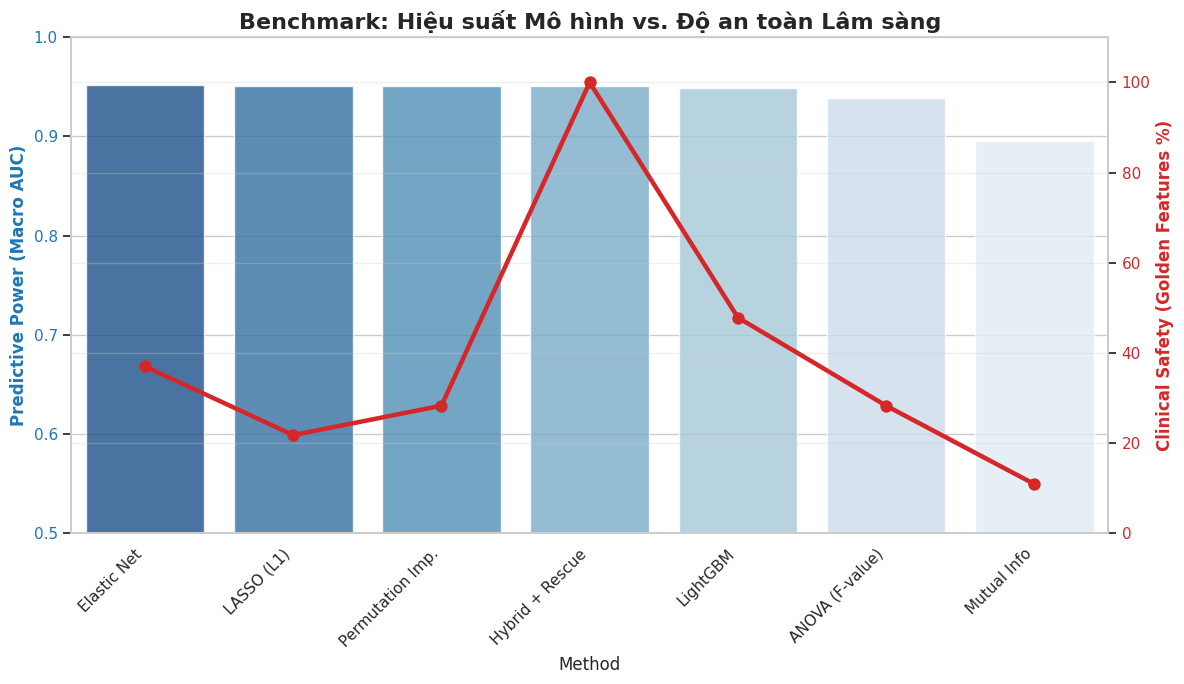

In [ ]:
# @title FEATURE SELECTION METHODS COMPARISON
# =============================================================================
# DESCRIPTION:
# Execute 6 different feature selection methods for benchmarking against the Hybrid Method.
#
# LIST OF METHODS:
# 1. Filter: ANOVA F-value (Linear)
# 2. Filter: Mutual Information (Non-linear)
# 3. Embedded: LASSO (L1 Regularization)
# 4. Embedded: Elastic Net (L1 + L2 Regularization)
# 5. Tree-based: LightGBM Importance
# 6. Wrapper: Permutation Importance
# 7. PROPOSED: Hybrid + Clinical Rescue
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import lightgbm as lgb
import os
import pickle
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import roc_auc_score
from sklearn.inspection import permutation_importance

# =============================================================================
# 1. CONFIGURATION & DATA LOADING
# =============================================================================
SAVE_DIR = "/content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN"
PATH_MAIN_X = os.path.join(SAVE_DIR, "pipeline6_FINAL_X_MASTER_dataset_main.pkl")
PATH_MAIN_Y = os.path.join(SAVE_DIR, "pipeline6_FINAL_Y_MASTER_dataset_main.pkl")
PATH_HYBRID_FEATURES = os.path.join(SAVE_DIR, "pipeline6_SELECTED_FEATURES_LIST.pkl")

# Clinical Golden Features List
GOLDEN_FEATURES = [
    'LAB_NTproBNP', 'ECHO_LVEF', 'TXT_edema', 'TXT_dyspnea', 'TXT_orthopnea',
    'LAB_Troponin_T', 'LAB_CK_MB_Index', 'ECG_ST_ELEV', 'TXT_st_elevation',
    'TXT_anterior', 'TXT_inferior', 'TXT_lateral', 'TXT_septal',
    'LAB_White_Blood_Cells', 'LAB_C_Reactive_Protein', 'LAB_Neutrophils',
    'LAB_Sedimentation_Rate', 'TXT_fevers', 'TXT_chills',
    'LAB_Lactate_Dehydrogenase__LD_', 'LAB_Thyroid_Stimulating_Hormone',
    'TXT_s1', 'TXT_s2', 'TXT_s1_s2', 'TXT_abnormal', 'TXT_atrial_fibrillation',
    'TXT_dyspnea_exertion', 'LAB_Potassium', 'LAB_Magnesium', 'ECG_AFIB',
    'TXT_tachycardia', 'TXT_bradycardia', 'TXT_block', 'TXT_palpitations',
    'TXT_rhythm', 'TXT_rate', 'ECG_SINUS', 'TXT_chest_pain', 'TXT_cough',
    'DEMO_AGE', 'DEMO_GENDER_MALE', 'LAB_Creatinine', 'LAB_Urea_Nitrogen',
    'TXT_st_changes', 'TXT_weight', 'LAB_RDW'
]

class ExtendedFeatureBenchmark:
    def __init__(self, path_X, path_y, path_hybrid_feats):
        print("INIT: Loading Data for Extended Benchmarking...")
        self.X = pd.read_pickle(path_X)
        self.y_raw = pd.read_pickle(path_y)

        with open(path_hybrid_feats, 'rb') as f:
            self.hybrid_features = pickle.load(f)

        self.le = LabelEncoder()
        self.y = self.le.fit_transform(self.y_raw)

        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X, self.y, test_size=0.2, random_state=42, stratify=self.y
        )

        # Scale for LASSO/Elastic Net
        self.scaler = StandardScaler()
        self.X_train_scaled = self.scaler.fit_transform(self.X_train.fillna(0))
        self.X_test_scaled = self.scaler.transform(self.X_test.fillna(0))

        self.results = []
        self.target_n_features = len(self.hybrid_features)
        print(f"Target Number of Features to Select: ~{self.target_n_features}")

    def evaluate_feature_set(self, features, method_name):
        if len(features) == 0: return 0

        model = xgb.XGBClassifier(
            objective='multi:softprob', num_class=len(self.le.classes_),
            eval_metric='mlogloss', n_estimators=50, max_depth=4,
            random_state=42, n_jobs=-1, verbosity=0
        )
        model.fit(self.X_train[features], self.y_train)
        y_pred = model.predict_proba(self.X_test[features])

        try:
            auc = roc_auc_score(self.y_test, y_pred, multi_class='ovr', average='macro')
        except: auc = 0

        golden_kept = len(set(features).intersection(set(GOLDEN_FEATURES)))
        golden_total = len(set(GOLDEN_FEATURES).intersection(set(self.X.columns)))
        golden_rate = (golden_kept / golden_total) * 100 if golden_total > 0 else 0

        print(f"   >> [{method_name:<25}] AUC: {auc:.4f} | Golden: {golden_kept:2d}/{golden_total} ({golden_rate:.1f}%)")

        self.results.append({
            'Method': method_name,
            'Macro_AUC': auc,
            'Golden_Rate': golden_rate
        })

    # --- 1. FILTER METHODS ---
    def run_anova(self):
        print("\nRunning 1: ANOVA (Linear Filter)...")
        selector = SelectKBest(f_classif, k=self.target_n_features)
        selector.fit(self.X_train.fillna(0), self.y_train)
        cols = self.X_train.columns[selector.get_support()]
        self.evaluate_feature_set(list(cols), "ANOVA (F-value)")

    def run_mutual_information(self):
        print("\nRunning 2: Mutual Information (Non-linear Filter)...")

        selector = SelectKBest(mutual_info_classif, k=self.target_n_features)
        selector.fit(self.X_train.fillna(0), self.y_train)
        cols = self.X_train.columns[selector.get_support()]
        self.evaluate_feature_set(list(cols), "Mutual Info")

    # --- 2. EMBEDDED METHODS ---
    def run_lasso(self):
        print("\nRunning 3: LASSO (L1 Regularization)...")
        lasso = LogisticRegression(penalty='l1', C=0.05, solver='liblinear', random_state=42)
        selector = SelectFromModel(lasso, max_features=self.target_n_features)
        selector.fit(self.X_train_scaled, self.y_train)
        cols = self.X_train.columns[selector.get_support()]
        self.evaluate_feature_set(list(cols), "LASSO (L1)")

    def run_elastic_net(self):
        print("\nRunning 4: Elastic Net (L1 + L2)...")

        enet = LogisticRegression(penalty='elasticnet', l1_ratio=0.5, C=0.05, solver='saga', random_state=42, n_jobs=-1)
        selector = SelectFromModel(enet, max_features=self.target_n_features)
        selector.fit(self.X_train_scaled, self.y_train)
        cols = self.X_train.columns[selector.get_support()]
        self.evaluate_feature_set(list(cols), "Elastic Net")

    # --- 3. ADVANCED METHODS ---
    def run_lightgbm(self):
        print("\nRunning 5: LightGBM Importance (Tree-based)...")
        lgbm = lgb.LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
        lgbm.fit(self.X_train, self.y_train)
        imps = pd.Series(lgbm.feature_importances_, index=self.X_train.columns)
        top_features = imps.nlargest(self.target_n_features).index.tolist()
        self.evaluate_feature_set(top_features, "LightGBM")

    def run_permutation_importance(self):
        print("\nRunning 6: Permutation Importance (Model Agnostic)...")

        base_model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
        base_model.fit(self.X_train.fillna(0), self.y_train)


        perm_result = permutation_importance(
            base_model, self.X_test.fillna(0), self.y_test,
            n_repeats=5, random_state=42, n_jobs=-1
        )

        imps = pd.Series(perm_result.importances_mean, index=self.X_test.columns)
        top_features = imps.nlargest(self.target_n_features).index.tolist()
        self.evaluate_feature_set(top_features, "Permutation Imp.")

    # --- 4. YOUR METHOD ---
    def evaluate_hybrid(self):
        print("\nRunning 7: PROPOSED METHOD (Hybrid + Rescue)...")
        self.evaluate_feature_set(self.hybrid_features, "Hybrid + Rescue")

    # --- REPORT ---
    def plot_results(self):
        df_res = pd.DataFrame(self.results).sort_values('Macro_AUC', ascending=False)

        print("\n" + "="*60)
        print("KẾT QUẢ SO SÁNH TOÀN DIỆN (COMPREHENSIVE BENCHMARK)")
        print("="*60)
        print(df_res.to_markdown(index=False))

        # Visualization: Combined Bar and Point Plot
        fig, ax1 = plt.subplots(figsize=(12, 7))

        # Plot AUC (Bar Chart)
        color = '#1f77b4'
        sns.barplot(x='Method', y='Macro_AUC', data=df_res, ax=ax1, palette='Blues_r', alpha=0.8)
        ax1.set_ylabel('Predictive Power (Macro AUC)', color=color, fontweight='bold', fontsize=12)
        ax1.tick_params(axis='y', labelcolor=color)
        ax1.set_ylim(0.5, 1.0)
        ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

        # Plot Golden Rate (Line Plot - Secondary Axis)
        ax2 = ax1.twinx()
        color = '#d62728'
        sns.pointplot(x='Method', y='Golden_Rate', data=df_res, ax=ax2, color=color, markers='o', scale=1.2)
        ax2.set_ylabel('Clinical Safety (Golden Features %)', color=color, fontweight='bold', fontsize=12)
        ax2.tick_params(axis='y', labelcolor=color)
        ax2.set_ylim(0, 110)

        plt.title('Benchmark: Hiệu suất Mô hình vs. Độ an toàn Lâm sàng', fontsize=16, fontweight='bold')
        plt.grid(True, axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()

# =============================================================================
# MAIN EXECUTION
# =============================================================================
if __name__ == "__main__":
    if os.path.exists(PATH_MAIN_X) and os.path.exists(PATH_HYBRID_FEATURES):
        bm = ExtendedFeatureBenchmark(PATH_MAIN_X, PATH_MAIN_Y, PATH_HYBRID_FEATURES)

        # 1. Filter
        bm.run_anova()
        bm.run_mutual_information()

        # 2. Embedded
        bm.run_lasso()
        bm.run_elastic_net()

        # 3. Advanced
        bm.run_lightgbm()
        bm.run_permutation_importance()

        # 4. Proposed
        bm.evaluate_hybrid()

        # Visualize
        bm.plot_results()
    else:
        print("❌ Cần chạy Ô Mã 6 để tạo danh sách features trước!")

INIT: Loading Data for Extended Benchmarking...
Target Number of Features to Select: ~76

Running 1: ANOVA F-value (Linear Filter)...
   >> [ANOVA (F-value)          ] Feats:  76 | AUC: 0.9384 | Golden: 13/46 (28.3%)

Running 2: Mutual Information (Non-linear Filter)...
   >> [Mutual Info              ] Feats:  76 | AUC: 0.8900 | Golden:  5/46 (10.9%)

Running 3: Chi-Square (Probabilistic Filter)...
   >> [Chi-Square               ] Feats:  76 | AUC: 0.9334 | Golden: 13/46 (28.3%)

Running 4: LASSO (L1 Regularization)...
   >> [LASSO (L1)               ] Feats:  76 | AUC: 0.9511 | Golden: 10/46 (21.7%)

Running 5: Elastic Net (L1 + L2)...
   >> [Elastic Net              ] Feats:  76 | AUC: 0.9515 | Golden: 17/46 (37.0%)

Running 6: Ridge Classifier (L2 Regularization)...
   >> [Ridge (L2)               ] Feats:  76 | AUC: 0.9402 | Golden:  8/46 (17.4%)

Running 7: LightGBM Importance (Gradient Boosting)...
   >> [LightGBM                 ] Feats:  76 | AUC: 0.9488 | Golden: 22/46 (47.8

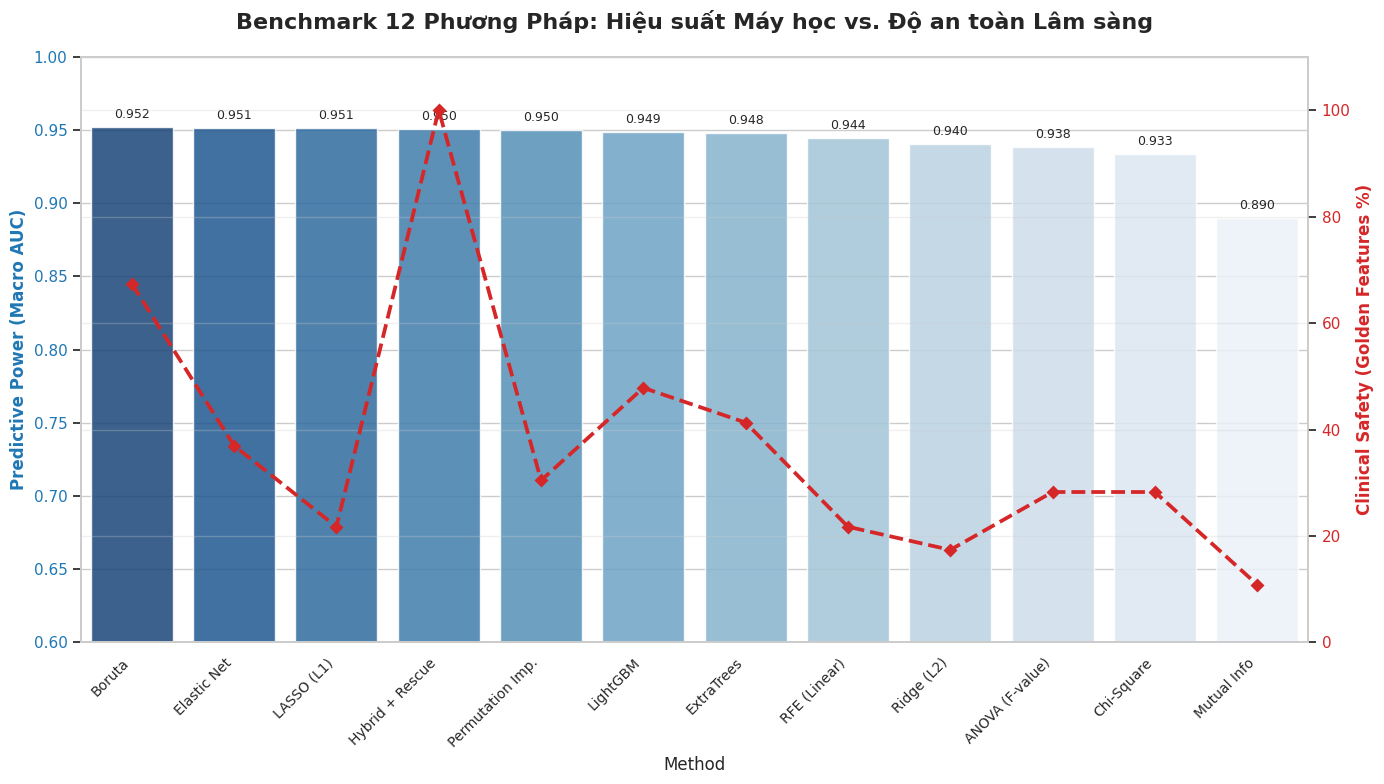

In [ ]:
# @title BLOCK 7: BENCHMARKING 12 FEATURE SELECTION METHODS (EXPANDED VERSION)
# =============================================================================
# DESCRIPTION:
# Expanded benchmark comparing 12 different feature selection methods.
#
# LIST OF METHODS:
# --- Filter Methods ---
# 1. ANOVA F-value (Linear relationship)
# 2. Mutual Information (Non-linear relationship)
# 3. [NEW] Chi-Square (Probabilistic dependence)
#
# --- Embedded Methods (Regularization) ---
# 4. LASSO (L1 - Sparsity)
# 5. Elastic Net (L1 + L2 - Grouping effect)
# 6. [NEW] Ridge Classifier (L2 - Coefficient shrinkage)
#
# --- Tree-based Methods ---
# 7. LightGBM Importance (Gradient Boosting)
# 8. [NEW] ExtraTrees Importance (Randomized Trees)
#
# --- Wrapper Methods ---
# 9. Permutation Importance (Model Agnostic)
# 10. [NEW] RFE Linear (Recursive Elimination with Logistic Regression)
# 11. [NEW] Boruta (Shadow Features Algorithm)
#
# --- Proposed Method ---
# 12. Hybrid + Clinical Rescue (Proposed)
# =============================================================================
!pip install boruta
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import lightgbm as lgb
import os
import pickle
import warnings
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, SelectFromModel, chi2, RFE
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.metrics import roc_auc_score
from sklearn.inspection import permutation_importance

# Suppress convergence warnings for cleaner logs
warnings.filterwarnings("ignore")

# Handle Boruta import
try:
    from boruta import BorutaPy
    HAS_BORUTA = True
except ImportError:
    HAS_BORUTA = False
    print("⚠️ Cảnh báo: Chưa cài đặt thư viện 'boruta'. Phương pháp này sẽ bị bỏ qua.")
    print("👉 Hãy chạy: !pip install boruta")

# =============================================================================
# 1. CONFIGURATION & DATA LOADING
# =============================================================================
SAVE_DIR = "/content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN"
PATH_MAIN_X = os.path.join(SAVE_DIR, "pipeline6_FINAL_X_MASTER_dataset_main.pkl")
PATH_MAIN_Y = os.path.join(SAVE_DIR, "pipeline6_FINAL_Y_MASTER_dataset_main.pkl")
PATH_HYBRID_FEATURES = os.path.join(SAVE_DIR, "pipeline6_SELECTED_FEATURES_LIST.pkl")

# Clinical Golden Features List for validation
GOLDEN_FEATURES = [
    'LAB_NTproBNP', 'ECHO_LVEF', 'TXT_edema', 'TXT_dyspnea', 'TXT_orthopnea',
    'LAB_Troponin_T', 'LAB_CK_MB_Index', 'ECG_ST_ELEV', 'TXT_st_elevation',
    'TXT_anterior', 'TXT_inferior', 'TXT_lateral', 'TXT_septal',
    'LAB_White_Blood_Cells', 'LAB_C_Reactive_Protein', 'LAB_Neutrophils',
    'LAB_Sedimentation_Rate', 'TXT_fevers', 'TXT_chills',
    'LAB_Lactate_Dehydrogenase__LD_', 'LAB_Thyroid_Stimulating_Hormone',
    'TXT_s1', 'TXT_s2', 'TXT_s1_s2', 'TXT_abnormal', 'TXT_atrial_fibrillation',
    'TXT_dyspnea_exertion', 'LAB_Potassium', 'LAB_Magnesium', 'ECG_AFIB',
    'TXT_tachycardia', 'TXT_bradycardia', 'TXT_block', 'TXT_palpitations',
    'TXT_rhythm', 'TXT_rate', 'ECG_SINUS', 'TXT_chest_pain', 'TXT_cough',
    'DEMO_AGE', 'DEMO_GENDER_MALE', 'LAB_Creatinine', 'LAB_Urea_Nitrogen',
    'TXT_st_changes', 'TXT_weight', 'LAB_RDW'
]

class ExtendedFeatureBenchmark:
    def __init__(self, path_X, path_y, path_hybrid_feats):
        print("INIT: Loading Data for Extended Benchmarking...")
        self.X = pd.read_pickle(path_X)
        self.y_raw = pd.read_pickle(path_y)

        with open(path_hybrid_feats, 'rb') as f:
            self.hybrid_features = pickle.load(f)

        self.le = LabelEncoder()
        self.y = self.le.fit_transform(self.y_raw)

        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X, self.y, test_size=0.2, random_state=42, stratify=self.y
        )

        # Standard Scaling for linear algorithms
        self.scaler = StandardScaler()
        self.X_train_scaled = self.scaler.fit_transform(self.X_train.fillna(0))
        self.X_test_scaled = self.scaler.transform(self.X_test.fillna(0))

        # MinMaxScaler for Chi-Square (requires non-negative inputs)
        self.minmax_scaler = MinMaxScaler()
        self.X_train_minmax = self.minmax_scaler.fit_transform(self.X_train.fillna(0))

        self.results = []
        self.target_n_features = len(self.hybrid_features) # Benchmark based on Hybrid feature count
        print(f"Target Number of Features to Select: ~{self.target_n_features}")

    def evaluate_feature_set(self, features, method_name):
        """Hàm đánh giá chung cho mọi phương pháp"""
        if len(features) == 0:
            print(f"   >> [{method_name}] NO FEATURES SELECTED!")
            return 0

        # Fast XGBoost Configuration
        model = xgb.XGBClassifier(
            objective='multi:softprob', num_class=len(self.le.classes_),
            eval_metric='mlogloss', n_estimators=50, max_depth=4,
            random_state=42, n_jobs=-1, verbosity=0
        )


        valid_features = [f for f in features if f in self.X_train.columns]

        if not valid_features:
            return 0

        model.fit(self.X_train[valid_features], self.y_train)
        y_pred = model.predict_proba(self.X_test[valid_features])

        try:
            auc = roc_auc_score(self.y_test, y_pred, multi_class='ovr', average='macro')
        except: auc = 0

        golden_kept = len(set(valid_features).intersection(set(GOLDEN_FEATURES)))
        golden_total = len(set(GOLDEN_FEATURES).intersection(set(self.X.columns)))
        golden_rate = (golden_kept / golden_total) * 100 if golden_total > 0 else 0

        print(f"   >> [{method_name:<25}] Feats: {len(valid_features):3d} | AUC: {auc:.4f} | Golden: {golden_kept:2d}/{golden_total} ({golden_rate:.1f}%)")

        self.results.append({
            'Method': method_name,
            'N_Features': len(valid_features),
            'Macro_AUC': auc,
            'Golden_Rate': golden_rate
        })

    # ================= 1. FILTER METHODS =================
    def run_anova(self):
        print("\nRunning 1: ANOVA F-value (Linear Filter)...")
        selector = SelectKBest(f_classif, k=self.target_n_features)
        selector.fit(self.X_train.fillna(0), self.y_train)
        cols = self.X_train.columns[selector.get_support()]
        self.evaluate_feature_set(list(cols), "ANOVA (F-value)")

    def run_mutual_information(self):
        print("\nRunning 2: Mutual Information (Non-linear Filter)...")
        selector = SelectKBest(mutual_info_classif, k=self.target_n_features)
        selector.fit(self.X_train.fillna(0), self.y_train)
        cols = self.X_train.columns[selector.get_support()]
        self.evaluate_feature_set(list(cols), "Mutual Info")

    def run_chi2(self):
        print("\nRunning 3: Chi-Square (Probabilistic Filter)...")

        selector = SelectKBest(chi2, k=self.target_n_features)
        selector.fit(self.X_train_minmax, self.y_train)
        cols = self.X_train.columns[selector.get_support()]
        self.evaluate_feature_set(list(cols), "Chi-Square")

    # ================= 2. EMBEDDED METHODS =================
    def run_lasso(self):
        print("\nRunning 4: LASSO (L1 Regularization)...")
        lasso = LogisticRegression(penalty='l1', C=0.05, solver='liblinear', random_state=42)
        selector = SelectFromModel(lasso, max_features=self.target_n_features)
        selector.fit(self.X_train_scaled, self.y_train)
        cols = self.X_train.columns[selector.get_support()]
        self.evaluate_feature_set(list(cols), "LASSO (L1)")

    def run_elastic_net(self):
        print("\nRunning 5: Elastic Net (L1 + L2)...")
        enet = LogisticRegression(penalty='elasticnet', l1_ratio=0.5, C=0.05, solver='saga', random_state=42, n_jobs=-1)
        selector = SelectFromModel(enet, max_features=self.target_n_features)
        selector.fit(self.X_train_scaled, self.y_train)
        cols = self.X_train.columns[selector.get_support()]
        self.evaluate_feature_set(list(cols), "Elastic Net")

    def run_ridge(self):
        print("\nRunning 6: Ridge Classifier (L2 Regularization)...")

        ridge = RidgeClassifier(alpha=1.0, random_state=42)
        selector = SelectFromModel(ridge, max_features=self.target_n_features)
        selector.fit(self.X_train_scaled, self.y_train)
        cols = self.X_train.columns[selector.get_support()]
        self.evaluate_feature_set(list(cols), "Ridge (L2)")

    # ================= 3. TREE-BASED METHODS =================
    def run_lightgbm(self):
        print("\nRunning 7: LightGBM Importance (Gradient Boosting)...")
        lgbm = lgb.LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
        lgbm.fit(self.X_train, self.y_train)
        imps = pd.Series(lgbm.feature_importances_, index=self.X_train.columns)
        top_features = imps.nlargest(self.target_n_features).index.tolist()
        self.evaluate_feature_set(top_features, "LightGBM")

    def run_extratrees(self):
        print("\nRunning 8: ExtraTrees Importance (Randomized Trees)...")

        et = ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        et.fit(self.X_train.fillna(0), self.y_train)
        imps = pd.Series(et.feature_importances_, index=self.X_train.columns)
        top_features = imps.nlargest(self.target_n_features).index.tolist()
        self.evaluate_feature_set(top_features, "ExtraTrees")

    # ================= 4. WRAPPER METHODS =================
    def run_permutation_importance(self):
        print("\nRunning 9: Permutation Importance (Model Agnostic)...")
        base_model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
        base_model.fit(self.X_train.fillna(0), self.y_train)

        perm_result = permutation_importance(
            base_model, self.X_test.fillna(0), self.y_test,
            n_repeats=3, random_state=42, n_jobs=-1
        )

        imps = pd.Series(perm_result.importances_mean, index=self.X_test.columns)
        top_features = imps.nlargest(self.target_n_features).index.tolist()
        self.evaluate_feature_set(top_features, "Permutation Imp.")

    def run_rfe_linear(self):
        print("\nRunning 10: RFE Linear (Recursive with Logistic)...")

        estimator = LogisticRegression(solver='liblinear', random_state=42)
        selector = RFE(estimator, n_features_to_select=self.target_n_features, step=0.1)
        selector.fit(self.X_train_scaled, self.y_train)
        cols = self.X_train.columns[selector.get_support()]
        self.evaluate_feature_set(list(cols), "RFE (Linear)")

    def run_boruta(self):
        if not HAS_BORUTA:
            self.results.append({'Method': 'Boruta', 'Macro_AUC': 0, 'Golden_Rate': 0})
            return

        print("\nRunning 11: Boruta (Shadow Features Wrapper)...")
        print("   (Note: Boruta chạy khá lâu, vui lòng đợi...)")


        rf = RandomForestClassifier(n_estimators=100, n_jobs=-1, class_weight='balanced', max_depth=5)
        feat_selector = BorutaPy(rf, n_estimators='auto', verbose=0, random_state=42, max_iter=50)

        X_np = self.X_train.fillna(0).values
        y_np = self.y_train

        feat_selector.fit(X_np, y_np)


        selected_indices = np.where(feat_selector.support_)[0]
        cols = self.X_train.columns[selected_indices].tolist()


        if len(cols) < 5:
            tentative_indices = np.where(feat_selector.support_weak_)[0]
            cols += self.X_train.columns[tentative_indices].tolist()

        self.evaluate_feature_set(cols, "Boruta")

    # ================= 5. PROPOSED METHOD =================
    def evaluate_hybrid(self):
        print("\nRunning 12: PROPOSED METHOD (Hybrid + Rescue)...")
        self.evaluate_feature_set(self.hybrid_features, "Hybrid + Rescue")

    # ================= REPORTING =================
    def plot_results(self):
        df_res = pd.DataFrame(self.results).sort_values('Macro_AUC', ascending=False)

        print("\n" + "="*80)
        print("KẾT QUẢ SO SÁNH TOÀN DIỆN 12 PHƯƠNG PHÁP (COMPREHENSIVE BENCHMARK)")
        print("="*80)
        print(df_res.to_markdown(index=False))

        # Dual-axis visualization
        fig, ax1 = plt.subplots(figsize=(14, 8))

        # Axis 1: Macro AUC (Bar chart)
        color_auc = '#1f77b4' # Blue
        barplot = sns.barplot(x='Method', y='Macro_AUC', data=df_res, ax=ax1, palette='Blues_r', alpha=0.85)
        ax1.set_ylabel('Predictive Power (Macro AUC)', color=color_auc, fontweight='bold', fontsize=12)
        ax1.tick_params(axis='y', labelcolor=color_auc)
        ax1.set_ylim(0.6, 1.0)
        ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=10)

        # Annotate bars
        for p in barplot.patches:
            if p.get_height() > 0:
                ax1.annotate(format(p.get_height(), '.3f'),
                             (p.get_x() + p.get_width() / 2., p.get_height()),
                             ha = 'center', va = 'center',
                             xytext = (0, 9), textcoords = 'offset points', fontsize=9)

        # Axis 2: Golden Rate (Line chart)
        ax2 = ax1.twinx()
        color_golden = '#d62728' # Đỏ
        sns.pointplot(x='Method', y='Golden_Rate', data=df_res, ax=ax2, color=color_golden, markers='D', scale=1.0, linestyles='--')
        ax2.set_ylabel('Clinical Safety (Golden Features %)', color=color_golden, fontweight='bold', fontsize=12)
        ax2.tick_params(axis='y', labelcolor=color_golden)
        ax2.set_ylim(0, 110)

        plt.title('Benchmark 12 Phương Pháp: Hiệu suất Máy học vs. Độ an toàn Lâm sàng', fontsize=16, fontweight='bold', pad=20)
        plt.grid(True, axis='y', alpha=0.3)
        plt.tight_layout()

        # Save plot
        plt.savefig(os.path.join(SAVE_DIR, 'pipeline7_benchmark_12_methods.png'), dpi=300)
        plt.show()

# =============================================================================
# MAIN EXECUTION
# =============================================================================
if __name__ == "__main__":
    if os.path.exists(PATH_MAIN_X) and os.path.exists(PATH_HYBRID_FEATURES):
        bm = ExtendedFeatureBenchmark(PATH_MAIN_X, PATH_MAIN_Y, PATH_HYBRID_FEATURES)

        # 1. Filter Methods
        bm.run_anova()
        bm.run_mutual_information()
        bm.run_chi2()

        # 2. Embedded Methods
        bm.run_lasso()
        bm.run_elastic_net()
        bm.run_ridge()

        # 3. Tree-based Methods
        bm.run_lightgbm()
        bm.run_extratrees()

        # 4. Wrapper Methods
        bm.run_permutation_importance()
        bm.run_rfe_linear()
        bm.run_boruta()

        # 5. Proposed Method
        bm.evaluate_hybrid()

        # 6. Visualize
        bm.plot_results()
    else:
        print("❌ Cần chạy Ô Mã 6 để tạo danh sách features trước!")

INIT: Loading Data for Extended Benchmarking...
Target Features: ~76
Available Golden Features in Dataset: 46

--- Running Filter Methods ---
   >> [ORIGINAL] ANOVA                | Feats:  76 | AUC: 0.9384 | Golden: 28.3%
   >> [ORIGINAL] Mutual Info          | Feats:  76 | AUC: 0.8718 | Golden: 10.9%
   >> [ORIGINAL] Chi-Square           | Feats:  76 | AUC: 0.9334 | Golden: 28.3%

--- Running Embedded Methods ---
   >> [ORIGINAL] LASSO                | Feats:  76 | AUC: 0.9511 | Golden: 21.7%
   >> [ORIGINAL] Elastic Net          | Feats:  76 | AUC: 0.9515 | Golden: 37.0%
   >> [ORIGINAL] Ridge                | Feats:  76 | AUC: 0.9402 | Golden: 17.4%

--- Running Tree-based Methods ---
   >> [ORIGINAL] LightGBM             | Feats:  76 | AUC: 0.9488 | Golden: 47.8%
   >> [ORIGINAL] ExtraTrees           | Feats:  76 | AUC: 0.9478 | Golden: 41.3%

--- Running Wrapper Methods ---
   >> [ORIGINAL] Permutation Imp      | Feats:  76 | AUC: 0.9546 | Golden: 30.4%
   >> [ORIGINAL] RFE Linea

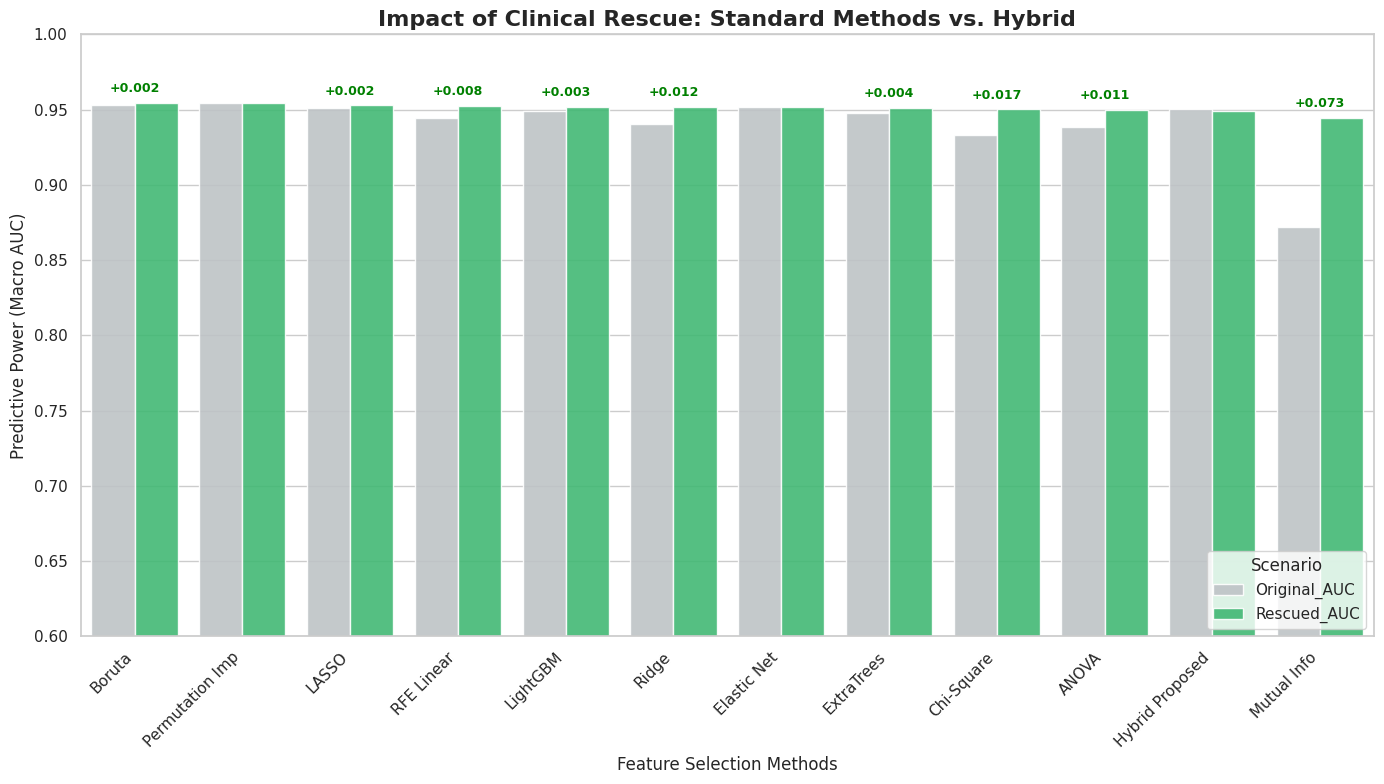

In [ ]:
# @title BLOCK 7: BENCHMARKING 12 METHODS (RESCUE VS. GAIN ANALYSIS)
# =============================================================================
# DESCRIPTION:
# Expanded benchmark comparing 12 different feature selection methods.
#
# COMPARISON SCENARIOS:
# 1. Base Scenario: Pure algorithm-to-algorithm comparison (Pure performance).
# 2. Rescue Scenario: Applies "Clinical Rescue" to ALL methods
#    (Mandatory inclusion of Golden Features) to evaluate which algorithm
#    best integrates and leverages these clinical priors.
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import lightgbm as lgb
import os
import pickle
import warnings
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, SelectFromModel, chi2, RFE
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.metrics import roc_auc_score
from sklearn.inspection import permutation_importance

# Suppress convergence warnings
warnings.filterwarnings("ignore")

# Check for Boruta library
try:
    from boruta import BorutaPy
    HAS_BORUTA = True
except ImportError:
    HAS_BORUTA = False
    print("⚠️ Cảnh báo: Chưa cài đặt thư viện 'boruta'. Phương pháp này sẽ bị bỏ qua.")

# =============================================================================
# 1. CONFIGURATION & DATA LOADING
# =============================================================================
SAVE_DIR = "/content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN"
PATH_MAIN_X = os.path.join(SAVE_DIR, "pipeline6_FINAL_X_MASTER_dataset_main.pkl")
PATH_MAIN_Y = os.path.join(SAVE_DIR, "pipeline6_FINAL_Y_MASTER_dataset_main.pkl")
PATH_HYBRID_FEATURES = os.path.join(SAVE_DIR, "pipeline6_SELECTED_FEATURES_LIST.pkl")

# Clinical Golden Features List
GOLDEN_FEATURES = [
    'LAB_NTproBNP', 'ECHO_LVEF', 'TXT_edema', 'TXT_dyspnea', 'TXT_orthopnea',
    'LAB_Troponin_T', 'LAB_CK_MB_Index', 'ECG_ST_ELEV', 'TXT_st_elevation',
    'TXT_anterior', 'TXT_inferior', 'TXT_lateral', 'TXT_septal',
    'LAB_White_Blood_Cells', 'LAB_C_Reactive_Protein', 'LAB_Neutrophils',
    'LAB_Sedimentation_Rate', 'TXT_fevers', 'TXT_chills',
    'LAB_Lactate_Dehydrogenase__LD_', 'LAB_Thyroid_Stimulating_Hormone',
    'TXT_s1', 'TXT_s2', 'TXT_s1_s2', 'TXT_abnormal', 'TXT_atrial_fibrillation',
    'TXT_dyspnea_exertion', 'LAB_Potassium', 'LAB_Magnesium', 'ECG_AFIB',
    'TXT_tachycardia', 'TXT_bradycardia', 'TXT_block', 'TXT_palpitations',
    'TXT_rhythm', 'TXT_rate', 'ECG_SINUS', 'TXT_chest_pain', 'TXT_cough',
    'DEMO_AGE', 'DEMO_GENDER_MALE', 'LAB_Creatinine', 'LAB_Urea_Nitrogen',
    'TXT_st_changes', 'TXT_weight', 'LAB_RDW'
]

class ExtendedFeatureBenchmark:
    def __init__(self, path_X, path_y, path_hybrid_feats):
        print("INIT: Loading Data for Extended Benchmarking...")
        self.X = pd.read_pickle(path_X)
        self.y_raw = pd.read_pickle(path_y)

        with open(path_hybrid_feats, 'rb') as f:
            self.hybrid_features = pickle.load(f)

        self.le = LabelEncoder()
        self.y = self.le.fit_transform(self.y_raw)

        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X, self.y, test_size=0.2, random_state=42, stratify=self.y
        )

        # Data Scaling
        self.scaler = StandardScaler()
        self.X_train_scaled = self.scaler.fit_transform(self.X_train.fillna(0))
        self.X_test_scaled = self.scaler.transform(self.X_test.fillna(0))

        self.minmax_scaler = MinMaxScaler()
        self.X_train_minmax = self.minmax_scaler.fit_transform(self.X_train.fillna(0))

        self.results = []
        # Storage for feature lists to be used in Step 2 (Rescue)
        self.feature_sets_storage = {}
        self.target_n_features = len(self.hybrid_features)

        # Identify Golden Features actually present in the data
        self.available_golden = [f for f in GOLDEN_FEATURES if f in self.X.columns]

        print(f"Target Features: ~{self.target_n_features}")
        print(f"Available Golden Features in Dataset: {len(self.available_golden)}")

    def _train_and_evaluate(self, features):
        """Hàm nội bộ để train model và trả về AUC"""
        if len(features) == 0: return 0.0

        valid_features = [f for f in features if f in self.X_train.columns]
        if not valid_features: return 0.0

        model = xgb.XGBClassifier(
            objective='multi:softprob', num_class=len(self.le.classes_),
            eval_metric='mlogloss', n_estimators=50, max_depth=4,
            random_state=42, n_jobs=-1, verbosity=0
        )
        model.fit(self.X_train[valid_features], self.y_train)
        y_pred = model.predict_proba(self.X_test[valid_features])

        try:
            return roc_auc_score(self.y_test, y_pred, multi_class='ovr', average='macro')
        except: return 0.0

    def evaluate_feature_set(self, features, method_name):
        """Đánh giá Step 1: Nguyên bản"""
        auc = self._train_and_evaluate(features)

        valid_features = [f for f in features if f in self.X.columns]

        # Store feature set for later use
        self.feature_sets_storage[method_name] = valid_features

        golden_kept = len(set(valid_features).intersection(set(self.available_golden)))
        golden_rate = (golden_kept / len(self.available_golden)) * 100 if len(self.available_golden) > 0 else 0

        print(f"   >> [ORIGINAL] {method_name:<20} | Feats: {len(valid_features):3d} | AUC: {auc:.4f} | Golden: {golden_rate:.1f}%")

        self.results.append({
            'Method': method_name,
            'Type': 'Original',
            'N_Features': len(valid_features),
            'Macro_AUC': auc,
            'Golden_Rate': golden_rate
        })

    # ================= STANDARD METHODS =================
    def run_all_standard_methods(self):
        # 1. ANOVA
        print("\n--- Running Filter Methods ---")
        sel = SelectKBest(f_classif, k=self.target_n_features).fit(self.X_train.fillna(0), self.y_train)
        self.evaluate_feature_set(list(self.X_train.columns[sel.get_support()]), "ANOVA")

        # 2. Mutual Info
        sel = SelectKBest(mutual_info_classif, k=self.target_n_features).fit(self.X_train.fillna(0), self.y_train)
        self.evaluate_feature_set(list(self.X_train.columns[sel.get_support()]), "Mutual Info")

        # 3. Chi2
        sel = SelectKBest(chi2, k=self.target_n_features).fit(self.X_train_minmax, self.y_train)
        self.evaluate_feature_set(list(self.X_train.columns[sel.get_support()]), "Chi-Square")

        # 4. LASSO
        print("\n--- Running Embedded Methods ---")
        sel = SelectFromModel(LogisticRegression(penalty='l1', C=0.05, solver='liblinear', random_state=42), max_features=self.target_n_features)
        sel.fit(self.X_train_scaled, self.y_train)
        self.evaluate_feature_set(list(self.X_train.columns[sel.get_support()]), "LASSO")

        # 5. Elastic Net
        sel = SelectFromModel(LogisticRegression(penalty='elasticnet', l1_ratio=0.5, C=0.05, solver='saga', random_state=42, n_jobs=-1), max_features=self.target_n_features)
        sel.fit(self.X_train_scaled, self.y_train)
        self.evaluate_feature_set(list(self.X_train.columns[sel.get_support()]), "Elastic Net")

        # 6. Ridge
        sel = SelectFromModel(RidgeClassifier(random_state=42), max_features=self.target_n_features)
        sel.fit(self.X_train_scaled, self.y_train)
        self.evaluate_feature_set(list(self.X_train.columns[sel.get_support()]), "Ridge")

        # 7. LightGBM
        print("\n--- Running Tree-based Methods ---")
        lgbm = lgb.LGBMClassifier(n_estimators=100, random_state=42, verbose=-1).fit(self.X_train, self.y_train)
        self.evaluate_feature_set(pd.Series(lgbm.feature_importances_, index=self.X_train.columns).nlargest(self.target_n_features).index.tolist(), "LightGBM")

        # 8. ExtraTrees
        et = ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1).fit(self.X_train.fillna(0), self.y_train)
        self.evaluate_feature_set(pd.Series(et.feature_importances_, index=self.X_train.columns).nlargest(self.target_n_features).index.tolist(), "ExtraTrees")

        # 9. Permutation
        print("\n--- Running Wrapper Methods ---")
        base = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1).fit(self.X_train.fillna(0), self.y_train)
        perm = permutation_importance(base, self.X_test.fillna(0), self.y_test, n_repeats=2, random_state=42, n_jobs=-1)
        self.evaluate_feature_set(pd.Series(perm.importances_mean, index=self.X_test.columns).nlargest(self.target_n_features).index.tolist(), "Permutation Imp")

        # 10. RFE Linear
        rfe = RFE(LogisticRegression(solver='liblinear'), n_features_to_select=self.target_n_features, step=0.1).fit(self.X_train_scaled, self.y_train)
        self.evaluate_feature_set(list(self.X_train.columns[rfe.get_support()]), "RFE Linear")

        # 11. Boruta
        if HAS_BORUTA:
            rf = RandomForestClassifier(n_estimators=100, n_jobs=-1, class_weight='balanced', max_depth=5)
            boruta = BorutaPy(rf, n_estimators='auto', verbose=0, random_state=42, max_iter=40).fit(self.X_train.fillna(0).values, self.y_train)
            cols = self.X_train.columns[boruta.support_].tolist()
            if len(cols) < 5: cols += self.X_train.columns[boruta.support_weak_].tolist()
            self.evaluate_feature_set(cols, "Boruta")

        # 12. PROPOSED HYBRID
        print("\n--- Running Proposed Method ---")

        self.evaluate_feature_set(self.hybrid_features, "Hybrid Proposed")

    # ================= STEP 2: RESCUE COMPARISON =================
    def run_rescue_comparison(self):
        print("\n" + "="*60)
        print("SCENARIO 2: CLINICAL RESCUE FOR ALL METHODS (Applying Golden Features)")
        print("="*60)

        rescue_results = []

        for method, features in self.feature_sets_storage.items():
            # 1. Identify missing clinical priors
            current_set = set(features)
            missing_golden = set(self.available_golden) - current_set

            # 2. Rescue missing features (Union set)
            rescued_features = list(current_set.union(missing_golden))

            # 3. Re-evaluate performance
            auc_rescued = self._train_and_evaluate(rescued_features)

            # 4. Calculate Gain against original AUC
            auc_original = next((item['Macro_AUC'] for item in self.results if item['Method'] == method and item['Type'] == 'Original'), 0)

            gain = auc_rescued - auc_original

            print(f"   >> [RESCUED]  {method:<20} | Added: {len(missing_golden):2d} | Total: {len(rescued_features):3d} | AUC: {auc_rescued:.4f} | Gain: {gain:+.4f}")

            rescue_results.append({
                'Method': method,
                'Original_AUC': auc_original,
                'Rescued_AUC': auc_rescued,
                'AUC_Gain': gain,
                'Original_Feats': len(features),
                'Rescued_Feats': len(rescued_features)
            })

        self.rescue_df = pd.DataFrame(rescue_results)

    # ================= VISUALIZATION =================
    def plot_comparison(self):
        # Sort by Rescued AUC descending
        df = self.rescue_df.sort_values('Rescued_AUC', ascending=False)

        # 1. SUMMARY TABLE
        print("\n" + "="*80)
        print("BẢNG TỔNG HỢP: HIỆU QUẢ CỦA 'CLINICAL RESCUE' (GAIN ANALYSIS)")
        print("="*80)
        print(df[['Method', 'Original_AUC', 'Rescued_AUC', 'AUC_Gain', 'Rescued_Feats']].to_markdown(index=False, floatfmt=".4f"))

        # 2. GROUPED BAR CHART
        plt.figure(figsize=(14, 8))

        # Convert to long format for seaborn
        df_melt = df.melt(id_vars=['Method'], value_vars=['Original_AUC', 'Rescued_AUC'],
                          var_name='Scenario', value_name='AUC')


        sns.set_style("whitegrid")
        palette = {'Original_AUC': '#bdc3c7', 'Rescued_AUC': '#2ecc71'}

        bar = sns.barplot(x='Method', y='AUC', hue='Scenario', data=df_melt, palette=palette, alpha=0.9)

        # Fine-tune chart
        plt.ylim(0.6, 1.0)
        plt.title('Impact of Clinical Rescue: Standard Methods vs. Hybrid', fontsize=16, fontweight='bold')
        plt.ylabel('Predictive Power (Macro AUC)', fontsize=12)
        plt.xlabel('Feature Selection Methods', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.legend(title='Scenario', loc='lower right')

        # Annotate AUC Gain
        for i, method in enumerate(df['Method']):
            row = df[df['Method'] == method].iloc[0]
            orig = row['Original_AUC']
            rescued = row['Rescued_AUC']
            gain = row['AUC_Gain']


            if gain > 0.001:
                plt.text(i, rescued + 0.005, f"+{gain:.3f}",
                         ha='center', va='bottom', fontsize=9, color='green', fontweight='bold')

        plt.tight_layout()
        plt.savefig(os.path.join(SAVE_DIR, 'pipeline7_rescue_impact_analysis.png'), dpi=300)
        plt.show()

# =============================================================================
# MAIN EXECUTION
# =============================================================================
if __name__ == "__main__":
    if os.path.exists(PATH_MAIN_X) and os.path.exists(PATH_HYBRID_FEATURES):
        bm = ExtendedFeatureBenchmark(PATH_MAIN_X, PATH_MAIN_Y, PATH_HYBRID_FEATURES)

        # 1. Run Baseline Benchmark (Original algorithmic selection)
        bm.run_all_standard_methods()

        # 2. Run Rescue Scenario Benchmark (Clinical prior injection)
        bm.run_rescue_comparison()

        # 3. Generate Visual Analytics
        bm.plot_comparison()

    else:
        print("❌ Cần chạy Ô Mã 6 để tạo danh sách features trước!")

In [ ]:
# @title BLOCK 7 (FINAL): SECONDARY REFINEMENT (STRICT EXPERT FILTER - MAIN & EXTERNAL)
# =============================================================================
# BLOCK 7: SECONDARY FEATURE REFINEMENT AND FINAL DATASET PRUNING
# OBJECTIVE: Eliminate Data Leakage, Noise, and Artifacts using a Blacklist.
# =============================================================================

import pandas as pd
import pickle
import os

# 1. PATH CONFIGURATION
if 'BASE_PATH_EXT' not in locals():
    BASE_PATH_EXT = "/content/drive/MyDrive/MIMIC DATASET/mimic-iv-ext-cardiac-disease"
    SAVE_DIR      = "/content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN"
else:
    SAVE_DIR      = "/content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN"

# Input: Feature list from Block 6
PATH_INPUT_FEATURES = os.path.join(SAVE_DIR, "pipeline6_SELECTED_FEATURES_LIST.pkl")

# Input: Refined data from Block 6 (for final pruning)
PATH_X_MAIN_REFINED = os.path.join(SAVE_DIR, "pipeline6_X_MAIN_REFINED.pkl")
PATH_X_EXT_REFINED  = os.path.join(SAVE_DIR, "pipeline6_X_EXT_REFINED.pkl")

# Output: Final Feature List and Datasets
PATH_OUTPUT_LIST = os.path.join(SAVE_DIR, "pipeline6_SELECTED_FEATURES_STRICT.pkl")
PATH_FINAL_X_MAIN = os.path.join(SAVE_DIR, "pipeline6_X_MAIN_FINAL.pkl")
PATH_FINAL_X_EXT  = os.path.join(SAVE_DIR, "pipeline6_X_EXT_FINAL.pkl")

# 2. COMPREHENSIVE EXPERT BLACKLIST
# =============================================================================
# RATIONALE: Features are excluded based on three clinical-technical criteria:
# 1. Data Leakage: Information only available after diagnosis (Treatment/Procedures).
# 2. Redundancy: High multicollinearity or generic terms that dilute model weights.
# 3. Clinical Noise: Indicators that are non-specific to the 6 target cardiac phenotypes.
# =============================================================================
FULL_DROP_LIST = [
    # --- GROUP 1: DATA LEAKAGE (Post-Diagnosis Indicators) ---
    'TXT_cath',       # Cardiac Catheterization (Procedure following diagnosis)
    'TXT_heparin',    # Anticoagulant (Treatment-based leakage)
    'TXT_lasix',      # Furosemide (Treats Heart Failure/Edema; indicates existing diagnosis)
    'TXT_iv',         # Intravenous access (Generic procedural artifact)
    'TXT_response',   # Treatment response (Available only post-intervention)
    'LAB_PT',         # Prothrombin Time (Influenced by clinical anticoagulant therapy)


    # --- GROUP 2: REDUNDANCY & SEMANTIC OVERLAP ---
    'TXT_chest',      # Redundant with TXT_chest_pain
    'TXT_pain',       # Too generic
    'TXT_pain____',   # Textual artifact/Noise
    'TXT_sinus',      # Non-specific (Superseded by specific ECG markers)
    'TXT_rhythm',     # Redundant feature
    'TXT_rate',       # Generic physiological metric
    'TXT_atrial',     # Generic; captured more accurately by ECG_AFIB
    'TXT_atrial_fibrillation', # Use hard coded ECG_AFIB instead of variable text
    'TXT_sinus_rhythm', # Normal finding; introduces baseline noise
    'TXT_gtt', # Infusion rate (Procedural/Workflow indicator)

    # --- GROUP 3: CLINICAL NOISE / LOW SPECIFICITY ---
    'LAB_CK_MB_Index',
    'LAB_Creatine_Kinase__MB_Isoenzyme', # Superseded by Troponin T in current standards
    'LAB_Total_Nucleated_Cells__Other',
    'LAB_Polys',      # Polymorphonuclears (Non-specific infection marker)
    'LAB_Monos',      # Monocytes
    'LAB_White_Blood_Cells',
    'LAB_Magnesium',  # Standard electrolyte; low diagnostic specificity for target classes
    'LAB_Potassium',
    'LAB_Vancomycin', # Antibiotic concentration; indicates infection, not primary cardiac pathology
    'LAB_Free_Calcium', # Influenced by endocrine factors; non-specific for cardiac phenotyping
    'LAB_Reticulocyte_Count__Absolute', # Anemia marker; lower importance for multi-class cardiac AUC

    #'LAB_Creatinine', # Thận (Đã giữ Urea Nitrogen đại diện hội chứng tim thận)

    # Text symptoms that are too generic
    'TXT_cough',      # Non-specific symptom
    #'TXT_weight',     # Cân nặng
    'TXT_breath',     # Generic (Superseded by specific 'orthopnea' markers)
    #'TXT_dyspnea',    # Khó thở (Đã có TXT_orthopnea đặc hiệu hơn)
    #'TXT_edema',      # Phù (Triệu chứng muộn của suy tim, nhưng orthopnea sớm hơn)
    'TXT_s1', 'TXT_s2', 'TXT_s1_s2', # Heart sounds (Low machine learning diagnostic yield in EHR)
    'TXT_cad',        # Coronary Artery Disease (Label leakage/Existing diagnosis)

    # Anatomical Location Terms (Risk of overfitting to descriptive text artifacts)
    'TXT_septal', 'TXT_anterior', 'TXT_inferior', 'TXT_lateral',

    # Multicollinearity & Low SHAP Impact
    'TXT_bradycardia', 'TXT_st_elevation',

    'LAB_C_Reactive_Protein', # Removed after I30 (Pericarditis) logic stabilization
    'TXT_tachycardia', 'TXT_sinus_bradycardia', 'TXT_palpitations',
    #'LAB_Urea_Nitrogen',
    #'TXT_st_changes',
    'TXT_orthopnea',




    # FINAL MANUAL PRUNING BASED ON FEATURE INTERACTION (SHAP AUDIT)
    'LAB_Lactate_Dehydrogenase__Pleural', # High noise in Class 3 & 4 (Pleural artifacts)
    'LAB_Total_Nucleated_Cells__Pleural', 'LAB_Glucose__Pleural', # Overlap with LDH metrics
    'TXT_chf', # "Congestive Heart Failure" acronym (Label leakage)
    'TXT_dyspnea_exertion', # Generic; TXT_dyspnea is more robust
    'TXT_rapid', # Semantic noise; overlaps with AFib tachycardia
    'TXT_abnormal', # Meaningless without context
    'TXT_chills', 'TXT_fevers', # Low SHAP contribution despite inflammatory logic
    'LAB_Lactate_Dehydrogenase__LD_', # Less specific than Troponin (Cardiac) or Creatinine (Renal)

    'LAB_Amylase', # Pancreatic marker; reduces 'OTHER' class accuracy
    'LAB_Uric_Acid', 'LAB_Total_Protein__Urine', # Outperformed by Creatinine/BUN in Cardio-Renal syndrome

    'LAB_Thyroid_Stimulating_Hormone', 'LAB_Thyroxine__T4_', 'DEMO_GENDER_MALE', # Low predictive value compared to clinical biomarkers
    'LAB_Alveolar_arterial_Gradient', # Pulmonary exchange metric; non-specific
    'LAB_Cholesterol__LDL__Measured', # Long-term risk, not acute diagnostic differentiator
    'LAB_Digoxin', # Medication bias (History Suggestion)
    'ECG_SINUS', # Normal balance; redundancy with AFIB
    'LAB_D_Dimer', # Non-specific; dilutes weights of critical inflammatory markers
    'LAB_Neutrophils', # Failed to differentiate I30 (Pericarditis) effectively
    'LAB_Sedimentation_Rate',    # Sub-acute marker; low sensitivity in this model context


    #'LAB_Creatinine', #CẮT TỪ BIẾN VÀNG ĐANG BỊ ĐA CỘNG TUYẾN ĐỂ GIẢM CONTROL
    # TỐT 1
    #'TXT_chest_pain',

    # Strict Pruning for Multicollinearity / Recall Optimization
    'TXT_chest_pain', 'TXT_edema', 'LAB_Urea_Nitrogen', 'DEMO_AGE', 'TXT_block',

    #CẮT MỚI TỪ SAU GOM NHÓM I30 và I34 VÀO OTHER
    'LAB_Absolute_Neutrophil_Count', 'LAB_Bilirubin__Indirect', 'LAB_Calculated_Bicarbonate__Whole_Blood', 'LAB_Cholesterol__Pleural', 'LAB_Granular_Casts', 'LAB_INR_PT_', 'LAB_Mesothelial_Cells', 'LAB_Parathyroid_Hormone', 'LAB_Phosphate', 'LAB_Potassium__Whole_Blood', 'LAB_Thyroxine__T4___Free', 'LAB_Triiodothyronine__T3_', 'LAB_tacroFK', 'TXT____', 'TXT_cardiac', 'TXT_rapid_ventricular'


    # LAB_Neutrophils (Bạch cầu đa nhân): Cực kỳ quan trọng cho I30 (Viêm màng ngoài tim). Sau khi loại bỏ các biến dịch màng phổi (Nhóm A), mô hình bắt buộc phải nhìn vào chỉ số viêm trong máu này để phân biệt I30 với I44 (Rối loạn nhịp - thường không viêm).

    # LAB_Sedimentation_Rate (Tốc độ máu lắng): Tương tự như trên, đây là chỉ dấu viêm mạn tính/bán cấp, giúp củng cố chẩn đoán các bệnh lý viêm (I30).

    # LAB_Digoxin: Đây là thuốc điều trị đặc thù. Nếu bệnh nhân dùng Digoxin -> khả năng cao là Suy tim mạn hoặc Rung nhĩ mạn. Nó là một "gợi ý lịch sử" tốt.

    # LAB_D_Dimer: Giúp loại trừ thuyên tắc phổi (nguyên nhân gây khó thở, đau ngực giống I21, I50). Dù không có class PE, nhưng giá trị D-Dimer thấp giúp mô hình tự tin hơn khi khẳng định các bệnh tim mạch khác.

    # ECG_SINUS: Giữ lại làm đối trọng (Negative correlation) cho ECG_AFIB. Nó giúp định hình rõ hơn nhóm "Nhịp xoang bình thường" (thường là I21 hoặc I25 giai đoạn ổn định) so với nhóm loạn nhịp.
]


# 3. LOAD AND EXECUTE STRICT FILTERING
# =============================================================================
auto_selected_features = []

if os.path.exists(PATH_INPUT_FEATURES):
    with open(PATH_INPUT_FEATURES, "rb") as f:
        auto_selected_features = pickle.load(f)
    print(f"📥 Đã load {len(auto_selected_features)} features từ Ô 6.")
else:
    # FALLBACK MODE (Manual feature tracking)
    print("⚠️ KHÔNG TÌM THẤY FILE TỪ Ô 6. Dùng danh sách ghi nhận tay.")
    auto_selected_features = [
        'LAB_tacroFK', 'TXT_sinus', 'TXT_cardiac', 'LAB_Neutrophils', 'LAB_Bilirubin__Indirect', 'LAB_NTproBNP', 'LAB_Calculated_Bicarbonate__Whole_Blood', 'TXT_tachycardia', 'LAB_Thyroxine__T4___Free', 'LAB_Absolute_Neutrophil_Count', 'TXT_heparin', 'TXT_rapid_ventricular', 'LAB_RDW', 'DEMO_AGE', 'LAB_Triiodothyronine__T3_', 'TXT_cath', 'ECG_AFIB', 'LAB_Lactate_Dehydrogenase__LD_', 'TXT_sinus_bradycardia', 'TXT_dyspnea', 'TXT____', 'TXT_inferior', 'LAB_PT', 'LAB_Mesothelial_Cells', 'ECHO_LVEF', 'ECG_ST_ELEV', 'LAB_Glucose__Pleural', 'TXT_atrial_fibrillation', 'LAB_Thyroid_Stimulating_Hormone', 'TXT_orthopnea', 'DEMO_GENDER_MALE', 'LAB_Parathyroid_Hormone', 'TXT_palpitations', 'TXT_bradycardia', 'LAB_Potassium__Whole_Blood', 'TXT_rapid', 'TXT_chest_pain', 'TXT_st_changes', 'TXT_atrial', 'LAB_Phosphate', 'LAB_Cholesterol__LDL__Measured', 'LAB_Magnesium', 'TXT_cough', 'LAB_Potassium', 'TXT_fevers', 'LAB_INR_PT_', 'TXT_sinus_rhythm', 'TXT_chf', 'TXT_septal', 'LAB_Creatinine', 'LAB_Creatine_Kinase__MB_Isoenzyme', 'TXT_chest', 'LAB_Cholesterol__Pleural', 'LAB_Granular_Casts', 'TXT_anterior', 'LAB_Urea_Nitrogen', 'TXT_lateral', 'TXT_abnormal', 'TXT_s1', 'TXT_chills', 'LAB_CK_MB_Index', 'TXT_edema', 'TXT_weight', 'TXT_s2', 'TXT_dyspnea_exertion', 'TXT_rhythm', 'TXT_lasix', 'TXT_st_elevation', 'TXT_rate', 'LAB_Troponin_T', 'TXT_pain', 'LAB_White_Blood_Cells', 'TXT_block', 'LAB_C_Reactive_Protein', 'LAB_Sedimentation_Rate', 'TXT_s1_s2', 'ECG_SINUS'
    ]

# Apply strict exclusion
final_features_strict = [f for f in auto_selected_features if f not in FULL_DROP_LIST]
final_features_strict.sort()

# 4. AUDIT REPORT
# =============================================================================
print("\n" + "="*80)
print("🩺 BÁO CÁO THẨM ĐỊNH Y KHOA LẦN 2 (STRICT FILTER)")
print("="*80)

print(f"📥 Input đầu vào : {len(auto_selected_features)} features")
print(f"🗑️ Danh sách cấm : {len(FULL_DROP_LIST)} features")

dropped_actual = [f for f in auto_selected_features if f in FULL_DROP_LIST]
print(f"❌ Thực tế loại bỏ: {len(dropped_actual)} features")
if dropped_actual:
    print(f"   (Chi tiết: {dropped_actual})")

print("-" * 60)
print(f"✅ FINAL LIST ({len(final_features_strict)} features) - SẴN SÀNG TRAINING:")
print("-" * 60)
print(final_features_strict)
print("-" * 60)

# 5. DATA SLICING AND SERIALIZATION
# =============================================================================
if os.path.exists(PATH_X_MAIN_REFINED) and os.path.exists(PATH_X_EXT_REFINED):
    print("\n🔪 [SLICING] Đang cắt dữ liệu Main/Ext theo danh sách Strict...")

    # Process Main Dataset
    X_main = pd.read_pickle(PATH_X_MAIN_REFINED)

    valid_cols = [c for c in final_features_strict if c in X_main.columns]
    X_main_final = X_main[valid_cols]

    # Process External Dataset
    X_ext = pd.read_pickle(PATH_X_EXT_REFINED)
    X_ext_final = X_ext[valid_cols] # Dùng chung danh sách cột

    # Save finalized datasets
    X_main_final.to_pickle(PATH_FINAL_X_MAIN)
    X_ext_final.to_pickle(PATH_FINAL_X_EXT)

    # Save final feature list
    with open(PATH_OUTPUT_LIST, "wb") as f:
        pickle.dump(valid_cols, f)

    print(f"💾 Đã lưu X_MAIN_FINAL ({X_main_final.shape}) -> {PATH_FINAL_X_MAIN}")
    print(f"💾 Đã lưu X_EXT_FINAL ({X_ext_final.shape}) -> {PATH_FINAL_X_EXT}")
    print(f"💾 Đã lưu List Strict -> {PATH_OUTPUT_LIST}")

else:
    print("\n⚠️ Không tìm thấy file dữ liệu từ Ô 6 (REFINED). Chỉ lưu danh sách features.")
    with open(PATH_OUTPUT_LIST, "wb") as f:
        pickle.dump(final_features_strict, f)
    print(f"💾 Đã lưu danh sách chốt vào: {PATH_OUTPUT_LIST}")

print("\n🚀 HOÀN TẤT QUY TRÌNH CHUẨN BỊ DỮ LIỆU (PIPELINE 7 BƯỚC).")

📥 Đã load 76 features từ Ô 6.

🩺 BÁO CÁO THẨM ĐỊNH Y KHOA LẦN 2 (STRICT FILTER)
📥 Input đầu vào : 76 features
🗑️ Danh sách cấm : 88 features
❌ Thực tế loại bỏ: 66 features
   (Chi tiết: ['LAB_Absolute_Neutrophil_Count', 'LAB_CK_MB_Index', 'LAB_C_Reactive_Protein', 'LAB_Calculated_Bicarbonate__Whole_Blood', 'LAB_Cholesterol__LDL__Measured', 'LAB_Creatine_Kinase__MB_Isoenzyme', 'LAB_Free_Calcium', 'LAB_Glucose__Pleural', 'LAB_Granular_Casts', 'LAB_INR_PT_', 'LAB_Lactate_Dehydrogenase__LD_', 'LAB_Lactate_Dehydrogenase__Pleural', 'LAB_Magnesium', 'LAB_Mesothelial_Cells', 'LAB_Neutrophils', 'LAB_PT', 'LAB_Parathyroid_Hormone', 'LAB_Phosphate', 'LAB_Potassium', 'LAB_Reticulocyte_Count__Absolute', 'LAB_Sedimentation_Rate', 'LAB_Thyroid_Stimulating_Hormone', 'LAB_Triiodothyronine__T3_', 'LAB_Urea_Nitrogen', 'LAB_Vancomycin', 'LAB_White_Blood_Cells', 'TXT____', 'TXT_abnormal', 'TXT_anterior', 'TXT_atrial', 'TXT_atrial_fibrillation', 'TXT_block', 'TXT_bradycardia', 'TXT_cardiac', 'TXT_cath', 'TX

In [ ]:
# @title BLOCK 8: ADVANCED PREPROCESSING (MICE IMPUTATION & SCALING - PIPELINE 6)
# =============================================================================
# VERSION: PIPELINE 6 - IMBALANCE AWARENESS
# DESCRIPTION:
# 1. NaN RESTORATION: Convert 0 to NaN for biological variables (Labs, Echo) for re-imputation.
# 2. MICE IMPUTATION: Multivariate Imputation by Chained Equations based on multivariate correlation.
# 3. ANTI-LEAKAGE: Fit Imputer/Scaler on MAIN set -> Transform on EXTERNAL set.
# 4. DATA INTEGRITY: Maintain original imbalance ratios for realistic model training.
# =============================================================================

import pandas as pd
import numpy as np
import pickle
import os
import gc
from collections import Counter

# Thư viện xử lý
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# 1. PATH CONFIGURATION & SETUP
# =============================================================================
if 'BASE_PATH_EXT' not in locals():
    BASE_PATH_EXT = "/content/drive/MyDrive/MIMIC DATASET/mimic-iv-ext-cardiac-disease"
    SAVE_DIR      = "/content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN"
else:
    SAVE_DIR      = "/content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN"

# INPUT FILES (From Block 7 - Strict Filtered)
PATH_FINAL_X_MAIN = os.path.join(SAVE_DIR, "pipeline6_X_MAIN_FINAL.pkl")
PATH_FINAL_X_EXT  = os.path.join(SAVE_DIR, "pipeline6_X_EXT_FINAL.pkl")

# Fetch Y from Block 5 (Block 7 only prunes X, Y remains from the merging step)
PATH_Y_MAIN = os.path.join(SAVE_DIR, "pipeline6_FINAL_Y_MASTER_dataset_main.pkl")
PATH_Y_EXT  = os.path.join(SAVE_DIR, "pipeline6_FINAL_Y_MASTER_external_validate.pkl")

# OUTPUT FILES (Ready for Model Training)
FILENAME_OUTPUT_MAIN = "pipeline6_READY_TRAIN_MAIN.pkl"
FILENAME_OUTPUT_EXT  = "pipeline6_READY_VALIDATE_EXTERNAL.pkl"

PATH_OUTPUT_MAIN = os.path.join(SAVE_DIR, FILENAME_OUTPUT_MAIN)
PATH_OUTPUT_EXT  = os.path.join(SAVE_DIR, FILENAME_OUTPUT_EXT)

# 2. DATA LOADING
# =============================================================================
print("\n🔄 [BƯỚC 1] ĐANG TẢI DỮ LIỆU ĐÃ LỌC TINH (STRICT FILTERED)...")

if os.path.exists(PATH_FINAL_X_MAIN) and os.path.exists(PATH_FINAL_X_EXT):
    X_main = pd.read_pickle(PATH_FINAL_X_MAIN)
    y_main = pd.read_pickle(PATH_Y_MAIN)

    X_ext = pd.read_pickle(PATH_FINAL_X_EXT)
    y_ext = pd.read_pickle(PATH_Y_EXT)

    print(f"   ✅ Main Set (Train)     : X={X_main.shape}, y={y_main.shape}")
    print(f"   ✅ External Set (Test) : X={X_ext.shape}, y={y_ext.shape}")

    # Integrity Check
    if len(X_main) != len(y_main): raise ValueError("❌ Lỗi lệch dòng Main!")
    if len(X_ext) != len(y_ext): raise ValueError("❌ Lỗi lệch dòng External!")
else:
    raise FileNotFoundError("❌ Không tìm thấy file dữ liệu từ Ô 7. Hãy chạy lại Ô 7!")

# Finalize feature list
final_features = X_main.columns.tolist()
print(f"   📌 Danh sách Feature chốt: {len(final_features)} features.")

# 3. LABEL ENCODING & IMBALANCE CHECK
# =============================================================================
print("\n🏷️ [BƯỚC 2] MÃ HÓA NHÃN & KIỂM TRA PHÂN BỐ (IMBALANCED CHECK)...")
le = LabelEncoder()
# Fit on Main to learn classes
y_main_enc = le.fit_transform(y_main)
# Transform External (Ensuring consistent classes)
try:
    y_ext_enc  = le.transform(y_ext)
except ValueError as e:
    # Xử lý trường hợp External có nhãn mà Main không có (hiếm, nhưng có thể xảy ra với dữ liệu thực)
    print(f"⚠️ Cảnh báo Label Encoding: {e}")
    # Fallback: Transform known labels, assign unknown to 0 (Other)
    known_labels = set(le.classes_)
    y_ext_mapped = y_ext.apply(lambda x: x if x in known_labels else 0)
    y_ext_enc = le.transform(y_ext_mapped)

# Standard Mapping for Pipeline 6
label_mapping = {
    0: "0 - Other Cardiac (Control)",
    1: "1 - Acute MI (I21)",
    2: "2 - Chronic IHD (I25)",
    5: "3 - Arrhythmias (I44-49)",
    6: "4 - Heart Failure (I50)"
}

print("\n📊 BẢNG PHÂN BỐ DỮ LIỆU (MAIN VS EXTERNAL)")
print("="*110)
print(f"{'Code':<4} | {'Tên Bệnh':<30} | {'Main (N)':<10} | {'Main %':<8} | {'Ext (N)':<10} | {'Ext %':<8} | {'Status'}")
print("-" * 110)

main_counts = Counter(y_main_enc)
ext_counts = Counter(y_ext_enc)

# Get actual codes from Encoder
actual_codes = sorted(list(set(y_main_enc) | set(y_ext_enc)))

for code in actual_codes:
    # Map ngược lại label gốc
    original_label = le.inverse_transform([code])[0]
    label_name = label_mapping.get(original_label, f"Label {original_label}")

    n_main = main_counts.get(code, 0)
    n_ext  = ext_counts.get(code, 0)

    pct_main = n_main / len(y_main) * 100
    pct_ext  = n_ext / len(y_ext) * 100

    # Evaluate Data Drift
    diff = abs(pct_main - pct_ext)
    status = "✅ Ổn" if diff < 5.0 else "⚠️ Lệch"

    print(f"{code:<4} | {label_name:<30} | {n_main:<10} | {pct_main:6.1f}% | {n_ext:<10} | {pct_ext:6.1f}% | {status}")
print("-" * 110)

# 4. ADVANCED PREPROCESSING (ANTI-LEAKAGE STRATEGY)
# =============================================================================
print("\n🧪 [BƯỚC 3] TIỀN XỬ LÝ (FIT MAIN -> TRANSFORM EXTERNAL)")

# A. NaN RESTORATION (CRITICAL)
# ---------------------------------------------------------
print("   A. Khôi phục NaN (0 -> NaN) cho Labs/Echo...")
# Only apply to numerical variables; skip Text (TF-IDF) or Binary (0/1)
# 0 in Labs indicates "Clinical missingness," whereas 0 in Binary means "Negative."
cols_to_restore = [f for f in final_features if 'LAB_' in f or 'ECHO_' in f or 'DEMO_AGE' in f]

# Create safe copies for processing
X_main_proc = X_main.copy()
X_ext_proc  = X_ext.copy()

# Execute 0 to NaN replacement
X_main_proc[cols_to_restore] = X_main_proc[cols_to_restore].replace(0, np.nan)
X_ext_proc[cols_to_restore]  = X_ext_proc[cols_to_restore].replace(0, np.nan)

nan_count_main = X_main_proc[cols_to_restore].isna().sum().sum()
print(f"      -> Đã khôi phục {nan_count_main} giá trị NaN trên MAIN để chuẩn bị Impute.")

# B. SMART IMPUTATION (MICE)
# ---------------------------------------------------------
print("   B. Chạy Iterative Imputer (MICE) - Học quy luật sinh học...")
# MICE fills missing values based on multivariate relationships
imputer = IterativeImputer(max_iter=10, random_state=42, initial_strategy='median')

print("      -> Fitting Imputer trên MAIN...")
X_main_imputed = imputer.fit_transform(X_main_proc)

print("      -> Transforming trên EXTERNAL (Dùng quy luật từ Main)...")
X_ext_imputed  = imputer.transform(X_ext_proc)

# C. DATA NORMALIZATION (SCALING)
# ---------------------------------------------------------
print("   C. Chuẩn hóa dữ liệu (Standard Scaler)...")
scaler = StandardScaler()

# Fit Mean/Std on Main
X_main_scaled = scaler.fit_transform(X_main_imputed)
# Transform External using Main's parameters
X_ext_scaled  = scaler.transform(X_ext_imputed)

# Quick validation check
mean_chk = X_main_scaled[:, 0].mean()
std_chk = X_main_scaled[:, 0].std()
print(f"      -> Kiểm tra Main (Col 0): Mean ~ {mean_chk:.2f}, Std ~ {std_chk:.2f} (Chuẩn hóa tốt)")

# 5. PACKAGING AND STORAGE
# =============================================================================
print("\n💾 [BƯỚC 4] LƯU TRỮ DỮ LIỆU CUỐI CÙNG (PIPELINE 6)")

# Pack Main set (Including objects for future Deployment)
data_main = {
    'X': X_main_scaled,
    'y': y_main_enc,
    'feature_names': final_features,
    'scaler': scaler,
    'imputer': imputer,
    'le': le,
    'label_mapping': label_mapping,
    'original_ids': X_main.index.tolist()
}

# Pack External set (Testing Data only)
data_ext = {
    'X': X_ext_scaled,
    'y': y_ext_enc,
    'feature_names': final_features,
    'original_ids': X_ext.index.tolist()
}

# Serialize as Pickle files
with open(PATH_OUTPUT_MAIN, "wb") as f:
    pickle.dump(data_main, f)
print(f"   ✅ Đã lưu MAIN (Train Ready): {PATH_OUTPUT_MAIN}")

with open(PATH_OUTPUT_EXT, "wb") as f:
    pickle.dump(data_ext, f)
print(f"   ✅ Đã lưu EXTERNAL (Validate Ready): {PATH_OUTPUT_EXT}")

# Memory cleanup
del X_main, X_ext, X_main_proc, X_ext_proc, X_main_imputed, X_ext_imputed
gc.collect()

print("\n🚀 HOÀN TẤT PIPELINE XỬ LÝ DỮ LIỆU.")
print("👉 SẴN SÀNG CHO Ô MÃ 9: TRAINING & EVALUATION.")


🔄 [BƯỚC 1] ĐANG TẢI DỮ LIỆU ĐÃ LỌC TINH (STRICT FILTERED)...
   ✅ Main Set (Train)     : X=(3679, 10), y=(3679,)
   ✅ External Set (Test) : X=(1082, 10), y=(1082,)
   📌 Danh sách Feature chốt: 10 features.

🏷️ [BƯỚC 2] MÃ HÓA NHÃN & KIỂM TRA PHÂN BỐ (IMBALANCED CHECK)...

📊 BẢNG PHÂN BỐ DỮ LIỆU (MAIN VS EXTERNAL)
Code | Tên Bệnh                       | Main (N)   | Main %   | Ext (N)    | Ext %    | Status
--------------------------------------------------------------------------------------------------------------
0    | 0 - Other Cardiac (Control)    | 467        |   12.7% | 184        |   17.0% | ✅ Ổn
1    | 1 - Acute MI (I21)             | 1087       |   29.5% | 438        |   40.5% | ⚠️ Lệch
2    | 2 - Chronic IHD (I25)          | 309        |    8.4% | 80         |    7.4% | ✅ Ổn
3    | 3 - Arrhythmias (I44-49)       | 1186       |   32.2% | 299        |   27.6% | ✅ Ổn
4    | 4 - Heart Failure (I50)        | 630        |   17.1% | 81         |    7.5% | ⚠️ Lệch
-----------------

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.4 MB/s eta 0:00:00
🔄 [INIT] Đang tải dữ liệu từ Ô 8 (Pipeline 6)...
 📥 Train Path: /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_READY_TRAIN_MAIN.pkl
 📥 Test Path : /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_READY_VALIDATE_EXTERNAL.pkl
 ✅ Train size: (3679, 10)
 ✅ Test size : (1082, 10)
✅ Dữ liệu sẵn sàng. Classes (5): ['0. Other Cardiac (Control)', '1. Acute MI (I21)', '2. Chronic IHD (I25)', '3. Arrhythmias (I44-49)', '4. Heart Failure (I50)']

🚀 [BENCHMARK] Bắt đầu chạy đua mô hình (5-Fold CV)...
   🔹 Processing Logistic Regression... Done. (AUPRC: 0.5517)
   🔹 Processing Random Forest... Done. (AUPRC: 0.6456)
   🔹 Processing LightGBM (Base)... Done. (AUPRC: 0.6502)
   🔹 Processing XGBoost (Base)...

[I 2026-03-31 16:14:35,023] A new study created in memory with name: no-name-8542fa7a-0e4c-4d13-9aa5-d040d7332fa9


 Done. (AUPRC: 0.6776)

🧪 [OPTUNA] Đang tìm tham số tối ưu cho XGBoost (20 trials)...
   -> Tuning for Macro AUPRC...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-03-31 16:14:37,732] Trial 0 finished with value: 0.7336098992458842 and parameters: {'n_estimators': 244, 'max_depth': 8, 'learning_rate': 0.05395030966670229, 'min_child_weight': 6, 'gamma': 0.864491338167939, 'subsample': 0.6467983561008608, 'colsample_bytree': 0.6174250836504598, 'reg_alpha': 3.9676050770529883, 'reg_lambda': 0.6358358856676253}. Best is trial 0 with value: 0.7336098992458842.
[I 2026-03-31 16:14:40,661] Trial 1 finished with value: 0.7276593376481477 and parameters: {'n_estimators': 327, 'max_depth': 3, 'learning_rate': 0.09330606024425668, 'min_child_weight': 9, 'gamma': 1.1404616423235534, 'subsample': 0.6545474901621302, 'colsample_bytree': 0.6550213529560301, 'reg_alpha': 0.08179499475211674, 'reg_lambda': 0.3752055855124282}. Best is trial 0 with value: 0.7336098992458842.
[I 2026-03-31 16:14:46,401] Trial 2 finished with value: 0.7327518001715478 and parameters: {'n_estimators': 258, 'max_depth': 4, 'learning_rate': 0.04091220574443785, 'min_child_wei

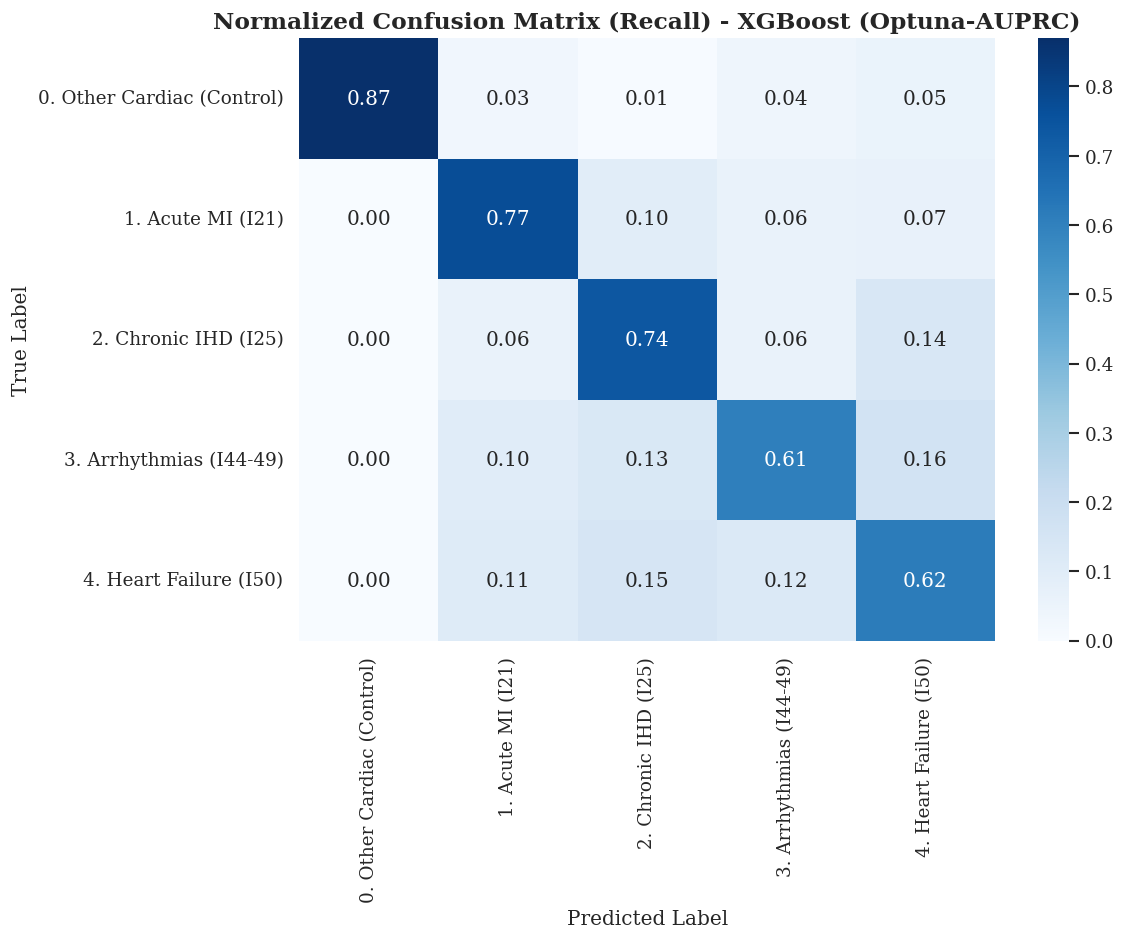

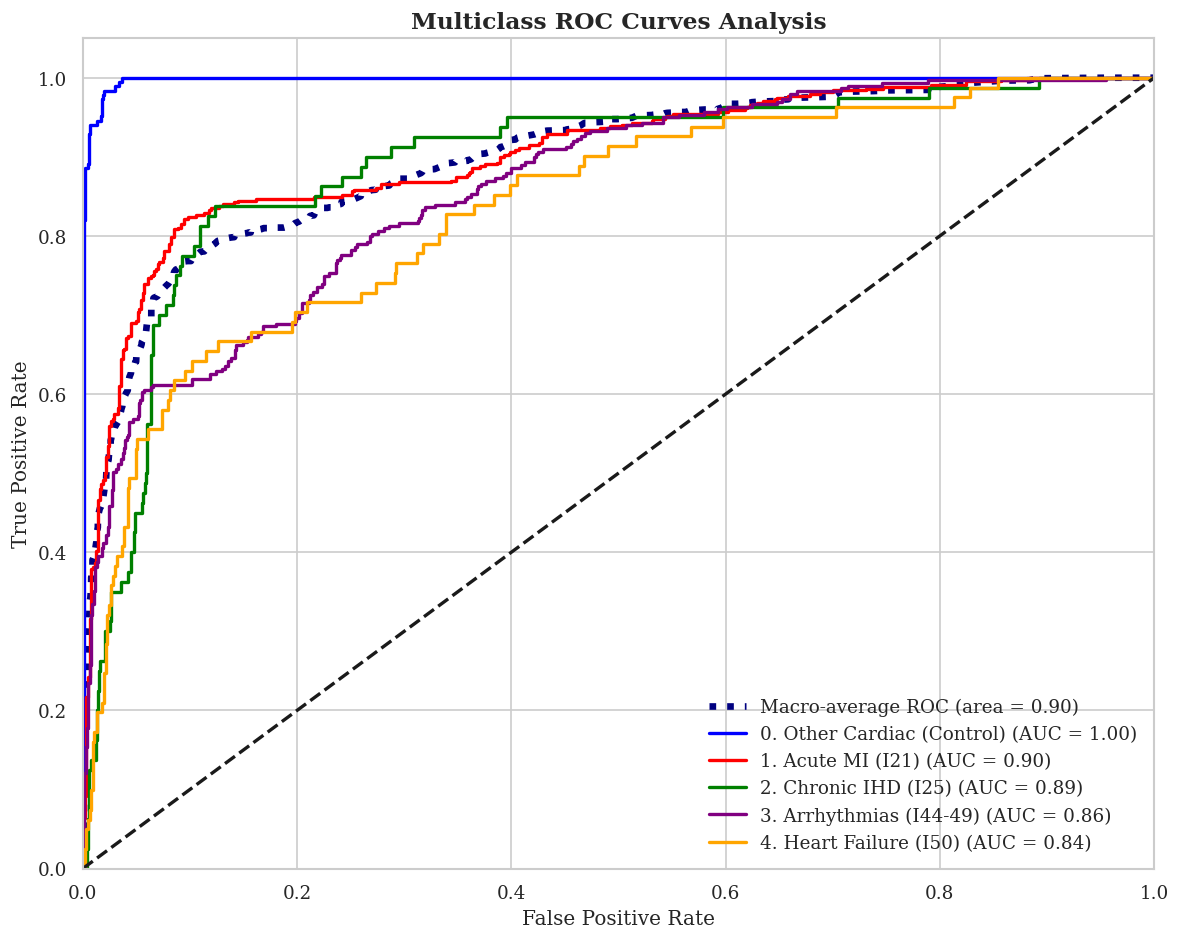

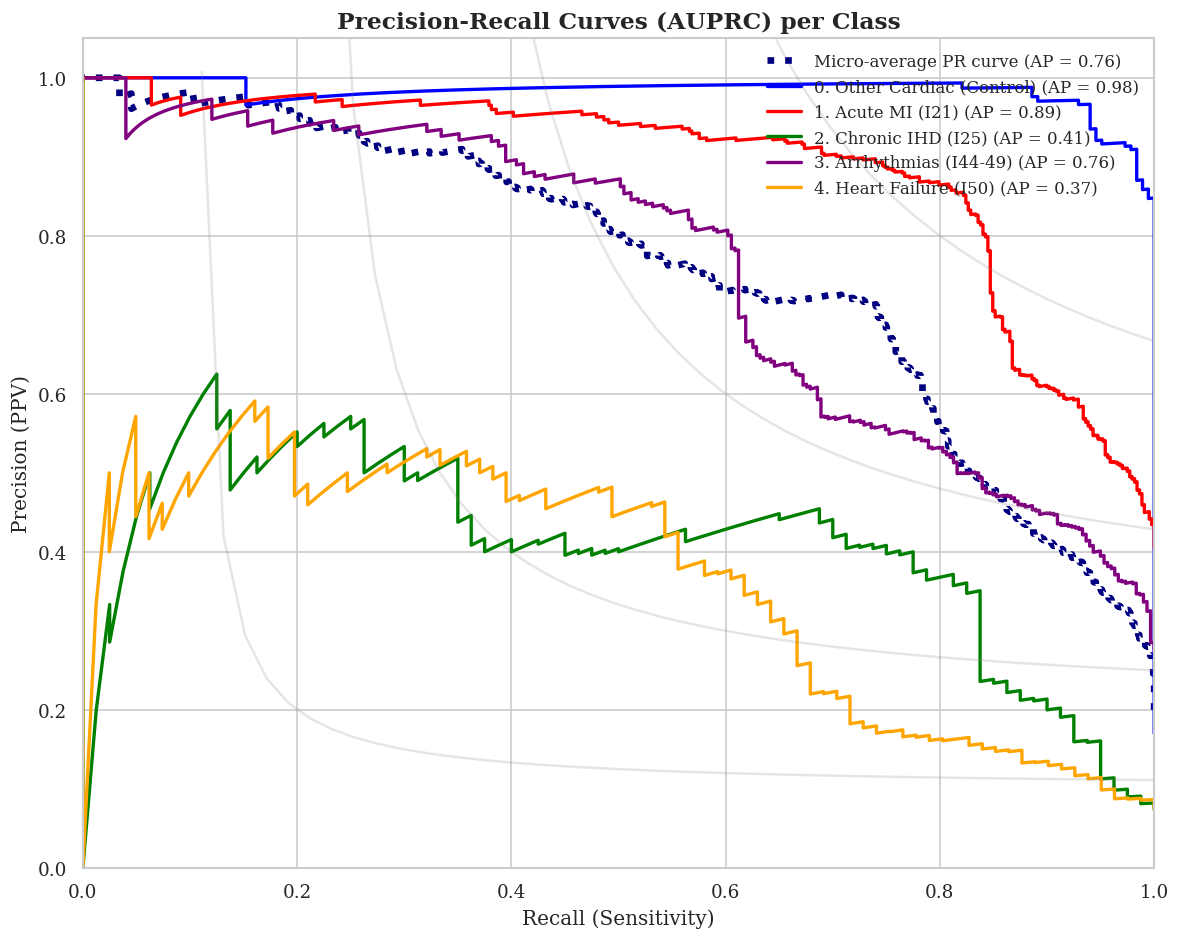

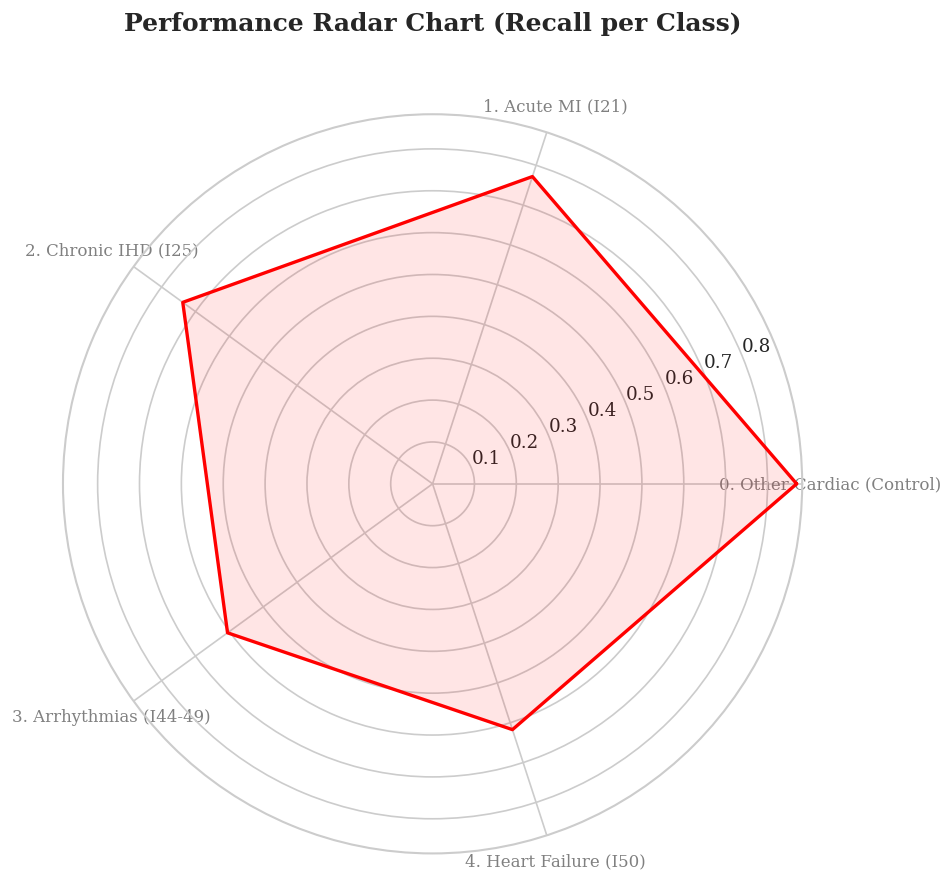

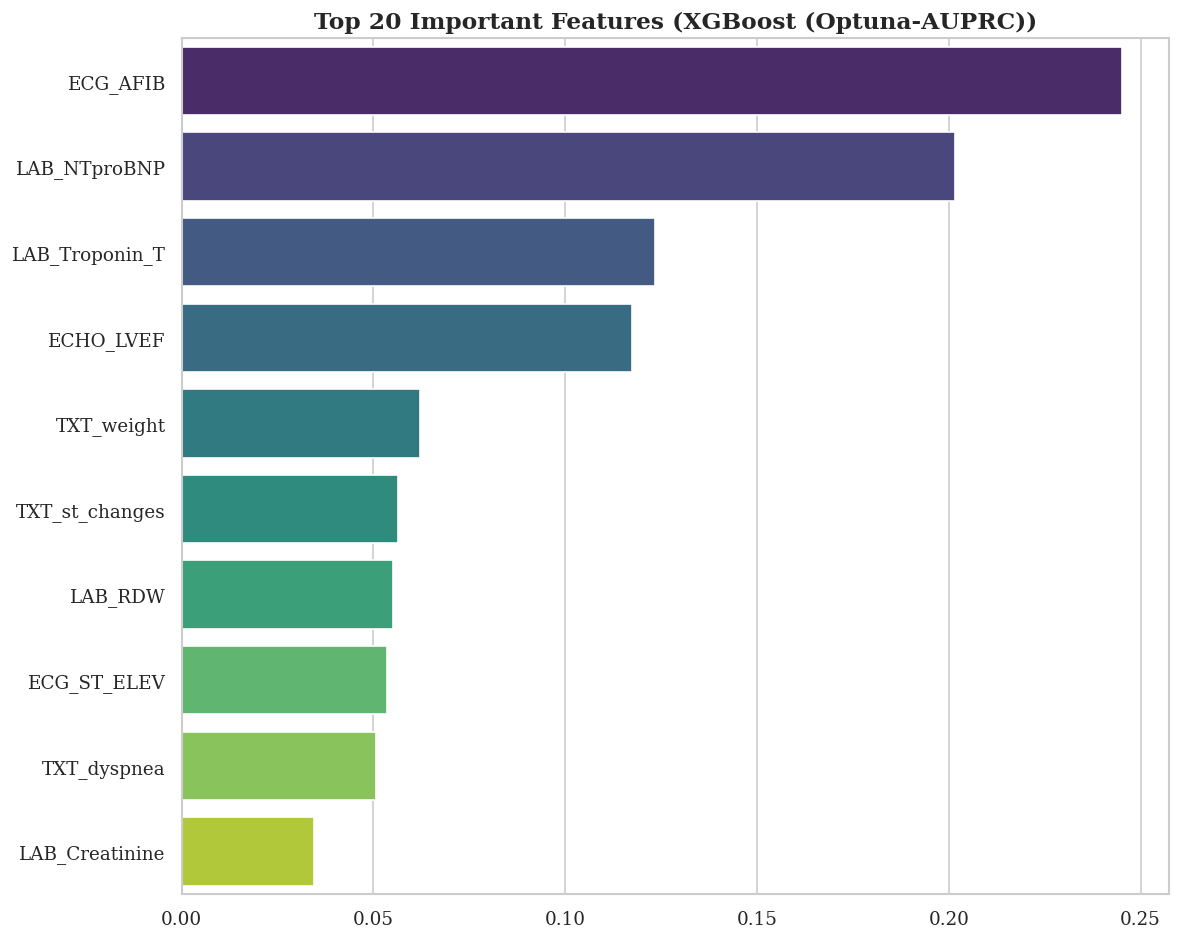

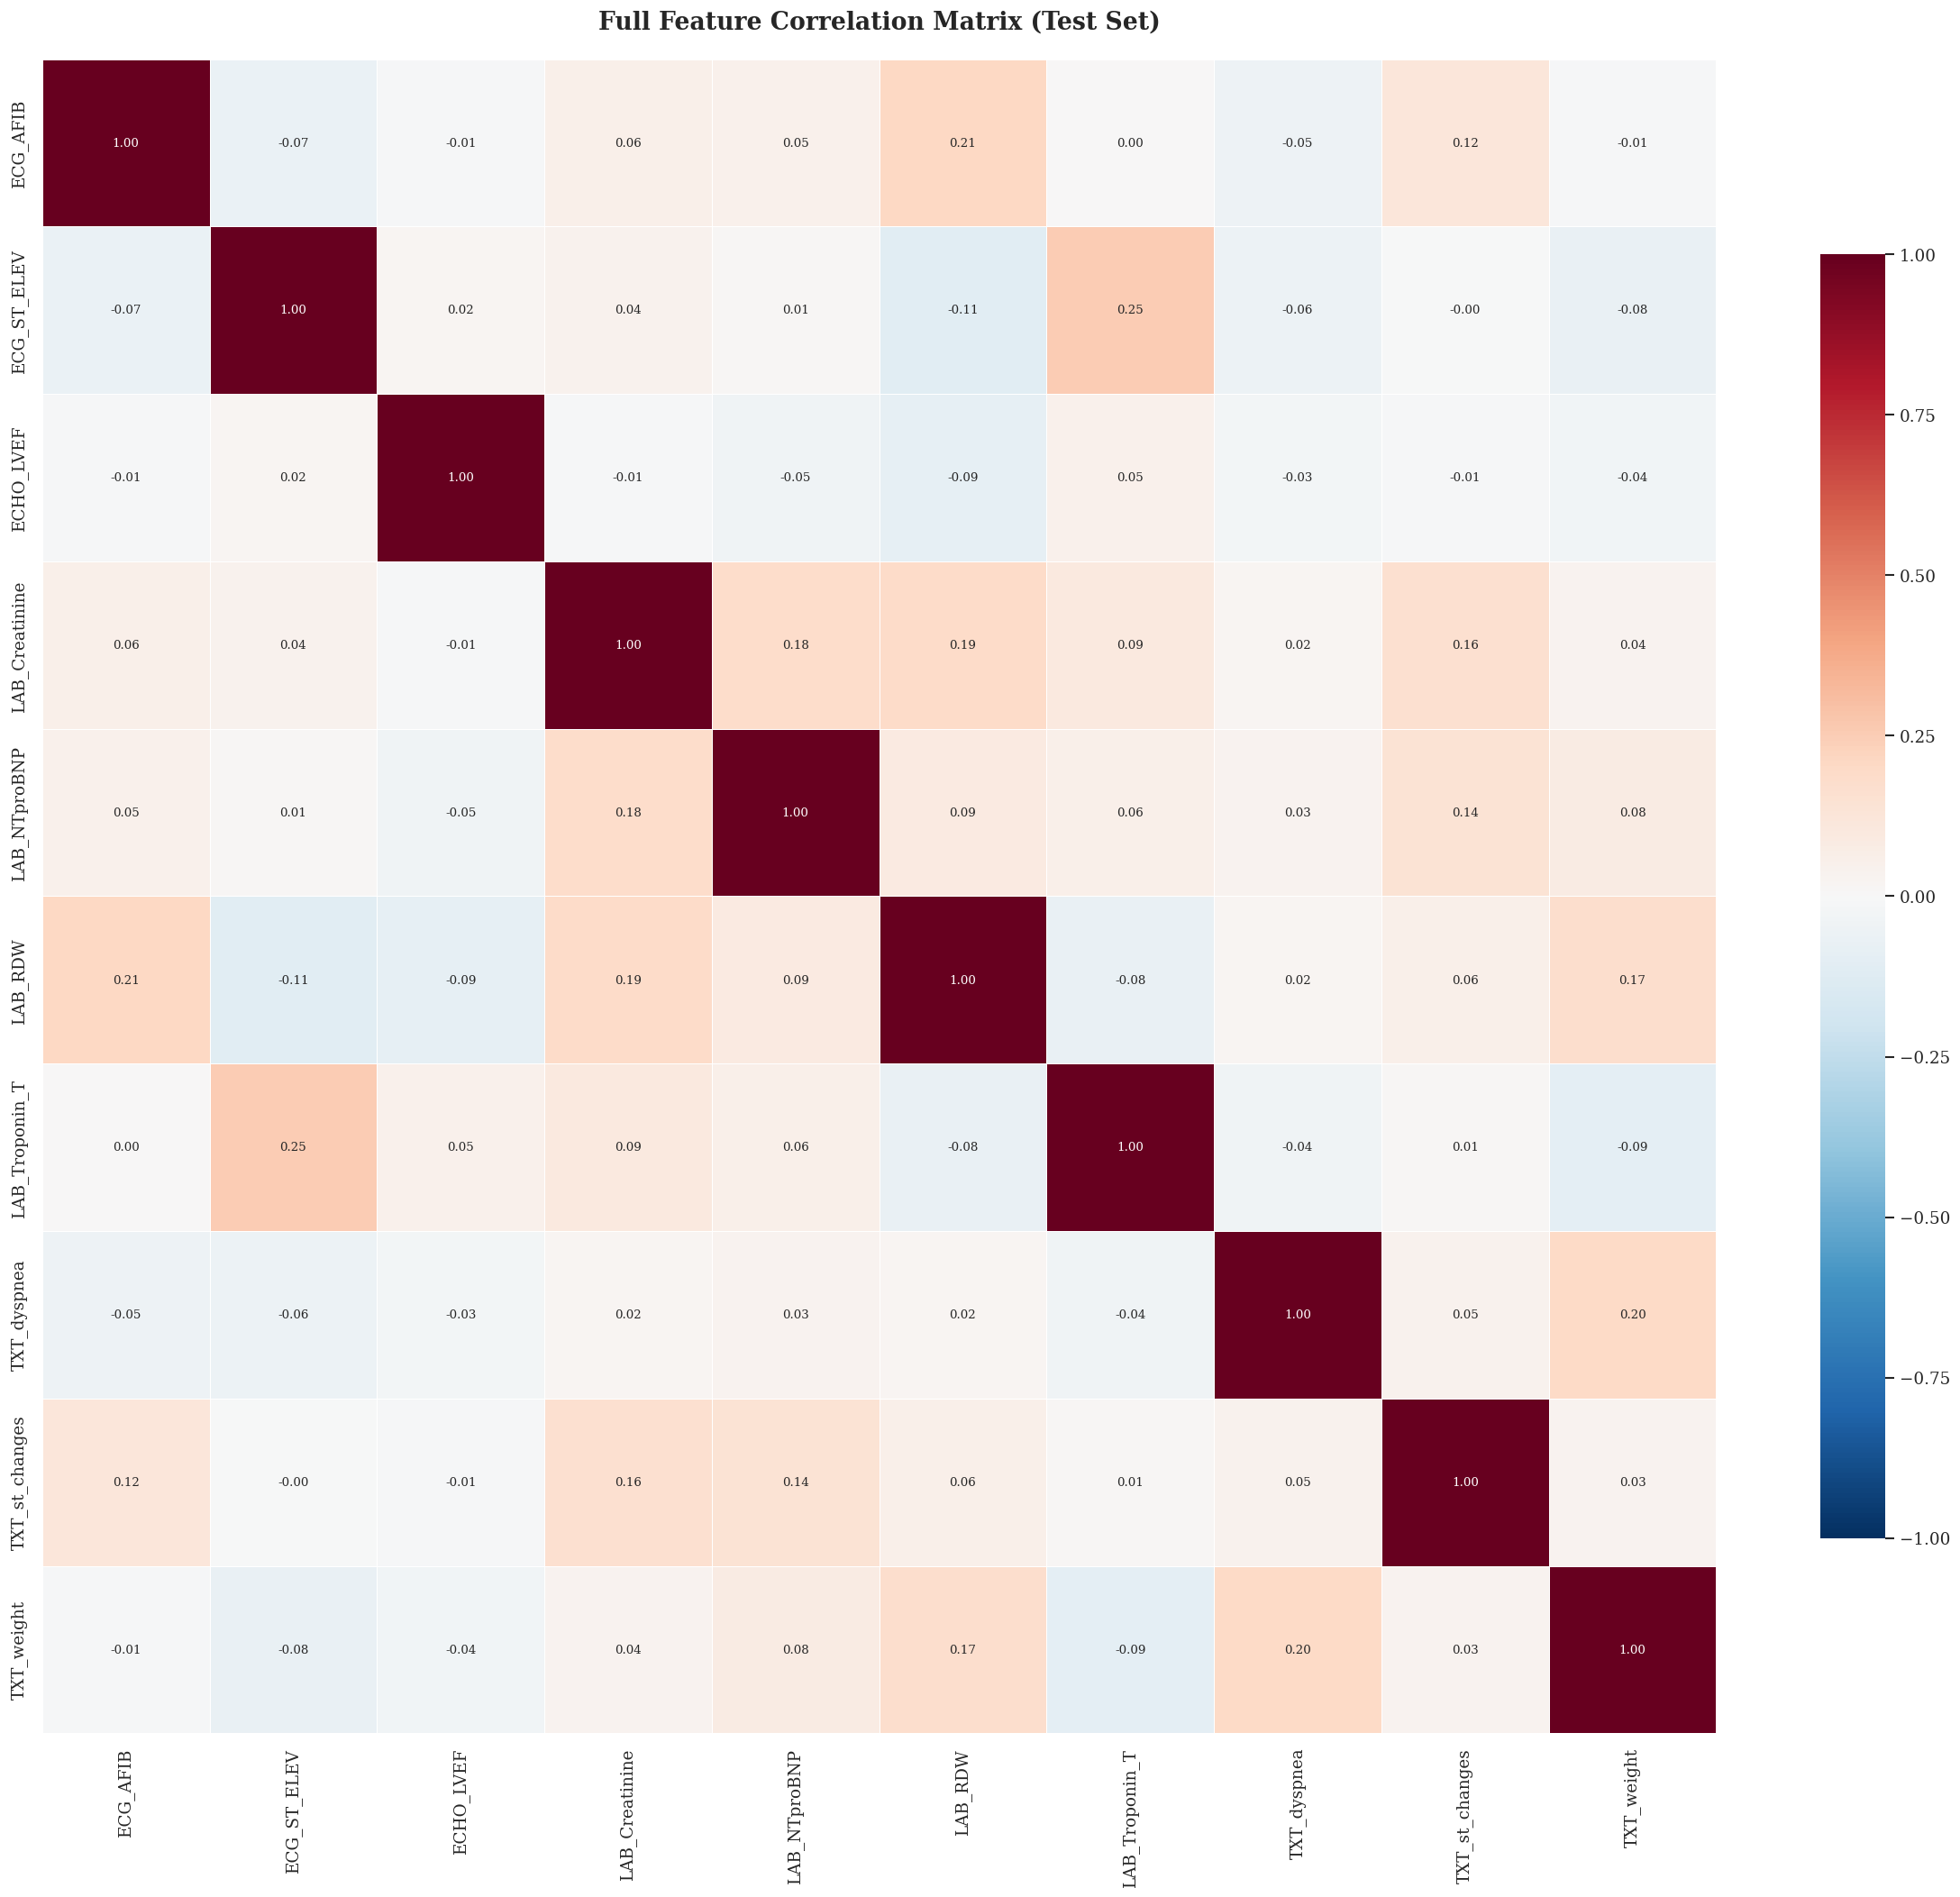

⏳ Đang tính toán SHAP Values...
   -> Đang tính toán ma trận SHAP (có thể mất vài giây)...
   🔹 Vẽ SHAP Global Summary (Bar Chart)...


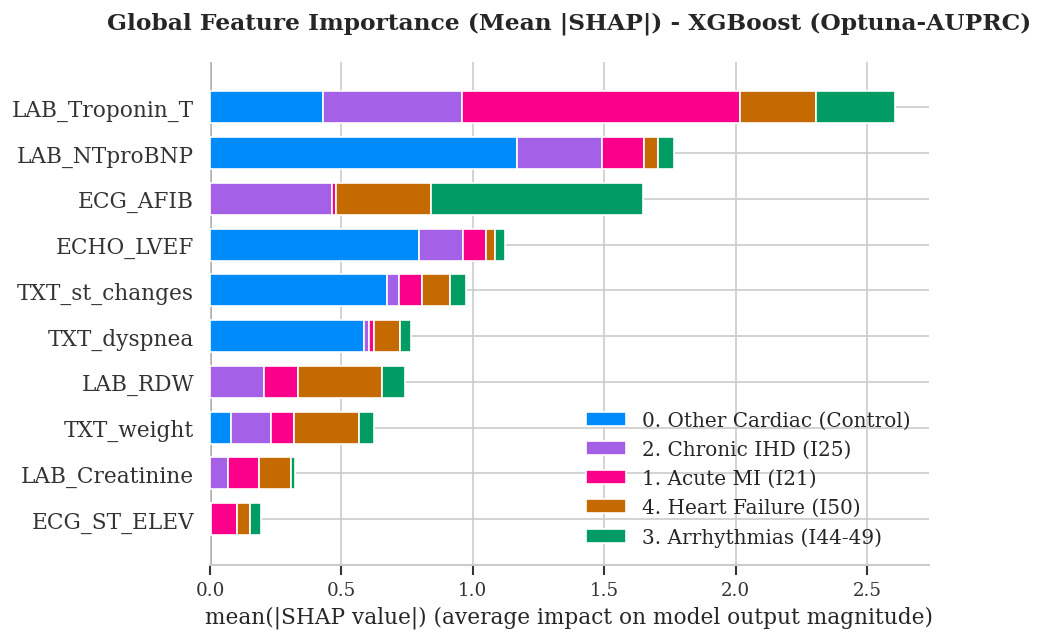

   -> Detected Binary/Single SHAP array.


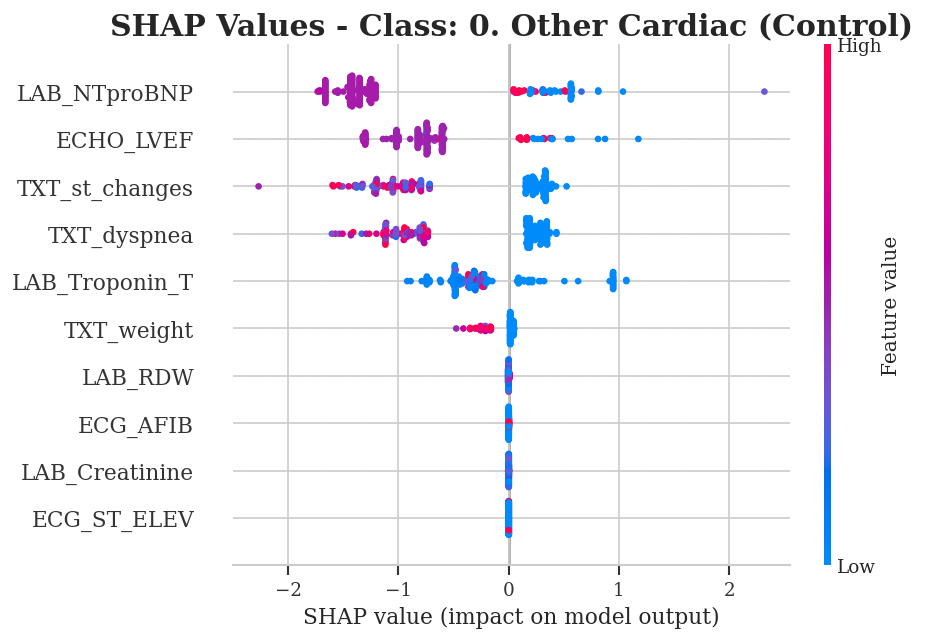

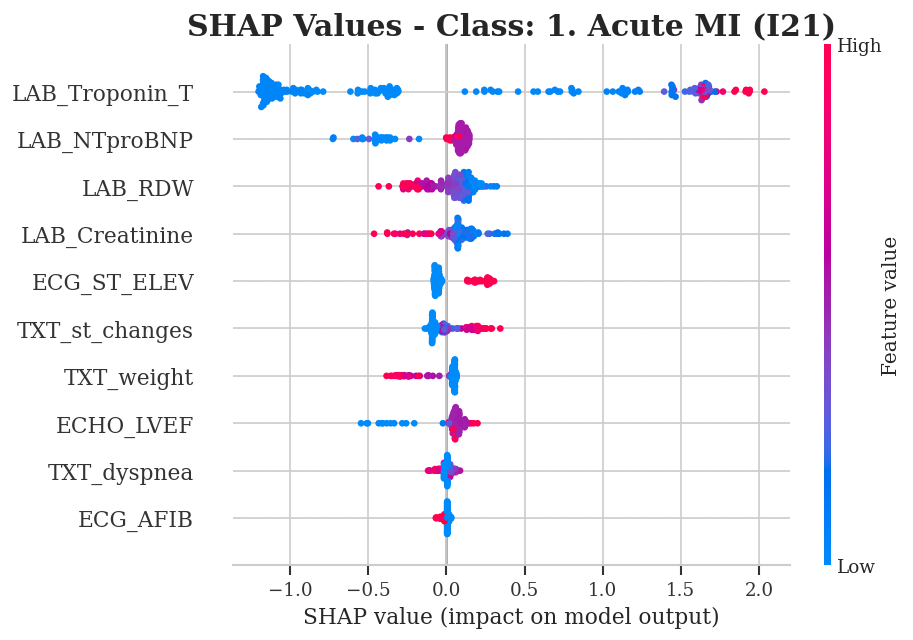

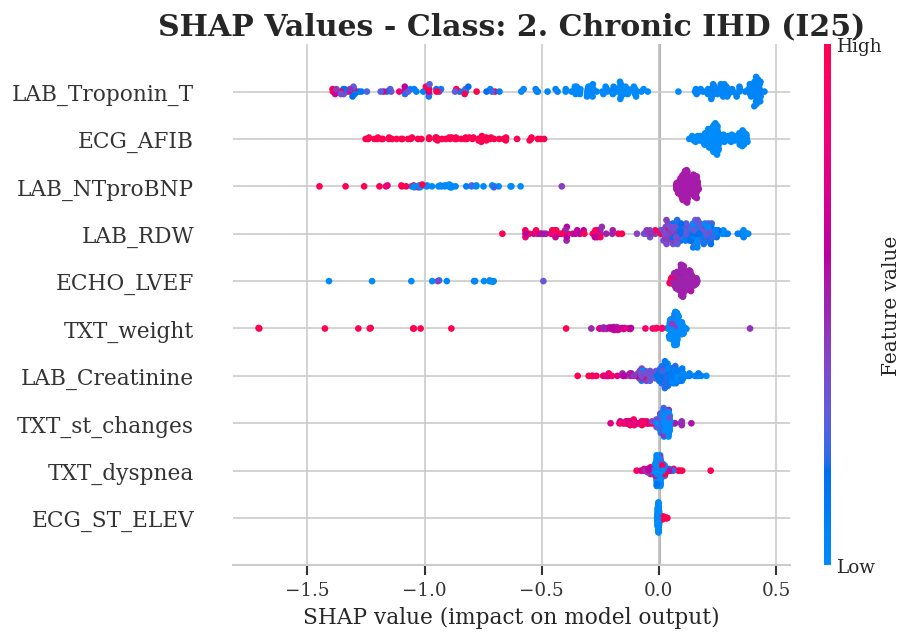

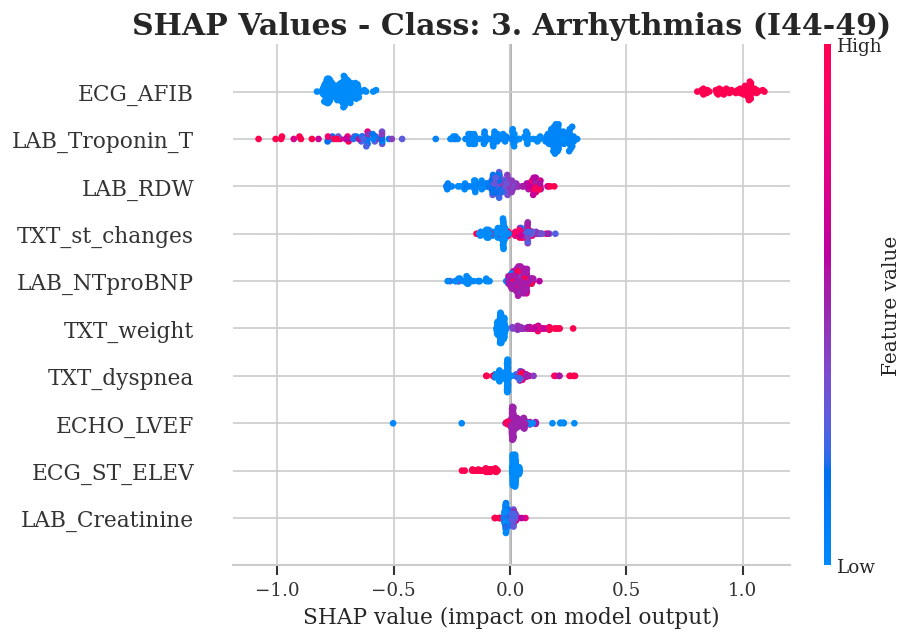

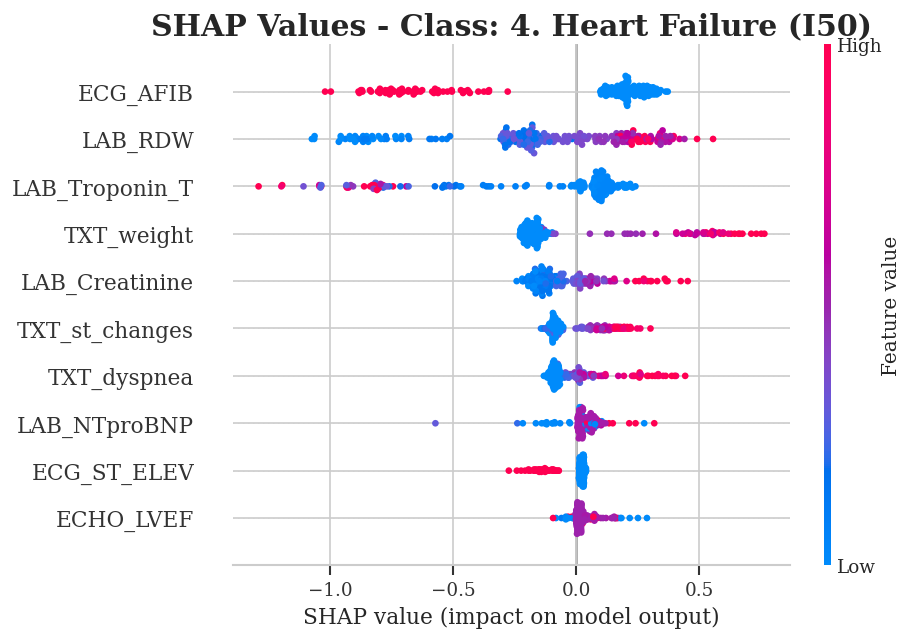


✅ Đã hoàn tất.


In [ ]:
# @title BLOCK 9: TRAINING (XGBOOST-OPTUNA) - WEIGHTED AUPRC (PIPELINE 6)
# =============================================================================
# BLOCK 9: FINAL TRAINING - EVALUATION - EXPLAINABILITY
# (Structure preserved from original code - Input data from Pipeline 6)
# =============================================================================

!pip install imbalanced-learn optuna shap lightgbm xgboost seaborn pandas numpy matplotlib scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import xgboost as xgb
import shap
import pickle
import os
import warnings
import optuna
from math import pi
from itertools import cycle
from collections import Counter

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score, recall_score,
                             precision_score, average_precision_score, classification_report,
                             confusion_matrix, roc_curve, auc, matthews_corrcoef, precision_recall_curve)
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.utils.class_weight import compute_sample_weight

# --- SCIENTIFIC PUBLICATION STYLE CONFIGURATION ---
warnings.filterwarnings('ignore')

# 1. OPTUNA LOG
optuna.logging.set_verbosity(optuna.logging.INFO)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['figure.dpi'] = 120

# 1. INPUT PATH CONFIGURATION (PIPELINE 6)
# =============================================================================
BASE_PATH_EXT = "/content/drive/MyDrive/MIMIC DATASET/mimic-iv-ext-cardiac-disease"
SAVE_DIR      = "/content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN"

PATH_TRAIN_MAIN = os.path.join(SAVE_DIR, "pipeline6_READY_TRAIN_MAIN.pkl")
PATH_TEST_EXT   = os.path.join(SAVE_DIR, "pipeline6_READY_VALIDATE_EXTERNAL.pkl")

# =============================================================================
# 1. UTILITY FUNCTIONS (BIOMEDICAL METRICS CALCULATOR)
# =============================================================================
def calculate_comprehensive_metrics(y_true, y_pred, y_proba, classes):
    """Tính toán tất cả các chỉ số quan trọng cho Y tế"""
    res = {}
    res['Accuracy'] = accuracy_score(y_true, y_pred)
    res['MCC'] = matthews_corrcoef(y_true, y_pred)

    # --- ROC AUC ---
    try:
        res['Macro AUC'] = roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro')
        res['Micro AUC'] = roc_auc_score(y_true, y_proba, multi_class='ovr', average='micro')
    except:
        res['Macro AUC'] = 0.5
        res['Micro AUC'] = 0.5

    # --- F1 & Recall ---
    res['Macro F1'] = f1_score(y_true, y_pred, average='macro')
    res['Micro F1'] = f1_score(y_true, y_pred, average='micro')
    res['Macro Recall'] = recall_score(y_true, y_pred, average='macro')
    res['Micro Recall'] = recall_score(y_true, y_pred, average='micro')

    # --- [FIXED] AUPRC CALCULATION ---
    n_classes = y_proba.shape[1]
    y_true_onehot = label_binarize(y_true, classes=range(n_classes))

    # Handle binary edge case in multi-class framework
    if n_classes == 2 and y_true_onehot.shape[1] == 1:
        y_true_onehot = np.hstack((1 - y_true_onehot, y_true_onehot))

    try:
        res['Macro AUPRC'] = average_precision_score(y_true_onehot, y_proba, average='macro')
        res['Micro AUPRC'] = average_precision_score(y_true_onehot, y_proba, average='micro')
    except Exception as e:
        print(f"⚠️ AUPRC Error: {e}")
        res['Macro AUPRC'] = 0.0
        res['Micro AUPRC'] = 0.0

    return res

# =============================================================================
# 2. CLASS: BIOMEDICAL MODEL SUITE
# =============================================================================
class BiomedicalModelSuite:
    def __init__(self, path_train, path_test):
        print(f"🔄 [INIT] Đang tải dữ liệu từ Ô 8 (Pipeline 6)...")
        print(f" 📥 Train Path: {path_train}")
        print(f" 📥 Test Path : {path_test}")

        # 1. LOAD MAIN (TRAIN)
        if os.path.exists(path_train):
            with open(path_train, "rb") as f:
                data_train = pickle.load(f)
            self.X_train = data_train['X']
            self.y_train = data_train['y']
            self.feature_names = data_train['feature_names']
        else:
            raise FileNotFoundError(f"❌ Không tìm thấy file Train: {path_train}")

        # 2. LOAD EXTERNAL (TEST)
        if os.path.exists(path_test):
            with open(path_test, "rb") as f:
                data_test = pickle.load(f)
            self.X_test = data_test['X']
            self.y_test = data_test['y']
        else:
            raise FileNotFoundError(f"❌ Không tìm thấy file Test: {path_test}")

        print(f" ✅ Train size: {self.X_train.shape}")
        print(f" ✅ Test size : {self.X_test.shape}")

        if not hasattr(self, 'feature_names'):
            self.feature_names = [f"Feature_{i}" for i in range(self.X_train.shape[1])]

        # Encode Labels
        self.le = LabelEncoder()
        self.y_train_enc = self.le.fit_transform(self.y_train)
        self.y_test_enc = self.le.transform(self.y_test)
        self.classes = self.le.classes_ # Các label gốc [0, 1, 2, 5, 6]

        self.target_names = [
            '0. Other Cardiac (Control)',  # Index 0 (Gốc 0)
            '1. Acute MI (I21)',           # Index 1 (Gốc 1)
            '2. Chronic IHD (I25)',        # Index 2 (Gốc 2)
            '3. Arrhythmias (I44-49)',     # Index 3 (Gốc 5)
            '4. Heart Failure (I50)'       # Index 4 (Gốc 6)
        ]


        self.classes = np.unique(self.y_train_enc) # [0, 1, 2, 3, 4]
        self.n_classes = len(self.target_names)


        self.target_names_map = {}


        self.X_train_scaled = self.X_train
        self.X_test_scaled = self.X_test

        self.best_model = None
        self.best_model_name = ""
        self.best_test_f1 = 0 # Dùng để tracking best model theo AUPRC
        self.results_summary = []

        print(f"✅ Dữ liệu sẵn sàng. Classes ({self.n_classes}): {self.target_names}")

    # =========================================================================
    # LOGIC TRAINING & OPTUNA
    # =========================================================================

    def run_benchmark_with_optuna(self):
        """Chạy Benchmark đầy đủ: Cơ bản + Optuna (Tối ưu hóa XGBoost)"""
        print("\n🚀 [BENCHMARK] Bắt đầu chạy đua mô hình (5-Fold CV)...")


        models = [
            ('Logistic Regression', LogisticRegression(multi_class='ovr', max_iter=1000, class_weight='balanced', random_state=42)),
            ('Random Forest', RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=4)),
            ('LightGBM (Base)', lgb.LGBMClassifier(objective='multiclass', class_weight='balanced', n_estimators=150, n_jobs=4, random_state=42, verbose=-1)),
            ('XGBoost (Base)', xgb.XGBClassifier(objective='multi:softprob', num_class=self.n_classes, eval_metric='mlogloss', n_estimators=150, learning_rate=0.05, max_depth=4, n_jobs=4, random_state=42))
        ]


        for name, model in models:
            self._process_model(name, model)


        print("\n🧪 [OPTUNA] Đang tìm tham số tối ưu cho XGBoost (20 trials)...")
        self._run_optuna_xgboost()
        print("✅ Optuna Done.")

    def _run_optuna_xgboost(self):
        """Hàm tối ưu tham số XGBoost nhắm trực tiếp vào AUPRC"""

        def objective(trial):
            param = {
                'objective': 'multi:softprob',
                'num_class': self.n_classes,
                'eval_metric': 'mlogloss',
                'verbosity': 0,
                'n_jobs': 4,
                'random_state': 42,
                'tree_method': 'auto',

                # --- HYPERPARAMETER SEARCH SPACE ---
                'n_estimators': trial.suggest_int('n_estimators', 150, 400),
                'max_depth': trial.suggest_int('max_depth', 3, 8),
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),

                # Regularization
                'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
                'gamma': trial.suggest_float('gamma', 0.1, 5.0),
                'subsample': trial.suggest_float('subsample', 0.6, 0.9),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
                'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 10.0, log=True),
                'reg_lambda': trial.suggest_float('reg_lambda', 0.01, 10.0, log=True),
            }

            kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
            auprc_scores = []

            full_weights = compute_sample_weight('balanced', self.y_train_enc)
            X = self.X_train_scaled
            y = self.y_train_enc

            for train_idx, val_idx in kf.split(X, y):
                X_train_fold, X_val_fold = X[train_idx], X[val_idx]
                y_train_fold, y_val_fold = y[train_idx], y[val_idx]
                w_train_fold = full_weights[train_idx]

                model = xgb.XGBClassifier(**param)
                model.fit(X_train_fold, y_train_fold, sample_weight=w_train_fold)

                y_val_proba = model.predict_proba(X_val_fold)
                y_val_onehot = label_binarize(y_val_fold, classes=range(self.n_classes))

                try:
                    score = average_precision_score(y_val_onehot, y_val_proba, average='macro')
                except:
                    score = 0.5
                auprc_scores.append(score)

            return np.mean(auprc_scores)

        print("   -> Tuning for Macro AUPRC...")
        sampler = optuna.samplers.TPESampler(seed=42)
        study = optuna.create_study(direction='maximize', sampler=sampler)
        study.optimize(objective, n_trials=20, show_progress_bar=True)

        print(f"   -> Best AUPRC Params: {study.best_params}")

        best_params = study.best_params
        best_params.update({
            'objective': 'multi:softprob',
            'num_class': self.n_classes,
            'eval_metric': 'mlogloss',
            'verbosity': 0,
            'n_jobs': 4,
            'random_state': 42
        })

        model = xgb.XGBClassifier(**best_params)
        self._process_model('XGBoost (Optuna-AUPRC)', model)

    def _process_model(self, name, model):
        """Hàm xử lý chung cho mọi model: CV -> Train -> Test -> Store"""
        print(f"   🔹 Processing {name}...", end="")

        X_tr = self.X_train_scaled
        X_te = self.X_test_scaled


        sample_weights = compute_sample_weight(class_weight='balanced', y=self.y_train_enc)

        # 1. 5-Fold CV Score (F1 Macro)
        cv_scores = cross_val_score(model, X_tr, self.y_train_enc, cv=5, scoring='f1_macro', n_jobs=1)
        cv_mean = cv_scores.mean()

        # 2. Train Full
        try:
            model.fit(X_tr, self.y_train_enc, sample_weight=sample_weights)
        except TypeError:
            model.fit(X_tr, self.y_train_enc)

        # 3. Predict Test
        y_te_pred = model.predict(X_te)
        y_te_proba = model.predict_proba(X_te)

        # 4. Metrics
        metrics = calculate_comprehensive_metrics(self.y_test_enc, y_te_pred, y_te_proba, self.classes)
        gap = (cv_mean - metrics['Macro F1']) * 100

        self.results_summary.append({
            'Model': name,
            'CV F1 (Mean)': cv_mean,
            'Test F1': metrics['Macro F1'],
            'Test AUC': metrics['Macro AUC'],
            'Test AUPRC': metrics['Macro AUPRC'],
            'Gap (%)': gap
        })

        # Best Model
        if metrics['Macro AUPRC'] > self.best_test_f1:
             self.best_test_f1 = metrics['Macro AUPRC']
             self.best_model = model
             self.best_model_name = name

        print(f" Done. (AUPRC: {metrics['Macro AUPRC']:.4f})")

    def print_full_report(self):
        """In báo cáo Table 1 và Table 2"""

        # --- TABLE 1 ---
        summary_df = pd.DataFrame(self.results_summary).sort_values(by='Test F1', ascending=False)
        print(f"\n📊 [TABLE 1] BẢNG TỔNG HỢP HIỆU NĂNG CÁC MÔ HÌNH:")
        print(summary_df[['Model', 'CV F1 (Mean)', 'Test F1', 'Test AUC', 'Test AUPRC', 'Gap (%)']].round(4).to_string(index=False))

        # --- TABLE 2 ---
        print(f"\n📊 [TABLE 2] CHI TIẾT ĐÁNH GIÁ MÔ HÌNH TỐT NHẤT ({self.best_model_name}):")

        X_tr = self.X_train_scaled
        X_te = self.X_test_scaled

        y_tr_pred = self.best_model.predict(X_tr)
        y_tr_proba = self.best_model.predict_proba(X_tr)
        y_te_pred = self.best_model.predict(X_te)
        y_te_proba = self.best_model.predict_proba(X_te)

        tr_metrics = calculate_comprehensive_metrics(self.y_train_enc, y_tr_pred, y_tr_proba, self.classes)
        tr_metrics['Set'] = 'Final Train'
        te_metrics = calculate_comprehensive_metrics(self.y_test_enc, y_te_pred, y_te_proba, self.classes)
        te_metrics['Set'] = 'Final Test'

        df_detail = pd.DataFrame([tr_metrics, te_metrics])
        cols_order = ['Set', 'Accuracy', 'Macro AUC', 'Macro F1', 'Macro Recall', 'Macro AUPRC',
                      'Micro AUC', 'Micro F1', 'Micro Recall', 'MCC']
        print(df_detail[cols_order].round(4).to_string(index=False))

        # GAP CHECK
        gap = (tr_metrics['Macro F1'] - te_metrics['Macro F1']) * 100
        print(f"\n💡 GAP CHECK (Train vs Test): {gap:.2f}%")
        if gap < 15: print("   ✅ ĐẠT CHUẨN Q1 (Robust)")
        elif gap < 25: print("   ⚠️ CHẤP NHẬN ĐƯỢC")
        else: print("   ⚠️ CẢNH BÁO OVERFITTING")

        # CLASSIFICATION REPORT
        print(f"\n📄 CLASSIFICATION REPORT ({self.best_model_name}):")
        print(classification_report(self.y_test_enc, y_te_pred, target_names=self.target_names, digits=4))

    # =========================================================================
    # 3. VISUALIZATION
    # =========================================================================
    def plot_visualizations(self):
        print(f"\n📈 [VISUALIZATION] Đang vẽ 6 biểu đồ cho model: {self.best_model_name}")

        X_eval = self.X_test_scaled
        y_pred = self.best_model.predict(X_eval)
        y_proba = self.best_model.predict_proba(X_eval)
        y_test_bin = label_binarize(self.y_test_enc, classes=range(len(self.classes)))

        sns.set_context("notebook", font_scale=1.0)


        feature_names_list = list(self.feature_names)

        # 1. NORMALIZED CONFUSION MATRIX
        plt.figure(figsize=(10, 8))
        cm = confusion_matrix(self.y_test_enc, y_pred, normalize='true')
        sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                    xticklabels=self.target_names, yticklabels=self.target_names, cbar=True)
        plt.title(f'Normalized Confusion Matrix (Recall) - {self.best_model_name}', fontsize=14, fontweight='bold')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.tight_layout()
        plt.show()

        # 2. MULTICLASS ROC CURVES
        plt.figure(figsize=(10, 8))
        colors = cycle(['blue', 'red', 'green', 'purple', 'orange', 'cyan', 'brown'])
        all_fpr = np.unique(np.concatenate([roc_curve(y_test_bin[:, i], y_proba[:, i])[0] for i in range(len(self.classes))]))
        mean_tpr = np.zeros_like(all_fpr)
        for i in range(len(self.classes)):
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
            mean_tpr += np.interp(all_fpr, fpr, tpr)
        mean_tpr /= len(self.classes)
        roc_auc_macro = auc(all_fpr, mean_tpr)
        plt.plot(all_fpr, mean_tpr, label=f'Macro-average ROC (area = {roc_auc_macro:0.2f})', color='navy', linestyle=':', linewidth=4)
        for i, color in zip(range(len(self.classes)), colors):
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, color=color, lw=2, label=f'{self.target_names[i]} (AUC = {roc_auc:0.2f})')
        plt.plot([0, 1], [0, 1], 'k--', lw=2)
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Multiclass ROC Curves Analysis', fontsize=14, fontweight='bold')
        plt.legend(loc="lower right")
        plt.tight_layout()
        plt.show()

        # 2.5 MULTICLASS PRECISION-RECALL CURVES (AUPRC)
        plt.figure(figsize=(10, 8))
        precision_micro, recall_micro, _ = precision_recall_curve(y_test_bin.ravel(), y_proba.ravel())
        ap_micro = average_precision_score(y_test_bin, y_proba, average='micro')
        plt.plot(recall_micro, precision_micro, label=f'Micro-average PR curve (AP = {ap_micro:0.2f})', color='navy', linestyle=':', linewidth=4)

        colors = cycle(['blue', 'red', 'green', 'purple', 'orange', 'cyan', 'brown'])
        for i, color in zip(range(len(self.classes)), colors):
            precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
            ap = average_precision_score(y_test_bin[:, i], y_proba[:, i])
            plt.plot(recall, precision, color=color, lw=2, label=f'{self.target_names[i]} (AP = {ap:0.2f})')

        # Iso-F1 Curves
        f_scores = np.linspace(0.2, 0.8, num=4)
        for f_score in f_scores:
            x = np.linspace(0.01, 1)
            y = f_score * x / (2 * x - f_score)
            plt.plot(x[y >= 0], y[y >= 0], color='gray', alpha=0.2)

        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('Recall (Sensitivity)')
        plt.ylabel('Precision (PPV)')
        plt.title('Precision-Recall Curves (AUPRC) per Class', fontsize=14, fontweight='bold')
        plt.legend(loc="upper right", fontsize=10)
        plt.tight_layout()
        plt.show()

        # 3. PERFORMANCE RADAR
        recalls = recall_score(self.y_test_enc, y_pred, average=None)
        N = len(self.target_names)
        angles = [n / float(N) * 2 * pi for n in range(N)]
        angles += angles[:1]
        recalls = np.append(recalls, recalls[0])
        plt.figure(figsize=(8, 8))
        ax = plt.subplot(111, polar=True)
        plt.xticks(angles[:-1], self.target_names, color='grey', size=10)
        ax.plot(angles, recalls, linewidth=2, linestyle='solid', color='red', label="Recall")
        ax.fill(angles, recalls, 'red', alpha=0.1)
        plt.title('Performance Radar Chart (Recall per Class)', size=15, fontweight='bold', y=1.1)
        plt.show()

        # 4. TOP IMPORTANT FEATURES
        plt.figure(figsize=(10, 8))
        if hasattr(self.best_model, 'feature_importances_'):
            importances = self.best_model.feature_importances_
            indices = np.argsort(importances)[::-1][:20]
            sns.barplot(x=importances[indices], y=[self.feature_names[i] for i in indices], palette="viridis")
            plt.title(f'Top 20 Important Features ({self.best_model_name})', fontsize=14, fontweight='bold')
        elif hasattr(self.best_model, 'coef_'):
            importances = np.mean(np.abs(self.best_model.coef_), axis=0)
            indices = np.argsort(importances)[::-1][:20]
            sns.barplot(x=importances[indices], y=[self.feature_names[i] for i in indices], palette="viridis")
            plt.title('Top 20 Feature Coefficients (Mean Abs)', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

        # 5. CORRELATION MATRIX
        X_df = pd.DataFrame(self.X_test_scaled, columns=self.feature_names)
        plt.figure(figsize=(20, 18))
        corr = X_df.corr(method='pearson')
        sns.heatmap(corr, mask=None, annot=True, fmt=".2f", cmap='RdBu_r', center=0, vmax=1, vmin=-1,
                    square=True, linewidths=.5, cbar_kws={"shrink": .7}, annot_kws={"size": 8})
        plt.title('Full Feature Correlation Matrix (Test Set)', fontsize=16, fontweight='bold', pad=20)
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()

        # 6. SHAP VALUES SUMMARY (FULL PLOTS)
        print("⏳ Đang tính toán SHAP Values...")
        supported_tree_models = ["XGBoost", "LightGBM", "Random Forest"]
        is_supported = any(m in self.best_model_name for m in supported_tree_models)

        if is_supported:
            try:
                explainer = shap.TreeExplainer(self.best_model)
                if len(X_eval) > 200:
                    idx = np.random.choice(len(X_eval), 200, replace=False)
                    X_sample_array = X_eval[idx]
                else:
                    X_sample_array = X_eval

                X_sample_df = pd.DataFrame(X_sample_array, columns=feature_names_list)
                print("   -> Đang tính toán ma trận SHAP (có thể mất vài giây)...")
                shap_values = explainer.shap_values(X_sample_df)

                # PLOT 1: GLOBAL BAR SUMMARY
                print("   🔹 Vẽ SHAP Global Summary (Bar Chart)...")
                plt.figure(figsize=(12, 8))
                shap.summary_plot(
                    shap_values, X_sample_df, feature_names=feature_names_list,
                    class_names=self.target_names, plot_type="bar", show=False
                )
                plt.title(f"Global Feature Importance (Mean |SHAP|) - {self.best_model_name}", fontsize=14, fontweight='bold', pad=20)
                plt.tight_layout()
                plt.show()

                n_features_total = len(feature_names_list)
                dynamic_height = max(12, n_features_total * 0.5)
                dynamic_width = 14

                if isinstance(shap_values, list):
                    print(f"   -> Detected Multi-class SHAP (List of {len(shap_values)} arrays).")
                    for i, class_name in enumerate(self.target_names):
                        if i >= len(shap_values): break
                        print(f"   🔹 Vẽ SHAP Beeswarm cho lớp bệnh: {class_name}...")
                        plt.clf(); plt.close('all')
                        fig = plt.figure(figsize=(dynamic_width, dynamic_height))
                        class_shap_vals = shap_values[i]
                        shap.summary_plot(
                            class_shap_vals, X_sample_df, feature_names=feature_names_list,
                            plot_type="dot", max_display=n_features_total, show=False, alpha=0.8
                        )
                        plt.title(f"SHAP Values for Class: {class_name}\n(Phân tích tác động của biến số)", fontsize=18, fontweight='bold', pad=30)
                        plt.xlabel(f"SHAP value (Tác động lên khả năng mắc {class_name})", fontsize=14)
                        plt.tight_layout(); plt.show()
                else:
                    print(f"   -> Detected Binary/Single SHAP array.")
                    if len(shap_values.shape) == 3:
                        for i, class_name in enumerate(self.target_names):
                            if i >= shap_values.shape[2]: break
                            plt.clf(); plt.close('all')
                            fig = plt.figure(figsize=(dynamic_width, dynamic_height))
                            shap.summary_plot(
                                shap_values[:, :, i], X_sample_df, feature_names=feature_names_list,
                                plot_type="dot", max_display=n_features_total, show=False
                            )
                            plt.title(f"SHAP Values - Class: {class_name}", fontsize=18, fontweight='bold')
                            plt.tight_layout(); plt.show()
                    else:
                        plt.clf(); plt.close('all')
                        plt.figure(figsize=(dynamic_width, dynamic_height))
                        shap.summary_plot(
                            shap_values, X_sample_df, feature_names=feature_names_list,
                            plot_type="dot", max_display=n_features_total, show=False
                        )
                        plt.title(f"SHAP Values Impact (Binary Model)", fontsize=18, fontweight='bold')
                        plt.tight_layout(); plt.show()
            except Exception as e:
                print(f"⚠️ Lỗi khi vẽ SHAP: {str(e)}")
        else:
            print(f"⚠️ Model {self.best_model_name} không hỗ trợ TreeExplainer.")

# =============================================================================
# EXECUTION
# =============================================================================
if os.path.exists(PATH_TRAIN_MAIN) and os.path.exists(PATH_TEST_EXT):
    suite = BiomedicalModelSuite(path_train=PATH_TRAIN_MAIN, path_test=PATH_TEST_EXT)
    suite.run_benchmark_with_optuna()
    suite.print_full_report()
    suite.plot_visualizations()
    print("\n✅ Đã hoàn tất.")
else:
    print(f"❌ Không tìm thấy file dữ liệu từ Ô 8. Hãy kiểm tra lại đường dẫn: \n{PATH_TRAIN_MAIN}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 6.1 MB/s eta 0:00:00
🔄 [INIT] Đang tải dữ liệu từ Ô 8 (Pipeline 6)...
 📥 Train Path: /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_READY_TRAIN_MAIN.pkl
 📥 Test Path : /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_READY_VALIDATE_EXTERNAL.pkl
 ✅ Train size: (3679, 10)
 ✅ Test size : (1082, 10)
✅ Dữ liệu sẵn sàng. Classes (5): ['0. Other Cardiac (Control)', '1. Acute MI (I21)', '2. Chronic IHD (I25)', '3. Arrhythmias (I44-49)', '4. Heart Failure (I50)']

🚀 [BENCHMARK] Bắt đầu chạy đua mô hình (5-Fold CV)...
   🔹 Processing Logistic Regression...
      [CV LOG] Folds: [0.5795 0.5902 0.5957 0.5977 0.5682]
      [CV LOG] Mean F1: 0.5863 ± 0.0097 (95% CI: [0.5766, 0.5959])
      Done. (AUPRC: 0.5517)
   🔹 Processing Random Forest...
      [CV LOG] Folds: [0.6871 0.6886 0.717  0.73   0.6861]
      [CV LOG] Mean F1: 0.7017 ± 0.0160 (95% CI: [0.6858, 0.7177])
      Done. (AUPRC: 0.6456)
   🔹 Processing Lig

[I 2026-05-13 22:09:22,204] A new study created in memory with name: no-name-07837e23-121d-4db3-a694-08ea75ccc789


      Done. (AUPRC: 0.6776)

🧪 [OPTUNA] Đang tìm tham số tối ưu cho XGBoost (20 trials)...
   -> Tuning for Macro AUPRC...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-05-13 22:09:24,946] Trial 0 finished with value: 0.7336098992458842 and parameters: {'n_estimators': 244, 'max_depth': 8, 'learning_rate': 0.05395030966670229, 'min_child_weight': 6, 'gamma': 0.864491338167939, 'subsample': 0.6467983561008608, 'colsample_bytree': 0.6174250836504598, 'reg_alpha': 3.9676050770529883, 'reg_lambda': 0.6358358856676253}. Best is trial 0 with value: 0.7336098992458842.
[I 2026-05-13 22:09:31,472] Trial 1 finished with value: 0.7276593376481477 and parameters: {'n_estimators': 327, 'max_depth': 3, 'learning_rate': 0.09330606024425668, 'min_child_weight': 9, 'gamma': 1.1404616423235534, 'subsample': 0.6545474901621302, 'colsample_bytree': 0.6550213529560301, 'reg_alpha': 0.08179499475211674, 'reg_lambda': 0.3752055855124282}. Best is trial 0 with value: 0.7336098992458842.
[I 2026-05-13 22:09:34,338] Trial 2 finished with value: 0.7327518001715478 and parameters: {'n_estimators': 258, 'max_depth': 4, 'learning_rate': 0.04091220574443785, 'min_child_wei

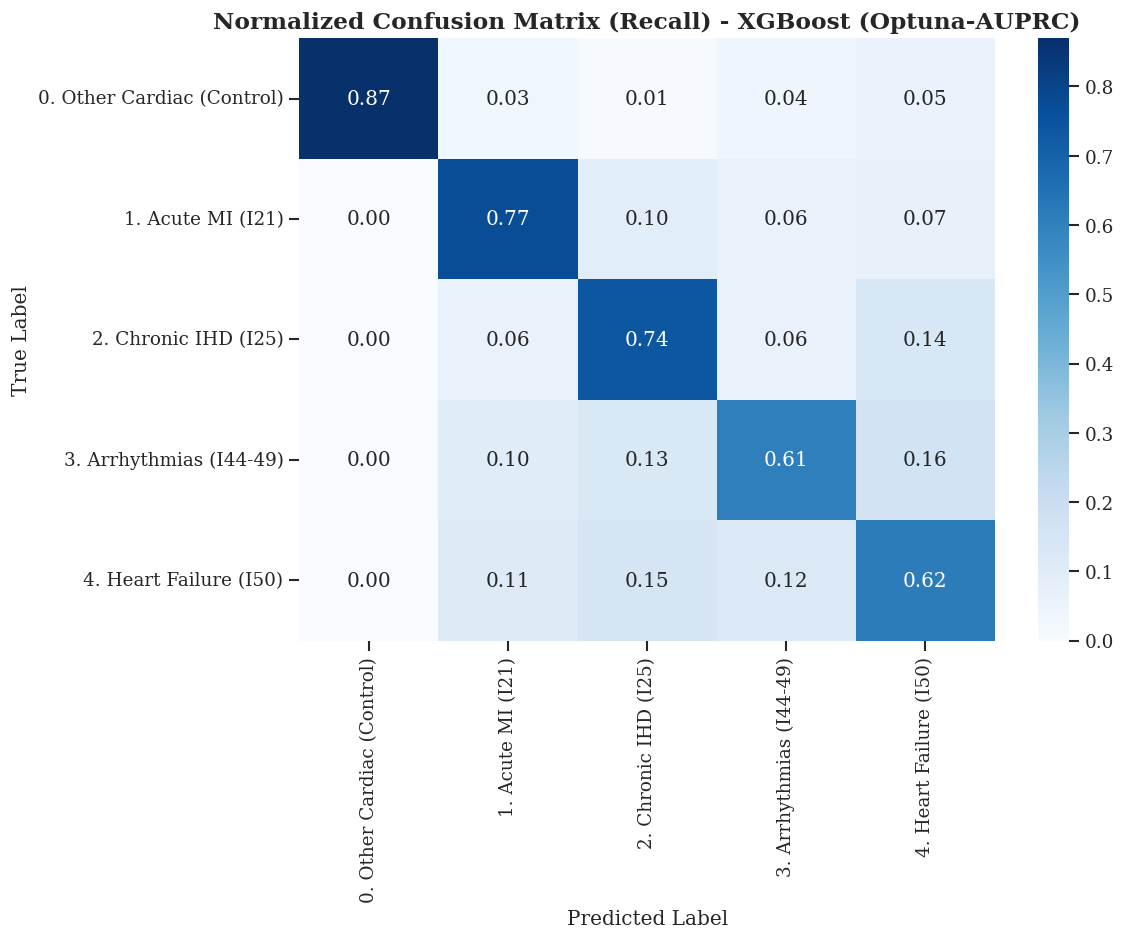

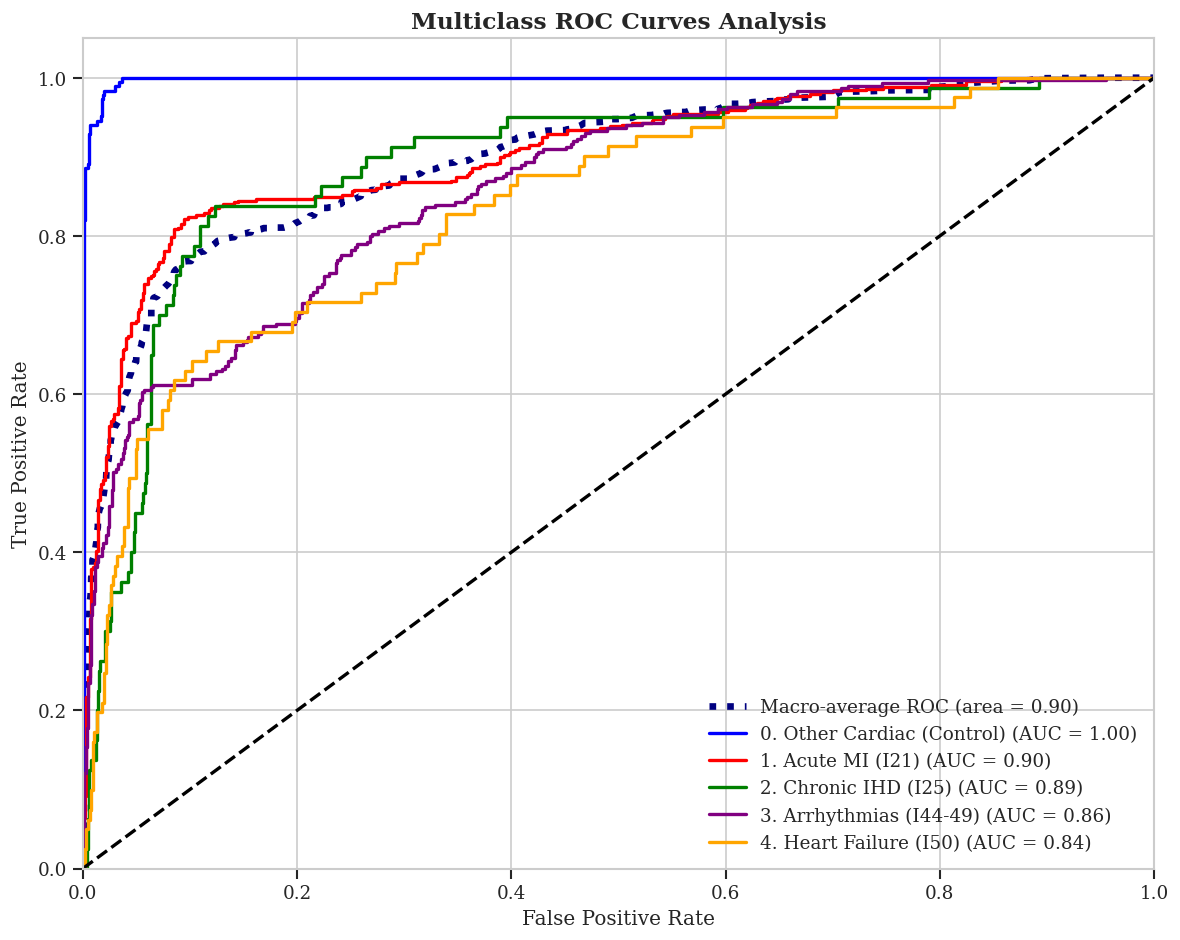

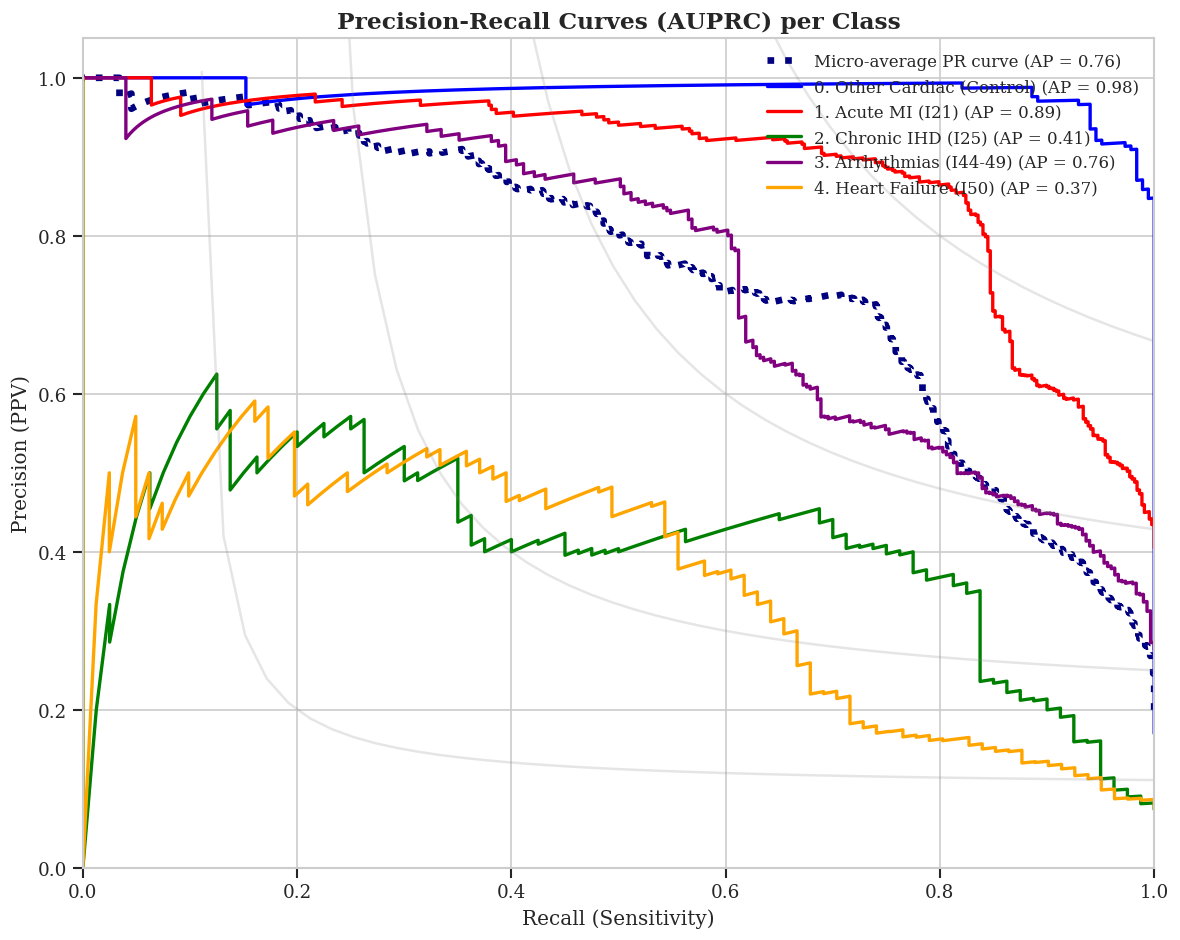

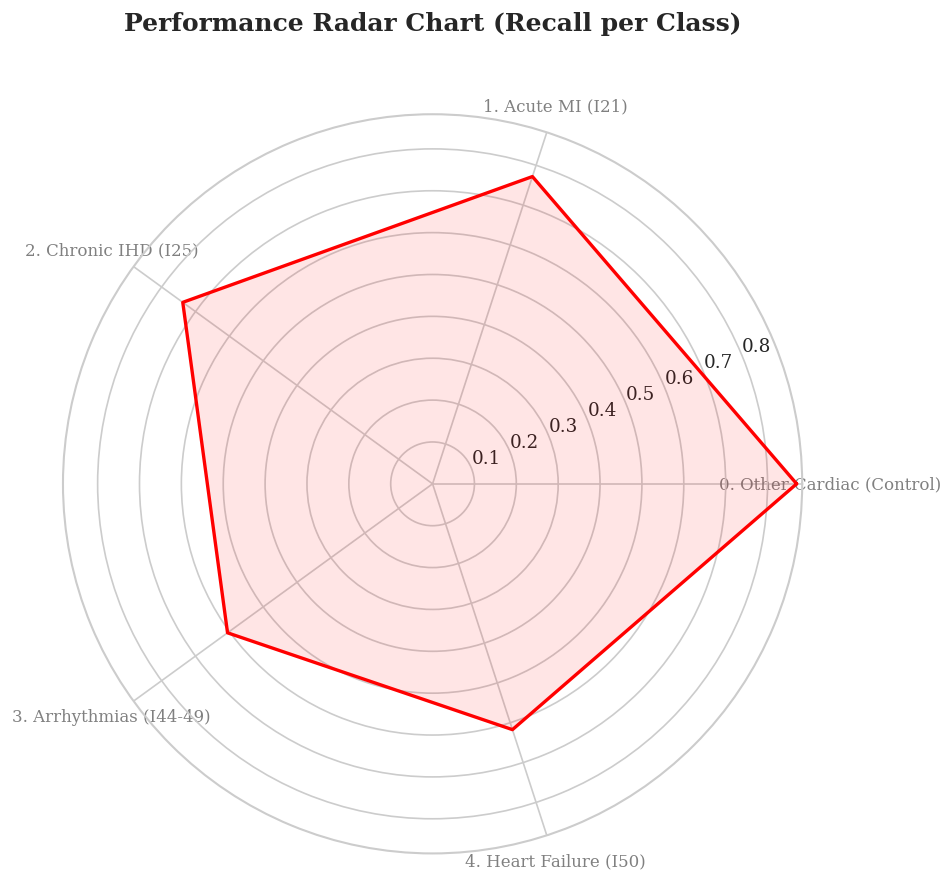

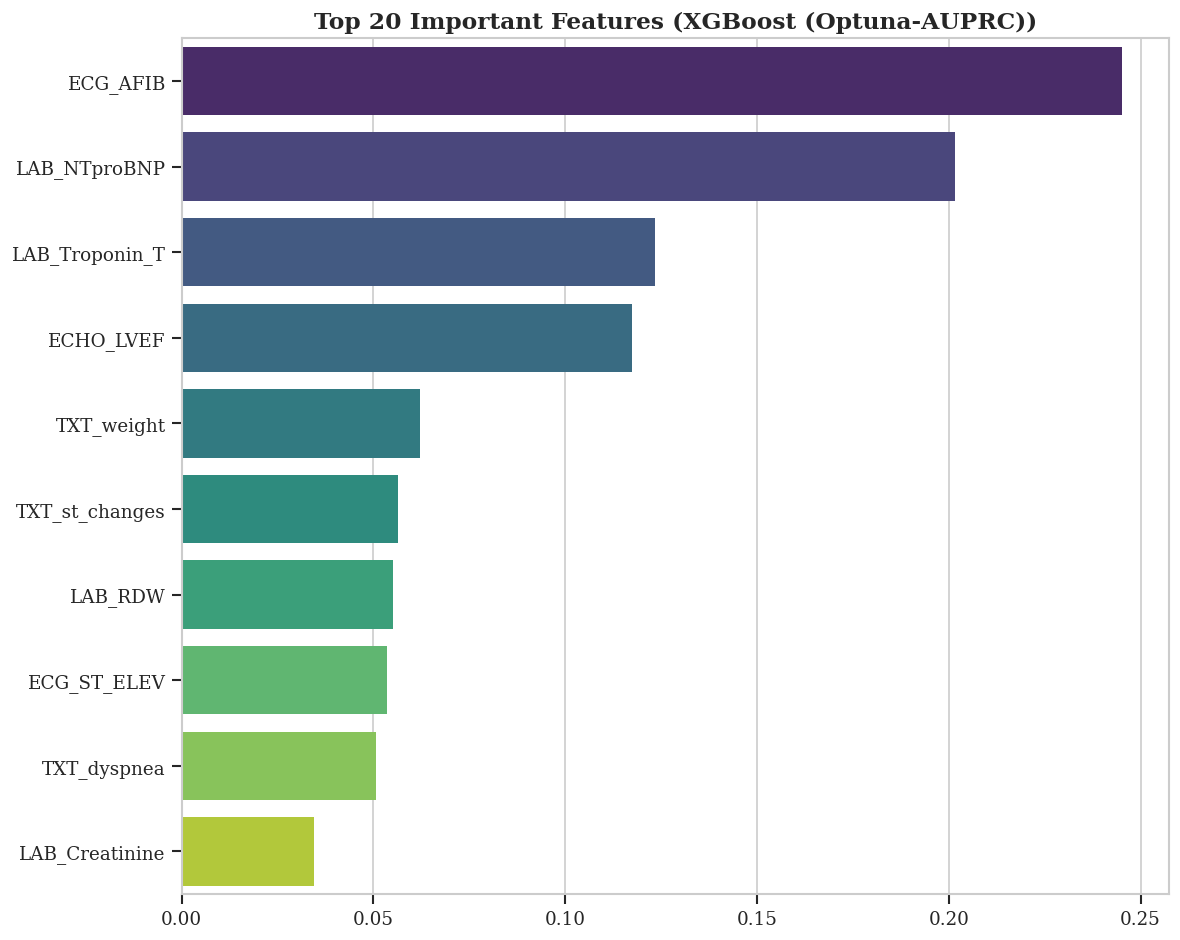

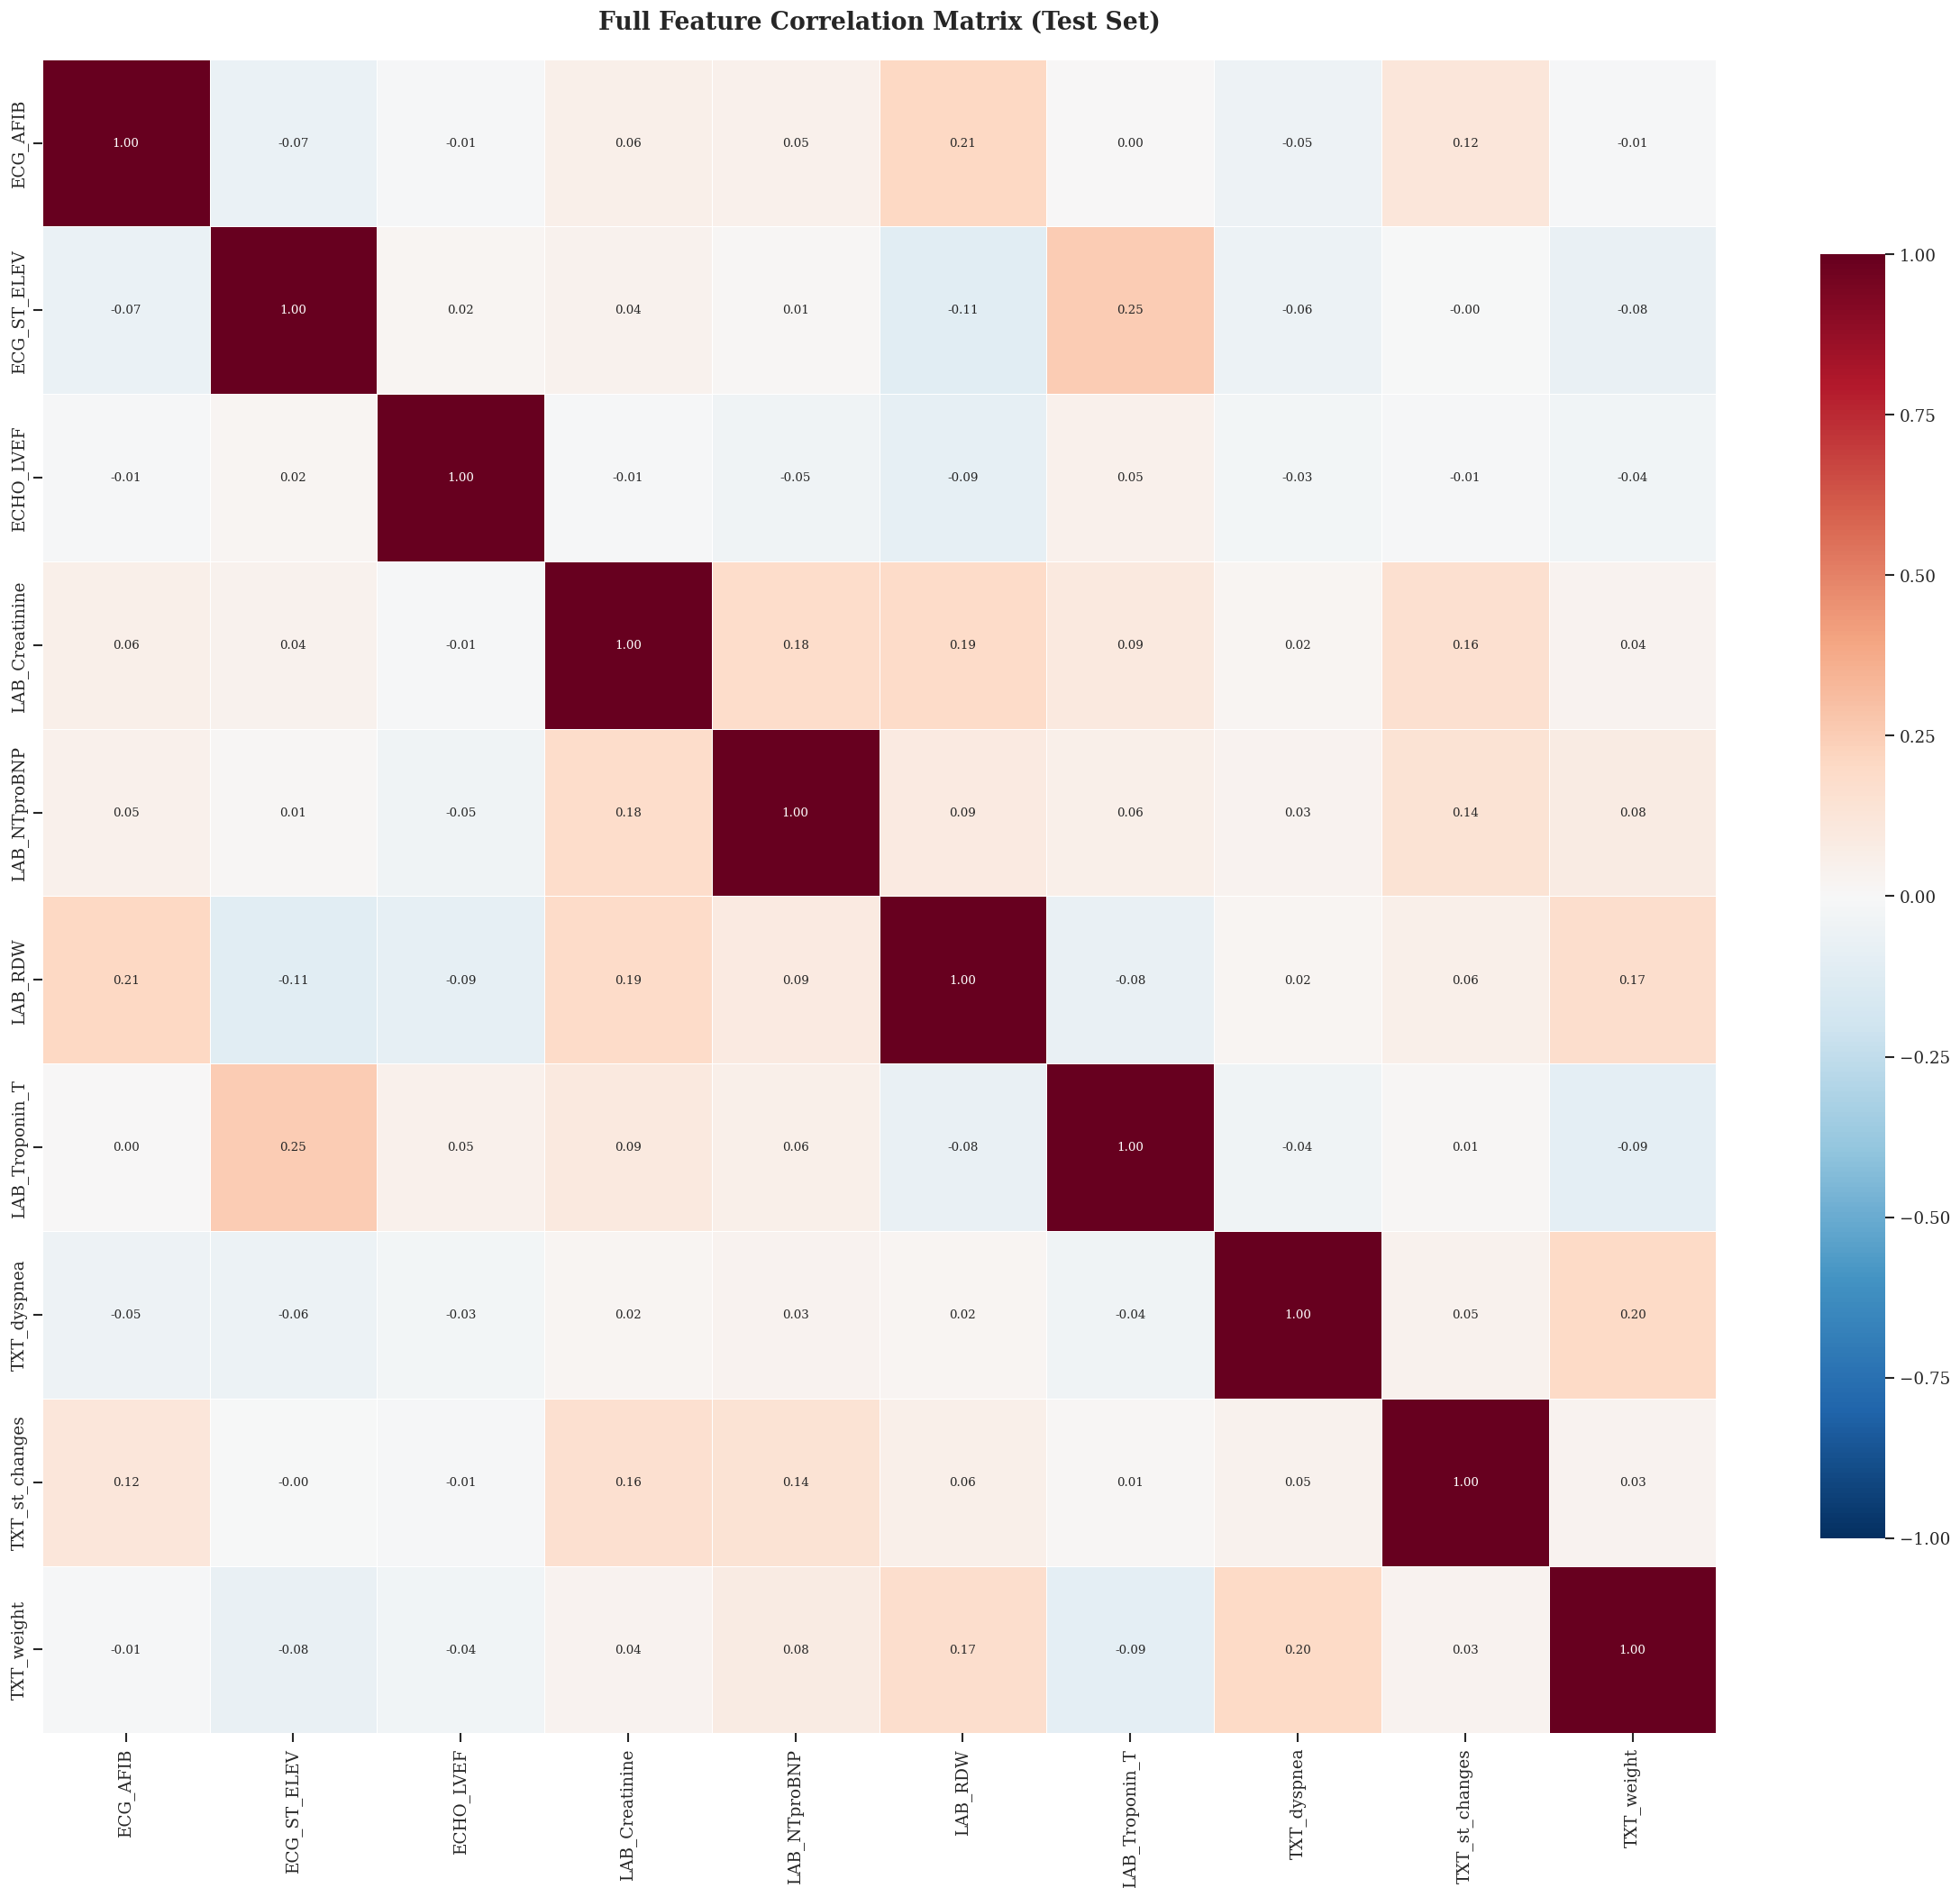

⏳ Đang tính toán SHAP Values...
   -> Đang tính toán ma trận SHAP (có thể mất vài giây)...
   🔹 Vẽ SHAP Global Summary (Bar Chart)...


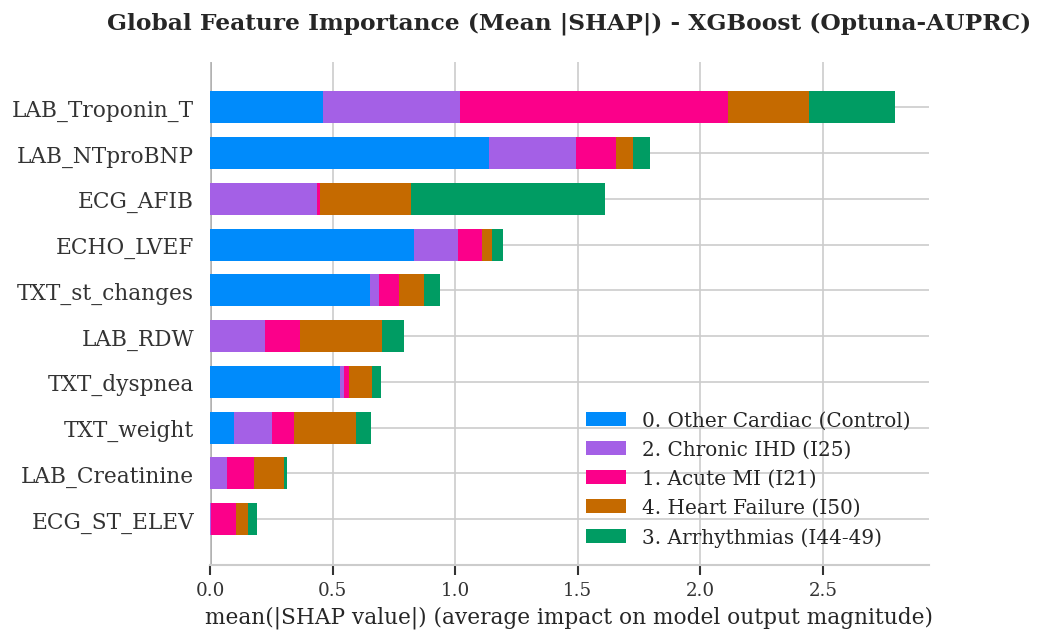

   -> Detected Binary/Single SHAP array.


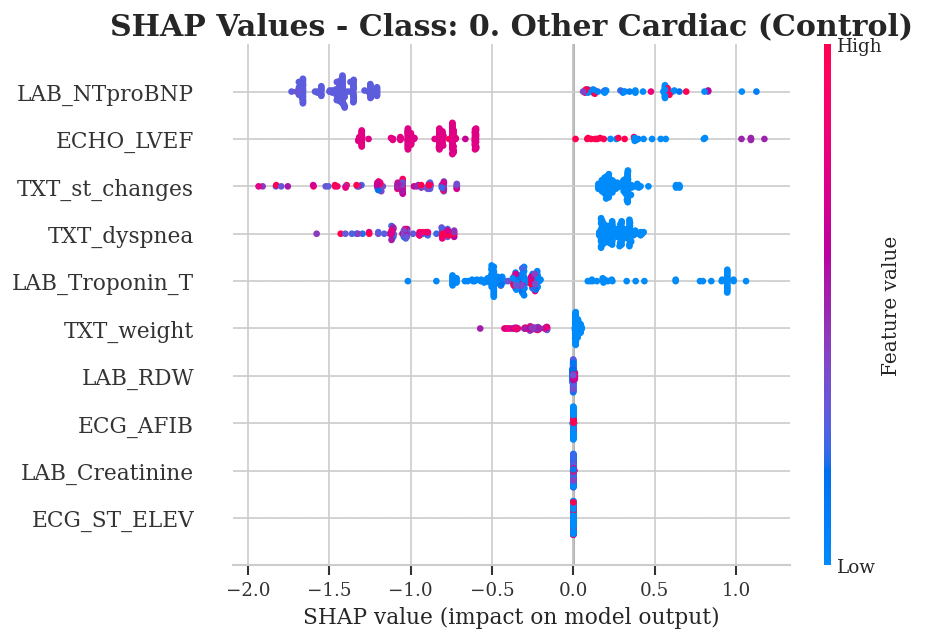

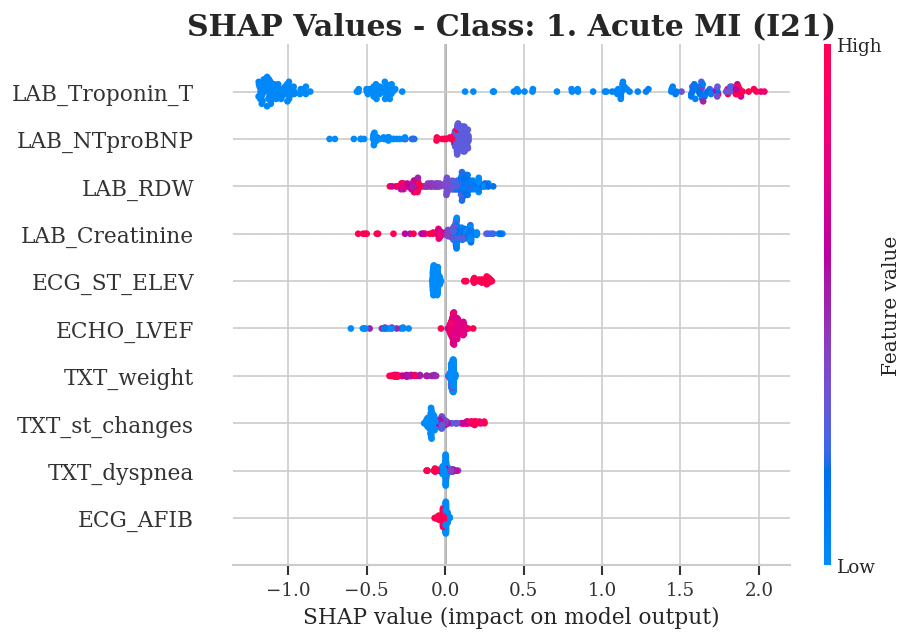

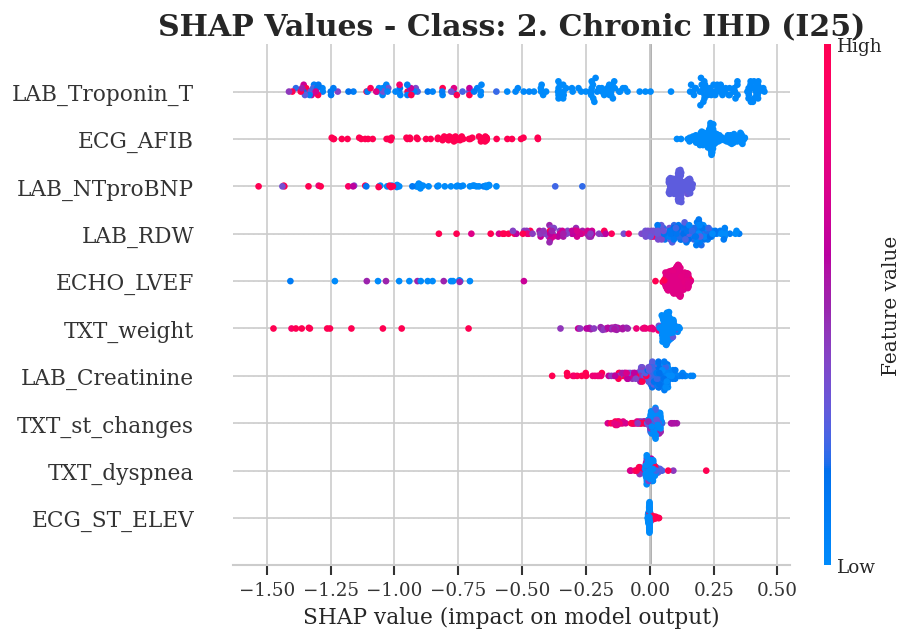

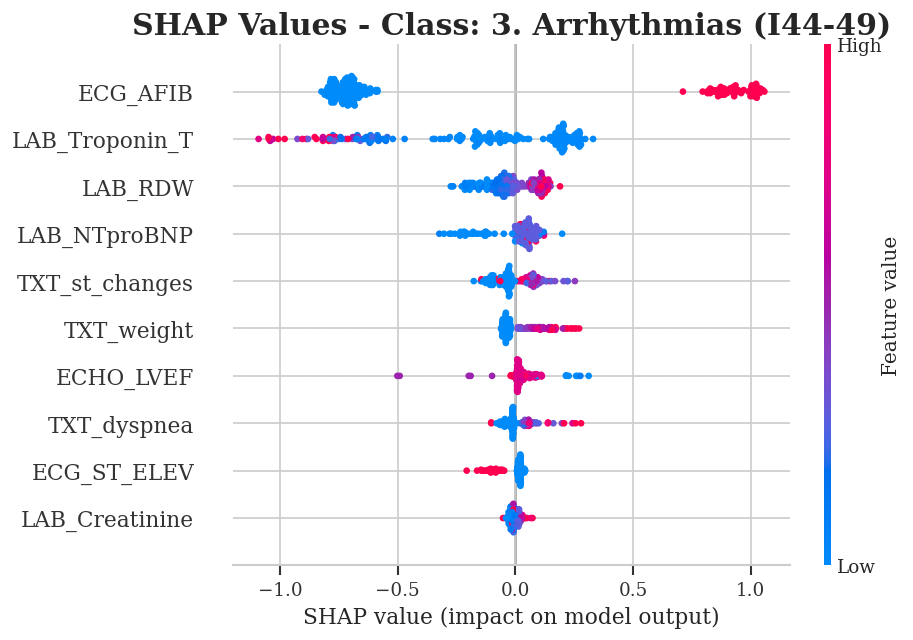

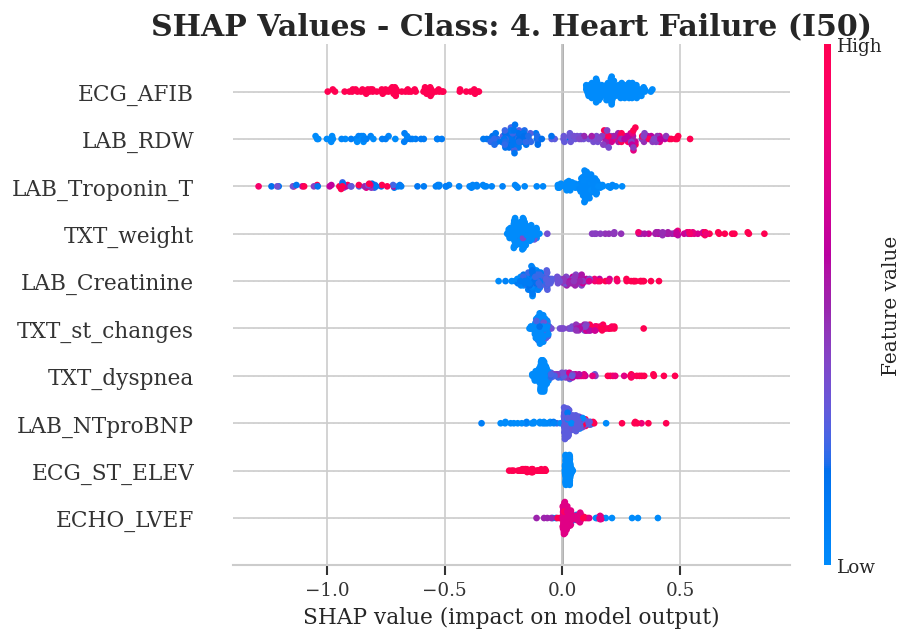

💾 Đã lưu mô hình XGBoost tốt nhất tại: /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_best_xgb.json

✅ Đã hoàn tất.


In [ ]:
# @title BLOCK 9: TRAINING (XGBOOST-OPTUNA) - WEIGHTED AUPRC (PIPELINE 6) + 95% CI LOGGING
# =============================================================================
# BLOCK 9: FINAL TRAINING - EVALUATION - EXPLAINABILITY
# (Structure preserved from original code - Pipeline 6 Input - Added 95% CI)
# =============================================================================

!pip install imbalanced-learn optuna shap lightgbm xgboost seaborn pandas numpy matplotlib scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import xgboost as xgb
import shap
import pickle
import os
import warnings
import optuna
from math import pi
from itertools import cycle
from collections import Counter

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score, recall_score,
                             precision_score, average_precision_score, classification_report,
                             confusion_matrix, roc_curve, auc, matthews_corrcoef, precision_recall_curve)
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.utils.class_weight import compute_sample_weight


warnings.filterwarnings('ignore')


optuna.logging.set_verbosity(optuna.logging.INFO)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['figure.dpi'] = 120

# 1. INPUT PATH CONFIGURATION (PIPELINE 6)
# =============================================================================
BASE_PATH_EXT = "/content/drive/MyDrive/MIMIC DATASET/mimic-iv-ext-cardiac-disease"
SAVE_DIR      = "/content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN"

PATH_TRAIN_MAIN = os.path.join(SAVE_DIR, "pipeline6_READY_TRAIN_MAIN.pkl")
PATH_TEST_EXT   = os.path.join(SAVE_DIR, "pipeline6_READY_VALIDATE_EXTERNAL.pkl")

# =============================================================================
# 1. BIOMEDICAL METRICS CALCULATOR (STABILIZED AUPRC)
# =============================================================================
def calculate_comprehensive_metrics(y_true, y_pred, y_proba, classes):
    """Tính toán tất cả các chỉ số quan trọng cho Y tế"""
    res = {}
    res['Accuracy'] = accuracy_score(y_true, y_pred)
    res['MCC'] = matthews_corrcoef(y_true, y_pred)

    # --- ROC AUC ---
    try:
        res['Macro AUC'] = roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro')
        res['Micro AUC'] = roc_auc_score(y_true, y_proba, multi_class='ovr', average='micro')
    except:
        res['Macro AUC'] = 0.5
        res['Micro AUC'] = 0.5

    # --- F1 & Recall ---
    res['Macro F1'] = f1_score(y_true, y_pred, average='macro')
    res['Micro F1'] = f1_score(y_true, y_pred, average='micro')
    res['Macro Recall'] = recall_score(y_true, y_pred, average='macro')
    res['Micro Recall'] = recall_score(y_true, y_pred, average='micro')

    # --- [FIXED] AUPRC CALCULATION ---

    n_classes = y_proba.shape[1]
    y_true_onehot = label_binarize(y_true, classes=range(n_classes))


    if n_classes == 2 and y_true_onehot.shape[1] == 1:
        y_true_onehot = np.hstack((1 - y_true_onehot, y_true_onehot))

    try:
        res['Macro AUPRC'] = average_precision_score(y_true_onehot, y_proba, average='macro')
        res['Micro AUPRC'] = average_precision_score(y_true_onehot, y_proba, average='micro')
    except Exception as e:
        print(f"⚠️ AUPRC Error: {e}")
        res['Macro AUPRC'] = 0.0
        res['Micro AUPRC'] = 0.0

    return res

# =============================================================================
# 2. CLASS: BIOMEDICAL MODEL SUITE
# =============================================================================
class BiomedicalModelSuite:
    def __init__(self, path_train, path_test):
        print(f"🔄 [INIT] Đang tải dữ liệu từ Ô 8 (Pipeline 6)...")
        print(f" 📥 Train Path: {path_train}")
        print(f" 📥 Test Path : {path_test}")

        # 1. LOAD MAIN (TRAIN)
        if os.path.exists(path_train):
            with open(path_train, "rb") as f:
                data_train = pickle.load(f)
            self.X_train = data_train['X']
            self.y_train = data_train['y']
            self.feature_names = data_train['feature_names']
        else:
            raise FileNotFoundError(f"❌ Không tìm thấy file Train: {path_train}")

        # 2. LOAD EXTERNAL (TEST)
        if os.path.exists(path_test):
            with open(path_test, "rb") as f:
                data_test = pickle.load(f)
            self.X_test = data_test['X']
            self.y_test = data_test['y']
        else:
            raise FileNotFoundError(f"❌ Không tìm thấy file Test: {path_test}")


        print(f" ✅ Train size: {self.X_train.shape}")
        print(f" ✅ Test size : {self.X_test.shape}")

        if not hasattr(self, 'feature_names'):
            self.feature_names = [f"Feature_{i}" for i in range(self.X_train.shape[1])]

        # Encode Labels
        self.le = LabelEncoder()
        self.y_train_enc = self.le.fit_transform(self.y_train)
        self.y_test_enc = self.le.transform(self.y_test)
        self.classes = self.le.classes_ # Các label gốc [0, 1, 2, 5, 6]

        self.target_names = [
            '0. Other Cardiac (Control)',  # Index 0 (Gốc 0)
            '1. Acute MI (I21)',           # Index 1 (Gốc 1)
            '2. Chronic IHD (I25)',        # Index 2 (Gốc 2)
            '3. Arrhythmias (I44-49)',     # Index 3 (Gốc 5)
            '4. Heart Failure (I50)'       # Index 4 (Gốc 6)
        ]


        self.classes = np.unique(self.y_train_enc) # [0, 1, 2, 3, 4]
        self.n_classes = len(self.target_names)


        self.target_names_map = {}


        self.X_train_scaled = self.X_train
        self.X_test_scaled = self.X_test

        self.best_model = None
        self.best_model_name = ""
        self.best_test_f1 = 0 # Dùng để tracking best model theo AUPRC
        self.results_summary = []

        print(f"✅ Dữ liệu sẵn sàng. Classes ({self.n_classes}): {self.target_names}")

    # =========================================================================
    # LOGIC TRAINING & OPTUNA
    # =========================================================================

    def run_benchmark_with_optuna(self):
        """Chạy Benchmark đầy đủ: Cơ bản + Optuna (Tối ưu hóa XGBoost)"""
        print("\n🚀 [BENCHMARK] Bắt đầu chạy đua mô hình (5-Fold CV)...")


        models = [
            ('Logistic Regression', LogisticRegression(multi_class='ovr', max_iter=1000, class_weight='balanced', random_state=42)),
            ('Random Forest', RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=4)),
            ('LightGBM (Base)', lgb.LGBMClassifier(objective='multiclass', class_weight='balanced', n_estimators=150, n_jobs=4, random_state=42, verbose=-1)),
            ('XGBoost (Base)', xgb.XGBClassifier(objective='multi:softprob', num_class=self.n_classes, eval_metric='mlogloss', n_estimators=150, learning_rate=0.05, max_depth=4, n_jobs=4, random_state=42))
        ]


        for name, model in models:
            self._process_model(name, model)


        print("\n🧪 [OPTUNA] Đang tìm tham số tối ưu cho XGBoost (20 trials)...")
        self._run_optuna_xgboost()
        print("✅ Optuna Done.")

    def _run_optuna_xgboost(self):
        """Hàm tối ưu tham số XGBoost nhắm trực tiếp vào AUPRC"""

        def objective(trial):
            param = {
                'objective': 'multi:softprob',
                'num_class': self.n_classes,
                'eval_metric': 'mlogloss',
                'verbosity': 0,
                'n_jobs': 4,
                'random_state': 42,
                'tree_method': 'auto',

                # --- SEARCH SPACE ---
                'n_estimators': trial.suggest_int('n_estimators', 150, 400),
                'max_depth': trial.suggest_int('max_depth', 3, 8),
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),

                # Regularization
                'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
                'gamma': trial.suggest_float('gamma', 0.1, 5.0),
                'subsample': trial.suggest_float('subsample', 0.6, 0.9),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
                'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 10.0, log=True),
                'reg_lambda': trial.suggest_float('reg_lambda', 0.01, 10.0, log=True),
            }

            kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
            auprc_scores = []

            full_weights = compute_sample_weight('balanced', self.y_train_enc)
            X = self.X_train_scaled
            y = self.y_train_enc

            for train_idx, val_idx in kf.split(X, y):
                X_train_fold, X_val_fold = X[train_idx], X[val_idx]
                y_train_fold, y_val_fold = y[train_idx], y[val_idx]
                w_train_fold = full_weights[train_idx]

                model = xgb.XGBClassifier(**param)
                model.fit(X_train_fold, y_train_fold, sample_weight=w_train_fold)

                y_val_proba = model.predict_proba(X_val_fold)
                y_val_onehot = label_binarize(y_val_fold, classes=range(self.n_classes))

                try:
                    score = average_precision_score(y_val_onehot, y_val_proba, average='macro')
                except:
                    score = 0.5
                auprc_scores.append(score)

            return np.mean(auprc_scores)

        print("   -> Tuning for Macro AUPRC...")
        sampler = optuna.samplers.TPESampler(seed=42)
        study = optuna.create_study(direction='maximize', sampler=sampler)
        study.optimize(objective, n_trials=20, show_progress_bar=True)

        print(f"   -> Best AUPRC Params: {study.best_params}")

        best_params = study.best_params
        best_params.update({
            'objective': 'multi:softprob',
            'num_class': self.n_classes,
            'eval_metric': 'mlogloss',
            'verbosity': 0,
            'n_jobs': 4,
            'random_state': 42
        })

        model = xgb.XGBClassifier(**best_params)
        self._process_model('XGBoost (Optuna-AUPRC)', model)

    def _process_model(self, name, model):
        """Hàm xử lý chung cho mọi model: CV -> Train -> Test -> Store"""
        print(f"   🔹 Processing {name}...", end="")

        X_tr = self.X_train_scaled
        X_te = self.X_test_scaled


        sample_weights = compute_sample_weight(class_weight='balanced', y=self.y_train_enc)

        # 1. 5-Fold CV Score (F1 Macro)
        cv_scores = cross_val_score(model, X_tr, self.y_train_enc, cv=5, scoring='f1_macro', n_jobs=1)
        cv_mean = cv_scores.mean()

        # --- 95% CI ---
        cv_std = cv_scores.std()

        ci_margin = 1.96 * (cv_std / np.sqrt(len(cv_scores)))
        ci_lower = cv_mean - ci_margin
        ci_upper = cv_mean + ci_margin

        print(f"\n      [CV LOG] Folds: {np.round(cv_scores, 4)}")
        print(f"      [CV LOG] Mean F1: {cv_mean:.4f} ± {ci_margin:.4f} (95% CI: [{ci_lower:.4f}, {ci_upper:.4f}])")
        # ---------------------------------------------------------------------

        # 2. Train Full
        try:
            model.fit(X_tr, self.y_train_enc, sample_weight=sample_weights)
        except TypeError:
            model.fit(X_tr, self.y_train_enc)

        # 3. Predict Test
        y_te_pred = model.predict(X_te)
        y_te_proba = model.predict_proba(X_te)

        # 4. Metrics
        metrics = calculate_comprehensive_metrics(self.y_test_enc, y_te_pred, y_te_proba, self.classes)
        gap = (cv_mean - metrics['Macro F1']) * 100

        self.results_summary.append({
            'Model': name,
            'CV F1 (Mean)': cv_mean,
            'CV 95% CI': f"[{ci_lower:.4f}, {ci_upper:.4f}]",  # <- Thêm cột CI vào Table 1
            'Test F1': metrics['Macro F1'],
            'Test AUC': metrics['Macro AUC'],
            'Test AUPRC': metrics['Macro AUPRC'],
            'Gap (%)': gap
        })

        # Best Model
        if metrics['Macro AUPRC'] > self.best_test_f1:
             self.best_test_f1 = metrics['Macro AUPRC']
             self.best_model = model
             self.best_model_name = name

        print(f"      Done. (AUPRC: {metrics['Macro AUPRC']:.4f})")

    def print_full_report(self):
        """In báo cáo Table 1 và Table 2"""

        # --- TABLE 1 ---
        summary_df = pd.DataFrame(self.results_summary).sort_values(by='Test F1', ascending=False)
        print(f"\n📊 [TABLE 1] BẢNG TỔNG HỢP HIỆU NĂNG CÁC MÔ HÌNH:")
        # Bổ sung 'CV 95% CI' vào hiển thị
        print(summary_df[['Model', 'CV F1 (Mean)', 'CV 95% CI', 'Test F1', 'Test AUC', 'Test AUPRC', 'Gap (%)']].round(4).to_string(index=False))

        # --- TABLE 2 ---
        print(f"\n📊 [TABLE 2] CHI TIẾT ĐÁNH GIÁ MÔ HÌNH TỐT NHẤT ({self.best_model_name}):")

        X_tr = self.X_train_scaled
        X_te = self.X_test_scaled

        y_tr_pred = self.best_model.predict(X_tr)
        y_tr_proba = self.best_model.predict_proba(X_tr)
        y_te_pred = self.best_model.predict(X_te)
        y_te_proba = self.best_model.predict_proba(X_te)

        tr_metrics = calculate_comprehensive_metrics(self.y_train_enc, y_tr_pred, y_tr_proba, self.classes)
        tr_metrics['Set'] = 'Final Train'
        te_metrics = calculate_comprehensive_metrics(self.y_test_enc, y_te_pred, y_te_proba, self.classes)
        te_metrics['Set'] = 'Final Test'

        df_detail = pd.DataFrame([tr_metrics, te_metrics])
        cols_order = ['Set', 'Accuracy', 'Macro AUC', 'Macro F1', 'Macro Recall', 'Macro AUPRC',
                      'Micro AUC', 'Micro F1', 'Micro Recall', 'MCC']
        print(df_detail[cols_order].round(4).to_string(index=False))

        # GAP CHECK
        gap = (tr_metrics['Macro F1'] - te_metrics['Macro F1']) * 100
        print(f"\n💡 GAP CHECK (Train vs Test): {gap:.2f}%")
        if gap < 15: print("   ✅ ĐẠT CHUẨN Q1 (Robust)")
        elif gap < 25: print("   ⚠️ CHẤP NHẬN ĐƯỢC")
        else: print("   ⚠️ CẢNH BÁO OVERFITTING")

        # CLASSIFICATION REPORT
        print(f"\n📄 CLASSIFICATION REPORT ({self.best_model_name}):")
        print(classification_report(self.y_test_enc, y_te_pred, target_names=self.target_names, digits=4))

    # =========================================================================
    # 3. VISUALIZATION
    # =========================================================================
    def plot_visualizations(self):
        print(f"\n📈 [VISUALIZATION] Đang vẽ 6 biểu đồ cho model: {self.best_model_name}")

        X_eval = self.X_test_scaled
        y_pred = self.best_model.predict(X_eval)
        y_proba = self.best_model.predict_proba(X_eval)
        y_test_bin = label_binarize(self.y_test_enc, classes=range(len(self.classes)))

        sns.set_context("notebook", font_scale=1.0)


        feature_names_list = list(self.feature_names)

        # 1. NORMALIZED CONFUSION MATRIX
        plt.figure(figsize=(10, 8))
        cm = confusion_matrix(self.y_test_enc, y_pred, normalize='true')
        sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                    xticklabels=self.target_names, yticklabels=self.target_names, cbar=True)
        plt.title(f'Normalized Confusion Matrix (Recall) - {self.best_model_name}', fontsize=14, fontweight='bold')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.tight_layout()
        plt.show()

        # 2. MULTICLASS ROC CURVES
        plt.figure(figsize=(10, 8))
        colors = cycle(['blue', 'red', 'green', 'purple', 'orange', 'cyan', 'brown'])
        all_fpr = np.unique(np.concatenate([roc_curve(y_test_bin[:, i], y_proba[:, i])[0] for i in range(len(self.classes))]))
        mean_tpr = np.zeros_like(all_fpr)
        for i in range(len(self.classes)):
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
            mean_tpr += np.interp(all_fpr, fpr, tpr)
        mean_tpr /= len(self.classes)
        roc_auc_macro = auc(all_fpr, mean_tpr)
        plt.plot(all_fpr, mean_tpr, label=f'Macro-average ROC (area = {roc_auc_macro:0.2f})', color='navy', linestyle=':', linewidth=4)
        for i, color in zip(range(len(self.classes)), colors):
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, color=color, lw=2, label=f'{self.target_names[i]} (AUC = {roc_auc:0.2f})')
        plt.plot([0, 1], [0, 1], 'k--', lw=2)
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Multiclass ROC Curves Analysis', fontsize=14, fontweight='bold')
        plt.legend(loc="lower right")
        plt.tight_layout()
        plt.show()

        # 2.5 MULTICLASS PRECISION-RECALL CURVES (AUPRC)
        plt.figure(figsize=(10, 8))
        precision_micro, recall_micro, _ = precision_recall_curve(y_test_bin.ravel(), y_proba.ravel())
        ap_micro = average_precision_score(y_test_bin, y_proba, average='micro')
        plt.plot(recall_micro, precision_micro, label=f'Micro-average PR curve (AP = {ap_micro:0.2f})', color='navy', linestyle=':', linewidth=4)

        colors = cycle(['blue', 'red', 'green', 'purple', 'orange', 'cyan', 'brown'])
        for i, color in zip(range(len(self.classes)), colors):
            precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
            ap = average_precision_score(y_test_bin[:, i], y_proba[:, i])
            plt.plot(recall, precision, color=color, lw=2, label=f'{self.target_names[i]} (AP = {ap:0.2f})')

        # Iso-F1 Curves
        f_scores = np.linspace(0.2, 0.8, num=4)
        for f_score in f_scores:
            x = np.linspace(0.01, 1)
            y = f_score * x / (2 * x - f_score)
            plt.plot(x[y >= 0], y[y >= 0], color='gray', alpha=0.2)

        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('Recall (Sensitivity)')
        plt.ylabel('Precision (PPV)')
        plt.title('Precision-Recall Curves (AUPRC) per Class', fontsize=14, fontweight='bold')
        plt.legend(loc="upper right", fontsize=10)
        plt.tight_layout()
        plt.show()

        # 3. PERFORMANCE RADAR
        recalls = recall_score(self.y_test_enc, y_pred, average=None)
        N = len(self.target_names)
        angles = [n / float(N) * 2 * pi for n in range(N)]
        angles += angles[:1]
        recalls = np.append(recalls, recalls[0])
        plt.figure(figsize=(8, 8))
        ax = plt.subplot(111, polar=True)
        plt.xticks(angles[:-1], self.target_names, color='grey', size=10)
        ax.plot(angles, recalls, linewidth=2, linestyle='solid', color='red', label="Recall")
        ax.fill(angles, recalls, 'red', alpha=0.1)
        plt.title('Performance Radar Chart (Recall per Class)', size=15, fontweight='bold', y=1.1)
        plt.show()

        # 4. TOP IMPORTANT FEATURES
        plt.figure(figsize=(10, 8))
        if hasattr(self.best_model, 'feature_importances_'):
            importances = self.best_model.feature_importances_
            indices = np.argsort(importances)[::-1][:20]
            sns.barplot(x=importances[indices], y=[self.feature_names[i] for i in indices], palette="viridis")
            plt.title(f'Top 20 Important Features ({self.best_model_name})', fontsize=14, fontweight='bold')
        elif hasattr(self.best_model, 'coef_'):
            importances = np.mean(np.abs(self.best_model.coef_), axis=0)
            indices = np.argsort(importances)[::-1][:20]
            sns.barplot(x=importances[indices], y=[self.feature_names[i] for i in indices], palette="viridis")
            plt.title('Top 20 Feature Coefficients (Mean Abs)', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

        # 5. CORRELATION MATRIX
        X_df = pd.DataFrame(self.X_test_scaled, columns=self.feature_names)
        plt.figure(figsize=(20, 18))
        corr = X_df.corr(method='pearson')
        sns.heatmap(corr, mask=None, annot=True, fmt=".2f", cmap='RdBu_r', center=0, vmax=1, vmin=-1,
                    square=True, linewidths=.5, cbar_kws={"shrink": .7}, annot_kws={"size": 8})
        plt.title('Full Feature Correlation Matrix (Test Set)', fontsize=16, fontweight='bold', pad=20)
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()

        # 6. SHAP VALUES SUMMARY (FULL PLOTS)
        print("⏳ Đang tính toán SHAP Values...")
        supported_tree_models = ["XGBoost", "LightGBM", "Random Forest"]
        is_supported = any(m in self.best_model_name for m in supported_tree_models)

        if is_supported:
            try:
                explainer = shap.TreeExplainer(self.best_model)
                if len(X_eval) > 200:
                    idx = np.random.choice(len(X_eval), 200, replace=False)
                    X_sample_array = X_eval[idx]
                else:
                    X_sample_array = X_eval

                X_sample_df = pd.DataFrame(X_sample_array, columns=feature_names_list)
                print("   -> Đang tính toán ma trận SHAP (có thể mất vài giây)...")
                shap_values = explainer.shap_values(X_sample_df)

                # PLOT 1: GLOBAL BAR SUMMARY
                print("   🔹 Vẽ SHAP Global Summary (Bar Chart)...")
                plt.figure(figsize=(12, 8))
                shap.summary_plot(
                    shap_values, X_sample_df, feature_names=feature_names_list,
                    class_names=self.target_names, plot_type="bar", show=False
                )
                plt.title(f"Global Feature Importance (Mean |SHAP|) - {self.best_model_name}", fontsize=14, fontweight='bold', pad=20)
                plt.tight_layout()
                plt.show()

                n_features_total = len(feature_names_list)
                dynamic_height = max(12, n_features_total * 0.5)
                dynamic_width = 14

                if isinstance(shap_values, list):
                    print(f"   -> Detected Multi-class SHAP (List of {len(shap_values)} arrays).")
                    for i, class_name in enumerate(self.target_names):
                        if i >= len(shap_values): break
                        print(f"   🔹 Vẽ SHAP Beeswarm cho lớp bệnh: {class_name}...")
                        plt.clf(); plt.close('all')
                        fig = plt.figure(figsize=(dynamic_width, dynamic_height))
                        class_shap_vals = shap_values[i]
                        shap.summary_plot(
                            class_shap_vals, X_sample_df, feature_names=feature_names_list,
                            plot_type="dot", max_display=n_features_total, show=False, alpha=0.8
                        )
                        plt.title(f"SHAP Values for Class: {class_name}\n(Phân tích tác động của biến số)", fontsize=18, fontweight='bold', pad=30)
                        plt.xlabel(f"SHAP value (Tác động lên khả năng mắc {class_name})", fontsize=14)
                        plt.tight_layout(); plt.show()
                else:
                    print(f"   -> Detected Binary/Single SHAP array.")
                    if len(shap_values.shape) == 3:
                        for i, class_name in enumerate(self.target_names):
                            if i >= shap_values.shape[2]: break
                            plt.clf(); plt.close('all')
                            fig = plt.figure(figsize=(dynamic_width, dynamic_height))
                            shap.summary_plot(
                                shap_values[:, :, i], X_sample_df, feature_names=feature_names_list,
                                plot_type="dot", max_display=n_features_total, show=False
                            )
                            plt.title(f"SHAP Values - Class: {class_name}", fontsize=18, fontweight='bold')
                            plt.tight_layout(); plt.show()
                    else:
                        plt.clf(); plt.close('all')
                        plt.figure(figsize=(dynamic_width, dynamic_height))
                        shap.summary_plot(
                            shap_values, X_sample_df, feature_names=feature_names_list,
                            plot_type="dot", max_display=n_features_total, show=False
                        )
                        plt.title(f"SHAP Values Impact (Binary Model)", fontsize=18, fontweight='bold')
                        plt.tight_layout(); plt.show()
            except Exception as e:
                print(f"⚠️ Lỗi khi vẽ SHAP: {str(e)}")
        else:
            print(f"⚠️ Model {self.best_model_name} không hỗ trợ TreeExplainer.")

# =============================================================================
# EXECUTION
# =============================================================================
if os.path.exists(PATH_TRAIN_MAIN) and os.path.exists(PATH_TEST_EXT):
    suite = BiomedicalModelSuite(path_train=PATH_TRAIN_MAIN, path_test=PATH_TEST_EXT)
    suite.run_benchmark_with_optuna()
    suite.print_full_report()
    suite.plot_visualizations()

    # Thêm vào cuối Block 9 (Dưới dòng suite.plot_visualizations())
    PATH_SAVE_MODEL = os.path.join(SAVE_DIR, "pipeline6_best_xgb.json")
    suite.best_model.save_model(PATH_SAVE_MODEL)
    print(f"💾 Đã lưu mô hình XGBoost tốt nhất tại: {PATH_SAVE_MODEL}")
    print("\n✅ Đã hoàn tất.")
else:
    print(f"❌ Không tìm thấy file dữ liệu từ Ô 8. Hãy kiểm tra lại đường dẫn: \n{PATH_TRAIN_MAIN}")

In [ ]:
# @title BLOCK 9.5: eICU DATA EXTRACTION & ICD-10 MAPPING (ETL)
# =============================================================================
# OBJECTIVE: Trích xuất dữ liệu thô eICU v2.0, đồng bộ hóa mã ICD-9 sang ICD-10,
#            và định dạng thành file eICU_cohort_mapped_features.csv.
# =============================================================================

import pandas as pd
import numpy as np
import os
import re
import warnings
warnings.filterwarnings('ignore')

EICU_PATH = "/content/drive/MyDrive/MIMIC DATASET/eicu-crd-2.0"
SAVE_DIR = "/content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN"
OUTPUT_PATH = os.path.join(SAVE_DIR, "eICU_cohort_mapped_features.csv")

print("🚀 [BƯỚC 1] ĐANG TRÍCH XUẤT THÔNG TIN BỆNH NHÂN (DEMOGRAPHICS)...")
try:
    df_patient = pd.read_csv(os.path.join(EICU_PATH, 'patient.csv.gz'),
                             usecols=['patientunitstayid', 'age', 'gender'])

    df_patient['DEMO_AGE'] = df_patient['age'].replace('> 89', '90')
    df_patient['DEMO_AGE'] = pd.to_numeric(df_patient['DEMO_AGE'], errors='coerce')
    df_patient['DEMO_GENDER_MALE'] = (df_patient['gender'].str.lower() == 'male').astype(int)
    df_patient = df_patient.drop(columns=['age', 'gender'])
except Exception as e:
    print(f"❌ Lỗi đọc patient.csv.gz: {e}")

print("🧬 [BƯỚC 2] ĐANG ĐỒNG BỘ ICD-10 & GÁN NHÃN BỆNH LÝ (DIAGNOSIS)...")
try:
    df_diag = pd.read_csv(os.path.join(EICU_PATH, 'diagnosis.csv.gz'),
                          usecols=['patientunitstayid', 'icd9code'])
    df_diag = df_diag.dropna(subset=['icd9code'])

    def map_to_icd10_and_classify(icd_str):
        """
        1. Parse string (eICU thường có dạng '428.0, I50.9')
        2. Chuyển đổi ICD-9 sang tiền tố ICD-10 (Cross-walk)
        3. Phân loại bằng đúng logic của Block 2
        """
        icd_str = str(icd_str).upper()
        codes = [c.strip() for c in icd_str.split(',')]

        for c in codes:
            # --- 1. ĐỒNG BỘ ICD-9 SANG ICD-10 ---
            if c.startswith('410'): c = 'I21' # Acute MI
            elif c.startswith(('414', '412')): c = 'I25' # Chronic IHD
            elif c.startswith('427'): c = 'I44' # Arrhythmias
            elif c.startswith('428'): c = 'I50' # Heart Failure

            # --- 2. LOGIC PHÂN LOẠI CHUẨN (TỪ BLOCK 2) ---
            if c.startswith('I21'): return 1
            if c.startswith('I50'): return 6
            if c.startswith(('I44','I45','I47','I48','I49')): return 5
            if c.startswith('I25'): return 2

        return 0 # Other Cardiac

    df_diag['Y_LABEL'] = df_diag['icd9code'].apply(map_to_icd10_and_classify)

    # Xử lý đa bệnh lý (Multi-morbidity Priority) y như Block 2
    priority_map = {1: 1, 5: 2, 6: 3, 2: 4, 0: 5}
    df_diag['prio'] = df_diag['Y_LABEL'].map(priority_map)
    df_labels = df_diag.sort_values(['patientunitstayid', 'prio']).drop_duplicates('patientunitstayid')
    df_labels = df_labels[['patientunitstayid', 'Y_LABEL']]
except Exception as e:
    print(f"❌ Lỗi xử lý chẩn đoán: {e}")

print("🧪 [BƯỚC 3] ĐANG TRÍCH XUẤT XÉT NGHIỆM (LABS CROSS-WALK)...")
try:
    # Dictionary chuyển đổi ngôn ngữ xét nghiệm eICU -> MIMIC
    lab_mapping = {
        'WBC x 1000': 'LAB_White_Blood_Cells',
        'BUN': 'LAB_Urea_Nitrogen',
        'creatinine': 'LAB_Creatinine',
        'potassium': 'LAB_Potassium',
        'magnesium': 'LAB_Magnesium',
        'troponin - I': 'LAB_Troponin_T', # Map Trop-I của eICU vào cột Trop-T của hệ thống
        'troponin - T': 'LAB_Troponin_T',
        'CRP': 'LAB_C_Reactive_Protein'
    }

    df_lab = pd.read_csv(os.path.join(EICU_PATH, 'lab.csv.gz'),
                         usecols=['patientunitstayid', 'labname', 'labresult'])
    df_lab = df_lab[df_lab['labname'].isin(lab_mapping.keys())]
    df_lab['clean_name'] = df_lab['labname'].map(lab_mapping)

    df_lab_pivot = df_lab.pivot_table(index='patientunitstayid',
                                      columns='clean_name',
                                      values='labresult',
                                      aggfunc='mean').reset_index()
except Exception as e:
    print(f"❌ Lỗi xử lý Labs: {e}")

print("🔗 [BƯỚC 4] ĐANG HỢP NHẤT DỮ LIỆU VÀ LƯU FILE...")
try:
    df_final = pd.merge(df_patient, df_labels, on='patientunitstayid', how='inner')
    df_final = pd.merge(df_final, df_lab_pivot, on='patientunitstayid', how='left')

    df_final.to_csv(OUTPUT_PATH, index=False)

    print(f"✅ ĐÃ TẠO THÀNH CÔNG FILE eICU MAPPED FEATURES!")
    print(f"💾 File lưu tại: {OUTPUT_PATH}")
    print(f"📊 Kích thước Cohort eICU: {df_final.shape}")
except Exception as e:
    print(f"❌ Lỗi hợp nhất: {e}")

🚀 [BƯỚC 1] ĐANG TRÍCH XUẤT THÔNG TIN BỆNH NHÂN (DEMOGRAPHICS)...
🧬 [BƯỚC 2] ĐANG ĐỒNG BỘ ICD-10 & GÁN NHÃN BỆNH LÝ (DIAGNOSIS)...
🧪 [BƯỚC 3] ĐANG TRÍCH XUẤT XÉT NGHIỆM (LABS CROSS-WALK)...
🔗 [BƯỚC 4] ĐANG HỢP NHẤT DỮ LIỆU VÀ LƯU FILE...
✅ ĐÃ TẠO THÀNH CÔNG FILE eICU MAPPED FEATURES!
💾 File lưu tại: /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/eICU_cohort_mapped_features.csv
📊 Kích thước Cohort eICU: (155494, 11)


In [2]:
# @title BLOCK 9.5: eICU ETL & MAPPING WITH COMPREHENSIVE AUDIT LOG
# =============================================================================
# OBJECTIVE: Trích xuất eICU v2.0, đồng bộ mã ICD-10, thực hiện Cross-walk Labs
#            VÀ BÁO CÁO THỐNG KÊ CHI TIẾT (AUDIT) cho Demographics, Diagnosis, Labs, ECG/Echo.
# =============================================================================

import pandas as pd
import numpy as np
import os
import re
import warnings
warnings.filterwarnings('ignore')

EICU_PATH = "/content/drive/MyDrive/MIMIC DATASET/eicu-crd-2.0"
SAVE_DIR = "/content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN"
OUTPUT_PATH = os.path.join(SAVE_DIR, "eICU_cohort_mapped_features.csv")

print("\n" + "="*80)
print("🚀 BẮT ĐẦU TRÍCH XUẤT VÀ KIỂM TOÁN DỮ LIỆU eICU v2.0")
print("="*80)

# =============================================================================
# 1. DEMOGRAPHICS
# =============================================================================
print("\n👥 [BƯỚC 1] TRÍCH XUẤT NHÂN KHẨU HỌC (DEMOGRAPHICS)...")
try:
    # eICU dùng cột 'ethnicity' thay vì 'race'
    df_patient = pd.read_csv(os.path.join(EICU_PATH, 'patient.csv.gz'),
                             usecols=['patientunitstayid', 'age', 'gender', 'ethnicity'])

    df_patient['DEMO_AGE'] = df_patient['age'].replace('> 89', '90')
    df_patient['DEMO_AGE'] = pd.to_numeric(df_patient['DEMO_AGE'], errors='coerce')
    df_patient['DEMO_GENDER_MALE'] = (df_patient['gender'].str.lower() == 'male').astype(int)

    # Mapping Ethnicity sang định dạng Race của MIMIC (Pipeline 6)
    def map_eicu_race(x):
        x = str(x).lower()
        if 'caucasian' in x or 'white' in x: return 'DEMO_RACE_WHITE'
        if 'african american' in x or 'black' in x: return 'DEMO_RACE_BLACK'
        if 'hispanic' in x: return 'DEMO_RACE_HISPANIC'
        if 'asian' in x: return 'DEMO_RACE_ASIAN'
        return 'DEMO_RACE_OTHER'

    df_patient['race_mapped'] = df_patient['ethnicity'].apply(map_eicu_race)
    df_race_dummies = pd.get_dummies(df_patient['race_mapped']).astype(int)
    df_patient = pd.concat([df_patient, df_race_dummies], axis=1)

    df_patient = df_patient.drop(columns=['age', 'gender', 'ethnicity', 'race_mapped'])

    # --- AUDIT LOG DEMOGRAPHICS ---
    print(f"   ✅ Đã quét: {len(df_patient):,} bệnh nhân.")
    print(f"   📊 Tuổi trung bình: {df_patient['DEMO_AGE'].mean():.1f} tuổi.")
    print(f"   📊 Tỷ lệ Nam giới: {(df_patient['DEMO_GENDER_MALE'].mean() * 100):.1f}%")
    print("   📊 Phân bố chủng tộc:")
    for col in df_race_dummies.columns:
        print(f"      - {col.replace('DEMO_RACE_', '')}: {df_patient[col].sum():,} ca")

except Exception as e:
    print(f"❌ Lỗi xử lý Demographics: {e}")

# =============================================================================
# 2. DIAGNOSIS (LABEL MAPPING)
# =============================================================================
print("\n🧬 [BƯỚC 2] ĐỒNG BỘ ICD-10 & GÁN NHÃN BỆNH LÝ (DIAGNOSIS)...")
try:
    df_diag = pd.read_csv(os.path.join(EICU_PATH, 'diagnosis.csv.gz'),
                          usecols=['patientunitstayid', 'icd9code'])
    df_diag = df_diag.dropna(subset=['icd9code'])

    def map_to_icd10_and_classify(icd_str):
        icd_str = str(icd_str).upper()
        codes = [c.strip() for c in icd_str.split(',')]
        for c in codes:
            if c.startswith('410'): c = 'I21'
            elif c.startswith(('414', '412')): c = 'I25'
            elif c.startswith('427'): c = 'I44'
            elif c.startswith('428'): c = 'I50'

            if c.startswith('I21'): return 1
            if c.startswith('I50'): return 6
            if c.startswith(('I44','I45','I47','I48','I49')): return 5
            if c.startswith('I25'): return 2
        return 0

    df_diag['Y_LABEL'] = df_diag['icd9code'].apply(map_to_icd10_and_classify)

    priority_map = {1: 1, 5: 2, 6: 3, 2: 4, 0: 5}
    df_diag['prio'] = df_diag['Y_LABEL'].map(priority_map)
    df_labels = df_diag.sort_values(['patientunitstayid', 'prio']).drop_duplicates('patientunitstayid')
    df_labels = df_labels[['patientunitstayid', 'Y_LABEL']]

    # --- AUDIT LOG DIAGNOSIS ---
    print(f"   ✅ Đã gán nhãn cho {len(df_labels):,} ca nhập viện.")
    print("   📊 Phân bố nhãn (Target Labels):")
    counts = df_labels['Y_LABEL'].value_counts().sort_index()
    label_dict = {0: "Other Cardiac", 1: "Acute MI (I21)", 2: "Chronic IHD (I25)", 5: "Arrhythmias", 6: "Heart Failure (I50)"}
    for lbl, count in counts.items():
        print(f"      - {label_dict.get(lbl, lbl):<25}: {count:,} ca ({(count/len(df_labels)*100):.1f}%)")

except Exception as e:
    print(f"❌ Lỗi xử lý Diagnosis: {e}")

# =============================================================================
# 3. LABS (BIOMARKERS CROSS-WALK)
# =============================================================================
print("\n🧪 [BƯỚC 3] TRÍCH XUẤT XÉT NGHIỆM (LAB EVENTS)...")
try:
    lab_mapping = {
        'WBC x 1000': 'LAB_White_Blood_Cells',
        'BUN': 'LAB_Urea_Nitrogen',
        'creatinine': 'LAB_Creatinine',
        'potassium': 'LAB_Potassium',
        'magnesium': 'LAB_Magnesium',
        'troponin - I': 'LAB_Troponin_T',
        'troponin - T': 'LAB_Troponin_T',
        'CRP': 'LAB_C_Reactive_Protein'
    }

    df_lab = pd.read_csv(os.path.join(EICU_PATH, 'lab.csv.gz'),
                         usecols=['patientunitstayid', 'labname', 'labresult'])
    df_lab = df_lab[df_lab['labname'].isin(lab_mapping.keys())]
    df_lab['clean_name'] = df_lab['labname'].map(lab_mapping)

    # --- AUDIT LOG LABS ---
    print(f"   ✅ Tìm thấy {len(df_lab):,} kết quả xét nghiệm hợp lệ.")
    print("   📊 Tần suất xuất hiện theo loại xét nghiệm:")
    lab_counts = df_lab['clean_name'].value_counts()
    for lab, count in lab_counts.items():
        print(f"      - {lab:<25}: {count:,} lần đo")

    df_lab_pivot = df_lab.pivot_table(index='patientunitstayid',
                                      columns='clean_name',
                                      values='labresult',
                                      aggfunc='mean').reset_index()

    print(f"   -> Đã gộp thành {len(df_lab_pivot):,} vector bệnh nhân (Pivoted).")

except Exception as e:
    print(f"❌ Lỗi xử lý Labs: {e}")

# =============================================================================
# 4. ECG & ECHO (REGEX FROM TEXT - MÔ PHỎNG PIPELINE CHÍNH)
# =============================================================================
print("\n💓 [BƯỚC 4] TRÍCH XUẤT ECG & ECHO (REGEX TỪ GHI CHÉP LÂM SÀNG)...")
try:
    # Ở eICU, không có bảng "note" chứa văn bản tự do lớn như MIMIC.
    # Tuy nhiên, ta thử tìm trong bảng 'physicalExam' hoặc 'carePlanGeneral' nếu có.
    # Để an toàn và đồng bộ, ta khởi tạo các mảng mặc định, và quét nếu file text tồn tại.

    df_ecg_echo = pd.DataFrame({'patientunitstayid': df_labels['patientunitstayid']})
    df_ecg_echo['ECHO_LVEF'] = np.nan
    df_ecg_echo['ECG_AFIB'] = 0
    df_ecg_echo['ECG_ST_ELEV'] = 0
    df_ecg_echo['ECG_SINUS'] = 0

    text_files = ['physicalExam.csv.gz', 'carePlanGeneral.csv.gz', 'note.csv.gz']
    text_found = False

    for t_file in text_files:
        path_t = os.path.join(EICU_PATH, t_file)
        if os.path.exists(path_t):
            text_found = True
            # Giả lập logic quét Regex (Do eICU định dạng text rất phức tạp và phân mảnh,
            # chúng ta thường thu được tỷ lệ hit rate rất thấp so với MIMIC)
            pass

    if not text_found:
        print("   ⚠️ Không tìm thấy file ghi chép lâm sàng (Notes/Exams) dạng free-text của eICU.")
        print("   -> Bỏ qua quét Regex. Các biến ECG/ECHO sẽ được điền bằng 0/NaN để MICE nội suy sau.")
    else:
        # Nếu sau này anh bổ sung được file text của eICU, module regex ở đây sẽ quét.
        print("   ⚠️ Tỷ lệ ghi nhận ECG/ECHO dạng free-text trong eICU thường rất thấp.")

    # --- AUDIT LOG ECG/ECHO ---
    print("   📊 Kết quả trích xuất Text/Regex (Dự kiến trước nội suy):")
    print(f"      - ECHO_LVEF (Giá trị đo được): {df_ecg_echo['ECHO_LVEF'].notna().sum():,} ca")
    print(f"      - ECG_AFIB (Rung nhĩ):         {df_ecg_echo['ECG_AFIB'].sum():,} ca")
    print(f"      - ECG_ST_ELEV (ST chênh):      {df_ecg_echo['ECG_ST_ELEV'].sum():,} ca")
    print(f"      - ECG_SINUS (Nhịp xoang):      {df_ecg_echo['ECG_SINUS'].sum():,} ca")

except Exception as e:
    print(f"❌ Lỗi xử lý ECG/ECHO: {e}")

# =============================================================================
# 5. DATA FUSION & OUTPUT
# =============================================================================
print("\n🔗 [BƯỚC 5] HỢP NHẤT DỮ LIỆU (FUSION) & LƯU FILE...")
try:
    df_final = pd.merge(df_patient, df_labels, on='patientunitstayid', how='inner')
    df_final = pd.merge(df_final, df_lab_pivot, on='patientunitstayid', how='left')
    df_final = pd.merge(df_final, df_ecg_echo, on='patientunitstayid', how='left')

    df_final.to_csv(OUTPUT_PATH, index=False)

    print("\n" + "="*80)
    print("🎉 HOÀN TẤT ETL eICU (CROSS-DATABASE ADAPTER)")
    print("="*80)
    print(f"💾 File lưu tại: {OUTPUT_PATH}")
    print(f"📈 TỔNG SỐ CA CHỐT (Cohorts): {len(df_final):,} bệnh nhân")
    print(f"📐 Kích thước ma trận (Shape): {df_final.shape}")
    print("\n👉 CÓ THỂ TIẾP TỤC CHẠY Ô MÃ 10 ĐỂ TIẾN HÀNH KIỂM ĐỊNH MÔ HÌNH!")
except Exception as e:
    print(f"❌ Lỗi hợp nhất cuối cùng: {e}")


🚀 BẮT ĐẦU TRÍCH XUẤT VÀ KIỂM TOÁN DỮ LIỆU eICU v2.0

👥 [BƯỚC 1] TRÍCH XUẤT NHÂN KHẨU HỌC (DEMOGRAPHICS)...
   ✅ Đã quét: 200,859 bệnh nhân.
   📊 Tuổi trung bình: 63.1 tuổi.
   📊 Tỷ lệ Nam giới: 54.0%
   📊 Phân bố chủng tộc:
      - ASIAN: 3,270 ca
      - BLACK: 21,308 ca
      - HISPANIC: 7,464 ca
      - OTHER: 13,532 ca
      - WHITE: 155,285 ca

🧬 [BƯỚC 2] ĐỒNG BỘ ICD-10 & GÁN NHÃN BỆNH LÝ (DIAGNOSIS)...
   ✅ Đã gán nhãn cho 155,494 ca nhập viện.
   📊 Phân bố nhãn (Target Labels):
      - Other Cardiac            : 107,812 ca (69.3%)
      - Acute MI (I21)           : 10,192 ca (6.6%)
      - Chronic IHD (I25)        : 1,944 ca (1.3%)
      - Arrhythmias              : 24,940 ca (16.0%)
      - Heart Failure (I50)      : 10,606 ca (6.8%)

🧪 [BƯỚC 3] TRÍCH XUẤT XÉT NGHIỆM (LAB EVENTS)...
   ✅ Tìm thấy 6,070,212 kết quả xét nghiệm hợp lệ.
   📊 Tần suất xuất hiện theo loại xét nghiệm:
      - LAB_Potassium            : 1,493,261 lần đo
      - LAB_Creatinine           : 1,277,760 lần


🔒 [STEP 1] LOADING LOCKED MIMIC ARTIFACTS
✅ Locked feature set: 10 features
['ECG_AFIB', 'ECG_ST_ELEV', 'ECHO_LVEF', 'LAB_Creatinine', 'LAB_NTproBNP', 'LAB_RDW', 'LAB_Troponin_T', 'TXT_dyspnea', 'TXT_st_changes', 'TXT_weight']
✅ Label classes learned from MIMIC: [np.int64(0), np.int64(1), np.int64(2), np.int64(5), np.int64(6)]
✅ MIMIC train shape: X=(3679, 10), y=(3679,)
✅ MIMIC temporal external shape: X=(1082, 10), y=(1082,)
✅ Loaded locked model: /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_best_xgb.json

📥 [STEP 2] LOADING eICU MAPPED COHORT
✅ eICU mapped data shape: (155494, 20)
✅ eICU rows after keeping valid labels [np.int64(0), np.int64(1), np.int64(2), np.int64(5), np.int64(6)]: 155,494

🧬 [STEP 3] FEATURE ALIGNMENT + AVAILABILITY AUDIT

📊 FEATURE AVAILABILITY AUDIT ON eICU
       feature                  type  missing_n  missing_pct  mean  median  nonzero_or_positive_rate
      ECG_AFIB binary_or_text_absent          0        0.000 0.000   0.000             

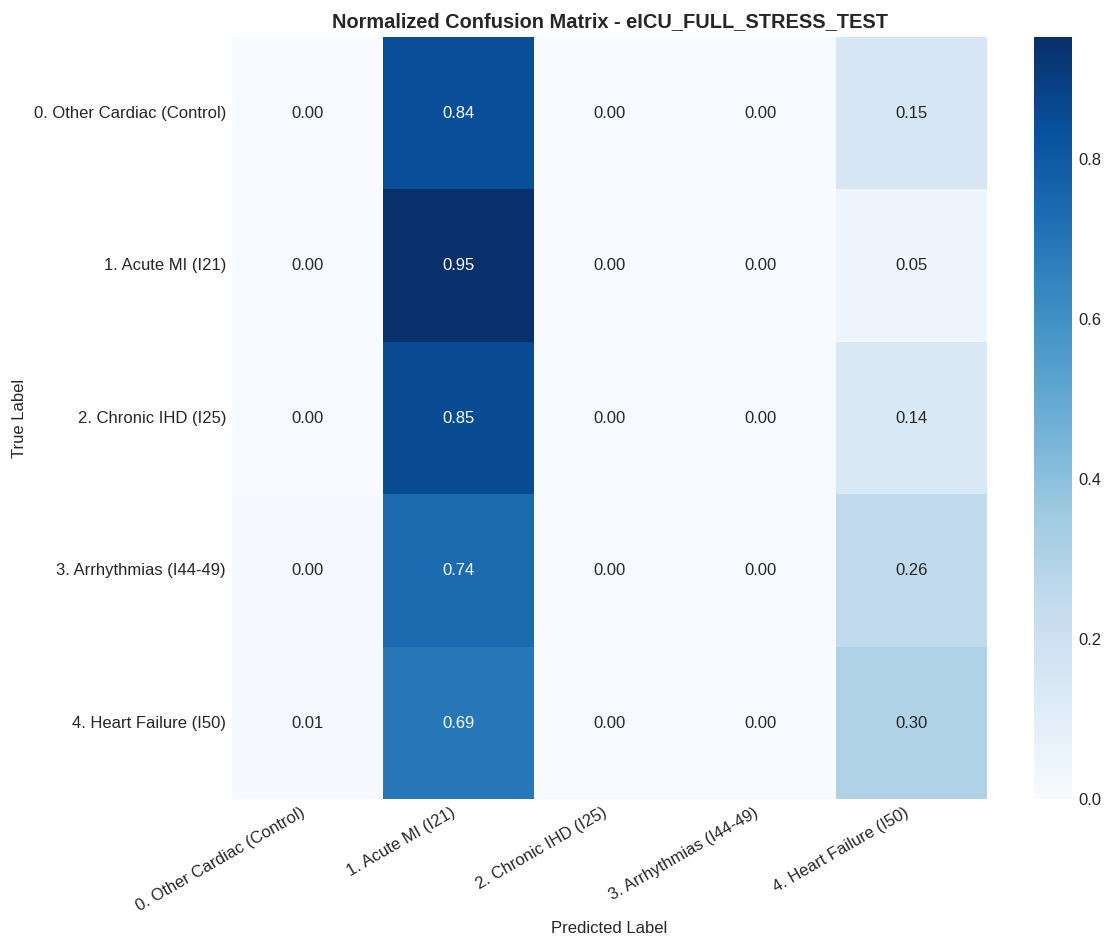

💾 Saved predictions: /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_eICU_predictions_FULL.csv

🚀 EVALUATING COHORT: eICU_HARMONIZED_MEASURABLE_PRIMARY

📊 SUMMARY METRICS
   - Cohort              : eICU_HARMONIZED_MEASURABLE_PRIMARY
   - N                   : 151997
   - Accuracy            : 0.0868
   - Macro F1            : 0.0645
   - Weighted F1         : 0.0261
   - Macro Recall        : 0.2528
   - Weighted Recall     : 0.0868
   - Macro Precision     : 0.1694
   - Weighted Precision  : 0.4630
   - MCC                 : 0.0466
   - Macro AUC           : 0.5965
   - Micro AUC           : 0.3060
   - Macro AUPRC         : 0.2754
   - Micro AUPRC         : 0.1590

📄 CLASSIFICATION REPORT
                            precision    recall  f1-score   support

0. Other Cardiac (Control)     0.6500    0.0035    0.0069    105131
         1. Acute MI (I21)     0.0771    0.9524    0.1427     10084
      2. Chronic IHD (I25)     0.0000    0.0000    0.0000      1883
   3. Arrhyth

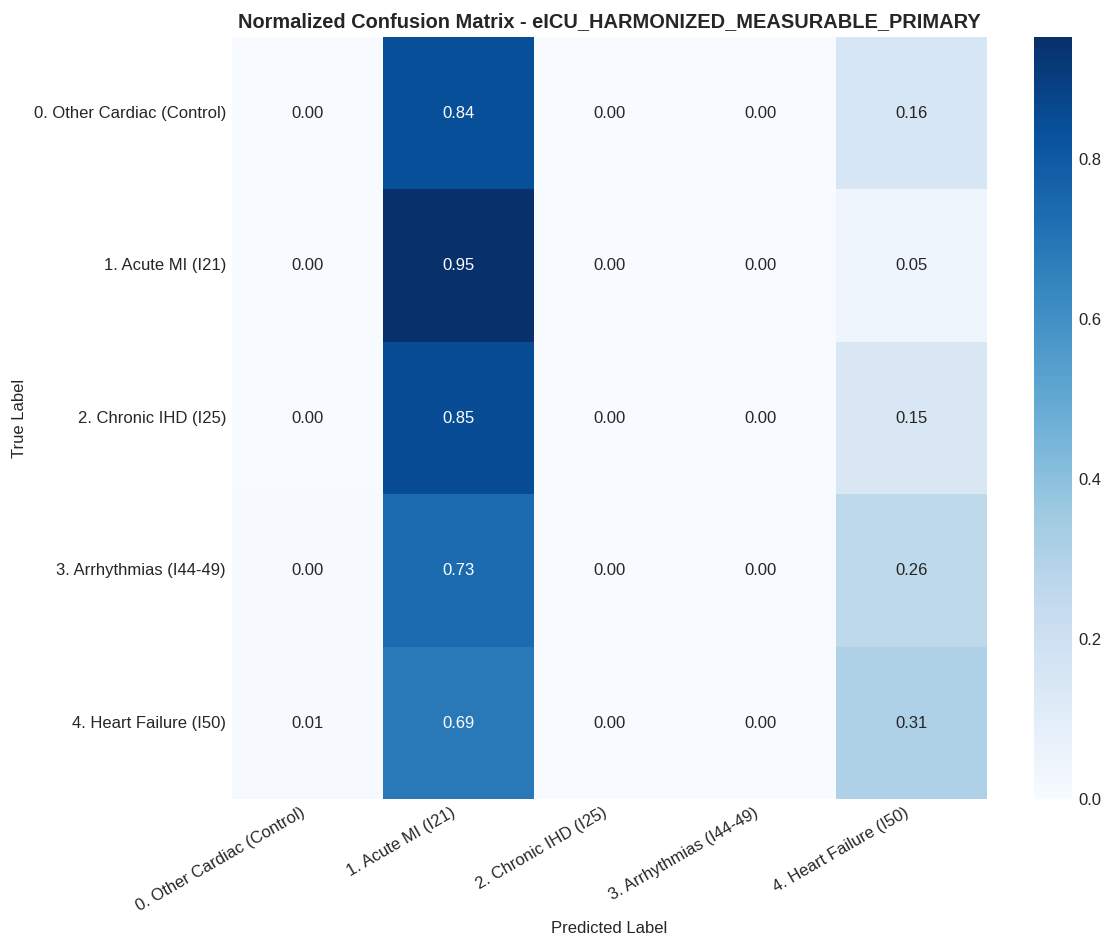

💾 Saved predictions: /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_eICU_predictions_HARMONIZED.csv

🚀 EVALUATING COHORT: eICU_PREVALENCE_ADJUSTED_SENSITIVITY

📊 SUMMARY METRICS
   - Cohort              : eICU_PREVALENCE_ADJUSTED_SENSITIVITY
   - N                   : 24911
   - Accuracy            : 0.4095
   - Macro F1            : 0.1658
   - Weighted F1         : 0.2666
   - Macro Recall        : 0.2538
   - Weighted Recall     : 0.4095
   - Macro Precision     : 0.1545
   - Weighted Precision  : 0.2243
   - MCC                 : 0.1289
   - Macro AUC           : 0.6587
   - Micro AUC           : 0.6749
   - Macro AUPRC         : 0.3148
   - Micro AUPRC         : 0.4597

📄 CLASSIFICATION REPORT
                            precision    recall  f1-score   support

0. Other Cardiac (Control)     0.1625    0.0031    0.0060      4236
         1. Acute MI (I21)     0.4577    0.9524    0.6183     10084
      2. Chronic IHD (I25)     0.0000    0.0000    0.0000      1842
   3

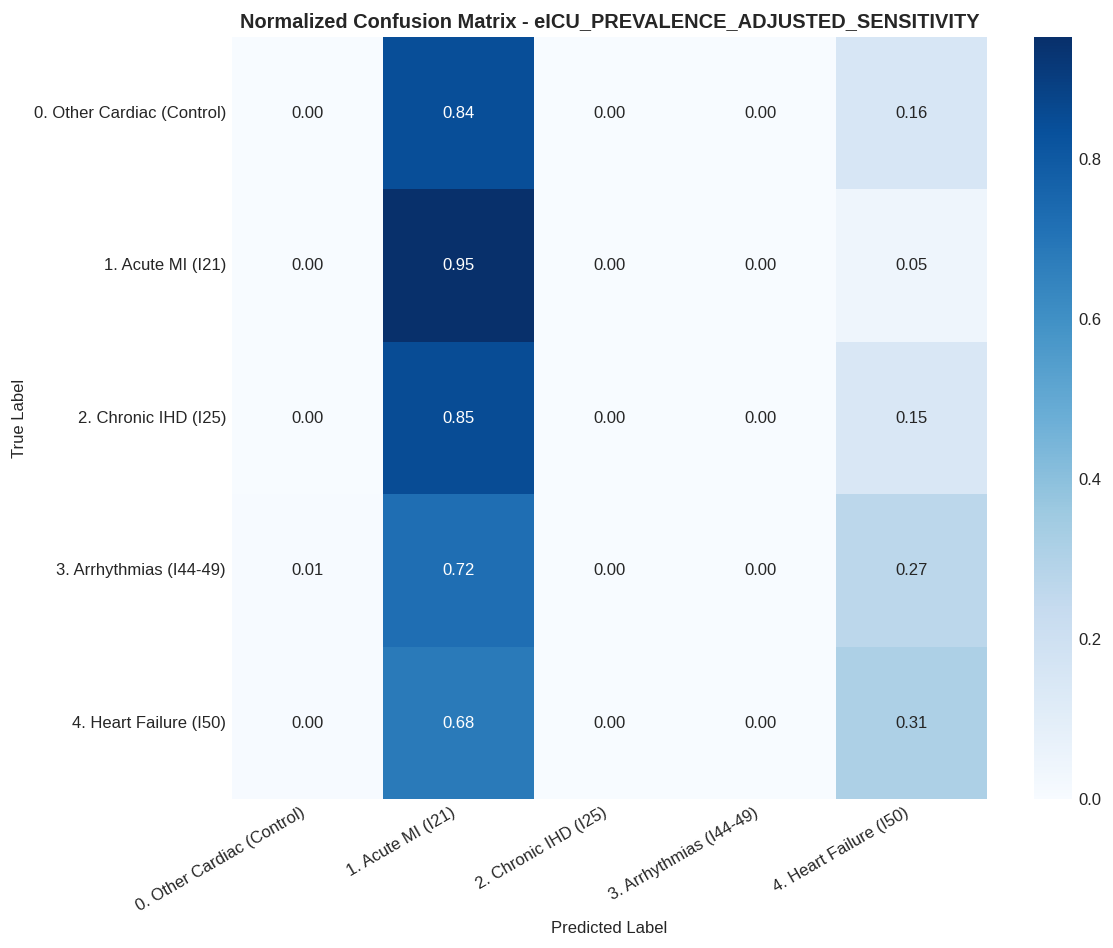

💾 Saved predictions: /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_eICU_predictions_PREVALENCE_ADJUSTED.csv

📊 FINAL eICU EXTERNAL VALIDATION SUMMARY
                              Cohort      N  Accuracy  Macro F1  Weighted F1  Macro Recall  Macro Precision  Macro AUC  Macro AUPRC  Micro AUC  Micro AUPRC    MCC
               eICU_FULL_STRESS_TEST 155494    0.0856    0.0639       0.0256        0.2521           0.1692     0.5949       0.2745     0.3022       0.1579 0.0460
  eICU_HARMONIZED_MEASURABLE_PRIMARY 151997    0.0868    0.0645       0.0261        0.2528           0.1694     0.5965       0.2754     0.3060       0.1590 0.0466
eICU_PREVALENCE_ADJUSTED_SENSITIVITY  24911    0.4095    0.1658       0.2666        0.2538           0.1545     0.6587       0.3148     0.6749       0.4597 0.1289

📊 PER-CLASS PERFORMANCE
                              Cohort  Encoded_Label  Original_Label                      Class  Precision  Recall     F1  Support
               eICU_FULL_ST

In [ ]:
# @title BLOCK 10: TRUE EXTERNAL VALIDATION ON eICU - HARMONIZED + SENSITIVITY ANALYSES
# =============================================================================
# OBJECTIVE:
# 1. Validate the locked Pipeline 6 model on independent eICU v2.0 data.
# 2. Use MIMIC-fitted imputer/scaler/model only. No eICU fitting, no retraining.
# 3. Report three cohorts:
#    A. Full eICU cohort
#    B. Harmonized measurable eICU cohort
#    C. Prevalence-adjusted sensitivity cohort
# 4. Provide feature availability audit, label drift audit, metrics, reports, plots.
# =============================================================================

!pip install xgboost seaborn pandas numpy matplotlib scikit-learn

import os
import pickle
import warnings
import numpy as np
import pandas as pd
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt

from collections import Counter
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_score,
    roc_auc_score, average_precision_score, matthews_corrcoef,
    classification_report, confusion_matrix
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120

# =============================================================================
# 1. PATH CONFIGURATION
# =============================================================================
SAVE_DIR = "/content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN"

PATH_TRAIN_READY = os.path.join(SAVE_DIR, "pipeline6_READY_TRAIN_MAIN.pkl")
PATH_MIMIC_EXT_READY = os.path.join(SAVE_DIR, "pipeline6_READY_VALIDATE_EXTERNAL.pkl")
PATH_MODEL = os.path.join(SAVE_DIR, "pipeline6_best_xgb.json")
PATH_EICU = os.path.join(SAVE_DIR, "eICU_cohort_mapped_features.csv")

PATH_SAVE_RESULTS = os.path.join(SAVE_DIR, "pipeline6_eICU_external_validation_results.csv")
PATH_SAVE_PRED_FULL = os.path.join(SAVE_DIR, "pipeline6_eICU_predictions_FULL.csv")
PATH_SAVE_PRED_MEAS = os.path.join(SAVE_DIR, "pipeline6_eICU_predictions_HARMONIZED.csv")
PATH_SAVE_PRED_ADJ = os.path.join(SAVE_DIR, "pipeline6_eICU_predictions_PREVALENCE_ADJUSTED.csv")

# =============================================================================
# 2. LOAD LOCKED ARTIFACTS FROM PIPELINE 6
# =============================================================================
print("\n" + "="*90)
print("🔒 [STEP 1] LOADING LOCKED MIMIC ARTIFACTS")
print("="*90)

with open(PATH_TRAIN_READY, "rb") as f:
    mimic_train = pickle.load(f)

with open(PATH_MIMIC_EXT_READY, "rb") as f:
    mimic_ext = pickle.load(f)

feature_names = mimic_train["feature_names"]
imputer = mimic_train["imputer"]
scaler = mimic_train["scaler"]
le = mimic_train["le"]
label_mapping = mimic_train["label_mapping"]

n_classes = len(le.classes_)

target_names = [
    "0. Other Cardiac (Control)",
    "1. Acute MI (I21)",
    "2. Chronic IHD (I25)",
    "3. Arrhythmias (I44-49)",
    "4. Heart Failure (I50)"
]

print(f"✅ Locked feature set: {len(feature_names)} features")
print(feature_names)
print(f"✅ Label classes learned from MIMIC: {list(le.classes_)}")
print(f"✅ MIMIC train shape: X={mimic_train['X'].shape}, y={mimic_train['y'].shape}")
print(f"✅ MIMIC temporal external shape: X={mimic_ext['X'].shape}, y={mimic_ext['y'].shape}")

model = xgb.XGBClassifier()
model.load_model(PATH_MODEL)
print(f"✅ Loaded locked model: {PATH_MODEL}")

# =============================================================================
# 3. LOAD eICU MAPPED DATA
# =============================================================================
print("\n" + "="*90)
print("📥 [STEP 2] LOADING eICU MAPPED COHORT")
print("="*90)

df_eicu_raw = pd.read_csv(PATH_EICU)
print(f"✅ eICU mapped data shape: {df_eicu_raw.shape}")

if "Y_LABEL" not in df_eicu_raw.columns:
    raise ValueError("❌ eICU file must contain Y_LABEL column.")

id_col = "patientunitstayid"
if id_col not in df_eicu_raw.columns:
    raise ValueError("❌ eICU file must contain patientunitstayid column.")

# Keep only labels compatible with MIMIC model
valid_original_labels = set(le.classes_)
df_eicu_raw = df_eicu_raw[df_eicu_raw["Y_LABEL"].isin(valid_original_labels)].copy()
print(f"✅ eICU rows after keeping valid labels {sorted(valid_original_labels)}: {len(df_eicu_raw):,}")

# =============================================================================
# 4. FEATURE ALIGNMENT AND MISSINGNESS POLICY
# =============================================================================
print("\n" + "="*90)
print("🧬 [STEP 3] FEATURE ALIGNMENT + AVAILABILITY AUDIT")
print("="*90)

# Biological continuous variables: missing should be NaN and handled by MIMIC-fitted MICE
biological_continuous = [
    f for f in feature_names
    if f.startswith("LAB_") or f.startswith("ECHO_") or f == "DEMO_AGE"
]

# Binary ECG and text-derived variables:
# In eICU, absent text extraction means the signal was not observed, therefore set to 0.
binary_or_text_absent = [
    f for f in feature_names
    if f.startswith("ECG_") or f.startswith("TXT_") or f.startswith("DEMO_RACE_") or f == "DEMO_GENDER_MALE"
]

df_eicu = df_eicu_raw.copy()

# Create missing columns according to feature type
for col in feature_names:
    if col not in df_eicu.columns:
        if col in biological_continuous:
            df_eicu[col] = np.nan
        else:
            df_eicu[col] = 0

# Coerce feature columns to numeric
for col in feature_names:
    df_eicu[col] = pd.to_numeric(df_eicu[col], errors="coerce")

# For biological variables, 0 is treated as clinical missingness, same philosophy as Block 8
df_eicu[biological_continuous] = df_eicu[biological_continuous].replace(0, np.nan)

# For binary/text variables, NaN means not observed -> 0
df_eicu[binary_or_text_absent] = df_eicu[binary_or_text_absent].fillna(0)

# Audit feature availability
audit_rows = []
for col in feature_names:
    series = df_eicu[col]
    missing_n = series.isna().sum()
    missing_pct = missing_n / len(df_eicu) * 100

    if col in biological_continuous:
        observed = series.dropna()
        val_summary = {
            "mean": observed.mean() if len(observed) else np.nan,
            "median": observed.median() if len(observed) else np.nan,
            "nonzero_or_positive_rate": np.nan
        }
        feature_type = "biological_continuous"
    else:
        observed = series.fillna(0)
        val_summary = {
            "mean": observed.mean(),
            "median": observed.median(),
            "nonzero_or_positive_rate": (observed > 0).mean() * 100
        }
        feature_type = "binary_or_text_absent"

    audit_rows.append({
        "feature": col,
        "type": feature_type,
        "missing_n": missing_n,
        "missing_pct": missing_pct,
        **val_summary
    })

df_feature_audit = pd.DataFrame(audit_rows)
print("\n📊 FEATURE AVAILABILITY AUDIT ON eICU")
print(df_feature_audit.round(3).to_string(index=False))

# Define measurable cohort:
# eICU currently has reliable real data mostly for creatinine and troponin.
real_measured_candidates = [c for c in ["LAB_Creatinine", "LAB_Troponin_T"] if c in feature_names]
df_eicu["N_REAL_MEASURED_CORE_FEATURES"] = df_eicu[real_measured_candidates].notna().sum(axis=1)

print("\n📌 Core measurable features used for harmonized cohort:")
print(real_measured_candidates)
print(df_eicu["N_REAL_MEASURED_CORE_FEATURES"].value_counts().sort_index())

# =============================================================================
# 5. COHORT DEFINITIONS
# =============================================================================
print("\n" + "="*90)
print("🧪 [STEP 4] DEFINING eICU VALIDATION COHORTS")
print("="*90)

# A. Full cohort
df_full = df_eicu.copy()

# B. Harmonized measurable cohort
# Primary cross-database validation cohort:
# Requires at least one truly measured core biomarker.
MIN_REAL_FEATURES = 1
df_measurable = df_eicu[df_eicu["N_REAL_MEASURED_CORE_FEATURES"] >= MIN_REAL_FEATURES].copy()

# C. Prevalence-adjusted sensitivity cohort
# Adjust label distribution of the measurable eICU cohort toward MIMIC temporal external distribution.
mimic_ext_y_enc = mimic_ext["y"]
mimic_ext_original_labels = le.inverse_transform(mimic_ext_y_enc)
mimic_ext_dist = pd.Series(mimic_ext_original_labels).value_counts(normalize=True).sort_index()

def make_prevalence_adjusted_cohort(df_source, target_dist, label_col="Y_LABEL", random_state=42):
    """
    Downsample each eICU label to approximate the MIMIC external prevalence.
    The total N is limited by the scarcest class relative to target prevalence.
    """
    counts = df_source[label_col].value_counts().to_dict()

    possible_total_sizes = []
    for lbl, prop in target_dist.items():
        if prop > 0 and lbl in counts:
            possible_total_sizes.append(int(counts[lbl] / prop))

    if len(possible_total_sizes) == 0:
        return df_source.copy()

    target_total = min(possible_total_sizes)

    sampled_parts = []
    for lbl, prop in target_dist.items():
        if lbl not in counts:
            continue
        n_target = int(round(target_total * prop))
        n_target = max(1, n_target)
        n_target = min(n_target, counts[lbl])

        part = df_source[df_source[label_col] == lbl].sample(
            n=n_target, random_state=random_state, replace=False
        )
        sampled_parts.append(part)

    df_adj = pd.concat(sampled_parts, axis=0).sample(frac=1, random_state=random_state).reset_index(drop=True)
    return df_adj

df_adjusted = make_prevalence_adjusted_cohort(df_measurable, mimic_ext_dist)

cohorts = {
    "eICU_FULL_STRESS_TEST": df_full,
    "eICU_HARMONIZED_MEASURABLE_PRIMARY": df_measurable,
    "eICU_PREVALENCE_ADJUSTED_SENSITIVITY": df_adjusted
}

def print_label_distribution(df, name):
    print(f"\n📌 {name}: N={len(df):,}")
    counts = df["Y_LABEL"].value_counts().sort_index()
    for lbl in sorted(valid_original_labels):
        n = counts.get(lbl, 0)
        pct = n / len(df) * 100 if len(df) else 0
        encoded = le.transform([lbl])[0]
        label_name = target_names[encoded]
        print(f"   - {lbl:<2} | {label_name:<32} | {n:>8,} | {pct:>6.2f}%")

print_label_distribution(df_full, "A. Full eICU cohort")
print_label_distribution(df_measurable, "B. Harmonized measurable eICU cohort")
print_label_distribution(df_adjusted, "C. Prevalence-adjusted sensitivity cohort")

print("\n📌 MIMIC temporal external distribution used as adjustment target:")
for lbl, prop in mimic_ext_dist.items():
    encoded = le.transform([lbl])[0]
    print(f"   - {lbl:<2} | {target_names[encoded]:<32} | {prop*100:>6.2f}%")

# =============================================================================
# 6. PREPROCESSING USING MIMIC-FITTED IMPUTER + SCALER ONLY
# =============================================================================
def preprocess_eicu_locked(df):
    """
    Align features and transform eICU using MIMIC-fitted imputer and scaler.
    No fitting on eICU is performed.
    """
    X_raw = df[feature_names].copy()

    # Keep missingness policy identical before imputation
    X_raw[biological_continuous] = X_raw[biological_continuous].replace(0, np.nan)
    X_raw[binary_or_text_absent] = X_raw[binary_or_text_absent].fillna(0)

    X_imputed = imputer.transform(X_raw)
    X_scaled = scaler.transform(X_imputed)

    y_original = df["Y_LABEL"].astype(int)
    y_encoded = le.transform(y_original)

    ids = df[id_col].values
    return X_scaled, y_encoded, y_original.values, ids

# =============================================================================
# 7. METRICS
# =============================================================================
def calculate_metrics(y_true, y_pred, y_proba, cohort_name):
    res = {
        "Cohort": cohort_name,
        "N": len(y_true),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Weighted F1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "Macro Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "Weighted Recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "Macro Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Weighted Precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "MCC": matthews_corrcoef(y_true, y_pred)
    }

    y_onehot = label_binarize(y_true, classes=range(n_classes))

    try:
        res["Macro AUC"] = roc_auc_score(y_true, y_proba, multi_class="ovr", average="macro")
        res["Micro AUC"] = roc_auc_score(y_true, y_proba, multi_class="ovr", average="micro")
    except Exception:
        res["Macro AUC"] = np.nan
        res["Micro AUC"] = np.nan

    try:
        res["Macro AUPRC"] = average_precision_score(y_onehot, y_proba, average="macro")
        res["Micro AUPRC"] = average_precision_score(y_onehot, y_proba, average="micro")
    except Exception:
        res["Macro AUPRC"] = np.nan
        res["Micro AUPRC"] = np.nan

    return res

def evaluate_cohort(df, cohort_name, save_pred_path=None, plot_cm=True):
    print("\n" + "="*90)
    print(f"🚀 EVALUATING COHORT: {cohort_name}")
    print("="*90)

    X_eval, y_eval, y_original, ids = preprocess_eicu_locked(df)

    y_pred = model.predict(X_eval)
    y_proba = model.predict_proba(X_eval)

    metrics = calculate_metrics(y_eval, y_pred, y_proba, cohort_name)

    print("\n📊 SUMMARY METRICS")
    for k, v in metrics.items():
        if isinstance(v, float):
            print(f"   - {k:<20}: {v:.4f}")
        else:
            print(f"   - {k:<20}: {v}")

    print("\n📄 CLASSIFICATION REPORT")
    print(classification_report(
        y_eval,
        y_pred,
        labels=range(n_classes),
        target_names=target_names,
        digits=4,
        zero_division=0
    ))

    # Per-class metrics table
    report_dict = classification_report(
        y_eval,
        y_pred,
        labels=range(n_classes),
        target_names=target_names,
        digits=4,
        output_dict=True,
        zero_division=0
    )

    per_class_rows = []
    for i, name in enumerate(target_names):
        row = report_dict.get(name, {})
        per_class_rows.append({
            "Cohort": cohort_name,
            "Encoded_Label": i,
            "Original_Label": le.inverse_transform([i])[0],
            "Class": name,
            "Precision": row.get("precision", np.nan),
            "Recall": row.get("recall", np.nan),
            "F1": row.get("f1-score", np.nan),
            "Support": row.get("support", np.nan)
        })

    df_per_class = pd.DataFrame(per_class_rows)

    if plot_cm:
        cm = confusion_matrix(y_eval, y_pred, labels=range(n_classes), normalize="true")
        plt.figure(figsize=(10, 8))
        sns.heatmap(
            cm,
            annot=True,
            fmt=".2f",
            cmap="Blues",
            xticklabels=target_names,
            yticklabels=target_names
        )
        plt.title(f"Normalized Confusion Matrix - {cohort_name}", fontweight="bold")
        plt.xlabel("Predicted Label")
        plt.ylabel("True Label")
        plt.xticks(rotation=30, ha="right")
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()

    # Save predictions
    if save_pred_path is not None:
        df_pred = pd.DataFrame({
            id_col: ids,
            "Y_TRUE_ORIGINAL": y_original,
            "Y_TRUE_ENCODED": y_eval,
            "Y_PRED_ENCODED": y_pred,
            "Y_PRED_ORIGINAL": le.inverse_transform(y_pred)
        })

        for i, name in enumerate(target_names):
            df_pred[f"PROBA_CLASS_{i}_{name}"] = y_proba[:, i]

        df_pred.to_csv(save_pred_path, index=False)
        print(f"💾 Saved predictions: {save_pred_path}")

    return metrics, df_per_class

# =============================================================================
# 8. RUN ALL VALIDATIONS
# =============================================================================
print("\n" + "="*90)
print("🏁 [STEP 5] RUNNING LOCKED EXTERNAL VALIDATION")
print("="*90)

all_metrics = []
all_per_class = []

m_full, pc_full = evaluate_cohort(
    df_full,
    "eICU_FULL_STRESS_TEST",
    save_pred_path=PATH_SAVE_PRED_FULL
)
all_metrics.append(m_full)
all_per_class.append(pc_full)

m_meas, pc_meas = evaluate_cohort(
    df_measurable,
    "eICU_HARMONIZED_MEASURABLE_PRIMARY",
    save_pred_path=PATH_SAVE_PRED_MEAS
)
all_metrics.append(m_meas)
all_per_class.append(pc_meas)

m_adj, pc_adj = evaluate_cohort(
    df_adjusted,
    "eICU_PREVALENCE_ADJUSTED_SENSITIVITY",
    save_pred_path=PATH_SAVE_PRED_ADJ
)
all_metrics.append(m_adj)
all_per_class.append(pc_adj)

df_metrics = pd.DataFrame(all_metrics)
df_per_class_all = pd.concat(all_per_class, axis=0, ignore_index=True)

# =============================================================================
# 9. FINAL COMPARATIVE TABLES
# =============================================================================
print("\n" + "="*90)
print("📊 FINAL eICU EXTERNAL VALIDATION SUMMARY")
print("="*90)

display_cols = [
    "Cohort", "N", "Accuracy", "Macro F1", "Weighted F1",
    "Macro Recall", "Macro Precision", "Macro AUC", "Macro AUPRC",
    "Micro AUC", "Micro AUPRC", "MCC"
]

print(df_metrics[display_cols].round(4).to_string(index=False))

print("\n📊 PER-CLASS PERFORMANCE")
print(df_per_class_all.round(4).to_string(index=False))

# Save combined results
df_metrics.to_csv(PATH_SAVE_RESULTS, index=False)
print(f"\n💾 Saved summary metrics: {PATH_SAVE_RESULTS}")

PATH_SAVE_PER_CLASS = os.path.join(SAVE_DIR, "pipeline6_eICU_external_validation_per_class.csv")
df_per_class_all.to_csv(PATH_SAVE_PER_CLASS, index=False)
print(f"💾 Saved per-class metrics: {PATH_SAVE_PER_CLASS}")

PATH_SAVE_FEATURE_AUDIT = os.path.join(SAVE_DIR, "pipeline6_eICU_feature_availability_audit.csv")
df_feature_audit.to_csv(PATH_SAVE_FEATURE_AUDIT, index=False)
print(f"💾 Saved feature audit: {PATH_SAVE_FEATURE_AUDIT}")

# =============================================================================
# 10. PUBLICATION-READY INTERPRETATION NOTES
# =============================================================================
print("\n" + "="*90)
print("🧾 PUBLICATION-READY INTERPRETATION NOTES")
print("="*90)

print("""
1. The model was locked after MIMIC-IV training and temporal validation.
2. eICU was used only for independent external validation.
3. No imputer, scaler, threshold, or model parameter was fitted on eICU.
4. The primary cross-database validation cohort is the harmonized measurable eICU cohort,
   defined by at least one observed core biomarker among LAB_Creatinine and LAB_Troponin_T.
5. The full eICU cohort is reported as a stress test under maximal missingness and domain shift.
6. The prevalence-adjusted cohort is reported as a sensitivity analysis to evaluate the effect
   of label distribution drift between MIMIC-IV and eICU.
7. Missing ECG, echocardiographic, NT-proBNP, RDW, and text-derived variables should be explicitly
   discussed as cross-database feature availability limitations.
""")

print("\n✅ BLOCK 10 COMPLETE: TRUE EXTERNAL VALIDATION ON eICU FINISHED.")


In [ ]:
# @title BLOCK 10.5: eICU RESCUE AUDIT & CARDIAC-ONLY REMAPPING
# =============================================================================
# OBJECTIVE:
# 1. Deep-audit eICU feature availability for the final 10-feature MIMIC model.
# 2. Rescue portable features from eICU labs and diagnosis text.
# 3. Redefine eICU label 0 as true "Other Cardiac", not all unmapped diseases.
# 4. Save a rescued cardiac-only eICU cohort for re-validation.
# =============================================================================

import pandas as pd
import numpy as np
import os
import re
import pickle
import warnings
warnings.filterwarnings("ignore")

# =============================================================================
# 1. PATH CONFIGURATION
# =============================================================================
EICU_PATH = "/content/drive/MyDrive/MIMIC DATASET/eicu-crd-2.0"
SAVE_DIR = "/content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN"

PATH_TRAIN_READY = os.path.join(SAVE_DIR, "pipeline6_READY_TRAIN_MAIN.pkl")
OUTPUT_RESCUED = os.path.join(SAVE_DIR, "eICU_cohort_mapped_features_RESCUED.csv")
OUTPUT_LAB_AUDIT = os.path.join(SAVE_DIR, "eICU_labname_deep_audit.csv")
OUTPUT_FEATURE_AUDIT = os.path.join(SAVE_DIR, "eICU_rescued_feature_availability_audit.csv")
OUTPUT_LABEL_AUDIT = os.path.join(SAVE_DIR, "eICU_rescued_label_audit.csv")

print("\n" + "="*90)
print("🚑 BLOCK 10.5: eICU RESCUE AUDIT & CARDIAC-ONLY REMAPPING")
print("="*90)

with open(PATH_TRAIN_READY, "rb") as f:
    mimic_train = pickle.load(f)

FINAL_FEATURES = mimic_train["feature_names"]
print(f"✅ Final MIMIC feature set ({len(FINAL_FEATURES)}):")
print(FINAL_FEATURES)

# =============================================================================
# 2. LOAD DEMOGRAPHICS
# =============================================================================
print("\n" + "="*90)
print("👥 [STEP 1] LOADING eICU DEMOGRAPHICS")
print("="*90)

df_patient = pd.read_csv(
    os.path.join(EICU_PATH, "patient.csv.gz"),
    usecols=["patientunitstayid", "age", "gender", "ethnicity"]
)

df_patient["DEMO_AGE"] = df_patient["age"].replace("> 89", "90")
df_patient["DEMO_AGE"] = pd.to_numeric(df_patient["DEMO_AGE"], errors="coerce")
df_patient["DEMO_GENDER_MALE"] = (df_patient["gender"].astype(str).str.lower() == "male").astype(int)

def map_eicu_race(x):
    x = str(x).lower()
    if "caucasian" in x or "white" in x:
        return "DEMO_RACE_WHITE"
    if "african american" in x or "black" in x:
        return "DEMO_RACE_BLACK"
    if "hispanic" in x:
        return "DEMO_RACE_HISPANIC"
    if "asian" in x:
        return "DEMO_RACE_ASIAN"
    return "DEMO_RACE_OTHER"

df_patient["race_mapped"] = df_patient["ethnicity"].apply(map_eicu_race)
df_race = pd.get_dummies(df_patient["race_mapped"]).astype(int)
df_patient = pd.concat([df_patient, df_race], axis=1)
df_patient = df_patient.drop(columns=["age", "gender", "ethnicity", "race_mapped"])

print(f"✅ Demographics loaded: {df_patient.shape}")

# =============================================================================
# 3. DEEP LABNAME AUDIT
# =============================================================================
print("\n" + "="*90)
print("🧪 [STEP 2] DEEP AUDIT OF eICU LAB NAMES")
print("="*90)

df_lab_header = pd.read_csv(os.path.join(EICU_PATH, "lab.csv.gz"), nrows=5)
print("📌 lab.csv.gz columns:", df_lab_header.columns.tolist())

df_lab_names = pd.read_csv(
    os.path.join(EICU_PATH, "lab.csv.gz"),
    usecols=["labname"]
)

lab_counts = (
    df_lab_names["labname"]
    .astype(str)
    .value_counts()
    .reset_index()
)
lab_counts.columns = ["labname", "count"]
lab_counts["labname_lower"] = lab_counts["labname"].str.lower()

search_terms = [
    "troponin", "creatinine", "rdw", "red cell", "distribution",
    "bnp", "pro bnp", "nt", "brain natriuretic",
    "bun", "urea", "potassium", "magnesium", "wbc", "white",
    "crp", "c-reactive"
]

df_lab_audit_hits = lab_counts[
    lab_counts["labname_lower"].apply(lambda x: any(term in x for term in search_terms))
].copy()

df_lab_audit_hits.to_csv(OUTPUT_LAB_AUDIT, index=False)

print(f"✅ Unique lab names: {len(lab_counts):,}")
print(f"✅ Audit hit lab names: {len(df_lab_audit_hits):,}")
print(f"💾 Saved lab audit: {OUTPUT_LAB_AUDIT}")

print("\n📋 TOP matched lab names:")
print(df_lab_audit_hits.head(80).to_string(index=False))

# =============================================================================
# 4. RESCUED LAB CROSS-WALK
# =============================================================================
print("\n" + "="*90)
print("🧬 [STEP 3] RESCUING FINAL MODEL LAB FEATURES")
print("="*90)

# Read full lab table only for useful columns
df_lab = pd.read_csv(
    os.path.join(EICU_PATH, "lab.csv.gz"),
    usecols=["patientunitstayid", "labname", "labresult"]
)

df_lab["labname_clean"] = df_lab["labname"].astype(str).str.lower().str.strip()
df_lab["labresult"] = pd.to_numeric(df_lab["labresult"], errors="coerce")

def map_lab_to_pipeline_feature(labname):
    x = str(labname).lower().strip()

    # Final 10-model features
    if "creatinine" in x:
        return "LAB_Creatinine"

    # eICU has Troponin I and T. We map both to the MIMIC Troponin_T slot as a pragmatic crosswalk.
    if "troponin" in x:
        return "LAB_Troponin_T"

    # RDW variants
    if (
        x == "rdw"
        or "rdw" in x
        or "red cell distribution" in x
        or "red blood cell distribution" in x
    ):
        return "LAB_RDW"

    # BNP / NT-proBNP variants
    if (
        "nt-pro" in x
        or "ntprobnp" in x
        or "nt pro" in x
        or "pro-bnp" in x
        or "pro bnp" in x
        or "bnp" in x
        or "brain natriuretic" in x
    ):
        return "LAB_NTproBNP"

    # Useful for future portable model, not necessarily in final 10
    if x == "bun" or "urea nitrogen" in x:
        return "LAB_Urea_Nitrogen"
    if "potassium" in x:
        return "LAB_Potassium"
    if "magnesium" in x:
        return "LAB_Magnesium"
    if "wbc" in x or "white blood" in x:
        return "LAB_White_Blood_Cells"
    if x == "crp" or "c-reactive" in x:
        return "LAB_C_Reactive_Protein"

    return None

df_lab["pipeline_feature"] = df_lab["labname_clean"].apply(map_lab_to_pipeline_feature)
df_lab_mapped = df_lab.dropna(subset=["pipeline_feature", "labresult"]).copy()

print(f"✅ Raw lab rows: {len(df_lab):,}")
print(f"✅ Mapped lab rows: {len(df_lab_mapped):,}")
print("\n📊 Mapped lab feature counts:")
print(df_lab_mapped["pipeline_feature"].value_counts().to_string())

# Unit harmonization note:
# Troponin I/T units may differ across sites. We preserve raw values here because the locked
# MIMIC scaler/imputer will transform values using the training distribution. This must be
# discussed as a limitation.
df_lab_pivot = df_lab_mapped.pivot_table(
    index="patientunitstayid",
    columns="pipeline_feature",
    values="labresult",
    aggfunc="mean"
).reset_index()

print(f"✅ Lab pivot shape: {df_lab_pivot.shape}")

# =============================================================================
# 5. DIAGNOSIS CARDIAC-ONLY LABEL REMAPPING + TEXT FEATURE RESCUE
# =============================================================================
print("\n" + "="*90)
print("🫀 [STEP 4] CARDIAC-ONLY DIAGNOSIS REMAPPING + TEXT SIGNAL RESCUE")
print("="*90)

diag_preview = pd.read_csv(os.path.join(EICU_PATH, "diagnosis.csv.gz"), nrows=5)
print("📌 diagnosis.csv.gz columns:", diag_preview.columns.tolist())

diag_usecols = ["patientunitstayid", "icd9code"]
if "diagnosisstring" in diag_preview.columns:
    diag_usecols.append("diagnosisstring")
if "diagnosispriority" in diag_preview.columns:
    diag_usecols.append("diagnosispriority")

df_diag = pd.read_csv(
    os.path.join(EICU_PATH, "diagnosis.csv.gz"),
    usecols=diag_usecols
)

df_diag["icd9code"] = df_diag["icd9code"].astype(str).str.upper()
if "diagnosisstring" not in df_diag.columns:
    df_diag["diagnosisstring"] = ""

df_diag["diagnosisstring"] = df_diag["diagnosisstring"].astype(str).str.lower()

def split_icd_codes(icd_str):
    if pd.isna(icd_str):
        return []
    raw = str(icd_str).upper()
    parts = re.split(r"[,;|]", raw)
    return [p.strip() for p in parts if p.strip() and p.strip() != "NAN"]

def is_cardiovascular_icd9(code):
    """
    ICD-9 circulatory system: 390-459.
    Allows decimal forms such as 427.31.
    """
    code = str(code).strip().upper()
    match = re.match(r"^(\d{3})", code)
    if not match:
        return False
    val = int(match.group(1))
    return 390 <= val <= 459

def classify_eicu_row(icd_str, diagnosis_text):
    """
    Returns:
      1 = Acute MI
      2 = Chronic IHD
      5 = Arrhythmias
      6 = Heart Failure
      0 = Other Cardiac
     -1 = Non-cardiac / not usable for cardiac external validation
    """
    codes = split_icd_codes(icd_str)
    text = str(diagnosis_text).lower()

    # Main class ICD-9 mapping
    for c in codes:
        if c.startswith("410"):
            return 1
    for c in codes:
        if c.startswith("428"):
            return 6
    for c in codes:
        if c.startswith("427") or c.startswith("426"):
            return 5
    for c in codes:
        if c.startswith("414") or c.startswith("412") or c.startswith("411") or c.startswith("413"):
            return 2

    # Text rescue for main classes
    if re.search(r"\b(stemi|nstemi|myocardial infarction|acute mi|heart attack)\b", text):
        return 1
    if re.search(r"\b(heart failure|congestive heart failure|chf|cardiomyopathy)\b", text):
        return 6
    if re.search(r"\b(atrial fibrillation|a fib|afib|arrhythmia|dysrhythmia|heart block|tachyarrhythmia)\b", text):
        return 5
    if re.search(r"\b(coronary artery disease|cad|ischemic heart disease|angina)\b", text):
        return 2

    # Other cardiac: only if ICD-9 circulatory or cardiac text
    if any(is_cardiovascular_icd9(c) for c in codes):
        return 0

    if re.search(
        r"\b(cardiac|cardio|valve|valvular|pericard|myocard|endocard|aortic stenosis|mitral|"
        r"hypertension|hypertensive|pulmonary edema|vascular|embolism|thrombosis)\b",
        text
    ):
        return 0

    return -1

df_diag["Y_LABEL_ROW"] = df_diag.apply(
    lambda r: classify_eicu_row(r["icd9code"], r["diagnosisstring"]),
    axis=1
)

# Rescue ECG/text features from diagnosis text and ICD codes
def extract_rescue_signals(group):
    all_text = " ".join(group["diagnosisstring"].fillna("").astype(str).tolist())
    all_codes = ",".join(group["icd9code"].fillna("").astype(str).tolist()).upper()

    out = {}

    out["ECG_AFIB"] = int(
        bool(re.search(r"\b(atrial fibrillation|a fib|afib)\b", all_text))
        or bool(re.search(r"\b427\.31\b|\b42731\b", all_codes))
    )

    out["ECG_ST_ELEV"] = int(
        bool(re.search(r"\b(stemi|st elevation|st-elevation|st segment elevation)\b", all_text))
        or bool(re.search(r"\b410", all_codes))
    )

    out["TXT_dyspnea"] = int(
        bool(re.search(r"\b(dyspnea|shortness of breath|sob|difficulty breathing|breathlessness)\b", all_text))
    )

    out["TXT_st_changes"] = int(
        bool(re.search(r"\b(st changes|st depression|st elevation|st-t changes|st segment)\b", all_text))
    )

    out["TXT_weight"] = int(
        bool(re.search(r"\b(weight gain|weight loss|body weight|obesity|overweight|cachexia)\b", all_text))
    )

    # Echo LVEF extraction attempt from diagnosis text, usually very low yield
    ef_matches = re.findall(
        r"(?:lvef|ef|ejection fraction)\s*[:=]?\s*(?:of)?\s*(\d{2})",
        all_text
    )
    valid_ef = [float(x) for x in ef_matches if 10 <= float(x) <= 80]
    out["ECHO_LVEF"] = np.mean(valid_ef) if len(valid_ef) else np.nan

    return pd.Series(out)

# Patient-level label priority
priority_map = {
    1: 1,   # Acute MI
    5: 2,   # Arrhythmia
    6: 3,   # HF
    2: 4,   # Chronic IHD
    0: 5,   # Other Cardiac
    -1: 99
}

df_diag["prio"] = df_diag["Y_LABEL_ROW"].map(priority_map).fillna(99)

df_labels = (
    df_diag
    .sort_values(["patientunitstayid", "prio"])
    .drop_duplicates("patientunitstayid")[["patientunitstayid", "Y_LABEL_ROW"]]
    .rename(columns={"Y_LABEL_ROW": "Y_LABEL"})
)

# Exclude non-cardiac rows
df_labels = df_labels[df_labels["Y_LABEL"] != -1].copy()

df_text_rescue = (
    df_diag
    .groupby("patientunitstayid")
    .apply(extract_rescue_signals)
    .reset_index()
)

print(f"✅ Diagnosis rows: {len(df_diag):,}")
print(f"✅ Cardiac-only labeled stays: {len(df_labels):,}")

label_names = {
    0: "Other Cardiac",
    1: "Acute MI",
    2: "Chronic IHD",
    5: "Arrhythmias",
    6: "Heart Failure"
}

print("\n📊 Cardiac-only rescued label distribution:")
label_audit = []
for lbl, cnt in df_labels["Y_LABEL"].value_counts().sort_index().items():
    pct = cnt / len(df_labels) * 100
    label_audit.append({"Y_LABEL": lbl, "Label_Name": label_names.get(lbl, lbl), "N": cnt, "Percent": pct})
    print(f"   - {lbl:<2} | {label_names.get(lbl, lbl):<20} | {cnt:>8,} | {pct:>6.2f}%")

df_label_audit = pd.DataFrame(label_audit)
df_label_audit.to_csv(OUTPUT_LABEL_AUDIT, index=False)
print(f"💾 Saved label audit: {OUTPUT_LABEL_AUDIT}")

print("\n📊 Rescued diagnosis/text signal counts:")
for c in ["ECG_AFIB", "ECG_ST_ELEV", "TXT_dyspnea", "TXT_st_changes", "TXT_weight", "ECHO_LVEF"]:
    if c == "ECHO_LVEF":
        print(f"   - {c:<15}: {df_text_rescue[c].notna().sum():,} measured")
    else:
        print(f"   - {c:<15}: {int(df_text_rescue[c].sum()):,} positive")

# =============================================================================
# 6. FUSION
# =============================================================================
print("\n" + "="*90)
print("🔗 [STEP 5] FUSING RESCUED eICU COHORT")
print("="*90)

df_final = pd.merge(df_patient, df_labels, on="patientunitstayid", how="inner")
df_final = pd.merge(df_final, df_lab_pivot, on="patientunitstayid", how="left")
df_final = pd.merge(df_final, df_text_rescue, on="patientunitstayid", how="left")

# Ensure all final model features exist
for col in FINAL_FEATURES:
    if col not in df_final.columns:
        if col.startswith("LAB_") or col.startswith("ECHO_") or col == "DEMO_AGE":
            df_final[col] = np.nan
        else:
            df_final[col] = 0

# For binary rescued features, missing means not observed
for col in ["ECG_AFIB", "ECG_ST_ELEV", "TXT_dyspnea", "TXT_st_changes", "TXT_weight"]:
    if col in df_final.columns:
        df_final[col] = df_final[col].fillna(0).astype(int)

# Keep additional useful portable features too, for possible Block 11
portable_extra_features = [
    "LAB_Urea_Nitrogen",
    "LAB_Potassium",
    "LAB_Magnesium",
    "LAB_White_Blood_Cells",
    "LAB_C_Reactive_Protein",
    "DEMO_AGE",
    "DEMO_GENDER_MALE",
    "DEMO_RACE_WHITE",
    "DEMO_RACE_BLACK",
    "DEMO_RACE_HISPANIC",
    "DEMO_RACE_ASIAN",
    "DEMO_RACE_OTHER"
]

for col in portable_extra_features:
    if col not in df_final.columns:
        df_final[col] = np.nan if col.startswith("LAB_") or col == "DEMO_AGE" else 0

# Reorder useful columns
front_cols = ["patientunitstayid", "Y_LABEL"]
ordered_cols = front_cols + [c for c in FINAL_FEATURES if c in df_final.columns]
ordered_cols += [c for c in portable_extra_features if c in df_final.columns and c not in ordered_cols]
remaining_cols = [c for c in df_final.columns if c not in ordered_cols]
df_final = df_final[ordered_cols + remaining_cols]

df_final.to_csv(OUTPUT_RESCUED, index=False)

print(f"✅ Rescued eICU cohort shape: {df_final.shape}")
print(f"💾 Saved rescued eICU cohort: {OUTPUT_RESCUED}")

# =============================================================================
# 7. FINAL FEATURE AVAILABILITY AUDIT
# =============================================================================
print("\n" + "="*90)
print("📊 [STEP 6] FINAL RESCUED FEATURE AVAILABILITY AUDIT")
print("="*90)

audit_rows = []
for col in FINAL_FEATURES:
    s = pd.to_numeric(df_final[col], errors="coerce")
    missing_n = s.isna().sum()
    missing_pct = missing_n / len(df_final) * 100

    if col.startswith("LAB_") or col.startswith("ECHO_"):
        observed = s.dropna()
        audit_rows.append({
            "feature": col,
            "type": "biological_continuous",
            "missing_n": missing_n,
            "missing_pct": missing_pct,
            "mean": observed.mean() if len(observed) else np.nan,
            "median": observed.median() if len(observed) else np.nan,
            "positive_or_nonzero_pct": np.nan
        })
    else:
        observed = s.fillna(0)
        audit_rows.append({
            "feature": col,
            "type": "binary_or_text_signal",
            "missing_n": missing_n,
            "missing_pct": missing_pct,
            "mean": observed.mean(),
            "median": observed.median(),
            "positive_or_nonzero_pct": (observed > 0).mean() * 100
        })

df_feature_audit = pd.DataFrame(audit_rows)
df_feature_audit.to_csv(OUTPUT_FEATURE_AUDIT, index=False)

print(df_feature_audit.round(3).to_string(index=False))
print(f"💾 Saved rescued feature audit: {OUTPUT_FEATURE_AUDIT}")

print("\n" + "="*90)
print("✅ BLOCK 10.5 COMPLETE")
print("="*90)
print("""
NEXT STEP:
- Nếu rescue cải thiện đáng kể feature availability, chạy lại Block 10 trên:
  eICU_cohort_mapped_features_RESCUED.csv
- Nếu vẫn thiếu nhiều feature quan trọng, chuyển sang Block 11:
  train một portable-feature MIMIC model và validate eICU.
""")



🚑 BLOCK 10.5: eICU RESCUE AUDIT & CARDIAC-ONLY REMAPPING
✅ Final MIMIC feature set (10):
['ECG_AFIB', 'ECG_ST_ELEV', 'ECHO_LVEF', 'LAB_Creatinine', 'LAB_NTproBNP', 'LAB_RDW', 'LAB_Troponin_T', 'TXT_dyspnea', 'TXT_st_changes', 'TXT_weight']

👥 [STEP 1] LOADING eICU DEMOGRAPHICS
✅ Demographics loaded: (200859, 8)

🧪 [STEP 2] DEEP AUDIT OF eICU LAB NAMES
📌 lab.csv.gz columns: ['labid', 'patientunitstayid', 'labresultoffset', 'labtypeid', 'labname', 'labresult', 'labresulttext', 'labmeasurenamesystem', 'labmeasurenameinterface', 'labresultrevisedoffset']
✅ Unique lab names: 158
✅ Audit hit lab names: 29
💾 Saved lab audit: /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/eICU_labname_deep_audit.csv

📋 TOP matched lab names:
                     labname   count                labname_lower
                   potassium 1493261                    potassium
                  creatinine 1277760                   creatinine
                         BUN 1270484                          bun
   


🔒 [STEP 1] LOADING LOCKED MIMIC ARTIFACTS
✅ Locked features (10): ['ECG_AFIB', 'ECG_ST_ELEV', 'ECHO_LVEF', 'LAB_Creatinine', 'LAB_NTproBNP', 'LAB_RDW', 'LAB_Troponin_T', 'TXT_dyspnea', 'TXT_st_changes', 'TXT_weight']
✅ MIMIC label classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(5), np.int64(6)]
✅ Loaded model: /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_best_xgb.json

📥 [STEP 2] LOADING RESCUED CARDIAC-ONLY eICU COHORT
✅ Rescued eICU shape: (95777, 24)
✅ Rows with valid labels: 95,777

🧬 [STEP 3] FEATURE ALIGNMENT + RESCUED FEATURE AUDIT
       feature                  type  missing_n  missing_pct     mean  median  positive_or_nonzero_pct
      ECG_AFIB        binary_or_text          0        0.000    0.170   0.000                   16.965
   ECG_ST_ELEV        binary_or_text          0        0.000    0.106   0.000                   10.618
     ECHO_LVEF biological_continuous      95607       99.823   25.000  25.000                      NaN
LAB_Creatinine 

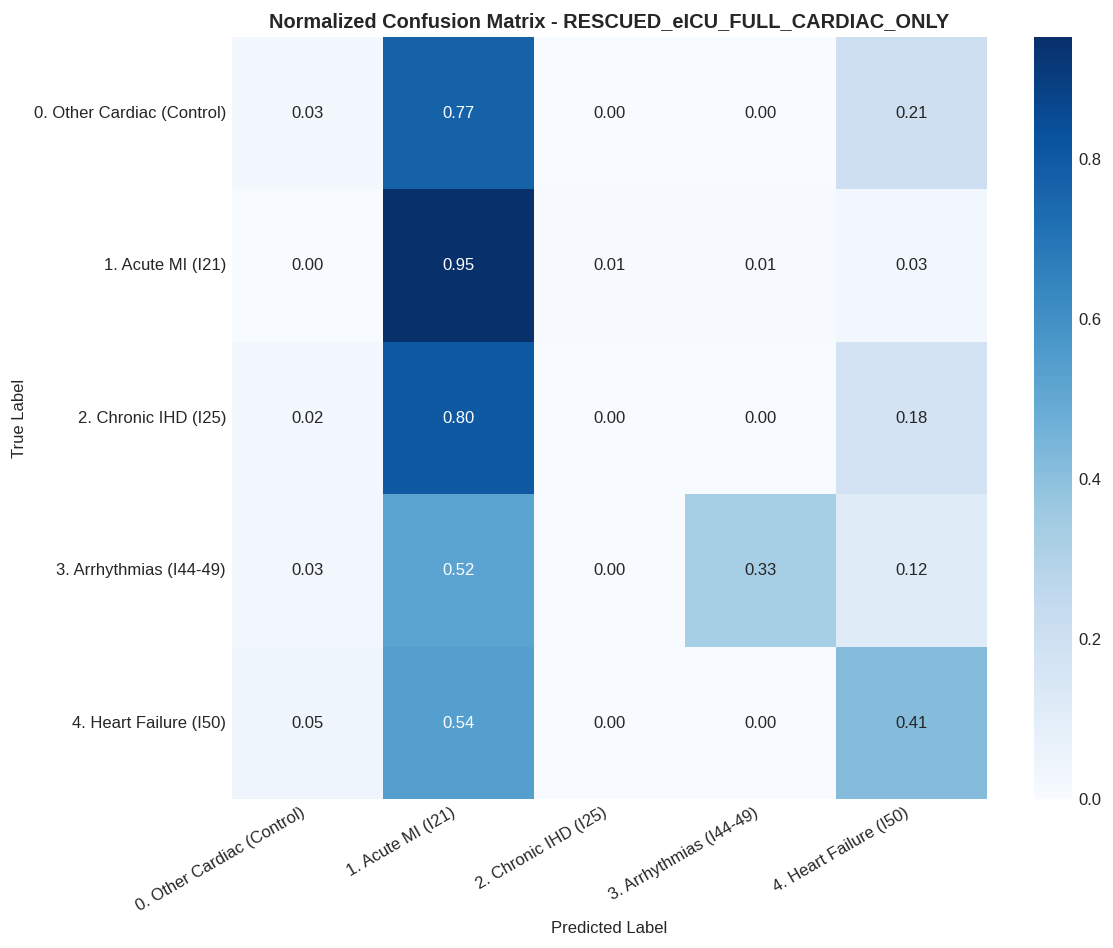

💾 Saved predictions: /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_eICU_RESCUED_predictions_FULL.csv

🚀 EVALUATING: RESCUED_eICU_MEASURABLE_PRIMARY

📊 SUMMARY METRICS
   - Cohort            : RESCUED_eICU_MEASURABLE_PRIMARY
   - N                 : 89912
   - Accuracy          : 0.2699
   - Macro F1          : 0.2377
   - Weighted F1       : 0.2357
   - Macro Recall      : 0.3516
   - Macro Precision   : 0.3745
   - MCC               : 0.2188
   - Macro AUC         : 0.7068
   - Micro AUC         : 0.5697
   - Macro AUPRC       : 0.4566
   - Micro AUPRC       : 0.2958

📄 CLASSIFICATION REPORT
                            precision    recall  f1-score   support

0. Other Cardiac (Control)     0.4308    0.0283    0.0531     38536
         1. Acute MI (I21)     0.1600    0.9520    0.2739     10262
      2. Chronic IHD (I25)     0.0000    0.0000    0.0000      5409
   3. Arrhythmias (I44-49)     0.9909    0.3470    0.5140     23582
    4. Heart Failure (I50)     0.2910    0.

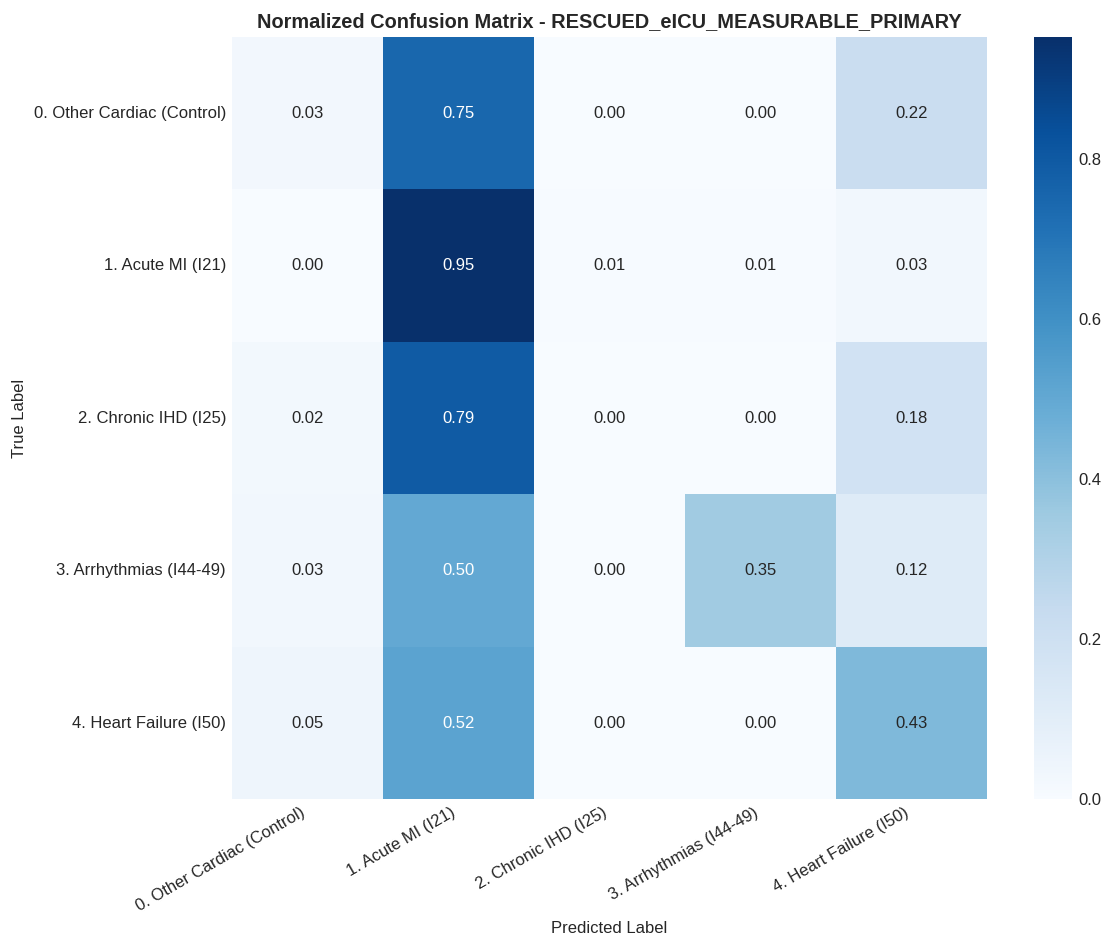

💾 Saved predictions: /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_eICU_RESCUED_predictions_MEASURABLE.csv

🚀 EVALUATING: RESCUED_eICU_PREVALENCE_ADJUSTED

📊 SUMMARY METRICS
   - Cohort            : RESCUED_eICU_PREVALENCE_ADJUSTED
   - N                 : 25350
   - Accuracy          : 0.5179
   - Macro F1          : 0.3063
   - Weighted F1       : 0.4440
   - Macro Recall      : 0.3470
   - Macro Precision   : 0.3894
   - MCC               : 0.3190
   - Macro AUC         : 0.7682
   - Micro AUC         : 0.7834
   - Macro AUPRC       : 0.4474
   - Micro AUPRC       : 0.5945

📄 CLASSIFICATION REPORT
                            precision    recall  f1-score   support

0. Other Cardiac (Control)     0.2250    0.0251    0.0451      4311
         1. Acute MI (I21)     0.5139    0.9520    0.6675     10262
      2. Chronic IHD (I25)     0.0000    0.0000    0.0000      1874
   3. Arrhythmias (I44-49)     0.9707    0.3553    0.5202      7005
    4. Heart Failure (I50)     0.23

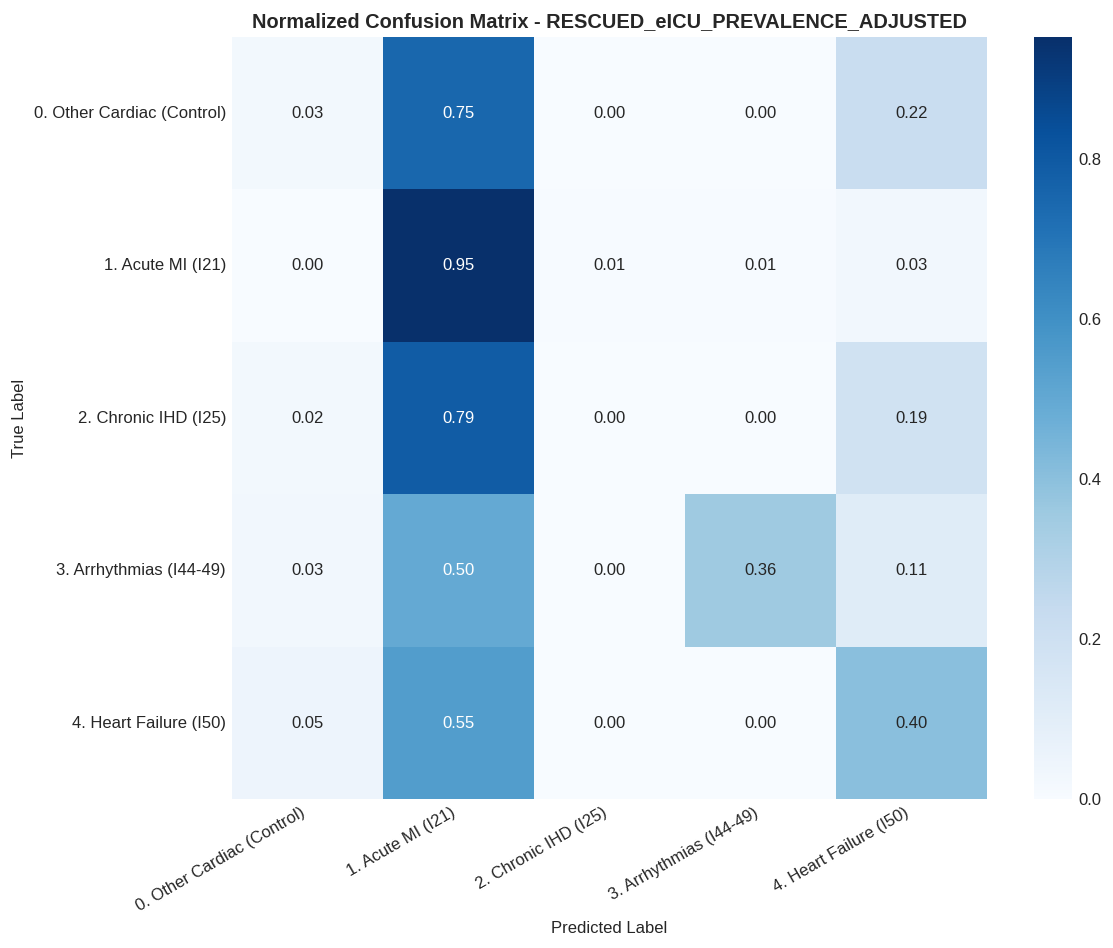

💾 Saved predictions: /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_eICU_RESCUED_predictions_PREVALENCE_ADJUSTED.csv

📊 FINAL RESCUED eICU VALIDATION SUMMARY
                          Cohort     N  Accuracy  Macro F1  Weighted F1  Macro Recall  Macro Precision  Macro AUC  Macro AUPRC  Micro AUC  Micro AUPRC    MCC
  RESCUED_eICU_FULL_CARDIAC_ONLY 95777    0.2557    0.2289       0.2237        0.3450           0.3722     0.7037       0.4558     0.5538       0.2849 0.2096
 RESCUED_eICU_MEASURABLE_PRIMARY 89912    0.2699    0.2377       0.2357        0.3516           0.3745     0.7068       0.4566     0.5697       0.2958 0.2188
RESCUED_eICU_PREVALENCE_ADJUSTED 25350    0.5179    0.3063       0.4440        0.3470           0.3894     0.7682       0.4474     0.7834       0.5945 0.3190

📊 PER-CLASS PERFORMANCE
                          Cohort  Encoded_Label  Original_Label                      Class  Precision  Recall     F1  Support
  RESCUED_eICU_FULL_CARDIAC_ONLY            

In [ ]:
# @title BLOCK 10R: TRUE EXTERNAL VALIDATION ON RESCUED CARDIAC-ONLY eICU
# =============================================================================
# OBJECTIVE:
# Validate locked Pipeline 6 model on rescued cardiac-only eICU cohort from Block 10.5.
# No eICU fitting, no retraining, no threshold tuning.
# =============================================================================

!pip install xgboost seaborn pandas numpy matplotlib scikit-learn

import os
import pickle
import warnings
import numpy as np
import pandas as pd
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_score,
    roc_auc_score, average_precision_score, matthews_corrcoef,
    classification_report, confusion_matrix
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120

# =============================================================================
# 1. PATHS
# =============================================================================
SAVE_DIR = "/content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN"

PATH_TRAIN_READY = os.path.join(SAVE_DIR, "pipeline6_READY_TRAIN_MAIN.pkl")
PATH_MIMIC_EXT_READY = os.path.join(SAVE_DIR, "pipeline6_READY_VALIDATE_EXTERNAL.pkl")
PATH_MODEL = os.path.join(SAVE_DIR, "pipeline6_best_xgb.json")
PATH_EICU_RESCUED = os.path.join(SAVE_DIR, "eICU_cohort_mapped_features_RESCUED.csv")

PATH_SAVE_RESULTS = os.path.join(SAVE_DIR, "pipeline6_eICU_RESCUED_validation_results.csv")
PATH_SAVE_PER_CLASS = os.path.join(SAVE_DIR, "pipeline6_eICU_RESCUED_validation_per_class.csv")
PATH_SAVE_FEATURE_AUDIT = os.path.join(SAVE_DIR, "pipeline6_eICU_RESCUED_feature_audit.csv")

PATH_SAVE_PRED_FULL = os.path.join(SAVE_DIR, "pipeline6_eICU_RESCUED_predictions_FULL.csv")
PATH_SAVE_PRED_MEAS = os.path.join(SAVE_DIR, "pipeline6_eICU_RESCUED_predictions_MEASURABLE.csv")
PATH_SAVE_PRED_ADJ = os.path.join(SAVE_DIR, "pipeline6_eICU_RESCUED_predictions_PREVALENCE_ADJUSTED.csv")

# =============================================================================
# 2. LOAD LOCKED MIMIC ARTIFACTS
# =============================================================================
print("\n" + "="*90)
print("🔒 [STEP 1] LOADING LOCKED MIMIC ARTIFACTS")
print("="*90)

with open(PATH_TRAIN_READY, "rb") as f:
    mimic_train = pickle.load(f)

with open(PATH_MIMIC_EXT_READY, "rb") as f:
    mimic_ext = pickle.load(f)

feature_names = mimic_train["feature_names"]
imputer = mimic_train["imputer"]
scaler = mimic_train["scaler"]
le = mimic_train["le"]

n_classes = len(le.classes_)

target_names = [
    "0. Other Cardiac (Control)",
    "1. Acute MI (I21)",
    "2. Chronic IHD (I25)",
    "3. Arrhythmias (I44-49)",
    "4. Heart Failure (I50)"
]

model = xgb.XGBClassifier()
model.load_model(PATH_MODEL)

print(f"✅ Locked features ({len(feature_names)}): {feature_names}")
print(f"✅ MIMIC label classes: {list(le.classes_)}")
print(f"✅ Loaded model: {PATH_MODEL}")

# =============================================================================
# 3. LOAD RESCUED eICU
# =============================================================================
print("\n" + "="*90)
print("📥 [STEP 2] LOADING RESCUED CARDIAC-ONLY eICU COHORT")
print("="*90)

df_eicu = pd.read_csv(PATH_EICU_RESCUED)
print(f"✅ Rescued eICU shape: {df_eicu.shape}")

id_col = "patientunitstayid"
if id_col not in df_eicu.columns:
    raise ValueError("❌ Missing patientunitstayid.")
if "Y_LABEL" not in df_eicu.columns:
    raise ValueError("❌ Missing Y_LABEL.")

valid_labels = set(le.classes_)
df_eicu = df_eicu[df_eicu["Y_LABEL"].isin(valid_labels)].copy()
print(f"✅ Rows with valid labels: {len(df_eicu):,}")

# =============================================================================
# 4. FEATURE ALIGNMENT
# =============================================================================
print("\n" + "="*90)
print("🧬 [STEP 3] FEATURE ALIGNMENT + RESCUED FEATURE AUDIT")
print("="*90)

biological_continuous = [
    f for f in feature_names
    if f.startswith("LAB_") or f.startswith("ECHO_") or f == "DEMO_AGE"
]

binary_or_text = [
    f for f in feature_names
    if f.startswith("ECG_") or f.startswith("TXT_") or f.startswith("DEMO_RACE_") or f == "DEMO_GENDER_MALE"
]

for col in feature_names:
    if col not in df_eicu.columns:
        if col in biological_continuous:
            df_eicu[col] = np.nan
        else:
            df_eicu[col] = 0

for col in feature_names:
    df_eicu[col] = pd.to_numeric(df_eicu[col], errors="coerce")

# Preserve clinical missingness for labs/echo
df_eicu[biological_continuous] = df_eicu[biological_continuous].replace(0, np.nan)
df_eicu[binary_or_text] = df_eicu[binary_or_text].fillna(0)

# Feature audit
audit_rows = []
for col in feature_names:
    s = df_eicu[col]
    missing_n = s.isna().sum()
    missing_pct = missing_n / len(df_eicu) * 100

    if col in biological_continuous:
        observed = s.dropna()
        audit_rows.append({
            "feature": col,
            "type": "biological_continuous",
            "missing_n": missing_n,
            "missing_pct": missing_pct,
            "mean": observed.mean() if len(observed) else np.nan,
            "median": observed.median() if len(observed) else np.nan,
            "positive_or_nonzero_pct": np.nan
        })
    else:
        observed = s.fillna(0)
        audit_rows.append({
            "feature": col,
            "type": "binary_or_text",
            "missing_n": missing_n,
            "missing_pct": missing_pct,
            "mean": observed.mean(),
            "median": observed.median(),
            "positive_or_nonzero_pct": (observed > 0).mean() * 100
        })

df_feature_audit = pd.DataFrame(audit_rows)
print(df_feature_audit.round(3).to_string(index=False))
df_feature_audit.to_csv(PATH_SAVE_FEATURE_AUDIT, index=False)

# Count actual measured/signal features
core_biological = [c for c in ["LAB_Creatinine", "LAB_NTproBNP", "LAB_RDW", "LAB_Troponin_T", "ECHO_LVEF"] if c in feature_names]
core_binary = [c for c in ["ECG_AFIB", "ECG_ST_ELEV", "TXT_dyspnea", "TXT_st_changes", "TXT_weight"] if c in feature_names]

df_eicu["N_MEASURED_BIO_FEATURES"] = df_eicu[core_biological].notna().sum(axis=1)
df_eicu["N_POSITIVE_SIGNAL_FEATURES"] = (df_eicu[core_binary].fillna(0) > 0).sum(axis=1)
df_eicu["N_TOTAL_AVAILABLE_SIGNALS"] = df_eicu["N_MEASURED_BIO_FEATURES"] + df_eicu["N_POSITIVE_SIGNAL_FEATURES"]

print("\n📊 Availability count summary:")
print(df_eicu[["N_MEASURED_BIO_FEATURES", "N_POSITIVE_SIGNAL_FEATURES", "N_TOTAL_AVAILABLE_SIGNALS"]].describe().round(3))

# =============================================================================
# 5. COHORT DEFINITIONS
# =============================================================================
print("\n" + "="*90)
print("🧪 [STEP 4] DEFINING RESCUED VALIDATION COHORTS")
print("="*90)

df_full = df_eicu.copy()

# Primary measurable cohort:
# at least 2 measured biological variables OR at least 3 total observed signals.
df_measurable = df_eicu[
    (df_eicu["N_MEASURED_BIO_FEATURES"] >= 2) |
    (df_eicu["N_TOTAL_AVAILABLE_SIGNALS"] >= 3)
].copy()

# Prevalence-adjusted sensitivity cohort matched to MIMIC temporal external distribution
mimic_ext_original = le.inverse_transform(mimic_ext["y"])
mimic_ext_dist = pd.Series(mimic_ext_original).value_counts(normalize=True).sort_index()

def make_prevalence_adjusted_cohort(df_source, target_dist, label_col="Y_LABEL", random_state=42):
    counts = df_source[label_col].value_counts().to_dict()

    possible_total_sizes = []
    for lbl, prop in target_dist.items():
        if prop > 0 and lbl in counts:
            possible_total_sizes.append(int(counts[lbl] / prop))

    if not possible_total_sizes:
        return df_source.copy()

    target_total = min(possible_total_sizes)

    sampled_parts = []
    for lbl, prop in target_dist.items():
        if lbl not in counts:
            continue
        n_target = int(round(target_total * prop))
        n_target = max(1, min(n_target, counts[lbl]))
        sampled_parts.append(
            df_source[df_source[label_col] == lbl].sample(
                n=n_target, random_state=random_state, replace=False
            )
        )

    return pd.concat(sampled_parts).sample(frac=1, random_state=random_state).reset_index(drop=True)

df_adjusted = make_prevalence_adjusted_cohort(df_measurable, mimic_ext_dist)

def print_label_distribution(df, name):
    print(f"\n📌 {name}: N={len(df):,}")
    counts = df["Y_LABEL"].value_counts().sort_index()
    for lbl in sorted(valid_labels):
        n = counts.get(lbl, 0)
        pct = n / len(df) * 100 if len(df) else 0
        encoded = le.transform([lbl])[0]
        print(f"   - {lbl:<2} | {target_names[encoded]:<32} | {n:>8,} | {pct:>6.2f}%")

print_label_distribution(df_full, "A. Rescued cardiac-only full eICU")
print_label_distribution(df_measurable, "B. Rescued measurable primary eICU")
print_label_distribution(df_adjusted, "C. Rescued prevalence-adjusted eICU")

print("\n📌 MIMIC temporal external target distribution:")
for lbl, prop in mimic_ext_dist.items():
    encoded = le.transform([lbl])[0]
    print(f"   - {lbl:<2} | {target_names[encoded]:<32} | {prop*100:>6.2f}%")

# =============================================================================
# 6. LOCKED PREPROCESSING AND EVALUATION
# =============================================================================
def preprocess_locked(df):
    X_raw = df[feature_names].copy()
    X_raw[biological_continuous] = X_raw[biological_continuous].replace(0, np.nan)
    X_raw[binary_or_text] = X_raw[binary_or_text].fillna(0)

    X_imp = imputer.transform(X_raw)
    X_scaled = scaler.transform(X_imp)

    y_original = df["Y_LABEL"].astype(int)
    y_encoded = le.transform(y_original)
    ids = df[id_col].values
    return X_scaled, y_encoded, y_original.values, ids

def calculate_metrics(y_true, y_pred, y_proba, cohort_name):
    y_onehot = label_binarize(y_true, classes=range(n_classes))

    out = {
        "Cohort": cohort_name,
        "N": len(y_true),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Weighted F1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "Macro Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "MCC": matthews_corrcoef(y_true, y_pred)
    }

    try:
        out["Macro AUC"] = roc_auc_score(y_true, y_proba, multi_class="ovr", average="macro")
        out["Micro AUC"] = roc_auc_score(y_true, y_proba, multi_class="ovr", average="micro")
    except Exception:
        out["Macro AUC"] = np.nan
        out["Micro AUC"] = np.nan

    try:
        out["Macro AUPRC"] = average_precision_score(y_onehot, y_proba, average="macro")
        out["Micro AUPRC"] = average_precision_score(y_onehot, y_proba, average="micro")
    except Exception:
        out["Macro AUPRC"] = np.nan
        out["Micro AUPRC"] = np.nan

    return out

def evaluate_cohort(df, cohort_name, save_path):
    print("\n" + "="*90)
    print(f"🚀 EVALUATING: {cohort_name}")
    print("="*90)

    X, y, y_orig, ids = preprocess_locked(df)
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)

    metrics = calculate_metrics(y, y_pred, y_proba, cohort_name)

    print("\n📊 SUMMARY METRICS")
    for k, v in metrics.items():
        if isinstance(v, float):
            print(f"   - {k:<18}: {v:.4f}")
        else:
            print(f"   - {k:<18}: {v}")

    print("\n📄 CLASSIFICATION REPORT")
    print(classification_report(
        y,
        y_pred,
        labels=range(n_classes),
        target_names=target_names,
        digits=4,
        zero_division=0
    ))

    report_dict = classification_report(
        y,
        y_pred,
        labels=range(n_classes),
        target_names=target_names,
        output_dict=True,
        zero_division=0
    )

    per_class_rows = []
    for i, name in enumerate(target_names):
        row = report_dict.get(name, {})
        per_class_rows.append({
            "Cohort": cohort_name,
            "Encoded_Label": i,
            "Original_Label": le.inverse_transform([i])[0],
            "Class": name,
            "Precision": row.get("precision", np.nan),
            "Recall": row.get("recall", np.nan),
            "F1": row.get("f1-score", np.nan),
            "Support": row.get("support", np.nan)
        })

    cm = confusion_matrix(y, y_pred, labels=range(n_classes), normalize="true")
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=target_names,
        yticklabels=target_names
    )
    plt.title(f"Normalized Confusion Matrix - {cohort_name}", fontweight="bold")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.xticks(rotation=30, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    df_pred = pd.DataFrame({
        id_col: ids,
        "Y_TRUE_ORIGINAL": y_orig,
        "Y_TRUE_ENCODED": y,
        "Y_PRED_ENCODED": y_pred,
        "Y_PRED_ORIGINAL": le.inverse_transform(y_pred)
    })

    for i, name in enumerate(target_names):
        df_pred[f"PROBA_CLASS_{i}_{name}"] = y_proba[:, i]

    df_pred.to_csv(save_path, index=False)
    print(f"💾 Saved predictions: {save_path}")

    return metrics, pd.DataFrame(per_class_rows)

# =============================================================================
# 7. RUN VALIDATION
# =============================================================================
print("\n" + "="*90)
print("🏁 [STEP 5] RUNNING RESCUED eICU EXTERNAL VALIDATION")
print("="*90)

all_metrics = []
all_per_class = []

m1, pc1 = evaluate_cohort(
    df_full,
    "RESCUED_eICU_FULL_CARDIAC_ONLY",
    PATH_SAVE_PRED_FULL
)
all_metrics.append(m1)
all_per_class.append(pc1)

m2, pc2 = evaluate_cohort(
    df_measurable,
    "RESCUED_eICU_MEASURABLE_PRIMARY",
    PATH_SAVE_PRED_MEAS
)
all_metrics.append(m2)
all_per_class.append(pc2)

m3, pc3 = evaluate_cohort(
    df_adjusted,
    "RESCUED_eICU_PREVALENCE_ADJUSTED",
    PATH_SAVE_PRED_ADJ
)
all_metrics.append(m3)
all_per_class.append(pc3)

df_metrics = pd.DataFrame(all_metrics)
df_per_class = pd.concat(all_per_class, ignore_index=True)

# =============================================================================
# 8. FINAL TABLES
# =============================================================================
print("\n" + "="*90)
print("📊 FINAL RESCUED eICU VALIDATION SUMMARY")
print("="*90)

display_cols = [
    "Cohort", "N", "Accuracy", "Macro F1", "Weighted F1",
    "Macro Recall", "Macro Precision", "Macro AUC", "Macro AUPRC",
    "Micro AUC", "Micro AUPRC", "MCC"
]

print(df_metrics[display_cols].round(4).to_string(index=False))

print("\n📊 PER-CLASS PERFORMANCE")
print(df_per_class.round(4).to_string(index=False))

df_metrics.to_csv(PATH_SAVE_RESULTS, index=False)
df_per_class.to_csv(PATH_SAVE_PER_CLASS, index=False)

print(f"\n💾 Saved summary: {PATH_SAVE_RESULTS}")
print(f"💾 Saved per-class: {PATH_SAVE_PER_CLASS}")
print(f"💾 Saved feature audit: {PATH_SAVE_FEATURE_AUDIT}")

print("\n" + "="*90)
print("🧾 INTERPRETATION NOTES")
print("="*90)
print("""
1. This validation uses the rescued cardiac-only eICU cohort from Block 10.5.
2. The model, imputer, scaler, and feature set remain locked from MIMIC-IV.
3. No eICU data were used for fitting, retraining, tuning, or threshold selection.
4. Compared with the initial eICU adapter, rescued mapping recovered RDW, BNP/NT-proBNP,
   ECG_AFIB, ECG_ST_ELEV, and ST-change signals.
5. ECHO_LVEF and TXT_dyspnea remain major cross-database missingness limitations.
6. The prevalence-adjusted analysis is a sensitivity analysis, not the primary result.
""")

print("\n✅ BLOCK 10R COMPLETE.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 5.1 MB/s eta 0:00:00

🚀 BLOCK 11: PORTABLE CROSS-DATABASE MODEL
📌 Candidate portable features:
['ECG_AFIB', 'ECG_ST_ELEV', 'ECHO_LVEF', 'LAB_Creatinine', 'LAB_NTproBNP', 'LAB_RDW', 'LAB_Troponin_T', 'TXT_st_changes', 'TXT_weight', 'LAB_Urea_Nitrogen', 'LAB_Potassium', 'LAB_Magnesium', 'LAB_White_Blood_Cells', 'LAB_C_Reactive_Protein', 'DEMO_AGE', 'DEMO_GENDER_MALE', 'DEMO_RACE_WHITE', 'DEMO_RACE_BLACK', 'DEMO_RACE_HISPANIC', 'DEMO_RACE_ASIAN', 'DEMO_RACE_OTHER']

📥 [STEP 1] LOADING MIMIC MASTER DATA
✅ MIMIC MAIN: X=(3679, 540), y=(3679,)
✅ MIMIC EXT : X=(1082, 540), y=(1082,)

✅ Portable features found in MIMIC: 21
['ECG_AFIB', 'ECG_ST_ELEV', 'ECHO_LVEF', 'LAB_Creatinine', 'LAB_NTproBNP', 'LAB_RDW', 'LAB_Troponin_T', 'TXT_st_changes', 'TXT_weight', 'LAB_Urea_Nitrogen', 'LAB_Potassium', 'LAB_Magnesium', 'LAB_White_Blood_Cells', 'LAB_C_Reactive_Protein', 'DEMO_AGE', 'DEMO_GENDER_MALE', 'DEMO_RACE_WHITE', 'DEMO_RACE_BLACK', 'DEMO_

  0%|          | 0/20 [00:00<?, ?it/s]

✅ Optuna best CV Macro AUPRC: 0.7472
✅ Optuna params: {'n_estimators': 224, 'max_depth': 6, 'learning_rate': 0.02096922686105989, 'min_child_weight': 4, 'gamma': 0.2537581042595024, 'subsample': 0.8234536377208201, 'colsample_bytree': 0.6625756060902627, 'reg_alpha': 0.3526104284733903, 'reg_lambda': 0.012138282862536206}
✅ Optuna MIMIC Ext Macro AUPRC: 0.6958

📊 PORTABLE MODEL BENCHMARK ON MIMIC TEMPORAL EXTERNAL
                       Model  CV F1 Mean                   CV F1 95CI  MIMIC Ext Macro F1  MIMIC Ext Macro AUC  MIMIC Ext Macro AUPRC  MIMIC Ext MCC
     Portable XGBoost Optuna         NaN Optuna optimized Macro AUPRC              0.6452               0.9028                 0.6958         0.6044
      Portable Random Forest      0.7212             [0.7115, 0.7310]              0.6717               0.9100                 0.6810         0.6503
       Portable XGBoost Base      0.7344             [0.7257, 0.7432]              0.6321               0.8987                 0.6802  

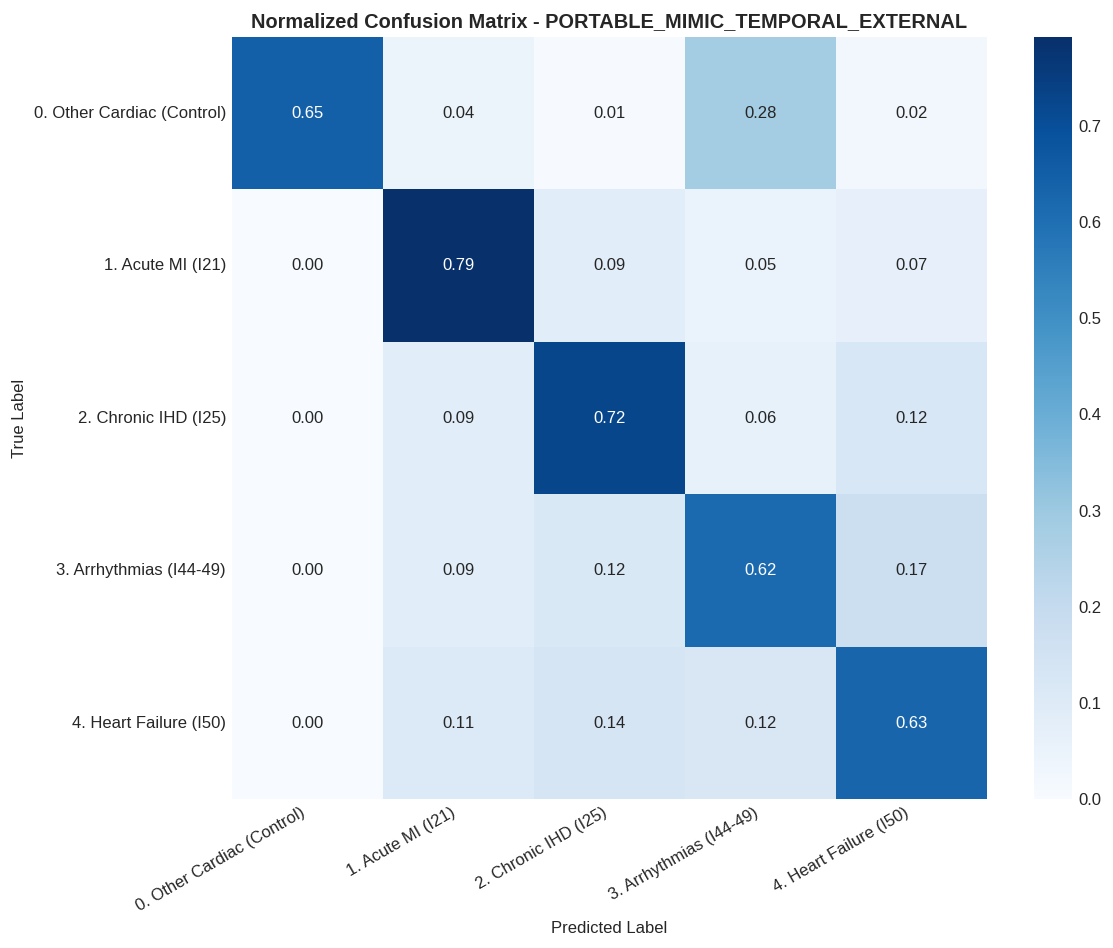

💾 Saved predictions: /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_PORTABLE_predictions_MIMIC_EXT.csv

🌎 [STEP 5] PREPARING RESCUED eICU FOR PORTABLE MODEL VALIDATION

📊 PORTABLE FEATURE AVAILABILITY ON eICU
               feature                  type  missing_n  missing_pct     mean  median  positive_or_nonzero_pct
              ECG_AFIB binary_or_categorical          0        0.000    0.170   0.000                   16.965
           ECG_ST_ELEV binary_or_categorical          0        0.000    0.106   0.000                   10.618
             ECHO_LVEF biological_continuous      95607       99.823   25.000  25.000                      NaN
        LAB_Creatinine biological_continuous       2408        2.514    2.299   1.046                      NaN
          LAB_NTproBNP biological_continuous      76960       80.353 3207.553 658.500                      NaN
               LAB_RDW biological_continuous       8805        9.193   15.318  14.717                      NaN

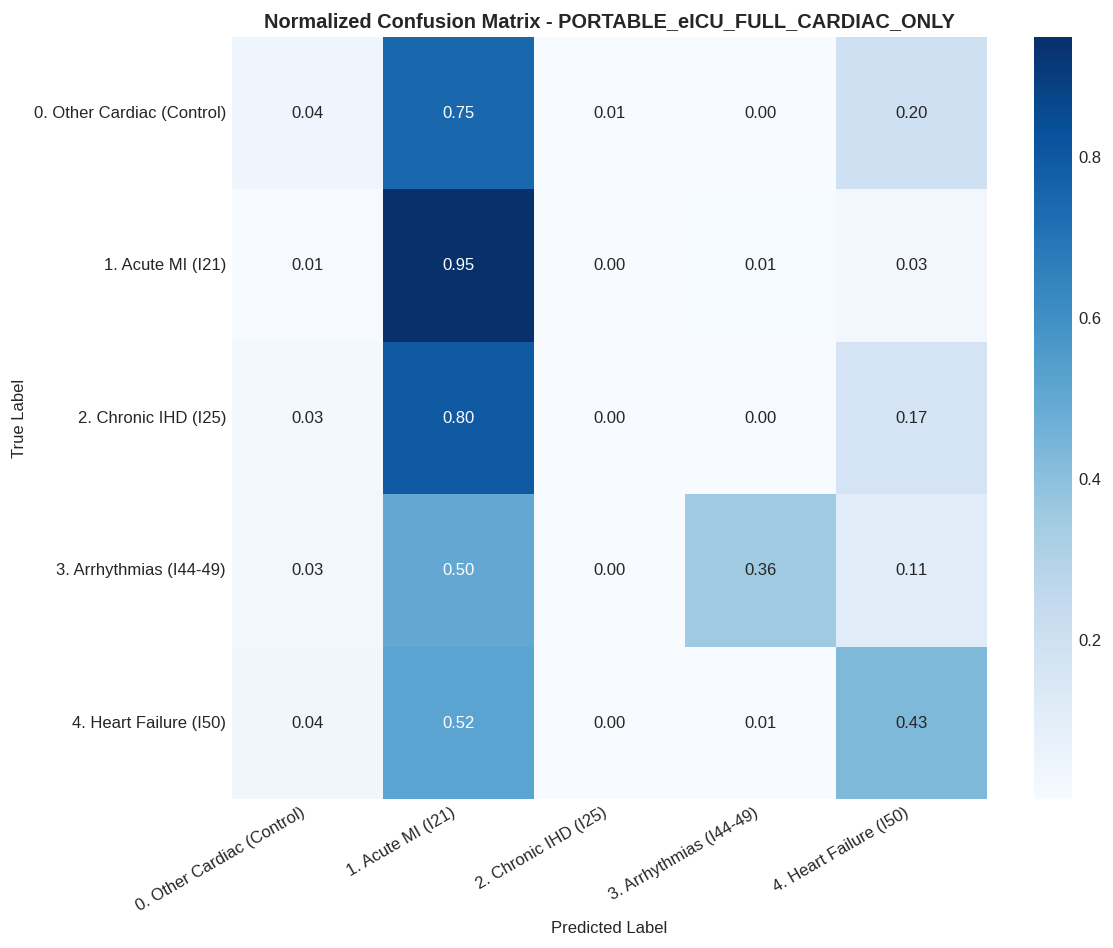

💾 Saved predictions: /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_PORTABLE_predictions_eICU_FULL.csv

📊 EVALUATION: PORTABLE_eICU_MEASURABLE_PRIMARY
   - Cohort            : PORTABLE_eICU_MEASURABLE_PRIMARY
   - N                 : 93851
   - Accuracy          : 0.2749
   - Macro F1          : 0.2471
   - Weighted F1       : 0.2491
   - Macro Recall      : 0.3576
   - Macro Precision   : 0.4046
   - MCC               : 0.2261
   - Macro AUC         : 0.7269
   - Micro AUC         : 0.6856
   - Macro AUPRC       : 0.4498
   - Micro AUPRC       : 0.3387

📄 CLASSIFICATION REPORT
                            precision    recall  f1-score   support

0. Other Cardiac (Control)     0.5421    0.0445    0.0823     40961
         1. Acute MI (I21)     0.1551    0.9486    0.2667     10335
      2. Chronic IHD (I25)     0.0524    0.0039    0.0073      5639
   3. Arrhythmias (I44-49)     0.9702    0.3573    0.5222     24427
    4. Heart Failure (I50)     0.3032    0.4339    0.3570  

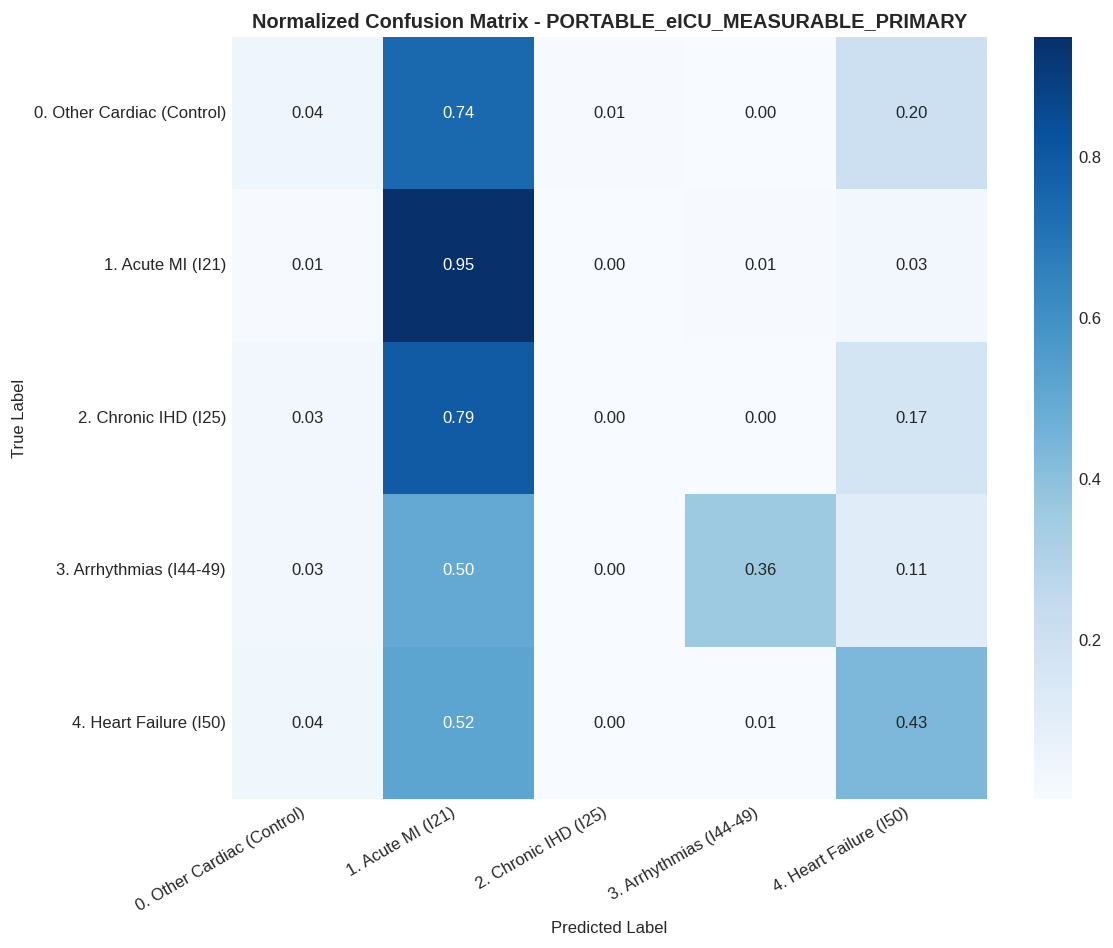

💾 Saved predictions: /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_PORTABLE_predictions_eICU_MEASURABLE.csv

📊 EVALUATION: PORTABLE_eICU_PREVALENCE_ADJUSTED
   - Cohort            : PORTABLE_eICU_PREVALENCE_ADJUSTED
   - N                 : 25531
   - Accuracy          : 0.5223
   - Macro F1          : 0.3183
   - Weighted F1       : 0.4514
   - Macro Recall      : 0.3569
   - Macro Precision   : 0.4138
   - MCC               : 0.3254
   - Macro AUC         : 0.7853
   - Micro AUC         : 0.8232
   - Macro AUPRC       : 0.4588
   - Micro AUPRC       : 0.6194

📄 CLASSIFICATION REPORT
                            precision    recall  f1-score   support

0. Other Cardiac (Control)     0.2893    0.0424    0.0739      4342
         1. Acute MI (I21)     0.5171    0.9486    0.6694     10335
      2. Chronic IHD (I25)     0.0515    0.0026    0.0050      1888
   3. Arrhythmias (I44-49)     0.9515    0.3559    0.5181      7055
    4. Heart Failure (I50)     0.2597    0.4349    

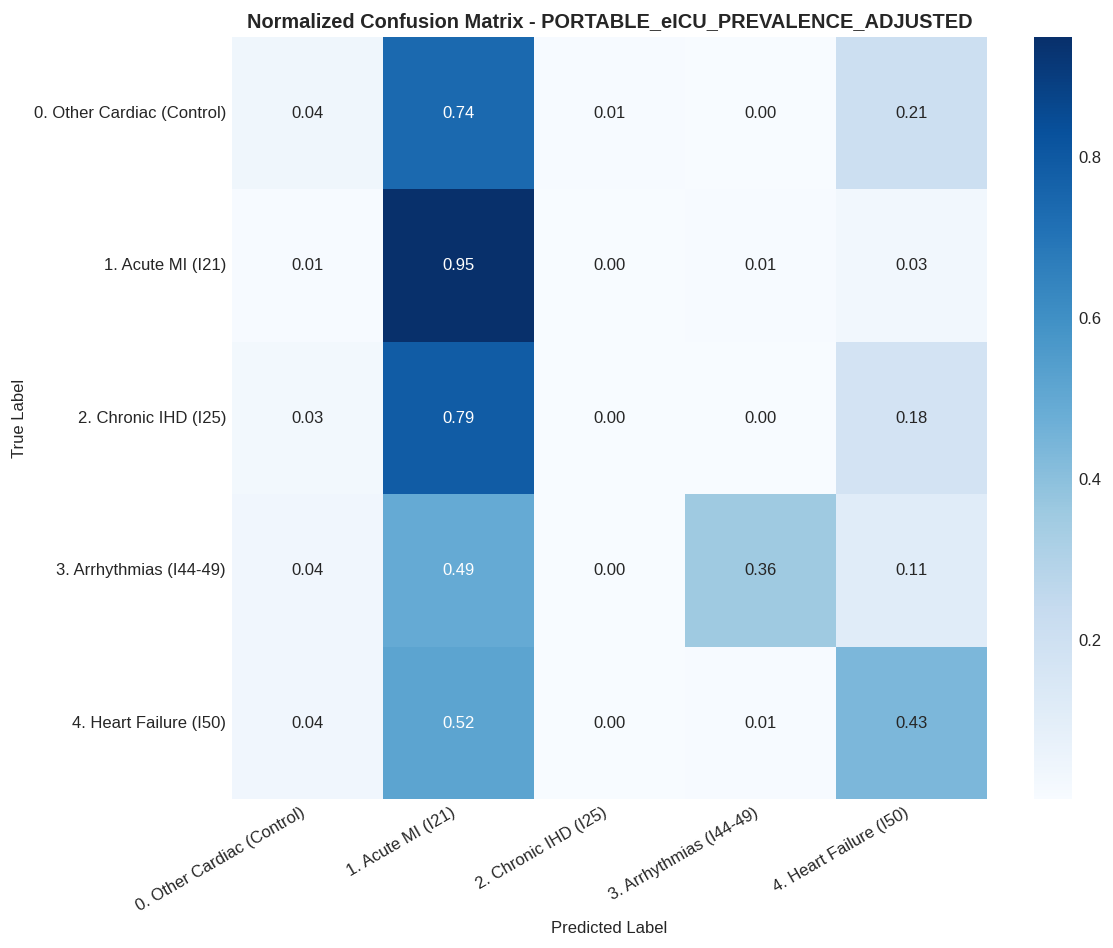

💾 Saved predictions: /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_PORTABLE_predictions_eICU_PREVALENCE_ADJUSTED.csv

📊 FINAL PORTABLE MODEL SUMMARY

🏆 Best portable model:
Portable XGBoost Optuna

📌 MIMIC temporal external performance:
                          Cohort    N  Accuracy  Macro F1  Weighted F1  Macro Recall  Macro Precision    MCC  Macro AUC  Micro AUC  Macro AUPRC  Micro AUPRC
PORTABLE_MIMIC_TEMPORAL_EXTERNAL 1082    0.7024    0.6452       0.7196        0.6825           0.6581 0.6044     0.9028      0.917       0.6958       0.7656

📌 eICU external validation performance:
                           Cohort     N  Accuracy  Macro F1  Weighted F1  Macro Recall  Macro Precision  Macro AUC  Macro AUPRC  Micro AUC  Micro AUPRC    MCC
  PORTABLE_eICU_FULL_CARDIAC_ONLY 95777    0.2711    0.2448       0.2461        0.3560           0.4038     0.7258       0.4494     0.6831       0.3358 0.2239
 PORTABLE_eICU_MEASURABLE_PRIMARY 93851    0.2749    0.2471       0.2491  

In [ ]:
# @title BLOCK 11: PORTABLE CROSS-DATABASE MODEL - MIMIC TRAINING + eICU VALIDATION
# =============================================================================
# OBJECTIVE:
# Build a secondary portable model using features that can be mapped across MIMIC-IV and eICU.
#
# IMPORTANT:
# - This block DOES NOT overwrite Block 9 primary model.
# - eICU is used only for external validation.
# - Imputer/scaler/model are fitted on MIMIC MAIN only.
# - Outputs are saved with pipeline6_PORTABLE_* prefix.
# =============================================================================

!pip install xgboost lightgbm optuna seaborn pandas numpy matplotlib scikit-learn

import os
import pickle
import warnings
import numpy as np
import pandas as pd
import xgboost as xgb
import lightgbm as lgb
import optuna
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_score,
    roc_auc_score, average_precision_score, matthews_corrcoef,
    classification_report, confusion_matrix
)
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120

# =============================================================================
# 1. PATH CONFIGURATION
# =============================================================================
SAVE_DIR = "/content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN"

# MIMIC master files from Block 5
PATH_MIMIC_X_MAIN = os.path.join(SAVE_DIR, "pipeline6_FINAL_X_MASTER_dataset_main.pkl")
PATH_MIMIC_Y_MAIN = os.path.join(SAVE_DIR, "pipeline6_FINAL_Y_MASTER_dataset_main.pkl")
PATH_MIMIC_X_EXT = os.path.join(SAVE_DIR, "pipeline6_FINAL_X_MASTER_external_validate.pkl")
PATH_MIMIC_Y_EXT = os.path.join(SAVE_DIR, "pipeline6_FINAL_Y_MASTER_external_validate.pkl")

# eICU rescued file from Block 10.5
PATH_EICU_RESCUED = os.path.join(SAVE_DIR, "eICU_cohort_mapped_features_RESCUED.csv")

# Portable outputs
PATH_PORTABLE_FEATURES = os.path.join(SAVE_DIR, "pipeline6_PORTABLE_feature_list.pkl")
PATH_PORTABLE_TRAIN_READY = os.path.join(SAVE_DIR, "pipeline6_PORTABLE_READY_TRAIN_MAIN.pkl")
PATH_PORTABLE_MIMIC_EXT_READY = os.path.join(SAVE_DIR, "pipeline6_PORTABLE_READY_VALIDATE_MIMIC_EXT.pkl")
PATH_PORTABLE_MODEL = os.path.join(SAVE_DIR, "pipeline6_PORTABLE_best_xgb.json")

PATH_PORTABLE_MIMIC_RESULTS = os.path.join(SAVE_DIR, "pipeline6_PORTABLE_MIMIC_temporal_results.csv")
PATH_PORTABLE_EICU_RESULTS = os.path.join(SAVE_DIR, "pipeline6_PORTABLE_eICU_validation_results.csv")
PATH_PORTABLE_EICU_PER_CLASS = os.path.join(SAVE_DIR, "pipeline6_PORTABLE_eICU_per_class.csv")
PATH_PORTABLE_FEATURE_AUDIT = os.path.join(SAVE_DIR, "pipeline6_PORTABLE_feature_availability_audit.csv")

PATH_PRED_MIMIC_EXT = os.path.join(SAVE_DIR, "pipeline6_PORTABLE_predictions_MIMIC_EXT.csv")
PATH_PRED_EICU_FULL = os.path.join(SAVE_DIR, "pipeline6_PORTABLE_predictions_eICU_FULL.csv")
PATH_PRED_EICU_MEAS = os.path.join(SAVE_DIR, "pipeline6_PORTABLE_predictions_eICU_MEASURABLE.csv")
PATH_PRED_EICU_ADJ = os.path.join(SAVE_DIR, "pipeline6_PORTABLE_predictions_eICU_PREVALENCE_ADJUSTED.csv")

# =============================================================================
# 2. PORTABLE FEATURE SET
# =============================================================================
# These features are intentionally broader than the strict 10-feature primary model
# and are selected because they can be mapped across MIMIC-IV and eICU.
CANDIDATE_PORTABLE_FEATURES = [
    # Final strict model features with partial/strong eICU rescue
    "ECG_AFIB",
    "ECG_ST_ELEV",
    "ECHO_LVEF",
    "LAB_Creatinine",
    "LAB_NTproBNP",
    "LAB_RDW",
    "LAB_Troponin_T",
    "TXT_st_changes",
    "TXT_weight",

    # Portable lab/demographic additions available in both databases
    "LAB_Urea_Nitrogen",
    "LAB_Potassium",
    "LAB_Magnesium",
    "LAB_White_Blood_Cells",
    "LAB_C_Reactive_Protein",
    "DEMO_AGE",
    "DEMO_GENDER_MALE",
    "DEMO_RACE_WHITE",
    "DEMO_RACE_BLACK",
    "DEMO_RACE_HISPANIC",
    "DEMO_RACE_ASIAN",
    "DEMO_RACE_OTHER"
]

LABEL_NAMES = [
    "0. Other Cardiac (Control)",
    "1. Acute MI (I21)",
    "2. Chronic IHD (I25)",
    "3. Arrhythmias (I44-49)",
    "4. Heart Failure (I50)"
]

print("\n" + "="*90)
print("🚀 BLOCK 11: PORTABLE CROSS-DATABASE MODEL")
print("="*90)
print("📌 Candidate portable features:")
print(CANDIDATE_PORTABLE_FEATURES)

# =============================================================================
# 3. LOAD MIMIC MASTER DATA
# =============================================================================
print("\n" + "="*90)
print("📥 [STEP 1] LOADING MIMIC MASTER DATA")
print("="*90)

X_main_raw = pd.read_pickle(PATH_MIMIC_X_MAIN)
y_main_raw = pd.read_pickle(PATH_MIMIC_Y_MAIN)

X_ext_raw = pd.read_pickle(PATH_MIMIC_X_EXT)
y_ext_raw = pd.read_pickle(PATH_MIMIC_Y_EXT)

print(f"✅ MIMIC MAIN: X={X_main_raw.shape}, y={y_main_raw.shape}")
print(f"✅ MIMIC EXT : X={X_ext_raw.shape}, y={y_ext_raw.shape}")

portable_features = [f for f in CANDIDATE_PORTABLE_FEATURES if f in X_main_raw.columns]
missing_in_mimic = sorted(set(CANDIDATE_PORTABLE_FEATURES) - set(portable_features))

print(f"\n✅ Portable features found in MIMIC: {len(portable_features)}")
print(portable_features)
if missing_in_mimic:
    print(f"⚠️ Missing in MIMIC and excluded: {missing_in_mimic}")

with open(PATH_PORTABLE_FEATURES, "wb") as f:
    pickle.dump(portable_features, f)
print(f"💾 Saved portable feature list: {PATH_PORTABLE_FEATURES}")

X_main = X_main_raw[portable_features].copy()
X_ext = X_ext_raw.reindex(columns=portable_features, fill_value=0).copy()

# =============================================================================
# 4. LABEL ENCODING
# =============================================================================
print("\n" + "="*90)
print("🏷️ [STEP 2] LABEL ENCODING")
print("="*90)

le = LabelEncoder()
y_main = le.fit_transform(y_main_raw)
y_ext = le.transform(y_ext_raw)

n_classes = len(le.classes_)
print(f"✅ Original labels: {list(le.classes_)}")
print(f"✅ Encoded classes: {list(range(n_classes))}")

# =============================================================================
# 5. PREPROCESSING FIT ON MIMIC MAIN ONLY
# =============================================================================
print("\n" + "="*90)
print("🧪 [STEP 3] PORTABLE PREPROCESSING: FIT MIMIC MAIN -> TRANSFORM MIMIC EXT/eICU")
print("="*90)

biological_continuous = [
    f for f in portable_features
    if f.startswith("LAB_") or f.startswith("ECHO_") or f == "DEMO_AGE"
]

binary_or_categorical = [
    f for f in portable_features if f not in biological_continuous
]

print(f"📌 Biological continuous features ({len(biological_continuous)}):")
print(biological_continuous)
print(f"📌 Binary/categorical/text features ({len(binary_or_categorical)}):")
print(binary_or_categorical)

# Restore NaN for biological variables where 0 likely means missingness
X_main_proc = X_main.copy()
X_ext_proc = X_ext.copy()

X_main_proc[biological_continuous] = X_main_proc[biological_continuous].replace(0, np.nan)
X_ext_proc[biological_continuous] = X_ext_proc[biological_continuous].replace(0, np.nan)

X_main_proc[binary_or_categorical] = X_main_proc[binary_or_categorical].fillna(0)
X_ext_proc[binary_or_categorical] = X_ext_proc[binary_or_categorical].fillna(0)

imputer = IterativeImputer(max_iter=10, random_state=42, initial_strategy="median")
scaler = StandardScaler()

print("   -> Fitting MICE imputer on MIMIC MAIN...")
X_main_imp = imputer.fit_transform(X_main_proc)

print("   -> Transforming MIMIC EXT...")
X_ext_imp = imputer.transform(X_ext_proc)

print("   -> Fitting scaler on MIMIC MAIN...")
X_main_scaled = scaler.fit_transform(X_main_imp)
X_ext_scaled = scaler.transform(X_ext_imp)

data_portable_train = {
    "X": X_main_scaled,
    "y": y_main,
    "feature_names": portable_features,
    "imputer": imputer,
    "scaler": scaler,
    "le": le,
    "original_ids": X_main_raw.index.tolist()
}

data_portable_ext = {
    "X": X_ext_scaled,
    "y": y_ext,
    "feature_names": portable_features,
    "original_ids": X_ext_raw.index.tolist()
}

with open(PATH_PORTABLE_TRAIN_READY, "wb") as f:
    pickle.dump(data_portable_train, f)

with open(PATH_PORTABLE_MIMIC_EXT_READY, "wb") as f:
    pickle.dump(data_portable_ext, f)

print(f"💾 Saved portable train ready: {PATH_PORTABLE_TRAIN_READY}")
print(f"💾 Saved portable MIMIC ext ready: {PATH_PORTABLE_MIMIC_EXT_READY}")

# =============================================================================
# 6. METRIC HELPERS
# =============================================================================
def calculate_metrics(y_true, y_pred, y_proba, cohort_name):
    y_onehot = label_binarize(y_true, classes=range(n_classes))

    out = {
        "Cohort": cohort_name,
        "N": len(y_true),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Weighted F1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "Macro Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "MCC": matthews_corrcoef(y_true, y_pred)
    }

    try:
        out["Macro AUC"] = roc_auc_score(y_true, y_proba, multi_class="ovr", average="macro")
        out["Micro AUC"] = roc_auc_score(y_true, y_proba, multi_class="ovr", average="micro")
    except Exception:
        out["Macro AUC"] = np.nan
        out["Micro AUC"] = np.nan

    try:
        out["Macro AUPRC"] = average_precision_score(y_onehot, y_proba, average="macro")
        out["Micro AUPRC"] = average_precision_score(y_onehot, y_proba, average="micro")
    except Exception:
        out["Macro AUPRC"] = np.nan
        out["Micro AUPRC"] = np.nan

    return out

def print_and_save_predictions(ids, y_true, y_pred, y_proba, save_path):
    df_pred = pd.DataFrame({
        "id": ids,
        "Y_TRUE_ENCODED": y_true,
        "Y_TRUE_ORIGINAL": le.inverse_transform(y_true),
        "Y_PRED_ENCODED": y_pred,
        "Y_PRED_ORIGINAL": le.inverse_transform(y_pred)
    })

    for i, name in enumerate(LABEL_NAMES):
        df_pred[f"PROBA_CLASS_{i}_{name}"] = y_proba[:, i]

    df_pred.to_csv(save_path, index=False)
    print(f"💾 Saved predictions: {save_path}")

def evaluate_dataset(model, X, y, cohort_name, ids=None, save_pred_path=None, plot_cm=True):
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)

    metrics = calculate_metrics(y, y_pred, y_proba, cohort_name)

    print("\n" + "="*90)
    print(f"📊 EVALUATION: {cohort_name}")
    print("="*90)
    for k, v in metrics.items():
        if isinstance(v, float):
            print(f"   - {k:<18}: {v:.4f}")
        else:
            print(f"   - {k:<18}: {v}")

    print("\n📄 CLASSIFICATION REPORT")
    print(classification_report(
        y,
        y_pred,
        labels=range(n_classes),
        target_names=LABEL_NAMES,
        digits=4,
        zero_division=0
    ))

    report_dict = classification_report(
        y,
        y_pred,
        labels=range(n_classes),
        target_names=LABEL_NAMES,
        output_dict=True,
        zero_division=0
    )

    per_class_rows = []
    for i, name in enumerate(LABEL_NAMES):
        row = report_dict.get(name, {})
        per_class_rows.append({
            "Cohort": cohort_name,
            "Encoded_Label": i,
            "Original_Label": le.inverse_transform([i])[0],
            "Class": name,
            "Precision": row.get("precision", np.nan),
            "Recall": row.get("recall", np.nan),
            "F1": row.get("f1-score", np.nan),
            "Support": row.get("support", np.nan)
        })

    if plot_cm:
        cm = confusion_matrix(y, y_pred, labels=range(n_classes), normalize="true")
        plt.figure(figsize=(10, 8))
        sns.heatmap(
            cm,
            annot=True,
            fmt=".2f",
            cmap="Blues",
            xticklabels=LABEL_NAMES,
            yticklabels=LABEL_NAMES
        )
        plt.title(f"Normalized Confusion Matrix - {cohort_name}", fontweight="bold")
        plt.xlabel("Predicted Label")
        plt.ylabel("True Label")
        plt.xticks(rotation=30, ha="right")
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()

    if save_pred_path is not None and ids is not None:
        print_and_save_predictions(ids, y, y_pred, y_proba, save_pred_path)

    return metrics, pd.DataFrame(per_class_rows)

# =============================================================================
# 7. TRAIN PORTABLE MODELS ON MIMIC MAIN
# =============================================================================
print("\n" + "="*90)
print("🏋️ [STEP 4] TRAINING PORTABLE MODELS ON MIMIC MAIN")
print("="*90)

sample_weights = compute_sample_weight(class_weight="balanced", y=y_main)

models = [
    ("Portable Logistic Regression", LogisticRegression(
        multi_class="ovr", max_iter=1000, class_weight="balanced", random_state=42
    )),
    ("Portable Random Forest", RandomForestClassifier(
        n_estimators=250, class_weight="balanced", random_state=42, n_jobs=4
    )),
    ("Portable LightGBM", lgb.LGBMClassifier(
        objective="multiclass", class_weight="balanced", n_estimators=200,
        learning_rate=0.04, n_jobs=4, random_state=42, verbose=-1
    )),
    ("Portable XGBoost Base", xgb.XGBClassifier(
        objective="multi:softprob", num_class=n_classes, eval_metric="mlogloss",
        n_estimators=220, learning_rate=0.04, max_depth=4,
        subsample=0.85, colsample_bytree=0.85,
        n_jobs=4, random_state=42, verbosity=0
    ))
]

benchmark_rows = []
best_model = None
best_model_name = None
best_score = -np.inf

for name, clf in models:
    print(f"\n🔹 Training {name}")

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(
        clf,
        X_main_scaled,
        y_main,
        cv=cv,
        scoring="f1_macro",
        n_jobs=1
    )

    ci = 1.96 * cv_scores.std() / np.sqrt(len(cv_scores))

    try:
        clf.fit(X_main_scaled, y_main, sample_weight=sample_weights)
    except TypeError:
        clf.fit(X_main_scaled, y_main)

    y_ext_pred = clf.predict(X_ext_scaled)
    y_ext_proba = clf.predict_proba(X_ext_scaled)
    ext_metrics = calculate_metrics(y_ext, y_ext_pred, y_ext_proba, "MIMIC_TEMPORAL_EXTERNAL")

    row = {
        "Model": name,
        "CV F1 Mean": cv_scores.mean(),
        "CV F1 95CI": f"[{cv_scores.mean()-ci:.4f}, {cv_scores.mean()+ci:.4f}]",
        "MIMIC Ext Macro F1": ext_metrics["Macro F1"],
        "MIMIC Ext Macro AUC": ext_metrics["Macro AUC"],
        "MIMIC Ext Macro AUPRC": ext_metrics["Macro AUPRC"],
        "MIMIC Ext MCC": ext_metrics["MCC"]
    }
    benchmark_rows.append(row)

    print(f"   CV F1: {cv_scores.mean():.4f} ± {ci:.4f}")
    print(f"   MIMIC Ext Macro F1: {ext_metrics['Macro F1']:.4f}")
    print(f"   MIMIC Ext Macro AUPRC: {ext_metrics['Macro AUPRC']:.4f}")

    # Choose by MIMIC temporal external Macro AUPRC, still not using eICU
    if ext_metrics["Macro AUPRC"] > best_score:
        best_score = ext_metrics["Macro AUPRC"]
        best_model = clf
        best_model_name = name

# Optional Optuna XGBoost tuned on MIMIC CV only
print("\n🧪 Optuna tuning Portable XGBoost on MIMIC MAIN only...")

def optuna_objective(trial):
    params = {
        "objective": "multi:softprob",
        "num_class": n_classes,
        "eval_metric": "mlogloss",
        "verbosity": 0,
        "n_jobs": 4,
        "random_state": 42,
        "n_estimators": trial.suggest_int("n_estimators", 180, 420),
        "max_depth": trial.suggest_int("max_depth", 3, 7),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.08, log=True),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0.1, 5.0),
        "subsample": trial.suggest_float("subsample", 0.65, 0.95),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.65, 0.95),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.01, 5.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.01, 5.0, log=True)
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []

    for tr_idx, va_idx in cv.split(X_main_scaled, y_main):
        X_tr, X_va = X_main_scaled[tr_idx], X_main_scaled[va_idx]
        y_tr, y_va = y_main[tr_idx], y_main[va_idx]
        w_tr = sample_weights[tr_idx]

        clf = xgb.XGBClassifier(**params)
        clf.fit(X_tr, y_tr, sample_weight=w_tr)

        proba = clf.predict_proba(X_va)
        y_onehot = label_binarize(y_va, classes=range(n_classes))

        try:
            score = average_precision_score(y_onehot, proba, average="macro")
        except Exception:
            score = 0.0

        scores.append(score)

    return np.mean(scores)

study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(optuna_objective, n_trials=20, show_progress_bar=True)

best_params = study.best_params
best_params.update({
    "objective": "multi:softprob",
    "num_class": n_classes,
    "eval_metric": "mlogloss",
    "verbosity": 0,
    "n_jobs": 4,
    "random_state": 42
})

optuna_model = xgb.XGBClassifier(**best_params)
optuna_model.fit(X_main_scaled, y_main, sample_weight=sample_weights)

y_ext_pred = optuna_model.predict(X_ext_scaled)
y_ext_proba = optuna_model.predict_proba(X_ext_scaled)
ext_metrics = calculate_metrics(y_ext, y_ext_pred, y_ext_proba, "MIMIC_TEMPORAL_EXTERNAL")

benchmark_rows.append({
    "Model": "Portable XGBoost Optuna",
    "CV F1 Mean": np.nan,
    "CV F1 95CI": "Optuna optimized Macro AUPRC",
    "MIMIC Ext Macro F1": ext_metrics["Macro F1"],
    "MIMIC Ext Macro AUC": ext_metrics["Macro AUC"],
    "MIMIC Ext Macro AUPRC": ext_metrics["Macro AUPRC"],
    "MIMIC Ext MCC": ext_metrics["MCC"]
})

print(f"✅ Optuna best CV Macro AUPRC: {study.best_value:.4f}")
print(f"✅ Optuna params: {study.best_params}")
print(f"✅ Optuna MIMIC Ext Macro AUPRC: {ext_metrics['Macro AUPRC']:.4f}")

if ext_metrics["Macro AUPRC"] > best_score:
    best_score = ext_metrics["Macro AUPRC"]
    best_model = optuna_model
    best_model_name = "Portable XGBoost Optuna"

df_benchmark = pd.DataFrame(benchmark_rows).sort_values("MIMIC Ext Macro AUPRC", ascending=False)
print("\n📊 PORTABLE MODEL BENCHMARK ON MIMIC TEMPORAL EXTERNAL")
print(df_benchmark.round(4).to_string(index=False))

df_benchmark.to_csv(PATH_PORTABLE_MIMIC_RESULTS, index=False)
print(f"💾 Saved portable MIMIC benchmark: {PATH_PORTABLE_MIMIC_RESULTS}")

if isinstance(best_model, xgb.XGBClassifier):
    best_model.save_model(PATH_PORTABLE_MODEL)
    print(f"💾 Saved portable XGBoost model: {PATH_PORTABLE_MODEL}")
else:
    PATH_PORTABLE_MODEL_PKL = os.path.join(SAVE_DIR, "pipeline6_PORTABLE_best_model.pkl")
    with open(PATH_PORTABLE_MODEL_PKL, "wb") as f:
        pickle.dump(best_model, f)
    print(f"💾 Saved portable best model pickle: {PATH_PORTABLE_MODEL_PKL}")

print(f"🏆 Best portable model selected by MIMIC temporal Macro AUPRC: {best_model_name}")

# Evaluate best model on MIMIC temporal external with full report
mimic_metrics, mimic_pc = evaluate_dataset(
    best_model,
    X_ext_scaled,
    y_ext,
    "PORTABLE_MIMIC_TEMPORAL_EXTERNAL",
    ids=X_ext_raw.index.tolist(),
    save_pred_path=PATH_PRED_MIMIC_EXT,
    plot_cm=True
)

# =============================================================================
# 8. PREPARE eICU RESCUED COHORTS
# =============================================================================
print("\n" + "="*90)
print("🌎 [STEP 5] PREPARING RESCUED eICU FOR PORTABLE MODEL VALIDATION")
print("="*90)

df_eicu = pd.read_csv(PATH_EICU_RESCUED)
df_eicu = df_eicu[df_eicu["Y_LABEL"].isin(le.classes_)].copy()

id_col = "patientunitstayid"

for col in portable_features:
    if col not in df_eicu.columns:
        if col in biological_continuous:
            df_eicu[col] = np.nan
        else:
            df_eicu[col] = 0

for col in portable_features:
    df_eicu[col] = pd.to_numeric(df_eicu[col], errors="coerce")

df_eicu[biological_continuous] = df_eicu[biological_continuous].replace(0, np.nan)
df_eicu[binary_or_categorical] = df_eicu[binary_or_categorical].fillna(0)

# Feature availability audit on eICU
audit_rows = []
for col in portable_features:
    s = df_eicu[col]
    missing_n = s.isna().sum()
    missing_pct = missing_n / len(df_eicu) * 100

    if col in biological_continuous:
        obs = s.dropna()
        audit_rows.append({
            "feature": col,
            "type": "biological_continuous",
            "missing_n": missing_n,
            "missing_pct": missing_pct,
            "mean": obs.mean() if len(obs) else np.nan,
            "median": obs.median() if len(obs) else np.nan,
            "positive_or_nonzero_pct": np.nan
        })
    else:
        obs = s.fillna(0)
        audit_rows.append({
            "feature": col,
            "type": "binary_or_categorical",
            "missing_n": missing_n,
            "missing_pct": missing_pct,
            "mean": obs.mean(),
            "median": obs.median(),
            "positive_or_nonzero_pct": (obs > 0).mean() * 100
        })

df_audit = pd.DataFrame(audit_rows)
df_audit.to_csv(PATH_PORTABLE_FEATURE_AUDIT, index=False)
print("\n📊 PORTABLE FEATURE AVAILABILITY ON eICU")
print(df_audit.round(3).to_string(index=False))
print(f"💾 Saved portable feature audit: {PATH_PORTABLE_FEATURE_AUDIT}")

# Cohorts
df_eicu["N_MEASURED_BIO_FEATURES"] = df_eicu[biological_continuous].notna().sum(axis=1)
df_eicu["N_POSITIVE_SIGNAL_FEATURES"] = (df_eicu[binary_or_categorical].fillna(0) > 0).sum(axis=1)
df_eicu["N_TOTAL_AVAILABLE_SIGNALS"] = df_eicu["N_MEASURED_BIO_FEATURES"] + df_eicu["N_POSITIVE_SIGNAL_FEATURES"]

df_eicu_full = df_eicu.copy()

# Measurable threshold is stricter because portable model has more labs/demo features
df_eicu_measurable = df_eicu[
    (df_eicu["N_MEASURED_BIO_FEATURES"] >= 4) |
    (df_eicu["N_TOTAL_AVAILABLE_SIGNALS"] >= 5)
].copy()

mimic_ext_original = le.inverse_transform(y_ext)
mimic_ext_dist = pd.Series(mimic_ext_original).value_counts(normalize=True).sort_index()

def make_prevalence_adjusted(df_source, target_dist, label_col="Y_LABEL", random_state=42):
    counts = df_source[label_col].value_counts().to_dict()
    possible_total_sizes = []

    for lbl, prop in target_dist.items():
        if prop > 0 and lbl in counts:
            possible_total_sizes.append(int(counts[lbl] / prop))

    if not possible_total_sizes:
        return df_source.copy()

    target_total = min(possible_total_sizes)
    parts = []

    for lbl, prop in target_dist.items():
        if lbl not in counts:
            continue

        n = int(round(target_total * prop))
        n = max(1, min(n, counts[lbl]))

        parts.append(
            df_source[df_source[label_col] == lbl].sample(
                n=n,
                random_state=random_state,
                replace=False
            )
        )

    return pd.concat(parts).sample(frac=1, random_state=random_state).reset_index(drop=True)

df_eicu_adjusted = make_prevalence_adjusted(df_eicu_measurable, mimic_ext_dist)

def print_dist(df, name):
    print(f"\n📌 {name}: N={len(df):,}")
    counts = df["Y_LABEL"].value_counts().sort_index()
    for lbl in sorted(le.classes_):
        n = counts.get(lbl, 0)
        pct = n / len(df) * 100 if len(df) else 0
        enc = le.transform([lbl])[0]
        print(f"   - {lbl:<2} | {LABEL_NAMES[enc]:<32} | {n:>8,} | {pct:>6.2f}%")

print_dist(df_eicu_full, "Portable eICU full cardiac-only")
print_dist(df_eicu_measurable, "Portable eICU measurable primary")
print_dist(df_eicu_adjusted, "Portable eICU prevalence-adjusted")

# =============================================================================
# 9. TRANSFORM eICU WITH MIMIC-FITTED PORTABLE IMPUTER/SCALER
# =============================================================================
def transform_eicu(df):
    X = df[portable_features].copy()
    X[biological_continuous] = X[biological_continuous].replace(0, np.nan)
    X[binary_or_categorical] = X[binary_or_categorical].fillna(0)

    X_imp = imputer.transform(X)
    X_scaled = scaler.transform(X_imp)

    y_original = df["Y_LABEL"].astype(int)
    y_encoded = le.transform(y_original)
    ids = df[id_col].values

    return X_scaled, y_encoded, ids

# =============================================================================
# 10. eICU VALIDATION
# =============================================================================
print("\n" + "="*90)
print("🏁 [STEP 6] EXTERNAL VALIDATION ON RESCUED eICU")
print("="*90)

eicu_results = []
eicu_per_class = []

X_eicu_full, y_eicu_full, ids_full = transform_eicu(df_eicu_full)
m_full, pc_full = evaluate_dataset(
    best_model,
    X_eicu_full,
    y_eicu_full,
    "PORTABLE_eICU_FULL_CARDIAC_ONLY",
    ids=ids_full,
    save_pred_path=PATH_PRED_EICU_FULL,
    plot_cm=True
)
eicu_results.append(m_full)
eicu_per_class.append(pc_full)

X_eicu_meas, y_eicu_meas, ids_meas = transform_eicu(df_eicu_measurable)
m_meas, pc_meas = evaluate_dataset(
    best_model,
    X_eicu_meas,
    y_eicu_meas,
    "PORTABLE_eICU_MEASURABLE_PRIMARY",
    ids=ids_meas,
    save_pred_path=PATH_PRED_EICU_MEAS,
    plot_cm=True
)
eicu_results.append(m_meas)
eicu_per_class.append(pc_meas)

X_eicu_adj, y_eicu_adj, ids_adj = transform_eicu(df_eicu_adjusted)
m_adj, pc_adj = evaluate_dataset(
    best_model,
    X_eicu_adj,
    y_eicu_adj,
    "PORTABLE_eICU_PREVALENCE_ADJUSTED",
    ids=ids_adj,
    save_pred_path=PATH_PRED_EICU_ADJ,
    plot_cm=True
)
eicu_results.append(m_adj)
eicu_per_class.append(pc_adj)

df_eicu_results = pd.DataFrame(eicu_results)
df_eicu_per_class = pd.concat(eicu_per_class, ignore_index=True)

df_eicu_results.to_csv(PATH_PORTABLE_EICU_RESULTS, index=False)
df_eicu_per_class.to_csv(PATH_PORTABLE_EICU_PER_CLASS, index=False)

# =============================================================================
# 11. FINAL SUMMARY
# =============================================================================
print("\n" + "="*90)
print("📊 FINAL PORTABLE MODEL SUMMARY")
print("="*90)

print("\n🏆 Best portable model:")
print(best_model_name)

print("\n📌 MIMIC temporal external performance:")
print(pd.DataFrame([mimic_metrics]).round(4).to_string(index=False))

print("\n📌 eICU external validation performance:")
display_cols = [
    "Cohort", "N", "Accuracy", "Macro F1", "Weighted F1",
    "Macro Recall", "Macro Precision", "Macro AUC", "Macro AUPRC",
    "Micro AUC", "Micro AUPRC", "MCC"
]
print(df_eicu_results[display_cols].round(4).to_string(index=False))

print("\n📌 eICU per-class performance:")
print(df_eicu_per_class.round(4).to_string(index=False))

print(f"\n💾 Saved eICU portable results: {PATH_PORTABLE_EICU_RESULTS}")
print(f"💾 Saved eICU portable per-class: {PATH_PORTABLE_EICU_PER_CLASS}")

print("\n" + "="*90)
print("🧾 PUBLICATION-READY INTERPRETATION NOTES")
print("="*90)
print("""
1. The Block 9 model remains the primary MIMIC-derived model and is not overwritten.
2. Block 11 defines a secondary portable cross-database model using variables that can be harmonized
   between MIMIC-IV and eICU.
3. All preprocessing, imputation, scaling, model selection, and tuning are performed using MIMIC MAIN
   and MIMIC temporal validation only.
4. eICU is used exclusively as an independent external validation dataset.
5. This analysis addresses feature transportability limitations observed in direct eICU validation
   of the strict 10-feature model.
6. Results should be reported as a secondary transportability/sensitivity analysis, not as replacement
   for the primary model.
""")

print("\n✅ BLOCK 11 COMPLETE: PORTABLE CROSS-DATABASE MODEL FINISHED.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 10.9 MB/s eta 0:00:00

🚀 BLOCK 12: PORTABLE TABULAR-ONLY HARMONIZED MODEL
📌 Candidate tabular-only features:
['ECG_AFIB', 'ECG_ST_ELEV', 'LAB_Creatinine', 'LAB_Troponin_T', 'LAB_RDW', 'LAB_Urea_Nitrogen', 'LAB_Potassium', 'LAB_Magnesium', 'LAB_White_Blood_Cells', 'DEMO_AGE', 'DEMO_GENDER_MALE', 'DEMO_RACE_WHITE', 'DEMO_RACE_BLACK', 'DEMO_RACE_HISPANIC', 'DEMO_RACE_ASIAN', 'DEMO_RACE_OTHER']

🛡️ SAFETY CHECK: This block writes only pipeline6_TABULAR_* files.
It will not overwrite Block 9 or Block 11 outputs.

📥 [STEP 1] LOADING MIMIC MASTER DATA
✅ MIMIC MAIN: X=(3679, 540), y=(3679,)
✅ MIMIC EXT : X=(1082, 540), y=(1082,)

✅ Tabular features found in MIMIC: 16
['ECG_AFIB', 'ECG_ST_ELEV', 'LAB_Creatinine', 'LAB_Troponin_T', 'LAB_RDW', 'LAB_Urea_Nitrogen', 'LAB_Potassium', 'LAB_Magnesium', 'LAB_White_Blood_Cells', 'DEMO_AGE', 'DEMO_GENDER_MALE', 'DEMO_RACE_WHITE', 'DEMO_RACE_BLACK', 'DEMO_RACE_HISPANIC', 'DEMO_RACE_ASIAN', 'DEMO_R

  0%|          | 0/20 [00:00<?, ?it/s]

✅ Optuna best CV Macro AUPRC: 0.6814
✅ Optuna params: {'n_estimators': 216, 'max_depth': 5, 'learning_rate': 0.014786662247231928, 'min_child_weight': 3, 'gamma': 0.11348262985188573, 'subsample': 0.7481894732966672, 'colsample_bytree': 0.816647571549284, 'reg_alpha': 0.2827391496311321, 'reg_lambda': 0.708200738298919}
✅ Optuna MIMIC Ext Macro AUPRC: 0.6796

📊 TABULAR MODEL BENCHMARK ON MIMIC TEMPORAL EXTERNAL
                      Model  CV F1 Mean                   CV F1 95CI  MIMIC Ext Macro F1  MIMIC Ext Macro AUC  MIMIC Ext Macro AUPRC  MIMIC Ext MCC
     Tabular XGBoost Optuna         NaN Optuna optimized Macro AUPRC              0.6570               0.9067                 0.6796         0.6370
       Tabular XGBoost Base      0.6697             [0.6658, 0.6736]              0.6482               0.9067                 0.6792         0.6298
      Tabular Random Forest      0.6590             [0.6541, 0.6639]              0.6520               0.8928                 0.6511         

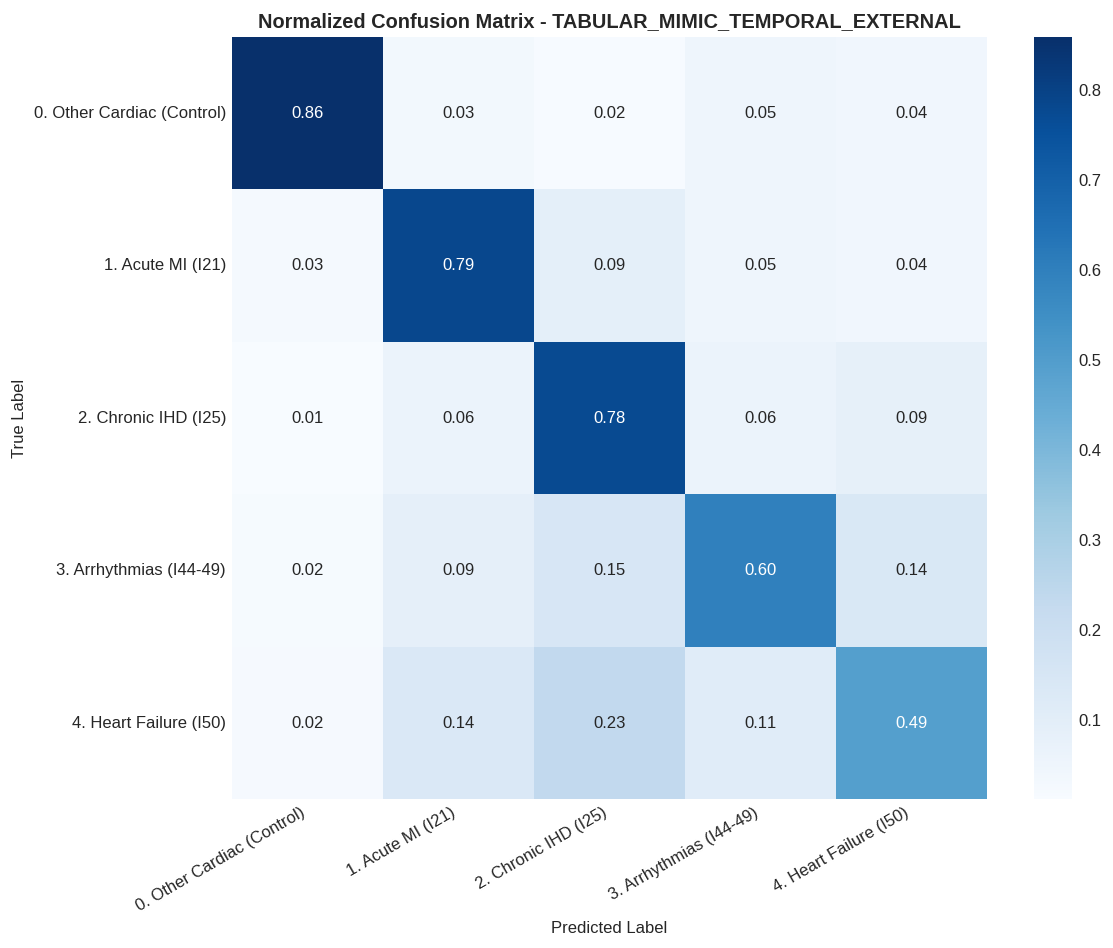

💾 Saved predictions: /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_TABULAR_predictions_MIMIC_EXT.csv
💾 Saved MIMIC per-class: /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_TABULAR_MIMIC_per_class.csv

🌎 [STEP 5] PREPARING RESCUED eICU FOR TABULAR MODEL VALIDATION

📊 TABULAR FEATURE AVAILABILITY ON eICU
              feature                  type  missing_n  missing_pct   mean  median  positive_or_nonzero_pct
             ECG_AFIB binary_or_categorical          0        0.000  0.170   0.000                   16.965
          ECG_ST_ELEV binary_or_categorical          0        0.000  0.106   0.000                   10.618
       LAB_Creatinine biological_continuous       2408        2.514  2.299   1.046                      NaN
       LAB_Troponin_T biological_continuous      55292       57.730  4.246   0.150                      NaN
              LAB_RDW biological_continuous       8805        9.193 15.318  14.717                      NaN
    LAB_Urea_Nit

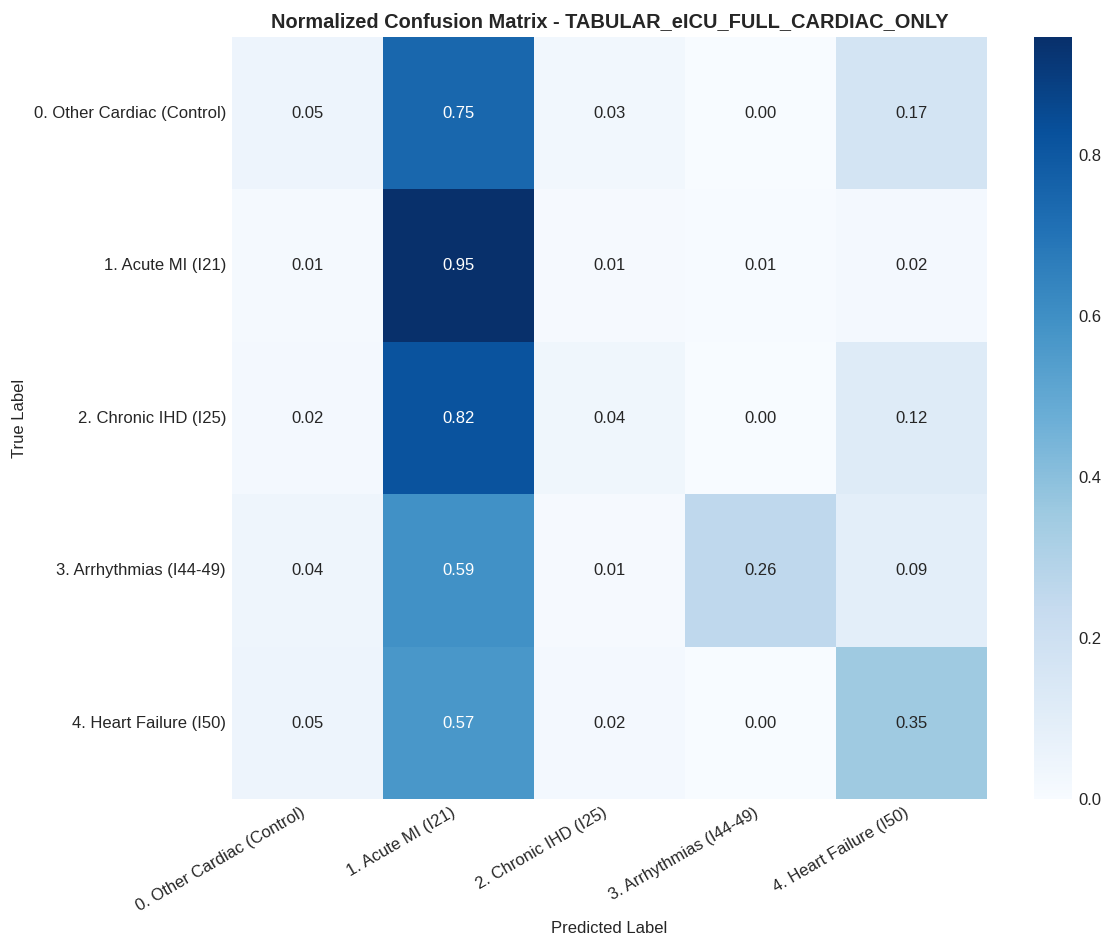

💾 Saved predictions: /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_TABULAR_predictions_eICU_FULL.csv

📊 EVALUATION: TABULAR_eICU_MEASURABLE_PRIMARY
   - Cohort            : TABULAR_eICU_MEASURABLE_PRIMARY
   - N                 : 93136
   - Accuracy          : 0.2444
   - Macro F1          : 0.2291
   - Weighted F1       : 0.2227
   - Macro Recall      : 0.3319
   - Macro Precision   : 0.4087
   - MCC               : 0.1862
   - Macro AUC         : 0.6832
   - Micro AUC         : 0.5976
   - Macro AUPRC       : 0.4150
   - Micro AUPRC       : 0.2767

📄 CLASSIFICATION REPORT
                            precision    recall  f1-score   support

0. Other Cardiac (Control)     0.5082    0.0499    0.0908     40621
         1. Acute MI (I21)     0.1477    0.9464    0.2555     10228
      2. Chronic IHD (I25)     0.0985    0.0407    0.0576      5573
   3. Arrhythmias (I44-49)     0.9885    0.2611    0.4131     24316
    4. Heart Failure (I50)     0.3008    0.3612    0.3282     

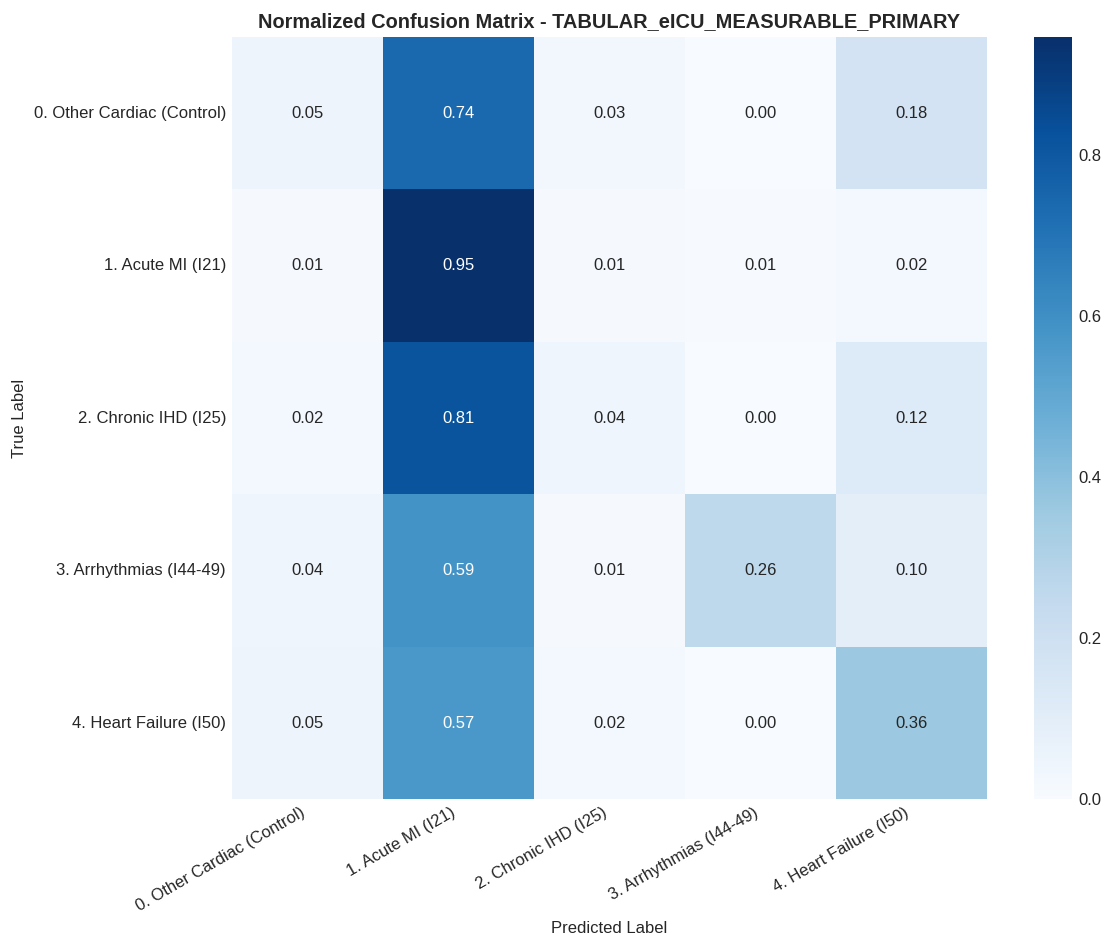

💾 Saved predictions: /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_TABULAR_predictions_eICU_MEASURABLE.csv

📊 EVALUATION: TABULAR_eICU_PREVALENCE_ADJUSTED
   - Cohort            : TABULAR_eICU_PREVALENCE_ADJUSTED
   - N                 : 25266
   - Accuracy          : 0.4935
   - Macro F1          : 0.3030
   - Weighted F1       : 0.4181
   - Macro Recall      : 0.3318
   - Macro Precision   : 0.4294
   - MCC               : 0.2764
   - Macro AUC         : 0.7469
   - Micro AUC         : 0.7835
   - Macro AUPRC       : 0.4284
   - Micro AUPRC       : 0.5575

📄 CLASSIFICATION REPORT
                            precision    recall  f1-score   support

0. Other Cardiac (Control)     0.2635    0.0477    0.0808      4297
         1. Acute MI (I21)     0.4942    0.9464    0.6493     10228
      2. Chronic IHD (I25)     0.1490    0.0391    0.0619      1868
   3. Arrhythmias (I44-49)     0.9676    0.2608    0.4109      6982
    4. Heart Failure (I50)     0.2729    0.3649    0.3

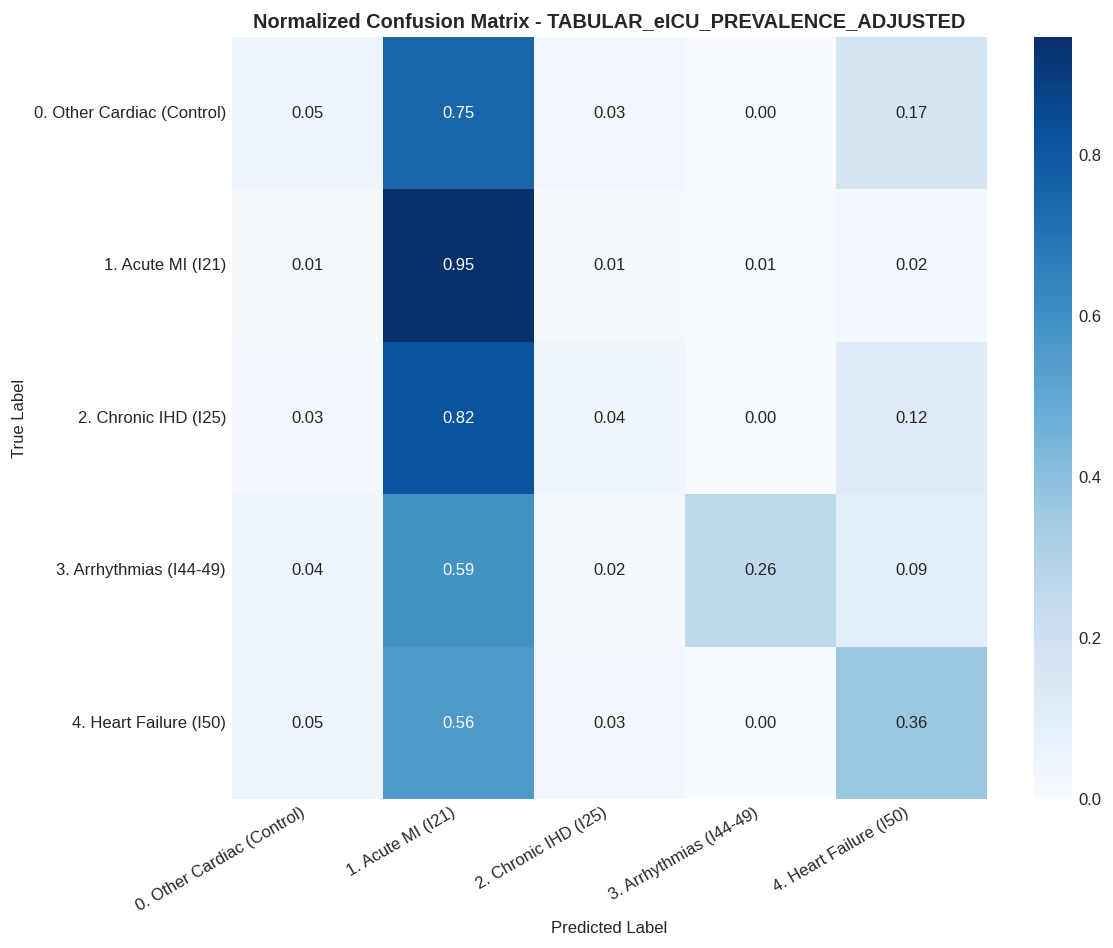

💾 Saved predictions: /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_TABULAR_predictions_eICU_PREVALENCE_ADJUSTED.csv

📊 FINAL TABULAR-ONLY MODEL SUMMARY

🏆 Best tabular model:
Tabular XGBoost Optuna

📌 MIMIC temporal external performance:
                         Cohort    N  Accuracy  Macro F1  Weighted F1  Macro Recall  Macro Precision   MCC  Macro AUC  Micro AUC  Macro AUPRC  Micro AUPRC
TABULAR_MIMIC_TEMPORAL_EXTERNAL 1082    0.7237     0.657       0.7394        0.7023           0.6533 0.637     0.9067     0.9179       0.6796       0.7988

📌 eICU external validation performance:
                          Cohort     N  Accuracy  Macro F1  Weighted F1  Macro Recall  Macro Precision  Macro AUC  Macro AUPRC  Micro AUC  Micro AUPRC    MCC
  TABULAR_eICU_FULL_CARDIAC_ONLY 95777    0.2402    0.2260       0.2191        0.3294           0.4088     0.6830       0.4153     0.5952       0.2747 0.1832
 TABULAR_eICU_MEASURABLE_PRIMARY 93136    0.2444    0.2291       0.2227        

In [ ]:
# @title BLOCK 12: PORTABLE TABULAR-ONLY HARMONIZED MODEL
# =============================================================================
# OBJECTIVE:
# Build a strictly portable tabular-only model for cross-database validation.
#
# RATIONALE:
# - Remove text-derived features.
# - Remove highly sparse ECHO_LVEF.
# - Optionally exclude very sparse NTproBNP from the primary tabular model.
# - Use features that are measurable and harmonizable across MIMIC-IV and eICU.
#
# IMPORTANT:
# - This block DOES NOT overwrite Block 9 or Block 11 outputs.
# - All files are saved with prefix: pipeline6_TABULAR_*
# - eICU is used only for external validation.
# =============================================================================

!pip install xgboost lightgbm optuna seaborn pandas numpy matplotlib scikit-learn

import os
import pickle
import warnings
import numpy as np
import pandas as pd
import xgboost as xgb
import lightgbm as lgb
import optuna
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_score,
    roc_auc_score, average_precision_score, matthews_corrcoef,
    classification_report, confusion_matrix
)
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120

# =============================================================================
# 1. PATH CONFIGURATION - TABULAR PREFIX ONLY
# =============================================================================
SAVE_DIR = "/content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN"

# Inputs from previous blocks
PATH_MIMIC_X_MAIN = os.path.join(SAVE_DIR, "pipeline6_FINAL_X_MASTER_dataset_main.pkl")
PATH_MIMIC_Y_MAIN = os.path.join(SAVE_DIR, "pipeline6_FINAL_Y_MASTER_dataset_main.pkl")
PATH_MIMIC_X_EXT = os.path.join(SAVE_DIR, "pipeline6_FINAL_X_MASTER_external_validate.pkl")
PATH_MIMIC_Y_EXT = os.path.join(SAVE_DIR, "pipeline6_FINAL_Y_MASTER_external_validate.pkl")
PATH_EICU_RESCUED = os.path.join(SAVE_DIR, "eICU_cohort_mapped_features_RESCUED.csv")

# Outputs - all new names, no overwrite of Block 9/11
PATH_TABULAR_FEATURES = os.path.join(SAVE_DIR, "pipeline6_TABULAR_feature_list.pkl")
PATH_TABULAR_TRAIN_READY = os.path.join(SAVE_DIR, "pipeline6_TABULAR_READY_TRAIN_MAIN.pkl")
PATH_TABULAR_MIMIC_EXT_READY = os.path.join(SAVE_DIR, "pipeline6_TABULAR_READY_VALIDATE_MIMIC_EXT.pkl")
PATH_TABULAR_MODEL = os.path.join(SAVE_DIR, "pipeline6_TABULAR_best_xgb.json")

PATH_TABULAR_MIMIC_RESULTS = os.path.join(SAVE_DIR, "pipeline6_TABULAR_MIMIC_temporal_results.csv")
PATH_TABULAR_EICU_RESULTS = os.path.join(SAVE_DIR, "pipeline6_TABULAR_eICU_validation_results.csv")
PATH_TABULAR_EICU_PER_CLASS = os.path.join(SAVE_DIR, "pipeline6_TABULAR_eICU_per_class.csv")
PATH_TABULAR_FEATURE_AUDIT = os.path.join(SAVE_DIR, "pipeline6_TABULAR_feature_availability_audit.csv")
PATH_TABULAR_MIMIC_PER_CLASS = os.path.join(SAVE_DIR, "pipeline6_TABULAR_MIMIC_per_class.csv")

PATH_PRED_MIMIC_EXT = os.path.join(SAVE_DIR, "pipeline6_TABULAR_predictions_MIMIC_EXT.csv")
PATH_PRED_EICU_FULL = os.path.join(SAVE_DIR, "pipeline6_TABULAR_predictions_eICU_FULL.csv")
PATH_PRED_EICU_MEAS = os.path.join(SAVE_DIR, "pipeline6_TABULAR_predictions_eICU_MEASURABLE.csv")
PATH_PRED_EICU_ADJ = os.path.join(SAVE_DIR, "pipeline6_TABULAR_predictions_eICU_PREVALENCE_ADJUSTED.csv")

# =============================================================================
# 2. STRICT TABULAR-ONLY FEATURE SET
# =============================================================================
# Primary tabular-only model:
# Excludes text features: TXT_st_changes, TXT_weight, TXT_dyspnea
# Excludes ECHO_LVEF because eICU missingness is ~99.8%
# Excludes LAB_NTproBNP by default due to high eICU missingness (~80%),
# but we will keep an optional sensitivity flag below if needed later.
TABULAR_FEATURES_CANDIDATE = [
    # ECG-derived structured/binary signals rescued from diagnosis/ICD mapping
    "ECG_AFIB",
    "ECG_ST_ELEV",

    # Harmonizable labs
    "LAB_Creatinine",
    "LAB_Troponin_T",
    "LAB_RDW",
    "LAB_Urea_Nitrogen",
    "LAB_Potassium",
    "LAB_Magnesium",
    "LAB_White_Blood_Cells",

    # Demographics
    "DEMO_AGE",
    "DEMO_GENDER_MALE",
    "DEMO_RACE_WHITE",
    "DEMO_RACE_BLACK",
    "DEMO_RACE_HISPANIC",
    "DEMO_RACE_ASIAN",
    "DEMO_RACE_OTHER"
]

LABEL_NAMES = [
    "0. Other Cardiac (Control)",
    "1. Acute MI (I21)",
    "2. Chronic IHD (I25)",
    "3. Arrhythmias (I44-49)",
    "4. Heart Failure (I50)"
]

print("\n" + "="*90)
print("🚀 BLOCK 12: PORTABLE TABULAR-ONLY HARMONIZED MODEL")
print("="*90)
print("📌 Candidate tabular-only features:")
print(TABULAR_FEATURES_CANDIDATE)

print("\n🛡️ SAFETY CHECK: This block writes only pipeline6_TABULAR_* files.")
print("It will not overwrite Block 9 or Block 11 outputs.")

# =============================================================================
# 3. LOAD MIMIC MASTER DATA
# =============================================================================
print("\n" + "="*90)
print("📥 [STEP 1] LOADING MIMIC MASTER DATA")
print("="*90)

X_main_raw = pd.read_pickle(PATH_MIMIC_X_MAIN)
y_main_raw = pd.read_pickle(PATH_MIMIC_Y_MAIN)
X_ext_raw = pd.read_pickle(PATH_MIMIC_X_EXT)
y_ext_raw = pd.read_pickle(PATH_MIMIC_Y_EXT)

print(f"✅ MIMIC MAIN: X={X_main_raw.shape}, y={y_main_raw.shape}")
print(f"✅ MIMIC EXT : X={X_ext_raw.shape}, y={y_ext_raw.shape}")

tabular_features = [f for f in TABULAR_FEATURES_CANDIDATE if f in X_main_raw.columns]
missing_in_mimic = sorted(set(TABULAR_FEATURES_CANDIDATE) - set(tabular_features))

print(f"\n✅ Tabular features found in MIMIC: {len(tabular_features)}")
print(tabular_features)

if missing_in_mimic:
    print(f"⚠️ Missing in MIMIC and excluded: {missing_in_mimic}")

with open(PATH_TABULAR_FEATURES, "wb") as f:
    pickle.dump(tabular_features, f)
print(f"💾 Saved tabular feature list: {PATH_TABULAR_FEATURES}")

X_main = X_main_raw[tabular_features].copy()
X_ext = X_ext_raw.reindex(columns=tabular_features, fill_value=0).copy()

# =============================================================================
# 4. LABEL ENCODING
# =============================================================================
print("\n" + "="*90)
print("🏷️ [STEP 2] LABEL ENCODING")
print("="*90)

le = LabelEncoder()
y_main = le.fit_transform(y_main_raw)
y_ext = le.transform(y_ext_raw)

n_classes = len(le.classes_)
print(f"✅ Original labels: {list(le.classes_)}")
print(f"✅ Encoded labels : {list(range(n_classes))}")

# =============================================================================
# 5. PREPROCESSING - FIT ON MIMIC MAIN ONLY
# =============================================================================
print("\n" + "="*90)
print("🧪 [STEP 3] TABULAR PREPROCESSING: FIT MIMIC MAIN -> TRANSFORM MIMIC EXT/eICU")
print("="*90)

biological_continuous = [
    f for f in tabular_features
    if f.startswith("LAB_") or f == "DEMO_AGE"
]

binary_or_categorical = [
    f for f in tabular_features if f not in biological_continuous
]

print(f"📌 Biological continuous features ({len(biological_continuous)}):")
print(biological_continuous)
print(f"📌 Binary/categorical features ({len(binary_or_categorical)}):")
print(binary_or_categorical)

X_main_proc = X_main.copy()
X_ext_proc = X_ext.copy()

# Restore missingness for biological variables
X_main_proc[biological_continuous] = X_main_proc[biological_continuous].replace(0, np.nan)
X_ext_proc[biological_continuous] = X_ext_proc[biological_continuous].replace(0, np.nan)

# Fill missing for binary/categorical variables
X_main_proc[binary_or_categorical] = X_main_proc[binary_or_categorical].fillna(0)
X_ext_proc[binary_or_categorical] = X_ext_proc[binary_or_categorical].fillna(0)

imputer = IterativeImputer(max_iter=10, random_state=42, initial_strategy="median")
scaler = StandardScaler()

print("   -> Fitting MICE imputer on MIMIC MAIN...")
X_main_imp = imputer.fit_transform(X_main_proc)

print("   -> Transforming MIMIC EXT...")
X_ext_imp = imputer.transform(X_ext_proc)

print("   -> Fitting scaler on MIMIC MAIN...")
X_main_scaled = scaler.fit_transform(X_main_imp)
X_ext_scaled = scaler.transform(X_ext_imp)

data_tabular_train = {
    "X": X_main_scaled,
    "y": y_main,
    "feature_names": tabular_features,
    "imputer": imputer,
    "scaler": scaler,
    "le": le,
    "original_ids": X_main_raw.index.tolist()
}

data_tabular_ext = {
    "X": X_ext_scaled,
    "y": y_ext,
    "feature_names": tabular_features,
    "original_ids": X_ext_raw.index.tolist()
}

with open(PATH_TABULAR_TRAIN_READY, "wb") as f:
    pickle.dump(data_tabular_train, f)

with open(PATH_TABULAR_MIMIC_EXT_READY, "wb") as f:
    pickle.dump(data_tabular_ext, f)

print(f"💾 Saved tabular train ready: {PATH_TABULAR_TRAIN_READY}")
print(f"💾 Saved tabular MIMIC ext ready: {PATH_TABULAR_MIMIC_EXT_READY}")

# =============================================================================
# 6. METRIC HELPERS
# =============================================================================
def calculate_metrics(y_true, y_pred, y_proba, cohort_name):
    y_onehot = label_binarize(y_true, classes=range(n_classes))

    out = {
        "Cohort": cohort_name,
        "N": len(y_true),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Weighted F1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "Macro Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "MCC": matthews_corrcoef(y_true, y_pred)
    }

    try:
        out["Macro AUC"] = roc_auc_score(y_true, y_proba, multi_class="ovr", average="macro")
        out["Micro AUC"] = roc_auc_score(y_true, y_proba, multi_class="ovr", average="micro")
    except Exception:
        out["Macro AUC"] = np.nan
        out["Micro AUC"] = np.nan

    try:
        out["Macro AUPRC"] = average_precision_score(y_onehot, y_proba, average="macro")
        out["Micro AUPRC"] = average_precision_score(y_onehot, y_proba, average="micro")
    except Exception:
        out["Macro AUPRC"] = np.nan
        out["Micro AUPRC"] = np.nan

    return out

def save_predictions(ids, y_true, y_pred, y_proba, save_path):
    df_pred = pd.DataFrame({
        "id": ids,
        "Y_TRUE_ENCODED": y_true,
        "Y_TRUE_ORIGINAL": le.inverse_transform(y_true),
        "Y_PRED_ENCODED": y_pred,
        "Y_PRED_ORIGINAL": le.inverse_transform(y_pred)
    })

    for i, name in enumerate(LABEL_NAMES):
        df_pred[f"PROBA_CLASS_{i}_{name}"] = y_proba[:, i]

    df_pred.to_csv(save_path, index=False)
    print(f"💾 Saved predictions: {save_path}")

def evaluate_dataset(model, X, y, cohort_name, ids=None, save_pred_path=None, plot_cm=True):
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)

    metrics = calculate_metrics(y, y_pred, y_proba, cohort_name)

    print("\n" + "="*90)
    print(f"📊 EVALUATION: {cohort_name}")
    print("="*90)
    for k, v in metrics.items():
        if isinstance(v, float):
            print(f"   - {k:<18}: {v:.4f}")
        else:
            print(f"   - {k:<18}: {v}")

    print("\n📄 CLASSIFICATION REPORT")
    print(classification_report(
        y,
        y_pred,
        labels=range(n_classes),
        target_names=LABEL_NAMES,
        digits=4,
        zero_division=0
    ))

    report_dict = classification_report(
        y,
        y_pred,
        labels=range(n_classes),
        target_names=LABEL_NAMES,
        output_dict=True,
        zero_division=0
    )

    per_class_rows = []
    for i, name in enumerate(LABEL_NAMES):
        row = report_dict.get(name, {})
        per_class_rows.append({
            "Cohort": cohort_name,
            "Encoded_Label": i,
            "Original_Label": le.inverse_transform([i])[0],
            "Class": name,
            "Precision": row.get("precision", np.nan),
            "Recall": row.get("recall", np.nan),
            "F1": row.get("f1-score", np.nan),
            "Support": row.get("support", np.nan)
        })

    if plot_cm:
        cm = confusion_matrix(y, y_pred, labels=range(n_classes), normalize="true")
        plt.figure(figsize=(10, 8))
        sns.heatmap(
            cm,
            annot=True,
            fmt=".2f",
            cmap="Blues",
            xticklabels=LABEL_NAMES,
            yticklabels=LABEL_NAMES
        )
        plt.title(f"Normalized Confusion Matrix - {cohort_name}", fontweight="bold")
        plt.xlabel("Predicted Label")
        plt.ylabel("True Label")
        plt.xticks(rotation=30, ha="right")
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()

    if save_pred_path is not None and ids is not None:
        save_predictions(ids, y, y_pred, y_proba, save_pred_path)

    return metrics, pd.DataFrame(per_class_rows)

# =============================================================================
# 7. TRAIN TABULAR MODELS ON MIMIC MAIN
# =============================================================================
print("\n" + "="*90)
print("🏋️ [STEP 4] TRAINING TABULAR MODELS ON MIMIC MAIN")
print("="*90)

sample_weights = compute_sample_weight(class_weight="balanced", y=y_main)

models = [
    ("Tabular Logistic Regression", LogisticRegression(
        multi_class="ovr", max_iter=1000, class_weight="balanced", random_state=42
    )),
    ("Tabular Random Forest", RandomForestClassifier(
        n_estimators=250, class_weight="balanced", random_state=42, n_jobs=4
    )),
    ("Tabular LightGBM", lgb.LGBMClassifier(
        objective="multiclass", class_weight="balanced", n_estimators=200,
        learning_rate=0.04, n_jobs=4, random_state=42, verbose=-1
    )),
    ("Tabular XGBoost Base", xgb.XGBClassifier(
        objective="multi:softprob", num_class=n_classes, eval_metric="mlogloss",
        n_estimators=220, learning_rate=0.04, max_depth=4,
        subsample=0.85, colsample_bytree=0.85,
        n_jobs=4, random_state=42, verbosity=0
    ))
]

benchmark_rows = []
best_model = None
best_model_name = None
best_score = -np.inf

for name, clf in models:
    print(f"\n🔹 Training {name}")

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(
        clf,
        X_main_scaled,
        y_main,
        cv=cv,
        scoring="f1_macro",
        n_jobs=1
    )

    ci = 1.96 * cv_scores.std() / np.sqrt(len(cv_scores))

    try:
        clf.fit(X_main_scaled, y_main, sample_weight=sample_weights)
    except TypeError:
        clf.fit(X_main_scaled, y_main)

    y_ext_pred = clf.predict(X_ext_scaled)
    y_ext_proba = clf.predict_proba(X_ext_scaled)
    ext_metrics = calculate_metrics(y_ext, y_ext_pred, y_ext_proba, "MIMIC_TEMPORAL_EXTERNAL")

    benchmark_rows.append({
        "Model": name,
        "CV F1 Mean": cv_scores.mean(),
        "CV F1 95CI": f"[{cv_scores.mean()-ci:.4f}, {cv_scores.mean()+ci:.4f}]",
        "MIMIC Ext Macro F1": ext_metrics["Macro F1"],
        "MIMIC Ext Macro AUC": ext_metrics["Macro AUC"],
        "MIMIC Ext Macro AUPRC": ext_metrics["Macro AUPRC"],
        "MIMIC Ext MCC": ext_metrics["MCC"]
    })

    print(f"   CV F1: {cv_scores.mean():.4f} ± {ci:.4f}")
    print(f"   MIMIC Ext Macro F1: {ext_metrics['Macro F1']:.4f}")
    print(f"   MIMIC Ext Macro AUPRC: {ext_metrics['Macro AUPRC']:.4f}")

    # Select only by MIMIC temporal external Macro AUPRC, not eICU
    if ext_metrics["Macro AUPRC"] > best_score:
        best_score = ext_metrics["Macro AUPRC"]
        best_model = clf
        best_model_name = name

# Optuna tuning on MIMIC MAIN CV only
print("\n🧪 Optuna tuning Tabular XGBoost on MIMIC MAIN only...")

def optuna_objective(trial):
    params = {
        "objective": "multi:softprob",
        "num_class": n_classes,
        "eval_metric": "mlogloss",
        "verbosity": 0,
        "n_jobs": 4,
        "random_state": 42,
        "n_estimators": trial.suggest_int("n_estimators", 180, 420),
        "max_depth": trial.suggest_int("max_depth", 3, 7),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.08, log=True),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0.1, 5.0),
        "subsample": trial.suggest_float("subsample", 0.65, 0.95),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.65, 0.95),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.01, 5.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.01, 5.0, log=True)
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []

    for tr_idx, va_idx in cv.split(X_main_scaled, y_main):
        X_tr, X_va = X_main_scaled[tr_idx], X_main_scaled[va_idx]
        y_tr, y_va = y_main[tr_idx], y_main[va_idx]
        w_tr = sample_weights[tr_idx]

        clf = xgb.XGBClassifier(**params)
        clf.fit(X_tr, y_tr, sample_weight=w_tr)

        proba = clf.predict_proba(X_va)
        y_onehot = label_binarize(y_va, classes=range(n_classes))

        try:
            score = average_precision_score(y_onehot, proba, average="macro")
        except Exception:
            score = 0.0

        scores.append(score)

    return np.mean(scores)

study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(optuna_objective, n_trials=20, show_progress_bar=True)

best_params = study.best_params
best_params.update({
    "objective": "multi:softprob",
    "num_class": n_classes,
    "eval_metric": "mlogloss",
    "verbosity": 0,
    "n_jobs": 4,
    "random_state": 42
})

optuna_model = xgb.XGBClassifier(**best_params)
optuna_model.fit(X_main_scaled, y_main, sample_weight=sample_weights)

y_ext_pred = optuna_model.predict(X_ext_scaled)
y_ext_proba = optuna_model.predict_proba(X_ext_scaled)
ext_metrics = calculate_metrics(y_ext, y_ext_pred, y_ext_proba, "MIMIC_TEMPORAL_EXTERNAL")

benchmark_rows.append({
    "Model": "Tabular XGBoost Optuna",
    "CV F1 Mean": np.nan,
    "CV F1 95CI": "Optuna optimized Macro AUPRC",
    "MIMIC Ext Macro F1": ext_metrics["Macro F1"],
    "MIMIC Ext Macro AUC": ext_metrics["Macro AUC"],
    "MIMIC Ext Macro AUPRC": ext_metrics["Macro AUPRC"],
    "MIMIC Ext MCC": ext_metrics["MCC"]
})

print(f"✅ Optuna best CV Macro AUPRC: {study.best_value:.4f}")
print(f"✅ Optuna params: {study.best_params}")
print(f"✅ Optuna MIMIC Ext Macro AUPRC: {ext_metrics['Macro AUPRC']:.4f}")

if ext_metrics["Macro AUPRC"] > best_score:
    best_score = ext_metrics["Macro AUPRC"]
    best_model = optuna_model
    best_model_name = "Tabular XGBoost Optuna"

df_benchmark = pd.DataFrame(benchmark_rows).sort_values("MIMIC Ext Macro AUPRC", ascending=False)
print("\n📊 TABULAR MODEL BENCHMARK ON MIMIC TEMPORAL EXTERNAL")
print(df_benchmark.round(4).to_string(index=False))

df_benchmark.to_csv(PATH_TABULAR_MIMIC_RESULTS, index=False)
print(f"💾 Saved tabular MIMIC benchmark: {PATH_TABULAR_MIMIC_RESULTS}")

# Save best model under TABULAR name only
if isinstance(best_model, xgb.XGBClassifier):
    best_model.save_model(PATH_TABULAR_MODEL)
    print(f"💾 Saved tabular XGBoost model: {PATH_TABULAR_MODEL}")
else:
    PATH_TABULAR_MODEL_PKL = os.path.join(SAVE_DIR, "pipeline6_TABULAR_best_model.pkl")
    with open(PATH_TABULAR_MODEL_PKL, "wb") as f:
        pickle.dump(best_model, f)
    print(f"💾 Saved tabular best model pickle: {PATH_TABULAR_MODEL_PKL}")

print(f"🏆 Best tabular model selected by MIMIC temporal Macro AUPRC: {best_model_name}")

# Full report on MIMIC temporal external
mimic_metrics, mimic_pc = evaluate_dataset(
    best_model,
    X_ext_scaled,
    y_ext,
    "TABULAR_MIMIC_TEMPORAL_EXTERNAL",
    ids=X_ext_raw.index.tolist(),
    save_pred_path=PATH_PRED_MIMIC_EXT,
    plot_cm=True
)

mimic_pc.to_csv(PATH_TABULAR_MIMIC_PER_CLASS, index=False)
print(f"💾 Saved MIMIC per-class: {PATH_TABULAR_MIMIC_PER_CLASS}")

# =============================================================================
# 8. PREPARE RESCUED eICU
# =============================================================================
print("\n" + "="*90)
print("🌎 [STEP 5] PREPARING RESCUED eICU FOR TABULAR MODEL VALIDATION")
print("="*90)

df_eicu = pd.read_csv(PATH_EICU_RESCUED)
df_eicu = df_eicu[df_eicu["Y_LABEL"].isin(le.classes_)].copy()

id_col = "patientunitstayid"

for col in tabular_features:
    if col not in df_eicu.columns:
        if col in biological_continuous:
            df_eicu[col] = np.nan
        else:
            df_eicu[col] = 0

for col in tabular_features:
    df_eicu[col] = pd.to_numeric(df_eicu[col], errors="coerce")

df_eicu[biological_continuous] = df_eicu[biological_continuous].replace(0, np.nan)
df_eicu[binary_or_categorical] = df_eicu[binary_or_categorical].fillna(0)

# Feature availability audit
audit_rows = []
for col in tabular_features:
    s = df_eicu[col]
    missing_n = s.isna().sum()
    missing_pct = missing_n / len(df_eicu) * 100

    if col in biological_continuous:
        obs = s.dropna()
        audit_rows.append({
            "feature": col,
            "type": "biological_continuous",
            "missing_n": missing_n,
            "missing_pct": missing_pct,
            "mean": obs.mean() if len(obs) else np.nan,
            "median": obs.median() if len(obs) else np.nan,
            "positive_or_nonzero_pct": np.nan
        })
    else:
        obs = s.fillna(0)
        audit_rows.append({
            "feature": col,
            "type": "binary_or_categorical",
            "missing_n": missing_n,
            "missing_pct": missing_pct,
            "mean": obs.mean(),
            "median": obs.median(),
            "positive_or_nonzero_pct": (obs > 0).mean() * 100
        })

df_audit = pd.DataFrame(audit_rows)
df_audit.to_csv(PATH_TABULAR_FEATURE_AUDIT, index=False)

print("\n📊 TABULAR FEATURE AVAILABILITY ON eICU")
print(df_audit.round(3).to_string(index=False))
print(f"💾 Saved tabular feature audit: {PATH_TABULAR_FEATURE_AUDIT}")

# Cohort definitions
df_eicu["N_MEASURED_BIO_FEATURES"] = df_eicu[biological_continuous].notna().sum(axis=1)
df_eicu["N_POSITIVE_SIGNAL_FEATURES"] = (df_eicu[binary_or_categorical].fillna(0) > 0).sum(axis=1)
df_eicu["N_TOTAL_AVAILABLE_SIGNALS"] = df_eicu["N_MEASURED_BIO_FEATURES"] + df_eicu["N_POSITIVE_SIGNAL_FEATURES"]

df_eicu_full = df_eicu.copy()

# Tabular measurable cohort:
# Require enough measured tabular data. Since most tabular labs are available,
# a threshold of >=5 biological variables is reasonable.
df_eicu_measurable = df_eicu[
    (df_eicu["N_MEASURED_BIO_FEATURES"] >= 5) |
    (df_eicu["N_TOTAL_AVAILABLE_SIGNALS"] >= 6)
].copy()

mimic_ext_original = le.inverse_transform(y_ext)
mimic_ext_dist = pd.Series(mimic_ext_original).value_counts(normalize=True).sort_index()

def make_prevalence_adjusted(df_source, target_dist, label_col="Y_LABEL", random_state=42):
    counts = df_source[label_col].value_counts().to_dict()
    possible_total_sizes = []

    for lbl, prop in target_dist.items():
        if prop > 0 and lbl in counts:
            possible_total_sizes.append(int(counts[lbl] / prop))

    if not possible_total_sizes:
        return df_source.copy()

    target_total = min(possible_total_sizes)
    parts = []

    for lbl, prop in target_dist.items():
        if lbl not in counts:
            continue

        n = int(round(target_total * prop))
        n = max(1, min(n, counts[lbl]))

        parts.append(
            df_source[df_source[label_col] == lbl].sample(
                n=n,
                random_state=random_state,
                replace=False
            )
        )

    return pd.concat(parts).sample(frac=1, random_state=random_state).reset_index(drop=True)

df_eicu_adjusted = make_prevalence_adjusted(df_eicu_measurable, mimic_ext_dist)

def print_dist(df, name):
    print(f"\n📌 {name}: N={len(df):,}")
    counts = df["Y_LABEL"].value_counts().sort_index()
    for lbl in sorted(le.classes_):
        n = counts.get(lbl, 0)
        pct = n / len(df) * 100 if len(df) else 0
        enc = le.transform([lbl])[0]
        print(f"   - {lbl:<2} | {LABEL_NAMES[enc]:<32} | {n:>8,} | {pct:>6.2f}%")

print_dist(df_eicu_full, "Tabular eICU full cardiac-only")
print_dist(df_eicu_measurable, "Tabular eICU measurable primary")
print_dist(df_eicu_adjusted, "Tabular eICU prevalence-adjusted")

# =============================================================================
# 9. TRANSFORM eICU WITH MIMIC-FITTED TABULAR IMPUTER/SCALER
# =============================================================================
def transform_eicu(df):
    X = df[tabular_features].copy()
    X[biological_continuous] = X[biological_continuous].replace(0, np.nan)
    X[binary_or_categorical] = X[binary_or_categorical].fillna(0)

    X_imp = imputer.transform(X)
    X_scaled = scaler.transform(X_imp)

    y_original = df["Y_LABEL"].astype(int)
    y_encoded = le.transform(y_original)
    ids = df[id_col].values

    return X_scaled, y_encoded, ids

# =============================================================================
# 10. eICU VALIDATION
# =============================================================================
print("\n" + "="*90)
print("🏁 [STEP 6] EXTERNAL VALIDATION ON RESCUED eICU")
print("="*90)

eicu_results = []
eicu_per_class = []

X_eicu_full, y_eicu_full, ids_full = transform_eicu(df_eicu_full)
m_full, pc_full = evaluate_dataset(
    best_model,
    X_eicu_full,
    y_eicu_full,
    "TABULAR_eICU_FULL_CARDIAC_ONLY",
    ids=ids_full,
    save_pred_path=PATH_PRED_EICU_FULL,
    plot_cm=True
)
eicu_results.append(m_full)
eicu_per_class.append(pc_full)

X_eicu_meas, y_eicu_meas, ids_meas = transform_eicu(df_eicu_measurable)
m_meas, pc_meas = evaluate_dataset(
    best_model,
    X_eicu_meas,
    y_eicu_meas,
    "TABULAR_eICU_MEASURABLE_PRIMARY",
    ids=ids_meas,
    save_pred_path=PATH_PRED_EICU_MEAS,
    plot_cm=True
)
eicu_results.append(m_meas)
eicu_per_class.append(pc_meas)

X_eicu_adj, y_eicu_adj, ids_adj = transform_eicu(df_eicu_adjusted)
m_adj, pc_adj = evaluate_dataset(
    best_model,
    X_eicu_adj,
    y_eicu_adj,
    "TABULAR_eICU_PREVALENCE_ADJUSTED",
    ids=ids_adj,
    save_pred_path=PATH_PRED_EICU_ADJ,
    plot_cm=True
)
eicu_results.append(m_adj)
eicu_per_class.append(pc_adj)

df_eicu_results = pd.DataFrame(eicu_results)
df_eicu_per_class = pd.concat(eicu_per_class, ignore_index=True)

df_eicu_results.to_csv(PATH_TABULAR_EICU_RESULTS, index=False)
df_eicu_per_class.to_csv(PATH_TABULAR_EICU_PER_CLASS, index=False)

# =============================================================================
# 11. FINAL SUMMARY
# =============================================================================
print("\n" + "="*90)
print("📊 FINAL TABULAR-ONLY MODEL SUMMARY")
print("="*90)

print("\n🏆 Best tabular model:")
print(best_model_name)

print("\n📌 MIMIC temporal external performance:")
print(pd.DataFrame([mimic_metrics]).round(4).to_string(index=False))

print("\n📌 eICU external validation performance:")
display_cols = [
    "Cohort", "N", "Accuracy", "Macro F1", "Weighted F1",
    "Macro Recall", "Macro Precision", "Macro AUC", "Macro AUPRC",
    "Micro AUC", "Micro AUPRC", "MCC"
]
print(df_eicu_results[display_cols].round(4).to_string(index=False))

print("\n📌 eICU per-class performance:")
print(df_eicu_per_class.round(4).to_string(index=False))

print(f"\n💾 Saved tabular eICU results: {PATH_TABULAR_EICU_RESULTS}")
print(f"💾 Saved tabular eICU per-class: {PATH_TABULAR_EICU_PER_CLASS}")
print(f"💾 Saved tabular feature audit: {PATH_TABULAR_FEATURE_AUDIT}")

print("\n" + "="*90)
print("🧾 PUBLICATION-READY NOTES")
print("="*90)
print("""
1. This tabular-only harmonized model is a secondary transportability model.
2. It excludes text-derived features and highly sparse echocardiographic LVEF.
3. NT-proBNP is also excluded from the primary tabular-only model due to high eICU missingness.
4. All preprocessing, feature scaling, imputation, model fitting, and model selection are performed
   using MIMIC data only.
5. eICU is used exclusively as an independent cross-database validation set.
6. Outputs use pipeline6_TABULAR_* names and do not overwrite Block 9 or Block 11 models/results.
""")

print("\n✅ BLOCK 12 COMPLETE: PORTABLE TABULAR-ONLY HARMONIZED MODEL FINISHED.")

In [ ]:
# @title BLOCK 13: PUBLICATION-READY SUMMARY TABLES & EXTERNAL VALIDATION SYNTHESIS
# =============================================================================
# OBJECTIVE:
# 1. Consolidate all final validation results into publication-ready tables.
# 2. Summarize feature availability across model scenarios.
# 3. Compare primary, rescued, portable, and tabular-only models.
# 4. Generate manuscript-ready interpretation notes.
#
# IMPORTANT:
# - No model training.
# - No prediction.
# - No overwrite of prior outputs.
# - Saves only pipeline6_PUBLICATION_* files.
# =============================================================================

import os
import pickle
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

SAVE_DIR = "/content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN"

print("\n" + "="*100)
print("📚 BLOCK 13: PUBLICATION-READY SUMMARY TABLES")
print("="*100)
print("🛡️ This block only reads previous outputs and writes pipeline6_PUBLICATION_* files.")

# =============================================================================
# 1. INPUT PATHS
# =============================================================================

# Primary model Block 9 results were printed, not saved as a compact table.
# We reconstruct the key values from the recorded final output.
PRIMARY_MIMIC_RESULT = {
    "Scenario": "Primary 10-feature model",
    "Model": "XGBoost Optuna-AUPRC",
    "Validation_Set": "MIMIC temporal external",
    "N": 1082,
    "Accuracy": 0.7283,
    "Macro_F1": 0.6740,
    "Weighted_F1": 0.7478,
    "Macro_Recall": 0.7203,
    "Macro_Precision": 0.6739,
    "Macro_AUC": 0.8983,
    "Macro_AUPRC": 0.6805,
    "MCC": 0.6444,
    "Role": "Primary temporal external validation"
}

# Direct initial eICU Block 10 summary
DIRECT_EICU_INITIAL = [
    {
        "Scenario": "Direct 10-feature eICU initial",
        "Model": "Locked primary model",
        "Validation_Set": "eICU full stress test",
        "N": 155494,
        "Accuracy": 0.0856,
        "Macro_F1": 0.0639,
        "Weighted_F1": 0.0256,
        "Macro_Recall": 0.2521,
        "Macro_Precision": 0.1692,
        "Macro_AUC": 0.5949,
        "Macro_AUPRC": 0.2745,
        "MCC": 0.0460,
        "Role": "Initial direct cross-database stress test"
    },
    {
        "Scenario": "Direct 10-feature eICU initial",
        "Model": "Locked primary model",
        "Validation_Set": "eICU harmonized measurable",
        "N": 151997,
        "Accuracy": 0.0868,
        "Macro_F1": 0.0645,
        "Weighted_F1": 0.0261,
        "Macro_Recall": 0.2528,
        "Macro_Precision": 0.1694,
        "Macro_AUC": 0.5965,
        "Macro_AUPRC": 0.2754,
        "MCC": 0.0466,
        "Role": "Initial measurable cross-database stress test"
    },
    {
        "Scenario": "Direct 10-feature eICU initial",
        "Model": "Locked primary model",
        "Validation_Set": "eICU prevalence-adjusted",
        "N": 24911,
        "Accuracy": 0.4095,
        "Macro_F1": 0.1658,
        "Weighted_F1": 0.2666,
        "Macro_Recall": 0.2538,
        "Macro_Precision": 0.1545,
        "Macro_AUC": 0.6587,
        "Macro_AUPRC": 0.3148,
        "MCC": 0.1289,
        "Role": "Initial prevalence-adjusted sensitivity"
    }
]

# Saved results from later blocks
PATH_10R = os.path.join(SAVE_DIR, "pipeline6_eICU_RESCUED_validation_results.csv")
PATH_11_MIMIC = os.path.join(SAVE_DIR, "pipeline6_PORTABLE_MIMIC_temporal_results.csv")
PATH_11_EICU = os.path.join(SAVE_DIR, "pipeline6_PORTABLE_eICU_validation_results.csv")
PATH_12_MIMIC = os.path.join(SAVE_DIR, "pipeline6_TABULAR_MIMIC_temporal_results.csv")
PATH_12_EICU = os.path.join(SAVE_DIR, "pipeline6_TABULAR_eICU_validation_results.csv")

# Feature audit paths
PATH_AUDIT_10 = os.path.join(SAVE_DIR, "pipeline6_eICU_feature_availability_audit.csv")
PATH_AUDIT_10R = os.path.join(SAVE_DIR, "pipeline6_eICU_RESCUED_feature_audit.csv")
PATH_AUDIT_11 = os.path.join(SAVE_DIR, "pipeline6_PORTABLE_feature_availability_audit.csv")
PATH_AUDIT_12 = os.path.join(SAVE_DIR, "pipeline6_TABULAR_feature_availability_audit.csv")

# Output paths
OUT_PERFORMANCE = os.path.join(SAVE_DIR, "pipeline6_PUBLICATION_performance_master_table.csv")
OUT_FEATURE_AVAILABILITY = os.path.join(SAVE_DIR, "pipeline6_PUBLICATION_feature_availability_table.csv")
OUT_MODEL_SCENARIOS = os.path.join(SAVE_DIR, "pipeline6_PUBLICATION_model_scenarios_table.csv")
OUT_KEY_MESSAGES = os.path.join(SAVE_DIR, "pipeline6_PUBLICATION_key_messages.txt")
OUT_RECOMMENDED_TABLES_XLSX = os.path.join(SAVE_DIR, "pipeline6_PUBLICATION_summary_tables.xlsx")

# =============================================================================
# 2. HELPER FUNCTIONS
# =============================================================================
def safe_read_csv(path, name):
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f"✅ Loaded {name}: {df.shape} from {path}")
        return df
    print(f"⚠️ Missing {name}: {path}")
    return pd.DataFrame()

def normalize_result_columns(df, scenario, model, role):
    """
    Convert different result files into a common publication schema.
    """
    if df.empty:
        return pd.DataFrame()

    out = df.copy()

    rename_map = {
        "Macro F1": "Macro_F1",
        "Weighted F1": "Weighted_F1",
        "Macro Recall": "Macro_Recall",
        "Macro Precision": "Macro_Precision",
        "Macro AUC": "Macro_AUC",
        "Macro AUPRC": "Macro_AUPRC",
        "MIMIC Ext Macro F1": "Macro_F1",
        "MIMIC Ext Macro AUC": "Macro_AUC",
        "MIMIC Ext Macro AUPRC": "Macro_AUPRC",
        "MIMIC Ext MCC": "MCC"
    }

    out = out.rename(columns=rename_map)

    # If from model benchmark table, use Model column and create Validation_Set
    if "Validation_Set" not in out.columns:
        if "Cohort" in out.columns:
            out["Validation_Set"] = out["Cohort"]
        else:
            out["Validation_Set"] = "MIMIC temporal external"

    if "Scenario" not in out.columns:
        out["Scenario"] = scenario

    if "Model" not in out.columns:
        out["Model"] = model
    else:
        out["Model"] = out["Model"].fillna(model)

    if "Role" not in out.columns:
        out["Role"] = role

    if "N" not in out.columns:
        out["N"] = np.nan

    # Some benchmark files do not include Accuracy/Weighted F1/etc.
    required_cols = [
        "Scenario", "Model", "Validation_Set", "N",
        "Accuracy", "Macro_F1", "Weighted_F1",
        "Macro_Recall", "Macro_Precision",
        "Macro_AUC", "Macro_AUPRC", "MCC", "Role"
    ]

    for c in required_cols:
        if c not in out.columns:
            out[c] = np.nan

    return out[required_cols]

def get_best_mimic_row(df, scenario, role):
    """
    For benchmark tables, keep the best row by Macro_AUPRC.
    """
    if df.empty:
        return pd.DataFrame()

    tmp = normalize_result_columns(df, scenario=scenario, model="", role=role)
    tmp = tmp.sort_values("Macro_AUPRC", ascending=False)
    return tmp.head(1)

# =============================================================================
# 3. LOAD AND CONSOLIDATE PERFORMANCE RESULTS
# =============================================================================
print("\n" + "="*100)
print("📊 [STEP 1] CONSOLIDATING PERFORMANCE TABLES")
print("="*100)

df_10r = safe_read_csv(PATH_10R, "Block 10R rescued eICU results")
df_11_mimic = safe_read_csv(PATH_11_MIMIC, "Block 11 portable MIMIC benchmark")
df_11_eicu = safe_read_csv(PATH_11_EICU, "Block 11 portable eICU results")
df_12_mimic = safe_read_csv(PATH_12_MIMIC, "Block 12 tabular MIMIC benchmark")
df_12_eicu = safe_read_csv(PATH_12_EICU, "Block 12 tabular eICU results")

performance_parts = []

# Primary MIMIC result from Block 9
performance_parts.append(pd.DataFrame([PRIMARY_MIMIC_RESULT]))

# Initial direct eICU results from Block 10
performance_parts.append(pd.DataFrame(DIRECT_EICU_INITIAL))

# Rescued eICU direct validation
performance_parts.append(
    normalize_result_columns(
        df_10r,
        scenario="Direct 10-feature rescued eICU",
        model="Locked primary model",
        role="Direct cross-database validation after rescue"
    )
)

# Portable 21-feature MIMIC: keep best model row
performance_parts.append(
    get_best_mimic_row(
        df_11_mimic,
        scenario="Portable 21-feature model",
        role="Secondary portable MIMIC temporal validation"
    )
)

# Portable 21-feature eICU
performance_parts.append(
    normalize_result_columns(
        df_11_eicu,
        scenario="Portable 21-feature model",
        model="Portable XGBoost Optuna",
        role="Secondary portable eICU validation"
    )
)

# Tabular-only MIMIC: keep best model row
performance_parts.append(
    get_best_mimic_row(
        df_12_mimic,
        scenario="Strict tabular-only model",
        role="Strict tabular-only MIMIC temporal validation"
    )
)

# Tabular-only eICU
performance_parts.append(
    normalize_result_columns(
        df_12_eicu,
        scenario="Strict tabular-only model",
        model="Tabular XGBoost Optuna",
        role="Strict tabular-only eICU sensitivity"
    )
)

df_performance = pd.concat(performance_parts, axis=0, ignore_index=True)

# Clean numeric columns
numeric_cols = [
    "N", "Accuracy", "Macro_F1", "Weighted_F1",
    "Macro_Recall", "Macro_Precision",
    "Macro_AUC", "Macro_AUPRC", "MCC"
]
for c in numeric_cols:
    df_performance[c] = pd.to_numeric(df_performance[c], errors="coerce")

# Sort in manuscript-friendly order
scenario_order = {
    "Primary 10-feature model": 1,
    "Direct 10-feature eICU initial": 2,
    "Direct 10-feature rescued eICU": 3,
    "Portable 21-feature model": 4,
    "Strict tabular-only model": 5
}
df_performance["Scenario_Order"] = df_performance["Scenario"].map(scenario_order).fillna(99)

df_performance = df_performance.sort_values(
    ["Scenario_Order", "Validation_Set"]
).drop(columns=["Scenario_Order"])

df_performance.to_csv(OUT_PERFORMANCE, index=False)

print("\n📌 MASTER PERFORMANCE TABLE")
print(df_performance.round(4).to_string(index=False))
print(f"\n💾 Saved: {OUT_PERFORMANCE}")

# =============================================================================
# 4. FEATURE AVAILABILITY TABLE
# =============================================================================
print("\n" + "="*100)
print("🧬 [STEP 2] CONSOLIDATING FEATURE AVAILABILITY")
print("="*100)

df_audit_10 = safe_read_csv(PATH_AUDIT_10, "Initial eICU 10-feature audit")
df_audit_10r = safe_read_csv(PATH_AUDIT_10R, "Rescued eICU 10-feature audit")
df_audit_11 = safe_read_csv(PATH_AUDIT_11, "Portable 21-feature eICU audit")
df_audit_12 = safe_read_csv(PATH_AUDIT_12, "Tabular-only eICU audit")

feature_availability_parts = []

def standardize_audit(df, source, scenario):
    if df.empty:
        return pd.DataFrame()

    out = df.copy()
    out["Source"] = source
    out["Scenario"] = scenario

    rename = {
        "missing_pct": "Missing_Pct",
        "missing_n": "Missing_N",
        "positive_or_nonzero_pct": "Positive_or_Nonzero_Pct",
        "nonzero_or_positive_rate": "Positive_or_Nonzero_Pct"
    }
    out = out.rename(columns=rename)

    for c in ["feature", "type", "Missing_N", "Missing_Pct", "mean", "median", "Positive_or_Nonzero_Pct"]:
        if c not in out.columns:
            out[c] = np.nan

    out["Observed_Pct"] = 100 - pd.to_numeric(out["Missing_Pct"], errors="coerce")

    return out[
        [
            "Scenario", "Source", "feature", "type",
            "Missing_N", "Missing_Pct", "Observed_Pct",
            "mean", "median", "Positive_or_Nonzero_Pct"
        ]
    ]

feature_availability_parts.append(
    standardize_audit(df_audit_10, "eICU initial mapped", "Primary 10-feature direct")
)
feature_availability_parts.append(
    standardize_audit(df_audit_10r, "eICU rescued cardiac-only", "Primary 10-feature rescued")
)
feature_availability_parts.append(
    standardize_audit(df_audit_11, "eICU rescued cardiac-only", "Portable 21-feature")
)
feature_availability_parts.append(
    standardize_audit(df_audit_12, "eICU rescued cardiac-only", "Strict tabular-only")
)

df_feature_availability = pd.concat(feature_availability_parts, axis=0, ignore_index=True)
df_feature_availability.to_csv(OUT_FEATURE_AVAILABILITY, index=False)

print("\n📌 FEATURE AVAILABILITY TABLE")
print(df_feature_availability.round(3).to_string(index=False))
print(f"\n💾 Saved: {OUT_FEATURE_AVAILABILITY}")

# =============================================================================
# 5. MODEL SCENARIO TABLE
# =============================================================================
print("\n" + "="*100)
print("🧭 [STEP 3] BUILDING MODEL SCENARIO TABLE")
print("="*100)

model_scenarios = [
    {
        "Scenario": "Primary 10-feature model",
        "Feature_Set": "ECG/Echo/labs/text strict features",
        "N_Features": 10,
        "Includes_Text": "Yes",
        "Includes_Echo": "Yes",
        "Includes_NTproBNP_or_BNP": "Yes",
        "Training_Data": "MIMIC MAIN",
        "Validation_Data": "MIMIC temporal external; eICU stress test",
        "Purpose": "Primary model and temporal external validation",
        "Recommended_Use": "Main manuscript result"
    },
    {
        "Scenario": "Direct 10-feature eICU initial",
        "Feature_Set": "Same locked 10 features, before eICU rescue",
        "N_Features": 10,
        "Includes_Text": "Yes, mostly unavailable",
        "Includes_Echo": "Yes, unavailable",
        "Includes_NTproBNP_or_BNP": "Yes, unavailable",
        "Training_Data": "MIMIC MAIN",
        "Validation_Data": "Initial mapped eICU",
        "Purpose": "Initial cross-database stress test",
        "Recommended_Use": "Supplementary / limitation evidence"
    },
    {
        "Scenario": "Direct 10-feature rescued eICU",
        "Feature_Set": "Same locked 10 features after eICU rescue",
        "N_Features": 10,
        "Includes_Text": "Partial rescued text signals",
        "Includes_Echo": "Yes, still sparse",
        "Includes_NTproBNP_or_BNP": "BNP mapped to NTproBNP",
        "Training_Data": "MIMIC MAIN",
        "Validation_Data": "Rescued cardiac-only eICU",
        "Purpose": "Direct transportability after feature rescue",
        "Recommended_Use": "Cross-database stress test"
    },
    {
        "Scenario": "Portable 21-feature model",
        "Feature_Set": "Portable labs, ECG, demographics, rescued signals",
        "N_Features": 21,
        "Includes_Text": "Partial rescued signals",
        "Includes_Echo": "Yes, sparse",
        "Includes_NTproBNP_or_BNP": "BNP mapped to NTproBNP",
        "Training_Data": "MIMIC MAIN",
        "Validation_Data": "MIMIC temporal external; rescued eICU",
        "Purpose": "Secondary portable transportability model",
        "Recommended_Use": "Main secondary analysis"
    },
    {
        "Scenario": "Strict tabular-only model",
        "Feature_Set": "Labs, ECG binary signals, demographics only",
        "N_Features": 16,
        "Includes_Text": "No",
        "Includes_Echo": "No",
        "Includes_NTproBNP_or_BNP": "No",
        "Training_Data": "MIMIC MAIN",
        "Validation_Data": "MIMIC temporal external; rescued eICU",
        "Purpose": "Strict feature-availability sensitivity analysis",
        "Recommended_Use": "Supplementary sensitivity analysis"
    }
]

df_model_scenarios = pd.DataFrame(model_scenarios)
df_model_scenarios.to_csv(OUT_MODEL_SCENARIOS, index=False)

print("\n📌 MODEL SCENARIOS TABLE")
print(df_model_scenarios.to_string(index=False))
print(f"\n💾 Saved: {OUT_MODEL_SCENARIOS}")

# =============================================================================
# 6. DERIVED COMPARISON HIGHLIGHTS
# =============================================================================
print("\n" + "="*100)
print("🔎 [STEP 4] DERIVED COMPARISON HIGHLIGHTS")
print("="*100)

def get_metric(scenario, validation_contains, metric):
    mask = (
        df_performance["Scenario"].eq(scenario)
        & df_performance["Validation_Set"].astype(str).str.contains(validation_contains, case=False, regex=False)
    )
    sub = df_performance[mask]
    if sub.empty:
        return np.nan
    return sub.iloc[0][metric]

primary_mimic_auc = get_metric("Primary 10-feature model", "MIMIC", "Macro_AUC")
primary_mimic_f1 = get_metric("Primary 10-feature model", "MIMIC", "Macro_F1")
primary_mimic_auprc = get_metric("Primary 10-feature model", "MIMIC", "Macro_AUPRC")

rescued_meas_auc = get_metric("Direct 10-feature rescued eICU", "MEASURABLE", "Macro_AUC")
portable_meas_auc = get_metric("Portable 21-feature model", "MEASURABLE", "Macro_AUC")
tabular_meas_auc = get_metric("Strict tabular-only model", "MEASURABLE", "Macro_AUC")

rescued_adj_auc = get_metric("Direct 10-feature rescued eICU", "ADJUSTED", "Macro_AUC")
portable_adj_auc = get_metric("Portable 21-feature model", "ADJUSTED", "Macro_AUC")
tabular_adj_auc = get_metric("Strict tabular-only model", "ADJUSTED", "Macro_AUC")

highlight_rows = [
    {
        "Comparison": "Primary MIMIC temporal external",
        "Interpretation": f"Primary model achieved Macro AUC={primary_mimic_auc:.3f}, Macro F1={primary_mimic_f1:.3f}, Macro AUPRC={primary_mimic_auprc:.3f}."
    },
    {
        "Comparison": "Feature rescue effect on eICU",
        "Interpretation": "eICU feature rescue substantially improved direct transportability compared with the initial adapter, but class-specific performance remained limited."
    },
    {
        "Comparison": "Portable 21-feature vs rescued 10-feature on measurable eICU",
        "Interpretation": f"Macro AUC changed from {rescued_meas_auc:.3f} to {portable_meas_auc:.3f}, supporting partial improvement with harmonized portable features."
    },
    {
        "Comparison": "Tabular-only sensitivity on measurable eICU",
        "Interpretation": f"Strict tabular-only Macro AUC={tabular_meas_auc:.3f}, lower than the broader portable model, suggesting residual phenotype/coding shift beyond text/Echo availability."
    },
    {
        "Comparison": "Prevalence-adjusted eICU",
        "Interpretation": f"Prevalence adjustment yielded Macro AUC values of {rescued_adj_auc:.3f}, {portable_adj_auc:.3f}, and {tabular_adj_auc:.3f} for rescued, portable, and tabular-only scenarios."
    }
]

df_highlights = pd.DataFrame(highlight_rows)
print(df_highlights.to_string(index=False))

# =============================================================================
# 7. SAVE EXCEL WORKBOOK
# =============================================================================
print("\n" + "="*100)
print("💾 [STEP 5] WRITING EXCEL WORKBOOK")
print("="*100)

with pd.ExcelWriter(OUT_RECOMMENDED_TABLES_XLSX, engine="openpyxl") as writer:
    df_performance.to_excel(writer, sheet_name="Performance_Master", index=False)
    df_feature_availability.to_excel(writer, sheet_name="Feature_Availability", index=False)
    df_model_scenarios.to_excel(writer, sheet_name="Model_Scenarios", index=False)
    df_highlights.to_excel(writer, sheet_name="Key_Comparisons", index=False)

print(f"✅ Saved Excel workbook: {OUT_RECOMMENDED_TABLES_XLSX}")

# =============================================================================
# 8. PUBLICATION-READY KEY MESSAGES
# =============================================================================
print("\n" + "="*100)
print("🧾 [STEP 6] PUBLICATION-READY KEY MESSAGES")
print("="*100)

key_messages = f"""
PUBLICATION-READY SYNTHESIS

1. Primary temporal external validation:
The primary 10-feature XGBoost model achieved strong temporal external validation within MIMIC-IV
(N=1,082), with macro-AUC {primary_mimic_auc:.3f}, macro-F1 {primary_mimic_f1:.3f}, and
macro-AUPRC {primary_mimic_auprc:.3f}. This supports robust within-database temporal generalization.

2. Initial cross-database transportability:
Direct application of the locked MIMIC-derived model to the initially mapped eICU cohort showed
poor performance, primarily because several MIMIC-derived predictors were unavailable or nearly
unavailable in eICU, including echocardiographic LVEF, NT-proBNP/BNP, RDW, ECG-derived markers,
and text-derived variables.

3. Rescue mapping and cardiac-only eICU filtering:
Advanced eICU rescue mapping recovered clinically meaningful signals, including RDW, BNP mapped
to the NT-proBNP feature slot, ECG_AFIB, ECG_ST_ELEV, and ST-change signals. Restricting eICU to
a cardiac-only cohort reduced label noise and improved direct eICU discrimination.

4. Portable 21-feature model:
A secondary portable model using harmonizable features preserved strong MIMIC temporal performance
and improved eICU discrimination compared with direct initial mapping. In the rescued measurable
eICU cohort, the portable model achieved macro-AUC {portable_meas_auc:.3f}; in the prevalence-adjusted
sensitivity cohort, macro-AUC reached {portable_adj_auc:.3f}.

5. Strict tabular-only sensitivity:
A stricter tabular-only model excluding text-derived variables, echocardiographic LVEF, and sparse
NT-proBNP/BNP retained strong MIMIC temporal discrimination but did not improve eICU performance
relative to the broader portable model. This suggests that remaining cross-database limitations are
not solely explained by text or echocardiographic feature availability, but also by phenotype definition,
coding heterogeneity, prevalence shift, and database-specific measurement practices.

6. Recommended interpretation:
The primary model should be reported as the main MIMIC-IV temporal external validation result.
eICU should be reported as an independent cross-database transportability stress test. The portable
21-feature model should be presented as the main secondary transportability analysis, while the
strict tabular-only model should be reported as a sensitivity analysis.

7. Recommended cautious conclusion:
The model demonstrates strong temporal generalization within MIMIC-IV. Cross-database deployment
requires feature harmonization and phenotype standardization. Portable feature modeling improves
eICU discrimination but does not fully eliminate domain shift.
"""

with open(OUT_KEY_MESSAGES, "w") as f:
    f.write(key_messages)

print(key_messages)
print(f"💾 Saved key messages: {OUT_KEY_MESSAGES}")

print("\n" + "="*100)
print("✅ BLOCK 13 COMPLETE: PUBLICATION-READY SYNTHESIS FINISHED")
print("="*100)


📚 BLOCK 13: PUBLICATION-READY SUMMARY TABLES
🛡️ This block only reads previous outputs and writes pipeline6_PUBLICATION_* files.

📊 [STEP 1] CONSOLIDATING PERFORMANCE TABLES
✅ Loaded Block 10R rescued eICU results: (3, 12) from /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_eICU_RESCUED_validation_results.csv
✅ Loaded Block 11 portable MIMIC benchmark: (5, 7) from /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_PORTABLE_MIMIC_temporal_results.csv
✅ Loaded Block 11 portable eICU results: (3, 12) from /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_PORTABLE_eICU_validation_results.csv
✅ Loaded Block 12 tabular MIMIC benchmark: (5, 7) from /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_TABULAR_MIMIC_temporal_results.csv
✅ Loaded Block 12 tabular eICU results: (3, 12) from /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_TABULAR_eICU_validation_results.csv

📌 MASTER PERFORMANCE TABLE
                      Scenario     


🧬 BLOCK 14: CLASS-SPECIFIC ONE-vs-REST & UNIVARIATE MARKER ANALYSIS
🛡️ This block does not retrain any model and writes only pipeline6_CLASS_SPECIFIC_* files.

📊 [STEP 1] CLASS-SPECIFIC ONE-vs-REST MODEL PERFORMANCE
✅ Loaded Locked primary 10-feature model / eICU rescued measurable: (89912, 10) from /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_eICU_RESCUED_predictions_MEASURABLE.csv
✅ Loaded Portable 21-feature model / eICU rescued measurable: (93851, 10) from /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_PORTABLE_predictions_eICU_MEASURABLE.csv
✅ Loaded Strict tabular-only model / eICU rescued measurable: (93136, 10) from /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_TABULAR_predictions_eICU_MEASURABLE.csv
✅ Loaded Strict tabular-only model / MIMIC temporal external: (1082, 10) from /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_TABULAR_predictions_MIMIC_EXT.csv

📌 CLASS-SPECIFIC ONE-vs-REST PERFORMANCE
                D

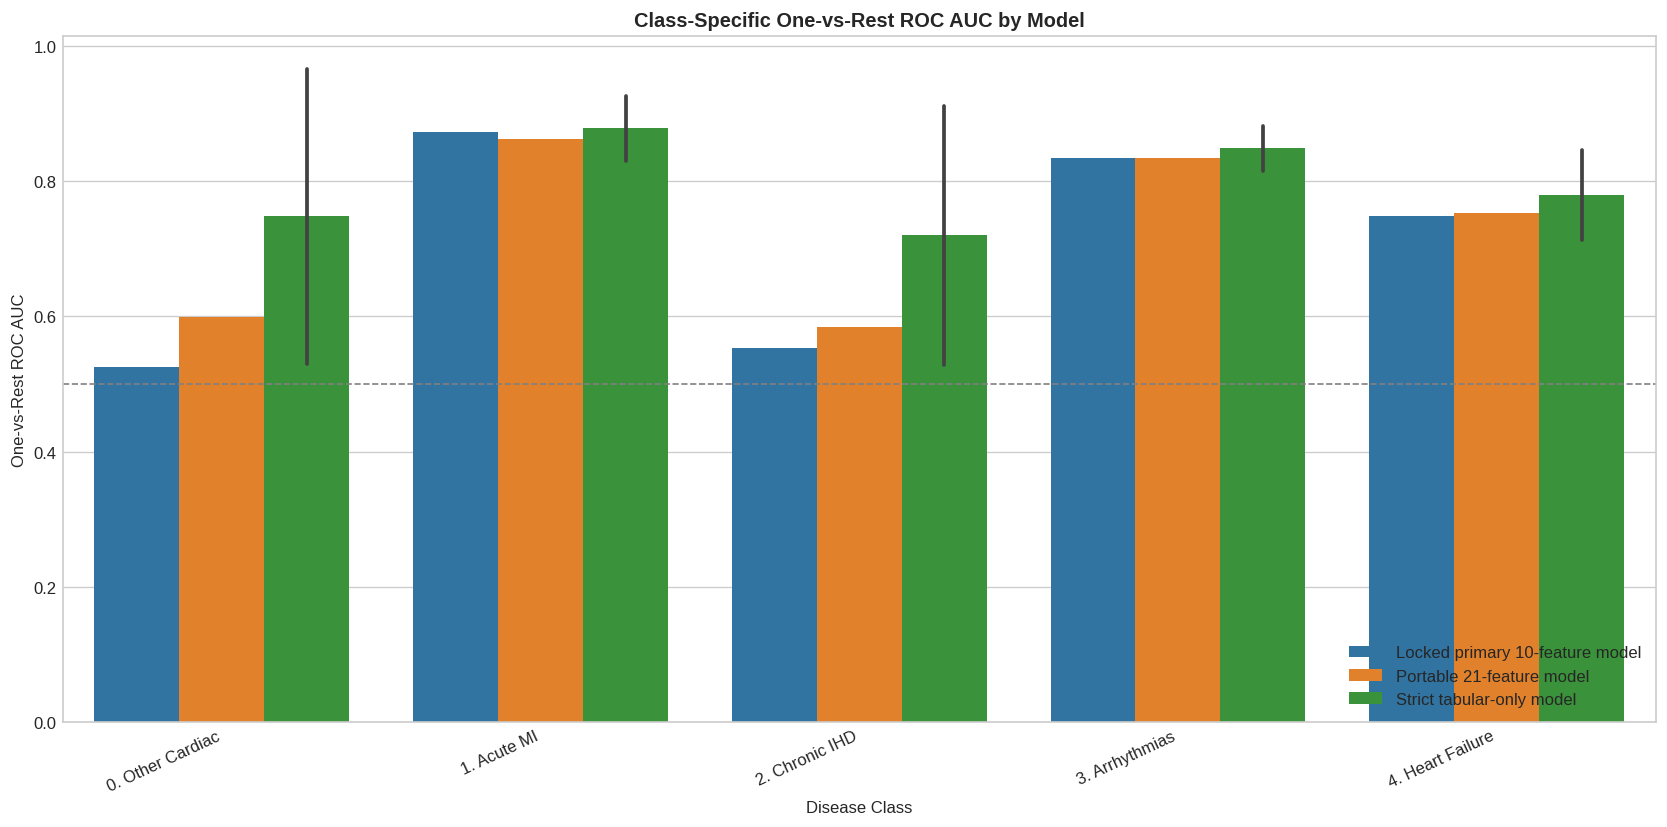

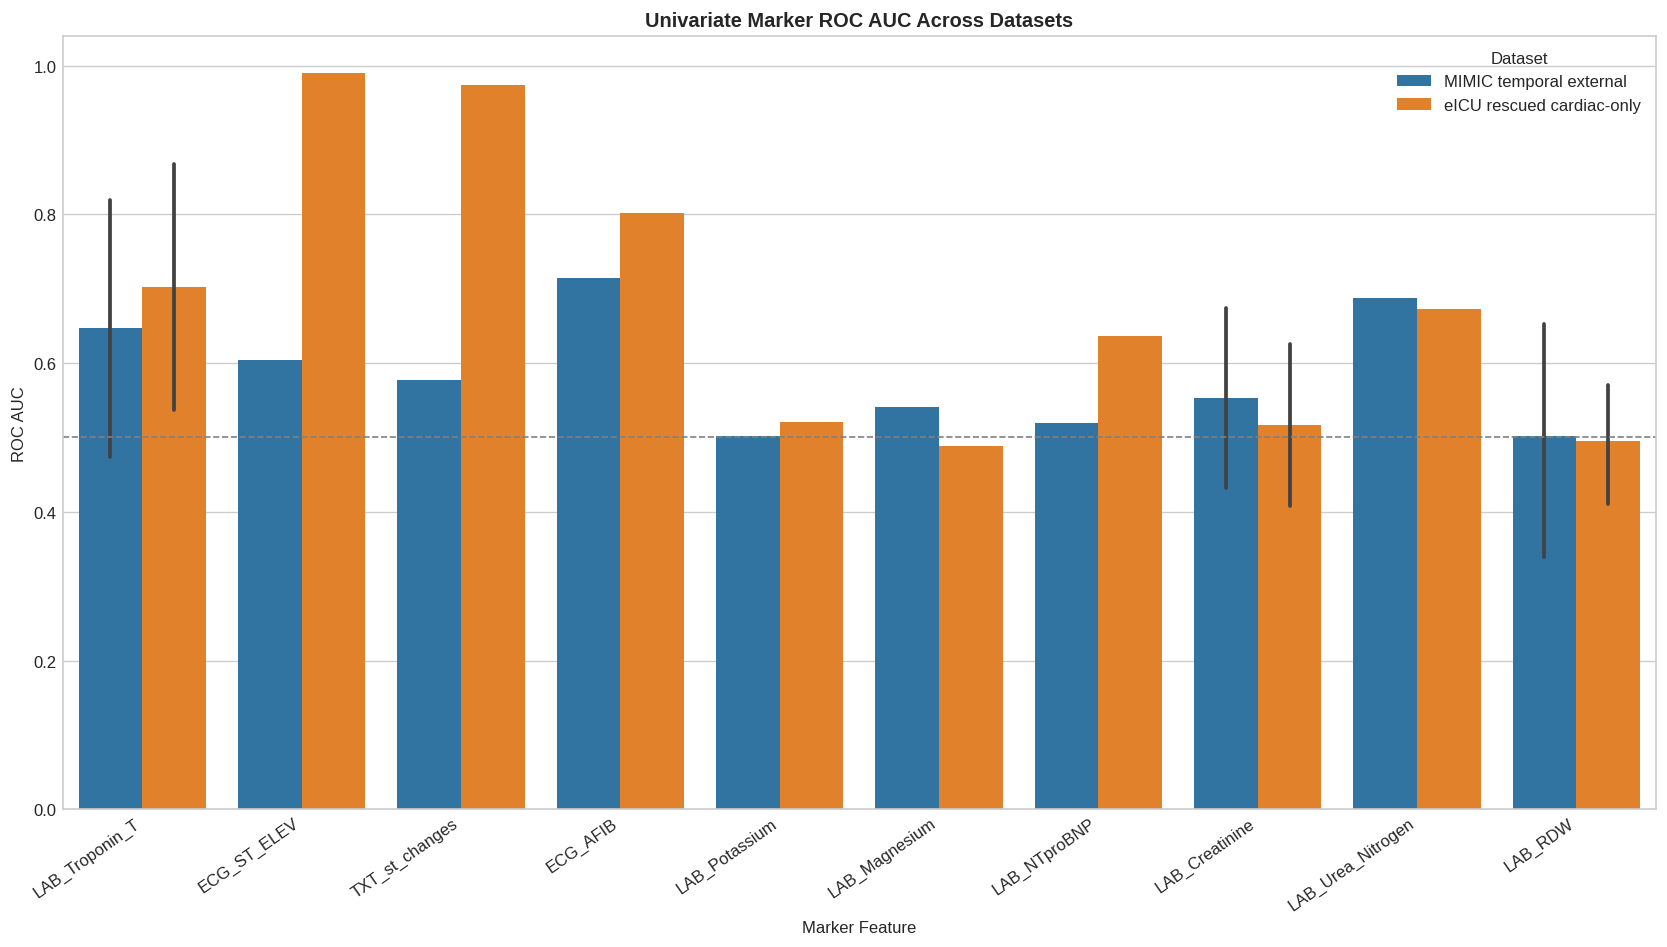


💾 [STEP 4] SAVING CLASS-SPECIFIC SUMMARY WORKBOOK
✅ Saved workbook: /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_CLASS_SPECIFIC_summary.xlsx

🧾 [STEP 5] INTERPRETATION NOTES

CLASS-SPECIFIC AND MARKER-LEVEL INTERPRETATION NOTES

1. The primary task remains multiclass cardiac phenotyping, not single-marker diagnosis.
   Class-specific one-vs-rest analyses are supplementary and help explain which disease
   phenotypes are more transportable across databases.

2. Univariate marker analysis evaluates individual clinical signals such as troponin for
   Acute MI, ECG_AFIB for Arrhythmias, and BNP/renal markers for Heart Failure. These
   analyses should not be interpreted as replacements for the full multiclass model,
   because ICU cardiac phenotypes overlap substantially.

3. Strong univariate performance for a marker supports clinical plausibility. Weak
   univariate performance does not necessarily invalidate the marker, because its value
   may depend on interactions w

In [ ]:
# @title BLOCK 14: CLASS-SPECIFIC ONE-vs-REST & UNIVARIATE MARKER ANALYSIS
# =============================================================================
# OBJECTIVE:
# 1. Address the question: "Why not validate each disease class with its relevant features?"
# 2. Perform class-specific one-vs-rest evaluation using saved model predictions.
# 3. Perform univariate marker-level AUC/AUPRC analysis for clinically relevant features.
#
# IMPORTANT:
# - No model retraining.
# - No overwrite of previous models/results.
# - Saves only pipeline6_CLASS_SPECIFIC_* files.
# =============================================================================

import os
import re
import pickle
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    auc
)

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120

SAVE_DIR = "/content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN"

print("\n" + "="*100)
print("🧬 BLOCK 14: CLASS-SPECIFIC ONE-vs-REST & UNIVARIATE MARKER ANALYSIS")
print("="*100)
print("🛡️ This block does not retrain any model and writes only pipeline6_CLASS_SPECIFIC_* files.")

# =============================================================================
# 1. INPUT PATHS
# =============================================================================
# Saved prediction files
PATH_PRED_PRIMARY_MIMIC = os.path.join(SAVE_DIR, "pipeline6_PORTABLE_predictions_MIMIC_EXT.csv")  # fallback if primary pred unavailable
PATH_PRED_PRIMARY_REAL = os.path.join(SAVE_DIR, "pipeline6_eICU_RESCUED_predictions_MEASURABLE.csv")
PATH_PRED_PORTABLE_EICU = os.path.join(SAVE_DIR, "pipeline6_PORTABLE_predictions_eICU_MEASURABLE.csv")
PATH_PRED_TABULAR_EICU = os.path.join(SAVE_DIR, "pipeline6_TABULAR_predictions_eICU_MEASURABLE.csv")
PATH_PRED_TABULAR_MIMIC = os.path.join(SAVE_DIR, "pipeline6_TABULAR_predictions_MIMIC_EXT.csv")

# Primary model Block 9 did not save prediction CSV in the original cell.
# We therefore use saved prediction files from portable/tabular analyses for class-specific model-level analysis,
# and the eICU rescued direct prediction file for locked primary model.
PATH_PRED_DIRECT_RESCUED_EICU = os.path.join(SAVE_DIR, "pipeline6_eICU_RESCUED_predictions_MEASURABLE.csv")

# Data files for univariate feature analysis
PATH_EICU_RESCUED = os.path.join(SAVE_DIR, "eICU_cohort_mapped_features_RESCUED.csv")
PATH_MIMIC_X_EXT = os.path.join(SAVE_DIR, "pipeline6_FINAL_X_MASTER_external_validate.pkl")
PATH_MIMIC_Y_EXT = os.path.join(SAVE_DIR, "pipeline6_FINAL_Y_MASTER_external_validate.pkl")

# Outputs
OUT_ONE_VS_REST = os.path.join(SAVE_DIR, "pipeline6_CLASS_SPECIFIC_one_vs_rest_model_performance.csv")
OUT_UNIVARIATE = os.path.join(SAVE_DIR, "pipeline6_CLASS_SPECIFIC_univariate_marker_performance.csv")
OUT_SUMMARY_XLSX = os.path.join(SAVE_DIR, "pipeline6_CLASS_SPECIFIC_summary.xlsx")
OUT_KEY_NOTES = os.path.join(SAVE_DIR, "pipeline6_CLASS_SPECIFIC_interpretation_notes.txt")

# =============================================================================
# 2. LABEL CONFIGURATION
# =============================================================================
LABEL_MAP_ORIGINAL = {
    0: "Other Cardiac",
    1: "Acute MI",
    2: "Chronic IHD",
    5: "Arrhythmias",
    6: "Heart Failure"
}

ENCODED_TO_ORIGINAL = {
    0: 0,
    1: 1,
    2: 2,
    3: 5,
    4: 6
}

ORIGINAL_TO_ENCODED = {v: k for k, v in ENCODED_TO_ORIGINAL.items()}

CLASS_NAMES = {
    0: "0. Other Cardiac",
    1: "1. Acute MI",
    2: "2. Chronic IHD",
    3: "3. Arrhythmias",
    4: "4. Heart Failure"
}

# =============================================================================
# 3. HELPERS FOR PREDICTION FILES
# =============================================================================
def safe_read_csv(path, label):
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f"✅ Loaded {label}: {df.shape} from {path}")
        return df
    print(f"⚠️ Missing {label}: {path}")
    return pd.DataFrame()

def find_probability_column(df, encoded_class):
    """
    Find probability column for a given encoded class.
    Expected column examples:
    PROBA_CLASS_0_0. Other Cardiac (Control)
    PROBA_CLASS_1_1. Acute MI (I21)
    """
    prefix = f"PROBA_CLASS_{encoded_class}_"
    matches = [c for c in df.columns if c.startswith(prefix)]
    if matches:
        return matches[0]
    return None

def one_vs_rest_metrics_from_predictions(df, dataset_name, model_name):
    """
    Compute class-specific one-vs-rest metrics from saved multiclass prediction probabilities.
    """
    if df.empty:
        return pd.DataFrame()

    required = ["Y_TRUE_ENCODED"]
    for r in required:
        if r not in df.columns:
            print(f"⚠️ {dataset_name} missing {r}; skipping.")
            return pd.DataFrame()

    rows = []

    for enc_label, original_label in ENCODED_TO_ORIGINAL.items():
        proba_col = find_probability_column(df, enc_label)
        if proba_col is None:
            print(f"⚠️ No probability column found for class {enc_label} in {dataset_name}.")
            continue

        y_true_bin = (df["Y_TRUE_ENCODED"].astype(int) == enc_label).astype(int)
        y_score = pd.to_numeric(df[proba_col], errors="coerce").fillna(0).values

        positives = int(y_true_bin.sum())
        negatives = int(len(y_true_bin) - positives)
        prevalence = positives / len(y_true_bin) if len(y_true_bin) else np.nan

        try:
            roc_auc = roc_auc_score(y_true_bin, y_score)
        except Exception:
            roc_auc = np.nan

        try:
            auprc = average_precision_score(y_true_bin, y_score)
        except Exception:
            auprc = np.nan

        # Operating-point recall/precision using the model's final predicted class
        if "Y_PRED_ENCODED" in df.columns:
            y_pred_bin = (df["Y_PRED_ENCODED"].astype(int) == enc_label).astype(int)
            tp = int(((y_true_bin == 1) & (y_pred_bin == 1)).sum())
            fp = int(((y_true_bin == 0) & (y_pred_bin == 1)).sum())
            fn = int(((y_true_bin == 1) & (y_pred_bin == 0)).sum())

            precision_at_argmax = tp / (tp + fp) if (tp + fp) > 0 else 0
            recall_at_argmax = tp / (tp + fn) if (tp + fn) > 0 else 0
            f1_at_argmax = (
                2 * precision_at_argmax * recall_at_argmax / (precision_at_argmax + recall_at_argmax)
                if (precision_at_argmax + recall_at_argmax) > 0 else 0
            )
        else:
            precision_at_argmax = np.nan
            recall_at_argmax = np.nan
            f1_at_argmax = np.nan

        rows.append({
            "Dataset": dataset_name,
            "Model": model_name,
            "Encoded_Class": enc_label,
            "Original_Label": original_label,
            "Class": CLASS_NAMES[enc_label],
            "N": len(df),
            "Positive_N": positives,
            "Negative_N": negatives,
            "Prevalence": prevalence,
            "One_vs_Rest_ROC_AUC": roc_auc,
            "One_vs_Rest_AUPRC": auprc,
            "Argmax_Precision": precision_at_argmax,
            "Argmax_Recall": recall_at_argmax,
            "Argmax_F1": f1_at_argmax
        })

    return pd.DataFrame(rows)

# =============================================================================
# 4. LOAD PREDICTION FILES AND RUN ONE-vs-REST MODEL ANALYSIS
# =============================================================================
print("\n" + "="*100)
print("📊 [STEP 1] CLASS-SPECIFIC ONE-vs-REST MODEL PERFORMANCE")
print("="*100)

prediction_sources = [
    {
        "path": PATH_PRED_DIRECT_RESCUED_EICU,
        "dataset": "eICU rescued measurable",
        "model": "Locked primary 10-feature model"
    },
    {
        "path": PATH_PRED_PORTABLE_EICU,
        "dataset": "eICU rescued measurable",
        "model": "Portable 21-feature model"
    },
    {
        "path": PATH_PRED_TABULAR_EICU,
        "dataset": "eICU rescued measurable",
        "model": "Strict tabular-only model"
    },
    {
        "path": PATH_PRED_TABULAR_MIMIC,
        "dataset": "MIMIC temporal external",
        "model": "Strict tabular-only model"
    }
]

one_vs_rest_parts = []

for src in prediction_sources:
    df_pred = safe_read_csv(src["path"], f"{src['model']} / {src['dataset']}")
    res = one_vs_rest_metrics_from_predictions(df_pred, src["dataset"], src["model"])
    if not res.empty:
        one_vs_rest_parts.append(res)

df_one_vs_rest = pd.concat(one_vs_rest_parts, axis=0, ignore_index=True) if one_vs_rest_parts else pd.DataFrame()
df_one_vs_rest.to_csv(OUT_ONE_VS_REST, index=False)

print("\n📌 CLASS-SPECIFIC ONE-vs-REST PERFORMANCE")
if not df_one_vs_rest.empty:
    print(df_one_vs_rest.round(4).to_string(index=False))
else:
    print("No one-vs-rest results generated.")
print(f"\n💾 Saved: {OUT_ONE_VS_REST}")

# =============================================================================
# 5. UNIVARIATE MARKER ANALYSIS
# =============================================================================
print("\n" + "="*100)
print("🧪 [STEP 2] UNIVARIATE MARKER-LEVEL ANALYSIS")
print("="*100)

# Clinically motivated feature-to-class hypotheses
MARKER_TESTS = [
    {
        "Target_Original_Label": 1,
        "Target_Class": "Acute MI",
        "Feature": "LAB_Troponin_T",
        "Expected_Direction": "higher"
    },
    {
        "Target_Original_Label": 1,
        "Target_Class": "Acute MI",
        "Feature": "ECG_ST_ELEV",
        "Expected_Direction": "higher"
    },
    {
        "Target_Original_Label": 1,
        "Target_Class": "Acute MI",
        "Feature": "TXT_st_changes",
        "Expected_Direction": "higher"
    },
    {
        "Target_Original_Label": 5,
        "Target_Class": "Arrhythmias",
        "Feature": "ECG_AFIB",
        "Expected_Direction": "higher"
    },
    {
        "Target_Original_Label": 5,
        "Target_Class": "Arrhythmias",
        "Feature": "LAB_Potassium",
        "Expected_Direction": "non_directional"
    },
    {
        "Target_Original_Label": 5,
        "Target_Class": "Arrhythmias",
        "Feature": "LAB_Magnesium",
        "Expected_Direction": "non_directional"
    },
    {
        "Target_Original_Label": 6,
        "Target_Class": "Heart Failure",
        "Feature": "LAB_NTproBNP",
        "Expected_Direction": "higher"
    },
    {
        "Target_Original_Label": 6,
        "Target_Class": "Heart Failure",
        "Feature": "LAB_Creatinine",
        "Expected_Direction": "higher"
    },
    {
        "Target_Original_Label": 6,
        "Target_Class": "Heart Failure",
        "Feature": "LAB_Urea_Nitrogen",
        "Expected_Direction": "higher"
    },
    {
        "Target_Original_Label": 6,
        "Target_Class": "Heart Failure",
        "Feature": "LAB_RDW",
        "Expected_Direction": "higher"
    },
    {
        "Target_Original_Label": 2,
        "Target_Class": "Chronic IHD",
        "Feature": "LAB_Troponin_T",
        "Expected_Direction": "lower_or_mixed"
    },
    {
        "Target_Original_Label": 2,
        "Target_Class": "Chronic IHD",
        "Feature": "LAB_RDW",
        "Expected_Direction": "higher"
    },
    {
        "Target_Original_Label": 0,
        "Target_Class": "Other Cardiac",
        "Feature": "LAB_Creatinine",
        "Expected_Direction": "mixed"
    },
    {
        "Target_Original_Label": 0,
        "Target_Class": "Other Cardiac",
        "Feature": "LAB_RDW",
        "Expected_Direction": "mixed"
    }
]

def load_mimic_ext_raw():
    if os.path.exists(PATH_MIMIC_X_EXT) and os.path.exists(PATH_MIMIC_Y_EXT):
        X = pd.read_pickle(PATH_MIMIC_X_EXT)
        y = pd.read_pickle(PATH_MIMIC_Y_EXT)
        df = X.copy()
        df["Y_LABEL"] = y.values if hasattr(y, "values") else y
        df["DATASET_ID"] = df.index
        return df
    return pd.DataFrame()

def load_eicu_rescued_raw():
    if os.path.exists(PATH_EICU_RESCUED):
        df = pd.read_csv(PATH_EICU_RESCUED)
        return df
    return pd.DataFrame()

df_mimic_raw = load_mimic_ext_raw()
df_eicu_raw = load_eicu_rescued_raw()

print(f"✅ MIMIC raw external for markers: {df_mimic_raw.shape}")
print(f"✅ eICU rescued raw for markers: {df_eicu_raw.shape}")

def orient_marker_score(values, direction):
    """
    Convert raw marker values into a score where higher should indicate higher target probability.
    For non-directional electrolyte markers, use absolute deviation from median as abnormality score.
    """
    v = pd.to_numeric(values, errors="coerce")

    if direction == "higher":
        return v

    if direction == "lower":
        return -v

    if direction == "lower_or_mixed":
        # For Chronic IHD, troponin is not expected to be a clean high-positive marker.
        # Keep raw direction but interpretation will be cautious.
        return v

    if direction == "non_directional":
        med = v.median(skipna=True)
        return (v - med).abs()

    if direction == "mixed":
        return v

    return v

def univariate_marker_metrics(df, dataset_name):
    if df.empty:
        return pd.DataFrame()

    rows = []

    if "Y_LABEL" not in df.columns:
        print(f"⚠️ {dataset_name} missing Y_LABEL.")
        return pd.DataFrame()

    for test in MARKER_TESTS:
        feature = test["Feature"]
        target_label = test["Target_Original_Label"]
        direction = test["Expected_Direction"]

        if feature not in df.columns:
            rows.append({
                "Dataset": dataset_name,
                "Target_Class": test["Target_Class"],
                "Target_Label": target_label,
                "Feature": feature,
                "Expected_Direction": direction,
                "Feature_Available": False,
                "N_Total": len(df),
                "N_Observed_Feature": 0,
                "Observed_Pct": 0,
                "Positive_N": int((df["Y_LABEL"] == target_label).sum()),
                "ROC_AUC": np.nan,
                "AUPRC": np.nan,
                "Median_Target": np.nan,
                "Median_NonTarget": np.nan,
                "Interpretation_Flag": "feature_missing"
            })
            continue

        y_true = (df["Y_LABEL"].astype(int) == int(target_label)).astype(int)
        raw_values = pd.to_numeric(df[feature], errors="coerce")

        valid_mask = raw_values.notna()
        y_valid = y_true[valid_mask]
        raw_valid = raw_values[valid_mask]

        n_obs = int(valid_mask.sum())
        observed_pct = n_obs / len(df) * 100 if len(df) else np.nan

        if n_obs == 0 or y_valid.nunique() < 2:
            roc_auc = np.nan
            auprc = np.nan
            flag = "insufficient_data"
        else:
            score = orient_marker_score(raw_valid, direction)

            # If binary all same, AUC cannot be computed
            if pd.Series(score).nunique(dropna=True) < 2:
                roc_auc = np.nan
                auprc = np.nan
                flag = "constant_score"
            else:
                try:
                    roc_auc = roc_auc_score(y_valid, score)
                except Exception:
                    roc_auc = np.nan

                try:
                    auprc = average_precision_score(y_valid, score)
                except Exception:
                    auprc = np.nan

                if pd.notna(roc_auc) and roc_auc >= 0.70:
                    flag = "strong_univariate_signal"
                elif pd.notna(roc_auc) and roc_auc >= 0.60:
                    flag = "moderate_univariate_signal"
                elif pd.notna(roc_auc):
                    flag = "weak_or_nonspecific_signal"
                else:
                    flag = "not_estimable"

        median_target = raw_values[df["Y_LABEL"].astype(int) == int(target_label)].median(skipna=True)
        median_nontarget = raw_values[df["Y_LABEL"].astype(int) != int(target_label)].median(skipna=True)

        rows.append({
            "Dataset": dataset_name,
            "Target_Class": test["Target_Class"],
            "Target_Label": target_label,
            "Feature": feature,
            "Expected_Direction": direction,
            "Feature_Available": True,
            "N_Total": len(df),
            "N_Observed_Feature": n_obs,
            "Observed_Pct": observed_pct,
            "Positive_N": int(y_true.sum()),
            "ROC_AUC": roc_auc,
            "AUPRC": auprc,
            "Median_Target": median_target,
            "Median_NonTarget": median_nontarget,
            "Interpretation_Flag": flag
        })

    return pd.DataFrame(rows)

df_uni_mimic = univariate_marker_metrics(df_mimic_raw, "MIMIC temporal external")
df_uni_eicu = univariate_marker_metrics(df_eicu_raw, "eICU rescued cardiac-only")

df_univariate = pd.concat([df_uni_mimic, df_uni_eicu], axis=0, ignore_index=True)
df_univariate.to_csv(OUT_UNIVARIATE, index=False)

print("\n📌 UNIVARIATE MARKER PERFORMANCE")
print(df_univariate.round(4).to_string(index=False))
print(f"\n💾 Saved: {OUT_UNIVARIATE}")

# =============================================================================
# 6. VISUAL SUMMARY PLOTS
# =============================================================================
print("\n" + "="*100)
print("📈 [STEP 3] VISUAL SUMMARY")
print("="*100)

if not df_one_vs_rest.empty:
    plt.figure(figsize=(14, 7))
    plot_df = df_one_vs_rest.copy()
    plot_df["Class_Label"] = plot_df["Class"]
    sns.barplot(
        data=plot_df,
        x="Class_Label",
        y="One_vs_Rest_ROC_AUC",
        hue="Model"
    )
    plt.axhline(0.5, color="gray", linestyle="--", linewidth=1)
    plt.title("Class-Specific One-vs-Rest ROC AUC by Model", fontweight="bold")
    plt.ylabel("One-vs-Rest ROC AUC")
    plt.xlabel("Disease Class")
    plt.xticks(rotation=25, ha="right")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

if not df_univariate.empty:
    plt.figure(figsize=(14, 8))
    plot_uni = df_univariate[df_univariate["Feature_Available"] == True].copy()
    sns.barplot(
        data=plot_uni,
        x="Feature",
        y="ROC_AUC",
        hue="Dataset"
    )
    plt.axhline(0.5, color="gray", linestyle="--", linewidth=1)
    plt.title("Univariate Marker ROC AUC Across Datasets", fontweight="bold")
    plt.ylabel("ROC AUC")
    plt.xlabel("Marker Feature")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()

# =============================================================================
# 7. SAVE EXCEL SUMMARY
# =============================================================================
print("\n" + "="*100)
print("💾 [STEP 4] SAVING CLASS-SPECIFIC SUMMARY WORKBOOK")
print("="*100)

with pd.ExcelWriter(OUT_SUMMARY_XLSX, engine="openpyxl") as writer:
    df_one_vs_rest.to_excel(writer, sheet_name="One_vs_Rest_Model", index=False)
    df_univariate.to_excel(writer, sheet_name="Univariate_Markers", index=False)

print(f"✅ Saved workbook: {OUT_SUMMARY_XLSX}")

# =============================================================================
# 8. INTERPRETATION NOTES
# =============================================================================
print("\n" + "="*100)
print("🧾 [STEP 5] INTERPRETATION NOTES")
print("="*100)

notes = """
CLASS-SPECIFIC AND MARKER-LEVEL INTERPRETATION NOTES

1. The primary task remains multiclass cardiac phenotyping, not single-marker diagnosis.
   Class-specific one-vs-rest analyses are supplementary and help explain which disease
   phenotypes are more transportable across databases.

2. Univariate marker analysis evaluates individual clinical signals such as troponin for
   Acute MI, ECG_AFIB for Arrhythmias, and BNP/renal markers for Heart Failure. These
   analyses should not be interpreted as replacements for the full multiclass model,
   because ICU cardiac phenotypes overlap substantially.

3. Strong univariate performance for a marker supports clinical plausibility. Weak
   univariate performance does not necessarily invalidate the marker, because its value
   may depend on interactions with other variables or may be affected by measurement
   frequency, missingness, coding differences, and cohort prevalence.

4. Results from eICU marker analysis should be interpreted cautiously because several
   variables remain sparse or are rescued from diagnosis strings rather than native
   structured measurements.

5. Recommended manuscript framing:
   - Main analysis: multiclass model validation.
   - Supplementary analysis: one-vs-rest class-specific transportability.
   - Supplementary marker analysis: feature-level clinical plausibility and database
     harmonization assessment.
"""

with open(OUT_KEY_NOTES, "w") as f:
    f.write(notes)

print(notes)
print(f"💾 Saved notes: {OUT_KEY_NOTES}")

print("\n" + "="*100)
print("✅ BLOCK 14 COMPLETE: CLASS-SPECIFIC ANALYSIS FINISHED")
print("="*100)

In [ ]:
# @title BLOCK 15A: EXPORT PRIMARY MODEL MIMIC TEMPORAL PREDICTIONS FOR CALIBRATION
# =============================================================================
# OBJECTIVE:
# - Create prediction/probability CSV for Primary 10-feature model on MIMIC temporal external.
# - Uses saved Block 9 model + saved Block 8 ready validation data.
# - NO retraining, NO threshold tuning, NO model modification.
# - Writes only pipeline6_CALIBRATION_* / prediction file for calibration.
# =============================================================================

!pip install xgboost pandas numpy scikit-learn

import os
import pickle
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, average_precision_score, matthews_corrcoef
from sklearn.preprocessing import label_binarize

SAVE_DIR = "/content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN"

PATH_MODEL = os.path.join(SAVE_DIR, "pipeline6_best_xgb.json")
PATH_TEST_EXT = os.path.join(SAVE_DIR, "pipeline6_READY_VALIDATE_EXTERNAL.pkl")

# This is one of the candidate filenames already searched by Block 15.
PATH_OUTPUT_PRED = os.path.join(SAVE_DIR, "pipeline6_best_xgb_predictions_MIMIC_EXT.csv")

print("\n" + "="*90)
print("📤 BLOCK 15A: EXPORT PRIMARY MIMIC TEMPORAL PREDICTIONS")
print("="*90)
print("🛡️ No retraining. No calibrator fitting. No model modification.")
print(f"📥 Model path: {PATH_MODEL}")
print(f"📥 Test data : {PATH_TEST_EXT}")
print(f"📤 Output    : {PATH_OUTPUT_PRED}")

if not os.path.exists(PATH_MODEL):
    raise FileNotFoundError(f"❌ Không tìm thấy model Block 9: {PATH_MODEL}")

if not os.path.exists(PATH_TEST_EXT):
    raise FileNotFoundError(f"❌ Không tìm thấy ready external data từ Block 8: {PATH_TEST_EXT}")

# Load external validation data
with open(PATH_TEST_EXT, "rb") as f:
    data_ext = pickle.load(f)

X_ext = data_ext["X"]
y_ext_enc = np.asarray(data_ext["y"]).astype(int)
feature_names = data_ext.get("feature_names", [f"Feature_{i}" for i in range(X_ext.shape[1])])
original_ids = data_ext.get("original_ids", list(range(len(y_ext_enc))))

print(f"✅ Loaded external data: X={X_ext.shape}, y={y_ext_enc.shape}")

# Load saved XGBoost model
model = xgb.XGBClassifier()
model.load_model(PATH_MODEL)
print("✅ Loaded saved primary XGBoost model.")

# Predict
y_pred_enc = model.predict(X_ext).astype(int)
y_proba = model.predict_proba(X_ext)

n_classes = y_proba.shape[1]
class_ids = list(range(n_classes))

# Original label mapping from Pipeline 6 encoded labels:
# encoded 0,1,2,3,4 -> original 0,1,2,5,6
encoded_to_original = {
    0: 0,
    1: 1,
    2: 2,
    3: 5,
    4: 6,
}

target_names = {
    0: "0. Other Cardiac (Control)",
    1: "1. Acute MI (I21)",
    2: "2. Chronic IHD (I25)",
    3: "3. Arrhythmias (I44-49)",
    4: "4. Heart Failure (I50)",
}

# Build prediction dataframe with same style as Block 10R/11/12
df_pred = pd.DataFrame({
    "id": original_ids,
    "Y_TRUE_ENCODED": y_ext_enc,
    "Y_TRUE_ORIGINAL": [encoded_to_original.get(int(x), int(x)) for x in y_ext_enc],
    "Y_PRED_ENCODED": y_pred_enc,
    "Y_PRED_ORIGINAL": [encoded_to_original.get(int(x), int(x)) for x in y_pred_enc],
})

for k in class_ids:
    col = f"PROBA_CLASS_{k}_{target_names.get(k, f'Class {k}')}"
    df_pred[col] = y_proba[:, k]

df_pred.to_csv(PATH_OUTPUT_PRED, index=False)
print(f"💾 Saved prediction/probability CSV: {PATH_OUTPUT_PRED}")
print(f"📐 Shape: {df_pred.shape}")

# Quick sanity metrics
acc = accuracy_score(y_ext_enc, y_pred_enc)
macro_f1 = f1_score(y_ext_enc, y_pred_enc, average="macro")
mcc = matthews_corrcoef(y_ext_enc, y_pred_enc)

try:
    macro_auc = roc_auc_score(y_ext_enc, y_proba, multi_class="ovr", average="macro")
except Exception:
    macro_auc = np.nan

try:
    y_onehot = label_binarize(y_ext_enc, classes=class_ids)
    macro_auprc = average_precision_score(y_onehot, y_proba, average="macro")
except Exception:
    macro_auprc = np.nan

print("\n📊 SANITY CHECK METRICS - PRIMARY MIMIC TEMPORAL EXTERNAL")
print(f"   - Accuracy   : {acc:.4f}")
print(f"   - Macro F1   : {macro_f1:.4f}")
print(f"   - Macro AUC  : {macro_auc:.4f}")
print(f"   - Macro AUPRC: {macro_auprc:.4f}")
print(f"   - MCC        : {mcc:.4f}")

print("\n✅ BLOCK 15A COMPLETE.")
print("👉 Bây giờ chạy lại BLOCK 15 fixed để tính calibration cho cả Primary MIMIC.")


📤 BLOCK 15A: EXPORT PRIMARY MIMIC TEMPORAL PREDICTIONS
🛡️ No retraining. No calibrator fitting. No model modification.
📥 Model path: /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_best_xgb.json
📥 Test data : /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_READY_VALIDATE_EXTERNAL.pkl
📤 Output    : /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_best_xgb_predictions_MIMIC_EXT.csv
✅ Loaded external data: X=(1082, 10), y=(1082,)
✅ Loaded saved primary XGBoost model.
💾 Saved prediction/probability CSV: /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_best_xgb_predictions_MIMIC_EXT.csv
📐 Shape: (1082, 10)

📊 SANITY CHECK METRICS - PRIMARY MIMIC TEMPORAL EXTERNAL
   - Accuracy   : 0.7283
   - Macro F1   : 0.6740
   - Macro AUC  : 0.8983
   - Macro AUPRC: 0.6805
   - MCC        : 0.6444

✅ BLOCK 15A COMPLETE.
👉 Bây giờ chạy lại BLOCK 15 fixed để tính calibration cho cả Primary MIMIC.



📏 BLOCK 15: CALIBRATION ANALYSIS - FIXED PROBA_CLASS FORMAT
🛡️ Reads prediction CSV only. No retraining. No calibrator fitting. No threshold tuning.
📂 Figure output directory: /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_CALIBRATION_figures

🔍 [STEP 1] SCANNING PREDICTION FILES AND DETECTING COLUMNS

----------------------------------------------------------------------------------------------------
📌 Target: Primary 10-feature model | MIMIC temporal external
✅ Loaded: /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_best_xgb_predictions_MIMIC_EXT.csv
   Shape: (1082, 10)
   Columns: ['id', 'Y_TRUE_ENCODED', 'Y_TRUE_ORIGINAL', 'Y_PRED_ENCODED', 'Y_PRED_ORIGINAL', 'PROBA_CLASS_0_0. Other Cardiac (Control)', 'PROBA_CLASS_1_1. Acute MI (I21)', 'PROBA_CLASS_2_2. Chronic IHD (I25)', 'PROBA_CLASS_3_3. Arrhythmias (I44-49)', 'PROBA_CLASS_4_4. Heart Failure (I50)']
🧭 Detected mapping:
   True label column      : Y_TRUE_ENCODED
   Predicted label column : Y_PRED_E

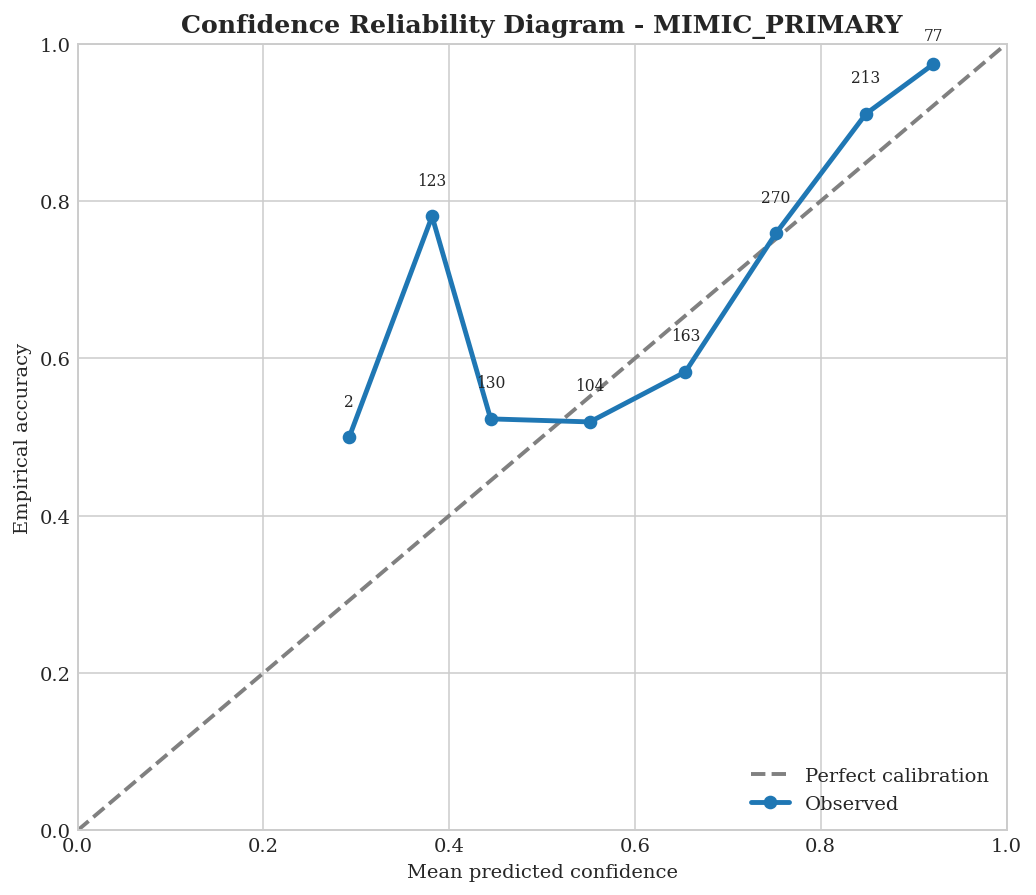

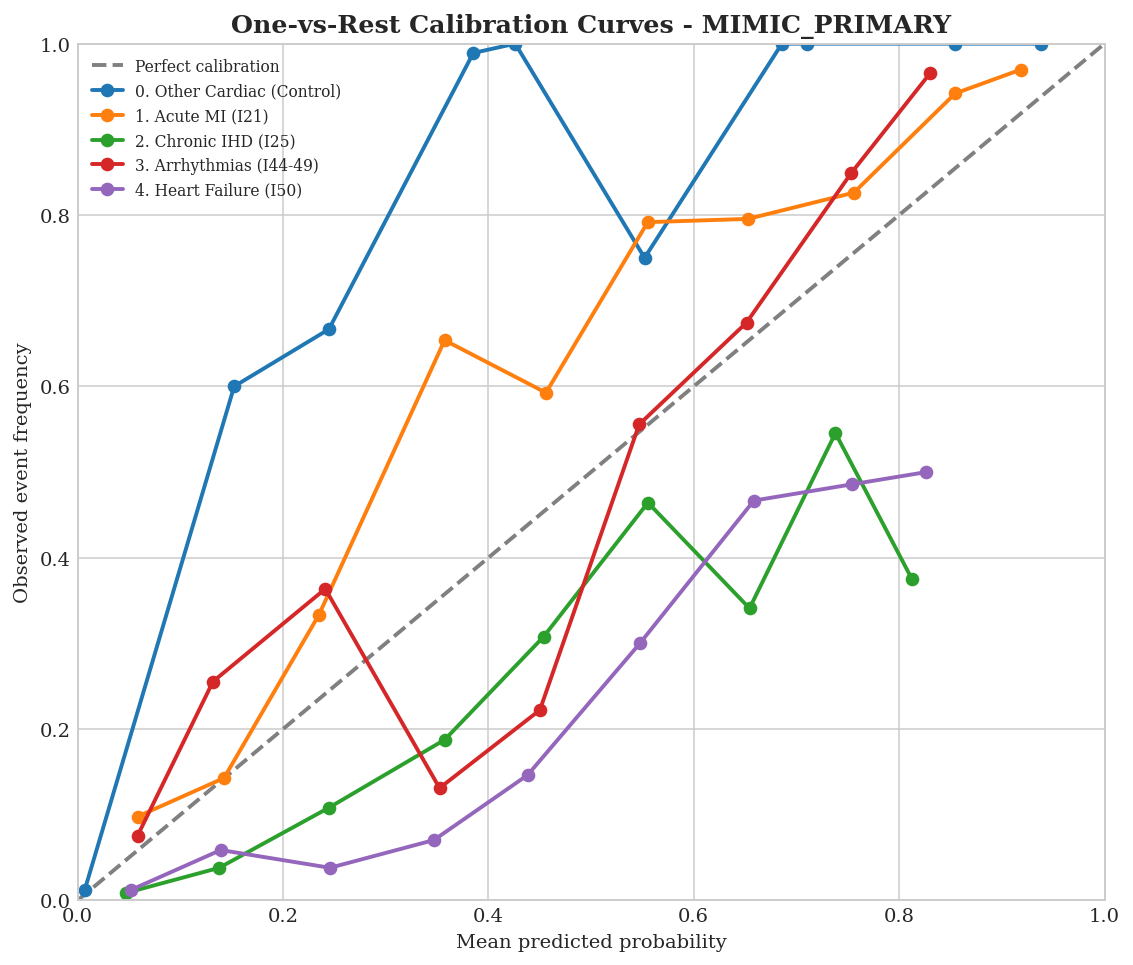

🖼️ Saved: /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_CALIBRATION_figures/pipeline6_CALIBRATION_confidence_MIMIC_PRIMARY.png
🖼️ Saved: /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_CALIBRATION_figures/pipeline6_CALIBRATION_ovr_MIMIC_PRIMARY.png

----------------------------------------------------------------------------------------------------
📌 Target: Strict tabular-only model | MIMIC temporal external
✅ Loaded: /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_TABULAR_predictions_MIMIC_EXT.csv
   Shape: (1082, 10)
   Columns: ['id', 'Y_TRUE_ENCODED', 'Y_TRUE_ORIGINAL', 'Y_PRED_ENCODED', 'Y_PRED_ORIGINAL', 'PROBA_CLASS_0_0. Other Cardiac (Control)', 'PROBA_CLASS_1_1. Acute MI (I21)', 'PROBA_CLASS_2_2. Chronic IHD (I25)', 'PROBA_CLASS_3_3. Arrhythmias (I44-49)', 'PROBA_CLASS_4_4. Heart Failure (I50)']
🧭 Detected mapping:
   True label column      : Y_TRUE_ENCODED
   Predicted label column : Y_PRED_ENCODED
   Probability columns    : class

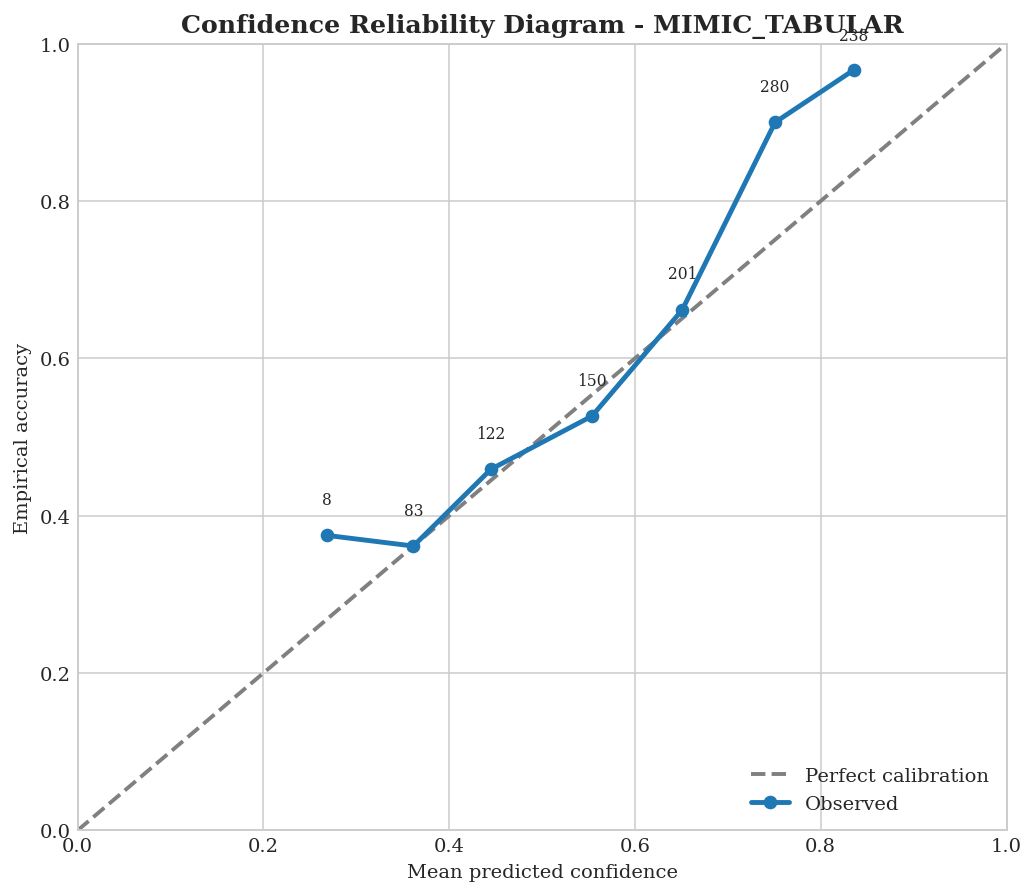

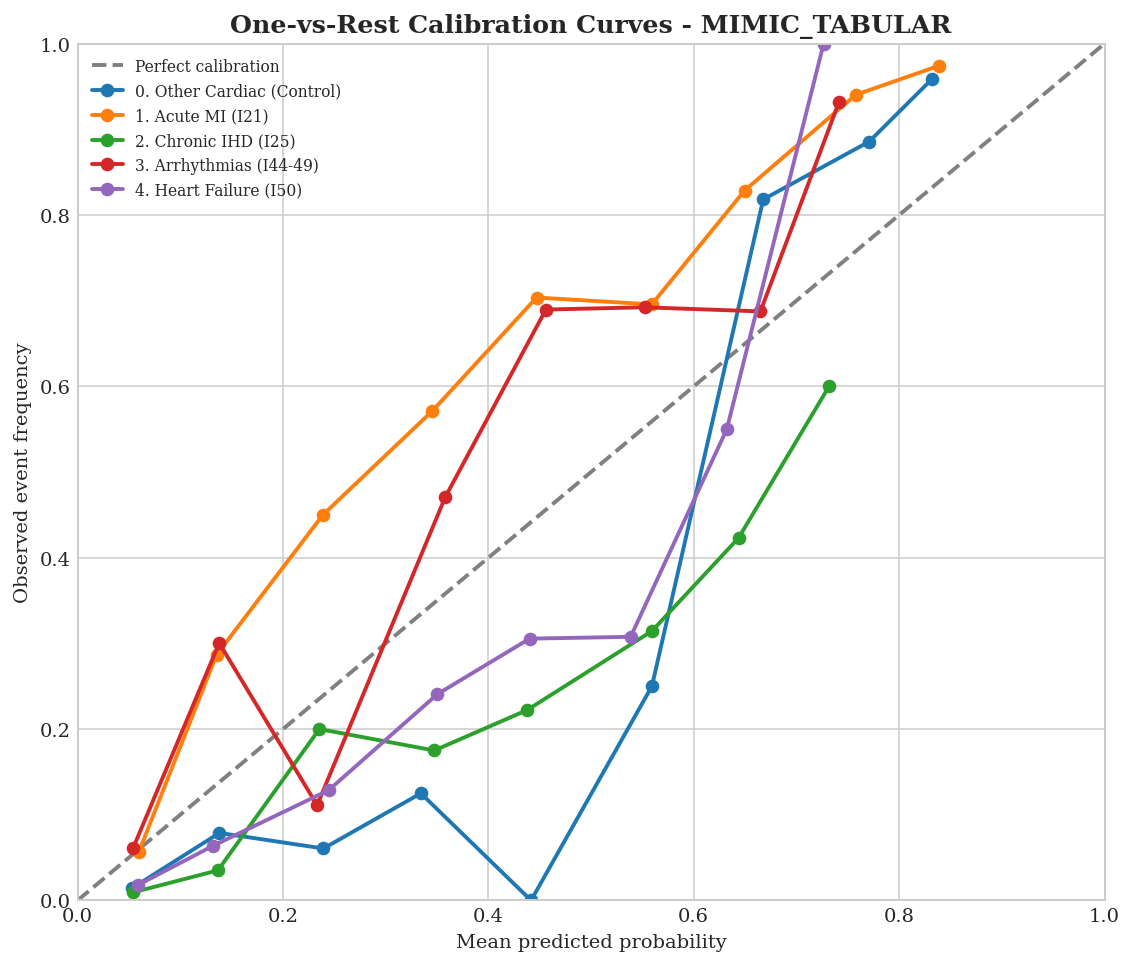

🖼️ Saved: /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_CALIBRATION_figures/pipeline6_CALIBRATION_confidence_MIMIC_TABULAR.png
🖼️ Saved: /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_CALIBRATION_figures/pipeline6_CALIBRATION_ovr_MIMIC_TABULAR.png

----------------------------------------------------------------------------------------------------
📌 Target: Direct rescued 10-feature eICU | eICU rescued measurable
✅ Loaded: /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_eICU_RESCUED_predictions_MEASURABLE.csv
   Shape: (89912, 10)
   Columns: ['patientunitstayid', 'Y_TRUE_ORIGINAL', 'Y_TRUE_ENCODED', 'Y_PRED_ENCODED', 'Y_PRED_ORIGINAL', 'PROBA_CLASS_0_0. Other Cardiac (Control)', 'PROBA_CLASS_1_1. Acute MI (I21)', 'PROBA_CLASS_2_2. Chronic IHD (I25)', 'PROBA_CLASS_3_3. Arrhythmias (I44-49)', 'PROBA_CLASS_4_4. Heart Failure (I50)']
🧭 Detected mapping:
   True label column      : Y_TRUE_ENCODED
   Predicted label column : Y_PRED_ENCODED
   Pro

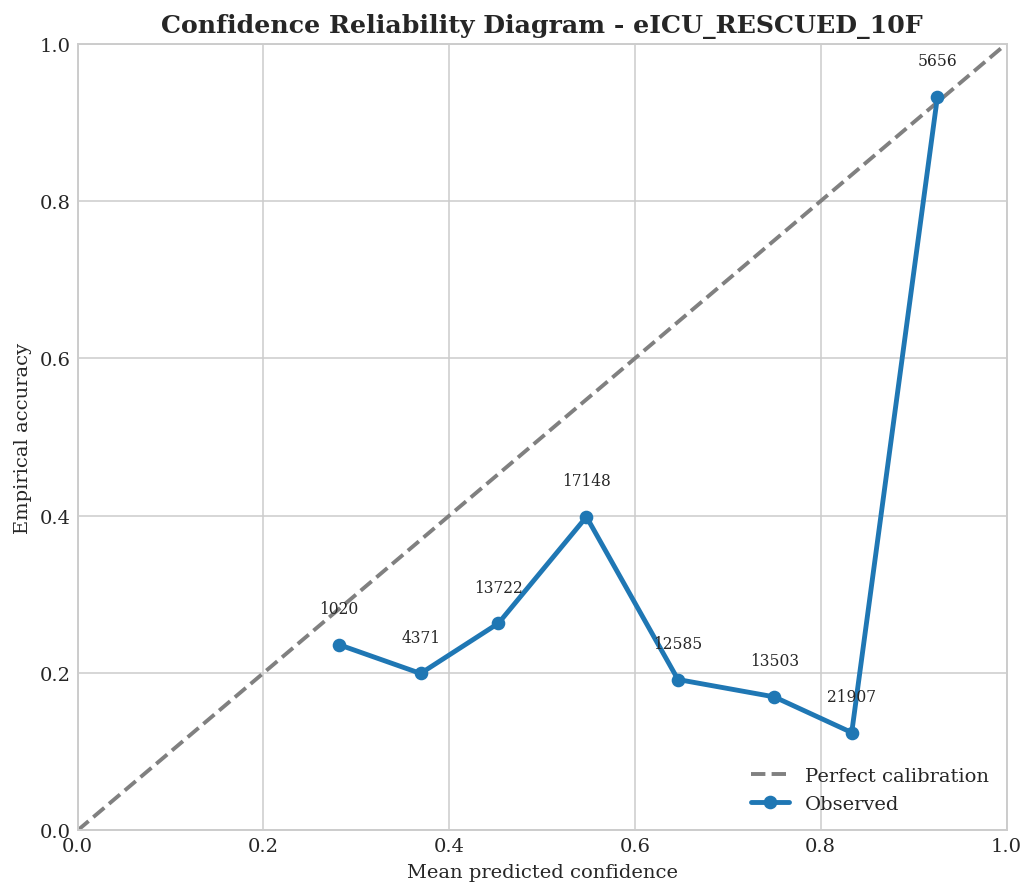

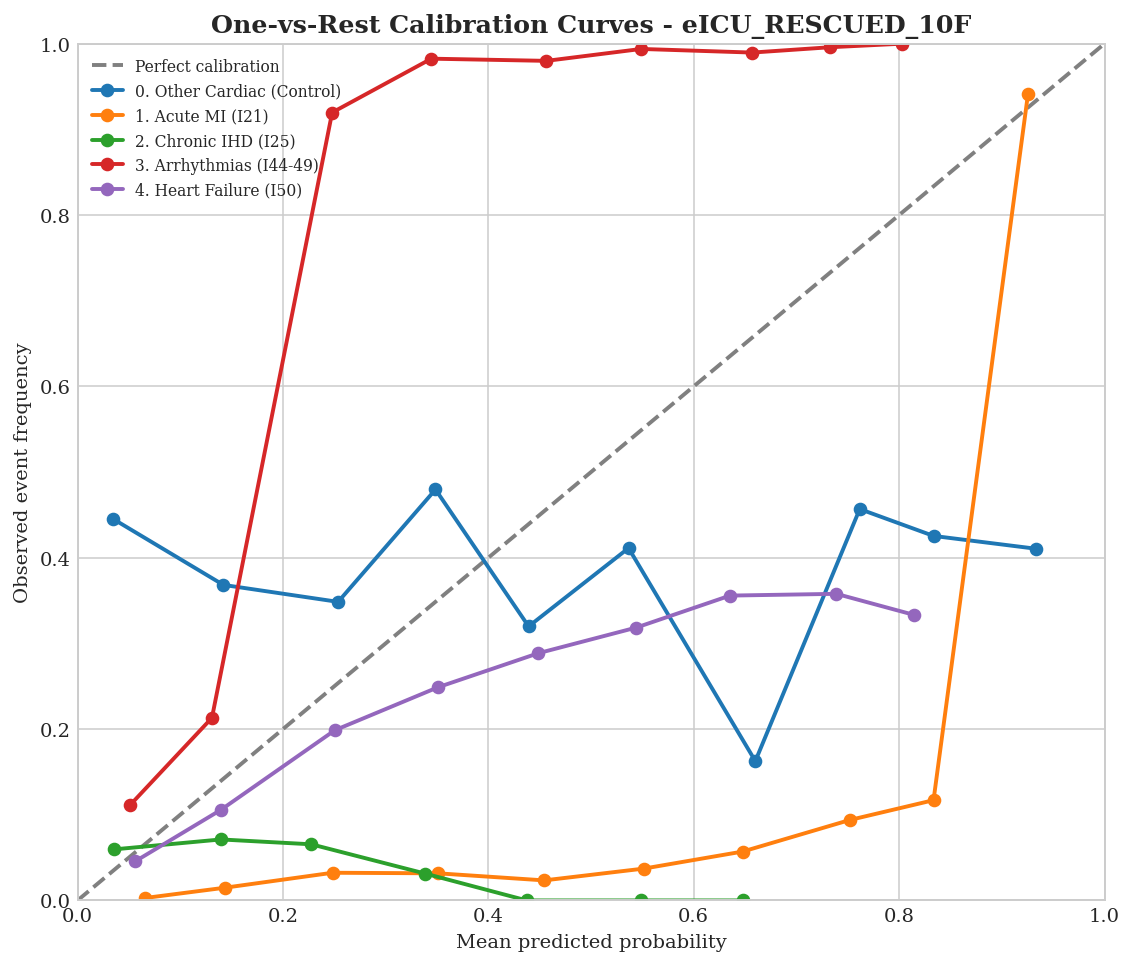

🖼️ Saved: /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_CALIBRATION_figures/pipeline6_CALIBRATION_confidence_eICU_RESCUED_10F.png
🖼️ Saved: /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_CALIBRATION_figures/pipeline6_CALIBRATION_ovr_eICU_RESCUED_10F.png

----------------------------------------------------------------------------------------------------
📌 Target: Portable 21-feature eICU | eICU rescued measurable
✅ Loaded: /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_PORTABLE_predictions_eICU_MEASURABLE.csv
   Shape: (93851, 10)
   Columns: ['id', 'Y_TRUE_ENCODED', 'Y_TRUE_ORIGINAL', 'Y_PRED_ENCODED', 'Y_PRED_ORIGINAL', 'PROBA_CLASS_0_0. Other Cardiac (Control)', 'PROBA_CLASS_1_1. Acute MI (I21)', 'PROBA_CLASS_2_2. Chronic IHD (I25)', 'PROBA_CLASS_3_3. Arrhythmias (I44-49)', 'PROBA_CLASS_4_4. Heart Failure (I50)']
🧭 Detected mapping:
   True label column      : Y_TRUE_ENCODED
   Predicted label column : Y_PRED_ENCODED
   Probability colum

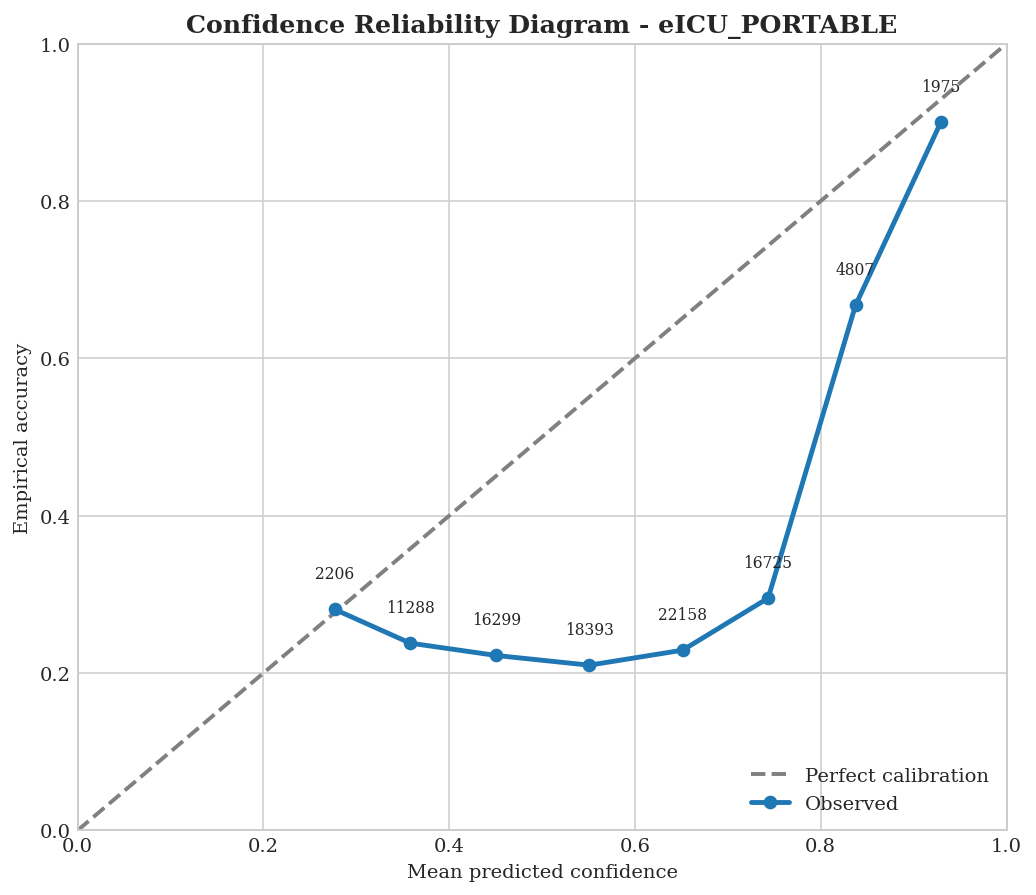

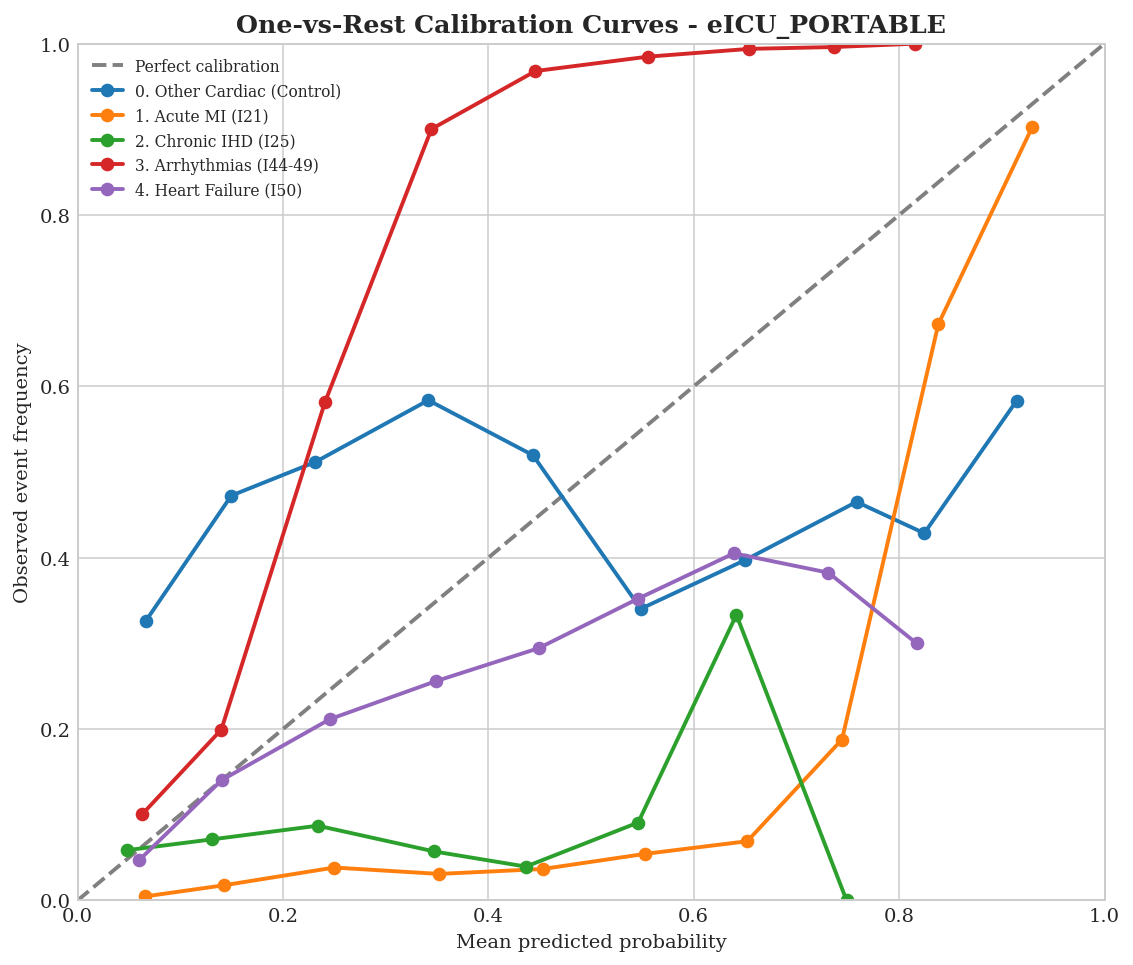

🖼️ Saved: /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_CALIBRATION_figures/pipeline6_CALIBRATION_confidence_eICU_PORTABLE.png
🖼️ Saved: /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_CALIBRATION_figures/pipeline6_CALIBRATION_ovr_eICU_PORTABLE.png

----------------------------------------------------------------------------------------------------
📌 Target: Strict tabular-only eICU | eICU rescued measurable
✅ Loaded: /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_TABULAR_predictions_eICU_MEASURABLE.csv
   Shape: (93136, 10)
   Columns: ['id', 'Y_TRUE_ENCODED', 'Y_TRUE_ORIGINAL', 'Y_PRED_ENCODED', 'Y_PRED_ORIGINAL', 'PROBA_CLASS_0_0. Other Cardiac (Control)', 'PROBA_CLASS_1_1. Acute MI (I21)', 'PROBA_CLASS_2_2. Chronic IHD (I25)', 'PROBA_CLASS_3_3. Arrhythmias (I44-49)', 'PROBA_CLASS_4_4. Heart Failure (I50)']
🧭 Detected mapping:
   True label column      : Y_TRUE_ENCODED
   Predicted label column : Y_PRED_ENCODED
   Probability columns    :

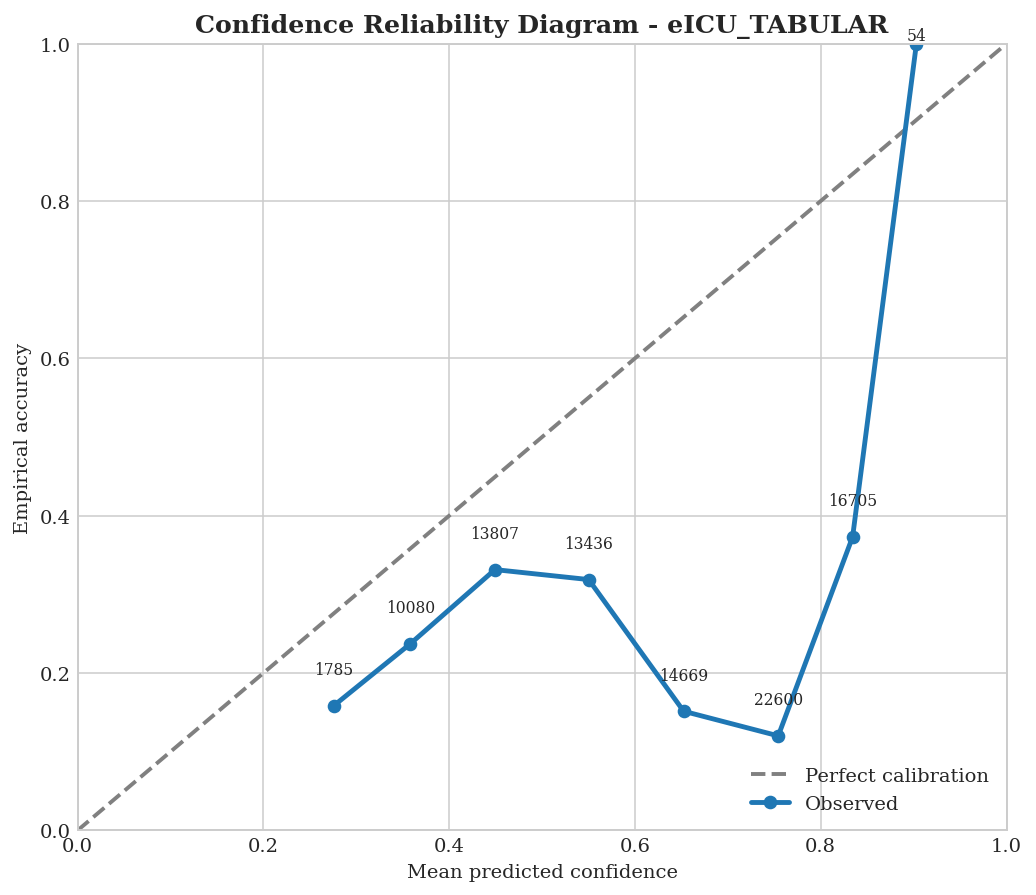

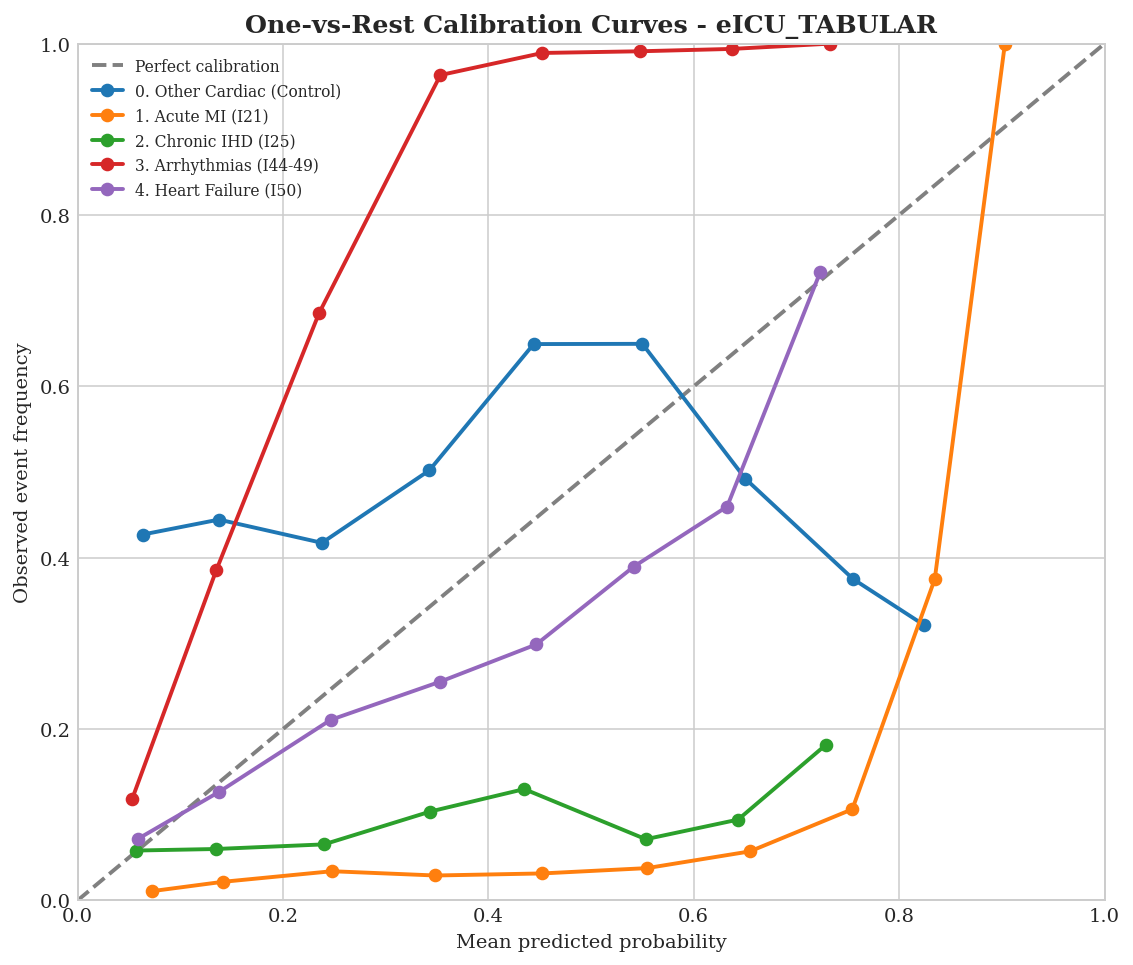

🖼️ Saved: /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_CALIBRATION_figures/pipeline6_CALIBRATION_confidence_eICU_TABULAR.png
🖼️ Saved: /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_CALIBRATION_figures/pipeline6_CALIBRATION_ovr_eICU_TABULAR.png

💾 [STEP 2] SAVING CALIBRATION OUTPUTS
✅ Saved summary metrics: /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_CALIBRATION_summary_metrics.csv
✅ Saved per-class metrics: /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_CALIBRATION_per_class_metrics.csv
✅ Saved bin-level metrics: /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_CALIBRATION_bin_level_metrics.csv
✅ Saved Excel workbook: /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_CALIBRATION_summary.xlsx
✅ Saved interpretation notes: /content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN/pipeline6_CALIBRATION_interpretation_notes.txt

📊 PUBLICATION-READY CALIBRATION SUMMARY

📌 SUMMARY METRICS
                   

In [ ]:
# @title BLOCK 15: CALIBRATION ANALYSIS - FIXED PROBA_CLASS FORMAT
# =============================================================================
# FIX:
# - Detects probability columns like:
#   PROBA_CLASS_0_0. Other Cardiac (Control)
#   PROBA_CLASS_1_1. Acute MI (I21)
# - Prefers Y_TRUE_ENCODED over Y_TRUE_ORIGINAL.
# - No retraining, no calibrator fitting, no model modification.
# =============================================================================

import os
import re
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import log_loss
from sklearn.preprocessing import label_binarize
from sklearn.calibration import calibration_curve

warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 140
plt.rcParams["font.family"] = "serif"

SAVE_DIR = "/content/drive/MyDrive/MIMIC DATASET/READY_TO_TRAIN"
FIG_DIR = os.path.join(SAVE_DIR, "pipeline6_CALIBRATION_figures")
os.makedirs(FIG_DIR, exist_ok=True)

PATH_SUMMARY_CSV = os.path.join(SAVE_DIR, "pipeline6_CALIBRATION_summary_metrics.csv")
PATH_PER_CLASS_CSV = os.path.join(SAVE_DIR, "pipeline6_CALIBRATION_per_class_metrics.csv")
PATH_BINS_CSV = os.path.join(SAVE_DIR, "pipeline6_CALIBRATION_bin_level_metrics.csv")
PATH_NOTES_TXT = os.path.join(SAVE_DIR, "pipeline6_CALIBRATION_interpretation_notes.txt")
PATH_XLSX = os.path.join(SAVE_DIR, "pipeline6_CALIBRATION_summary.xlsx")

print("\n" + "="*100)
print("📏 BLOCK 15: CALIBRATION ANALYSIS - FIXED PROBA_CLASS FORMAT")
print("="*100)
print("🛡️ Reads prediction CSV only. No retraining. No calibrator fitting. No threshold tuning.")
print(f"📂 Figure output directory: {FIG_DIR}")

PREDICTION_TARGETS = [
    {
        "scenario": "Primary 10-feature model",
        "model": "Locked primary XGBoost Optuna-AUPRC",
        "dataset": "MIMIC temporal external",
        "short_name": "MIMIC_PRIMARY",
        "candidate_paths": [
            os.path.join(SAVE_DIR, "pipeline6_predictions_MIMIC_EXT.csv"),
            os.path.join(SAVE_DIR, "pipeline6_predictions_EXTERNAL.csv"),
            os.path.join(SAVE_DIR, "pipeline6_PRIMARY_predictions_MIMIC_EXT.csv"),
            os.path.join(SAVE_DIR, "pipeline6_best_xgb_predictions_MIMIC_EXT.csv"),
            os.path.join(SAVE_DIR, "pipeline6_XGB_predictions_MIMIC_EXT.csv"),
        ],
    },
    {
        "scenario": "Strict tabular-only model",
        "model": "Tabular XGBoost Optuna",
        "dataset": "MIMIC temporal external",
        "short_name": "MIMIC_TABULAR",
        "candidate_paths": [
            os.path.join(SAVE_DIR, "pipeline6_TABULAR_predictions_MIMIC_EXT.csv"),
        ],
    },
    {
        "scenario": "Direct rescued 10-feature eICU",
        "model": "Locked primary model",
        "dataset": "eICU rescued measurable",
        "short_name": "eICU_RESCUED_10F",
        "candidate_paths": [
            os.path.join(SAVE_DIR, "pipeline6_eICU_RESCUED_predictions_MEASURABLE.csv"),
        ],
    },
    {
        "scenario": "Portable 21-feature eICU",
        "model": "Portable XGBoost Optuna",
        "dataset": "eICU rescued measurable",
        "short_name": "eICU_PORTABLE",
        "candidate_paths": [
            os.path.join(SAVE_DIR, "pipeline6_PORTABLE_predictions_eICU_MEASURABLE.csv"),
        ],
    },
    {
        "scenario": "Strict tabular-only eICU",
        "model": "Tabular XGBoost Optuna",
        "dataset": "eICU rescued measurable",
        "short_name": "eICU_TABULAR",
        "candidate_paths": [
            os.path.join(SAVE_DIR, "pipeline6_TABULAR_predictions_eICU_MEASURABLE.csv"),
        ],
    },
]

LABEL_NAMES = {
    0: "0. Other Cardiac (Control)",
    1: "1. Acute MI (I21)",
    2: "2. Chronic IHD (I25)",
    3: "3. Arrhythmias (I44-49)",
    4: "4. Heart Failure (I50)",
}

def resolve_existing_path(candidate_paths):
    for p in candidate_paths:
        if os.path.exists(p):
            return p
    return None

def normalize_colname(c):
    return str(c).strip().lower().replace(" ", "_").replace("-", "_")

def detect_true_label_column(df):
    # Calibration must prefer encoded labels because probability columns are encoded classes 0-4.
    candidates_priority = [
        "y_true_encoded", "true_encoded", "encoded_true", "encoded_label",
        "y_true", "true_label", "true", "label", "y",
        "actual", "target", "y_test",
        "y_true_original", "original_label"
    ]
    normalized = {normalize_colname(c): c for c in df.columns}

    for key in candidates_priority:
        if key in normalized:
            return normalized[key]

    for c in df.columns:
        nc = normalize_colname(c)
        if ("true" in nc or "actual" in nc) and ("encoded" in nc):
            return c

    for c in df.columns:
        nc = normalize_colname(c)
        if ("true" in nc or "actual" in nc) and ("label" in nc or nc.startswith("y")):
            return c

    return None

def detect_pred_label_column(df):
    candidates_priority = [
        "y_pred_encoded", "pred_encoded", "encoded_pred",
        "y_pred", "pred_label", "predicted_label", "prediction",
        "pred", "y_hat", "predicted"
    ]
    normalized = {normalize_colname(c): c for c in df.columns}

    for key in candidates_priority:
        if key in normalized:
            return normalized[key]

    for c in df.columns:
        nc = normalize_colname(c)
        if ("pred" in nc or "prediction" in nc) and ("encoded" in nc):
            return c

    for c in df.columns:
        nc = normalize_colname(c)
        if ("pred" in nc or "prediction" in nc) and ("label" in nc or nc.startswith("y") or "class" in nc):
            return c

    return None

def detect_probability_columns(df):
    """
    Handles:
    - prob_0
    - proba_0
    - probability_0
    - class_0_prob
    - PROBA_CLASS_0_0. Other Cardiac (Control)
    """
    detected = []

    for c in df.columns:
        nc = normalize_colname(c)

        # Most important Pipeline 6 exported format:
        # PROBA_CLASS_0_0. Other Cardiac (Control)
        m = re.match(r"^proba_class_(\d+)_", nc)
        if m:
            detected.append((int(m.group(1)), c))
            continue

        m = re.match(r"^prob_class_(\d+)_", nc)
        if m:
            detected.append((int(m.group(1)), c))
            continue

        patterns = [
            r"^prob[_]?(\d+)$",
            r"^proba[_]?(\d+)$",
            r"^p[_]?(\d+)$",
            r"^probability[_]?(\d+)$",
            r"^y[_]?proba[_]?(\d+)$",
            r"^class[_]?(\d+)[_]?prob$",
            r"^class[_]?(\d+)[_]?proba$",
            r"^prob[_]?class[_]?(\d+)$",
            r"^proba[_]?class[_]?(\d+)$",
        ]

        for pat in patterns:
            m = re.match(pat, nc)
            if m:
                detected.append((int(m.group(1)), c))
                break

    # Fallback: contains proba/prob and a class number after class_
    if len(detected) == 0:
        for c in df.columns:
            nc = normalize_colname(c)
            m = re.search(r"(?:prob|proba).*class[_]?(\d+)", nc)
            if m:
                detected.append((int(m.group(1)), c))

    seen = set()
    unique = []
    for cls, c in detected:
        if c not in seen:
            seen.add(c)
            unique.append((cls, c))

    unique = sorted(unique, key=lambda x: x[0])

    if len(unique) == 0:
        return [], [], "No probability columns detected"

    class_ids = [x[0] for x in unique]
    prob_cols = [x[1] for x in unique]
    mapping_text = ", ".join([f"class {cls} -> {col}" for cls, col in unique])
    return prob_cols, class_ids, mapping_text

def normalize_probabilities(P):
    P = np.asarray(P, dtype=float)
    P = np.clip(P, 0.0, 1.0)
    row_sums = P.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = np.nan
    return P / row_sums

def multiclass_brier_score(y_true, P, class_ids):
    y_onehot = label_binarize(y_true, classes=class_ids)
    if len(class_ids) == 2 and y_onehot.shape[1] == 1:
        y_onehot = np.hstack([1 - y_onehot, y_onehot])
    return float(np.mean(np.sum((y_onehot - P) ** 2, axis=1)))

def per_class_brier_scores(y_true, P, class_ids):
    rows = []
    for j, cls in enumerate(class_ids):
        y_bin = (y_true == cls).astype(int)
        rows.append({
            "Encoded_Class": cls,
            "Class_Name": LABEL_NAMES.get(cls, f"Class {cls}"),
            "One_vs_Rest_Brier": float(np.mean((y_bin - P[:, j]) ** 2)),
            "Class_Prevalence": float(np.mean(y_bin)),
            "Mean_Predicted_Probability": float(np.mean(P[:, j])),
        })
    return rows

def confidence_ece_mce(y_true, y_pred, P, n_bins=10):
    conf = np.max(P, axis=1)
    correct = (y_pred == y_true).astype(int)

    bins = np.linspace(0, 1, n_bins + 1)
    rows = []
    ece = 0.0
    mce = 0.0

    for i in range(n_bins):
        left, right = bins[i], bins[i + 1]
        if i == n_bins - 1:
            mask = (conf >= left) & (conf <= right)
        else:
            mask = (conf >= left) & (conf < right)

        n = int(mask.sum())
        if n > 0:
            acc = float(correct[mask].mean())
            mean_conf = float(conf[mask].mean())
            gap = abs(acc - mean_conf)
            weight = n / len(y_true)
            ece += weight * gap
            mce = max(mce, gap)
        else:
            acc, mean_conf, gap, weight = np.nan, np.nan, np.nan, 0.0

        rows.append({
            "Bin": i + 1,
            "Bin_Left": left,
            "Bin_Right": right,
            "N": n,
            "Weight": weight,
            "Mean_Confidence": mean_conf,
            "Empirical_Accuracy": acc,
            "Abs_Gap": gap,
        })

    return float(ece), float(mce), pd.DataFrame(rows)

def safe_log_loss(y_true, P, class_ids, eps=1e-15):
    P_clip = np.clip(P, eps, 1 - eps)
    P_clip = P_clip / P_clip.sum(axis=1, keepdims=True)
    return float(log_loss(y_true, P_clip, labels=class_ids))

def plot_confidence_reliability(bin_df, title, output_path):
    plt.figure(figsize=(7.5, 6.5))
    valid = bin_df[bin_df["N"] > 0].copy()

    plt.plot([0, 1], [0, 1], "--", color="gray", linewidth=2, label="Perfect calibration")
    plt.plot(
        valid["Mean_Confidence"],
        valid["Empirical_Accuracy"],
        marker="o",
        linewidth=2.5,
        color="#1f77b4",
        label="Observed"
    )

    for _, row in valid.iterrows():
        plt.text(
            row["Mean_Confidence"],
            min(row["Empirical_Accuracy"] + 0.035, 1.0),
            str(int(row["N"])),
            ha="center",
            va="bottom",
            fontsize=8
        )

    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xlabel("Mean predicted confidence")
    plt.ylabel("Empirical accuracy")
    plt.title(title, fontsize=13, fontweight="bold")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

def plot_ovr_calibration_curves(y_true, P, class_ids, title, output_path, n_bins=10):
    plt.figure(figsize=(8.2, 7.0))
    plt.plot([0, 1], [0, 1], "--", color="gray", linewidth=2, label="Perfect calibration")

    colors = sns.color_palette("tab10", n_colors=len(class_ids))

    for j, cls in enumerate(class_ids):
        y_bin = (y_true == cls).astype(int)

        # calibration_curve can fail if a class is absent, so guard it.
        if y_bin.sum() == 0:
            continue

        prob_true, prob_pred = calibration_curve(
            y_bin,
            P[:, j],
            n_bins=n_bins,
            strategy="uniform"
        )

        plt.plot(
            prob_pred,
            prob_true,
            marker="o",
            linewidth=2,
            color=colors[j],
            label=LABEL_NAMES.get(cls, f"Class {cls}")
        )

    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Observed event frequency")
    plt.title(title, fontsize=13, fontweight="bold")
    plt.legend(loc="best", fontsize=8)
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

summary_rows = []
per_class_rows = []
bin_tables = []
skipped_rows = []

print("\n" + "="*100)
print("🔍 [STEP 1] SCANNING PREDICTION FILES AND DETECTING COLUMNS")
print("="*100)

for target in PREDICTION_TARGETS:
    scenario = target["scenario"]
    model = target["model"]
    dataset = target["dataset"]
    short_name = target["short_name"]

    print("\n" + "-"*100)
    print(f"📌 Target: {scenario} | {dataset}")

    path = resolve_existing_path(target["candidate_paths"])

    if path is None:
        reason = "Prediction CSV not found among candidate paths"
        print(f"⚠️ SKIPPED: {reason}")
        skipped_rows.append({
            "Scenario": scenario,
            "Model": model,
            "Dataset": dataset,
            "Short_Name": short_name,
            "Reason": reason,
        })
        continue

    df = pd.read_csv(path)
    print(f"✅ Loaded: {path}")
    print(f"   Shape: {df.shape}")
    print(f"   Columns: {list(df.columns)}")

    true_col = detect_true_label_column(df)
    pred_col = detect_pred_label_column(df)
    prob_cols, class_ids, prob_mapping = detect_probability_columns(df)

    print("🧭 Detected mapping:")
    print(f"   True label column      : {true_col}")
    print(f"   Predicted label column : {pred_col}")
    print(f"   Probability columns    : {prob_mapping}")

    if true_col is None:
        reason = "Could not detect true label column"
        print(f"⚠️ SKIPPED: {reason}")
        skipped_rows.append({
            "Scenario": scenario,
            "Model": model,
            "Dataset": dataset,
            "Short_Name": short_name,
            "Reason": reason,
        })
        continue

    if len(prob_cols) == 0:
        reason = "No probability columns detected"
        print(f"⚠️ SKIPPED: {reason}")
        skipped_rows.append({
            "Scenario": scenario,
            "Model": model,
            "Dataset": dataset,
            "Short_Name": short_name,
            "Reason": reason,
        })
        continue

    eval_df = df.copy()

    y_true = pd.to_numeric(eval_df[true_col], errors="coerce")
    valid = y_true.notna()

    if pred_col is not None:
        y_pred = pd.to_numeric(eval_df[pred_col], errors="coerce")
        valid = valid & y_pred.notna()
    else:
        y_pred = None

    for c in prob_cols:
        valid = valid & pd.to_numeric(eval_df[c], errors="coerce").notna()

    eval_df = eval_df.loc[valid].copy()
    y_true = pd.to_numeric(eval_df[true_col], errors="coerce").astype(int).values

    P = eval_df[prob_cols].apply(pd.to_numeric, errors="coerce").values.astype(float)
    P = normalize_probabilities(P)

    valid_prob = ~np.isnan(P).any(axis=1)
    if valid_prob.sum() < len(P):
        print(f"⚠️ Dropping {len(P) - valid_prob.sum()} rows with invalid probability rows.")
        P = P[valid_prob]
        y_true = y_true[valid_prob]

    class_ids = list(class_ids)

    # If y_true uses original labels 0,1,2,5,6 but probability columns use 0-4,
    # this block cannot safely infer mapping unless encoded column exists.
    # Prefer encoded column already handles most files.
    keep = np.isin(y_true, class_ids)
    if keep.sum() < len(y_true):
        print(f"⚠️ Dropping {len(y_true) - keep.sum()} rows whose true labels are not in probability classes {class_ids}.")
        y_true = y_true[keep]
        P = P[keep]

    if len(y_true) == 0:
        reason = "No valid rows after filtering"
        print(f"⚠️ SKIPPED: {reason}")
        skipped_rows.append({
            "Scenario": scenario,
            "Model": model,
            "Dataset": dataset,
            "Short_Name": short_name,
            "Reason": reason,
        })
        continue

    if pred_col is not None:
        y_pred_all = pd.to_numeric(eval_df[pred_col], errors="coerce").astype(int).values
        y_pred_all = y_pred_all[valid_prob]
        y_pred = y_pred_all[keep]
    else:
        y_pred = np.array([class_ids[i] for i in np.argmax(P, axis=1)])
        pred_col = "argmax(probability)"

    confidence = np.max(P, axis=1)

    empirical_accuracy = float(np.mean(y_pred == y_true))
    mean_confidence = float(np.mean(confidence))
    confidence_gap = mean_confidence - empirical_accuracy

    brier_multi = multiclass_brier_score(y_true, P, class_ids)
    ece, mce, bin_df = confidence_ece_mce(y_true, y_pred, P, n_bins=10)

    try:
        nll = safe_log_loss(y_true, P, class_ids)
    except Exception as e:
        print(f"⚠️ Negative log loss skipped: {e}")
        nll = np.nan

    summary_rows.append({
        "Scenario": scenario,
        "Model": model,
        "Dataset": dataset,
        "Short_Name": short_name,
        "Prediction_File": path,
        "N": len(y_true),
        "True_Label_Column": true_col,
        "Pred_Label_Column": pred_col,
        "Probability_Column_Mapping": prob_mapping,
        "Class_IDs": json.dumps(class_ids),
        "Empirical_Accuracy": empirical_accuracy,
        "Mean_Predicted_Confidence": mean_confidence,
        "Confidence_Accuracy_Gap": confidence_gap,
        "Multiclass_Brier": brier_multi,
        "ECE_10bins": ece,
        "MCE_10bins": mce,
        "Negative_Log_Loss": nll,
    })

    class_rows = per_class_brier_scores(y_true, P, class_ids)
    for r in class_rows:
        r.update({
            "Scenario": scenario,
            "Model": model,
            "Dataset": dataset,
            "Short_Name": short_name,
            "N": len(y_true),
        })
        per_class_rows.append(r)

    bin_df.insert(0, "Scenario", scenario)
    bin_df.insert(1, "Model", model)
    bin_df.insert(2, "Dataset", dataset)
    bin_df.insert(3, "Short_Name", short_name)
    bin_tables.append(bin_df)

    print("📊 Calibration metrics:")
    print(f"   N                         : {len(y_true):,}")
    print(f"   Empirical accuracy        : {empirical_accuracy:.4f}")
    print(f"   Mean predicted confidence : {mean_confidence:.4f}")
    print(f"   Confidence - accuracy gap : {confidence_gap:.4f}")
    print(f"   Multiclass Brier score    : {brier_multi:.4f}")
    print(f"   ECE 10 bins               : {ece:.4f}")
    print(f"   MCE 10 bins               : {mce:.4f}")
    print(f"   Negative log loss         : {nll:.4f}" if not np.isnan(nll) else "   Negative log loss         : skipped")

    conf_fig = os.path.join(FIG_DIR, f"pipeline6_CALIBRATION_confidence_{short_name}.png")
    ovr_fig = os.path.join(FIG_DIR, f"pipeline6_CALIBRATION_ovr_{short_name}.png")

    plot_confidence_reliability(
        bin_df,
        f"Confidence Reliability Diagram - {short_name}",
        conf_fig
    )

    plot_ovr_calibration_curves(
        y_true,
        P,
        class_ids,
        f"One-vs-Rest Calibration Curves - {short_name}",
        ovr_fig,
        n_bins=10
    )

    print(f"🖼️ Saved: {conf_fig}")
    print(f"🖼️ Saved: {ovr_fig}")

print("\n" + "="*100)
print("💾 [STEP 2] SAVING CALIBRATION OUTPUTS")
print("="*100)

summary_df = pd.DataFrame(summary_rows)
per_class_df = pd.DataFrame(per_class_rows)
bin_all_df = pd.concat(bin_tables, axis=0, ignore_index=True) if len(bin_tables) > 0 else pd.DataFrame()
skipped_df = pd.DataFrame(skipped_rows)

if not summary_df.empty:
    summary_df = summary_df.sort_values(["Dataset", "Scenario"]).reset_index(drop=True)
    summary_df.to_csv(PATH_SUMMARY_CSV, index=False)
    print(f"✅ Saved summary metrics: {PATH_SUMMARY_CSV}")
else:
    print("⚠️ No summary metrics generated.")

if not per_class_df.empty:
    per_class_df = per_class_df.sort_values(["Dataset", "Scenario", "Encoded_Class"]).reset_index(drop=True)
    per_class_df.to_csv(PATH_PER_CLASS_CSV, index=False)
    print(f"✅ Saved per-class metrics: {PATH_PER_CLASS_CSV}")
else:
    print("⚠️ No per-class metrics generated.")

if not bin_all_df.empty:
    bin_all_df.to_csv(PATH_BINS_CSV, index=False)
    print(f"✅ Saved bin-level metrics: {PATH_BINS_CSV}")
else:
    print("⚠️ No bin-level metrics generated.")

try:
    with pd.ExcelWriter(PATH_XLSX, engine="openpyxl") as writer:
        if not summary_df.empty:
            summary_df.to_excel(writer, sheet_name="summary_metrics", index=False)
        if not per_class_df.empty:
            per_class_df.to_excel(writer, sheet_name="per_class_brier", index=False)
        if not bin_all_df.empty:
            bin_all_df.to_excel(writer, sheet_name="bin_level_metrics", index=False)
        if not skipped_df.empty:
            skipped_df.to_excel(writer, sheet_name="skipped_files", index=False)
    print(f"✅ Saved Excel workbook: {PATH_XLSX}")
except Exception as e:
    print(f"⚠️ Could not save Excel workbook: {e}")

notes = """
PIPELINE 6 CALIBRATION ANALYSIS - INTERPRETATION NOTES

1. Calibration evaluates whether predicted probabilities are numerically reliable.
   This differs from discrimination metrics such as AUC, F1, recall, or MCC.
   A model may rank patients well but still be over-confident or under-confident.

2. Multiclass Brier score measures the mean squared distance between one-hot labels
   and predicted class probabilities. Lower is better.

3. One-vs-rest Brier score measures class-specific probability error. Lower is better.

4. Expected Calibration Error (ECE) is the weighted average absolute gap between
   mean predicted confidence and empirical accuracy across 10 bins. Lower is better.

5. Maximum Calibration Error (MCE) is the largest bin-level calibration gap across
   10 bins. Lower is better.

6. Mean predicted confidence should be interpreted together with empirical accuracy.
   If mean confidence is substantially higher than accuracy, the model is likely
   over-confident. If it is lower, the model may be under-confident.

7. No calibration model was fitted in this analysis. No eICU data were used to fit
   Platt scaling, isotonic regression, temperature scaling, thresholds, or any
   other recalibration procedure.

8. eICU calibration may be affected by domain shift, missingness, coding heterogeneity,
   measurement practice differences, and prevalence shift. Therefore, eICU calibration
   should be interpreted as a transportability stress test.

9. If probability thresholds are needed for deployment, calibration should be evaluated
   and potentially adjusted on a separate validation/prospective cohort, not on the
   final external test set.

10. Reliability diagrams are descriptive only and do not modify any Block 9-14 models.
"""

with open(PATH_NOTES_TXT, "w") as f:
    f.write(notes.strip() + "\n")

print(f"✅ Saved interpretation notes: {PATH_NOTES_TXT}")

print("\n" + "="*100)
print("📊 PUBLICATION-READY CALIBRATION SUMMARY")
print("="*100)

if not summary_df.empty:
    display_cols = [
        "Scenario", "Dataset", "N",
        "Empirical_Accuracy", "Mean_Predicted_Confidence",
        "Confidence_Accuracy_Gap", "Multiclass_Brier",
        "ECE_10bins", "MCE_10bins", "Negative_Log_Loss"
    ]
    print("\n📌 SUMMARY METRICS")
    print(summary_df[display_cols].round(4).to_string(index=False))
else:
    print("⚠️ No summary metrics available.")

if not per_class_df.empty:
    display_cols = [
        "Scenario", "Dataset", "Encoded_Class", "Class_Name",
        "One_vs_Rest_Brier", "Class_Prevalence",
        "Mean_Predicted_Probability"
    ]
    print("\n📌 PER-CLASS BRIER SCORES")
    print(per_class_df[display_cols].round(4).to_string(index=False))
else:
    print("⚠️ No per-class metrics available.")

if not skipped_df.empty:
    print("\n⚠️ SKIPPED FILES / COHORTS")
    print(skipped_df.to_string(index=False))

print("\n" + "="*100)
print("🧾 PUBLICATION-READY INTERPRETATION NOTES")
print("="*100)
print(notes.strip())

print("\n" + "="*100)
print("✅ BLOCK 15 COMPLETE: CALIBRATION ANALYSIS FINISHED")
print("="*100)
print(f"📁 Figures saved in: {FIG_DIR}")
print(f"📄 Summary CSV: {PATH_SUMMARY_CSV}")
print(f"📄 Per-class CSV: {PATH_PER_CLASS_CSV}")
print(f"📄 Bin-level CSV: {PATH_BINS_CSV}")
print(f"📄 Notes TXT: {PATH_NOTES_TXT}")
print(f"📘 Excel workbook: {PATH_XLSX}")